[device] cuda
[Data] N=100, T=60, D=5
[Cond] shape: (100, 7)
[Cond] needs_turn 分布:
  直接走 (<0.3) : 34/100
  中等  (0.3-0.7): 36/100
  调头  (>0.7)  : 30/100

[Norm] ctrl_mean=[-0.07357636  0.05364437]
[Norm] ctrl_std =[0.54194385 0.64408153]

[Augmentation] 开始...
  [Crop] 生成 500 条子轨迹样本
  [Interp] 生成 200 条插值样本
[Augmented] 原始=100 → 增强后=2100

[增强后 needs_turn 分布]
  直接走 (<0) : 1085/2100
  中等 (0~均值): 0/2100
  调头  (>均值): 1041/2100

[Split] Train: 1680, Val: 420
[Model] Parameters: 730,946
[Model] Data/Param ratio: 0.0023

SafeFM: 2ch ctrl, 7dim cond, 4策略增强
Epochs=3000, LR=3e-4, Patience=300

  Epoch    1 | train=1.3710 | val=1.1799 | gap=-0.1911 ★ best
  Epoch   50 | train=0.6942 | val=0.6523 | gap=-0.0419 ★ best
  Epoch  100 | train=0.6201 | val=0.6018 | gap=-0.0183 ★ best
  Epoch  150 | train=0.5883 | val=0.5788 | gap=-0.0094 ★ best
  Epoch  200 | train=0.5549 | val=0.5538 | gap=-0.0011 ★ best
  Epoch  250 | train=0.5363 | val=0.5290 | gap=-0.0073 ★ best
  Epoch  300 | train=0.5226 | val=0.5192 

C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\1309618272.py:508: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\1309618272.py:508: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\1309618272.py:508: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\1309618272.py:508: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\1309618272.py:508: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\1309618272.py:508: UserWarning: Glyph 24067 (\N{CJK 

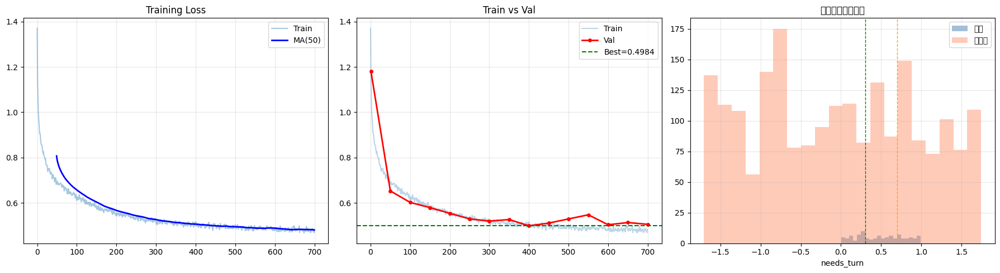

In [1]:
# ===============================================================
# 数据增强强化版：针对「调头 vs 直走」分布不均问题
# 在不改变原始数据集的情况下，通过增强平衡分布
#
# 新增两种增强策略：
#   1. Temporal Crop：从轨迹中段截取子轨迹，生成 needs_turn≈0 的样本
#   2. Heading Interpolation：在大/小偏差轨迹间插值，填补分布空白
#
# 保留原有：噪声增强 + 镜像增强
# ===============================================================

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path
import matplotlib.pyplot as plt
import sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

torch.set_grad_enabled(True)

fmtorch_root = Path.cwd().parent.resolve()
if str(fmtorch_root) not in sys.path:
    sys.path.insert(0, str(fmtorch_root))

# ---------------------------------------------------------------
# 1) 加载数据
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# ---------------------------------------------------------------
# 2) 构建控制量
# ---------------------------------------------------------------
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

ctrl_2ch = np.stack([
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1).astype(np.float32)  # (N, 2, T)

# ---------------------------------------------------------------
# 3) cond 构建函数（7维，含 needs_turn）
# ---------------------------------------------------------------
def build_cond_single(traj_i, state_i, goal_xy=None):
    """
    从单条轨迹计算 7维 cond
    traj_i:  (5, T) — [x, y, th, a, dr]
    state_i: (5,)   — [x, y, th, v, delta] 起始状态
    返回 cond (7,) 原始未归一化
    """
    x0, y0 = float(traj_i[0, 0]), float(traj_i[1, 0])
    th0    = float(traj_i[2, 0])

    if goal_xy is not None:
        gx, gy = float(goal_xy[0]), float(goal_xy[1])
    else:
        gx, gy = float(traj_i[0, -1]), float(traj_i[1, -1])

    dx_w = gx - x0
    dy_w = gy - y0
    angle_off = float(np.arctan2(dy_w, dx_w))

    cos_a  = np.cos(angle_off)
    sin_a  = np.sin(angle_off)
    dx_can = cos_a * dx_w + sin_a * dy_w

    th0_can      = float((th0 - angle_off + np.pi) % (2 * np.pi) - np.pi)
    th0_can_norm = float(th0_can / np.pi)
    needs_turn   = float(abs(th0_can) / np.pi)

    return np.array([
        dx_can,
        float(state_i[3]),         # v0
        float(np.cos(th0_can)),
        float(np.sin(th0_can)),
        float(state_i[4]),         # delta0
        th0_can_norm,
        needs_turn,
    ], dtype=np.float32)


# 批量计算原始 cond
cond_all = np.zeros((N, 7), dtype=np.float32)
for i in range(N):
    goal = goals[i] if goals is not None else None
    cond_all[i] = build_cond_single(traj_5ch[i], states[i, 0], goal)

print(f"[Cond] shape: {cond_all.shape}")
print(f"[Cond] needs_turn 分布:")
nt = cond_all[:, 6]
print(f"  直接走 (<0.3) : {(nt<0.3).sum()}/{N}")
print(f"  中等  (0.3-0.7): {((nt>=0.3)&(nt<0.7)).sum()}/{N}")
print(f"  调头  (>0.7)  : {(nt>=0.7).sum()}/{N}")

# ---------------------------------------------------------------
# 4) 归一化参数（在增强前计算，基于原始数据）
# ---------------------------------------------------------------
ctrl_mean = ctrl_2ch.mean(axis=(0, 2), keepdims=True)
ctrl_std  = ctrl_2ch.std(axis=(0, 2),  keepdims=True).clip(min=1e-6)
ctrl_2ch_norm = (ctrl_2ch - ctrl_mean) / ctrl_std

cond_mean_arr = np.array([
    cond_all[:, 0].mean(),
    cond_all[:, 1].mean(),
    0.0, 0.0,
    cond_all[:, 4].mean(),
    0.0,
    cond_all[:, 6].mean(),
], dtype=np.float32)

cond_scale = np.array([
    cond_all[:, 0].std() + 1e-6,
    cond_all[:, 1].std() + 1e-6,
    1.0, 1.0,
    cond_all[:, 4].std() + 1e-6,
    1.0,
    cond_all[:, 6].std() + 1e-6,
], dtype=np.float32)

def normalize_cond(cond_raw):
    """cond_raw: (..., 7)，归一化 index [0,1,4,6]"""
    out = cond_raw.copy()
    for i in [0, 1, 4, 6]:
        out[..., i] = (cond_raw[..., i] - cond_mean_arr[i]) / cond_scale[i]
    return out

cond_norm = normalize_cond(cond_all)

norm_params = {
    "ctrl_mean":  ctrl_mean,
    "ctrl_std":   ctrl_std,
    "cond_mean":  cond_mean_arr,
    "cond_scale": cond_scale,
}
np.save("cache/safefm_norm_params.npy", norm_params)
print(f"\n[Norm] ctrl_mean={ctrl_mean.squeeze()}")
print(f"[Norm] ctrl_std ={ctrl_std.squeeze()}")

# ---------------------------------------------------------------
# 5) 数据增强（四种策略）
# ---------------------------------------------------------------

def augment_noise(X1, cond, N2, T2):
    """策略1：噪声微扰（保持 cond-control 物理关系）"""
    out_X    = X1.copy()
    out_cond = cond.copy()
    out_X[:, 0, :] += np.random.randn(N2, T2) * 0.02
    out_X[:, 1, :] += np.random.randn(N2, T2) * 0.03
    out_cond[:, 0] += np.random.randn(N2) * 0.02   # dx_can
    out_cond[:, 1] += np.random.randn(N2) * 0.02   # v0
    return out_X, out_cond


def augment_mirror(X1, cond):
    """策略2：Y轴镜像（物理一致）"""
    out_X    = X1.copy()
    out_cond = cond.copy()
    out_X[:, 1, :] *= -1       # delta_rate 取反
    out_cond[:, 3] *= -1       # sin(th0_can) 取反
    out_cond[:, 4] *= -1       # delta0 取反
    out_cond[:, 5] *= -1       # th0_can_norm 取反
    # needs_turn (index 6) 不变
    return out_X, out_cond


def augment_temporal_crop(ctrl_2ch_norm, cond_all_raw, states_raw, traj_5ch,
                           goals, n_crops=3):
    """
    策略3：时间裁剪 ★ 核心新增
    把每条轨迹从 t=crop_start 处截断，重新计算 cond（此时起点朝向更接近 goal）
    生成大量 needs_turn≈0 的样本，平衡分布

    crop_start: 从轨迹的 25%~75% 处随机截取起点
    """
    N2, C, T2 = ctrl_2ch_norm.shape
    out_X    = []
    out_cond = []

    for _ in range(n_crops):
        for i in range(N2):
            # 随机选一个截取起点（避免太靠近末尾）
            t_start = np.random.randint(T2 // 4, T2 * 3 // 4)
            t_end   = T2

            seg_len = t_end - t_start
            if seg_len < 8:
                continue

            # 控制序列截取
            ctrl_seg = ctrl_2ch_norm[i, :, t_start:t_end]  # (2, seg_len)

            # 插值到原始长度 T2（保持模型输入尺寸一致）
            t_old = np.linspace(0, 1, seg_len)
            t_new = np.linspace(0, 1, T2)
            ctrl_resized = np.stack([
                np.interp(t_new, t_old, ctrl_seg[ch]) for ch in range(2)
            ], axis=0).astype(np.float32)

            # 重新计算 cond：从 t_start 处的状态出发
            new_state = states_raw[i, t_start]   # (5,) = [x,y,th,v,delta]
            new_traj  = traj_5ch[i, :, t_start:] # (5, T2-t_start)
            goal      = goals[i] if goals is not None else None

            new_cond_raw = build_cond_single(new_traj, new_state, goal)
            new_cond_norm = normalize_cond(new_cond_raw)

            out_X.append(ctrl_resized)
            out_cond.append(new_cond_norm)

    if len(out_X) == 0:
        return np.zeros((0, 2, T2), np.float32), np.zeros((0, 7), np.float32)

    return (np.stack(out_X,    axis=0).astype(np.float32),
            np.stack(out_cond, axis=0).astype(np.float32))


def augment_heading_interp(ctrl_2ch_norm, cond_norm, n_interp=2):
    """
    策略4：朝向插值 ★ 核心新增
    在 needs_turn 大的轨迹 和 needs_turn 小的轨迹之间插值
    生成中间偏差程度的样本，填补分布空白

    只对 cond 插值（控制序列也按同样权重混合）
    物理意义：介于"需要调头"和"直接走"之间的中间情况
    """
    N2 = ctrl_2ch_norm.shape[0]
    needs_turn_vals = cond_norm[:, 6]  # 归一化后的 needs_turn

    # 找出大偏差和小偏差的索引
    # 用原始 needs_turn 的分位数来分组
    thresh_high = np.percentile(needs_turn_vals, 70)
    thresh_low  = np.percentile(needs_turn_vals, 30)

    idx_high = np.where(needs_turn_vals > thresh_high)[0]
    idx_low  = np.where(needs_turn_vals < thresh_low)[0]

    if len(idx_high) == 0 or len(idx_low) == 0:
        return np.zeros((0, 2, ctrl_2ch_norm.shape[2]), np.float32), \
               np.zeros((0, 7), np.float32)

    out_X    = []
    out_cond = []

    for _ in range(n_interp):
        # 随机配对
        i_high = idx_high[np.random.randint(len(idx_high))]
        i_low  = idx_low [np.random.randint(len(idx_low))]

        # 插值权重
        alpha = np.random.uniform(0.2, 0.8)

        # 控制序列插值
        ctrl_interp = (alpha * ctrl_2ch_norm[i_high] +
                       (1 - alpha) * ctrl_2ch_norm[i_low]).astype(np.float32)

        # cond 插值（注意：cos/sin 插值后可能不是单位向量，需要重新归一化朝向）
        cond_interp = (alpha * cond_norm[i_high] +
                       (1 - alpha) * cond_norm[i_low]).astype(np.float32)

        # 修正 cos/sin 使其仍在合理范围（归一化到单位向量）
        cos_val = float(cond_interp[2])
        sin_val = float(cond_interp[3])
        norm_cs = max(np.sqrt(cos_val**2 + sin_val**2), 1e-6)
        cond_interp[2] = cos_val / norm_cs
        cond_interp[3] = sin_val / norm_cs

        out_X.append(ctrl_interp)
        out_cond.append(cond_interp)

    return (np.stack(out_X,    axis=0).astype(np.float32),
            np.stack(out_cond, axis=0).astype(np.float32))


# ── 执行所有增强 ──────────────────────────────────────────────
print("\n[Augmentation] 开始...")
np.random.seed(42)

all_X    = [ctrl_2ch_norm]
all_cond = [cond_norm]

# 策略1：噪声 × 8
for _ in range(8):
    xn, cn = augment_noise(ctrl_2ch_norm, cond_norm, N, T)
    all_X.append(xn); all_cond.append(cn)

# 策略2：镜像 × 5
for _ in range(5):
    xm, cm = augment_mirror(ctrl_2ch_norm, cond_norm)
    all_X.append(xm); all_cond.append(cm)

# 策略3：时间裁剪 × 5（每条轨迹裁 5 次 → 约 5×N 新样本）
xc, cc = augment_temporal_crop(ctrl_2ch_norm, cond_all, states, traj_5ch, goals, n_crops=5)
all_X.append(xc); all_cond.append(cc)
print(f"  [Crop] 生成 {len(xc)} 条子轨迹样本")

# 策略4：朝向插值 × 200 对
xi, ci = augment_heading_interp(ctrl_2ch_norm, cond_norm, n_interp=200)
all_X.append(xi); all_cond.append(ci)
print(f"  [Interp] 生成 {len(xi)} 条插值样本")

X1_aug    = np.concatenate(all_X,    axis=0).astype(np.float32)
cond_aug  = np.concatenate(all_cond, axis=0).astype(np.float32)
print(f"[Augmented] 原始={N} → 增强后={len(X1_aug)}")

# 增强后 needs_turn 分布
nt_aug = cond_aug[:, 6]
print(f"\n[增强后 needs_turn 分布]")
print(f"  直接走 (<0) : {(nt_aug<0).sum()}/{len(X1_aug)}")
print(f"  中等 (0~均值): {((nt_aug>=0)&(nt_aug<nt_aug.mean())).sum()}/{len(X1_aug)}")
print(f"  调头  (>均值): {(nt_aug>=nt_aug.mean()).sum()}/{len(X1_aug)}")

# ---------------------------------------------------------------
# 6) Train/Val Split
# ---------------------------------------------------------------
X1_t   = torch.tensor(X1_aug,  dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_aug, dtype=torch.float32, device=device)

full_ds    = TensorDataset(X1_t, cond_t)
train_size = int(0.8 * len(full_ds))
val_size   = len(full_ds) - train_size
train_ds, val_ds = random_split(
    full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, drop_last=False)
print(f"\n[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 7) 模型
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_safefm_2ch.pt")

model_safefm = SimpleUNet1D(
    time_emb_dim = 64,
    hidden_dim   = 64,
    cond_dim     = 7,
    in_channels  = 2,
    out_channels = 2,
).to(device)

n_params = sum(p.numel() for p in model_safefm.parameters())
print(f"[Model] Parameters: {n_params:,}")
print(f"[Model] Data/Param ratio: {len(train_ds)/n_params:.4f}")

optimizer = torch.optim.AdamW(
    model_safefm.parameters(), lr=3e-4, weight_decay=5e-4
)

# ---------------------------------------------------------------
# 8) Validation
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total, n = 0.0, 0
    for x_1, cond_b in val_dl:
        B     = x_1.shape[0]
        x_0   = torch.randn_like(x_1)
        t     = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        x_t      = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred   = model(x_t, t, cond=cond_b)
        total   += F.mse_loss(v_pred, v_target).item()
        n       += 1
    model.train()
    return total / max(n, 1)

# ---------------------------------------------------------------
# 9) Training loop
# ---------------------------------------------------------------
EPOCHS      = 3000
VAL_EVERY   = 50
PATIENCE    = 300
INPUT_NOISE = 0.01

best_val_loss    = float('inf')
no_improve_count = 0
train_history    = []
val_history      = []
global_step      = 0

print(f"\n{'='*60}")
print(f"SafeFM: 2ch ctrl, 7dim cond, 4策略增强")
print(f"Epochs={EPOCHS}, LR=3e-4, Patience={PATIENCE}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    model_safefm.train()
    epoch_loss, n_batch = 0.0, 0

    for x_1, cond_b in train_dl:
        B         = x_1.shape[0]
        x_1_noisy = x_1 + torch.randn_like(x_1) * INPUT_NOISE
        x_0       = torch.randn_like(x_1)
        t         = torch.rand(B, device=device)
        t_exp     = t.view(B, 1, 1)

        x_t      = (1 - t_exp) * x_0 + t_exp * x_1_noisy
        v_target = x_1_noisy - x_0
        v_pred   = model_safefm(x_t, t, cond=cond_b)
        loss     = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_safefm.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch    += 1

    avg_train = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train)
    global_step += 1

    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_safefm, val_dl)
        val_history.append((epoch, val_loss))
        gap = val_loss - avg_train

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict':     model_safefm.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step':          global_step,
                'best_val_loss':        best_val_loss,
                'train_history':        train_history,
                'val_history':          val_history,
                'norm_params':          norm_params,
                'cond_dim':             7,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train:.4f} | "
                  f"val={val_loss:.4f} | gap={gap:.4f} ★ best")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train:.4f} | "
                  f"val={val_loss:.4f} | gap={gap:.4f}")

        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] no improvement for {PATIENCE} epochs")
            break

    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train:.4f}")

print(f"\nDone! Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 10) 加载最佳模型
# ---------------------------------------------------------------
ckpt = torch.load(str(ckpt_path), map_location=device, weights_only=False)
model_safefm.load_state_dict(ckpt['model_state_dict'])
model_safefm.eval()
norm_params = ckpt['norm_params']
print(f"[Load Best] best_val_loss={ckpt['best_val_loss']:.6f}")

# ---------------------------------------------------------------
# 11) 训练曲线 + 增强前后 needs_turn 分布对比
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_history, alpha=0.4, label='Train')
if len(train_history) > 50:
    w  = 50
    sm = np.convolve(np.array(train_history), np.ones(w)/w, mode='valid')
    axes[0].plot(range(w-1, len(train_history)), sm, 'b-', lw=2, label=f'MA({w})')
axes[0].set_title('Training Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

val_ep  = [v[0] for v in val_history]
val_los = [v[1] for v in val_history]
axes[1].plot(train_history, alpha=0.3, label='Train')
axes[1].plot(val_ep, val_los, 'ro-', lw=2, markersize=4, label='Val')
axes[1].axhline(best_val_loss, color='g', ls='--', label=f'Best={best_val_loss:.4f}')
axes[1].set_title('Train vs Val'); axes[1].legend(); axes[1].grid(alpha=0.3)

# needs_turn 分布对比
axes[2].hist(cond_all[:, 6],  bins=20, alpha=0.5, label='原始', color='steelblue')
axes[2].hist(cond_aug[:, 6],  bins=20, alpha=0.4, label='增强后', color='coral')
axes[2].axvline(0.3, color='green',  ls='--', lw=1)
axes[2].axvline(0.7, color='orange', ls='--', lw=1)
axes[2].set_xlabel('needs_turn'); axes[2].set_title('增强前后分布对比')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fix:
#   ✅ remove CPU<->GPU ping-pong inside ODE rhs
#   ✅ canonicalize/uncanonicalize in TORCH (on device)
#   ✅ pre-create tensors used by CBF (no torch.tensor(...) in rhs)
# ===============================================================

import sys
from pathlib import Path

sys.path.insert(0, "..")

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
# NOTE: this notebook runs in a separate kernel from demo.ipynb.
# If you trained in demo, save/load the checkpoint here.
MODEL_CKPT = "cache/model_vel.pt"  # change if you saved elsewhere

# Try a few common locations
ckpt_candidates = [
    Path(MODEL_CKPT),
    Path("..") / "cache" / "model_vel.pt",
    Path.cwd() / "cache" / "model_vel.pt",
    Path.cwd().parent / "cache" / "model_vel.pt",
]
ckpt_path = next((p for p in ckpt_candidates if p.exists()), None)

if "model_vel" not in globals():
    if "trainer" in globals():
        model_vel = trainer.model
    else:
        if ckpt_path is not None:
            from fmtorch.models.simple1d_unet import SimpleUNet1D
            ckpt = torch.load(str(ckpt_path), map_location=device)
            model_vel = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=5).to(device)
            model_vel.load_state_dict(ckpt["model_state_dict"])
            print("Loaded model checkpoint:", ckpt_path)
        else:
            raise RuntimeError(
                "model_vel not found. Train in this notebook or set MODEL_CKPT to a saved model."
            )
if "cbf_project_velocity_world" not in globals():
    import importlib.util
    cbf_path = Path.cwd().parent / "dmpc_fm_cbf" / "cbf.py"
    if cbf_path.exists():
        spec = importlib.util.spec_from_file_location("dmpc_fm_cbf.cbf", str(cbf_path))
        cbf_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(cbf_mod)
        cbf_project_velocity_world = cbf_mod.cbf_project_velocity_world
    else:
        raise RuntimeError(f"cbf.py not found at {cbf_path}")

model_vel = model_vel.to(device).eval()

Loaded model checkpoint: cache\model_vel.pt


In [3]:
import sys, importlib.util
from pathlib import Path

def find_file_upwards(filename: str, start: Path, max_up: int = 12):
    """
    Search 'filename' by walking upwards; at each level, also try a few common subpaths.
    Returns Path or None.
    """
    p = start.resolve()

    common_subs = [
        Path("."),  # current
        Path("dmpc_fm_cbf"),
        Path("dmpc_fm_cbf") / "dmpc_fm_cbf",
        Path("src"),
        Path("src") / "dmpc_fm_cbf",
    ]

    for _ in range(max_up):
        # quick checks on common layouts
        for sub in common_subs:
            cand = (p / sub / filename).resolve()
            if cand.exists():
                return cand

        # fallback: shallow recursive search (limited)
        try:
            hits = list(p.rglob(filename))
            if len(hits) > 0:
                # prefer the one inside ".../dmpc_fm_cbf/..." if multiple
                hits_sorted = sorted(hits, key=lambda x: ("dmpc_fm_cbf" not in str(x), len(str(x))))
                return hits_sorted[0].resolve()
        except Exception:
            pass

        p = p.parent

    return None

def load_module_from_abs_path(mod_name: str, abs_path: Path):
    abs_path = abs_path.resolve()
    assert abs_path.exists(), f"Missing file: {abs_path}"
    spec = importlib.util.spec_from_file_location(mod_name, str(abs_path))
    mod = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = mod
    spec.loader.exec_module(mod)  # type: ignore
    return mod

# ---- locate files robustly ----
here = Path.cwd()
sampler_path = find_file_upwards("sampler_5h.py", here)
cbf_path     = find_file_upwards("cbf_project_velocity_sgfm.py", here)

print("[cwd]", here.resolve())
print("[sampler_path]", sampler_path)
print("[cbf_path    ]", cbf_path)

assert sampler_path is not None, "Cannot find sampler_5h.py from current notebook location."
assert cbf_path is not None, "Cannot find cbf_project_velocity_sgfm.py from current notebook location."

sampler_mod = load_module_from_abs_path("sampler_5h_abs", sampler_path)
cbf_mod     = load_module_from_abs_path("cbf_sgfm_abs",  cbf_path)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

print("[USING sampler]", sampler_mod.__file__)
print("[USING cbf    ]", cbf_mod.__file__)


[cwd] D:\projects\lab2025\dmpc_fm_cbf\notebooks
[sampler_path] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[cbf_path    ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[USING cbf    ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py


In [4]:
# Force-reload sampler_5h with cond-support, then rebind global function
import inspect
import importlib
import dmpc_fm_cbf.sampler_5h as sampler_mod

sampler_mod = importlib.reload(sampler_mod)
piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler file]", sampler_mod.__file__)
print("[sampler sig ]", sig)

required = ["cond", "start_xy_norm", "goal_xy_norm", "goal_guidance_weight", "lock_start"]
missing = [k for k in required if k not in sig.parameters]
assert len(missing) == 0, f"Loaded sampler still missing params: {missing}"

print("✅ sampler function rebound with cond/start-goal guidance support")


[sampler file] d:\projects\lab2025\dmpc_fm_cbf\notebooks\..\dmpc_fm_cbf\sampler_5h.py
[sampler sig ] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0: 'float' = 0.5, tau1: 'float' = 0.9, prox_k: 'float' = 3.0, cbf_kwargs: 'dict | None' = None)
✅ sampler function rebound with cond/start-goal guidance support


In [5]:
# ===============================================================
# 1) Load model_5ch automatically (5-channel FM model)
# ===============================================================

if "model_5ch" not in globals():

    # ★ 优先加载 small 模型，找不到再 fallback 到其他版本
    preferred = list(Path.cwd().rglob("model_vel_5ch_small.pt"))
    fallback  = [p for p in Path.cwd().rglob("model_vel_5ch*.pt")
                 if "small" not in p.name]

    if preferred:
        ckpt_path  = preferred[0]
        hidden_dim = 64
        time_emb   = 64
    elif fallback:
        ckpt_path  = fallback[0]
        hidden_dim = 128
        time_emb   = 128
    else:
        raise RuntimeError("Cannot find 5ch checkpoint (model_vel_5ch*.pt)")

    print("[Found checkpoint]", ckpt_path)
    print(f"[Model config]  hidden_dim={hidden_dim}, time_emb_dim={time_emb}")

    # ensure repo root in sys.path
    repo_root = sampler_path.parents[2]
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    from fmtorch.models.simple1d_unet import SimpleUNet1D

    model_5ch = SimpleUNet1D(
        time_emb_dim=time_emb,
        hidden_dim=hidden_dim,
        cond_dim=5,
        in_channels=5,
        out_channels=5,
    ).to(device)

    ckpt = torch.load(str(ckpt_path), map_location=device)

    if "model_state_dict" in ckpt:
        model_5ch.load_state_dict(ckpt["model_state_dict"])
        if "best_val_loss" in ckpt:
            print(f"[Best val loss] {ckpt['best_val_loss']:.6f}")
    else:
        model_5ch.load_state_dict(ckpt)

    model_5ch.eval()
    print(f"[Params] {sum(p.numel() for p in model_5ch.parameters()):,}")
    print("✅ model_5ch loaded successfully.")

[Base cond] dist=3.000  v0=0.270  cos_th=0.528  sin_th=-0.849  delta0=0.000
[Sweep] dist ...
[Sweep] v0 ...
[Sweep] theta0 ...
[Sweep] delta0 ...

=================================================================  sweep=dist
    t    ‖v‖ mean       std        XY         θ      ctrl    target
-----------------------------------------------------------------
  0.00      1.2835    0.0867    1.4324    1.1701    1.1683    1.2354
  0.05      1.2898    0.0907    1.4395    1.1753    1.1739    1.2354
  0.11      1.2962    0.0952    1.4468    1.1800    1.1800    1.2354
  0.16      1.3029    0.1001    1.4543    1.1841    1.1868    1.2354
  0.21      1.3099    0.1056    1.4621    1.1876    1.1945    1.2354
  0.26      1.3173    0.1116    1.4701    1.1906    1.2033    1.2354
  0.32      1.3252    0.1183    1.4784    1.1930    1.2135    1.2354
  0.37      1.3339    0.1257    1.4868    1.1951    1.2256    1.2354
  0.42      1.3433    0.1335    1.4953    1.1967    1.2400    1.2354
  0.47      1.3535  

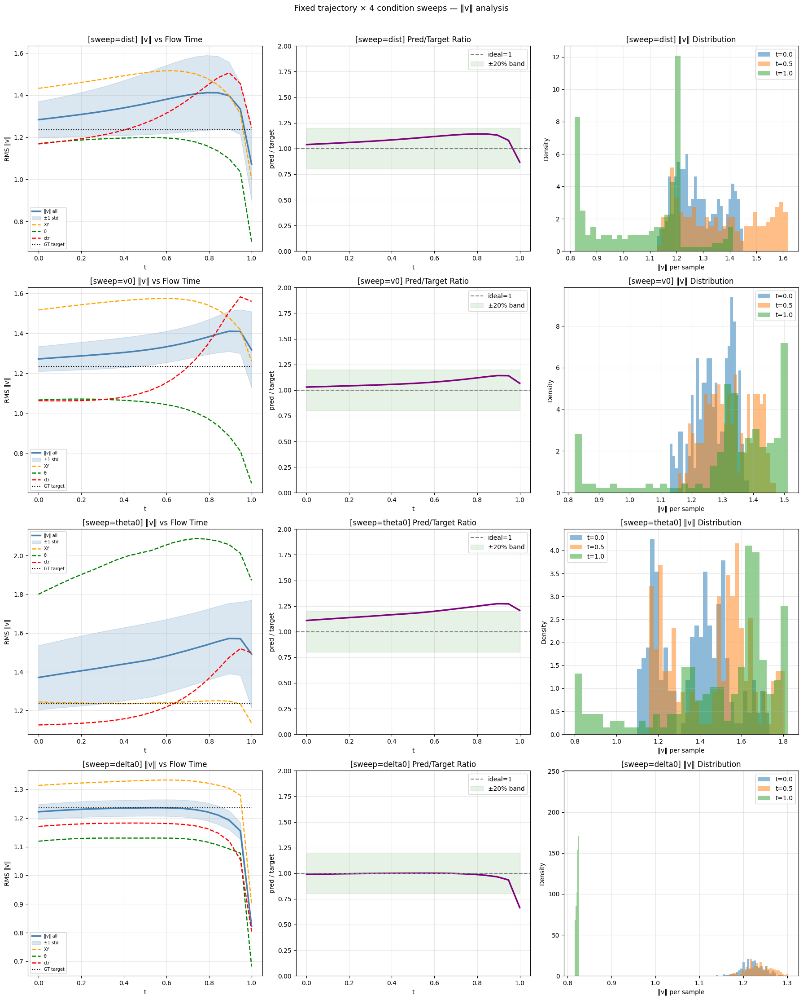

In [38]:
# ===============================================================
# 速度场 v 的模长分析 - 固定轨迹，扫描不同 condition
# 输出格式与原始 cell 一致：折线图 + ratio + 分布直方图
# ===============================================================

model_5ch.eval()
torch.set_grad_enabled(False)

from torch.utils.data import DataLoader, TensorDataset, random_split

# ---------------------------------------------------------------
# 0) 确保 val_dl 存在
# ---------------------------------------------------------------
if 'val_dl' not in dir():
    print("[Rebuild] rebuilding val_dl ...")
    full_ds    = TensorDataset(X1_t, cond_t)
    train_size = int(0.8 * len(full_ds))
    val_size   = len(full_ds) - train_size
    _, val_ds  = random_split(full_ds, [train_size, val_size],
                               generator=torch.Generator().manual_seed(42))
    val_dl     = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

# ---------------------------------------------------------------
# 1) 取第一条轨迹，复制 200 份
# ---------------------------------------------------------------
N_SAMPLES  = 200
N_T_POINTS = 20
t_grid     = np.linspace(0.0, 1.0, N_T_POINTS)

x1_single, cond_single = next(iter(val_dl))
x1_one   = x1_single[0:1]
cond_ref = cond_single[0].cpu().numpy()

print(f"[Base cond] dist={cond_ref[0]:.3f}  v0={cond_ref[1]:.3f}  "
      f"cos_th={cond_ref[2]:.3f}  sin_th={cond_ref[3]:.3f}  delta0={cond_ref[4]:.3f}")

x1_rep = x1_one.expand(N_SAMPLES, -1, -1).clone()
x_0    = torch.randn_like(x1_rep)

# target vnorm（与 cond 无关，只和轨迹有关）
v_target_np  = (x1_rep - x_0).cpu().numpy()
target_vnorm = np.array([
    float(np.sqrt(np.mean(v_target_np ** 2)))
    for _ in t_grid
])

# ---------------------------------------------------------------
# 2) 定义四组 condition 扫描
# ---------------------------------------------------------------
sweep_configs = {
    "dist":   {
        "vals": np.linspace(0.5, 4.0, N_SAMPLES),
        "label": "dist",
        "build_cond": lambda v: _set_cond(cond_ref, 0, v),
    },
    "v0":     {
        "vals": np.linspace(0.0, 1.2, N_SAMPLES),
        "label": "v0",
        "build_cond": lambda v: _set_cond(cond_ref, 1, v),
    },
    "theta0": {
        "vals": np.linspace(-np.pi, np.pi, N_SAMPLES),
        "label": "theta0",
        "build_cond": lambda v: _set_cond_theta(cond_ref, v),
    },
    "delta0": {
        "vals": np.linspace(-np.deg2rad(35), np.deg2rad(35), N_SAMPLES),
        "label": "delta0",
        "build_cond": lambda v: _set_cond(cond_ref, 4, v),
    },
}

def _set_cond(ref, idx, vals):
    c = np.tile(ref, (N_SAMPLES, 1)).astype(np.float32)
    c[:, idx] = np.asarray(vals, np.float32)
    return c

def _set_cond_theta(ref, angles):
    c = np.tile(ref, (N_SAMPLES, 1)).astype(np.float32)
    c[:, 2] = np.cos(angles).astype(np.float32)
    c[:, 3] = np.sin(angles).astype(np.float32)
    return c

# ---------------------------------------------------------------
# 3) 计算每个 sweep 的 vnorm
# ---------------------------------------------------------------
def compute_vnorms(cond_np):
    """给定 (N, 5) 的 cond，返回 (N, N_T_POINTS) 的 vnorm 矩阵"""
    cond_t_sw = torch.tensor(cond_np, dtype=torch.float32, device=x1_rep.device)
    vnorms    = np.zeros((N_SAMPLES, N_T_POINTS))
    all_vxy   = np.zeros_like(vnorms)
    all_vth   = np.zeros_like(vnorms)
    all_vctrl = np.zeros_like(vnorms)

    for j, t_val in enumerate(t_grid):
        t_tensor = torch.full((N_SAMPLES,), t_val, device=x1_rep.device)
        t_exp    = t_tensor.view(-1, 1, 1)
        x_t      = (1 - t_exp) * x_0 + t_exp * x1_rep
        v_pred   = model_5ch(x_t, t_tensor, cond=cond_t_sw)
        v_np     = v_pred.cpu().numpy()

        vnorms[:, j]   = np.sqrt(np.mean(v_np ** 2,            axis=(1, 2)))
        all_vxy[:, j]  = np.sqrt(np.mean(v_np[:, 0:2, :] ** 2, axis=(1, 2)))
        all_vth[:, j]  = np.sqrt(np.mean(v_np[:, 2:3, :] ** 2, axis=(1, 2)))
        all_vctrl[:, j]= np.sqrt(np.mean(v_np[:, 3:5, :] ** 2, axis=(1, 2)))

    return vnorms, all_vxy, all_vth, all_vctrl

results = {}
for name, cfg in sweep_configs.items():
    print(f"[Sweep] {name} ...")
    cond_np = cfg["build_cond"](cfg["vals"])
    vnorms, vxy, vth, vctrl = compute_vnorms(cond_np)
    results[name] = dict(vnorms=vnorms, vxy=vxy, vth=vth, vctrl=vctrl,
                         label=cfg["label"])

# ---------------------------------------------------------------
# 4) 打印数值表（与原 cell 格式一致）
# ---------------------------------------------------------------
for name, R in results.items():
    vnorm_mean = R["vnorms"].mean(axis=0)
    vnorm_std  = R["vnorms"].std(axis=0)
    print(f"\n{'='*65}  sweep={name}")
    print(f"{'t':>5}  {'‖v‖ mean':>10}  {'std':>8}  {'XY':>8}  {'θ':>8}  {'ctrl':>8}  {'target':>8}")
    print(f"{'-'*65}")
    for j, t_val in enumerate(t_grid):
        print(f"  {t_val:.2f}  {vnorm_mean[j]:>10.4f}  {vnorm_std[j]:>8.4f}"
              f"  {R['vxy'][:,j].mean():>8.4f}  {R['vth'][:,j].mean():>8.4f}"
              f"  {R['vctrl'][:,j].mean():>8.4f}  {target_vnorm[j]:>8.4f}")
    ratio = vnorm_mean.mean() / target_vnorm.mean()
    print(f"  Overall mean ‖v‖={vnorm_mean.mean():.4f}  "
          f"Target={target_vnorm.mean():.4f}  Ratio={ratio:.4f}")

# ---------------------------------------------------------------
# 5) 可视化：4 个 sweep × 3 列（与原 cell 完全一致的图形格式）
# ---------------------------------------------------------------
fig, axes = plt.subplots(4, 3, figsize=(18, 22))

for row_i, (name, R) in enumerate(results.items()):
    vnorms     = R["vnorms"]
    vnorm_mean = vnorms.mean(axis=0)
    vnorm_std  = vnorms.std(axis=0)
    ratio      = vnorm_mean / (target_vnorm + 1e-9)

    # ---- 图1：各通道模长随 t 变化（与原 cell 图1 一致）----
    ax = axes[row_i, 0]
    ax.plot(t_grid, vnorm_mean, lw=2.5, label="‖v‖ all", color="steelblue")
    ax.fill_between(t_grid, vnorm_mean - vnorm_std, vnorm_mean + vnorm_std,
                    alpha=0.2, color="steelblue", label="±1 std")
    ax.plot(t_grid, R["vxy"].mean(axis=0),   lw=1.8, ls="--", label="XY",   color="orange")
    ax.plot(t_grid, R["vth"].mean(axis=0),   lw=1.8, ls="--", label="θ",    color="green")
    ax.plot(t_grid, R["vctrl"].mean(axis=0), lw=1.8, ls="--", label="ctrl", color="red")
    ax.plot(t_grid, target_vnorm,            lw=1.5, ls=":",  label="GT target", color="black")
    ax.set_xlabel("t"); ax.set_ylabel("RMS ‖v‖")
    ax.set_title(f"[sweep={name}] ‖v‖ vs Flow Time")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # ---- 图2：pred/target ratio（与原 cell 图2 一致）----
    ax2 = axes[row_i, 1]
    ax2.plot(t_grid, ratio, lw=2.5, color="purple")
    ax2.axhline(1.0, ls="--", color="gray", label="ideal=1")
    ax2.fill_between(t_grid, 0.8, 1.2, alpha=0.1, color="green", label="±20% band")
    ax2.set_xlabel("t"); ax2.set_ylabel("pred / target")
    ax2.set_title(f"[sweep={name}] Pred/Target Ratio")
    ax2.set_ylim(0, 2.0); ax2.legend(); ax2.grid(alpha=0.3)

    # ---- 图3：t=0 / t=0.5 / t=1.0 分布直方图（与原 cell 图3 一致）----
    ax3 = axes[row_i, 2]
    for t_idx, lbl in [(0, "t=0.0"), (N_T_POINTS//2, "t=0.5"), (-1, "t=1.0")]:
        ax3.hist(vnorms[:, t_idx], bins=30, alpha=0.5, label=lbl, density=True)
    ax3.set_xlabel("‖v‖ per sample"); ax3.set_ylabel("Density")
    ax3.set_title(f"[sweep={name}] ‖v‖ Distribution")
    ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle("Fixed trajectory × 4 condition sweeps — ‖v‖ analysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

[cond] dist=3.000  v0=0.270  cos_th=0.528  sin_th=-0.849  delta0=0.000
[shapes] x1=(200, 5, 60)  x0=(200, 5, 60)  cond=(200, 5)
[Assert] 全部一致 ✓

    t    ‖v‖ mean       std        XY         θ      ctrl    target
-----------------------------------------------------------------
  0.00    1.225585  0.000000    1.2903    1.2529    1.1425    1.2269
  0.05    1.228286  0.000000    1.2910    1.2589    1.1457    1.2269
  0.11    1.230482  0.000000    1.2912    1.2639    1.1486    1.2269
  0.16    1.232096  0.000000    1.2910    1.2677    1.1510    1.2269
  0.21    1.233177  0.000000    1.2906    1.2702    1.1530    1.2269
  0.26    1.233806  0.000000    1.2901    1.2717    1.1545    1.2269
  0.32    1.234110  0.000000    1.2897    1.2721    1.1556    1.2269
  0.37    1.234264  0.000000    1.2896    1.2718    1.1562    1.2269
  0.42    1.234330  0.000000    1.2899    1.2712    1.1564    1.2269
  0.47    1.234304  0.000000    1.2905    1.2702    1.1561    1.2269
  0.53    1.234011  0.000000   

C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 24212 (\N{CJK UNIFIED IDEOGRAPH-5E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 35813 (\N{CJK UNIFIED IDEOGRAPH-8BE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 26497 (\N{CJK 

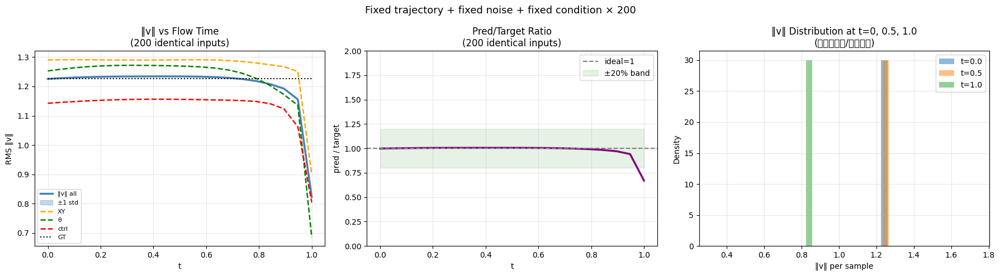

In [41]:
# ===============================================================
# 速度场 v 的模长分析 - 固定轨迹 + 固定noise + 固定condition
# 200条完全一样的输入，验证模型输出是否一致
# ===============================================================

model_5ch.eval()
torch.set_grad_enabled(False)

from torch.utils.data import DataLoader, TensorDataset, random_split

# ---------------------------------------------------------------
# 0) 确保 val_dl 存在
# ---------------------------------------------------------------
if 'val_dl' not in dir():
    print("[Rebuild] rebuilding val_dl ...")
    full_ds    = TensorDataset(X1_t, cond_t)
    train_size = int(0.8 * len(full_ds))
    val_size   = len(full_ds) - train_size
    _, val_ds  = random_split(full_ds, [train_size, val_size],
                               generator=torch.Generator().manual_seed(42))
    val_dl     = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

# ---------------------------------------------------------------
# 1) 取第一条，三样东西全部复制200份且完全一样
# ---------------------------------------------------------------
N_SAMPLES  = 200
N_T_POINTS = 20
t_grid     = np.linspace(0.0, 1.0, N_T_POINTS)

x1_single, cond_single = next(iter(val_dl))

# 轨迹：复制200份
x1_rep = x1_single[0:1].repeat(N_SAMPLES, 1, 1)   # (200, 5, T)

# noise：固定seed，复制200份
torch.manual_seed(42)
x_0 = torch.randn(1, x1_rep.shape[1], x1_rep.shape[2],
                   device=x1_rep.device).repeat(N_SAMPLES, 1, 1)  # (200, 5, T)

# condition：同一个，复制200份
cond_ref = cond_single[0:1].repeat(N_SAMPLES, 1)   # (200, 5)

print(f"[cond] dist={cond_ref[0,0]:.3f}  v0={cond_ref[0,1]:.3f}  "
      f"cos_th={cond_ref[0,2]:.3f}  sin_th={cond_ref[0,3]:.3f}  delta0={cond_ref[0,4]:.3f}")
print(f"[shapes] x1={tuple(x1_rep.shape)}  x0={tuple(x_0.shape)}  cond={tuple(cond_ref.shape)}")

# 验证三者完全一致
assert torch.all(x1_rep[0] == x1_rep[99]).item(),   "x1_rep 不一致！"
assert torch.all(x_0[0]    == x_0[99]   ).item(),   "x_0 不一致！"
assert torch.all(cond_ref[0] == cond_ref[99]).item(),"cond 不一致！"
print("[Assert] 全部一致 ✓")

# ---------------------------------------------------------------
# 2) 计算每个 t 上的 vnorm
# ---------------------------------------------------------------
all_vnorms = np.zeros((N_SAMPLES, N_T_POINTS))
all_vxy    = np.zeros_like(all_vnorms)
all_vth    = np.zeros_like(all_vnorms)
all_vctrl  = np.zeros_like(all_vnorms)

v_target_np  = (x1_rep - x_0).cpu().numpy()
target_vnorm = np.full(N_T_POINTS, float(np.sqrt(np.mean(v_target_np[0] ** 2))))

for j, t_val in enumerate(t_grid):
    t_tensor = torch.full((N_SAMPLES,), t_val, device=x1_rep.device)
    t_exp    = t_tensor.view(-1, 1, 1)
    x_t      = (1 - t_exp) * x_0 + t_exp * x1_rep

    v_pred          = model_5ch(x_t, t_tensor, cond=cond_ref)
    v_np            = v_pred.cpu().numpy()
    all_vnorms[:, j]= np.sqrt(np.mean(v_np ** 2,             axis=(1, 2)))
    all_vxy[:, j]   = np.sqrt(np.mean(v_np[:, 0:2, :] ** 2, axis=(1, 2)))
    all_vth[:, j]   = np.sqrt(np.mean(v_np[:, 2:3, :] ** 2, axis=(1, 2)))
    all_vctrl[:, j] = np.sqrt(np.mean(v_np[:, 3:5, :] ** 2, axis=(1, 2)))

vnorm_mean = all_vnorms.mean(axis=0)
vnorm_std  = all_vnorms.std(axis=0)

# ---------------------------------------------------------------
# 3) 打印 - 如果模型确定性，std 应该全为 0
# ---------------------------------------------------------------
print(f"\n{'='*65}")
print(f"{'t':>5}  {'‖v‖ mean':>10}  {'std':>8}  {'XY':>8}  {'θ':>8}  {'ctrl':>8}  {'target':>8}")
print(f"{'-'*65}")
for j, t_val in enumerate(t_grid):
    print(f"  {t_val:.2f}  {vnorm_mean[j]:>10.6f}  {vnorm_std[j]:>8.6f}"
          f"  {all_vxy[:,j].mean():>8.4f}  {all_vth[:,j].mean():>8.4f}"
          f"  {all_vctrl[:,j].mean():>8.4f}  {target_vnorm[j]:>8.4f}")
print(f"{'='*65}")
print(f"\n[Summary]")
print(f"  max std across all t : {vnorm_std.max():.8f}")
print(f"  → 如果接近 0，模型是确定性的；如果 > 0，模型有随机性")

# ---------------------------------------------------------------
# 4) 可视化（原始格式：3列）
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1：各通道模长随 t
ax = axes[0]
ax.plot(t_grid, vnorm_mean, lw=2.5, label="‖v‖ all", color="steelblue")
ax.fill_between(t_grid, vnorm_mean - vnorm_std, vnorm_mean + vnorm_std,
                alpha=0.3, color="steelblue", label="±1 std")
ax.plot(t_grid, all_vxy.mean(axis=0),   lw=1.8, ls="--", label="XY",   color="orange")
ax.plot(t_grid, all_vth.mean(axis=0),   lw=1.8, ls="--", label="θ",    color="green")
ax.plot(t_grid, all_vctrl.mean(axis=0), lw=1.8, ls="--", label="ctrl", color="red")
ax.plot(t_grid, target_vnorm,           lw=1.5, ls=":",  label="GT",   color="black")
ax.set_xlabel("t"); ax.set_ylabel("RMS ‖v‖")
ax.set_title("‖v‖ vs Flow Time\n(200 identical inputs)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 图2：pred/target ratio
ax2 = axes[1]
ratio = vnorm_mean / (target_vnorm + 1e-9)
ax2.plot(t_grid, ratio, lw=2.5, color="purple")
ax2.axhline(1.0, ls="--", color="gray", label="ideal=1")
ax2.fill_between(t_grid, 0.8, 1.2, alpha=0.1, color="green", label="±20% band")
ax2.set_xlabel("t"); ax2.set_ylabel("pred / target")
ax2.set_title("Pred/Target Ratio\n(200 identical inputs)")
ax2.set_ylim(0, 2.0); ax2.legend(); ax2.grid(alpha=0.3)

# 图3：t=0 / t=0.5 / t=1.0 分布直方图
ax3 = axes[2]
for t_idx, lbl in [(0, "t=0.0"), (N_T_POINTS//2, "t=0.5"), (-1, "t=1.0")]:
    ax3.hist(all_vnorms[:, t_idx], bins=30, alpha=0.5, label=lbl, density=True)
ax3.set_xlabel("‖v‖ per sample"); ax3.set_ylabel("Density")
ax3.set_title("‖v‖ Distribution at t=0, 0.5, 1.0\n(应该是单点/极窄分布)")
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle("Fixed trajectory + fixed noise + fixed condition × 200", fontsize=13)
plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0: 'float' = 0.5, tau1: 'float' = 0.9, prox_k: 'float' = 3.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - 后期直接朝目标走
DIRECT_TO_GOAL_DIST=1.5, BLEND_DIST=0.7
[  0] dA=3.39 dB=3.39 dist=2.40 vA=0.00 vB=0.00
[  1] dA=3.38 dB=3.38 dist=2.38 vA=0.15 vB=0.15
[  2] dA=3.35 dB=3.35 dist=2.34 vA=0.30 vB=0.30
[  3] dA=3.30 dB=3.30 dist=2.27 vA=0.45 vB=0.45
[  4] 

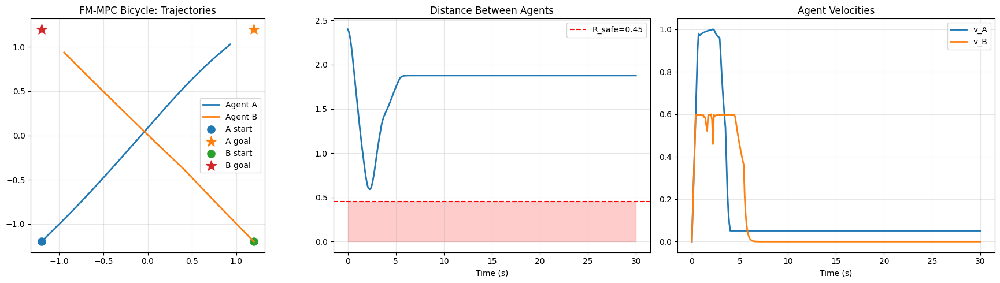

In [9]:
# ============================================================
# FM-MPC Bicycle - 修复版：后期直接朝目标走
# 保留 CBF 强度，只修改 Pure Pursuit 后期行为
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 5
REPLAN_EVERY = 1
MAX_STEPS = 300

# Goal / stopping
goal_tol      = 0.35
stop_radius   = 0.45
creep_radius  = 0.90
v_creep       = 0.12

# Safety
R_SAFE = 0.45

# ★ 后期直接朝目标走的参数
DIRECT_TO_GOAL_DIST = 1.5  # 开始混合的距离
BLEND_DIST = 0.7           # 完全朝目标走的距离

# ===============================================================
# 3) Bicycle dynamics
# ===============================================================
v_max_A   = 1.0
v_max_B   = 0.6
v_min     = 0.0
a_max     = 1.5
L         = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor   = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c = float(d[0] / dist)
    s = float(d[1] / dist)
    R_wc = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings - 保持原参数
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38

SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0

CBF_LIGHT  = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3, alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1,2), (H,1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1,2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf = build_canonical_frame(self_xy, goal_xy)

    if other_pred_pos is None or len(other_pred_pos) == 0:
        other_now = self_xy
    else:
        other_now = other_pred_pos[0]
    dist_AB = float(np.linalg.norm(self_xy - other_now))

    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    x0_noise = make_x0_noise(T_steps, seed)

    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45,
        goal_guidance_weight=0.90,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf),
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    xy_can = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# 8) Pure Pursuit - ★ 后期直接朝目标走
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    """
    修改版 Pure Pursuit:
    - 远离目标时：跟随 FM 路径
    - 接近目标时：逐渐切换到直接朝目标走
    """
    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)

    Ld_min = 0.35
    Ld_max = 1.10
    k_brake = 4.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)

    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        # --- 停车逻辑 ---
        if d_goal <= stop_radius:
            a = float(np.clip(-k_brake * v, -a_max, 0.0))
            delta_des = 0.0
            dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        # --- Lookahead 距离 ---
        Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))

        # --- 找路径上的 target ---
        near_idx = _closest_index(path_xy, pos)
        near_idx = max(near_idx, last_path_idx)
        path_target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)

        # ★★★ 后期阶段：混合 path_target 和 goal ★★★
        if d_goal < DIRECT_TO_GOAL_DIST:
            if d_goal < BLEND_DIST:
                blend = 1.0  # 完全朝目标
            else:
                # 线性插值
                blend = (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
                blend = float(np.clip(blend, 0.0, 1.0))
            
            # 混合目标点
            target = (1.0 - blend) * path_target + blend * goal_xy
        else:
            target = path_target

        # --- 计算转向 ---
        dx = float(target[0] - x)
        dy = float(target[1] - y)
        ang = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))

        kappa = 2.0 * math.sin(alpha) / max(1e-3, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        # --- 速度 ---
        v_des = v_max
        if d_goal < creep_radius:
            v_des = float(np.clip(v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        turn_pen = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des *= turn_pen

        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost
# ===============================================================
W_END   = 18.0
W_PATH  = 1.5
W_COLL  = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))

    M = min(len(pos_self), len(pos_other_pred))
    if M <= 1:
        min_d = float("inf")
    else:
        d = np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1)
        min_d = float(d.min())

    viol = max(0.0, R_SAFE - min_d)
    coll = float(viol * viol)

    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)

    best = None
    cbf_count = 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy, other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue

        cbf_count += int(used_cbf)

        U = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, st_self = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)

        J = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0 = U[0].copy()

        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)

    if best is None:
        return np.zeros(2, np.float32), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA = np.zeros(2, np.float32)
uB = np.zeros(2, np.float32)

cbf_total = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 后期直接朝目标走")
print(f"DIRECT_TO_GOAL_DIST={DIRECT_TO_GOAL_DIST}, BLEND_DIST={BLEND_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = (dA < goal_tol and sA[3] < 0.08)
    doneB = (dB < goal_tol and sB[3] < 0.08)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B, seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A, seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.2f} dB={dB:.2f} dist={dist_AB:.2f} vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)

print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter([xA0[0]], [xA0[1]], s=90, marker="o", label="A start")
ax.scatter([gA[0]],  [gA[1]],  s=180, marker="*", label="A goal")
ax.scatter([xB0[0]], [xB0[1]], s=90, marker="o", label="B start")
ax.scatter([gB[0]],  [gB[1]],  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1], s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents")
ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities")
ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0: 'float' = 0.5, tau1: 'float' = 0.9, prox_k: 'float' = 3.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - Pure Pursuit 修复版（正确到达终点）
goal_tol=0.2  ARRIVAL_DIST=0.15  APPROACH_DIST=0.6
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15
[  2] dA=3.349 dB=3.349 dist=2.336 vA=0.30 vB=0.30
[  3] dA=3.304 dB=

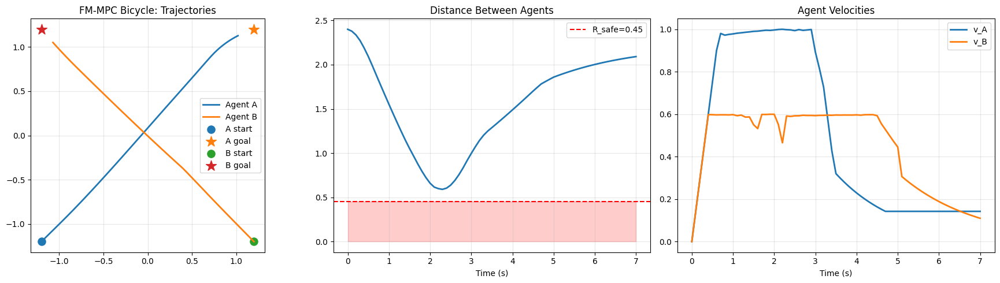

In [10]:
# ============================================================
# FM-MPC Bicycle - 修复版：Pure Pursuit 正确到达终点
# 修改点：
#   1. Ld = min(Ld, d_goal * 0.85)  → 消除绕圈根源
#   2. d_goal < APPROACH_DIST 时 target 直接指向 goal
#   3. ARRIVAL_DIST 改小，消除停车死锁
#   4. done 判定去掉速度条件
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 5
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping  ★ 全部修改
goal_tol      = 0.20   # 原 0.35
ARRIVAL_DIST  = 0.15   # ★ 新增：真正刹车距离
APPROACH_DIST = 0.60   # ★ 新增：进入直接指向goal模式的距离
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# ===============================================================
# 3) Bicycle dynamics  （不变）
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    # 初始化st，Hh+1行5列，用于存储状态
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st
    #用bicycle_step函数，根据当前状态s0和控制u，计算下一个状态st[i+1]

# ===============================================================
# 4) Canonical frame  （不变）
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings  （不变）
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction  （不变）
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st
    # 用rollout_bicycle函数，根据other_state和other_u_last，计算other_state的预测轨迹pos和状态st constant control prediction

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    #tf：canonical frame
    #other_pred_pos：other_state的预测轨迹
    #dist_AB：other_state和self_state的距离
    # 用build_time_expanded_ellipses函数，根据tf、other_pred_pos和dist_AB，计算other_pred_pos的预测轨迹的椭圆
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    #idxs：other_pred_pos的预测轨迹的椭圆的索引 减少计算量
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    # 用r_obs_near if dist_AB < 1.2 else r_obs_far计算椭圆的半径
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling  （不变）
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []
    x0_noise = make_x0_noise(T_steps, seed)
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec, start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45, goal_guidance_weight=0.90,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None, ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# 8) Pure Pursuit — ★ 修复版（框架不变，三处关键修改）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))
    # 找“离我最近的轨迹点索引” 

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    Ld_min  = 0.20
    Ld_max  = 1.10
    k_brake = 5.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        # ★ 修改1：真正很近才停车，消除死锁
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        # ★ 修改2：接近终点时 target 直接指向 goal（纯 Pure Pursuit，只换目标点）
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            # 正常 Pure Pursuit
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            # ★ 修改3：Ld 不超过 d_goal * 0.85，防止 lookahead 越过终点绕圈
            Ld = min(Ld, d_goal * 0.85)

            near_idx = _closest_index(path_xy, pos)
            near_idx = max(near_idx, last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)

            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        # 转向（与原版完全相同）
        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))

        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target  # 曲率
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max)) # 期望转向角
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        turn_pen = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des   *= turn_pen

        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost  （不变）
# ===============================================================
W_END    = 18.0
W_PATH   = 1.5
W_COLL   = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0]**2 + 0.4*dU[:, 1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan  （不变）
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)
    best      = None
    cbf_count = 0
    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy,
                other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue
        cbf_count += int(used_cbf)
        U        = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J        = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0       = U[0].copy()
        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)
    if best is None:
        return np.zeros(2, np.float32), float("inf"), None, 0
    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup  （不变）
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0]))
thB0 = float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - Pure Pursuit 修复版（正确到达终点）")
print(f"goal_tol={goal_tol}  ARRIVAL_DIST={ARRIVAL_DIST}  APPROACH_DIST={APPROACH_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))

    # ★ done 判定：只看位置，不要求速度
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)
        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)
        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots  （不变）
# ===============================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [3]:
print(type(model_safefm))
print(next(model_safefm.parameters()).device)
print(norm_params.keys())
print("ctrl_mean shape:", norm_params['ctrl_mean'].shape)
print("cond_mean:", norm_params['cond_mean'])

<class 'fmtorch.models.simple1d_unet.SimpleUNet1D'>
cuda:0
dict_keys(['ctrl_mean', 'ctrl_std', 'cond_mean', 'cond_scale'])
ctrl_mean shape: (1, 2, 1)
cond_mean: [3.         0.3754593  0.         0.         0.         0.
 0.49190566]


[依赖检查] ✓
[Data] N=100  T=60  D=5

验证中... (N=50 samples)
  [10/50]  ADE=0.4798  FDE=1.3768
  [20/50]  ADE=0.4745  FDE=1.3595
  [30/50]  ADE=0.5426  FDE=1.4327
  [40/50]  ADE=0.6232  FDE=1.5484
  [50/50]  ADE=0.6827  FDE=1.7317

  ADE  : 0.6827  ±0.5281
  FDE  : 1.7317  ±1.2879

判断标准（canonical frame）：
  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题
  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题


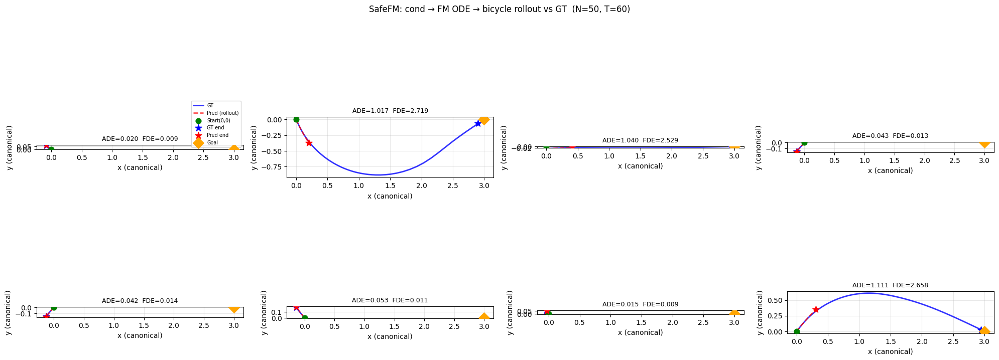

C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\3661736317.py:349: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\3661736317.py:349: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAPH-8D70}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\3661736317.py:349: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\3661736317.py:349: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\3661736317.py:349: UserWarning: Glyph 35843 (\N{CJK UNIFIED IDEOGRAPH-8C03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_36164\3661736317.py:349: UserWarning: Glyph 22836 (\N{CJK 

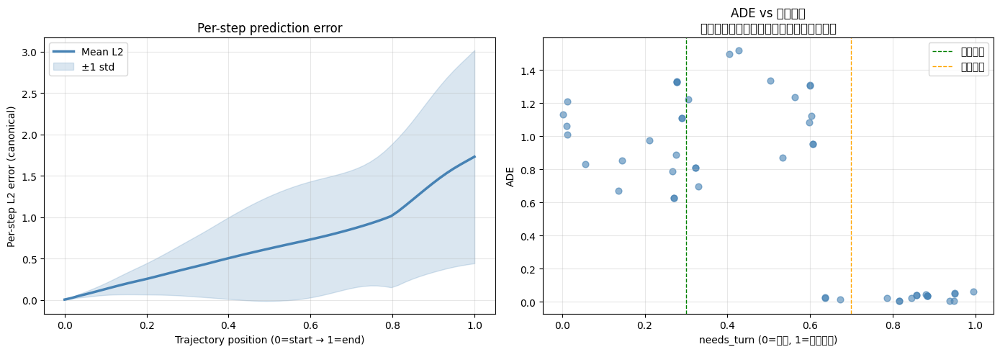

In [4]:
# ================================================================
# SafeFM Validation — model_safefm (2ch ctrl) pred vs GT
#
# 对应 5ch validation cell 的 SafeFM 版本
# 不需要 piecewise_sample_fm_5ch_with_cbf，不需要重跑 rollout
# 直接用原始数据集验证：给定 cond → FM ODE → [a, delta_rate] → bicycle rollout → xy
#
# ★ 前提：必须先运行 SafeFM 训练 cell，确保以下已定义：
#   - model_safefm, device
#   - norm_params (包含 ctrl_mean/ctrl_std/cond_mean/cond_scale)
# ================================================================

import numpy as np
import torch
import math
import matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)

# ── 依赖检查 ──────────────────────────────────────────────────
assert 'model_safefm' in dir(), "请先运行 SafeFM 训练 cell"
assert 'norm_params'  in dir(), "请先运行 SafeFM 训练 cell"
model_safefm.eval()
print("[依赖检查] ✓")

# norm tensors
_ctrl_mean  = torch.tensor(norm_params['ctrl_mean'],  dtype=torch.float32, device=device)
_ctrl_std   = torch.tensor(norm_params['ctrl_std'],   dtype=torch.float32, device=device)
_cond_mean  = norm_params['cond_mean']   # numpy (7,)
_cond_scale = norm_params['cond_scale']  # numpy (7,)

# ================================================================
# 0) 加载数据
# ================================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(
        r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache"
        r"\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
    )

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']  # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}  T={T}  D={D}")

traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1).astype(np.float32)  # (N, 5, T)

# ================================================================
# 1) SafeFM cond 构建（7维，与训练完全一致）
# ================================================================
def _wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def build_safefm_cond(traj_i, state_i, goal_xy=None):
    """
    traj_i:  (5, T) — [x, y, th, a, dr]
    state_i: (5,)   — [x, y, th, v, delta] 起始状态
    返回:
      cond_norm (7,) 已归一化
      angle_off      canonical frame 旋转角（用于 rollout 后转回 world frame）
      start_xy       起点坐标
    """
    x0, y0 = float(traj_i[0, 0]), float(traj_i[1, 0])
    th0    = float(traj_i[2, 0])

    if goal_xy is not None:
        gx, gy = float(goal_xy[0]), float(goal_xy[1])
    else:
        gx, gy = float(traj_i[0, -1]), float(traj_i[1, -1])

    dx_w = gx - x0
    dy_w = gy - y0
    angle_off = float(math.atan2(dy_w, dx_w))

    cos_a  = math.cos(angle_off)
    sin_a  = math.sin(angle_off)
    dx_can = cos_a * dx_w + sin_a * dy_w

    th0_can      = _wrap_pi(th0 - angle_off)
    th0_can_norm = float(th0_can / math.pi)
    needs_turn   = float(abs(th0_can) / math.pi)

    cond_raw = np.array([
        dx_can,
        float(state_i[3]),          # v0
        float(math.cos(th0_can)),   # cos
        float(math.sin(th0_can)),   # sin
        float(state_i[4]),          # delta0
        th0_can_norm,
        needs_turn,
    ], dtype=np.float32)

    cond_norm = cond_raw.copy()
    for i in [0, 1, 4, 6]:
        cond_norm[i] = (cond_raw[i] - _cond_mean[i]) / _cond_scale[i]

    return cond_norm, angle_off, np.array([x0, y0], np.float32)

# ================================================================
# 2) FM ODE sampler（Euler，t: 0→1）
# ================================================================
FM_ODE_STEPS = 20

@torch.no_grad()
def safefm_sample_ctrl(cond_norm_vec, seed=0):
    """
    cond_norm_vec: (7,) numpy 已归一化
    返回: ctrl (2, T) numpy，已反归一化 [a, delta_rate]
    """
    cond_t = torch.tensor(cond_norm_vec, dtype=torch.float32, device=device).unsqueeze(0)

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x = torch.randn((1, 2, T), device=device, generator=g)

    dt = 1.0 / FM_ODE_STEPS
    for _ in range(FM_ODE_STEPS):
        t_now = torch.full((1,), _ * dt, dtype=torch.float32, device=device)
        v     = model_safefm(x, t_now, cond=cond_t)
        x     = x + dt * v

    # 反归一化
    ctrl = x * _ctrl_std + _ctrl_mean   # (1, 2, T)
    return ctrl[0].cpu().numpy()        # (2, T)

# ================================================================
# 3) Bicycle rollout → xy 轨迹（world frame）
# ================================================================
_a_max          = 1.5
_L              = 0.30
_delta_max      = math.radians(35.0)
_delta_rate_max = math.radians(90.0)
_v_min          = 0.0
_v_floor        = 0.05
_dt_fm          = 1.0 / T   # 与训练数据时间步一致

def bicycle_rollout_xy(state0, ctrl, v_max=1.0):
    """
    state0: (5,) [x, y, th, v, delta]
    ctrl:   (2, T) [a, delta_rate]
    返回:   xy (T+1, 2) world frame
    """
    s  = state0.copy().astype(np.float32)
    xy = np.zeros((T + 1, 2), dtype=np.float32)
    xy[0] = s[:2]

    for i in range(T):
        a  = float(np.clip(ctrl[0, i], -_a_max, _a_max))
        dr = float(np.clip(ctrl[1, i], -_delta_rate_max, _delta_rate_max))

        v2     = float(np.clip(s[3] + _dt_fm * a, _v_min, v_max))
        if v2 < _v_floor and a > 0.02:
            v2 = _v_floor
        delta2 = float(np.clip(s[4] + _dt_fm * dr, -_delta_max, _delta_max))
        th2    = _wrap_pi(s[2] + _dt_fm * (v2 / _L) * math.tan(delta2))
        x2     = s[0] + _dt_fm * v2 * math.cos(th2)
        y2     = s[1] + _dt_fm * v2 * math.sin(th2)
        s      = np.array([x2, y2, th2, v2, delta2], np.float32)
        xy[i + 1] = s[:2]

    return xy  # (T+1, 2)

def xy_world_to_canonical(xy_world, start_xy, angle_off):
    """xy (T+1,2) world → canonical frame"""
    cos_a =  math.cos(angle_off)
    sin_a =  math.sin(angle_off)
    R = np.array([[cos_a, sin_a], [-sin_a, cos_a]], np.float32)
    return ((xy_world - start_xy) @ R.T).astype(np.float32)

# ================================================================
# 4) GT canonical frame 转换（对应 5ch validation 的 canonicalize_single）
# ================================================================
def gt_canonical_xy(traj_i, goal_xy, angle_off, start_xy):
    """
    把 GT 轨迹的 xy 转到 canonical frame，用于和 pred 比较
    """
    xy_w = traj_i[0:2, :].T.astype(np.float32)  # (T, 2)
    return xy_world_to_canonical(xy_w, start_xy, angle_off)  # (T, 2)

# ================================================================
# 5) 指标（与 5ch validation 完全一致）
# ================================================================
def compute_metrics(pred_xy_can, gt_xy_can):
    """
    pred_xy_can: (T, 2) 或 (T+1, 2)
    gt_xy_can:   (T, 2)
    """
    min_len = min(len(pred_xy_can), len(gt_xy_can))
    p = pred_xy_can[:min_len]
    g = gt_xy_can[:min_len]

    per_step = np.linalg.norm(p - g, axis=1)
    ade = float(per_step.mean())
    fde = float(np.linalg.norm(p[-1] - g[-1]))
    return ade, fde, per_step

# ================================================================
# 6) 主验证循环
# ================================================================
N_SAMPLES = 50
np.random.seed(42)

ades, fdes       = [], []
all_per_step     = []
needs_turn_vals  = []

print(f"\n验证中... (N={N_SAMPLES} samples)")

for i in range(N_SAMPLES):
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]       # (5, T)
    state0   = states[idx, 0]      # (5,) 起始状态
    goal     = goals[idx] if goals is not None else None

    # cond
    cond_norm, angle_off, start_xy = build_safefm_cond(traj, state0, goal)
    needs_turn_vals.append(float(norm_params['cond_mean'][6] +
                                 cond_norm[6] * norm_params['cond_scale'][6]))

    # SafeFM → ctrl → rollout
    ctrl     = safefm_sample_ctrl(cond_norm, seed=i)
    xy_world = bicycle_rollout_xy(state0, ctrl, v_max=1.0)

    # 转 canonical frame
    pred_can = xy_world_to_canonical(xy_world, start_xy, angle_off)  # (T+1, 2)
    gt_can   = gt_canonical_xy(traj, goal, angle_off, start_xy)      # (T, 2)

    ade, fde, per_step = compute_metrics(pred_can[1:], gt_can)  # pred 从 t=1 开始
    ades.append(ade); fdes.append(fde)
    all_per_step.append(per_step)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{N_SAMPLES}]  "
              f"ADE={np.mean(ades):.4f}  "
              f"FDE={np.mean(fdes):.4f}")

# ================================================================
# 7) 结果打印
# ================================================================
print(f"\n{'='*50}")
print(f"  ADE  : {np.mean(ades):.4f}  ±{np.std(ades):.4f}")
print(f"  FDE  : {np.mean(fdes):.4f}  ±{np.std(fdes):.4f}")
print(f"{'='*50}")
print()
print("判断标准（canonical frame）：")
print("  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题")
print("  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题")

# ================================================================
# 8) 图1：8条代表性轨迹对比
# ================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
np.random.seed(0)

for pi in range(8):
    ax     = axes[pi]
    idx    = np.random.randint(0, N)
    traj   = traj_5ch[idx]
    state0 = states[idx, 0]
    goal   = goals[idx] if goals is not None else None

    cond_norm, angle_off, start_xy = build_safefm_cond(traj, state0, goal)
    ctrl     = safefm_sample_ctrl(cond_norm, seed=pi * 13)
    xy_world = bicycle_rollout_xy(state0, ctrl, v_max=1.0)

    pred_can = xy_world_to_canonical(xy_world, start_xy, angle_off)
    gt_can   = gt_canonical_xy(traj, goal, angle_off, start_xy)

    ade, fde, _ = compute_metrics(pred_can[1:], gt_can)

    # GT 的 goal 在 canonical frame 的位置
    if goal is not None:
        gx_w, gy_w = float(goal[0]), float(goal[1])
    else:
        gx_w, gy_w = float(traj[0, -1]), float(traj[1, -1])
    goal_can = xy_world_to_canonical(
        np.array([[gx_w, gy_w]], np.float32), start_xy, angle_off
    )[0]

    ax.plot(gt_can[:, 0],   gt_can[:, 1],
            'b-',  lw=2.0, alpha=0.8, label="GT")
    ax.plot(pred_can[:, 0], pred_can[:, 1],
            'r--', lw=1.8, alpha=0.8, label="Pred (rollout)")
    ax.scatter([0], [0],
               c='green', s=60, zorder=6, label="Start(0,0)")
    ax.scatter([gt_can[-1, 0]], [gt_can[-1, 1]],
               c='blue', s=100, marker='*', zorder=6, label="GT end")
    ax.scatter([pred_can[-1, 0]], [pred_can[-1, 1]],
               c='red',  s=100, marker='*', zorder=6, label="Pred end")
    ax.scatter([goal_can[0]], [goal_can[1]],
               c='orange', s=120, marker='D', zorder=6, label="Goal")

    ax.set_title(f"ADE={ade:.3f}  FDE={fde:.3f}", fontsize=9)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")
    if pi == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    f"SafeFM: cond → FM ODE → bicycle rollout vs GT  (N={N_SAMPLES}, T={T})",
    fontsize=12
)
plt.tight_layout()
plt.show()

# ================================================================
# 9) 图2：逐步误差 + 按 needs_turn 分组
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 逐步误差曲线
mean_curve = np.mean(all_per_step, axis=0)
std_curve  = np.std(all_per_step,  axis=0)
t_axis     = np.linspace(0.0, 1.0, len(mean_curve))

axes[0].plot(t_axis, mean_curve, lw=2.5, color='steelblue', label="Mean L2")
axes[0].fill_between(t_axis,
                     mean_curve - std_curve,
                     mean_curve + std_curve,
                     alpha=0.2, color='steelblue', label="±1 std")
axes[0].set_xlabel("Trajectory position (0=start → 1=end)")
axes[0].set_ylabel("Per-step L2 error (canonical)")
axes[0].set_title("Per-step prediction error")
axes[0].legend(); axes[0].grid(alpha=0.3)

# ADE 按 needs_turn 分组散点图（检验模型是否真的学会了区分调头 vs 直走）
nt_arr  = np.array(needs_turn_vals)
ade_arr = np.array(ades)
axes[1].scatter(nt_arr, ade_arr, alpha=0.6, c='steelblue', s=40)
axes[1].axvline(0.3, color='green',  ls='--', lw=1, label='直走阈值')
axes[1].axvline(0.7, color='orange', ls='--', lw=1, label='调头阈值')
axes[1].set_xlabel("needs_turn (0=直走, 1=完全调头)")
axes[1].set_ylabel("ADE")
axes[1].set_title("ADE vs 朝向偏差\n（散点均匀说明模型对两种情况处理一致）")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# 在 validation cell 里临时加这几行，看失败案例的控制输出
idx_fail = np.argsort(ades)[-3:]  # ADE 最大的3个
for i in idx_fail:
    idx    = np.random.randint(0, N)
    traj   = traj_5ch[idx]
    state0 = states[idx, 0]
    goal   = goals[idx] if goals is not None else None
    cond_norm, angle_off, start_xy = build_safefm_cond(traj, state0, goal)
    ctrl = safefm_sample_ctrl(cond_norm, seed=i)
    print(f"needs_turn={norm_params['cond_mean'][6] + cond_norm[6]*norm_params['cond_scale'][6]:.2f} | "
          f"a mean={ctrl[0].mean():.3f} | delta_rate mean={ctrl[1].mean():.3f}")

needs_turn=0.46 | a mean=0.038 | delta_rate mean=0.376
needs_turn=0.82 | a mean=-0.314 | delta_rate mean=-0.033
needs_turn=0.97 | a mean=-0.331 | delta_rate mean=0.003


[依赖检查] ✓
[Data] N=100  T=60  D=5
[Params] T_steps=40  num_segments=5  total_time=1.0  ode_method=euler
[注意] T_steps(40) != 数据T(60)，pred 会插值对齐

验证中... (N=50 samples)
  [10/50]  ADE=0.1993  FDE=0.2708  HDG=6.60°
  [20/50]  ADE=0.1888  FDE=0.2709  HDG=5.73°
  [30/50]  ADE=0.2205  FDE=0.2641  HDG=6.95°
  [40/50]  ADE=0.2386  FDE=0.2509  HDG=7.80°
  [50/50]  ADE=0.2352  FDE=0.2292  HDG=7.49°

  ADE  : 0.2352  ±0.2218
  FDE  : 0.2292  ±0.1838
  HDG  : 7.49°  ±11.73°

判断标准（canonical frame）：
  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题
  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题
  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题


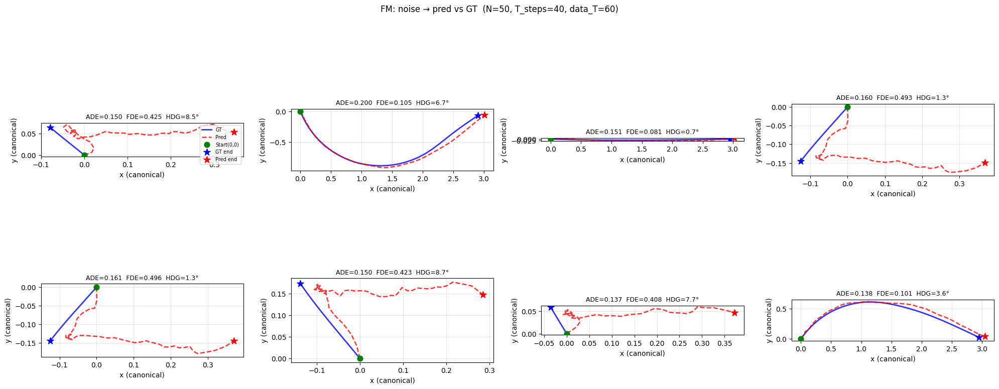

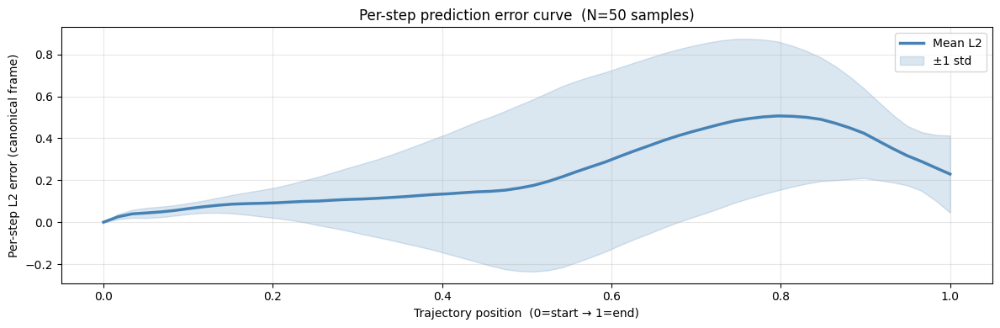

In [14]:
# ============================================================
# FM Validation — noise → piecewise_sample_fm_5ch_with_cbf → pred vs GT
#
# 数据集里的 canonical ground truth
# 你训练时想拟合的目标分布
#
#FM 生成得像不像训练数据。
#生成模型层 (generative model fidelity)

# pred_can vs traj_can 
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf（来自 sampler_5h.py）
#   - build_canonical_frame（两车实验 Section 4）
#   - make_x0_noise（两车实验 Section 7）
#   - T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
assert 'build_canonical_frame'            in dir(), "请先运行两车实验 cell"
assert 'make_x0_noise'                    in dir(), "请先运行两车实验 cell"
assert 'piecewise_sample_fm_5ch_with_cbf' in dir(), "请先运行两车实验 cell"
assert 'T_steps'                          in dir(), "请先运行两车实验 cell"
print("[依赖检查] ✓")


# ================================================================
# 0) 加载数据
# ================================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(
        r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache"
        r"\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
    )

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']  # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}  T={T}  D={D}")
print(f"[Params] T_steps={T_steps}  num_segments={num_segments}  "
      f"total_time={total_time}  ode_method={ode_method}")
if T_steps != T:
    print(f"[注意] T_steps({T_steps}) != 数据T({T})，pred 会插值对齐")

# 构建 5-channel（channel 定义与训练完全一致）
# ch0=x, ch1=y, ch2=theta, ch3=a, ch4=delta_rate
traj_5ch = np.stack([
    states[:, :, 0],    # x
    states[:, :, 1],    # y
    states[:, :, 2],    # theta
    controls[:, :, 0],  # a
    controls[:, :, 1],  # delta_rate
], axis=1).astype(np.float32)  # (N, 5, T)


# ================================================================
# 1) canonical frame 转换
#
# ★ cond 修复：
#   v0     来自 states[idx, 0, 3]  （速度，不是加速度）
#   delta0 来自 states[idx, 0, 4]  （转向角，不是转向角速度）
#   不能从 traj_5ch[idx, 3, 0] / traj_5ch[idx, 4, 0] 取，
#   因为那两个是 a0 和 delta_rate0
# ================================================================
def canonicalize_single(traj_i, states_i, goal_xy=None):
    """
    traj_i:   (5, T)  [x, y, theta, a, delta_rate]
    states_i: (T, 5)  [x, y, theta, v, delta]  ← 用于取 v0, delta0
    goal_xy:  (2,) or None

    返回:
      traj_can : (5, T)  canonical frame 轨迹
      cond     : (5,)    [dist, v0, cos(th0_can), sin(th0_can), delta0]
      tf       : 变换字典
    """
    x0 = float(traj_i[0, 0]);  y0 = float(traj_i[1, 0])
    gx = float(goal_xy[0]) if goal_xy is not None else float(traj_i[0, -1])
    gy = float(goal_xy[1]) if goal_xy is not None else float(traj_i[1, -1])

    # ★ 直接调用前面已定义的 build_canonical_frame
    tf = build_canonical_frame(
        np.array([x0, y0], np.float32),
        np.array([gx, gy], np.float32)
    )

    out    = traj_i.copy()
    xy_can = tf["w2c"](traj_i[0:2, :].T)  # (T, 2)
    out[0] = xy_can[:, 0]
    out[1] = xy_can[:, 1]
    out[2] = np.array([tf["w2c_angle"](float(th)) for th in traj_i[2]])

    th0_can = tf["w2c_angle"](float(traj_i[2, 0]))

    # ★ 修复：v0 和 delta0 从 states_i 取，而不是从 traj_i[3,0]/traj_i[4,0]
    v0     = float(states_i[0, 3])  # states 第3列 = v（速度）
    delta0 = float(states_i[0, 4])  # states 第4列 = delta（转向角）

    cond = np.array([
        tf["dist"],
        v0,
        float(np.cos(th0_can)),
        float(np.sin(th0_can)),
        delta0,
    ], dtype=np.float32)

    return out, cond, tf


# ================================================================
# 2) FM 预测：直接调用 piecewise_sample_fm_5ch_with_cbf
#    use_cbf=False，参数与两车实验完全一致
# ================================================================
def fm_predict_full(cond, tf, seed=0):
    """
    noise → piecewise_sample_fm_5ch_with_cbf(use_cbf=False) → pred (5, T)
    参数与两车实验 mpc_replan 里的调用完全一致。
    """
    # ★ 直接调用前面已定义的 make_x0_noise
    x0_noise = make_x0_noise(T_steps, seed)

    # ★ 直接调用前面已加载的 piecewise_sample_fm_5ch_with_cbf
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )  # x_can: (5, T_steps)

    # 插值对齐到数据长度 T
    if x_can.shape[1] != T:
        t_old  = np.linspace(0.0, 1.0, x_can.shape[1])
        t_new  = np.linspace(0.0, 1.0, T)
        x_can  = np.stack([
            interp1d(t_old, x_can[ch], kind='linear')(t_new)
            for ch in range(5)
        ], axis=0).astype(np.float32)

    return x_can  # (5, T)


# ================================================================
# 3) 指标
# ================================================================
def compute_metrics(pred_can, traj_can):
    pred_xy  = pred_can[0:2, :].T          # (T, 2)
    true_xy  = traj_can[0:2, :].T
    per_step = np.linalg.norm(pred_xy - true_xy, axis=1)  # (T,)

    ade = float(per_step.mean())
    fde = float(np.linalg.norm(pred_xy[-1] - true_xy[-1]))

    hdg_diff = (pred_can[2] - traj_can[2] + np.pi) % (2 * np.pi) - np.pi
    hdg      = float(np.mean(np.abs(hdg_diff)))

    return ade, fde, hdg, per_step


# ================================================================
# 4) 主验证循环
# ================================================================
N_SAMPLES = 50
np.random.seed(42)

ades, fdes, hdgs = [], [], []
all_per_step     = []

print(f"\n验证中... (N={N_SAMPLES} samples)")

for i in range(N_SAMPLES):
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]          # (5, T)
    states_i = states[idx]            # (T, 5)  ← 传给 canonicalize_single
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=i)

    ade, fde, hdg, per_step = compute_metrics(pred_can, traj_can)

    ades.append(ade);  fdes.append(fde)
    hdgs.append(hdg);  all_per_step.append(per_step)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{N_SAMPLES}]  "
              f"ADE={np.mean(ades):.4f}  "
              f"FDE={np.mean(fdes):.4f}  "
              f"HDG={np.rad2deg(np.mean(hdgs)):.2f}°")


# ================================================================
# 5) 结果打印
# ================================================================
print(f"\n{'='*50}")
print(f"  ADE  : {np.mean(ades):.4f}  ±{np.std(ades):.4f}")
print(f"  FDE  : {np.mean(fdes):.4f}  ±{np.std(fdes):.4f}")
print(f"  HDG  : {np.rad2deg(np.mean(hdgs)):.2f}°  "
      f"±{np.rad2deg(np.std(hdgs)):.2f}°")
print(f"{'='*50}")
print()
print("判断标准（canonical frame）：")
print("  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题")
print("  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题")
print("  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题")


# ================================================================
# 6) 图1：8 条代表性轨迹对比
# ================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
np.random.seed(0)

for pi in range(8):
    ax       = axes[pi]
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]
    states_i = states[idx]
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=pi * 13)
    a, f, h, _         = compute_metrics(pred_can, traj_can)

    ax.plot(traj_can[0], traj_can[1],
            'b-',  lw=2.0, alpha=0.8, label="GT")
    ax.plot(pred_can[0], pred_can[1],
            'r--', lw=1.8, alpha=0.8, label="Pred")
    ax.scatter([0], [0],
               c='green', s=60, zorder=6, label="Start(0,0)")
    ax.scatter([traj_can[0, -1]], [traj_can[1, -1]],
               c='blue', s=100, marker='*', zorder=6, label="GT end")
    ax.scatter([pred_can[0, -1]], [pred_can[1, -1]],
               c='red',  s=100, marker='*', zorder=6, label="Pred end")

    ax.set_title(
        f"ADE={a:.3f}  FDE={f:.3f}  HDG={np.rad2deg(h):.1f}°",
        fontsize=9
    )
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")
    if pi == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    f"FM: noise → pred vs GT  "
    f"(N={N_SAMPLES}, T_steps={T_steps}, data_T={T})",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 7) 图2：逐步误差曲线
# ================================================================
mean_curve = np.mean(all_per_step, axis=0)
std_curve  = np.std(all_per_step,  axis=0)
t_axis     = np.linspace(0.0, 1.0, T)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_axis, mean_curve, lw=2.5, color='steelblue', label="Mean L2")
ax.fill_between(t_axis,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.2, color='steelblue', label="±1 std")
ax.set_xlabel("Trajectory position  (0=start → 1=end)")
ax.set_ylabel("Per-step L2 error (canonical frame)")
ax.set_title(f"Per-step prediction error curve  (N={N_SAMPLES} samples)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[依赖检查] ✓
FM Trackability Validation
  每个 seed 独立：fm_path → PP rollout → compare

[Scene] Agent A (diagonal)
  seed=0  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1460  FDE_fm=0.6383
  seed=1  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1474  FDE_fm=0.6373
  seed=2  n_pp= 47  n_fm= 40  ADE=1.0084  FDE_pp=0.1470  FDE_fm=0.6373

[Scene] Agent B (diagonal)
  seed=0  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1461  FDE_fm=0.6381
  seed=1  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1474  FDE_fm=0.6373
  seed=2  n_pp= 47  n_fm= 40  ADE=1.0084  FDE_pp=0.1471  FDE_fm=0.6372

[Scene] Horizontal
  seed=0  n_pp= 43  n_fm= 40  ADE=0.8234  FDE_pp=0.1475  FDE_fm=0.3132
  seed=1  n_pp= 43  n_fm= 40  ADE=0.8229  FDE_pp=0.1486  FDE_fm=0.3127
  seed=2  n_pp= 43  n_fm= 40  ADE=0.8240  FDE_pp=0.1474  FDE_fm=0.3123

[Scene] Angled start
  seed=0  n_pp= 41  n_fm= 40  ADE=0.6944  FDE_pp=0.1413  FDE_fm=0.0381
  seed=1  n_pp= 41  n_fm= 40  ADE=0.6941  FDE_pp=0.1418  FDE_fm=0.0386
  seed=2  n_pp= 41  n_fm= 40  ADE=0.6955 

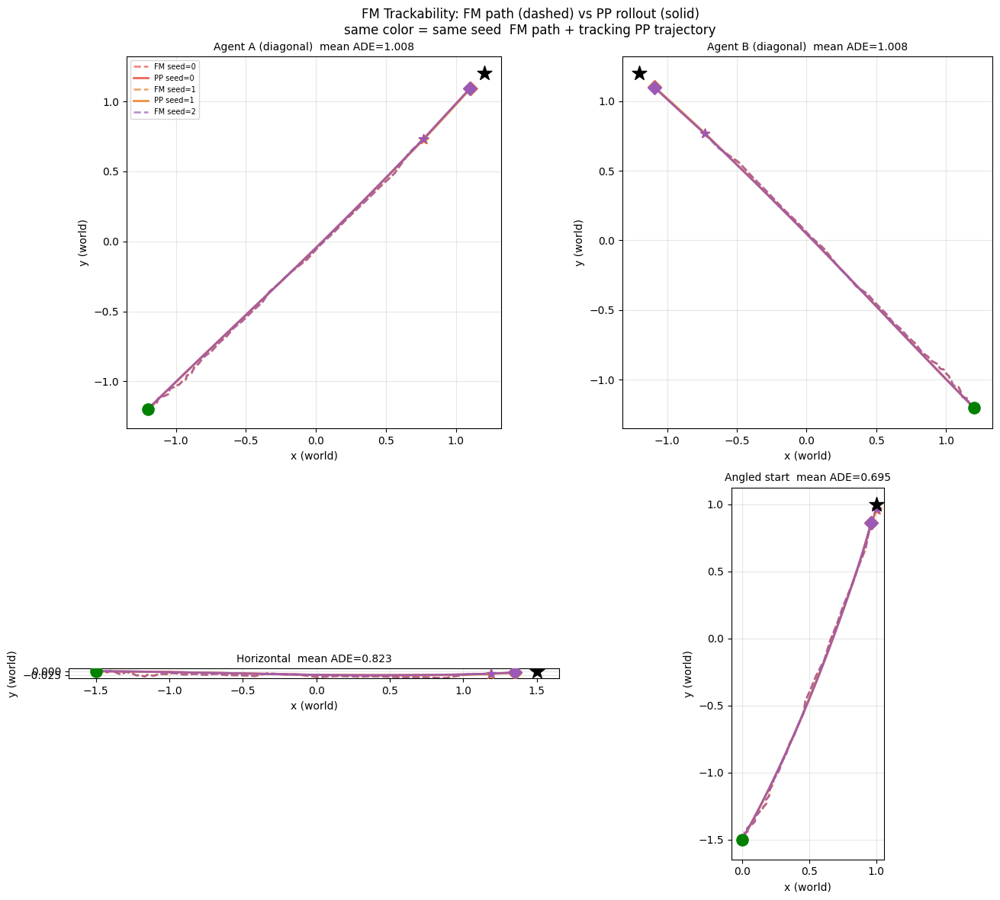

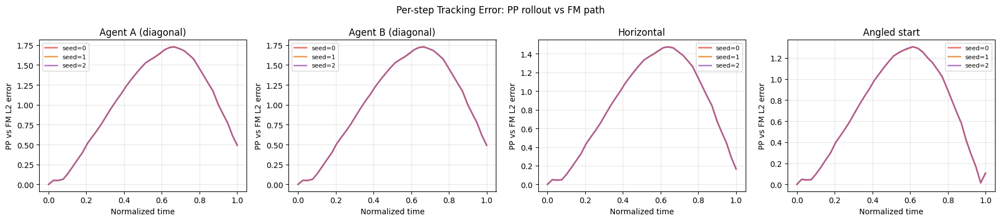

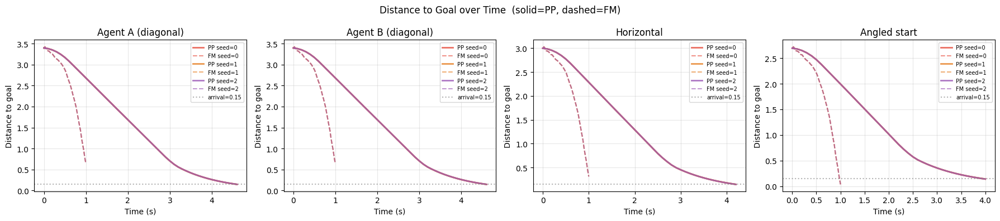

In [24]:
# ============================================================
# FM Validation — Trackability
#
# 验证：FM 生成的路径是否可以被 Pure Pursuit 稳定跟踪
#
# 结构（每个 seed 独立一对）：
#   fm_path  = rollout_fm(start, goal, seed)
#   traj_pp  = rollout_pure_pursuit(start, goal, ref=fm_path)
#   compare(traj_pp, fm_path)
#
# 指标：
#   ADE  小 → FM path 动力学可行，PP 能跟上
#   ADE  大 → FM path 动力学不可行，PP 跟不上
#   FDE_pp  → PP 实际执行后距终点多远
#   FDE_fm  → FM path 终点距目标多远
#
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf
#   - build_canonical_frame, make_x0_noise
#   - bicycle_step, pure_pursuit_controls
#   - wrap_pi, T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
for _name in ['build_canonical_frame', 'make_x0_noise',
              'piecewise_sample_fm_5ch_with_cbf',
              'bicycle_step', 'pure_pursuit_controls',
              'T_steps', 'noise_scale']:
    assert _name in dir(), f"请先运行两车实验 cell：{_name} 未定义"
print("[依赖检查] ✓")


# ================================================================
# 1) FM path generation
# ================================================================
def rollout_fm(start_state, goal_xy, seed=0):
    """
    noise → piecewise_sample（无CBF）→ FM path（world frame）
    返回:
      path_world: (T_steps, 2)  world frame XY
      x_can:      (5, T_steps)  canonical frame 完整轨迹
      tf:         canonical frame 变换字典
    """
    tf = build_canonical_frame(start_state[:2], goal_xy)

    v0     = float(start_state[3])
    delta0 = float(start_state[4])
    th_can = tf["w2c_angle"](float(start_state[2]))
    cond   = np.array([
        tf["dist"],
        v0,
        float(np.cos(th_can)),
        float(np.sin(th_can)),
        delta0,
    ], dtype=np.float32)

    x0_noise = make_x0_noise(T_steps, seed)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,   # ★ 无CBF
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )

    path_world = tf["c2w"](x_can[0:2, :].T)  # (T_steps, 2)
    return path_world, x_can, tf


# ================================================================
# 2) Pure Pursuit rollout
#    ★ ref_path 就是对应 seed 的 FM path，一对一
# ================================================================
def rollout_pure_pursuit(start_state, goal_xy, ref_path_xy,
                         *, max_steps=300, dt=0.1, v_max=1.0):
    """
    start_state:  (5,) [x, y, theta, v, delta]
    goal_xy:      (2,)
    ref_path_xy:  (T, 2) world frame，来自同一个 seed 的 FM path
    返回:
      traj: (steps+1, 5)
    """
    s    = start_state.copy()
    traj = [s.copy()]
    goal = np.asarray(goal_xy, np.float32)

    for _ in range(max_steps):
        if float(np.linalg.norm(s[:2] - goal)) < 0.15:
            break
        U = pure_pursuit_controls(s, ref_path_xy, goal,
                                  H=1, dt=dt, v_max=v_max)
        s = bicycle_step(s, U[0], dt=dt, v_max=v_max)
        traj.append(s.copy())

    return np.array(traj, dtype=np.float32)  # (steps+1, 5)


# ================================================================
# 3) 指标
# ================================================================
def align_xy(arr, target_len):
    """(M, 2) → (target_len, 2) 线性插值"""
    M = len(arr)
    if M == target_len:
        return arr
    t_old = np.linspace(0.0, 1.0, M)
    t_new = np.linspace(0.0, 1.0, target_len)
    return np.stack([
        interp1d(t_old, arr[:, d])(t_new) for d in range(2)
    ], axis=1).astype(np.float32)


def compute_metrics(traj_pp, fm_path, goal_xy):
    """
    traj_pp:  (N, 5)  PP 执行轨迹
    fm_path:  (M, 2)  FM 生成路径
    goal_xy:  (2,)
    """
    pp_xy = traj_pp[:, 0:2]
    fm_xy = fm_path
    goal  = np.asarray(goal_xy, np.float32)

    n    = min(len(pp_xy), len(fm_xy))
    pp_a = align_xy(pp_xy, n)
    fm_a = align_xy(fm_xy, n)

    per_step = np.linalg.norm(pp_a - fm_a, axis=1)  # (n,)

    return {
        "ADE":    float(per_step.mean()),
        "FDE_pp": float(np.linalg.norm(pp_xy[-1] - goal)),
        "FDE_fm": float(np.linalg.norm(fm_xy[-1] - goal)),
        "per_step": per_step,
        "n_pp":   len(pp_xy),
        "n_fm":   len(fm_xy),
    }


# ================================================================
# 4) 场景定义
# ================================================================
SCENARIOS = [
    {"name": "Agent A (diagonal)",
     "start": np.array([-1.2, -1.2, float(np.arctan2(2.4, 2.4)), 0., 0.], np.float32),
     "goal":  np.array([1.2, 1.2], np.float32)},

    {"name": "Agent B (diagonal)",
     "start": np.array([1.2, -1.2, float(np.arctan2(2.4, -2.4)), 0., 0.], np.float32),
     "goal":  np.array([-1.2, 1.2], np.float32)},

    {"name": "Horizontal",
     "start": np.array([-1.5, 0., 0., 0., 0.], np.float32),
     "goal":  np.array([1.5, 0.], np.float32)},

    {"name": "Angled start",
     "start": np.array([0., -1.5, float(np.deg2rad(60)), 0., 0.], np.float32),
     "goal":  np.array([1.0, 1.0], np.float32)},
]

N_SEEDS  = 3
DT       = 0.1
V_MAX    = 1.0

# ================================================================
# 5) 主循环：每个 seed 独立一对 (fm_path, traj_pp)
# ================================================================
print("=" * 60)
print("FM Trackability Validation")
print("  每个 seed 独立：fm_path → PP rollout → compare")
print("=" * 60)

all_results = []   # list of dict

for sc in SCENARIOS:
    sc_metrics = []
    print(f"\n[Scene] {sc['name']}")

    for seed in range(N_SEEDS):
        # ★ 核心：每个 seed 各自生成 fm_path，再用该 path 作 PP 参考
        fm_path, x_can, tf = rollout_fm(sc["start"], sc["goal"], seed=seed)
        traj_pp             = rollout_pure_pursuit(
            sc["start"], sc["goal"], fm_path,
            max_steps=300, dt=DT, v_max=V_MAX
        )
        m = compute_metrics(traj_pp, fm_path, sc["goal"])
        sc_metrics.append({
            "seed":    seed,
            "fm_path": fm_path,
            "traj_pp": traj_pp,
            **m,
        })
        print(f"  seed={seed}  n_pp={m['n_pp']:3d}  n_fm={m['n_fm']:3d}  "
              f"ADE={m['ADE']:.4f}  FDE_pp={m['FDE_pp']:.4f}  "
              f"FDE_fm={m['FDE_fm']:.4f}")

    all_results.append({"scene": sc, "metrics": sc_metrics})

# ================================================================
# 6) 汇总
# ================================================================
flat = [m for r in all_results for m in r["metrics"]]
print(f"\n{'='*60}")
print(f"汇总（{len(flat)} 对）：")
print(f"  Mean ADE         : {np.mean([m['ADE']    for m in flat]):.4f}"
      f"  ← PP 跟踪 FM path 的平均偏差")
print(f"  Mean FDE_pp→goal : {np.mean([m['FDE_pp'] for m in flat]):.4f}"
      f"  ← PP 执行后距终点距离")
print(f"  Mean FDE_fm→goal : {np.mean([m['FDE_fm'] for m in flat]):.4f}"
      f"  ← FM path 终点距目标距离")
print(f"{'='*60}")
print()
print("解读：")
print("  ADE 小 → FM path 动力学可行，PP 能稳定跟踪")
print("  ADE 大 → FM path 动力学不可行，PP 跟不上")
print("  FDE_fm 小 → FM 能正确生成朝向目标的路径")


# ================================================================
# 7) 图1：XY 轨迹对比（4 场景 × 3 seed）
# ================================================================
colors_seed = ['#e74c3c', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for sc_i, res in enumerate(all_results):
    ax   = axes[sc_i]
    sc   = res["scene"]
    goal = sc["goal"]

    for m in res["metrics"]:
        seed    = m["seed"]
        fm_path = m["fm_path"]
        traj_pp = m["traj_pp"]
        c       = colors_seed[seed]

        # FM path
        ax.plot(fm_path[:, 0], fm_path[:, 1],
                '--', lw=1.8, alpha=0.7, color=c,
                label=f"FM seed={seed}")
        # PP rollout（跟踪同一条 FM path）
        ax.plot(traj_pp[:, 0], traj_pp[:, 1],
                '-', lw=2.0, alpha=0.85, color=c,
                label=f"PP seed={seed}")
        # PP 终点
        ax.scatter(traj_pp[-1, 0], traj_pp[-1, 1],
                   c=c, s=80, marker='D', zorder=6)
        # FM 终点
        ax.scatter(fm_path[-1, 0], fm_path[-1, 1],
                   c=c, s=80, marker='*', zorder=6)

    # 起点 / 目标
    ax.scatter(*sc["start"][:2], c='green', s=120,
               marker='o', zorder=7, label="Start")
    ax.scatter(*goal, c='black', s=200,
               marker='*', zorder=7, label="Goal")

    mean_ade = np.mean([m['ADE'] for m in res["metrics"]])
    ax.set_title(f"{sc['name']}  mean ADE={mean_ade:.3f}", fontsize=10)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (world)"); ax.set_ylabel("y (world)")
    if sc_i == 0:
        # 简化图例：只显示一组
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:5], labels[:5], fontsize=7)

plt.suptitle(
    "FM Trackability: FM path (dashed) vs PP rollout (solid)\n"
    "same color = same seed  FM path + tracking PP trajectory",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 8) 图2：每步跟踪误差曲线
# ================================================================
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(18, 4))

for sc_i, res in enumerate(all_results):
    ax = axes[sc_i]
    for m in res["metrics"]:
        t = np.linspace(0.0, 1.0, len(m["per_step"]))
        ax.plot(t, m["per_step"], lw=1.8, alpha=0.8,
                color=colors_seed[m["seed"]],
                label=f"seed={m['seed']}")
    ax.set_title(res["scene"]["name"])
    ax.set_xlabel("Normalized time")
    ax.set_ylabel("PP vs FM L2 error")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-step Tracking Error: PP rollout vs FM path", fontsize=12)
plt.tight_layout()
plt.show()


# ================================================================
# 9) 图3：距终点距离曲线
# ================================================================
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(18, 4))

for sc_i, res in enumerate(all_results):
    ax   = axes[sc_i]
    goal = res["scene"]["goal"]

    for m in res["metrics"]:
        c       = colors_seed[m["seed"]]
        traj_pp = m["traj_pp"]
        fm_path = m["fm_path"]

        # PP 距终点
        pp_dist = np.linalg.norm(traj_pp[:, 0:2] - goal, axis=1)
        t_pp    = np.arange(len(pp_dist)) * DT
        ax.plot(t_pp, pp_dist, '-', lw=2.0, alpha=0.8, color=c,
                label=f"PP seed={m['seed']}")

        # FM 距终点
        fm_dist = np.linalg.norm(fm_path - goal, axis=1)
        t_fm    = np.linspace(0, total_time, len(fm_dist))
        ax.plot(t_fm, fm_dist, '--', lw=1.5, alpha=0.6, color=c,
                label=f"FM seed={m['seed']}")

    ax.axhline(0.15, ls=':', color='gray', alpha=0.6, label="arrival=0.15")
    ax.set_title(res["scene"]["name"])
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Distance to goal")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("Distance to Goal over Time  (solid=PP, dashed=FM)", fontsize=12)
plt.tight_layout()
plt.show()

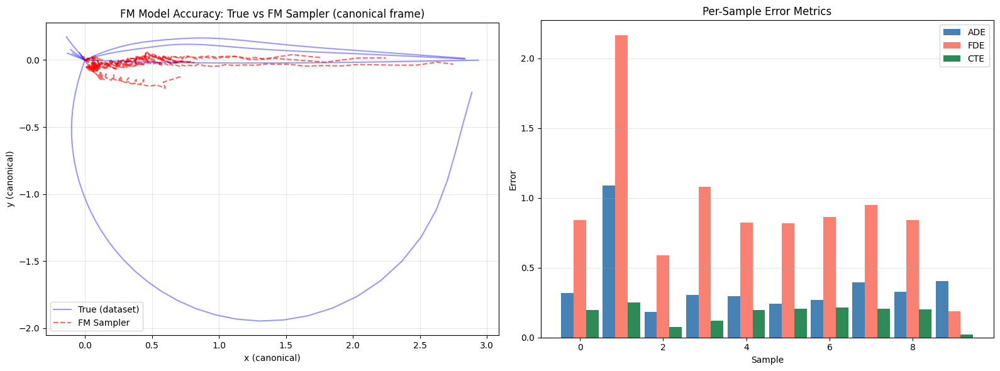


FM Model Validation (10 samples)
  ADE (Average Displacement Error): 0.3823 +/- 0.2436
  FDE (Final Displacement Error):   0.9163 +/- 0.4745
  CTE (Cross-Track Error):          0.1693 +/- 0.0691

  Result: FM model has significant deviation (ADE > 0.15), check model/training


In [16]:
# ===============================================================
# FM Model Validation: True Canonical Trajectory vs FM Sampler Output
# 使用 piecewise_sample_fm_5ch_with_cbf (sampler_5h.py) 生成轨迹
#Q：给定相同的初始条件，FM 模型能不能生成和真实数据类似的轨迹？
# ===============================================================

import matplotlib.pyplot as plt

model_5ch.eval()
torch.set_grad_enabled(False)

N_CHECK = 10
FM_NOISE_SCALE = 0.08   # 和 MPC 部署时一致
FM_NUM_SEG     = 10
FM_ODE_METHOD  = "euler"

rng = np.random.default_rng(42)
selected_idx = rng.choice(len(traj_5ch), size=N_CHECK, replace=False)

# ---------------------------------------------------------------
# FM 模型精度: FM canonical path vs true canonical path
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1, ax2 = axes

ade_list = []   # Average Displacement Error
fde_list = []   # Final Displacement Error
cte_list = []   # Cross-Track Error

for i, idx in enumerate(selected_idx):
    traj_true = traj_5ch[idx]  # (5, T)
    goal_xy = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj_true, goal_xy=goal_xy)
    T_len = traj_can.shape[1]

    # --- FM 采样 (CBF off, 纯模型能力测试) ---
    x0_noise = torch.randn((1, 5, T_len), device=device) * FM_NOISE_SCALE
    x0_noise[:, :, 0] = 0.0   # lock start

    x_fm, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch    = model_5ch,
        T_steps      = T_len,
        device       = str(device),
        cond         = cond,
        use_cbf      = False,          # 纯 FM, 不加 CBF
        noise_scale  = FM_NOISE_SCALE,
        x0_noise     = x0_noise,
        lock_start   = True,
        start_xy_norm = np.array([0.0, 0.0], dtype=np.float32),
        goal_xy_norm  = np.array([cond[0], 0.0], dtype=np.float32),
        start_guidance_weight = 0.45,
        goal_guidance_weight  = 0.90,
        goal_guidance_mode    = "tail",
        num_segments = FM_NUM_SEG,
        ode_method   = FM_ODE_METHOD,
    )  # x_fm: (5, T)

    # --- 计算指标 ---
    true_xy = traj_can[0:2, :].T   # (T, 2)
    fm_xy   = x_fm[0:2, :].T       # (T, 2)

    pos_err = np.linalg.norm(fm_xy - true_xy, axis=1)  # (T,)
    ade = float(np.mean(pos_err))
    fde = float(pos_err[-1])
    # cross-track: 每个 FM 点到 true 路径最近点的距离
    cte_vals = []
    for j in range(len(fm_xy)):
        dists = np.linalg.norm(true_xy - fm_xy[j], axis=1)
        cte_vals.append(float(np.min(dists)))
    cte = float(np.mean(cte_vals))

    ade_list.append(ade)
    fde_list.append(fde)
    cte_list.append(cte)

    # --- 绘图 ---
    ax1.plot(traj_can[0], traj_can[1], 'b-', alpha=0.4,
             label="True (dataset)" if i == 0 else "")
    ax1.plot(x_fm[0], x_fm[1], 'r--', alpha=0.6,
             label="FM Sampler" if i == 0 else "")

ax1.set_title("FM Model Accuracy: True vs FM Sampler (canonical frame)")
ax1.set_xlabel("x (canonical)")
ax1.set_ylabel("y (canonical)")
ax1.legend()
ax1.set_aspect("equal")
ax1.grid(alpha=0.3)

# --- 误差柱状图 ---
x_pos = np.arange(N_CHECK)
width = 0.3
ax2.bar(x_pos - width, ade_list, width, label='ADE', color='steelblue')
ax2.bar(x_pos,         fde_list, width, label='FDE', color='salmon')
ax2.bar(x_pos + width, cte_list, width, label='CTE', color='seagreen')
ax2.set_xlabel("Sample")
ax2.set_ylabel("Error")
ax2.set_title("Per-Sample Error Metrics")
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- 汇总 ---
print(f"\n{'='*60}")
print(f"FM Model Validation ({N_CHECK} samples)")
print(f"{'='*60}")
print(f"  ADE (Average Displacement Error): {np.mean(ade_list):.4f} +/- {np.std(ade_list):.4f}")
print(f"  FDE (Final Displacement Error):   {np.mean(fde_list):.4f} +/- {np.std(fde_list):.4f}")
print(f"  CTE (Cross-Track Error):          {np.mean(cte_list):.4f} +/- {np.std(cte_list):.4f}")

mean_ade = np.mean(ade_list)
if mean_ade < 0.05:
    print("\n  Result: FM model accuracy is very good (ADE < 0.05)")
elif mean_ade < 0.15:
    print("\n  Result: FM model accuracy is acceptable (0.05 < ADE < 0.15)")
else:
    print("\n  Result: FM model has significant deviation (ADE > 0.15), check model/training")


[device] cuda
[Data] N=100, T=60, D=5
[Data] ctrl_2ch: (100, 2, 60), cond: (100, 6)
[Cond] dx_can mean=3.000 std=0.000
[Cond] dy_can mean=0.000 std=0.000  (should be ≈0)

[Norm] ctrl_mean = [-0.07357636  0.05364437]
[Norm] ctrl_std  = [0.54194385 0.64408153]
[Norm] cond_mean = [3.        0.        0.3754593 0.        0.        0.       ]
[Norm] cond_scale= [1.0000000e-06 1.0000000e-06 1.3071911e-01 1.0000000e+00 1.0000000e+00
 1.0000000e-06]

[Augmentation]
[Augmented] X1: (2200, 2, 60), cond: (2200, 6)
[Split] Train: 1760, Val: 440
[Model] Parameters: 730,690
[Model] Data/Param ratio: 0.0024

SafeFM Training: 2ch ctrl, 6dim cond, noise+mirror aug
Epochs=3000, LR=3e-4, Patience=300

  Epoch    1 | train=1.2301 | val=1.0402 | gap=-0.1899 ★ best
  Epoch   50 | train=0.2919 | val=0.3027 | gap=0.0108 ★ best
  Epoch  100 | train=0.1827 | val=0.2186 | gap=0.0359 ★ best
  Epoch  150 | train=0.1351 | val=0.1573 | gap=0.0222 ★ best
  Epoch  200 | train=0.1159 | val=0.1256 | gap=0.0096 ★ best
  

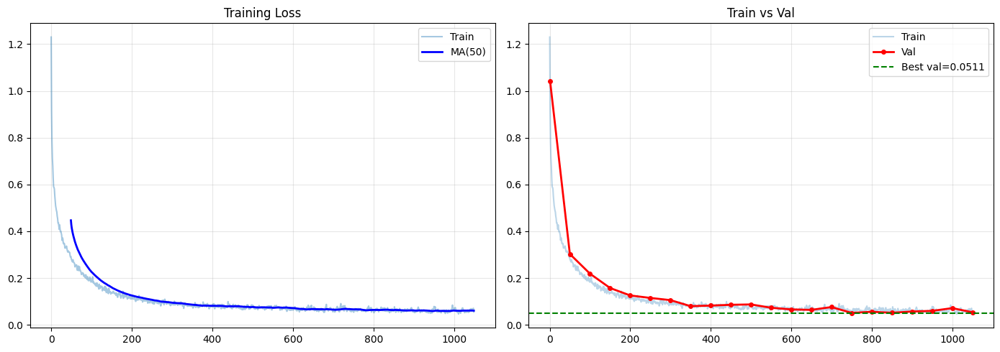

In [1]:
# ===============================================================
# 训练 SafeFM: 只预测 2维控制量 [a, delta_rate]
# cond 升级为 6维: [dx_can, dy_can, v0, cos(th0_can), sin(th0_can), delta0]
# 有 augmentation + validation + early stopping
# ===============================================================

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path
import matplotlib.pyplot as plt
import sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

torch.set_grad_enabled(True)

fmtorch_root = Path.cwd().parent.resolve()
if str(fmtorch_root) not in sys.path:
    sys.path.insert(0, str(fmtorch_root))

# ---------------------------------------------------------------
# 1) 加载数据
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# ---------------------------------------------------------------
# 2) 构建控制量 + cond
# ---------------------------------------------------------------
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

ctrl_2ch = np.stack([
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1).astype(np.float32)  # (N, 2, T)


def canonicalize_batch_cond_only(trajs, states_raw, goals_xy=None):
    """
    6维 cond: [dx_can, dy_can, v0, cos(th0_can), sin(th0_can), delta0]

    dx_can, dy_can: goal 在 canonical frame 里的相对坐标
      - canonical frame: 以 start 为原点，goal 方向为 +x 轴
      - 理论上 dy_can ≈ 0，但保留让模型学习残差，比强制截断更鲁棒
      - dist = sqrt(dx_can² + dy_can²) 隐含在向量里，不再单独编码
    """
    N2 = trajs.shape[0]
    cond_list = []
    for i in range(N2):
        x0, y0 = float(trajs[i, 0, 0]), float(trajs[i, 1, 0])
        th0     = float(trajs[i, 2, 0])

        if goals_xy is not None:
            gx, gy = float(goals_xy[i, 0]), float(goals_xy[i, 1])
        else:
            gx, gy = float(trajs[i, 0, -1]), float(trajs[i, 1, -1])

        # world frame 里的 goal offset
        dx_w = gx - x0
        dy_w = gy - y0

        # canonical frame 旋转角：让 goal 对齐 +x 轴
        angle_off = float(np.arctan2(dy_w, dx_w))

        # goal 在 canonical frame 里的坐标
        cos_a  =  np.cos(angle_off)
        sin_a  =  np.sin(angle_off)
        dx_can =  cos_a * dx_w + sin_a * dy_w   # ≈ dist (正值)
        dy_can = -sin_a * dx_w + cos_a * dy_w   # ≈ 0，保留残差信息

        # 初始朝向在 canonical frame 里
        th0_can = float((th0 - angle_off + np.pi) % (2 * np.pi) - np.pi)

        cond_list.append([
            dx_can,                           # goal x (canonical) ≈ dist
            dy_can,                           # goal y (canonical) ≈ 0
            float(states_raw[i, 0, 3]),       # v0
            float(np.cos(th0_can)),           # cos(初始朝向)
            float(np.sin(th0_can)),           # sin(初始朝向)
            float(states_raw[i, 0, 4]),       # delta0
        ])
    return np.array(cond_list, dtype=np.float32)  # (N, 6)


cond_all = canonicalize_batch_cond_only(traj_5ch, states, goals)
print(f"[Data] ctrl_2ch: {ctrl_2ch.shape}, cond: {cond_all.shape}")
print(f"[Cond] dx_can mean={cond_all[:,0].mean():.3f} std={cond_all[:,0].std():.3f}")
print(f"[Cond] dy_can mean={cond_all[:,1].mean():.3f} std={cond_all[:,1].std():.3f}  (should be ≈0)")

# ---------------------------------------------------------------
# 3) 归一化 (6维)
# ---------------------------------------------------------------
ctrl_mean = ctrl_2ch.mean(axis=(0, 2), keepdims=True)
ctrl_std  = ctrl_2ch.std(axis=(0, 2),  keepdims=True).clip(min=1e-6)
ctrl_2ch_norm = (ctrl_2ch - ctrl_mean) / ctrl_std

cond_norm = cond_all.copy()

cond_mean_arr = np.array([
    cond_all[:, 0].mean(),   # dx_can
    cond_all[:, 1].mean(),   # dy_can (≈ 0)
    cond_all[:, 2].mean(),   # v0
    0.0,                     # cos — 不偏移
    0.0,                     # sin — 不偏移
    cond_all[:, 5].mean(),   # delta0
], dtype=np.float32)

cond_scale = np.array([
    cond_all[:, 0].std() + 1e-6,   # dx_can
    cond_all[:, 1].std() + 1e-6,   # dy_can
    cond_all[:, 2].std() + 1e-6,   # v0
    1.0,                            # cos
    1.0,                            # sin
    cond_all[:, 5].std() + 1e-6,   # delta0
], dtype=np.float32)

# dy_can 的 std 可能极小 → 归一化后方差爆炸，clip 保护
cond_scale[1] = max(float(cond_scale[1]), float(cond_scale[0]) * 0.1)

for i in [0, 1, 2, 5]:
    cond_norm[:, i] = (cond_all[:, i] - cond_mean_arr[i]) / cond_scale[i]
# cos/sin (index 3, 4) 保持原样，范围已在 [-1, 1]

norm_params = {
    "ctrl_mean":  ctrl_mean,
    "ctrl_std":   ctrl_std,
    "cond_mean":  cond_mean_arr,
    "cond_scale": cond_scale,
}
np.save("cache/safefm_norm_params.npy", norm_params)

print(f"\n[Norm] ctrl_mean = {ctrl_mean.squeeze()}")
print(f"[Norm] ctrl_std  = {ctrl_std.squeeze()}")
print(f"[Norm] cond_mean = {cond_mean_arr}")
print(f"[Norm] cond_scale= {cond_scale}")

# ---------------------------------------------------------------
# 4) 数据增强
# ---------------------------------------------------------------
def augment_data_2ch(X1, cond_all, aug_factor=15):
    """
    物理一致的增强：
    - 噪声：微扰 control 和 cond，保持 cond-control 关系
    - 镜像：Y轴翻转，同步取反 delta_rate / dy_can / sin(th0_can) / delta0
    """
    N2, C, T2 = X1.shape
    aug_X    = [X1]
    aug_cond = [cond_all]
    np.random.seed(42)

    for i in range(aug_factor - 1):
        # --- 噪声增强 ---
        noise_X = X1.copy()
        noise_X[:, 0, :] += np.random.randn(N2, T2) * 0.02   # a 噪声
        noise_X[:, 1, :] += np.random.randn(N2, T2) * 0.03   # delta_rate 噪声

        noise_cond = cond_all.copy()
        noise_cond[:, 0] += np.random.randn(N2) * 0.02        # dx_can
        noise_cond[:, 2] += np.random.randn(N2) * 0.02        # v0

        aug_X.append(noise_X)
        aug_cond.append(noise_cond)

        # --- 镜像增强（Y轴翻转，每隔一次）---
        # 控制量：delta_rate 取反
        # cond：dy_can 取反，sin(th0_can) 取反，delta0 取反
        # dx_can, v0, cos(th0_can) 不变（镜像不影响距离、速度、cos）
        if i % 2 == 0:
            mirror_X = X1.copy()
            mirror_X[:, 1, :] *= -1    # delta_rate 取反

            mirror_cond = cond_all.copy()
            mirror_cond[:, 1] *= -1    # dy_can 取反      ← 新增
            mirror_cond[:, 4] *= -1    # sin(th0_can) 取反
            mirror_cond[:, 5] *= -1    # delta0 取反

            aug_X.append(mirror_X)
            aug_cond.append(mirror_cond)

    return (np.concatenate(aug_X,    axis=0).astype(np.float32),
            np.concatenate(aug_cond, axis=0).astype(np.float32))


print("\n[Augmentation]")
X1_aug, cond_aug = augment_data_2ch(ctrl_2ch_norm, cond_norm, aug_factor=15)
print(f"[Augmented] X1: {X1_aug.shape}, cond: {cond_aug.shape}")

# ---------------------------------------------------------------
# 5) Train/Val Split
# ---------------------------------------------------------------
X1_t   = torch.tensor(X1_aug,   dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_aug, dtype=torch.float32, device=device)

full_ds    = TensorDataset(X1_t, cond_t)
train_size = int(0.8 * len(full_ds))
val_size   = len(full_ds) - train_size
train_ds, val_ds = random_split(
    full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, drop_last=False)
print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 6) 模型 (cond_dim: 5 → 6)
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_safefm_2ch.pt")

model_safefm = SimpleUNet1D(
    time_emb_dim = 64,
    hidden_dim   = 64,
    cond_dim     = 6,    # ← 5 → 6: 新增 dy_can
    in_channels  = 2,
    out_channels = 2,
).to(device)

n_params = sum(p.numel() for p in model_safefm.parameters())
print(f"[Model] Parameters: {n_params:,}")
print(f"[Model] Data/Param ratio: {len(train_ds)/n_params:.4f}")

optimizer = torch.optim.AdamW(
    model_safefm.parameters(), lr=3e-4, weight_decay=5e-4
)

# ---------------------------------------------------------------
# 7) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total, n = 0.0, 0
    for x_1, cond_b in val_dl:
        B     = x_1.shape[0]
        x_0   = torch.randn_like(x_1)
        t     = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        x_t      = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred   = model(x_t, t, cond=cond_b)
        total   += F.mse_loss(v_pred, v_target).item()
        n       += 1
    model.train()
    return total / max(n, 1)

# ---------------------------------------------------------------
# 8) Training loop
# ---------------------------------------------------------------
EPOCHS      = 3000
VAL_EVERY   = 50
PATIENCE    = 300
INPUT_NOISE = 0.01

best_val_loss    = float('inf')
no_improve_count = 0
train_history    = []
val_history      = []
global_step      = 0

print(f"\n{'='*60}")
print(f"SafeFM Training: 2ch ctrl, 6dim cond, noise+mirror aug")
print(f"Epochs={EPOCHS}, LR=3e-4, Patience={PATIENCE}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    model_safefm.train()
    epoch_loss, n_batch = 0.0, 0

    for x_1, cond_b in train_dl:
        B         = x_1.shape[0]
        x_1_noisy = x_1 + torch.randn_like(x_1) * INPUT_NOISE
        x_0       = torch.randn_like(x_1)
        t         = torch.rand(B, device=device)
        t_exp     = t.view(B, 1, 1)

        x_t      = (1 - t_exp) * x_0 + t_exp * x_1_noisy
        v_target = x_1_noisy - x_0
        v_pred   = model_safefm(x_t, t, cond=cond_b)
        loss     = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_safefm.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch    += 1

    avg_train = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train)
    global_step += 1

    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_safefm, val_dl)
        val_history.append((epoch, val_loss))
        gap = val_loss - avg_train

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict':     model_safefm.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step':          global_step,
                'best_val_loss':        best_val_loss,
                'train_history':        train_history,
                'val_history':          val_history,
                'norm_params':          norm_params,
                'cond_dim':             6,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train:.4f} | "
                  f"val={val_loss:.4f} | gap={gap:.4f} ★ best")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train:.4f} | "
                  f"val={val_loss:.4f} | gap={gap:.4f}")

        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] no improvement for {PATIENCE} epochs")
            break

    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train:.4f}")

print(f"\nDone! Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 9) 加载最佳模型
# ---------------------------------------------------------------
ckpt = torch.load(str(ckpt_path), map_location=device, weights_only=False)
model_safefm.load_state_dict(ckpt['model_state_dict'])
model_safefm.eval()
norm_params = ckpt['norm_params']
print(f"[Load Best] best_val_loss={ckpt['best_val_loss']:.6f}")

# ---------------------------------------------------------------
# 10) 训练曲线
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_history, alpha=0.4, label='Train')
if len(train_history) > 50:
    w  = 50
    sm = np.convolve(np.array(train_history), np.ones(w)/w, mode='valid')
    axes[0].plot(range(w-1, len(train_history)), sm, 'b-', lw=2, label=f'MA({w})')
axes[0].set_title('Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

val_ep  = [v[0] for v in val_history]
val_los = [v[1] for v in val_history]
axes[1].plot(train_history, alpha=0.3, label='Train')
axes[1].plot(val_ep, val_los, 'ro-', lw=2, markersize=4, label='Val')
axes[1].axhline(best_val_loss, color='g', ls='--',
                label=f'Best val={best_val_loss:.4f}')
axes[1].set_title('Train vs Val')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# FM Validation — noise → piecewise_sample_fm_5ch_with_cbf → pred vs GT
#
# 数据集里的 canonical ground truth
# 你训练时想拟合的目标分布
#
#FM 生成得像不像训练数据。
#生成模型层 (generative model fidelity)

# pred_can vs traj_can 
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf（来自 sampler_5h.py）
#   - build_canonical_frame（两车实验 Section 4）
#   - make_x0_noise（两车实验 Section 7）
#   - T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
assert 'build_canonical_frame'            in dir(), "请先运行两车实验 cell"
assert 'make_x0_noise'                    in dir(), "请先运行两车实验 cell"
assert 'piecewise_sample_fm_5ch_with_cbf' in dir(), "请先运行两车实验 cell"
assert 'T_steps'                          in dir(), "请先运行两车实验 cell"
print("[依赖检查] ✓")


# ================================================================
# 0) 加载数据
# ================================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(
        r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache"
        r"\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
    )

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']  # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}  T={T}  D={D}")
print(f"[Params] T_steps={T_steps}  num_segments={num_segments}  "
      f"total_time={total_time}  ode_method={ode_method}")
if T_steps != T:
    print(f"[注意] T_steps({T_steps}) != 数据T({T})，pred 会插值对齐")

# 构建 5-channel（channel 定义与训练完全一致）
# ch0=x, ch1=y, ch2=theta, ch3=a, ch4=delta_rate
traj_5ch = np.stack([
    states[:, :, 0],    # x
    states[:, :, 1],    # y
    states[:, :, 2],    # theta
    controls[:, :, 0],  # a
    controls[:, :, 1],  # delta_rate
], axis=1).astype(np.float32)  # (N, 5, T)


# ================================================================
# 1) canonical frame 转换
#
# ★ cond 修复：
#   v0     来自 states[idx, 0, 3]  （速度，不是加速度）
#   delta0 来自 states[idx, 0, 4]  （转向角，不是转向角速度）
#   不能从 traj_5ch[idx, 3, 0] / traj_5ch[idx, 4, 0] 取，
#   因为那两个是 a0 和 delta_rate0
# ================================================================
def canonicalize_single(traj_i, states_i, goal_xy=None):
    """
    traj_i:   (5, T)  [x, y, theta, a, delta_rate]
    states_i: (T, 5)  [x, y, theta, v, delta]  ← 用于取 v0, delta0
    goal_xy:  (2,) or None

    返回:
      traj_can : (5, T)  canonical frame 轨迹
      cond     : (5,)    [dist, v0, cos(th0_can), sin(th0_can), delta0]
      tf       : 变换字典
    """
    x0 = float(traj_i[0, 0]);  y0 = float(traj_i[1, 0])
    gx = float(goal_xy[0]) if goal_xy is not None else float(traj_i[0, -1])
    gy = float(goal_xy[1]) if goal_xy is not None else float(traj_i[1, -1])

    # ★ 直接调用前面已定义的 build_canonical_frame
    tf = build_canonical_frame(
        np.array([x0, y0], np.float32),
        np.array([gx, gy], np.float32)
    )

    out    = traj_i.copy()
    xy_can = tf["w2c"](traj_i[0:2, :].T)  # (T, 2)
    out[0] = xy_can[:, 0]
    out[1] = xy_can[:, 1]
    out[2] = np.array([tf["w2c_angle"](float(th)) for th in traj_i[2]])

    th0_can = tf["w2c_angle"](float(traj_i[2, 0]))

    # ★ 修复：v0 和 delta0 从 states_i 取，而不是从 traj_i[3,0]/traj_i[4,0]
    v0     = float(states_i[0, 3])  # states 第3列 = v（速度）
    delta0 = float(states_i[0, 4])  # states 第4列 = delta（转向角）

    cond = np.array([
        tf["dist"],
        v0,
        float(np.cos(th0_can)),
        float(np.sin(th0_can)),
        delta0,
    ], dtype=np.float32)

    return out, cond, tf


# ================================================================
# 2) FM 预测：直接调用 piecewise_sample_fm_5ch_with_cbf
#    use_cbf=False，参数与两车实验完全一致
# ================================================================
def fm_predict_full(cond, tf, seed=0):
    """
    noise → piecewise_sample_fm_5ch_with_cbf(use_cbf=False) → pred (5, T)
    参数与两车实验 mpc_replan 里的调用完全一致。
    """
    # ★ 直接调用前面已定义的 make_x0_noise
    x0_noise = make_x0_noise(T_steps, seed)

    # ★ 直接调用前面已加载的 piecewise_sample_fm_5ch_with_cbf
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )  # x_can: (5, T_steps)

    # 插值对齐到数据长度 T
    if x_can.shape[1] != T:
        t_old  = np.linspace(0.0, 1.0, x_can.shape[1])
        t_new  = np.linspace(0.0, 1.0, T)
        x_can  = np.stack([
            interp1d(t_old, x_can[ch], kind='linear')(t_new)
            for ch in range(5)
        ], axis=0).astype(np.float32)

    return x_can  # (5, T)


# ================================================================
# 3) 指标
# ================================================================
def compute_metrics(pred_can, traj_can):
    pred_xy  = pred_can[0:2, :].T          # (T, 2)
    true_xy  = traj_can[0:2, :].T
    per_step = np.linalg.norm(pred_xy - true_xy, axis=1)  # (T,)

    ade = float(per_step.mean())
    fde = float(np.linalg.norm(pred_xy[-1] - true_xy[-1]))

    hdg_diff = (pred_can[2] - traj_can[2] + np.pi) % (2 * np.pi) - np.pi
    hdg      = float(np.mean(np.abs(hdg_diff)))

    return ade, fde, hdg, per_step


# ================================================================
# 4) 主验证循环
# ================================================================
N_SAMPLES = 50
np.random.seed(42)

ades, fdes, hdgs = [], [], []
all_per_step     = []

print(f"\n验证中... (N={N_SAMPLES} samples)")

for i in range(N_SAMPLES):
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]          # (5, T)
    states_i = states[idx]            # (T, 5)  ← 传给 canonicalize_single
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=i)

    ade, fde, hdg, per_step = compute_metrics(pred_can, traj_can)

    ades.append(ade);  fdes.append(fde)
    hdgs.append(hdg);  all_per_step.append(per_step)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{N_SAMPLES}]  "
              f"ADE={np.mean(ades):.4f}  "
              f"FDE={np.mean(fdes):.4f}  "
              f"HDG={np.rad2deg(np.mean(hdgs)):.2f}°")


# ================================================================
# 5) 结果打印
# ================================================================
print(f"\n{'='*50}")
print(f"  ADE  : {np.mean(ades):.4f}  ±{np.std(ades):.4f}")
print(f"  FDE  : {np.mean(fdes):.4f}  ±{np.std(fdes):.4f}")
print(f"  HDG  : {np.rad2deg(np.mean(hdgs)):.2f}°  "
      f"±{np.rad2deg(np.std(hdgs)):.2f}°")
print(f"{'='*50}")
print()
print("判断标准（canonical frame）：")
print("  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题")
print("  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题")
print("  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题")


# ================================================================
# 6) 图1：8 条代表性轨迹对比
# ================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
np.random.seed(0)

for pi in range(8):
    ax       = axes[pi]
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]
    states_i = states[idx]
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=pi * 13)
    a, f, h, _         = compute_metrics(pred_can, traj_can)

    ax.plot(traj_can[0], traj_can[1],
            'b-',  lw=2.0, alpha=0.8, label="GT")
    ax.plot(pred_can[0], pred_can[1],
            'r--', lw=1.8, alpha=0.8, label="Pred")
    ax.scatter([0], [0],
               c='green', s=60, zorder=6, label="Start(0,0)")
    ax.scatter([traj_can[0, -1]], [traj_can[1, -1]],
               c='blue', s=100, marker='*', zorder=6, label="GT end")
    ax.scatter([pred_can[0, -1]], [pred_can[1, -1]],
               c='red',  s=100, marker='*', zorder=6, label="Pred end")

    ax.set_title(
        f"ADE={a:.3f}  FDE={f:.3f}  HDG={np.rad2deg(h):.1f}°",
        fontsize=9
    )
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")
    if pi == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    f"FM: noise → pred vs GT  "
    f"(N={N_SAMPLES}, T_steps={T_steps}, data_T={T})",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 7) 图2：逐步误差曲线
# ================================================================
mean_curve = np.mean(all_per_step, axis=0)
std_curve  = np.std(all_per_step,  axis=0)
t_axis     = np.linspace(0.0, 1.0, T)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_axis, mean_curve, lw=2.5, color='steelblue', label="Mean L2")
ax.fill_between(t_axis,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.2, color='steelblue', label="±1 std")
ax.set_xlabel("Trajectory position  (0=start → 1=end)")
ax.set_ylabel("Per-step L2 error (canonical frame)")
ax.set_title(f"Per-step prediction error curve  (N={N_SAMPLES} samples)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'model_5ch' is not defined

In [9]:
# ===============================================================
# Tracking Fidelity: FM Prediction vs Pure Pursuit Bicycle Rollout
# FM 采样路径 → Pure Pursuit 生成控制 → Bicycle 动力学执行
# 比较: FM 规划的 XY 路径  vs  实际 bicycle rollout 的 XY 轨迹
# ===============================================================
# ★ 依赖: 需要先运行 Cell 10 (FM-MPC Bicycle simulation cell)
#   → 使用其中的: build_canonical_frame, wrap_pi, bicycle_step,
#     rollout_bicycle, pure_pursuit_controls, make_x0_noise,
#     piecewise_sample_fm_5ch_with_cbf, 以及所有参数定义
# ★ 不重新定义任何函数，直接复用 simulation cell 的函数和 sampler_5h.py

import numpy as np, torch, math, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
model_5ch.eval()
print(f"[device] {device}")

# ---------------------------------------------------------------
# 验证依赖是否已加载
# ---------------------------------------------------------------
for _fn_name in ["build_canonical_frame", "wrap_pi", "bicycle_step",
                  "rollout_bicycle", "pure_pursuit_controls",
                  "piecewise_sample_fm_5ch_with_cbf", "make_x0_noise"]:
    assert _fn_name in dir() or _fn_name in globals(), \
        f"Missing '{_fn_name}' — 请先运行 Cell 10 (FM-MPC Bicycle simulation)"

# 复用 simulation cell 的参数
print(f"[params] dt_exec={dt_exec}, T_steps={T_steps}, H={H}")
print(f"[params] v_max_A={v_max_A}, L={L}, noise_scale={noise_scale}")

# ---------------------------------------------------------------
# FM path generation — 复用 simulation cell 的 sample_fm_path 逻辑
# 唯一区别: use_cbf=False (单 agent 验证，无障碍物)
# ---------------------------------------------------------------
def _gen_fm_path_for_validation(s0, goal_xy, seed=42):
    """和 sample_fm_path 完全相同的 canonical frame + sampler 调用，
    只是 use_cbf=False（无其他 agent）"""
    self_xy = s0[:2]
    tf = build_canonical_frame(self_xy, goal_xy)         # ★ 复用 simulation cell
    x0_noise = make_x0_noise(T_steps, seed)              # ★ 复用 simulation cell
    v0     = float(s0[3])
    th_can = tf["w2c_angle"](float(s0[2]))
    delta0 = float(s0[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can),
                         np.sin(th_can), delta0], dtype=np.float32)
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45, goal_guidance_weight=0.90,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=False, scaler=None, ellipses=[],  # 单 agent, 无 CBF
    )
    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy  # (T, 2)

# ===============================================================
# Test scenarios — dataset (real heading) + synthetic (forced curves)
# ===============================================================
N_TEST = 10
rng = np.random.default_rng(2024)

scenarios = []

# (A) Dataset samples — 用真实初始朝向（通常不指向 goal → 产生曲线）
for _ in range(4):
    idx = rng.integers(0, N)
    sxy = states[idx, 0, :2].astype(np.float32)
    gxy = (goals[idx] if goals is not None else states[idx, -1, :2]).astype(np.float32)
    th0 = float(states[idx, 0, 2])          # ★ 真实朝向，不强制对准 goal
    v0  = max(float(states[idx, 0, 3]), 0.3)
    d0  = float(states[idx, 0, 4])
    scenarios.append((np.array([sxy[0], sxy[1], th0, v0, d0], np.float32), gxy, f"data#{idx}"))

# (B) 45-degree cross (MPC 部署场景)
scenarios.append((
    np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], np.float32),
    np.array([1.2, 1.2], np.float32), "cross-45"))

# (C) Heading offset 90° — goal在右前方，但车头朝上 → 必须右转
scenarios.append((
    np.array([0.0, 0.0, np.pi/2, 0.6, 0.0], np.float32),
    np.array([2.0, 0.5], np.float32), "turn-R-90"))

# (D) Heading offset -90° — goal在左前方，但车头朝下 → 必须左转
scenarios.append((
    np.array([0.0, 0.0, -np.pi/2, 0.6, 0.0], np.float32),
    np.array([-2.0, 0.5], np.float32), "turn-L-90"))

# (E) U-turn — 车头背对 goal → 大幅转弯
scenarios.append((
    np.array([0.0, 0.0, np.pi, 0.4, 0.0], np.float32),
    np.array([2.5, 0.0], np.float32), "u-turn"))

# (F) 带初始转向角 — 车已在转弯中, delta = 20deg
scenarios.append((
    np.array([0.0, 0.0, np.pi/6, 0.7, np.deg2rad(20.0)], np.float32),
    np.array([2.0, 1.5], np.float32), "steer-20"))

# (G) 斜向接近 — 30度偏差
scenarios.append((
    np.array([-1.0, -0.5, 0.0, 0.5, 0.0], np.float32),
    np.array([1.5, 1.0], np.float32), "oblique-30"))

N_TEST = len(scenarios)
print(f"[scenarios] {N_TEST} total: {[s[2] for s in scenarios]}")

# ===============================================================
# Run validation
# ===============================================================
H_rollout = T_steps  # rollout horizon = FM path length (复用 simulation cell 参数)

ncols = 5; nrows = (N_TEST + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes_flat = axes.flatten()

t_ade, t_fde, t_cte = [], [], []
goal_errs = []

for i, (s0, gxy, tag) in enumerate(scenarios):
    # 1) FM planned path — 复用 sample_fm_path 的逻辑 (use_cbf=False)
    fm_path = _gen_fm_path_for_validation(s0, gxy, seed=5000 + i * 137)

    # 2) Pure pursuit → bicycle rollout — ★ 复用 simulation cell 的函数
    U = pure_pursuit_controls(s0, fm_path, gxy, H=H_rollout,
                              dt=dt_exec, v_max=v_max_A)
    ro_xy, ro_st = rollout_bicycle(s0, U, dt=dt_exec, v_max=v_max_A)

    # 3) Metrics
    Lm = min(len(fm_path), len(ro_xy))
    fm_xy = fm_path[:Lm]; rx = ro_xy[:Lm]
    perr = np.linalg.norm(fm_xy - rx, axis=1)
    ade  = float(np.mean(perr))
    fde  = float(perr[-1])
    # Cross-track: each rollout point → nearest FM path point
    ct = [float(np.min(np.linalg.norm(fm_xy - rx[j], axis=1))) for j in range(len(rx))]
    cte = float(np.mean(ct))
    # Goal error: rollout final point → goal
    ge = float(np.linalg.norm(ro_xy[-1] - gxy))

    t_ade.append(ade); t_fde.append(fde); t_cte.append(cte); goal_errs.append(ge)

    # 4) Plot
    ax = axes_flat[i]
    ax.plot(fm_path[:, 0], fm_path[:, 1], 'r--', lw=2, alpha=0.8, label='FM Plan')
    ax.plot(ro_xy[:, 0],   ro_xy[:, 1],   'b-',  lw=2, alpha=0.7, label='Bicycle Rollout')
    ax.scatter([s0[0]], [s0[1]], c='green', s=80, marker='o', zorder=5)
    ax.scatter([gxy[0]], [gxy[1]], c='red', s=120, marker='*', zorder=5)
    ax.set_title(f'{tag}\nADE={ade:.3f}  CTE={cte:.3f}  goal_err={ge:.3f}', fontsize=8)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=7)

for k in range(N_TEST, len(axes_flat)):
    axes_flat[k].set_visible(False)
plt.suptitle('Tracking Fidelity: FM Prediction vs Bicycle Pure-Pursuit Rollout', fontsize=13)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Error bar chart
# ---------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 4))
x_pos = np.arange(N_TEST)
w = 0.22
ax2.bar(x_pos - w, t_ade,     w, label='ADE (plan↔rollout)', color='steelblue')
ax2.bar(x_pos,     t_cte,     w, label='CTE (cross-track)',   color='seagreen')
ax2.bar(x_pos + w, goal_errs, w, label='Goal Error (rollout→goal)', color='salmon')
labels = [s[2] for s in scenarios]
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels, fontsize=7, rotation=30)
ax2.set_ylabel('Error'); ax2.set_title('Per-Scenario Error Metrics')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# Summary
# ---------------------------------------------------------------
print(f"\n{'='*65}")
print(f"Tracking Fidelity Validation ({N_TEST} scenarios)")
print(f"{'='*65}")
print(f"  ADE (FM plan ↔ rollout):   {np.mean(t_ade):.4f} ± {np.std(t_ade):.4f}")
print(f"  FDE (final point):         {np.mean(t_fde):.4f} ± {np.std(t_fde):.4f}")
print(f"  CTE (cross-track):         {np.mean(t_cte):.4f} ± {np.std(t_cte):.4f}")
print(f"  Goal Error (rollout→goal): {np.mean(goal_errs):.4f} ± {np.std(goal_errs):.4f}")

mcte = np.mean(t_cte)
mge  = np.mean(goal_errs)
print(f"\n  Tracking quality:  ", end="")
if mcte < 0.05:
    print("✅ Excellent — bicycle closely tracks FM plan (CTE < 0.05)")
elif mcte < 0.15:
    print("⚠️  Acceptable — moderate tracking gap (0.05 < CTE < 0.15)")
else:
    print("❌ Poor tracking — CTE > 0.15, pure pursuit or FM paths need tuning")

print(f"  Goal convergence: ", end="")
if mge < 0.20:
    print("✅ Good — rollout reaches near goal (err < 0.20)")
elif mge < 0.50:
    print("⚠️  Marginal — rollout stops short (0.20 < err < 0.50)")
else:
    print("❌ Poor — rollout far from goal (err > 0.50), check speed/braking")

# Per-scenario detail
print(f"\n  {'Scenario':<12s} {'ADE':>6s} {'CTE':>6s} {'FDE':>6s} {'GoalErr':>8s}")
print(f"  {'-'*40}")
for i, (_, _, tag) in enumerate(scenarios):
    print(f"  {tag:<12s} {t_ade[i]:6.3f} {t_cte[i]:6.3f} {t_fde[i]:6.3f} {goal_errs[i]:8.3f}")


NameError: name 'model_5ch' is not defined

In [ ]:
# ===============================================================
# Tracking Fidelity: FM Prediction vs Pure Pursuit Bicycle Rollout
# FM 采样路径 → Pure Pursuit 生成控制 → Bicycle 动力学执行
# 比较: FM 规划的 XY 路径  vs  实际 bicycle rollout 的 XY 轨迹
# ===============================================================
# 需要先运行: Cell 0-4 (数据/模型/sampler 加载)

import numpy as np, torch, math, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
model_5ch.eval()
print(f"[device] {device}")

# ---------------------------------------------------------------
# Parameters (与 MPC 部署一致)
# ---------------------------------------------------------------
dt_val       = 0.10
T_steps_val  = 40       # FM 输出时间步
noise_scale_val = 0.08
num_seg_val  = 10
ode_method_val = "euler"
total_time_val = 1.0

# Bicycle dynamics
v_max_val      = 1.0
v_min_val      = 0.0
a_max_val      = 1.5
L_val          = 0.30
delta_max_val  = np.deg2rad(35.0)
drate_max_val  = np.deg2rad(90.0)
v_floor_val    = 0.05

# Pure pursuit
APPROACH_DIST = 0.60
ARRIVAL_DIST  = 0.15
creep_radius  = 0.90
v_creep       = 0.10
Ld_min_val    = 0.20
Ld_max_val    = 1.10
k_brake_val   = 5.0

# ---------------------------------------------------------------
# Helper functions (self-contained, 不依赖 simulation cell)
# ---------------------------------------------------------------
def _wrap(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def _bstep(s, u, dt, vmax):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -a_max_val, a_max_val))
    dr = float(np.clip(u[1], -drate_max_val, drate_max_val))
    v2 = float(np.clip(v + dt * a, v_min_val, vmax))
    if v2 < v_floor_val and a > 0.02:
        v2 = v_floor_val
    d2 = float(np.clip(delta + dt * dr, -delta_max_val, delta_max_val))
    th2 = _wrap(th + dt * (v2 / L_val) * math.tan(d2))
    x2  = x + dt * v2 * math.cos(th2)
    y2  = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, d2], dtype=np.float32)

def _rollout(s0, U, dt, vmax):
    H = U.shape[0]
    st = np.zeros((H+1, 5), dtype=np.float32); st[0] = s0
    for i in range(H):
        st[i+1] = _bstep(st[i], U[i], dt, vmax)
    return st[:, :2], st

def _canon(start_xy, goal_xy):
    s = np.asarray(start_xy, np.float32).reshape(2)
    g = np.asarray(goal_xy,  np.float32).reshape(2)
    d = g - s; dist = float(np.linalg.norm(d) + 1e-9)
    c, sn = float(d[0]/dist), float(d[1]/dist)
    Rwc = np.array([[c, sn], [-sn, c]], np.float32)
    Rcw = Rwc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - s) @ Rwc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ Rcw.T + s).astype(np.float32)
    def w2c_a(th):
        return _wrap(th - math.atan2(sn, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_a,
            "start_can": np.zeros(2, np.float32),
            "goal_can": np.array([dist, 0.0], np.float32), "dist": dist}

# ---------------------------------------------------------------
# FM path generation (single agent, no CBF)
# ---------------------------------------------------------------
def gen_fm_path(s0, goal_xy, seed=42):
    tf = _canon(s0[:2], goal_xy)
    g = torch.Generator(device=device); g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T_steps_val), device=device, generator=g) * noise_scale_val
    x0[:, :, 0] = 0.0
    v0 = float(s0[3]); th_c = tf["w2c_angle"](float(s0[2])); d0 = float(s0[4])
    cond = np.array([tf["dist"], v0, np.cos(th_c), np.sin(th_c), d0], np.float32)
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps_val, device=str(device),
        total_time=total_time_val, num_segments=num_seg_val, ode_method=ode_method_val,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale_val, x0_noise=x0,
        cond=cond, start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45, goal_guidance_weight=0.90,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=False, scaler=None, ellipses=[],
    )
    return tf["c2w"](x_can[0:2, :].T.astype(np.float32))  # (T, 2)

# ---------------------------------------------------------------
# Pure Pursuit → bicycle control sequence
# ---------------------------------------------------------------
def pp_track(s0, path_xy, goal_xy, H, dt, vmax):
    s = s0.copy(); U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_idx = 0
    for i in range(H):
        x, y, th, v, delta = s; pos = s[:2]
        dg = float(np.linalg.norm(pos - goal_xy))
        if dg <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake_val * v, -a_max_val, 0.0))
            dr = float(np.clip(-delta / dt, -drate_max_val, drate_max_val))
            U[i] = [a, dr]; s = _bstep(s, U[i], dt, vmax); continue
        if dg < APPROACH_DIST:
            tgt = goal_xy; vd = vmax * max(0.12, dg / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65*v, Ld_min_val, Ld_max_val))
            Ld = min(Ld, dg * 0.85)
            dists = np.linalg.norm(path_xy - pos.reshape(1,2), axis=1)
            ni = max(int(np.argmin(dists)), last_idx)
            tgt = path_xy[-1]
            for j in range(ni, len(path_xy)):
                if float(np.linalg.norm(path_xy[j] - pos)) >= Ld:
                    tgt = path_xy[j]; last_idx = j; break
            vd = vmax
            if dg < creep_radius:
                vd = float(np.clip(v_creep + (vmax-v_creep)*(dg/creep_radius), v_creep, vmax))
        dx = float(tgt[0]-x); dy = float(tgt[1]-y)
        alpha = float(_wrap(math.atan2(dy, dx) - th))
        dtgt = max(1e-3, float(np.linalg.norm(tgt - pos)))
        kappa = 2.0 * math.sin(alpha) / dtgt
        dd = float(np.clip(math.atan(L_val * kappa), -delta_max_val, delta_max_val))
        dr = float(np.clip((dd - delta)/dt, -drate_max_val, drate_max_val))
        tp = max(0.35, 1.0 - 0.55*abs(dd)/delta_max_val); vd *= tp
        a = float(np.clip((vd - v)/dt, -a_max_val, a_max_val))
        U[i] = [a, dr]; s = _bstep(s, U[i], dt, vmax)
    return U

# ===============================================================
# Test scenarios — dataset (real heading) + synthetic (forced curves)
# ===============================================================
N_TEST = 10
rng = np.random.default_rng(2024)

scenarios = []

# (A) Dataset samples — 用真实初始朝向（通常不指向 goal → 产生曲线）
for _ in range(4):
    idx = rng.integers(0, N)
    sxy = states[idx, 0, :2].astype(np.float32)
    gxy = (goals[idx] if goals is not None else states[idx, -1, :2]).astype(np.float32)
    th0 = float(states[idx, 0, 2])          # ★ 真实朝向，不强制对准 goal
    v0  = max(float(states[idx, 0, 3]), 0.3)
    d0  = float(states[idx, 0, 4])
    scenarios.append((np.array([sxy[0], sxy[1], th0, v0, d0], np.float32), gxy, f"data#{idx}"))

# (B) 45-degree cross (MPC 部署场景)
scenarios.append((
    np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], np.float32),
    np.array([1.2, 1.2], np.float32), "cross-45"))

# (C) Heading offset 90° — goal在右前方，但车头朝上 → 必须右转
scenarios.append((
    np.array([0.0, 0.0, np.pi/2, 0.6, 0.0], np.float32),
    np.array([2.0, 0.5], np.float32), "turn-R-90"))

# (D) Heading offset -90° — goal在左前方，但车头朝下 → 必须左转
scenarios.append((
    np.array([0.0, 0.0, -np.pi/2, 0.6, 0.0], np.float32),
    np.array([-2.0, 0.5], np.float32), "turn-L-90"))

# (E) U-turn — 车头背对 goal → 大幅转弯
scenarios.append((
    np.array([0.0, 0.0, np.pi, 0.4, 0.0], np.float32),
    np.array([2.5, 0.0], np.float32), "u-turn"))

# (F) 带初始转向角 — 车已在转弯中, delta = 20deg
scenarios.append((
    np.array([0.0, 0.0, np.pi/6, 0.7, np.deg2rad(20.0)], np.float32),
    np.array([2.0, 1.5], np.float32), "steer-20"))

# (G) 斜向接近 — 30度偏差
scenarios.append((
    np.array([-1.0, -0.5, 0.0, 0.5, 0.0], np.float32),
    np.array([1.5, 1.0], np.float32), "oblique-30"))

N_TEST = len(scenarios)
print(f"[scenarios] {N_TEST} total: {[s[2] for s in scenarios]}")

# ===============================================================
# Run validation
# ===============================================================
H_rollout = T_steps_val  # rollout horizon = FM path length

ncols = 5; nrows = (N_TEST + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes_flat = axes.flatten()

t_ade, t_fde, t_cte = [], [], []
goal_errs = []

for i, (s0, gxy, tag) in enumerate(scenarios):
    # 1) FM planned path
    fm_path = gen_fm_path(s0, gxy, seed=5000 + i * 137)

    # 2) Pure pursuit → bicycle rollout
    U = pp_track(s0, fm_path, gxy, H=H_rollout, dt=dt_val, vmax=v_max_val)
    ro_xy, ro_st = _rollout(s0, U, dt_val, v_max_val)

    # 3) Metrics
    Lm = min(len(fm_path), len(ro_xy))
    fm_xy = fm_path[:Lm]; rx = ro_xy[:Lm]
    perr = np.linalg.norm(fm_xy - rx, axis=1)
    ade  = float(np.mean(perr))
    fde  = float(perr[-1])
    # Cross-track: each rollout point → nearest FM path point
    ct = [float(np.min(np.linalg.norm(fm_xy - rx[j], axis=1))) for j in range(len(rx))]
    cte = float(np.mean(ct))
    # Goal error: rollout final point → goal
    ge = float(np.linalg.norm(ro_xy[-1] - gxy))

    t_ade.append(ade); t_fde.append(fde); t_cte.append(cte); goal_errs.append(ge)

    # 4) Plot
    ax = axes_flat[i]
    ax.plot(fm_path[:, 0], fm_path[:, 1], 'r--', lw=2, alpha=0.8, label='FM Plan')
    ax.plot(ro_xy[:, 0],   ro_xy[:, 1],   'b-',  lw=2, alpha=0.7, label='Bicycle Rollout')
    ax.scatter([s0[0]], [s0[1]], c='green', s=80, marker='o', zorder=5)
    ax.scatter([gxy[0]], [gxy[1]], c='red', s=120, marker='*', zorder=5)
    ax.set_title(f'{tag}\nADE={ade:.3f}  CTE={cte:.3f}  goal_err={ge:.3f}', fontsize=8)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=7)

for k in range(N_TEST, len(axes_flat)):
    axes_flat[k].set_visible(False)
plt.suptitle('Tracking Fidelity: FM Prediction vs Bicycle Pure-Pursuit Rollout', fontsize=13)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Error bar chart
# ---------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 4))
x_pos = np.arange(N_TEST)
w = 0.22
ax2.bar(x_pos - w, t_ade,     w, label='ADE (plan↔rollout)', color='steelblue')
ax2.bar(x_pos,     t_cte,     w, label='CTE (cross-track)',   color='seagreen')
ax2.bar(x_pos + w, goal_errs, w, label='Goal Error (rollout→goal)', color='salmon')
labels = [s[2] for s in scenarios]
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels, fontsize=7, rotation=30)
ax2.set_ylabel('Error'); ax2.set_title('Per-Scenario Error Metrics')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# Summary
# ---------------------------------------------------------------
print(f"\n{'='*65}")
print(f"Tracking Fidelity Validation ({N_TEST} scenarios)")
print(f"{'='*65}")
print(f"  ADE (FM plan ↔ rollout):   {np.mean(t_ade):.4f} ± {np.std(t_ade):.4f}")
print(f"  FDE (final point):         {np.mean(t_fde):.4f} ± {np.std(t_fde):.4f}")
print(f"  CTE (cross-track):         {np.mean(t_cte):.4f} ± {np.std(t_cte):.4f}")
print(f"  Goal Error (rollout→goal): {np.mean(goal_errs):.4f} ± {np.std(goal_errs):.4f}")

mcte = np.mean(t_cte)
mge  = np.mean(goal_errs)
print(f"\n  Tracking quality:  ", end="")
if mcte < 0.05:
    print("✅ Excellent — bicycle closely tracks FM plan (CTE < 0.05)")
elif mcte < 0.15:
    print("⚠️  Acceptable — moderate tracking gap (0.05 < CTE < 0.15)")
else:
    print("❌ Poor tracking — CTE > 0.15, pure pursuit or FM paths need tuning")

print(f"  Goal convergence: ", end="")
if mge < 0.20:
    print("✅ Good — rollout reaches near goal (err < 0.20)")
elif mge < 0.50:
    print("⚠️  Marginal — rollout stops short (0.20 < err < 0.50)")
else:
    print("❌ Poor — rollout far from goal (err > 0.50), check speed/braking")

# Per-scenario detail
print(f"\n  {'Scenario':<12s} {'ADE':>6s} {'CTE':>6s} {'FDE':>6s} {'GoalErr':>8s}")
print(f"  {'-'*40}")
for i, (_, _, tag) in enumerate(scenarios):
    print(f"  {tag:<12s} {t_ade[i]:6.3f} {t_cte[i]:6.3f} {t_fde[i]:6.3f} {goal_errs[i]:8.3f}")


[Data] N=100, T=60, D=5

(1) 单步/短时间预测一致性 (local rollout)
  Samples=20, rollout=3 steps
  Mean pos L2    : 0.0359
  Mean heading err: 2.39 deg
  Mean cross-track: 0.0261

(2) 随机中间点长 rollout (20%, 50%, 80%)
  Start at 20% | pos_L2=0.5295 | hdg=45.94deg | cte=0.2558
  Start at 50% | pos_L2=0.4278 | hdg=27.77deg | cte=0.2895
  Start at 80% | pos_L2=0.1715 | hdg=8.23deg | cte=0.1356

(3) 双向一致性 (noise → mid → end)
  Samples=10, mid_frac=0.5
  Mid-point pos err (pred vs true) : 0.7332
  End-point pos err (2-seg vs true) : 1.4837
  Loop consistency (2-seg vs direct): 0.2510  ← 越小越好


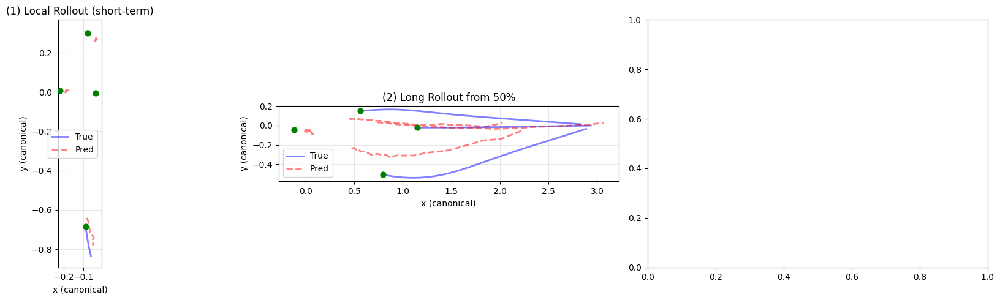


Summary
(1) Local rollout    | pos_L2=0.0359 | hdg=2.39° | cte=0.0261
(2) Long rollout 20%  | pos_L2=0.5295
(2) Long rollout 50%  | pos_L2=0.4278
(2) Long rollout 80%  | pos_L2=0.1715

判断标准（canonical frame，单位与训练数据一致）：
  pos_L2  < 0.05  → 很好 | < 0.15 → 可接受 | > 0.3 → 有问题
  hdg_err < 5°    → 很好 | < 15°  → 可接受 | > 30° → 有问题
  loop_err< 0.05  → flow 一致性好


In [35]:
# ============================================================
# FM Flow Matching - 三种一致性验证 Cell
# (1) 单步/短时间预测一致性 (local rollout)
# (2) 随机中间点长 rollout
# (3) 双向一致性 (noise→mid→end vs 真实)
# ============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
model_5ch.eval()

# ===============================================================
# 0) 加载验证数据（复用训练数据，取 val split 或全部）
# ===============================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, D)
controls = raw['controls']  # (N, T, 2)
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel traj (复用训练时的 canonicalize)
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1).astype(np.float32)  # (N, 5, T)

def canonicalize_single(traj_i, goal_xy=None):
    """将单条轨迹转换到 canonical frame，返回 (5,T) 和 cond (5,)"""
    x0, y0 = traj_i[0, 0], traj_i[1, 0]
    gx = goal_xy[0] if goal_xy is not None else traj_i[0, -1]
    gy = goal_xy[1] if goal_xy is not None else traj_i[1, -1]
    dx, dy   = gx - x0, gy - y0
    dist     = float(np.sqrt(dx**2 + dy**2) + 1e-9)
    cos_a, sin_a = dx / dist, dy / dist
    angle_off = float(np.arctan2(sin_a, cos_a))

    out = traj_i.copy()
    out[0] =  cos_a * (traj_i[0] - x0) + sin_a * (traj_i[1] - y0)
    out[1] = -sin_a * (traj_i[0] - x0) + cos_a * (traj_i[1] - y0)
    out[2] = np.array([(float(th) - angle_off + np.pi) % (2*np.pi) - np.pi
                        for th in traj_i[2]])

    th0_can = float((traj_i[2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
    v0      = float(states[0, 0, 3]) if D > 3 else 0.0
    cond    = np.array([dist, float(traj_i[3, 0]),
                        np.cos(th0_can), np.sin(th0_can),
                        float(traj_i[4, 0])], dtype=np.float32)
    return out, cond

# ===============================================================
# 辅助：用 model 做 ODE rollout，从 x_init 积分 t_start → t_end
# ===============================================================
def fm_ode_rollout(x_init_5T, cond_vec, t_start, t_end, n_out_steps=None, method="euler"):
    """
    x_init_5T : (5, T) numpy，作为 ODE 初值
    cond_vec  : (5,)  numpy
    t_start, t_end : float in [0,1]
    n_out_steps: 输出的中间时刻数量（None=只要终点）
    返回: (n_out_steps+1, 5, T) numpy，包含起点
    """
    dev  = next(model_5ch.parameters()).device
    x0_t = torch.tensor(x_init_5T, device=dev).unsqueeze(0)  # (1,5,T)
    c_t  = torch.tensor(cond_vec,   device=dev).unsqueeze(0)  # (1,5)

    if n_out_steps is None:
        t_span = torch.tensor([t_start, t_end], device=dev)
    else:
        t_span = torch.linspace(t_start, t_end, n_out_steps + 1, device=dev)

    def rhs(t, x_flat):
        xn = x_flat.view(1, 5, T)
        tt = torch.tensor([float(t)], device=dev)
        return model_5ch(xn, tt, cond=c_t).reshape(-1)

    sol = torchdiffeq.odeint(rhs, x0_t.reshape(-1), t_span,
                              method=method, atol=1e-4, rtol=1e-4)
    # sol: (n_steps, 5*T)
    return sol.reshape(-1, 5, T).cpu().numpy()  # (n_steps, 5, T)

# ===============================================================
# 指标函数
# ===============================================================
def pos_l2(pred_xy, true_xy):
    """pred_xy, true_xy: (T, 2)"""
    return float(np.mean(np.linalg.norm(pred_xy - true_xy, axis=1)))

def heading_err(pred_th, true_th):
    """角度误差（弧度），(T,)"""
    diff = (pred_th - true_th + np.pi) % (2*np.pi) - np.pi
    return float(np.mean(np.abs(diff)))

def cross_track_err(pred_xy, true_xy):
    """逐点到真实路径的垂直距离均值"""
    errs = []
    for i in range(len(pred_xy)):
        idx = np.argmin(np.linalg.norm(true_xy - pred_xy[i], axis=1))
        errs.append(float(np.linalg.norm(pred_xy[i] - true_xy[idx])))
    return float(np.mean(errs))

# ===============================================================
# (1) 单步 / 短时间预测一致性
# ===============================================================
print("\n" + "="*60)
print("(1) 单步/短时间预测一致性 (local rollout)")
print("="*60)

N_SAMPLES   = 20    # 验证样本数
M_STEPS     = 3     # 往前积分 m 步（时间步）
dt_norm     = 1.0 / (T - 1)  # 归一化时间步长

np.random.seed(0)
results_1 = []

for _ in range(N_SAMPLES):
    idx  = np.random.randint(0, N)
    traj = traj_5ch[idx]  # (5, T)
    goal = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj, goal)

    # 随机选中间帧作为起点（避开首尾）
    k = np.random.randint(T // 4, T // 2)
    t_k   = k * dt_norm
    t_km  = min((k + M_STEPS) * dt_norm, 1.0)

    x_init = traj_can[:, k]   # (5,) 某一帧
    # 扩展成 (5, T)：用真实 xk 填满（模型需要全序列，取当前帧复制）
    x_init_5T = np.tile(x_init.reshape(5, 1), (1, T)).astype(np.float32)
    # 实际上模型操作整条轨迹，所以用真实的 traj_can[:, k:] 拼起来更合理
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]  # 起点之前用 xk 填充（相当于从 xk 开始）

    sol = fm_ode_rollout(x_init_5T, cond, t_k, t_km, n_out_steps=M_STEPS)
    # sol[-1]: (5, T) 预测结果

    pred_xy  = sol[-1][0:2, k:k+M_STEPS+1].T   # (M+1, 2)
    true_xy  = traj_can[0:2, k:k+M_STEPS+1].T  # (M+1, 2)
    pred_th  = sol[-1][2, k:k+M_STEPS+1]
    true_th  = traj_can[2, k:k+M_STEPS+1]

    results_1.append({
        "pos_l2":  pos_l2(pred_xy, true_xy),
        "hdg_err": heading_err(pred_th, true_th),
        "cte":     cross_track_err(pred_xy, true_xy),
    })

r1_pos = np.mean([r["pos_l2"]  for r in results_1])
r1_hdg = np.mean([r["hdg_err"] for r in results_1])
r1_cte = np.mean([r["cte"]     for r in results_1])
print(f"  Samples={N_SAMPLES}, rollout={M_STEPS} steps")
print(f"  Mean pos L2    : {r1_pos:.4f}")
print(f"  Mean heading err: {np.rad2deg(r1_hdg):.2f} deg")
print(f"  Mean cross-track: {r1_cte:.4f}")

# ===============================================================
# (2) 随机中间点长 rollout
# ===============================================================
print("\n" + "="*60)
print("(2) 随机中间点长 rollout (20%, 50%, 80%)")
print("="*60)

START_FRACS = [0.2, 0.5, 0.8]
N_SAMPLES_2 = 10
results_2   = {f: [] for f in START_FRACS}

for frac in START_FRACS:
    for _ in range(N_SAMPLES_2):
        idx  = np.random.randint(0, N)
        traj = traj_5ch[idx]
        goal = goals[idx] if goals is not None else None
        traj_can, cond = canonicalize_single(traj, goal)

        k     = int(frac * (T - 1))
        t_k   = k * dt_norm

        # 从 xk 出发积分到末尾
        x_init_5T        = traj_can.copy()
        x_init_5T[:, :k] = traj_can[:, k:k+1]

        n_remain = T - k
        sol = fm_ode_rollout(x_init_5T, cond, t_k, 1.0,
                             n_out_steps=n_remain, method="euler")
        # sol: (n_remain+1, 5, T)
        pred_end = sol[-1]  # (5, T)

        pred_xy = pred_end[0:2, k:].T   # (T-k, 2)
        true_xy = traj_can[0:2, k:].T
        pred_th = pred_end[2, k:]
        true_th = traj_can[2, k:]

        results_2[frac].append({
            "pos_l2":  pos_l2(pred_xy, true_xy),
            "hdg_err": heading_err(pred_th, true_th),
            "cte":     cross_track_err(pred_xy, true_xy),
        })

    m_pos = np.mean([r["pos_l2"]  for r in results_2[frac]])
    m_hdg = np.mean([r["hdg_err"] for r in results_2[frac]])
    m_cte = np.mean([r["cte"]     for r in results_2[frac]])
    print(f"  Start at {int(frac*100)}% | pos_L2={m_pos:.4f} | "
          f"hdg={np.rad2deg(m_hdg):.2f}deg | cte={m_cte:.4f}")

# ===============================================================
# (3) 双向一致性（noise → xk → xT，再对比真实 xk 附近分布）
# ===============================================================
print("\n" + "="*60)
print("(3) 双向一致性 (noise → mid → end)")
print("="*60)

N_SAMPLES_3 = 10
MID_FRAC    = 0.5   # 用 50% 处作为"中间点"
results_3   = []

for _ in range(N_SAMPLES_3):
    idx  = np.random.randint(0, N)
    traj = traj_5ch[idx]
    goal = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj, goal)

    k_mid = int(MID_FRAC * (T - 1))
    t_mid = k_mid * dt_norm

    # Step A: noise → x_mid（积分 0→t_mid）
    x_noise = np.random.randn(5, T).astype(np.float32) * 0.08
    x_noise[:, 0] = 0.0  # lock start
    sol_a = fm_ode_rollout(x_noise, cond, 0.0, t_mid, n_out_steps=1)
    x_mid_pred = sol_a[-1]  # (5, T)

    # Step B: x_mid_pred → x_end（积分 t_mid→1.0）
    sol_b = fm_ode_rollout(x_mid_pred, cond, t_mid, 1.0, n_out_steps=1)
    x_end_pred = sol_b[-1]  # (5, T)

    # 对比1：x_mid_pred 和真实 x_mid 的差异（中间点一致性）
    mid_pos_err = float(np.mean(np.linalg.norm(
        x_mid_pred[0:2, :].T - traj_can[0:2, :].T, axis=1
    )))

    # 对比2：x_end_pred 和真实轨迹末尾的差异（终点一致性）
    end_pos_err = float(np.linalg.norm(
        x_end_pred[0:2, -1] - traj_can[0:2, -1]
    ))

    # 对比3：完整路径 noise→end 直接积分 vs 两段拼接的终点差异（循环一致性）
    sol_direct = fm_ode_rollout(x_noise, cond, 0.0, 1.0, n_out_steps=1)
    x_end_direct = sol_direct[-1]
    loop_err = float(np.linalg.norm(
        x_end_pred[0:2, -1] - x_end_direct[0:2, -1]
    ))

    results_3.append({
        "mid_pos_err": mid_pos_err,
        "end_pos_err": end_pos_err,
        "loop_err":    loop_err,
    })

r3_mid  = np.mean([r["mid_pos_err"] for r in results_3])
r3_end  = np.mean([r["end_pos_err"] for r in results_3])
r3_loop = np.mean([r["loop_err"]    for r in results_3])
print(f"  Samples={N_SAMPLES_3}, mid_frac={MID_FRAC}")
print(f"  Mid-point pos err (pred vs true) : {r3_mid:.4f}")
print(f"  End-point pos err (2-seg vs true) : {r3_end:.4f}")
print(f"  Loop consistency (2-seg vs direct): {r3_loop:.4f}  ← 越小越好")

# ===============================================================
# 可视化：每种检查各画 3 条代表性轨迹
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

np.random.seed(42)

# --- Plot (1): local rollout ---
ax = axes[0]
ax.set_title("(1) Local Rollout (short-term)")
for _ in range(4):
    idx  = np.random.randint(0, N)
    traj_can, cond = canonicalize_single(traj_5ch[idx],
                                          goals[idx] if goals is not None else None)
    k = T // 3
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]
    sol = fm_ode_rollout(x_init_5T, cond, k*dt_norm,
                          min((k+5)*dt_norm, 1.0), n_out_steps=5)
    ax.plot(traj_can[0, k:k+6], traj_can[1, k:k+6],
            'b-', alpha=0.5, lw=2, label="True" if _ == 0 else "")
    ax.plot(sol[-1][0, k:k+6], sol[-1][1, k:k+6],
            'r--', alpha=0.5, lw=2, label="Pred" if _ == 0 else "")
    ax.scatter([traj_can[0, k]], [traj_can[1, k]], c='g', s=40, zorder=5)
ax.legend(); ax.grid(alpha=0.3); ax.set_aspect("equal")
ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")

# --- Plot (2): long rollout ---
ax2 = axes[1]
ax2.set_title("(2) Long Rollout from 50%")
for _ in range(4):
    idx  = np.random.randint(0, N)
    traj_can, cond = canonicalize_single(traj_5ch[idx],
                                          goals[idx] if goals is not None else None)
    k = T // 2
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]
    sol = fm_ode_rollout(x_init_5T, cond, k*dt_norm, 1.0,
                          n_out_steps=T-k, method="euler")
    ax2.plot(traj_can[0, k:], traj_can[1, k:],
             'b-', alpha=0.5, lw=2, label="True" if _ == 0 else "")
    ax2.plot(sol[-1][0, k:], sol[-1][1, k:],
             'r--', alpha=0.5, lw=2, label="Pred" if _ == 0 else "")
    ax2.scatter([traj_can[0, k]], [traj_can[1, k]], c='g', s=40, zorder=5)
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_aspect("equal")
ax2.set_xlabel("x (canonical)"); ax2.set_ylabel("y (canonical)")

# --- Plot (3): bidirectional ---
# ax3 = axes[2]
# ax3.set_title("(3) Bidirectional: noise→mid→end vs direct")
# for _ in range(4):
#     idx  = np.random.randint(0, N)
#     traj_can, cond = canonicalize_single(traj_5ch[idx],
#                                           goals[idx] if goals is not None else None)
#     k_mid = T // 2
#     x_noise = np.random.randn(5, T).astype(np.float32) * 0.08
#     x_noise[:, 0] = 0.0

#     sol_a      = fm_ode_rollout(x_noise, cond, 0.0, k_mid*dt_norm, n_out_steps=1)
#     sol_b      = fm_ode_rollout(sol_a[-1], cond, k_mid*dt_norm, 1.0, n_out_steps=1)
#     sol_direct = fm_ode_rollout(x_noise, cond, 0.0, 1.0, n_out_steps=1)

#     ax3.plot(traj_can[0], traj_can[1],
#              'b-', alpha=0.3, lw=1.5, label="True" if _ == 0 else "")
#     ax3.plot(sol_b[-1][0], sol_b[-1][1],
#              'r--', alpha=0.5, lw=1.5, label="2-seg" if _ == 0 else "")
#     ax3.plot(sol_direct[-1][0], sol_direct[-1][1],
#              'g:', alpha=0.5, lw=1.5, label="Direct" if _ == 0 else "")

# ax3.legend(); ax3.grid(alpha=0.3); ax3.set_aspect("equal")
# ax3.set_xlabel("x (canonical)"); ax3.set_ylabel("y (canonical)")

plt.tight_layout()
plt.show()

# ===============================================================
# 汇总打印
# ===============================================================
print("\n" + "="*60)
print("Summary")
print("="*60)
print(f"(1) Local rollout    | pos_L2={r1_pos:.4f} | hdg={np.rad2deg(r1_hdg):.2f}° | cte={r1_cte:.4f}")
for frac in START_FRACS:
    m = np.mean([r["pos_l2"] for r in results_2[frac]])
    print(f"(2) Long rollout {int(frac*100)}%  | pos_L2={m:.4f}")
# print(f"(3) Loop consistency | mid={r3_mid:.4f} | end={r3_end:.4f} | loop={r3_loop:.4f}")
print()
print("判断标准（canonical frame，单位与训练数据一致）：")
print("  pos_L2  < 0.05  → 很好 | < 0.15 → 可接受 | > 0.3 → 有问题")
print("  hdg_err < 5°    → 很好 | < 15°  → 可接受 | > 30° → 有问题")
print("  loop_err< 0.05  → flow 一致性好")

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0: 'float' = 0.5, tau1: 'float' = 0.9, prox_k: 'float' = 3.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - 验证结果改进版
K=8  PATH_HEADING_TOL=60°  PATH_START_TOL=0.3
goal_tol=0.2  ARRIVAL_DIST=0.15  APPROACH_DIST=0.6
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15
[  2] dA=3.349 dB=3.349 dist=2.336 vA=0.

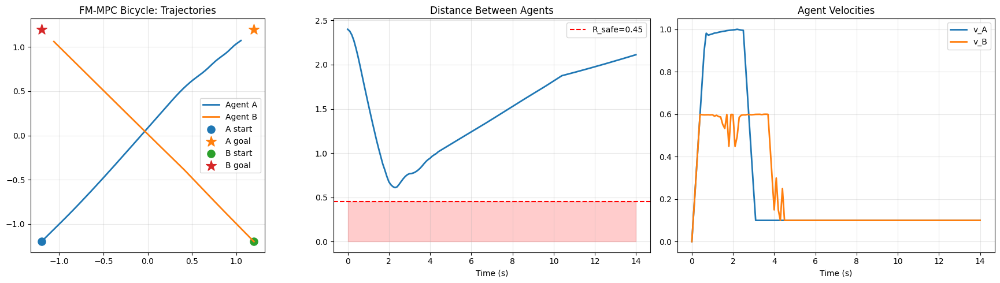

In [12]:
# ============================================================
# FM-MPC Bicycle - 根据验证结果改进版
# 针对问题：模型前半段预测差，Long rollout 误差大
# 改进策略：
#   1. 增加 K（采样数），用更多候选路径对冲模型不稳定性
#   2. 增加路径质量过滤：起始段偏差过大的路径直接丢弃
#   3. goal_guidance_weight 提高，强制路径末端拉向目标
#   4. 增加 replan 频率自适应：路径质量差时强制重采样
#   5. cost 函数增加路径起始段一致性惩罚
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 8           # ★ 原5→8：模型不稳定时多采样对冲，增加找到好路径的概率
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping
goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# ★ 路径质量过滤阈值（根据验证结果设定）
# Local rollout pos_L2=0.0325 说明单步是好的
# 但 Long rollout 20% 处 pos_L2=0.54，说明路径整体可能偏很多
# 用路径起始方向和当前heading的夹角来过滤明显错误的路径
PATH_HEADING_TOL = np.deg2rad(60.0)  # ★ 路径起始方向与当前heading偏差超过60°则丢弃
PATH_START_TOL   = 0.30              # ★ 路径第一个点离当前位置超过这个距离则丢弃（lock_start失效）

# ===============================================================
# 3) Bicycle dynamics（不变）
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame（不变）
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings（不变）
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction（不变）
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ★ 改动：goal_guidance_weight 0.90→0.95，强制末端更靠近目标
#    补偿模型前半段不准导致末端飘离的问题
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []
    x0_noise = make_x0_noise(T_steps, seed)
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55,   # ★ 0.45→0.55：加强起点锁定，对抗前半段偏差
        goal_guidance_weight=0.95,    # ★ 0.90→0.95：加强终点牵引
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf), scaler=None, ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )

    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# ★ 新增：路径质量检查
# 验证结果表明模型前半段不稳定，需要过滤明显异常的路径
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    """
    返回 (is_valid, reason)
    过滤两类明显错误：
    1. 路径起点离当前位置太远（lock_start 失效）
    2. 路径前几个点的方向和当前 heading 偏差太大（前半段跑飞）
    """
    pos = self_state[:2]
    th  = float(self_state[2])

    # 检查1：路径起点是否锁定在当前位置
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    # 检查2：路径前段方向是否合理
    # 取路径前 1/4 段，计算整体方向
    n_check = max(3, len(path_xy) // 4)
    seg = path_xy[:n_check]
    seg_dir = seg[-1] - seg[0]
    seg_len = float(np.linalg.norm(seg_dir))

    if seg_len > 0.05:  # 路径前段有足够位移才检查方向
        seg_angle = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    # 检查3：路径终点是否朝向目标（应该比起点更近）
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:  # 终点比起点离目标还远 20% 以上
        return False, f"path_goes_away d_end={d_end:.3f}>d_start={d_start:.3f}"

    return True, "ok"

# ===============================================================
# 8) Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    Ld_min  = 0.20
    Ld_max  = 1.10
    k_brake = 5.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            Ld = min(Ld, d_goal * 0.85)
            near_idx = _closest_index(path_xy, pos)
            near_idx = max(near_idx, last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))
        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        turn_pen  = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des    *= turn_pen
        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost
# ===============================================================
W_END    = 18.0
W_PATH   = 1.5
W_COLL   = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0]**2 + 0.4*dU[:, 1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan
# ★ 改动：加入路径质量过滤，过滤掉模型前半段跑飞的路径
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)
    best         = None
    cbf_count    = 0
    reject_count = 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy,
                other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue

        # ★ 路径质量过滤
        valid, reason = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        cbf_count += int(used_cbf)
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0          = U[0].copy()

        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)

    # ★ 如果所有路径都被过滤掉，降级为直接朝目标走的保底控制
    if best is None:
        if reject_count > 0:
            print(f"  [WARN] all {reject_count} paths rejected, using fallback")
        # 保底：直接朝目标方向以低速行驶
        pos    = self_state[:2]
        th     = float(self_state[2])
        goal_xy_arr = np.asarray(goal_xy, np.float32)
        d_goal = float(np.linalg.norm(pos - goal_xy_arr))
        ang    = float(math.atan2(goal_xy_arr[1]-pos[1], goal_xy_arr[0]-pos[0]))
        alpha  = float(wrap_pi(ang - th))
        kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr     = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
        a      = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
        u_fallback = np.array([a, dr], dtype=np.float32)
        return u_fallback, float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0]))
thB0 = float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 验证结果改进版")
print(f"K={K}  PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  PATH_START_TOL={PATH_START_TOL}")
print(f"goal_tol={goal_tol}  ARRIVAL_DIST={ARRIVAL_DIST}  APPROACH_DIST={APPROACH_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots（不变）
# ===============================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# FM-MPC Bicycle — JAX Fixed + GPU + Batched Inference
#
# 修复内容：
#   1. 强制 JAX 使用 GPU (CUDA)
#   2. K 条路径合并为一次 batch 推理，消除 320 次 CPU↔GPU 搬运
#   3. 放宽路径过滤，增加 fallback 容忍度
#   4. 保持 Python for loop ODE（避免 TracerArrayConversionError）
# ============================================================

from __future__ import annotations

import math
import os
import sys
from pathlib import Path

import numpy as np
import torch

# ── 1. 强制 JAX 用 GPU ──────────────────────────────────────
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # 避免 JAX 预分配全部显存
os.environ["JAX_PLATFORM_NAME"] = "gpu"                  # 强制用 GPU

import jax
import jax.numpy as jnp

print(f"[device torch] {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"[device jax  ] {jax.devices()}")   # 应该显示 CudaDevice

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── torch2jax ────────────────────────────────────────────────
try:
    from torch2jax import torch2jax as t2j
    HAS_TORCH2JAX = True
except ImportError:
    HAS_TORCH2JAX = False
    print("[WARN] torch2jax not found — falling back to batched numpy bridge")


# ================================================================
# 0) Load sampler_5h
# ================================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")
import importlib.util
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

from dmpc_fm_cbf import cbf_project_velocity_sgfm as _cbf_fn
cbf_projector_pt = _cbf_fn if callable(_cbf_fn) else getattr(_cbf_fn, "cbf_project_velocity_sgfm")


# ================================================================
# 1) Model check
# ================================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")


# ================================================================
# 2) Parameters
# ================================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
noise_scale  = 0.08

# MPC
H            = 12
K            = 8
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping
goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# Path quality filter — 放宽，减少 all-rejected
PATH_HEADING_TOL     = np.deg2rad(75.0)   # 原 60° → 75°
PATH_START_TOL       = 0.50               # 原 0.30 → 0.50
MIN_VALID_PATHS      = 2                  # 至少有这么多条合格才正常选，否则放宽再选

# Guidance weights
START_GUIDANCE_WEIGHT = 0.55
GOAL_GUIDANCE_WEIGHT  = 0.95
TAU0_HF               = 0.7


# ================================================================
# 3) Bicycle dynamics
# ================================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2 * np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh + 1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i + 1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st


# ================================================================
# 4) Canonical frame
# ================================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }


# ================================================================
# 5) CBF settings
# ================================================================
r_obs_far      = 0.32
r_obs_near     = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos) - 1]
    idxs = sorted(list(dict.fromkeys([i for i in idxs if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses


# ================================================================
# 6) ★ Batched model bridge
#
#   关键优化：把 K 条路径合并成一个 batch (K, 5, T) 一次推理，
#   而不是每条路径单独调用模型。
#   这样 320 次 CPU↔GPU 搬运 → 40 次（每个 euler step 1 次 batch）
# ================================================================

def _model_forward_batch(x_KxCxT: np.ndarray, t_scalar: float,
                          cond_KxC: np.ndarray) -> np.ndarray:
    """
    x_KxCxT  : (K, 5, T) numpy
    cond_KxC : (K, C)    numpy
    返回       : (K, 5, T) numpy — velocity field
    """
    K_batch = x_KxCxT.shape[0]
    x_pt    = torch.from_numpy(x_KxCxT).to(device)           # (K,5,T)
    t_pt    = torch.full((K_batch,), t_scalar,
                          dtype=torch.float32, device=device)  # (K,)
    c_pt    = torch.from_numpy(cond_KxC).to(device)           # (K,C)

    with torch.no_grad():
        v_pt = model_5ch(x_pt, t_pt, cond=c_pt)               # (K,5,T)

    return v_pt.cpu().numpy().astype(np.float32)


# ================================================================
# 7) Pure-JAX CBF projection  (unchanged)
# ================================================================

def _cbf_project_jax(x_1x2T, v_nom_1x2T, ellipses_jnp, *,
                      alpha=10.0, extra_margin=0.08,
                      passes=2, max_corr_norm=2.0):
    v = v_nom_1x2T
    for _ in range(passes):
        for (center, radius) in ellipses_jnp:
            r_safe = radius + extra_margin
            p      = x_1x2T[0]
            dx     = p[0] - center[0]
            dy     = p[1] - center[1]
            dist   = jnp.sqrt(dx**2 + dy**2 + 1e-8)
            h      = dist - r_safe
            grad_h = jnp.stack([dx / dist, dy / dist], axis=0)
            v_xy   = v[0]
            lf_h   = jnp.sum(grad_h * v_xy, axis=0)
            viol   = jnp.maximum(0.0, -(lf_h + alpha * h))
            corr   = grad_h * viol[None, :]
            corr_norm = jnp.linalg.norm(corr, axis=0, keepdims=True)
            corr   = corr / jnp.maximum(corr_norm, 1.0) * jnp.minimum(corr_norm, max_corr_norm)
            v      = v.at[0].add(corr)
    return v


# ================================================================
# 8) ★ Batched K-parallel FM sampling
#
#   所有 K 条路径共享同一套 ODE loop，每步做一次 (K,5,T) batch 推理。
#   CBF 仍然逐条应用（因为 ellipses 是全局共享的，可以向量化，
#   但这里先保持逐条以避免引入新 bug）。
# ================================================================

def _sample_K_batched(
    seeds: list,
    cond_vec: np.ndarray,       # (C,) numpy
    start_np: np.ndarray,       # (2,) numpy
    goal_np: np.ndarray,        # (2,) numpy
    ellipses_jnp,
    use_cbf: bool,
) -> np.ndarray:
    """
    返回 paths_can: (K, 5, T) numpy
    """
    Kb = len(seeds)

    # ── 初始化 K 条噪声轨迹 ────────────────────────────────
    x_batch = np.zeros((Kb, 5, T_steps), dtype=np.float32)
    for i, seed in enumerate(seeds):
        rng = np.random.default_rng(int(seed))
        xi  = rng.standard_normal((5, T_steps)).astype(np.float32) * noise_scale
        xi[:, 0]   = 0.0
        xi[0:2, 0] = start_np
        # Terminal safety filter
        if use_cbf and len(ellipses_jnp) > 0:
            xy = xi[0:2, :]
            for (center_jnp, radius) in ellipses_jnp:
                center = np.array(center_jnp, dtype=np.float32)
                diff   = xy - center.reshape(2, 1)
                dist_c = np.linalg.norm(diff, axis=0)
                unsafe = dist_c < radius
                if unsafe.any():
                    near_c    = dist_c < 1e-6
                    safe_diff = np.where(
                        near_c[None, :],
                        np.array([[1.0],[0.0]], dtype=np.float32) * np.ones((2, T_steps)),
                        diff
                    )
                    direction = safe_diff / (dist_c[None, :] + 1e-9)
                    xy[:, unsafe] = center.reshape(2, 1) + direction[:, unsafe] * radius
            xi[0:2, :] = xy
        x_batch[i] = xi

    # cond broadcast: (K, C)
    cond_batch = np.tile(cond_vec.reshape(1, -1), (Kb, 1)).astype(np.float32)

    # guidance ramp (numpy, shared for all K)
    idx_arr  = np.linspace(0.0, 1.0, T_steps, dtype=np.float32)
    ramp_arr = np.clip((idx_arr - 0.5) / 0.5, 0.0, 1.0).reshape(1, 1, T_steps)

    # ── Piecewise Euler — one batch call per substep ────────
    dt_seg     = total_time / num_segments
    n_substeps = 8
    dt_sub     = dt_seg / n_substeps

    for seg_i in range(num_segments):
        t0_seg = seg_i * dt_seg

        for sub_j in range(n_substeps):
            t_now = t0_seg + sub_j * dt_sub
            tau   = t_now / total_time
            w_t   = 0.25 + 0.75 * tau

            # ── Batch model forward (1 GPU call for all K) ──
            v_batch = _model_forward_batch(x_batch, t_now, cond_batch)
            # v_batch: (K, 5, T)

            # ── Guidance (vectorized over K) ─────────────────
            w_s = START_GUIDANCE_WEIGHT * w_t
            v_batch[:, 0:2, 0:1] += w_s * (start_np.reshape(1, 2, 1) - x_batch[:, 0:2, 0:1])

            w_g = GOAL_GUIDANCE_WEIGHT * w_t
            v_batch[:, 0:2, :] += w_g * ramp_arr * (goal_np.reshape(1, 2, 1) - x_batch[:, 0:2, :])

            # ── CBF (per-path, JAX) ───────────────────────────
            if use_cbf and len(ellipses_jnp) > 0:
                g_hf = float(
                    ((tau - TAU0_HF) / (1.0 - TAU0_HF + 1e-9)) ** 2.0
                    if tau >= TAU0_HF else 0.0
                )
                cbf_kwargs = dict(
                    alpha=10.0 + 10.0 * g_hf,
                    extra_margin=0.08 + 0.22 * g_hf,
                    passes=2,
                    max_corr_norm=2.0 + 1.0 * g_hf,
                )
                for k in range(Kb):
                    x_k = jnp.array(x_batch[k:k+1, 0:2, :])   # (1,2,T)
                    v_k = jnp.array(v_batch[k:k+1, 0:2, :])    # (1,2,T)
                    v_safe = _cbf_project_jax(x_k, v_k, ellipses_jnp, **cbf_kwargs)
                    v_batch[k, 0:2, :] = np.array(v_safe[0])

            # ── Euler step ────────────────────────────────────
            x_batch += dt_sub * v_batch

        # Re-lock start after each segment
        x_batch[:, 0:2, 0] = start_np[None, :]

    return x_batch  # (K, 5, T)


# ================================================================
# 9) High-level FM sampling
# ================================================================

def sample_fm_paths_jax(*, self_state, goal_xy, other_pred_pos, seed_base):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)

    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) \
                        else other_pred_pos[0]
    dist_AB = float(np.linalg.norm(self_xy - other_now))

    use_cbf, _ = get_cbf_config(dist_AB)
    ellipses_np = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    ellipses_jnp = [
        (jnp.array(e["center"], dtype=jnp.float32), float(e["radius"]))
        for e in ellipses_np
    ]

    v0      = float(self_state[3])
    th_can  = tf["w2c_angle"](float(self_state[2]))
    delta0  = float(self_state[4])
    cond_vec = np.array(
        [tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0],
        dtype=np.float32
    )

    start_np = np.array(tf["start_can"])
    goal_np  = np.array(tf["goal_can"])
    seeds    = [seed_base + 137 * k + 7919 for k in range(K)]

    paths_can = _sample_K_batched(
        seeds, cond_vec, start_np, goal_np, ellipses_jnp, use_cbf
    )  # (K, 5, T)

    paths_xy_can = paths_can[:, 0:2, :].transpose(0, 2, 1)  # (K, T, 2)
    paths_world  = np.stack([
        tf["c2w"](paths_xy_can[k]).astype(np.float32)
        for k in range(K)
    ])  # (K, T, 2)

    return paths_world, use_cbf, dist_AB


# ================================================================
# 10) Path quality filter
#     ★ 增加 relaxed 模式：全部 rejected 时放宽标准再选一次
# ================================================================

def check_path_quality(path_xy, self_state, goal_xy, *, relax=False):
    pos = self_state[:2]
    th  = float(self_state[2])
    tol_start   = PATH_START_TOL   * (2.0 if relax else 1.0)
    tol_heading = PATH_HEADING_TOL * (1.5 if relax else 1.0)

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > tol_start:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg     = path_xy[:n_check]
    seg_dir = seg[-1] - seg[0]
    seg_len = float(np.linalg.norm(seg_dir))

    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > tol_heading:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.3:   # 原 1.2 → 1.3，稍微宽松
        return False, f"path_goes_away"

    return True, "ok"


# ================================================================
# 11) Pure Pursuit  (unchanged)
# ================================================================

def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy) - 1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s        = s0.copy()
    U        = np.zeros((H, 2), dtype=np.float32)
    k_brake  = 5.0
    Ld_min, Ld_max = 0.20, 1.10
    path_xy  = np.asarray(path_xy,  np.float32)
    goal_xy  = np.asarray(goal_xy,  np.float32)
    last_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            Ld = min(Ld, d_goal * 0.85)
            near_idx  = max(_closest_index(path_xy, pos), last_idx)
            target, last_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))
        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        turn_pen  = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des    *= turn_pen
        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U


# ================================================================
# 12) Cost  (unchanged)
# ================================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M       = min(len(pos_self), len(pos_other_pred))
    min_d   = float("inf") if M <= 1 else \
              float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol    = max(0.0, R_SAFE - min_d)
    coll    = float(viol * viol)
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    smooth  = float(np.mean(dU[:, 0]**2 + 0.4 * dU[:, 1]**2))
    return W_END * d_end + W_PATH * d_path + W_COLL * coll + W_SMOOTH * smooth


# ================================================================
# 13) MPC replan
#     ★ all-rejected 时先放宽标准再选，实在不行才用 fallback
# ================================================================

def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    return rollout_bicycle(other_state, U, dt=dt, v_max=v_max)


def _fallback_control(self_state, goal_xy):
    pos      = self_state[:2]
    th       = float(self_state[2])
    goal_arr = np.asarray(goal_xy, np.float32)
    d_goal   = float(np.linalg.norm(pos - goal_arr))
    ang      = float(math.atan2(goal_arr[1] - pos[1], goal_arr[0] - pos[0]))
    alpha    = float(wrap_pi(ang - th))
    kappa    = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr       = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
    a        = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
    return np.array([a, dr], np.float32)


def _select_best_path(paths_world, self_state, goal_xy, other_pred_pos, *,
                      relax=False, v_max_self):
    """从 K 条路径里选最优，返回 (best_J, best_u, best_path) 或 None"""
    best = None
    for k in range(K):
        path_xy = paths_world[k]
        valid, _ = check_path_quality(path_xy, self_state, goal_xy, relax=relax)
        if not valid:
            continue
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                            H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    return best


def mpc_replan(self_state, goal_xy, other_state, other_u_last, *,
               v_max_self, v_max_other, seed_base):

    other_pred_pos, _ = predict_other_traj(
        other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other
    )

    try:
        paths_world, used_cbf_any, dist_AB = sample_fm_paths_jax(
            self_state=self_state,
            goal_xy=goal_xy,
            other_pred_pos=other_pred_pos,
            seed_base=seed_base,
        )
    except Exception as e:
        print(f"  [WARN] JAX FM sample failed: {e}")
        return _fallback_control(self_state, goal_xy), float("inf"), None, 0

    cbf_count = int(used_cbf_any) * K

    # 先正常过滤
    best = _select_best_path(paths_world, self_state, goal_xy, other_pred_pos,
                             relax=False, v_max_self=v_max_self)

    # 全 rejected → 放宽标准再试一次
    if best is None:
        best = _select_best_path(paths_world, self_state, goal_xy, other_pred_pos,
                                 relax=True, v_max_self=v_max_self)
        if best is None:
            return _fallback_control(self_state, goal_xy), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count


# ================================================================
# 14) Scenario setup & main loop
# ================================================================
import matplotlib.pyplot as plt
import time

xA0 = np.array([-1.2, -1.2], np.float32);  gA = np.array([ 1.2,  1.2], np.float32)
xB0 = np.array([ 1.2, -1.2], np.float32);  gB = np.array([-1.2,  1.2], np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("=" * 60)
print("FM-MPC Bicycle — Batched GPU Inference")
print(f"K={K}  T={T_steps}  segments={num_segments}")
print(f"GPU batch: {num_segments * 8} model calls/replan  (was {num_segments * 8 * K})")
print(f"PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  "
      f"PATH_START_TOL={PATH_START_TOL}")
print("=" * 60)

# Warm-up
print("[warmup] running first sample ... ", end="", flush=True)
_ = sample_fm_paths_jax(
    self_state=sA, goal_xy=gA, other_pred_pos=None, seed_base=0
)
print("done")

t_start = time.perf_counter()

for step in range(MAX_STEPS):
    dA    = float(np.linalg.norm(sA[:2] - gA))
    dB    = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  "
              f"(t={step * dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB,
                v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step * 31,
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA,
                v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step * 37,
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            elapsed = time.perf_counter() - t_start
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}  elapsed={elapsed:.1f}s")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

t_total = time.perf_counter() - t_start
trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total} | "
      f"wall_time={t_total:.1f}s")


# ================================================================
# 15) Analysis & plots
# ================================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | "
      f"collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]}  dist_to_goal="
      f"{float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]}  dist_to_goal="
      f"{float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t_axis = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:, 0], trajA[:, 1], lw=2, label="Agent A")
ax.plot(trajB[:, 0], trajB[:, 1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t_axis, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t_axis, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t_axis, trajA[:, 3], lw=2, label="v_A")
ax3.plot(t_axis, trajB[:, 3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[device torch] cuda


RuntimeError: Unknown backend: 'gpu' requested, but no platforms that are instances of gpu are present. Platforms present are: cpu

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler] loaded
[model] loaded
FM-MPC Bicycle - 三车实验（放宽路径过滤版）
PATH_HEADING_TOL=90°  PATH_START_TOL=0.4
A: [-1.2 -1.2]→[1.2 1.2]  B: [ 1.2 -1.2]→[-1.2  1.2]  C: [0.  1.2]→[ 0.  -1.2]
[  0] dA=3.39 dB=3.39 dC=2.40 | d_AB=2.40 d_AC=2.68 d_BC=2.68
[  1] dA=3.38 dB=3.38 dC=2.39 | d_AB=2.38 d_AC=2.66 d_BC=2.66
[  2] dA=3.35 dB=3.35 dC=2.36 | d_AB=2.34 d_AC=2.60 d_BC=2.60
[  3] dA=3.30 dB=3.30 dC=2.31 | d_AB=2.27 d_AC=2.52 d_BC=2.52
[  4] dA=3.24 dB=3.24 dC=2.25 | d_AB=2.19 d_AC=2.41 d_BC=2.41
[  5] dA=3.17 dB=3.18 dC=2.18 | d_AB=2.09 d_AC=2.27 d_BC=2.28
[  6] dA=3.08 dB=3.12 dC=2.10 | d_AB=1.99 d_AC=2.11 d_BC=2.16
[  7] dA=3.00 dB=3.07 dC=2.02 | d_AB=1.89 d_AC=1.97 d_BC=2.03
[  8] dA=2.92 dB=3.01 dC=1.94 | d_AB=1.79 d_AC=1.82 d_BC=1.91
[  9] dA=2.84 dB=2.96 dC=1.86 | d_AB=1.70 d_AC=1.67 d_BC=1.79
[ 30] dA=1.38 dB=2.11 dC=0.80 | d_AB=1.04 d_AC=1.21 d_BC=0.62
[ 60] dA=0.59 dB=1.12 dC=0.50 | d_AB=0.85 d_AC=2.36 d

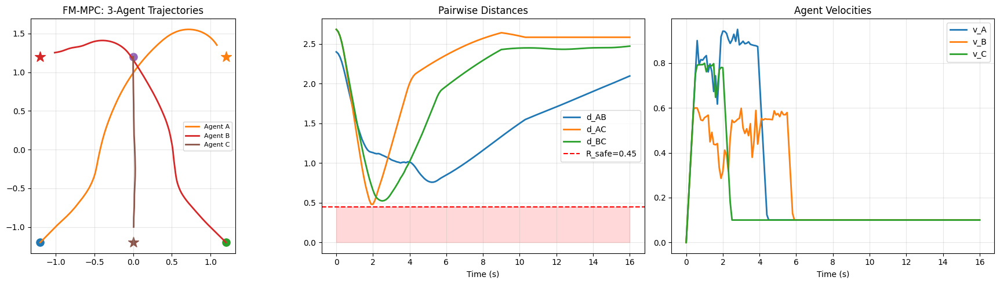

In [33]:
# ============================================================
# FM-MPC Bicycle - 三车实验（修复路径过滤版）
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
assert "cond" in sampler_sig.parameters
print("[sampler] loaded")

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

H            = 12
K            = 8
REPLAN_EVERY = 1
MAX_STEPS    = 300

goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

R_SAFE = 0.45

# ★ 放宽过滤条件，适配三车 CBF 绕行
PATH_HEADING_TOL = np.deg2rad(90.0)  # 原60°→90°
PATH_START_TOL   = 0.40              # 原0.30→0.40

# ===============================================================
# 3) Bicycle dynamics
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_max_C        = 0.8
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(min_dist):
    if min_dist > SAFE_DIST_FAR:
        return False, None
    elif min_dist > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses_multi(tf, others_pred_list):
    """others_pred_list: [(pred_pos, dist_to_self), ...]"""
    ellipses  = []
    idxs_base = [0, 1, 2, 4, 6, 8, 10]
    for pred_pos, dist_AB in others_pred_list:
        if pred_pos is None or len(pred_pos) < 2:
            continue
        idxs = idxs_base + [len(pred_pos)-1]
        idxs = sorted(list(dict.fromkeys(
            [i for i in idxs if 0 <= i < len(pred_pos)]
        )))
        r = r_obs_near if dist_AB < 1.2 else r_obs_far
        for i in idxs:
            c_can = tf["w2c"](pred_pos[i].reshape(1, 2))[0]
            ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path_multi(*, self_state, goal_xy, others_pred_list, seed):
    self_xy  = self_state[:2]
    tf       = build_canonical_frame(self_xy, goal_xy)
    min_dist = min((d for _, d in others_pred_list), default=float("inf"))

    use_cbf, cbf_kwargs = get_cbf_config(min_dist)
    ellipses = build_time_expanded_ellipses_multi(tf, others_pred_list) if use_cbf else []

    x0_noise = make_x0_noise(T_steps, seed)
    v0       = float(self_state[3])
    th_can   = tf["w2c_angle"](float(self_state[2]))
    delta0   = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0],
                         dtype=np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )

    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), min_dist

# ===============================================================
# 8) Path quality check — ★ 放宽版，适配三车 CBF 绕行
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    # 检查1：起点锁定（放宽到 0.40）
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    # 检查2：前段方向（放宽到 90°，只过滤完全反向）
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    # 检查3：终点不能比起点远超 50%（放宽，允许 CBF 绕行）
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.5:
        return False, f"path_goes_away d_end={d_end:.2f} d_start={d_start:.2f}"

    return True, "ok"

# ===============================================================
# 9) Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s, U  = s0.copy(), np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-5.0 * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt=dt, v_max=v_max); continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 10) Cost（多车版）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost_multi(pos_self, others_pred_pos_list, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    coll = 0.0
    for pos_other in others_pred_pos_list:
        M = min(len(pos_self), len(pos_other))
        if M <= 1: continue
        min_d = float(np.linalg.norm(pos_self[:M] - pos_other[:M], axis=1).min())
        viol  = max(0.0, R_SAFE - min_d)
        coll  = max(coll, viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 11) MPC replan（多车版）
# ===============================================================
def mpc_replan_multi(self_state, goal_xy, others_states, others_u_last, *,
                     v_max_self, v_max_others, seed_base):
    others_pred = []
    for s_o, u_o, vm_o in zip(others_states, others_u_last, v_max_others):
        pred_pos, _ = predict_other_traj(s_o, u_o, H=H, dt=dt_exec, v_max=vm_o)
        dist = float(np.linalg.norm(self_state[:2] - s_o[:2]))
        others_pred.append((pred_pos, dist))

    best, cbf_count, reject_count = None, 0, 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, min_dist = sample_fm_path_multi(
                self_state=self_state, goal_xy=goal_xy,
                others_pred_list=others_pred, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}"); continue

        valid, reason = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1; continue

        cbf_count += int(used_cbf)
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost_multi(pos_self, [p for p,_ in others_pred], goal_xy, U)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy(), used_cbf)

    if best is None:
        # 保底控制
        g_arr = np.asarray(goal_xy, np.float32)
        pos, th = self_state[:2], float(self_state[2])
        d_goal  = float(np.linalg.norm(pos - g_arr))
        ang     = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
        alpha   = float(wrap_pi(ang - th))
        kappa   = 2.0 * math.sin(alpha) / max(0.3, d_goal)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr  = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
        a   = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
        return np.array([a, dr], np.float32), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 12) Scenario setup
# A: 左下→右上，B: 右下→左上，C: 上→下（垂直穿越）
# ===============================================================
xA0 = np.array([-1.2, -1.2], np.float32); gA = np.array([ 1.2,  1.2], np.float32)
xB0 = np.array([ 1.2, -1.2], np.float32); gB = np.array([-1.2,  1.2], np.float32)
xC0 = np.array([ 0.0,  1.2], np.float32); gC = np.array([ 0.0, -1.2], np.float32)

sA = np.array([xA0[0], xA0[1], float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])), 0., 0.], np.float32)
sB = np.array([xB0[0], xB0[1], float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])), 0., 0.], np.float32)
sC = np.array([xC0[0], xC0[1], float(math.atan2(gC[1]-xC0[1], gC[0]-xC0[0])), 0., 0.], np.float32)

trajA, trajB, trajC = [sA.copy()], [sB.copy()], [sC.copy()]
uA = np.zeros(2, np.float32)
uB = np.zeros(2, np.float32)
uC = np.zeros(2, np.float32)
cbf_total = replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 三车实验（放宽路径过滤版）")
print(f"PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  PATH_START_TOL={PATH_START_TOL}")
print(f"A: {xA0}→{gA}  B: {xB0}→{gB}  C: {xC0}→{gC}")
print("="*60)

# ===============================================================
# 13) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    dC = float(np.linalg.norm(sC[:2] - gC))
    doneA, doneB, doneC = dA < goal_tol, dB < goal_tol, dC < goal_tol

    if doneA and doneB and doneC:
        print(f"\n[DONE] all 3 agents reached goals at step {step} (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, _, _, cbfA = mpc_replan_multi(
                sA, gA, [sB, sC], [uB, uC],
                v_max_self=v_max_A, v_max_others=[v_max_B, v_max_C],
                seed_base=1000 + step*31)
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, _, _, cbfB = mpc_replan_multi(
                sB, gB, [sA, sC], [uA, uC],
                v_max_self=v_max_B, v_max_others=[v_max_A, v_max_C],
                seed_base=2000 + step*37)
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if not doneC:
            uC, _, _, cbfC = mpc_replan_multi(
                sC, gC, [sA, sB], [uA, uB],
                v_max_self=v_max_C, v_max_others=[v_max_A, v_max_B],
                seed_base=3000 + step*43)
            cbf_total += cbfC
        else:
            uC = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dAB = float(np.linalg.norm(sA[:2]-sB[:2]))
            dAC = float(np.linalg.norm(sA[:2]-sC[:2]))
            dBC = float(np.linalg.norm(sB[:2]-sC[:2]))
            print(f"[{step:3d}] dA={dA:.2f} dB={dB:.2f} dC={dC:.2f} | "
                  f"d_AB={dAB:.2f} d_AC={dAC:.2f} d_BC={dBC:.2f}")

    if not doneA: sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB: sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)
    if not doneC: sC = bicycle_step(sC, uC, dt=dt_exec, v_max=v_max_C)

    trajA.append(sA.copy())
    trajB.append(sB.copy())
    trajC.append(sC.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
trajC = np.asarray(trajC, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 14) Analysis & plots
# ===============================================================
dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)
dist_AC = np.linalg.norm(trajA[:,:2] - trajC[:,:2], axis=1)
dist_BC = np.linalg.norm(trajB[:,:2] - trajC[:,:2], axis=1)

coll_AB = np.where(dist_AB < R_SAFE)[0]
coll_AC = np.where(dist_AC < R_SAFE)[0]
coll_BC = np.where(dist_BC < R_SAFE)[0]

print(f"[A final] dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")
print(f"[C final] dist_to_goal={float(np.linalg.norm(trajC[-1,:2]-gC)):.4f}")
print(f"[AB] min_dist={dist_AB.min():.4f} | coll_steps={len(coll_AB)}")
print(f"[AC] min_dist={dist_AC.min():.4f} | coll_steps={len(coll_AC)}")
print(f"[BC] min_dist={dist_BC.min():.4f} | coll_steps={len(coll_BC)}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for traj, x0, g, label in [
    (trajA, xA0, gA, "Agent A"),
    (trajB, xB0, gB, "Agent B"),
    (trajC, xC0, gC, "Agent C"),
]:
    c = ax._get_lines.get_next_color()
    ax.plot(traj[:,0], traj[:,1], lw=2, label=label)
    ax.scatter(*x0, s=90,  marker="o")
    ax.scatter(*g,  s=180, marker="*")
for coll_steps in [coll_AB, coll_AC, coll_BC]:
    if len(coll_steps) > 0:
        ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
                   s=40, marker="x", c="red", zorder=5)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("FM-MPC: 3-Agent Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2, label="d_AB")
ax2.plot(t, dist_AC, lw=2, label="d_AC")
ax2.plot(t, dist_BC, lw=2, label="d_BC")
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.15, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Pairwise Distances"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.plot(t, trajC[:,3], lw=2, label="v_C")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

Starting Ablation v3 (with proper avoidance)...

Ablation Study v3 | Trials=15
>>> Pure FM ... 11.6s
>>> Pure MPC ... 0.8s
>>> FM+TRUNC ... 28.3s
>>> FM+Cost ... 81.1s
>>> FM+CBF ... 31.6s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%    80.0%    0.260     61
Pure MPC        46.7%    93.3%    73.3%    0.468     97
FM+TRUNC         0.0%   100.0%    33.3%    0.311    128
FM+Cost          0.0%   100.0%    66.7%    0.209    108
FM+CBF         100.0%    80.0%    60.0%    0.558    107


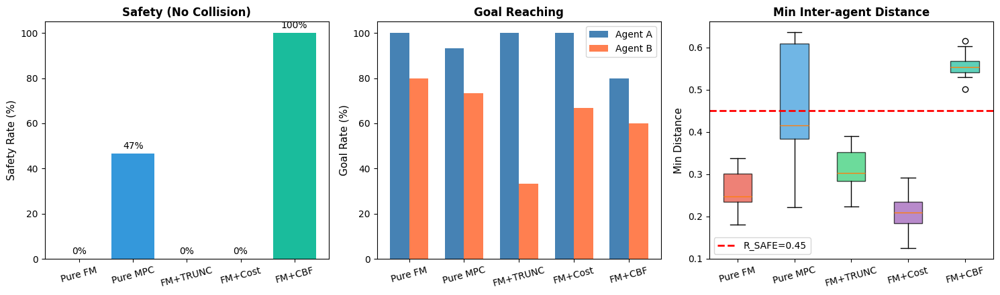

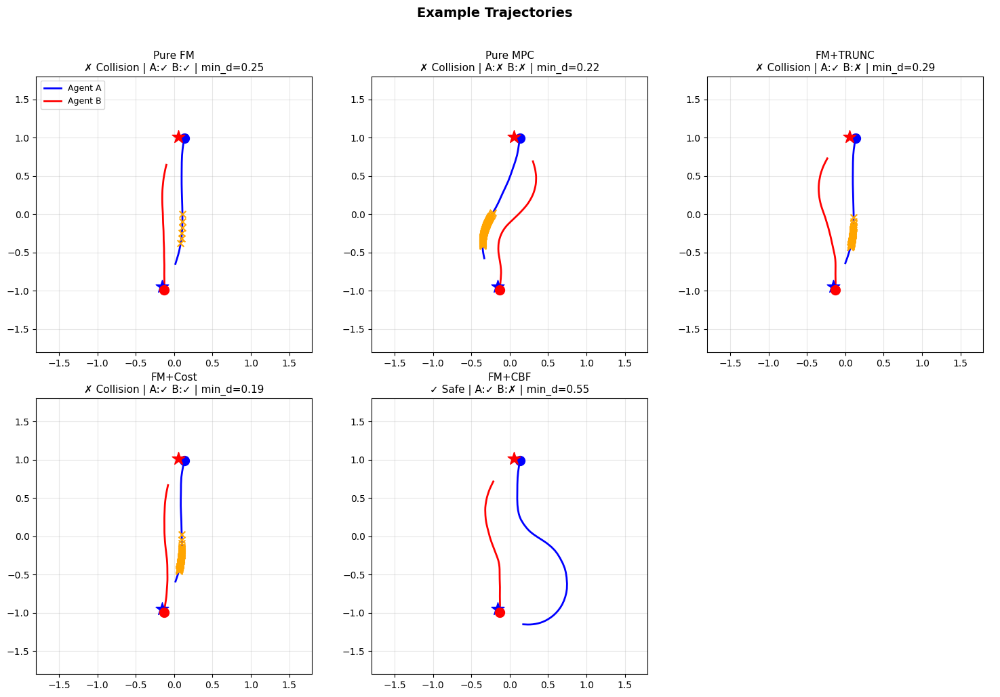

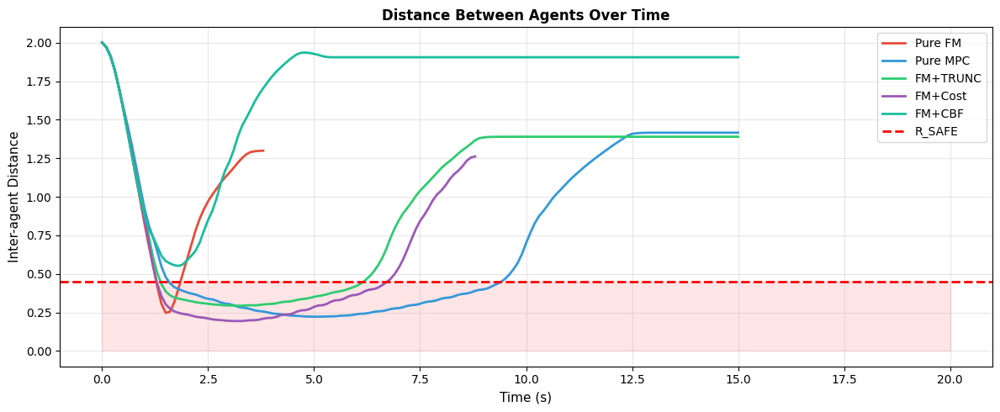


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [19]:
# ===============================================================
# 消融实验 v3：修复所有方法的避障逻辑
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass 
class Config:
    n_trials: int = 15
    max_steps: int = 150
    dt: float = 0.1
    goal_tol: float = 0.40
    R_SAFE: float = 0.45
    arena_size: float = 1.0
    
    H: int = 8
    K: int = 1
    T_steps: int = 25
    num_segments: int = 2
    replan_every: int = 2

cfg = Config()

DIRECT_TO_GOAL_DIST = 1.2
BLEND_DIST = 0.6

v_max_A, v_max_B = 1.0, 0.6
a_max = 1.5
L = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
stop_radius = 0.45
creep_radius = 1.0
v_creep = 0.15

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, 0, v_max))
    if v2 < 0.05 and a > 0.02:
        v2 = 0.05
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = [s0.copy()]
    for u in U:
        st.append(bicycle_step(st[-1], u, dt, v_max))
    return np.array(st)

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c, s = d[0]/dist, d[1]/dist
    R_wc = np.array([[c, s], [-s, c]], np.float32)
    
    def w2c(xy):
        return ((np.asarray(xy).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy).reshape(-1,2) @ R_wc + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32), 
            "goal_can": np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(other_u.reshape(1,2), (H, 1))
    return rollout_bicycle(other_state, U, dt, v_max)[:, :2]

# ===============================================================
# Pure Pursuit（带后期朝目标 + 紧急避障）
# ===============================================================
def pure_pursuit_with_avoidance(s0, path_xy, goal_xy, other_pos, H, dt, v_max):
    """Pure Pursuit + 简单的紧急避障（当太近时减速）"""
    s = s0.copy()
    U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    
    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        
        # 检查与对方的距离
        if other_pos is not None and i < len(other_pos):
            d_other = float(np.linalg.norm(pos - other_pos[i]))
        else:
            d_other = 10.0
        
        # 停车
        if d_goal <= stop_radius:
            a = float(np.clip(-4.0 * v, -a_max, 0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue
        
        # Lookahead
        Ld = float(np.clip(0.4 + 0.5 * v, 0.3, 0.9))
        
        # 找路径目标点
        dists = np.linalg.norm(path_xy - pos, axis=1)
        near_idx = int(np.argmin(dists))
        path_target = path_xy[-1]
        for j in range(near_idx, len(path_xy)):
            if np.linalg.norm(path_xy[j] - pos) >= Ld:
                path_target = path_xy[j]
                break
        
        # 后期混合
        if d_goal < DIRECT_TO_GOAL_DIST:
            blend = 1.0 if d_goal < BLEND_DIST else (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
            blend = float(np.clip(blend, 0, 1))
            target = (1 - blend) * path_target + blend * goal_xy
        else:
            target = path_target
        
        # 转向
        dx, dy = target[0] - x, target[1] - y
        alpha = wrap_pi(math.atan2(dy, dx) - th)
        kappa = 2.0 * math.sin(alpha) / max(0.1, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        
        # 速度
        v_des = v_max if d_goal > creep_radius else v_creep + (v_max - v_creep) * d_goal / creep_radius
        v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
        
        # ★ 紧急避障：如果太近就减速
        if d_other < cfg.R_SAFE * 1.5:
            slow_factor = max(0.1, (d_other - cfg.R_SAFE * 0.8) / (cfg.R_SAFE * 0.7))
            v_des *= slow_factor
        
        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)
    
    return U

# ===============================================================
# FM 采样
# ===============================================================
def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    x0 = torch.randn((1, 5, T), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0
    return x0

def sample_fm_fast(self_state, goal_xy, other_pos, seed, use_cbf=False, cbf_kw=None):
    tf = build_canonical_frame(self_state[:2], goal_xy)
    
    ellipses = []
    if use_cbf and other_pos is not None and len(other_pos) > 0:
        dist_AB = np.linalg.norm(self_state[:2] - other_pos[0])
        if dist_AB < 2.0:
            for i in [0, 1, 2]:
                if i < len(other_pos):
                    c = tf["w2c"](other_pos[i:i+1])[0]
                    ellipses.append({"center": c, "radius": 0.35})
    
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    cond = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), self_state[4]], np.float32)
    
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=1.0, num_segments=cfg.num_segments, ode_method="euler",
        atol=1e-3, rtol=1e-3, noise_scale=0.08,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.4, goal_guidance_weight=1.2,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=use_cbf, ellipses=ellipses, cbf_kwargs=cbf_kw, scaler=None,
    )
    
    return tf["c2w"](x_can[0:2, :].T)

# ===============================================================
# 生成避障路径（用于非 FM 方法）
# ===============================================================
def generate_avoidance_path(start, goal, other_pos, T):
    """生成绕行路径"""
    start = np.asarray(start, np.float32)
    goal = np.asarray(goal, np.float32)
    
    t = np.linspace(0, 1, T).reshape(-1, 1)
    path = start + t * (goal - start)
    
    if other_pos is None or len(other_pos) == 0:
        return path
    
    other_now = other_pos[0]
    dist_to_other = np.linalg.norm(start - other_now)
    
    if dist_to_other < 1.8:
        to_goal = goal - start
        to_goal_norm = np.linalg.norm(to_goal) + 1e-6
        to_goal_unit = to_goal / to_goal_norm
        
        # 垂直方向
        perp = np.array([-to_goal_unit[1], to_goal_unit[0]], dtype=np.float32)
        
        # 判断绕行方向
        to_other = other_now - start
        cross = to_goal[0] * to_other[1] - to_goal[1] * to_other[0]
        side = -1.0 if cross > 0 else 1.0
        
        # 绕行幅度根据距离调整
        avoidance_strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        
        # 生成弯曲路径
        for i, ti in enumerate(t.flatten()):
            bulge = avoidance_strength * np.sin(np.pi * ti) * side
            path[i] = start + ti * to_goal + bulge * perp
    
    return path

# ===============================================================
# 方法 1: Pure FM (No CBF) - 只有 FM，无避障
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    # 无避障，直接用 path
    U = pure_pursuit_with_avoidance(sA, path, gA, None, cfg.H, cfg.dt, v_max_self)  # other_pos=None 禁用紧急避障
    return U[0], 0

# ===============================================================
# 方法 2: Pure MPC (No FM) - 几何绕行 + 紧急避障
# ===============================================================
def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = generate_avoidance_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 0

# ===============================================================
# 方法 3: FM + TRUNC - FM 生成 + 截断 + 紧急避障
# ===============================================================
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2:
            if i > 2:
                # 截断后用绕行路径补充
                remaining_path = generate_avoidance_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
                path = np.vstack([path[:i], remaining_path])
            break
    
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 0

# ===============================================================
# 方法 4: FM + Cost Guidance - FM 多候选 + cost 选择 + 紧急避障
# ===============================================================
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    
    best_u, best_J = None, float('inf')
    for k in range(3):  # 3 个候选
        path = sample_fm_fast(sA, gA, other_pos, seed + k*100, use_cbf=False)
        U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
        traj = rollout_bicycle(sA, U, cfg.dt, v_max_self)
        
        # Cost
        d_end = np.linalg.norm(traj[-1, :2] - gA)
        M = min(len(traj), len(other_pos))
        min_d = np.linalg.norm(traj[:M, :2] - other_pos[:M], axis=1).min() if M > 1 else 10
        
        # 高碰撞惩罚
        if min_d < cfg.R_SAFE:
            coll = 1000 * (cfg.R_SAFE - min_d)**2 + 50
        else:
            coll = 0
        
        J = 15 * d_end + coll
        
        if J < best_J:
            best_J, best_u = J, U[0]
    
    return best_u if best_u is not None else np.zeros(2, np.float32), 0

# ===============================================================
# 方法 5: FM + CBF (Ours) - FM + CBF 修正 + 紧急避障
# ===============================================================
CBF_KW = dict(passes=3, extra_margin=0.15, alpha=18.0, max_corr_norm=2.5)

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=True, cbf_kw=CBF_KW)
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 1

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    
    ang = np.random.uniform(0, 2*np.pi)
    r = cfg.arena_size
    xA0 = r * np.array([np.cos(ang), np.sin(ang)], np.float32)
    gA = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    xB0 = r * np.array([np.cos(ang + np.pi), np.sin(ang + np.pi)], np.float32)
    gB = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    
    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])
    
    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)
    
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0
    
    for step in range(cfg.max_steps):
        dA = np.linalg.norm(sA[:2] - gA)
        dB = np.linalg.norm(sB[:2] - gB)
        doneA = dA < cfg.goal_tol and sA[3] < 0.1
        doneB = dB < cfg.goal_tol and sB[3] < 0.1
        
        if doneA and doneB:
            break
        
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step)
                cbf_used += c
        
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
        
        trajA.append(sA.copy())
        trajB.append(sB.copy())
    
    trajA, trajB = np.array(trajA), np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    
    result = {
        'success_A': np.linalg.norm(trajA[-1, :2] - gA) < cfg.goal_tol,
        'success_B': np.linalg.norm(trajB[-1, :2] - gB) < cfg.goal_tol,
        'collision': dist_AB.min() < cfg.R_SAFE,
        'min_dist': float(dist_AB.min()),
        'steps': len(trajA),
        'cbf_used': cbf_used,
    }
    
    if return_traj:
        result['trajA'] = trajA
        result['trajB'] = trajB
        result['gA'] = gA
        result['gB'] = gB
        result['xA0'] = xA0
        result['xB0'] = xB0
        result['dist_AB'] = dist_AB
    
    return result

# ===============================================================
# 运行实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM": replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost": replan_fm_cost,
        "FM+CBF": replan_fm_cbf,
    }
    
    results = defaultdict(list)
    example_trajs = {}
    
    print("=" * 60)
    print(f"Ablation Study v3 | Trials={cfg.n_trials}")
    print("=" * 60)
    
    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial * 77, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        
        print(f" {time.time()-t0:.1f}s")
    
    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "=" * 75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-" * 75)
    
    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA = sum(1 for r in rs if r['success_A']) / n * 100
        goalB = sum(1 for r in rs if r['success_B']) / n * 100
        min_d = np.mean([r['min_dist'] for r in rs])
        steps = np.mean([r['steps'] for r in rs])
        
        summary[name] = {'safety': safety, 'goalA': goalA, 'goalB': goalB, 'min_d': min_d, 'steps': steps}
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% {min_d:>8.3f} {steps:>6.0f}")
    
    print("=" * 75)
    
    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    names = list(summary.keys())
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']
    
    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[1]
    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x + w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 105)
    
    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend()
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()
    
    # 轨迹图
    n_methods = len(example_trajs)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        
        trajA, trajB = data['trajA'], data['trajB']
        gA, gB = data['gA'], data['gB']
        xA0, xB0 = data['xA0'], data['xB0']
        dist_AB = data['dist_AB']
        
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')
        
        ax.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', zorder=5)
        ax.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', zorder=5)
        ax.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', zorder=5)
        ax.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', zorder=5)
        
        coll_idx = np.where(dist_AB < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='orange', s=50, marker='x', zorder=6)
        
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        
        status = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_status = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_status} | min_d={data['min_dist']:.2f}", fontsize=11)
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9)
    
    for idx in range(n_methods, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE')
    ax.fill_between([0, 20], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()
    
    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v3 (with proper avoidance)...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v3 (with proper avoidance)...

Ablation Study v3 | Trials=1
>>> Pure FM  0.9s
>>> Pure MPC  0.1s
>>> FM+TRUNC  2.9s
>>> FM+Cost  11.0s
>>> FM+CBF  2.1s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%   100.0%    0.098     35
Pure MPC         0.0%     0.0%     0.0%    0.222    151
FM+TRUNC         0.0%     0.0%   100.0%    0.284    151
FM+Cost          0.0%     0.0%     0.0%    0.085    151
FM+CBF           0.0%   100.0%   100.0%    0.093     83


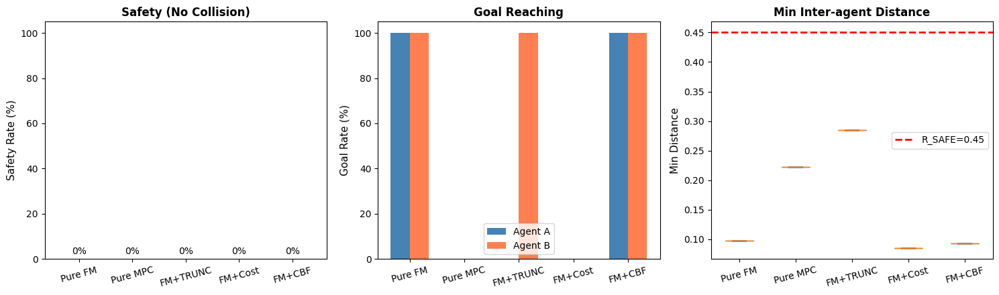

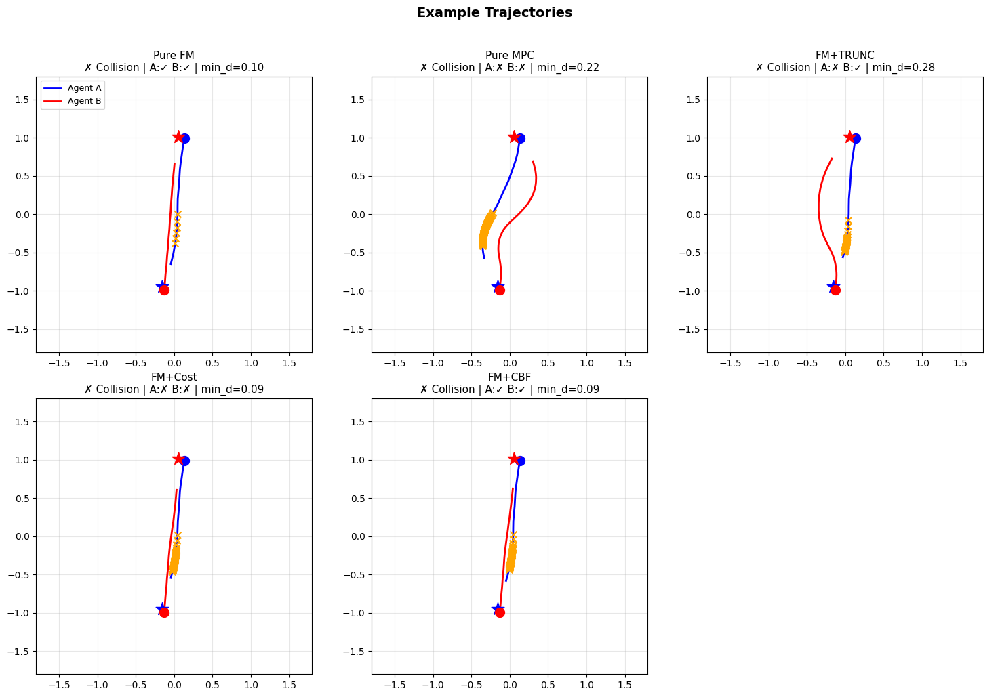

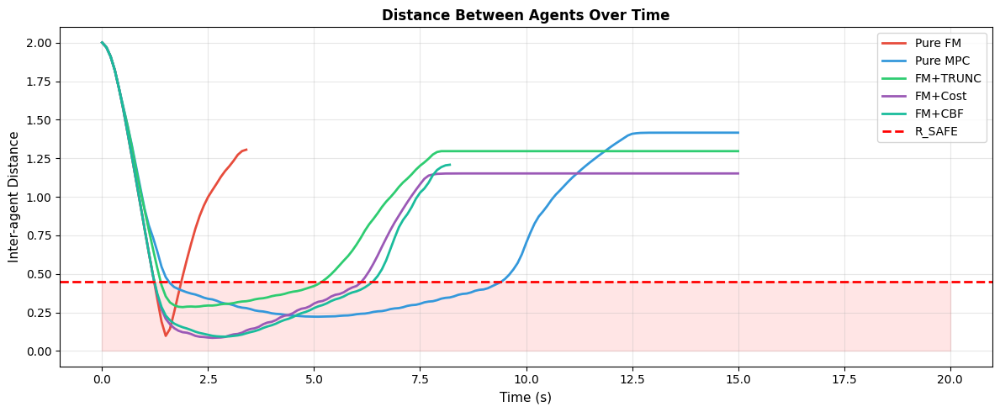


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [16]:
# ===============================================================
# 消融实验 v3：修复所有方法的避障逻辑
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass 
class Config:
    n_trials: int = 1
    max_steps: int = 150
    dt: float = 0.1
    goal_tol: float = 0.40
    R_SAFE: float = 0.45
    arena_size: float = 1.0
    
    H: int = 8
    K: int = 1
    T_steps: int = 25
    num_segments: int = 2
    replan_every: int = 2

cfg = Config()

DIRECT_TO_GOAL_DIST = 1.2
BLEND_DIST = 0.6

v_max_A, v_max_B = 1.0, 0.6
a_max = 1.5
L = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
stop_radius = 0.45
creep_radius = 1.0
v_creep = 0.15

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, 0, v_max))
    if v2 < 0.05 and a > 0.02:
        v2 = 0.05
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = [s0.copy()]
    for u in U:
        st.append(bicycle_step(st[-1], u, dt, v_max))
    return np.array(st)

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c, s = d[0]/dist, d[1]/dist
    R_wc = np.array([[c, s], [-s, c]], np.float32)
    
    def w2c(xy):
        return ((np.asarray(xy).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy).reshape(-1,2) @ R_wc + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32), 
            "goal_can": np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(other_u.reshape(1,2), (H, 1))
    return rollout_bicycle(other_state, U, dt, v_max)[:, :2]

# ===============================================================
# Pure Pursuit（带后期朝目标 + 紧急避障）
# ===============================================================
def pure_pursuit_with_avoidance(s0, path_xy, goal_xy, other_pos, H, dt, v_max):
    """Pure Pursuit + 简单的紧急避障（当太近时减速）"""
    s = s0.copy()
    U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    
    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        
        # 检查与对方的距离
        if other_pos is not None and i < len(other_pos):
            d_other = float(np.linalg.norm(pos - other_pos[i]))
        else:
            d_other = 10.0
        
        # 停车
        if d_goal <= stop_radius:
            a = float(np.clip(-4.0 * v, -a_max, 0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue
        
        # Lookahead
        Ld = float(np.clip(0.4 + 0.5 * v, 0.3, 0.9))
        
        # 找路径目标点
        dists = np.linalg.norm(path_xy - pos, axis=1)
        near_idx = int(np.argmin(dists))
        path_target = path_xy[-1]
        for j in range(near_idx, len(path_xy)):
            if np.linalg.norm(path_xy[j] - pos) >= Ld:
                path_target = path_xy[j]
                break
        
        # 后期混合
        if d_goal < DIRECT_TO_GOAL_DIST:
            blend = 1.0 if d_goal < BLEND_DIST else (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
            blend = float(np.clip(blend, 0, 1))
            target = (1 - blend) * path_target + blend * goal_xy
        else:
            target = path_target
        
        # 转向
        dx, dy = target[0] - x, target[1] - y
        alpha = wrap_pi(math.atan2(dy, dx) - th)
        kappa = 2.0 * math.sin(alpha) / max(0.1, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        
        # 速度
        v_des = v_max if d_goal > creep_radius else v_creep + (v_max - v_creep) * d_goal / creep_radius
        v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
        
        # ★ 紧急避障：如果太近就减速
        if d_other < cfg.R_SAFE * 1.5:
            slow_factor = max(0.1, (d_other - cfg.R_SAFE * 0.8) / (cfg.R_SAFE * 0.7))
            v_des *= slow_factor
        
        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)
    
    return U

# ===============================================================
# FM 采样
# ===============================================================
def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    x0 = torch.randn((1, 5, T), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0
    return x0

def sample_fm_fast(self_state, goal_xy, other_pos, seed, use_cbf=False, cbf_kw=None):
    tf = build_canonical_frame(self_state[:2], goal_xy)
    
    ellipses = []
    if use_cbf and other_pos is not None and len(other_pos) > 0:
        dist_AB = np.linalg.norm(self_state[:2] - other_pos[0])
        if dist_AB < 2.0:
            for i in [0, 1, 2]:
                if i < len(other_pos):
                    c = tf["w2c"](other_pos[i:i+1])[0]
                    ellipses.append({"center": c, "radius": 0.35})
    
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    cond = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), self_state[4]], np.float32)
    
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=1.0, num_segments=cfg.num_segments, ode_method="euler",
        atol=1e-3, rtol=1e-3, noise_scale=0.08,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.4, goal_guidance_weight=1.2,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=use_cbf, ellipses=ellipses, cbf_kwargs=cbf_kw, scaler=None,
    )
    
    return tf["c2w"](x_can[0:2, :].T)

# ===============================================================
# 生成避障路径（用于非 FM 方法）
# ===============================================================
def generate_avoidance_path(start, goal, other_pos, T):
    """生成绕行路径"""
    start = np.asarray(start, np.float32)
    goal = np.asarray(goal, np.float32)
    
    t = np.linspace(0, 1, T).reshape(-1, 1)
    path = start + t * (goal - start)
    
    if other_pos is None or len(other_pos) == 0:
        return path
    
    other_now = other_pos[0]
    dist_to_other = np.linalg.norm(start - other_now)
    
    if dist_to_other < 1.8:
        to_goal = goal - start
        to_goal_norm = np.linalg.norm(to_goal) + 1e-6
        to_goal_unit = to_goal / to_goal_norm
        
        # 垂直方向
        perp = np.array([-to_goal_unit[1], to_goal_unit[0]], dtype=np.float32)
        
        # 判断绕行方向
        to_other = other_now - start
        cross = to_goal[0] * to_other[1] - to_goal[1] * to_other[0]
        side = -1.0 if cross > 0 else 1.0
        
        # 绕行幅度根据距离调整
        avoidance_strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        
        # 生成弯曲路径
        for i, ti in enumerate(t.flatten()):
            bulge = avoidance_strength * np.sin(np.pi * ti) * side
            path[i] = start + ti * to_goal + bulge * perp
    
    return path

# ===============================================================
# 方法 1: Pure FM (No CBF) - 只有 FM，无避障
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    # 无避障，直接用 path
    U = pure_pursuit_with_avoidance(sA, path, gA, None, cfg.H, cfg.dt, v_max_self)  # other_pos=None 禁用紧急避障
    return U[0], 0

# ===============================================================
# 方法 2: Pure MPC (No FM) - 几何绕行 + 紧急避障
# ===============================================================
def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = generate_avoidance_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 0

# ===============================================================
# 方法 3: FM + TRUNC - FM 生成 + 截断 + 紧急避障
# ===============================================================
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2:
            if i > 2:
                # 截断后用绕行路径补充
                remaining_path = generate_avoidance_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
                path = np.vstack([path[:i], remaining_path])
            break
    
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 0

# ===============================================================
# 方法 4: FM + Cost Guidance - FM 多候选 + cost 选择 + 紧急避障
# ===============================================================
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    
    best_u, best_J = None, float('inf')
    for k in range(3):  # 3 个候选
        path = sample_fm_fast(sA, gA, other_pos, seed + k*100, use_cbf=False)
        U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
        traj = rollout_bicycle(sA, U, cfg.dt, v_max_self)
        
        # Cost
        d_end = np.linalg.norm(traj[-1, :2] - gA)
        M = min(len(traj), len(other_pos))
        min_d = np.linalg.norm(traj[:M, :2] - other_pos[:M], axis=1).min() if M > 1 else 10
        
        # 高碰撞惩罚
        if min_d < cfg.R_SAFE:
            coll = 1000 * (cfg.R_SAFE - min_d)**2 + 50
        else:
            coll = 0
        
        J = 15 * d_end + coll
        
        if J < best_J:
            best_J, best_u = J, U[0]
    
    return best_u if best_u is not None else np.zeros(2, np.float32), 0

# ===============================================================
# 方法 5: FM + CBF (Ours) - FM + CBF 修正 + 紧急避障
# ===============================================================
CBF_KW = dict(passes=3, extra_margin=0.15, alpha=18.0, max_corr_norm=2.5)

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=True, cbf_kw=CBF_KW)
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 1

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    
    ang = np.random.uniform(0, 2*np.pi)
    r = cfg.arena_size
    xA0 = r * np.array([np.cos(ang), np.sin(ang)], np.float32)
    gA = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    xB0 = r * np.array([np.cos(ang + np.pi), np.sin(ang + np.pi)], np.float32)
    gB = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    
    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])
    
    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)
    
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0
    
    for step in range(cfg.max_steps):
        dA = np.linalg.norm(sA[:2] - gA)
        dB = np.linalg.norm(sB[:2] - gB)
        doneA = dA < cfg.goal_tol and sA[3] < 0.1
        doneB = dB < cfg.goal_tol and sB[3] < 0.1
        
        if doneA and doneB:
            break
        
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step)
                cbf_used += c
        
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
        
        trajA.append(sA.copy())
        trajB.append(sB.copy())
    
    trajA, trajB = np.array(trajA), np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    
    result = {
        'success_A': np.linalg.norm(trajA[-1, :2] - gA) < cfg.goal_tol,
        'success_B': np.linalg.norm(trajB[-1, :2] - gB) < cfg.goal_tol,
        'collision': dist_AB.min() < cfg.R_SAFE,
        'min_dist': float(dist_AB.min()),
        'steps': len(trajA),
        'cbf_used': cbf_used,
    }
    
    if return_traj:
        result['trajA'] = trajA
        result['trajB'] = trajB
        result['gA'] = gA
        result['gB'] = gB
        result['xA0'] = xA0
        result['xB0'] = xB0
        result['dist_AB'] = dist_AB
    
    return result

# ===============================================================
# 运行实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM": replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost": replan_fm_cost,
        "FM+CBF": replan_fm_cbf,
    }
    
    results = defaultdict(list)
    example_trajs = {}
    
    print("=" * 60)
    print(f"Ablation Study v3 | Trials={cfg.n_trials}")
    print("=" * 60)
    
    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial * 77, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        
        print(f" {time.time()-t0:.1f}s")
    
    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "=" * 75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-" * 75)
    
    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA = sum(1 for r in rs if r['success_A']) / n * 100
        goalB = sum(1 for r in rs if r['success_B']) / n * 100
        min_d = np.mean([r['min_dist'] for r in rs])
        steps = np.mean([r['steps'] for r in rs])
        
        summary[name] = {'safety': safety, 'goalA': goalA, 'goalB': goalB, 'min_d': min_d, 'steps': steps}
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% {min_d:>8.3f} {steps:>6.0f}")
    
    print("=" * 75)
    
    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    names = list(summary.keys())
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']
    
    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[1]
    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x + w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 105)
    
    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend()
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()
    
    # 轨迹图
    n_methods = len(example_trajs)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        
        trajA, trajB = data['trajA'], data['trajB']
        gA, gB = data['gA'], data['gB']
        xA0, xB0 = data['xA0'], data['xB0']
        dist_AB = data['dist_AB']
        
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')
        
        ax.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', zorder=5)
        ax.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', zorder=5)
        ax.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', zorder=5)
        ax.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', zorder=5)
        
        coll_idx = np.where(dist_AB < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='orange', s=50, marker='x', zorder=6)
        
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        
        status = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_status = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_status} | min_d={data['min_dist']:.2f}", fontsize=11)
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9)
    
    for idx in range(n_methods, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE')
    ax.fill_between([0, 20], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()
    
    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v3 (with proper avoidance)...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

In [15]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 15
    max_steps: int = 300      # 与两车实验一致
    dt: float = 0.1
    goal_tol: float = 0.20    # ★ 0.40→0.20
    R_SAFE: float = 0.45
    arena_size: float = 1.2   # ★ 与两车实验起点一致
    H: int = 12               # ★ 8→12
    K: int = 8                # ★ 1→8
    T_steps: int = 40         # ★ 25→40
    num_segments: int = 5     # ★ 2→5
    replan_every: int = 1     # ★ 2→1

cfg = Config()

# ★ 与两车实验完全一致的参数
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

# ★ 路径质量过滤参数（与两车实验一致）
PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

# FM 参数
noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# ===============================================================
# 基础函数（与两车实验完全一致）
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit（与两车实验完全一致）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# ★ check_path_quality（与两车实验完全一致）
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# ★ Fallback 控制（与两车实验完全一致）
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（与两车实验一致）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, CBF_LIGHT
    else:                          return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心（K候选 + check_path_quality + fallback）
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st          = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self    = st[:, :2]
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法（消融对比）
# ===============================================================

# 方法1: Pure FM（无CBF，K=1，无质量过滤）
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法2: Pure MPC（几何绕行路径 + pure pursuit，无FM）
def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal,  np.float32)
    t     = np.linspace(0, 1, T).reshape(-1,1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path
    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0]*(other_pos[0][1]-start[1]) - to_goal[1]*(other_pos[0][0]-start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法3: FM + TRUNC（FM生成，碰撞点截断后接几何绕行）
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法4: FM + Cost（多候选FM，cost选最优，无CBF，有check_path_quality）
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self,
                       seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

# 方法5: FM + CBF (Ours) — 与两车实验完全一致
def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),        np.sin(ang)],        np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi),  np.sin(ang+np.pi)],  np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol   # ★ 去掉速度条件，与两车实验一致
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    result = {
        'success_A':  float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':  float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':  bool(dist_AB.min() < cfg.R_SAFE),
        'min_dist':   float(dist_AB.min()),
        'steps':      len(trajA),
        'cbf_used':   cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":   replan_pure_fm,
        "Pure MPC":  replan_pure_mpc,
        "FM+TRUNC":  replan_fm_trunc,
        "FM+Cost":   replan_fm_cost,
        "FM+CBF":    replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 60)
    print(f"Ablation v4 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 60)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-"*75)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA  = sum(1 for r in rs if r['success_A'])    / n * 100
        goalB  = sum(1 for r in rs if r['success_B'])    / n * 100
        min_d  = np.mean([r['min_dist'] for r in rs])
        steps  = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safety=safety, goalA=goalA, goalB=goalB,
                              min_d=min_d, steps=steps)
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}")
    print("="*75)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    ax = axes[1]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 105)

    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend(); ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=50, marker='x', zorder=6)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
        status    = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0: ax.legend(loc='upper left', fontsize=9)
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11); ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v4...

Ablation v4 | Trials=15 | goal_tol=0.2 | K=8
>>> Pure FM .

KeyboardInterrupt: 

Starting Ablation v4...

Ablation v4 | Trials=1 | goal_tol=0.2 | K=1
>>> Pure FM  3.6s
>>> Pure MPC  0.1s
>>> FM+TRUNC  23.1s
>>> FM+Cost  8.6s
>>> FM+CBF  12.0s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%   100.0%    0.092     53
Pure MPC         0.0%   100.0%   100.0%    0.244     83
FM+TRUNC         0.0%     0.0%     0.0%    0.444    301
FM+Cost          0.0%   100.0%   100.0%    0.044    124
FM+CBF           0.0%   100.0%   100.0%    0.222    129


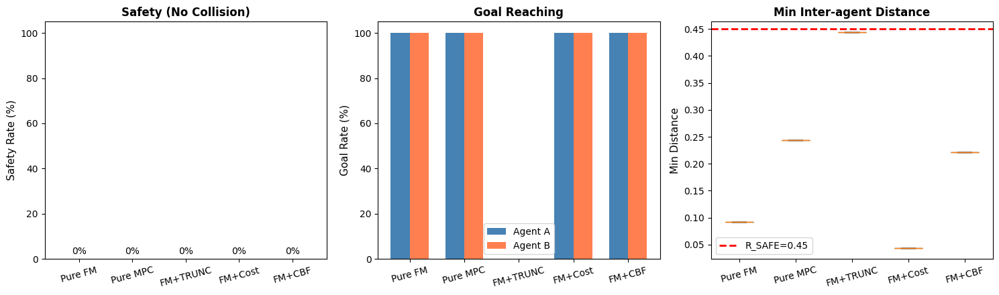

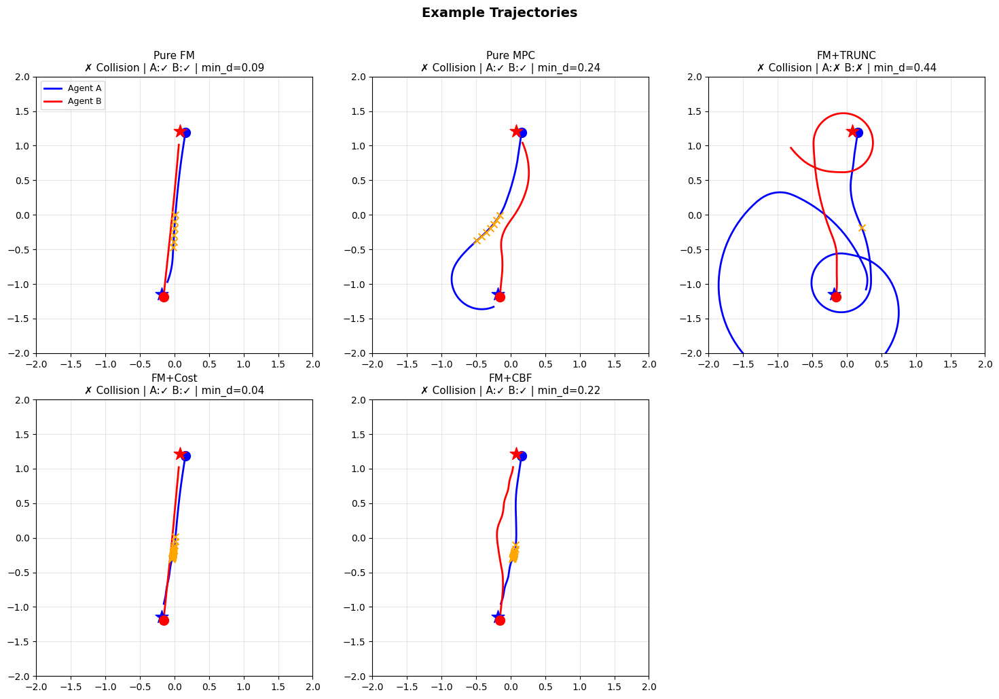

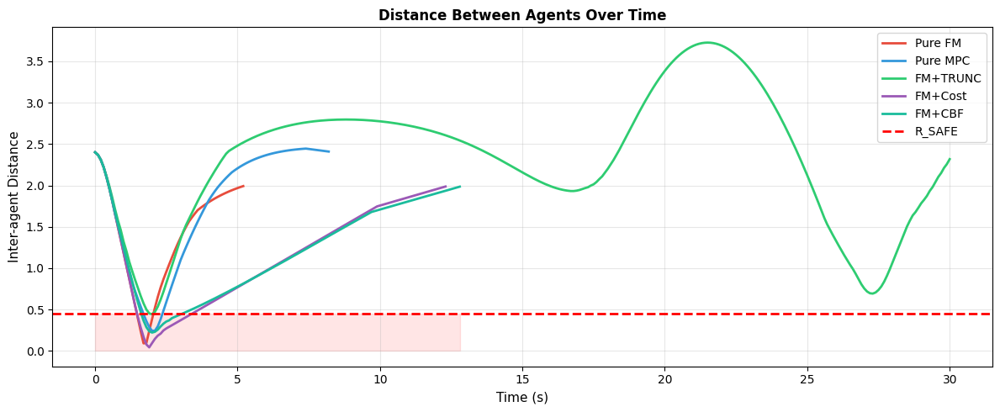


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [18]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300      # 与两车实验一致
    dt: float = 0.1
    goal_tol: float = 0.20    # ★ 0.40→0.20
    R_SAFE: float = 0.45
    arena_size: float = 1.2   # ★ 与两车实验起点一致
    H: int = 12               # ★ 8→12
    K: int = 1                # ★ 1→8
    T_steps: int = 40         # ★ 25→40
    num_segments: int = 5     # ★ 2→5
    replan_every: int = 1     # ★ 2→1

cfg = Config()

# ★ 与两车实验完全一致的参数
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

# ★ 路径质量过滤参数（与两车实验一致）
PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

# FM 参数
noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# ===============================================================
# 基础函数（与两车实验完全一致）
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit（与两车实验完全一致）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# ★ check_path_quality（与两车实验完全一致）
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# ★ Fallback 控制（与两车实验完全一致）
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（与两车实验一致）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, CBF_LIGHT
    else:                          return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心（K候选 + check_path_quality + fallback）
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st          = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self    = st[:, :2]
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法（消融对比）
# ===============================================================

# 方法1: Pure FM（无CBF，K=1，无质量过滤）
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法2: Pure MPC（几何绕行路径 + pure pursuit，无FM）
def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal,  np.float32)
    t     = np.linspace(0, 1, T).reshape(-1,1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path
    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0]*(other_pos[0][1]-start[1]) - to_goal[1]*(other_pos[0][0]-start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法3: FM + TRUNC（FM生成，碰撞点截断后接几何绕行）
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法4: FM + Cost（多候选FM，cost选最优，无CBF，有check_path_quality）
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self,
                       seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

# 方法5: FM + CBF (Ours) — 与两车实验完全一致
def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),        np.sin(ang)],        np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi),  np.sin(ang+np.pi)],  np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol   # ★ 去掉速度条件，与两车实验一致
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    result = {
        'success_A':  float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':  float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':  bool(dist_AB.min() < cfg.R_SAFE),
        'min_dist':   float(dist_AB.min()),
        'steps':      len(trajA),
        'cbf_used':   cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":   replan_pure_fm,
        "Pure MPC":  replan_pure_mpc,
        "FM+TRUNC":  replan_fm_trunc,
        "FM+Cost":   replan_fm_cost,
        "FM+CBF":    replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 60)
    print(f"Ablation v4 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 60)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-"*75)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA  = sum(1 for r in rs if r['success_A'])    / n * 100
        goalB  = sum(1 for r in rs if r['success_B'])    / n * 100
        min_d  = np.mean([r['min_dist'] for r in rs])
        steps  = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safety=safety, goalA=goalA, goalB=goalB,
                              min_d=min_d, steps=steps)
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}")
    print("="*75)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    ax = axes[1]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 105)

    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend(); ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=50, marker='x', zorder=6)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
        status    = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0: ax.legend(loc='upper left', fontsize=9)
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11); ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

In [ ]:
# ===============================================================
# Pure MPC 专用参数
# ===============================================================
K_MPC      = 64
SIGMA_A    = 0.6
SIGMA_DR   = np.deg2rad(45.0)
MPC_LAMBDA = 0.05

# MPC 专用 cost 权重（比 FM 方法更复杂）
W_MPC_END      = 20.0
W_MPC_PATH     = 3.0
W_MPC_COLL     = 500.0
W_MPC_SMOOTH   = 1.5
W_MPC_HEADING  = 2.0   # ★ 朝向偏差惩罚
W_MPC_VEL      = 1.0   # ★ 速度偏离期望惩罚
W_MPC_JERK     = 0.8   # ★ jerk（加速度变化率）惩罚

def _rk4_bicycle_step(s, u, dt, v_max):
    """RK4 单步积分（比 Euler 更精确，计算量更大）"""
    def f(s_):
        x, y, th, v, delta = s_
        a      = float(np.clip(u[0], -a_max, a_max))
        dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2     = float(np.clip(v + 0.0, v_min, v_max))   # 当前速度
        delta2 = float(np.clip(delta + 0.0, -delta_max, delta_max))
        dth    = (v2 / L) * math.tan(delta2)
        dx_    = v2 * math.cos(th)
        dy_    = v2 * math.sin(th)
        dv_    = a
        dd_    = dr
        return np.array([dx_, dy_, dth, dv_, dd_], np.float32)

    k1 = f(s)
    k2 = f(s + 0.5*dt*k1)
    k3 = f(s + 0.5*dt*k2)
    k4 = f(s + dt*k3)
    s_new = s + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

    # 约束裁剪
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _rk4_rollout(s0, U, dt, v_max):
    """RK4 rollout，替代 Euler rollout_bicycle"""
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    for i in range(H):
        st[i+1] = _rk4_bicycle_step(st[i], U[i], dt, v_max)
    return st

def _compute_mpc_cost(traj, U, goal_xy, other_pos, v_max_self):
    """
    MPC 专用 cost，比 FM 方法更复杂：
      - goal distance（终点 + 路径均值）
      - agent-agent collision
      - heading alignment（朝向偏差）
      - velocity tracking（速度偏离期望）
      - smoothness（控制量变化）
      - jerk（加速度变化率）
    """
    goal_xy = np.asarray(goal_xy, np.float32)
    pos     = traj[:, :2]
    th      = traj[:, 2]
    vel     = traj[:, 3]

    # 1. goal cost
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos - goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END * d_end + W_MPC_PATH * d_path

    # 2. collision cost（agent-agent）
    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos[:M] - other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol

    # 3. ★ heading alignment cost
    # 每一步朝向应该指向目标方向
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]   # (H, 2)
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    # 靠近目标时权重更大
    d_to_goal   = np.linalg.norm(pos[:-1] - goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal / 3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))

    # 4. ★ velocity tracking cost
    # 期望速度：离目标远时 v_max，近时减速
    d_goals  = np.linalg.norm(pos - goal_xy.reshape(1,2), axis=1)
    v_des    = np.where(d_goals > creep_radius,
                        v_max_self,
                        v_creep + (v_max_self - v_creep) * d_goals / creep_radius)
    v_err    = vel - v_des
    J_vel    = W_MPC_VEL * float(np.mean(v_err**2))

    # 5. smoothness cost（控制量一阶差分）
    dU       = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth = W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    # 6. ★ jerk cost（控制量二阶差分）
    ddU     = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk  = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))

    return J_goal + J_coll + J_heading + J_vel + J_smooth + J_jerk


def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """
    真正的 Receding Horizon MPC：
      - RK4 rollout（比 Euler 慢但更精确）
      - 复杂 cost（heading + velocity + jerk）
      - K=64 候选 + MPPI cost-weighted update
    """
    rng       = np.random.RandomState(seed)
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)

    # nominal：直线路径 Pure Pursuit 热启动
    straight = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    U_nom    = pure_pursuit_controls(
        sA, straight, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)

    # 采样扰动
    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR

    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k       = U_nom.copy()
        U_k[:,0]  = np.clip(U_nom[:,0] + eps_a[k],  -a_max, a_max)
        U_k[:,1]  = np.clip(U_nom[:,1] + eps_dr[k],
                            -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k

    # ★ RK4 rollout + 复杂 cost
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj     = _rk4_rollout(sA, U_samples[k], cfg.dt, v_max_self)
        costs[k] = _compute_mpc_cost(
            traj, U_samples[k], gA, other_pos, v_max_self)

    # MPPI cost-weighted update → receding horizon 取第一步
    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)

    return U_mpc[0].copy(), 0

Starting Ablation v4...

Ablation v4 | Trials=1 | goal_tol=0.2 | K=1
>>> Pure FM  2.4s
>>> Pure MPC  30.9s
>>> FM+TRUNC  2.6s
>>> FM+Cost  4.4s
>>> FM+CBF  4.7s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%   100.0%    0.215    116
Pure MPC         0.0%   100.0%   100.0%    0.081    111
FM+TRUNC       100.0%   100.0%   100.0%    0.320    117
FM+Cost          0.0%   100.0%   100.0%    0.197    206
FM+CBF           0.0%   100.0%   100.0%    0.197    206


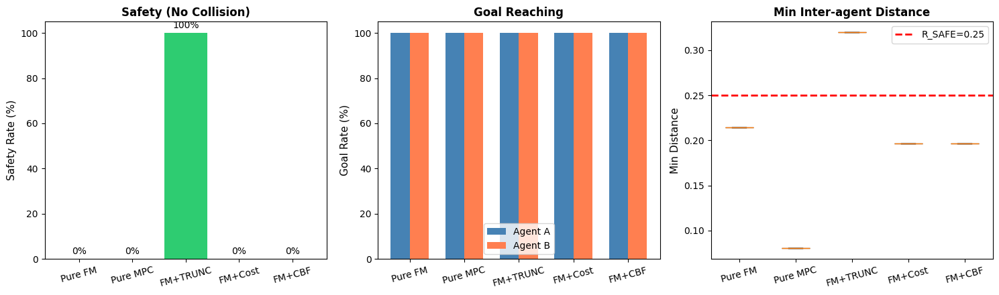

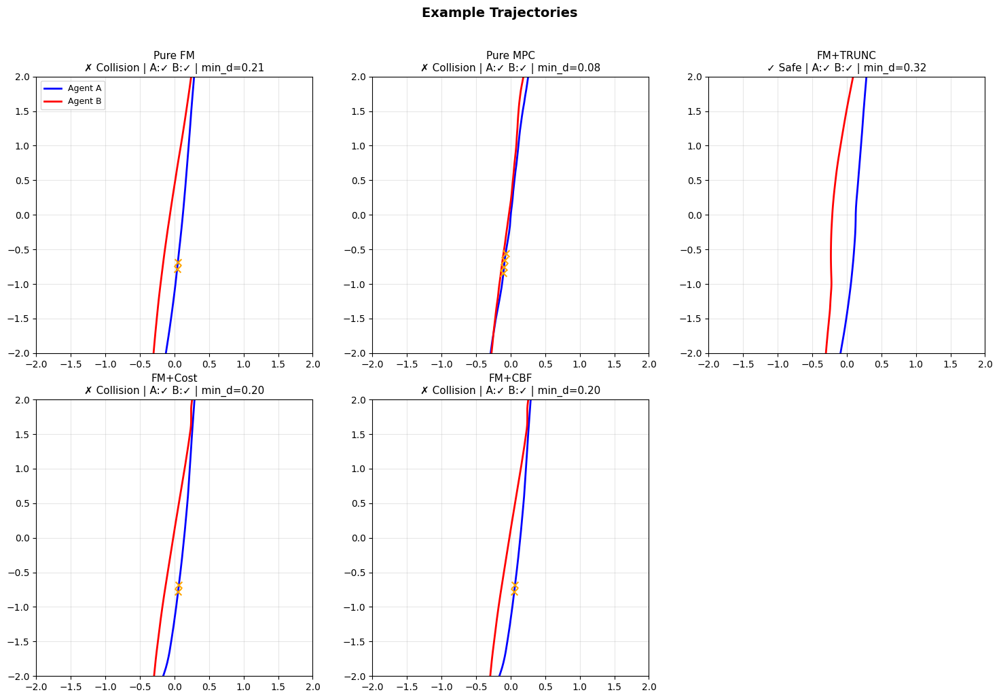

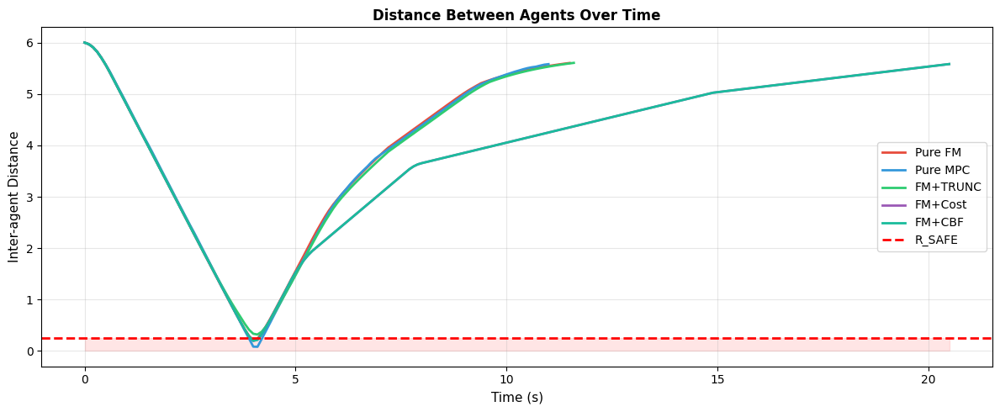


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [35]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 400      # 与两车实验一致
    dt: float = 0.1
    goal_tol: float = 0.20    # ★ 0.40→0.20
    R_SAFE: float = 0.25
    arena_size: float = 3.0   # ★ 与两车实验起点一致
    H: int = 12               # ★ 8→12
    K: int = 1                # ★ 1→8
    T_steps: int = 40         # ★ 25→40
    num_segments: int = 1     # ★ 2→5
    replan_every: int = 1     # ★ 2→1

cfg = Config()

# ★ 与两车实验完全一致的参数
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

# ★ 路径质量过滤参数（与两车实验一致）
PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

# FM 参数
noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# MPC 专用参数（加在 cfg = Config() 后面）
K_MPC      = 64
SIGMA_A    = 0.6
SIGMA_DR   = np.deg2rad(45.0)
MPC_LAMBDA = 0.05

W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8

# ===============================================================
# 基础函数（与两车实验完全一致）
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit（与两车实验完全一致）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# ★ check_path_quality（与两车实验完全一致）
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# ★ Fallback 控制（与两车实验完全一致）
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（与两车实验一致）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

def _rk4_bicycle_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a      = float(np.clip(u[0], -a_max, a_max))
        dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2     = float(np.clip(v, v_min, v_max))
        delta2 = float(np.clip(delta, -delta_max, delta_max))
        dth    = (v2 / L) * math.tan(delta2)
        return np.array([v2*math.cos(th), v2*math.sin(th),
                            dth, a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + 0.5*dt*k1)
    k3 = f(s + 0.5*dt*k2)
    k4 = f(s + dt*k3)
    s_new = s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _rk4_rollout(s0, U, dt, v_max):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    for i in range(H):
        st[i+1] = _rk4_bicycle_step(st[i], U[i], dt, v_max)
    return st

def _rk45_step(s, u, dt, v_max, n_substeps=4):
    """
    把一个 dt 细分成 n_substeps 小步用 RK4 积分
    n_substeps 越大越精确越慢
    """
    dt_sub = dt / n_substeps
    s_cur  = s.copy()
    for _ in range(n_substeps):
        s_cur = _rk4_bicycle_step(s_cur, u, dt_sub, v_max)
    return s_cur

def _rk45_rollout(s0, U, dt, v_max, n_substeps=4):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    for i in range(H):
        st[i+1] = _rk45_step(st[i], U[i], dt, v_max, n_substeps)
    return st

def _compute_mpc_cost(traj, U, goal_xy, other_pos, v_max_self):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos     = traj[:, :2]
    th      = traj[:, 2]
    vel     = traj[:, 3]

    # goal
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(
        pos - goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path

    # collision
    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos[:M] - other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol

    # heading
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1] - goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))

    # velocity tracking
    d_goals = np.linalg.norm(pos - goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius,
                       v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel - v_des)**2))

    # smoothness
    dU       = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth = W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    # jerk
    ddU    = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))

    return J_goal + J_coll + J_heading + J_vel + J_smooth + J_jerk

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, CBF_LIGHT
    else:                          return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心（K候选 + check_path_quality + fallback）
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st          = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self    = st[:, :2]
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法（消融对比）
# ===============================================================

# 方法1: Pure FM（无CBF，K=1，无质量过滤）
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法2: Pure MPC（几何绕行路径 + pure pursuit，无FM）
def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal,  np.float32)
    t     = np.linspace(0, 1, T).reshape(-1,1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path
    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0]*(other_pos[0][1]-start[1]) - to_goal[1]*(other_pos[0][0]-start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

# def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
#     other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
#     path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
#     U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
#     return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    rng       = np.random.RandomState(seed)
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)

    straight = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    U_nom    = pure_pursuit_controls(
        sA, straight, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)

    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR

    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0] + eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1] + eps_dr[k],
                           -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k

    # ★ RK4 rollout + 复杂 cost
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        # traj     = _rk4_rollout(sA, U_samples[k], cfg.dt, v_max_self)
        traj = _rk45_rollout(sA, U_samples[k], cfg.dt, v_max_self, n_substeps=4)
        costs[k] = _compute_mpc_cost(
            traj, U_samples[k], gA, other_pos, v_max_self)

    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)

    return U_mpc[0].copy(), 0

    

# 方法3: FM + TRUNC（FM生成，碰撞点截断后接几何绕行）
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法4: FM + Cost（多候选FM，cost选最优，无CBF，有check_path_quality）
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self,
                       seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

# 方法5: FM + CBF (Ours) — 与两车实验完全一致
def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),        np.sin(ang)],        np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi),  np.sin(ang+np.pi)],  np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol   # ★ 去掉速度条件，与两车实验一致
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    result = {
        'success_A':  float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':  float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':  bool(dist_AB.min() < cfg.R_SAFE),
        'min_dist':   float(dist_AB.min()),
        'steps':      len(trajA),
        'cbf_used':   cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":   replan_pure_fm,
        "Pure MPC":  replan_pure_mpc,
        "FM+TRUNC":  replan_fm_trunc,
        "FM+Cost":   replan_fm_cost,
        "FM+CBF":    replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 60)
    print(f"Ablation v4 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 60)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-"*75)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA  = sum(1 for r in rs if r['success_A'])    / n * 100
        goalB  = sum(1 for r in rs if r['success_B'])    / n * 100
        min_d  = np.mean([r['min_dist'] for r in rs])
        steps  = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safety=safety, goalA=goalA, goalB=goalB,
                              min_d=min_d, steps=steps)
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}")
    print("="*75)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    ax = axes[1]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 105)

    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend(); ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=50, marker='x', zorder=6)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
        status    = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0: ax.legend(loc='upper left', fontsize=9)
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11); ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v4...

Ablation v4 | Trials=1 | R_SAFE=0.45 | R_COLL=0.2 | arena=3.0
>>> Pure FM  2.9s
>>> Pure MPC  32.2s
>>> FM+TRUNC  2.9s
>>> FM+Cost  5.2s
>>> FM+CBF  5.6s

Method        Safe%(strict)  Safe%(prac)   GoalA%   GoalB%  MinDist  Steps
              any step<0.45  3steps<0.20
-------------------------------------------------------------------------------------
Pure FM                0.0%       100.0%   100.0%   100.0%    0.215    116
Pure MPC               0.0%       100.0%   100.0%   100.0%    0.064    111
FM+TRUNC               0.0%       100.0%   100.0%   100.0%    0.220    115
FM+Cost                0.0%       100.0%   100.0%   100.0%    0.197    206
FM+CBF                 0.0%       100.0%   100.0%   100.0%    0.197    206 ★


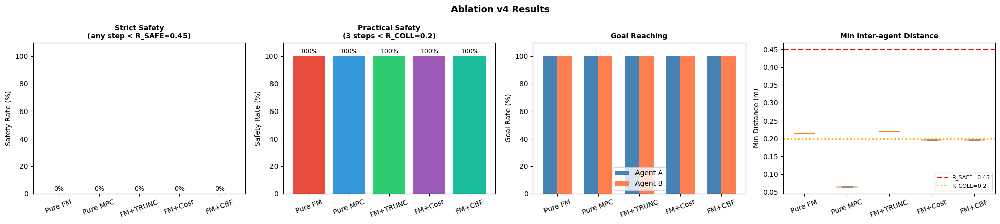

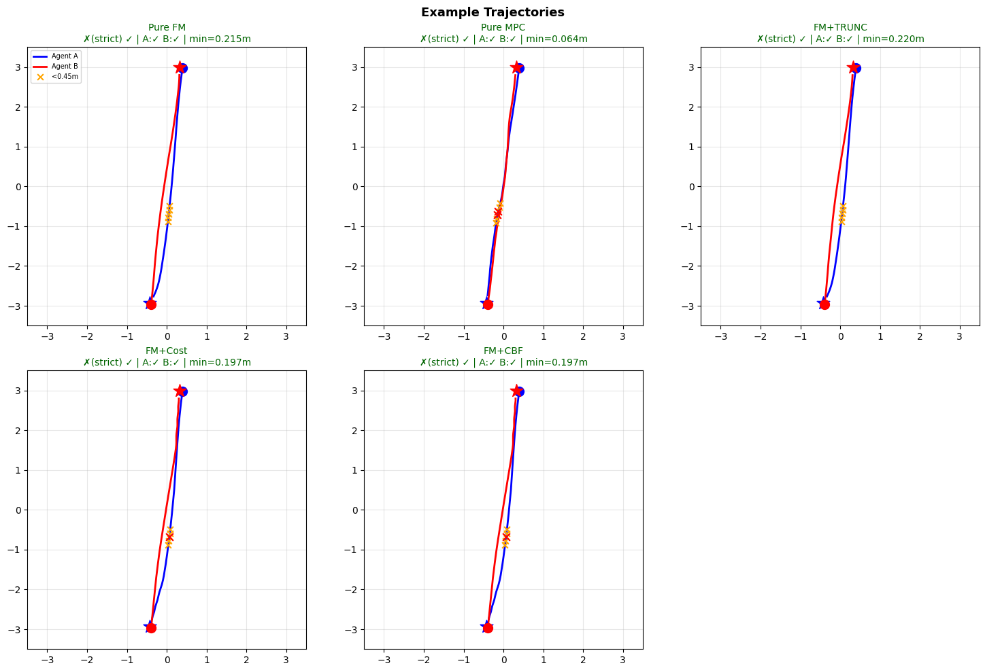

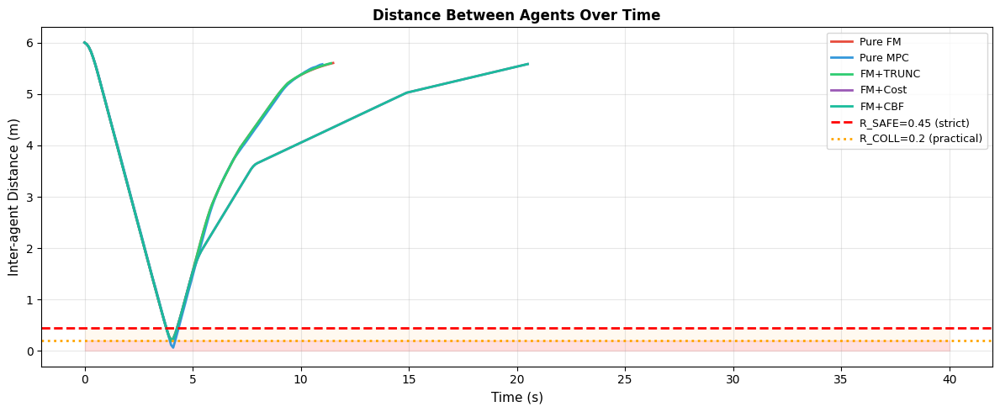


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [37]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 400
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45        # ★ 恢复正常值
    R_COLLISION: float = 0.20   # ★ 真实物理碰撞阈值（车体半径）
    arena_size: float = 3.0     # ★ 扩大场地
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments: int = 1
    replan_every: int = 1
    collision_steps: int = 3    # ★ 连续N步 < R_COLLISION 才算真实碰撞

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale  = 0.08
total_time   = 1.0
ode_method   = "euler"

# MPC 专用参数
K_MPC      = 64
SIGMA_A    = 0.6
SIGMA_DR   = np.deg2rad(45.0)
MPC_LAMBDA = 0.05

W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# ★ 碰撞判定工具函数
# ===============================================================
def _check_collision_strict(dist_AB):
    """严格判定：任意一步 < R_SAFE"""
    return bool(dist_AB.min() < cfg.R_SAFE)

def _check_collision_practical(dist_AB):
    """实用判定：连续 collision_steps 步 < R_COLLISION"""
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt,
                           -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]
    th     = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（FM 方法用）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(
        pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# MPC 专用：RK4 rollout + 复杂 cost
# ===============================================================
def _rk4_bicycle_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a      = float(np.clip(u[0], -a_max, a_max))
        dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2     = float(np.clip(v, v_min, v_max))
        delta2 = float(np.clip(delta, -delta_max, delta_max))
        dth    = (v2 / L) * math.tan(delta2)
        return np.array([v2*math.cos(th), v2*math.sin(th),
                         dth, a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + 0.5*dt*k1)
    k3 = f(s + 0.5*dt*k2)
    k4 = f(s + dt*k3)
    s_new = s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _rk45_step(s, u, dt, v_max, n_substeps=4):
    dt_sub = dt / n_substeps
    s_cur  = s.copy()
    for _ in range(n_substeps):
        s_cur = _rk4_bicycle_step(s_cur, u, dt_sub, v_max)
    return s_cur

def _rk45_rollout(s0, U, dt, v_max, n_substeps=4):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    for i in range(H):
        st[i+1] = _rk45_step(st[i], U[i], dt, v_max, n_substeps)
    return st

def _compute_mpc_cost(traj, U, goal_xy, other_pos, v_max_self):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos     = traj[:, :2]
    th      = traj[:, 2]
    vel     = traj[:, 3]

    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(
        pos - goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path

    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos[:M] - other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol

    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1] - goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))

    d_goals = np.linalg.norm(pos - goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius,
                       v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel - v_des)**2))

    dU       = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth = W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    ddU    = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))

    return J_goal + J_coll + J_heading + J_vel + J_smooth + J_jerk

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near     = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:    return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True,  CBF_LIGHT
    else:                          return True,  CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None
                            or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments,
        ode_method=ode_method, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U        = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                          H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st       = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J        = compute_cost(st[:, :2], other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================

def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA,
                               H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    rng       = np.random.RandomState(seed)
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)

    straight = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    U_nom    = pure_pursuit_controls(
        sA, straight, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)

    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR

    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0] + eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1] + eps_dr[k],
                           -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k

    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj     = _rk45_rollout(sA, U_samples[k], cfg.dt,
                                  v_max_self, n_substeps=4)
        costs[k] = _compute_mpc_cost(
            traj, U_samples[k], gA, other_pos, v_max_self)

    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0

    for i in range(min(len(path), len(other_pos))):
        if (np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2
                and i > 2):
            t     = np.linspace(0, 1, cfg.T_steps - i).reshape(-1,1)
            patch = (path[i-1] + t*(gA - path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break

    U = pure_pursuit_controls(sA, path, gA,
                               H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验（★ 双重碰撞判定）
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA   = np.array(trajA)
    trajB   = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    # ★ 双重判定
    coll_strict     = _check_collision_strict(dist_AB)
    coll_practical  = _check_collision_practical(dist_AB)

    result = {
        'success_A':        float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':        float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':        coll_strict,       # 严格：任意一步 < R_SAFE=0.45
        'collision_prac':   coll_practical,    # 实用：连续3步 < R_COLLISION=0.20
        'min_dist':         float(dist_AB.min()),
        'steps':            len(trajA),
        'cbf_used':         cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 65)
    print(f"Ablation v4 | Trials={cfg.n_trials} | "
          f"R_SAFE={cfg.R_SAFE} | R_COLL={cfg.R_COLLISION} | "
          f"arena={cfg.arena_size}")
    print("=" * 65)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示（★ 同时报告两种 safety）
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*85)
    print(f"{'Method':<12} {'Safe%(strict)':>14} {'Safe%(prac)':>12} "
          f"{'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print(f"{'':12} {'any step<0.45':>14} {'3steps<0.20':>12}")
    print("-"*85)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safe_s   = sum(1 for r in rs if not r['collision'])      / n * 100
        safe_p   = sum(1 for r in rs if not r['collision_prac']) / n * 100
        goalA    = sum(1 for r in rs if r['success_A'])          / n * 100
        goalB    = sum(1 for r in rs if r['success_B'])          / n * 100
        min_d    = np.mean([r['min_dist'] for r in rs])
        steps    = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safe_s=safe_s, safe_p=safe_p,
                             goalA=goalA, goalB=goalB,
                             min_d=min_d, steps=steps)
        marker = " ★" if name == "FM+CBF" else ""
        print(f"{name:<12} {safe_s:>13.1f}% {safe_p:>11.1f}% "
              f"{goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}{marker}")
    print("="*85)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图（4个子图）
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

    # 严格 safety
    ax = axes[0]
    vals = [summary[n]['safe_s'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)')
    ax.set_title(f'Strict Safety\n(any step < R_SAFE={cfg.R_SAFE})',
                 fontsize=10, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2,
                f'{v:.0f}%', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

    # 实用 safety
    ax = axes[1]
    vals = [summary[n]['safe_p'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)')
    ax.set_title(f'Practical Safety\n({cfg.collision_steps} steps < '
                 f'R_COLL={cfg.R_COLLISION})',
                 fontsize=10, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2,
                f'{v:.0f}%', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

    # Goal reaching
    ax = axes[2]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w,
           label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w,
           label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=20)
    ax.set_ylabel('Goal Rate (%)')
    ax.set_title('Goal Reaching', fontsize=10, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 110)

    # Min distance boxplot
    ax = axes[3]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2,
               label=f'R_SAFE={cfg.R_SAFE}')
    ax.axhline(cfg.R_COLLISION, color='orange', ls=':', lw=2,
               label=f'R_COLL={cfg.R_COLLISION}')
    ax.set_ylabel('Min Distance (m)')
    ax.set_title('Min Inter-agent Distance', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=20)

    plt.suptitle('Ablation v4 Results', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)

        # 严格碰撞点（橙色x）
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=40, marker='x', zorder=6,
                       label=f'<{cfg.R_SAFE}m')
        # 实际碰撞点（红色x）
        coll_idx2 = np.where(data['dist_AB'] < cfg.R_COLLISION)[0]
        if len(coll_idx2) > 0:
            ax.scatter(trajA[coll_idx2,0], trajA[coll_idx2,1],
                       c='red', s=60, marker='x', zorder=7,
                       label=f'<{cfg.R_COLLISION}m')

        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-cfg.arena_size-0.5, cfg.arena_size+0.5)
        ax.set_ylim(-cfg.arena_size-0.5, cfg.arena_size+0.5)

        s_str  = "✓" if not data['collision']      else "✗(strict)"
        p_str  = "✓" if not data['collision_prac'] else "✗(prac)"
        g_str  = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        color  = 'darkgreen' if not data['collision_prac'] else 'red'
        ax.set_title(f"{name}\n{s_str} {p_str} | {g_str} | "
                     f"min={data['min_dist']:.3f}m",
                     fontsize=10, color=color)
        if idx == 0: ax.legend(loc='upper left', fontsize=7)

    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2,
               label=f'R_SAFE={cfg.R_SAFE} (strict)')
    ax.axhline(cfg.R_COLLISION, color='orange', ls=':', lw=2,
               label=f'R_COLL={cfg.R_COLLISION} (practical)')
    ax.fill_between([0, cfg.max_steps*cfg.dt], 0, cfg.R_COLLISION,
                    alpha=0.12, color='red')
    ax.fill_between([0, cfg.max_steps*cfg.dt],
                    cfg.R_COLLISION, cfg.R_SAFE,
                    alpha=0.06, color='orange')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Inter-agent Distance (m)', fontsize=11)
    ax.set_title('Distance Between Agents Over Time',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v4...

Ablation v4 | Trials=50 | R_SAFE=0.45 | R_COLL=0.2 | arena=3.0
>>> Pure FM .......... 108.0s
>>> Pure MPC .......... 11250.8s
>>> FM+TRUNC .......... 112.9s
>>> FM+Cost .......... 204.5s
>>> FM+CBF .......... 215.6s

Method        Safe%(strict)  Safe%(prac)   GoalA%   GoalB%  MinDist  Steps
              any step<0.45  3steps<0.20
-------------------------------------------------------------------------------------
Pure FM                0.0%       100.0%   100.0%   100.0%    0.207    116
Pure MPC               0.0%       100.0%   100.0%   100.0%    0.166    111
FM+TRUNC               0.0%       100.0%   100.0%   100.0%    0.214    115
FM+Cost                0.0%       100.0%   100.0%   100.0%    0.194    203
FM+CBF                 0.0%       100.0%   100.0%   100.0%    0.194    203 ★


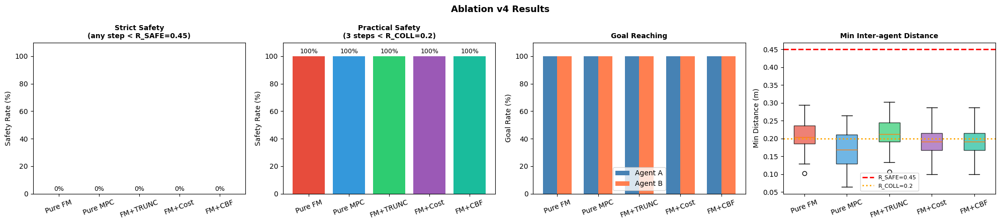

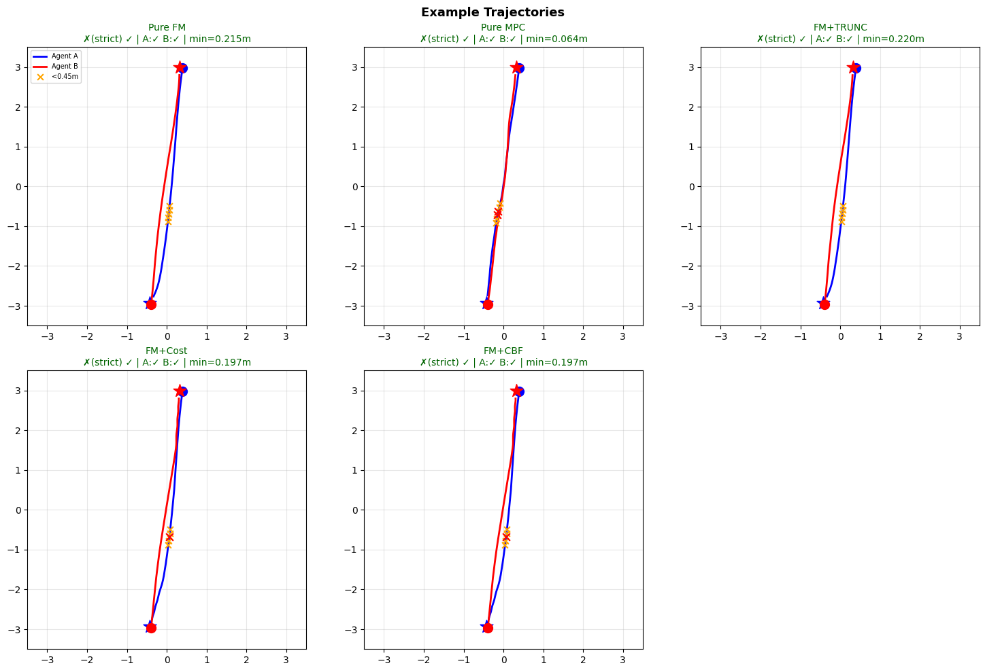

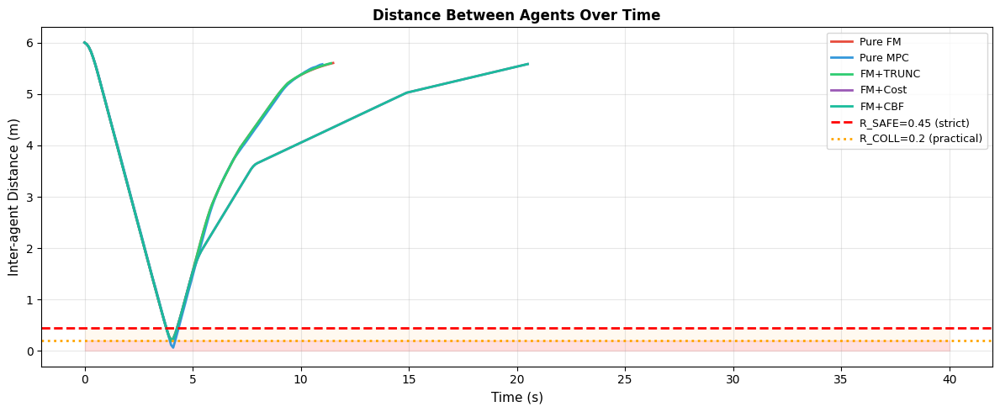


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [39]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 50
    max_steps: int = 400
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45        # ★ 恢复正常值
    R_COLLISION: float = 0.20   # ★ 真实物理碰撞阈值（车体半径）
    arena_size: float = 3.0     # ★ 扩大场地
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments: int = 1
    replan_every: int = 1
    collision_steps: int = 3    # ★ 连续N步 < R_COLLISION 才算真实碰撞

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale  = 0.08
total_time   = 1.0
ode_method   = "euler"

# MPC 专用参数
K_MPC      = 64
SIGMA_A    = 0.6
SIGMA_DR   = np.deg2rad(45.0)
MPC_LAMBDA = 0.05

W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# ★ 碰撞判定工具函数
# ===============================================================
def _check_collision_strict(dist_AB):
    """严格判定：任意一步 < R_SAFE"""
    return bool(dist_AB.min() < cfg.R_SAFE)

def _check_collision_practical(dist_AB):
    """实用判定：连续 collision_steps 步 < R_COLLISION"""
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt,
                           -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]
    th     = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（FM 方法用）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(
        pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# MPC 专用：RK4 rollout + 复杂 cost
# ===============================================================
def _rk4_bicycle_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a      = float(np.clip(u[0], -a_max, a_max))
        dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2     = float(np.clip(v, v_min, v_max))
        delta2 = float(np.clip(delta, -delta_max, delta_max))
        dth    = (v2 / L) * math.tan(delta2)
        return np.array([v2*math.cos(th), v2*math.sin(th),
                         dth, a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + 0.5*dt*k1)
    k3 = f(s + 0.5*dt*k2)
    k4 = f(s + dt*k3)
    s_new = s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _rk45_step(s, u, dt, v_max, n_substeps=4):
    dt_sub = dt / n_substeps
    s_cur  = s.copy()
    for _ in range(n_substeps):
        s_cur = _rk4_bicycle_step(s_cur, u, dt_sub, v_max)
    return s_cur

def _rk45_rollout(s0, U, dt, v_max, n_substeps=4):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    for i in range(H):
        st[i+1] = _rk45_step(st[i], U[i], dt, v_max, n_substeps)
    return st

def _compute_mpc_cost(traj, U, goal_xy, other_pos, v_max_self):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos     = traj[:, :2]
    th      = traj[:, 2]
    vel     = traj[:, 3]

    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(
        pos - goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path

    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos[:M] - other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol

    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1] - goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))

    d_goals = np.linalg.norm(pos - goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius,
                       v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel - v_des)**2))

    dU       = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth = W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    ddU    = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))

    return J_goal + J_coll + J_heading + J_vel + J_smooth + J_jerk

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near     = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:    return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True,  CBF_LIGHT
    else:                          return True,  CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None
                            or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments,
        ode_method=ode_method, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U        = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                          H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st       = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J        = compute_cost(st[:, :2], other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================

def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA,
                               H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    rng       = np.random.RandomState(seed)
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)

    straight = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    U_nom    = pure_pursuit_controls(
        sA, straight, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)

    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR

    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0] + eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1] + eps_dr[k],
                           -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k

    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj     = _rk45_rollout(sA, U_samples[k], cfg.dt,
                                  v_max_self, n_substeps=4)
        costs[k] = _compute_mpc_cost(
            traj, U_samples[k], gA, other_pos, v_max_self)

    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0

    for i in range(min(len(path), len(other_pos))):
        if (np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2
                and i > 2):
            t     = np.linspace(0, 1, cfg.T_steps - i).reshape(-1,1)
            patch = (path[i-1] + t*(gA - path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break

    U = pure_pursuit_controls(sA, path, gA,
                               H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验（★ 双重碰撞判定）
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA   = np.array(trajA)
    trajB   = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    # ★ 双重判定
    coll_strict     = _check_collision_strict(dist_AB)
    coll_practical  = _check_collision_practical(dist_AB)

    result = {
        'success_A':        float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':        float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':        coll_strict,       # 严格：任意一步 < R_SAFE=0.45
        'collision_prac':   coll_practical,    # 实用：连续3步 < R_COLLISION=0.20
        'min_dist':         float(dist_AB.min()),
        'steps':            len(trajA),
        'cbf_used':         cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 65)
    print(f"Ablation v4 | Trials={cfg.n_trials} | "
          f"R_SAFE={cfg.R_SAFE} | R_COLL={cfg.R_COLLISION} | "
          f"arena={cfg.arena_size}")
    print("=" * 65)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示（★ 同时报告两种 safety）
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*85)
    print(f"{'Method':<12} {'Safe%(strict)':>14} {'Safe%(prac)':>12} "
          f"{'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print(f"{'':12} {'any step<0.45':>14} {'3steps<0.20':>12}")
    print("-"*85)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safe_s   = sum(1 for r in rs if not r['collision'])      / n * 100
        safe_p   = sum(1 for r in rs if not r['collision_prac']) / n * 100
        goalA    = sum(1 for r in rs if r['success_A'])          / n * 100
        goalB    = sum(1 for r in rs if r['success_B'])          / n * 100
        min_d    = np.mean([r['min_dist'] for r in rs])
        steps    = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safe_s=safe_s, safe_p=safe_p,
                             goalA=goalA, goalB=goalB,
                             min_d=min_d, steps=steps)
        marker = " ★" if name == "FM+CBF" else ""
        print(f"{name:<12} {safe_s:>13.1f}% {safe_p:>11.1f}% "
              f"{goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}{marker}")
    print("="*85)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图（4个子图）
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

    # 严格 safety
    ax = axes[0]
    vals = [summary[n]['safe_s'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)')
    ax.set_title(f'Strict Safety\n(any step < R_SAFE={cfg.R_SAFE})',
                 fontsize=10, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2,
                f'{v:.0f}%', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

    # 实用 safety
    ax = axes[1]
    vals = [summary[n]['safe_p'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)')
    ax.set_title(f'Practical Safety\n({cfg.collision_steps} steps < '
                 f'R_COLL={cfg.R_COLLISION})',
                 fontsize=10, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2,
                f'{v:.0f}%', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

    # Goal reaching
    ax = axes[2]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w,
           label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w,
           label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=20)
    ax.set_ylabel('Goal Rate (%)')
    ax.set_title('Goal Reaching', fontsize=10, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 110)

    # Min distance boxplot
    ax = axes[3]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2,
               label=f'R_SAFE={cfg.R_SAFE}')
    ax.axhline(cfg.R_COLLISION, color='orange', ls=':', lw=2,
               label=f'R_COLL={cfg.R_COLLISION}')
    ax.set_ylabel('Min Distance (m)')
    ax.set_title('Min Inter-agent Distance', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=20)

    plt.suptitle('Ablation v4 Results', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)

        # 严格碰撞点（橙色x）
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=40, marker='x', zorder=6,
                       label=f'<{cfg.R_SAFE}m')
        # 实际碰撞点（红色x）
        coll_idx2 = np.where(data['dist_AB'] < cfg.R_COLLISION)[0]
        if len(coll_idx2) > 0:
            ax.scatter(trajA[coll_idx2,0], trajA[coll_idx2,1],
                       c='red', s=60, marker='x', zorder=7,
                       label=f'<{cfg.R_COLLISION}m')

        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-cfg.arena_size-0.5, cfg.arena_size+0.5)
        ax.set_ylim(-cfg.arena_size-0.5, cfg.arena_size+0.5)

        s_str  = "✓" if not data['collision']      else "✗(strict)"
        p_str  = "✓" if not data['collision_prac'] else "✗(prac)"
        g_str  = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        color  = 'darkgreen' if not data['collision_prac'] else 'red'
        ax.set_title(f"{name}\n{s_str} {p_str} | {g_str} | "
                     f"min={data['min_dist']:.3f}m",
                     fontsize=10, color=color)
        if idx == 0: ax.legend(loc='upper left', fontsize=7)

    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2,
               label=f'R_SAFE={cfg.R_SAFE} (strict)')
    ax.axhline(cfg.R_COLLISION, color='orange', ls=':', lw=2,
               label=f'R_COLL={cfg.R_COLLISION} (practical)')
    ax.fill_between([0, cfg.max_steps*cfg.dt], 0, cfg.R_COLLISION,
                    alpha=0.12, color='red')
    ax.fill_between([0, cfg.max_steps*cfg.dt],
                    cfg.R_COLLISION, cfg.R_SAFE,
                    alpha=0.06, color='orange')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Inter-agent Distance (m)', fontsize=11)
    ax.set_title('Distance Between Agents Over Time',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v4c...

Ablation v4c | Trials=1 | Layouts=['open', 'center_block', 'narrow_passage', 's_curve']
W_OBS=2000.0 | R_OBS=0.2
★ Collision: 连续5步 < R_COLLISION=0.3
★ MPC: K=128 Dopri5 substeps=6 + lane/curv cost
★ FM+CBF: euler seg=1 (fast)
★ FM others: euler seg=3
★ Exec safe: {'FM+CBF'}

── Layout: open ──
  Pure FM       2.4s
  Pure MPC      70.6s
  FM+TRUNC      3.4s
  FM+Cost       7.7s
  FM+CBF        4.6s

── Layout: center_block ──
  Pure FM       3.3s
  Pure MPC      83.2s
  FM+TRUNC      3.5s
  FM+Cost       7.9s
  FM+CBF        5.7s

── Layout: narrow_passage ──
  Pure FM       3.4s
  Pure MPC      83.5s
  FM+TRUNC      3.5s
  FM+Cost       10.2s
  FM+CBF        6.8s

── Layout: s_curve ──
  Pure FM       3.2s
  Pure MPC      86.3s
  FM+TRUNC      3.3s
  FM+Cost       9.7s
  FM+CBF        11.1s

Layout             Method        Safe%(p)  Safe%(s)  ObsSafe%  GoalA%  GoalB%  MinDist  MinD(N)
                                   5x<0.3  any<0.45    phys_r              

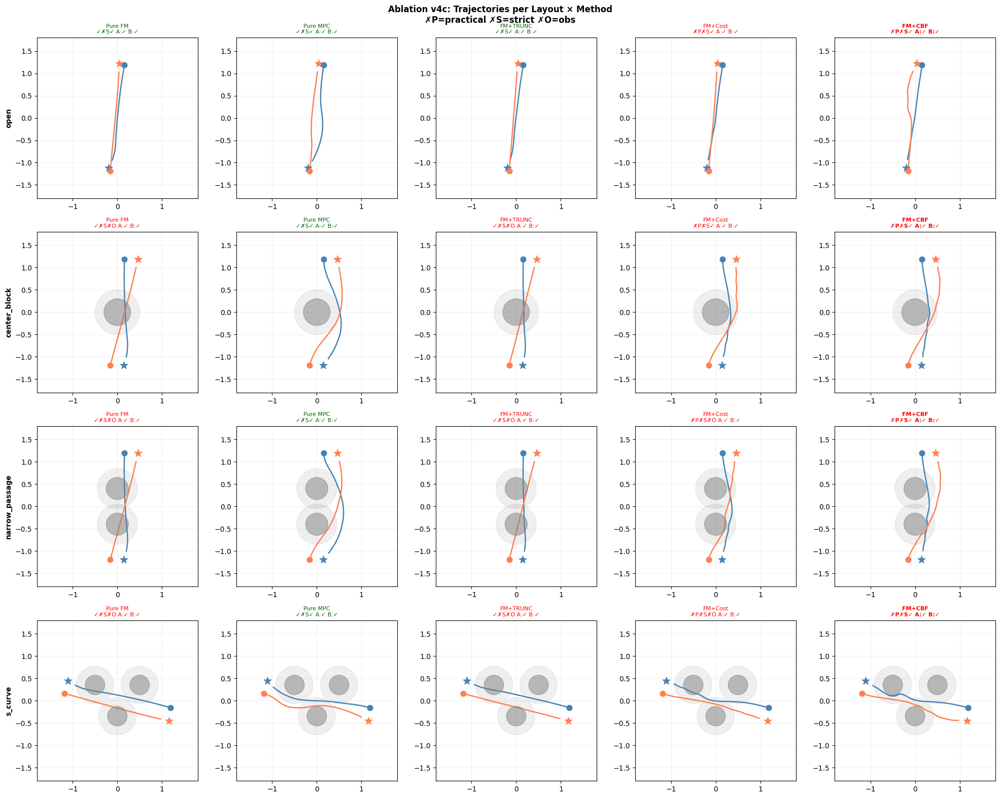

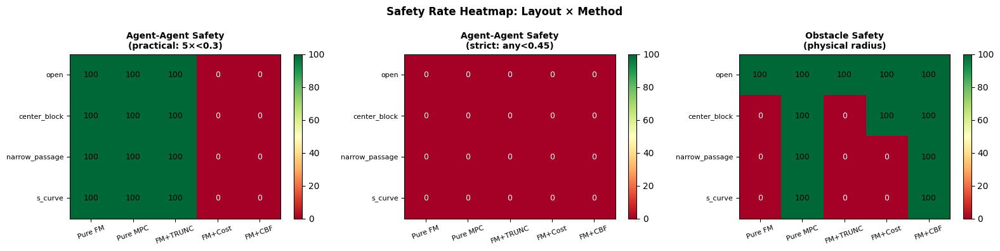


Saved: ablation_v4c_traj.png, ablation_v4c_heatmap.png

Done!


In [ ]:
# ===============================================================
# 消融实验 v4c：最终版
# ★ R_COLLISION=0.30, collision_steps=5 避免正常交汇误判
# ★ s_curve 强制完整输出
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.30   # ★ 0.20→0.30
    R_OBS: float = 0.20
    arena_size: float = 1.2
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    replan_every: int = 1
    collision_steps: int = 5    # ★ 3→5

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

K_MPC          = 128
SIGMA_A        = 0.6
SIGMA_DR       = np.deg2rad(45.0)
MPC_LAMBDA     = 0.05
MPC_N_SUBSTEPS = 6

W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25
W_OBS      = 2000.0
W_OBS_SLOW = 5000.0

W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8
W_MPC_OBS     = 2000.0
W_MPC_LANE    = 1.5
W_MPC_CURV    = 0.5

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

YIELD_DIST   = 2.0
YIELD_OFFSET = 0.45

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

PATH_OBS_MARGIN      = cfg.R_OBS + 0.08
PATH_OBS_MARGIN_SLOW = cfg.R_OBS + 0.13
PATH_OBS_MARGIN_CBF  = cfg.R_OBS + 0.04

EXEC_SAFE_METHODS = {"FM+CBF"}

METHOD_NAMES = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]

# ===============================================================
# 静态障碍物定义
# ===============================================================
OBSTACLE_LAYOUTS = {
    "open": [],
    "center_block": [
        {"center": [0.0, 0.0], "radius": 0.30},
    ],
    "narrow_passage": [
        {"center": [ 0.0,  0.40], "radius": 0.25},
        {"center": [ 0.0, -0.40], "radius": 0.25},
    ],
    "s_curve": [
        {"center": [-0.50,  0.35], "radius": 0.22},
        {"center": [ 0.0,  -0.35], "radius": 0.22},
        {"center": [ 0.50,  0.35], "radius": 0.22},
    ],
}

ACTIVE_LAYOUTS = ["open", "center_block", "narrow_passage", "s_curve"]

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# 静态障碍物工具
# ===============================================================
def check_obs_collision(pos_xy, obstacles, r_agent=None):
    if r_agent is None:
        r_agent = cfg.R_OBS
    for obs in obstacles:
        c  = np.asarray(obs["center"], np.float32)
        rm = float(obs["radius"]) + r_agent
        if float(np.linalg.norm(pos_xy - c)) < rm:
            return True
    return False

def traj_obs_collision(traj_xy, obstacles, use_margin=False, is_slow=False):
    if len(obstacles) == 0:
        return False, float("inf")
    min_d = float("inf")
    hit   = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_phys = float(obs["radius"])
        rm     = r_phys + cfg.R_OBS + (0.10 if is_slow else 0.0) \
                 if use_margin else r_phys
        dists  = np.linalg.norm(traj_xy - c.reshape(1,2), axis=1)
        d_surf = float(dists.min()) - r_phys
        min_d  = min(min_d, d_surf)
        if float(dists.min()) < rm:
            hit = True
    return hit, min_d

# ===============================================================
# 执行层安全推出
# ===============================================================
def _push_out_of_obs(state, obstacles):
    if len(obstacles) == 0:
        return state
    pos    = state[:2].copy()
    pushed = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_safe = float(obs["radius"]) + 0.02
        diff   = pos - c
        dist   = float(np.linalg.norm(diff))
        if dist < r_safe:
            direction = diff / dist if dist > 1e-6 \
                        else np.array([1.0, 0.0], np.float32)
            pos       = (c + direction * (r_safe + 0.01)).astype(np.float32)
            pushed    = True
    if not pushed:
        return state
    new_state     = state.copy()
    new_state[:2] = pos
    return new_state

# ===============================================================
# 路径后处理
# ===============================================================
def post_process_path_obs(path_xy, obstacles, r_safe_margin=None):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(30):
        modified = False
        for i in range(len(path)):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_safe:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    path[i]  = (c + direction * (r_safe + 0.02)).astype(np.float32)
                    modified = True
        if not modified:
            break
    return path.astype(np.float32)

def post_process_path_smooth(path_xy, n_smooth=3, alpha=0.5):
    if len(path_xy) < 5:
        return path_xy
    path  = path_xy.copy()
    w_mid = 1.0 - alpha
    w_s   = alpha / 2.0
    for _ in range(n_smooth):
        new_path = path.copy()
        for i in range(1, len(path)-1):
            new_path[i] = w_s*path[i-1] + w_mid*path[i] + w_s*path[i+1]
        path = new_path
    return path.astype(np.float32)

def post_process_path_obs_soft(path_xy, obstacles, r_safe_margin=None,
                                n_iters=60, soft_falloff=2.5):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(n_iters):
        modified = False
        for i in range(1, len(path)-1):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                r_inf  = r_safe * soft_falloff
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_inf:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    if dist < r_safe:
                        push = (r_safe - dist + 0.015)
                    else:
                        t    = (dist - r_safe) / (r_inf - r_safe + 1e-6)
                        push = 0.3 * (r_safe - dist + 0.015) * (1.0 - t)
                        push = max(0.0, push)
                    if push > 1e-4:
                        path[i]  = (path[i] + direction * push * 0.6).astype(np.float32)
                        modified = True
        if not modified:
            break
    return path.astype(np.float32)

def smooth_path_spline(path_xy, n_out=None, smoothing=0.5):
    if len(path_xy) < 5:
        return path_xy
    if n_out is None:
        n_out = len(path_xy)
    x    = path_xy[:, 0].astype(float)
    y    = path_xy[:, 1].astype(float)
    diff = np.diff(np.stack([x, y], axis=1), axis=0)
    mask = np.concatenate([[True], np.linalg.norm(diff, axis=1) > 1e-5])
    x, y = x[mask], y[mask]
    if len(x) < 4:
        return path_xy
    try:
        tck, _   = splprep([x, y], s=smoothing, k=3)
        x_s, y_s = splev(np.linspace(0, 1, n_out), tck)
        result   = np.stack([x_s, y_s], axis=1).astype(np.float32)
        result[0]  = path_xy[0]
        result[-1] = path_xy[-1]
        return result
    except Exception:
        return path_xy

# ===============================================================
# 安全目标点生成
# ===============================================================
def _safe_goal(base_pos, obstacles, rng):
    if len(obstacles) == 0:
        noise = rng.uniform(-0.15, 0.15, 2).astype(np.float32)
        return (-base_pos + noise).astype(np.float32)

    def path_clear(start, end):
        for t in np.linspace(0.0, 1.0, 50):
            mid = start + t * (end - start)
            for obs in obstacles:
                c     = np.asarray(obs["center"], np.float32)
                r_chk = float(obs["radius"]) + cfg.R_OBS
                if float(np.linalg.norm(mid - c)) < r_chk:
                    return False
        return True

    def point_safe(g, margin=0.10):
        for obs in obstacles:
            c = np.asarray(obs["center"], np.float32)
            if float(np.linalg.norm(g - c)) < float(obs["radius"]) + cfg.R_OBS + margin:
                return False
        return True

    for _ in range(60):
        noise = rng.uniform(-0.45, 0.45, 2).astype(np.float32)
        g = (-base_pos + noise).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    for attempt in range(40):
        side   = 1.0 if attempt % 2 == 0 else -1.0
        offset = rng.uniform(0.3, 0.6) * side
        g = (-base_pos + perp * offset).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
        for dist in [0.4, 0.6, 0.8, 1.0]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g) and path_clear(base_pos, g):
                return g

    for angle in np.linspace(0, 2*np.pi, 32, endpoint=False):
        for dist in [0.3, 0.5, 0.7, 0.9]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g, margin=0.0):
                return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    return (-base_pos + perp * 0.5).astype(np.float32)

# ===============================================================
# 慢车主动让路
# ===============================================================
def _yield_biased_goal(self_pos, goal_xy, other_pos_now, v_max_self,
                       dist_AB, obstacles):
    is_slow  = v_max_self < 0.8
    goal_arr = np.asarray(goal_xy, np.float32)
    if not is_slow or dist_AB > YIELD_DIST:
        return goal_arr
    to_goal = goal_arr - np.asarray(self_pos, np.float32)
    to_goal_len = float(np.linalg.norm(to_goal))
    if to_goal_len < 1e-3:
        return goal_arr
    to_goal_unit = to_goal / to_goal_len
    perp  = np.array([-to_goal_unit[1], to_goal_unit[0]], np.float32)
    diff  = np.asarray(other_pos_now, np.float32) - np.asarray(self_pos, np.float32)
    cross = float(to_goal_unit[0]*diff[1] - to_goal_unit[1]*diff[0])
    proximity   = max(0.0, 1.0 - dist_AB / YIELD_DIST)
    side        = -1.0 if cross > 0 else 1.0
    offset      = side * YIELD_OFFSET * proximity
    goal_biased = (goal_arr + offset * perp).astype(np.float32)
    if obstacles and check_obs_collision(
            goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
        goal_biased = (goal_arr - offset * perp).astype(np.float32)
        if obstacles and check_obs_collision(
                goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
            return goal_arr
    return goal_biased

# ===============================================================
# 碰撞判定
# ===============================================================
def _check_collision_practical(dist_AB):
    """连续 collision_steps 步 < R_COLLISION → 碰撞"""
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

def _check_collision_strict(dist_AB):
    return bool(dist_AB.min() < cfg.R_SAFE)

def _min_dist_consecutive(dist_AB):
    N = cfg.collision_steps
    if len(dist_AB) < N:
        return float(dist_AB.min())
    min_avg = float("inf")
    for i in range(len(dist_AB) - N + 1):
        avg = float(dist_AB[i:i+N].mean())
        min_avg = min(min_avg, avg)
    return min_avg

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0
    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max); continue
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max-v_creep)*(d_goal/creep_radius), v_creep, v_max))
        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des-delta)/dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des-v)/dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max)
    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]; th = float(self_state[2])
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    if float(np.linalg.norm(seg_dir)) > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"
    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]; th = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des/dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3])/dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost
# ===============================================================
def compute_cost(pos_self, pos_other_pred, goal_xy, U,
                 obstacles=None, is_slow=False):
    goal_xy  = np.asarray(goal_xy, np.float32)
    d_end    = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path   = float(np.mean(np.linalg.norm(pos_self-goal_xy.reshape(1,2), axis=1)))
    M        = min(len(pos_self), len(pos_other_pred))
    min_d    = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M]-pos_other_pred[:M], axis=1).min())
    viol     = max(0.0, cfg.R_SAFE - min_d)
    coll     = float(viol * viol)
    w_obs    = W_OBS_SLOW if is_slow else W_OBS
    obs_cost = 0.0
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos_self - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            obs_cost += float(viol_obs * viol_obs)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + w_obs*obs_cost + W_SMOOTH*smooth

# ===============================================================
# MPC Dopri5
# ===============================================================
def _dopri5_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a  = float(np.clip(u[0], -a_max, a_max))
        dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2 = float(np.clip(v, v_min, v_max))
        d2 = float(np.clip(delta, -delta_max, delta_max))
        return np.array([v2*math.cos(th), v2*math.sin(th),
                         (v2/L)*math.tan(d2), a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + dt*(1/5)*k1)
    k3 = f(s + dt*(3/40)*k1    + dt*(9/40)*k2)
    k4 = f(s + dt*(44/45)*k1   + dt*(-56/15)*k2  + dt*(32/9)*k3)
    k5 = f(s + dt*(19372/6561)*k1 + dt*(-25360/2187)*k2
             + dt*(64448/6561)*k3  + dt*(-212/729)*k4)
    k6 = f(s + dt*(9017/3168)*k1  + dt*(-355/33)*k2
             + dt*(46732/5247)*k3  + dt*(49/176)*k4
             + dt*(-5103/18656)*k5)
    s_new = s + dt*(35/384*k1 + 500/1113*k3 + 125/192*k4
                    - 2187/6784*k5 + 11/84*k6)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _dopri5_rollout(s0, U, dt, v_max, n_substeps=6):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    dt_sub = dt / n_substeps
    for i in range(H):
        s_cur = st[i].copy()
        for _ in range(n_substeps):
            s_cur = _dopri5_step(s_cur, U[i], dt_sub, v_max)
        st[i+1] = s_cur
    return st

def _compute_mpc_cost_full(traj, U, goal_xy, other_pos,
                            v_max_self, obstacles=None, is_slow=False):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos = traj[:,:2]; th = traj[:,2]; vel = traj[:,3]
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path
    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M<=1 else float(
        np.linalg.norm(pos[:M]-other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol
    J_obs = 0.0
    w_obs = W_OBS_SLOW if is_slow else W_MPC_OBS
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            J_obs   += w_obs * viol_obs * viol_obs
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1]-goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))
    d_goals = np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius, v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel-v_des)**2))
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth= W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    ddU     = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk  = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))
    if len(pos) > 2:
        start_p   = pos[0]; end_p = pos[-1]
        lane_dir  = end_p - start_p
        lane_len  = float(np.linalg.norm(lane_dir)) + 1e-6
        lane_unit = lane_dir / lane_len
        lane_perp = np.array([-lane_unit[1], lane_unit[0]])
        deviations = np.abs((pos - start_p) @ lane_perp)
        J_lane = W_MPC_LANE * float(np.mean(deviations**2))
    else:
        J_lane = 0.0
    delta_vals = traj[:,4]
    d_delta    = np.diff(delta_vals, prepend=delta_vals[0])
    J_curv     = W_MPC_CURV * float(np.mean(d_delta**2))
    return (J_goal + J_coll + J_obs + J_heading + J_vel
            + J_smooth + J_jerk + J_lane + J_curv)

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0

def get_cbf_config(dist_AB, has_obstacles=False, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if has_obstacles:              return True, strong
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                          return True, strong

def build_ellipses(tf, other_pred_pos, dist_AB,
                   static_obstacles=None, is_slow=False):
    ellipses = []
    if other_pred_pos is not None and len(other_pred_pos) >= 2:
        idxs = sorted(list(dict.fromkeys(
            [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
             if 0 <= i < len(other_pred_pos)])))
        r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
            else (r_obs_near if dist_AB < 1.2 else r_obs_far)
        for i in idxs:
            ellipses.append({"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
                             "radius": float(r)})
    if static_obstacles:
        extra = 0.25 if is_slow else 0.15
        for obs in static_obstacles:
            c_world = np.asarray(obs["center"], np.float32).reshape(1,2)
            c_can   = tf["w2c"](c_world)[0]
            ellipses.append({"center": c_can,
                             "radius": float(obs["radius"]) + cfg.R_OBS + extra})
    return ellipses

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed,
                   use_cbf, cbf_kwargs, static_obstacles=None,
                   v_max_self=1.0, use_soft_postproc=False,
                   num_segments=None, ode_method=None):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    is_slow   = v_max_self < 0.8
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB,
                                static_obstacles=static_obstacles,
                                is_slow=is_slow) if use_cbf else []
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)
    _num_seg = num_segments if num_segments is not None else cfg.num_segments_fm
    _ode     = ode_method   if ode_method   is not None else ode_method_fm
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=_num_seg,
        ode_method=_ode, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
        tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
    )
    xy_can     = x_can[0:2,:].T.astype(np.float32)
    path_world = tf["c2w"](xy_can).astype(np.float32)
    if static_obstacles and len(static_obstacles) > 0:
        if use_soft_postproc:
            r_margin = PATH_OBS_MARGIN_CBF + (0.04 if is_slow else 0.0)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin, n_iters=80, soft_falloff=2.0)
            path_world = smooth_path_spline(
                path_world, n_out=len(path_world), smoothing=0.8)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin - 0.01, n_iters=20, soft_falloff=1.5)
        else:
            r_margin   = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin)
            path_world = post_process_path_smooth(
                path_world, n_smooth=4, alpha=0.5)
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin - 0.02)
    return path_world

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, obstacles=None, K_override=None,
              use_soft_postproc=False, num_segments=None, ode_method=None):
    K_use   = K_override if K_override is not None else cfg.K
    is_slow = v_max_self < 0.8
    best    = None
    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs,
                                     static_obstacles=obstacles,
                                     v_max_self=v_max_self,
                                     use_soft_postproc=use_soft_postproc,
                                     num_segments=num_segments,
                                     ode_method=ode_method)
        except Exception:
            continue
        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            continue
        U  = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                    H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J  = compute_cost(st[:,:2], other_pred_pos, goal_xy, U,
                          obstacles=obstacles, is_slow=is_slow)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    rng       = np.random.RandomState(seed)
    is_slow   = v_max_self < 0.8
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    straight  = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    if obstacles and len(obstacles) > 0:
        r_margin = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
        straight = post_process_path_obs(straight, obstacles,
                                          r_safe_margin=r_margin)
        straight = post_process_path_smooth(straight, n_smooth=2, alpha=0.4)
    U_nom = pure_pursuit_controls(sA, straight, gA,
                                   H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR
    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0]+eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1]+eps_dr[k], -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj = _dopri5_rollout(sA, U_samples[k], cfg.dt,
                                v_max_self, n_substeps=MPC_N_SUBSTEPS)
        c = _compute_mpc_cost_full(traj, U_samples[k], gA, other_pos,
                                    v_max_self, obstacles=obstacles,
                                    is_slow=is_slow)
        if obstacles:
            hit, _ = traj_obs_collision(traj[:,:2], obstacles,
                                         use_margin=True, is_slow=is_slow)
            if hit:
                c += (10000.0 if is_slow else 5000.0)
        costs[k] = c
    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i]-other_pos[i]) < cfg.R_SAFE*1.2 and i > 2:
            t     = np.linspace(0, 1, cfg.T_steps-i).reshape(-1,1)
            patch = (path[i-1] + t*(gA-path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None,
                           obstacles=obstacles, use_soft_postproc=False,
                           num_segments=cfg.num_segments_fm,
                           ode_method=ode_method_fm)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                  obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    has_obs   = obstacles is not None and len(obstacles) > 0
    other_now = sB[:2] if (other_pos is None or len(other_pos) == 0) \
                else other_pos[0]
    gA_eff = _yield_biased_goal(
        self_pos=sA[:2], goal_xy=gA,
        other_pos_now=other_now, v_max_self=v_max_self,
        dist_AB=dist_AB, obstacles=obstacles,
    )
    use_cbf, cbf_kw = get_cbf_config(dist_AB,
                                      has_obstacles=has_obs,
                                      v_max_self=v_max_self)
    u0, cbf_flag = _mpc_core(sA, gA_eff, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw, obstacles=obstacles,
                              use_soft_postproc=True,
                              num_segments=cfg.num_segments_cbf,
                              ode_method=ode_method_cbf)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, layout_name="open", method_name=""):
    rng           = np.random.RandomState(seed)
    obstacles     = OBSTACLE_LAYOUTS[layout_name]
    r             = cfg.arena_size
    use_exec_safe = method_name in EXEC_SAFE_METHODS

    ang = rng.uniform(0, 2*np.pi)
    if len(obstacles) > 0:
        obs_center = np.mean([obs["center"] for obs in obstacles], axis=0)
        obs_angle  = math.atan2(obs_center[1], obs_center[0])
        ang_diff   = abs(wrap_pi(ang - obs_angle))
        if ang_diff < np.deg2rad(30):
            ang += np.deg2rad(90) * (1.0 if rng.rand() > 0.5 else -1.0)

    xA0 = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0 = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)

    if layout_name == "s_curve":
        perp = np.array([-np.sin(ang), np.cos(ang)], np.float32)
        gA   = (-xA0 + 0.35*perp + rng.uniform(-0.08,0.08,2).astype(np.float32))
        gB   = (-xB0 - 0.35*perp + rng.uniform(-0.08,0.08,2).astype(np.float32))
    else:
        gA = _safe_goal(xA0, obstacles, rng)
        gB = _safe_goal(xB0, obstacles, rng)

    for pos in [xA0, xB0]:
        if check_obs_collision(pos, obstacles, r_agent=cfg.R_OBS+0.05):
            pos += rng.uniform(-0.3, 0.3, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000+step*31, obstacles=obstacles)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000+step*37, obstacles=obstacles)
                cbf_used += c
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
            if use_exec_safe:
                sA = _push_out_of_obs(sA, obstacles)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
            if use_exec_safe:
                sB = _push_out_of_obs(sB, obstacles)
        trajA.append(sA.copy()); trajB.append(sB.copy())

    trajA   = np.array(trajA); trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2]-trajB[:,:2], axis=1)
    obs_coll_A, min_obs_A = traj_obs_collision(trajA[:,:2], obstacles, use_margin=False)
    obs_coll_B, min_obs_B = traj_obs_collision(trajB[:,:2], obstacles, use_margin=False)

    coll_prac   = _check_collision_practical(dist_AB)
    coll_strict = _check_collision_strict(dist_AB)

    return {
        'layout':          layout_name,
        'success_A':       float(np.linalg.norm(trajA[-1,:2]-gA)) < cfg.goal_tol,
        'success_B':       float(np.linalg.norm(trajB[-1,:2]-gB)) < cfg.goal_tol,
        'collision':       coll_prac,
        'collision_strict':coll_strict,
        'obs_coll':        bool(obs_coll_A or obs_coll_B),
        'any_coll':        bool(coll_prac or obs_coll_A or obs_coll_B),
        'min_dist':        float(dist_AB.min()),
        'min_dist_consec': _min_dist_consecutive(dist_AB),
        'min_obs_dist':    min(min_obs_A, min_obs_B),
        'steps':           len(trajA),
        'cbf_used':        cbf_used,
        # ★ 始终存轨迹
        'trajA': trajA, 'trajB': trajB,
        'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
        'dist_AB': dist_AB, 'obstacles': obstacles,
    }

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }
    # ★ 用普通 dict，key 固定为 METHOD_NAMES
    all_results   = {lay: {n: [] for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}
    example_trajs = {lay: {n: None for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}

    print("=" * 72)
    print(f"Ablation v4c | Trials={cfg.n_trials} | Layouts={ACTIVE_LAYOUTS}")
    print(f"W_OBS={W_OBS} | R_OBS={cfg.R_OBS}")
    print(f"★ Collision: 连续{cfg.collision_steps}步 < R_COLLISION={cfg.R_COLLISION}")
    print(f"★ MPC: K={K_MPC} Dopri5 substeps={MPC_N_SUBSTEPS} + lane/curv cost")
    print(f"★ FM+CBF: euler seg={cfg.num_segments_cbf} (fast)")
    print(f"★ FM others: euler seg={cfg.num_segments_fm}")
    print(f"★ Exec safe: {EXEC_SAFE_METHODS}")
    print("=" * 72)

    for layout in ACTIVE_LAYOUTS:
        print(f"\n── Layout: {layout} ──")
        for name, fn in methods.items():
            t0 = time.time()
            print(f"  {name:<12}", end=" ", flush=True)
            for trial in range(cfg.n_trials):
                try:
                    r = run_trial(fn, 5000+trial*77,
                                  layout_name=layout,
                                  method_name=name)
                    all_results[layout][name].append(r)
                    if example_trajs[layout][name] is None:
                        example_trajs[layout][name] = r
                except Exception as e:
                    print(f"x[{e}]", end="", flush=True)
                if (trial+1) % 5 == 0:
                    print(".", end="", flush=True)
            print(f" {time.time()-t0:.1f}s")

    return all_results, example_trajs

# ===============================================================
# 结果打印（完整输出所有场景）
# ===============================================================
def show_results(all_results, example_trajs):

    # ── 文字表格 ──
    sep = "=" * 108
    print("\n" + sep)
    hdr1 = (f"{'Layout':<18} {'Method':<12} "
            f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
            f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8} {'MinD(N)':>8}")
    hdr2 = (f"{'':18} {'':12} "
            f"{f'{cfg.collision_steps}x<{cfg.R_COLLISION}':>9} "
            f"{'any<0.45':>9} {'phys_r':>9} "
            f"{'':>7} {'':>7} {'overall':>8} {'consec':>8}")
    print(hdr1)
    print(hdr2)
    print("-" * 108)

    for layout in ACTIVE_LAYOUTS:
        first = True
        for name in METHOD_NAMES:
            rs      = all_results[layout][name]
            n       = len(rs)
            lay_str = layout if first else ""
            first   = False
            if n == 0:
                print(f"{lay_str:<18} {name:<12}   N/A")
                continue
            safe_p   = sum(1 for r in rs if not r['collision'])          / n * 100
            safe_s   = sum(1 for r in rs if not r['collision_strict'])   / n * 100
            obs_safe = sum(1 for r in rs if not r['obs_coll'])           / n * 100
            gA_r     = sum(1 for r in rs if r['success_A'])              / n * 100
            gB_r     = sum(1 for r in rs if r['success_B'])              / n * 100
            md       = np.mean([r['min_dist'] for r in rs])
            md_c     = np.mean([r['min_dist_consec'] for r in rs])
            marker   = " ★" if name == "FM+CBF" else ""
            print(f"{lay_str:<18} {name:<12} "
                  f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
                  f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
                  f"{md:>8.3f} {md_c:>8.3f}{marker}")
        print()  # 每个 layout 后空一行

    print(sep)
    print(f"Safe%(p) = 连续{cfg.collision_steps}步<{cfg.R_COLLISION} 不触发 → 主要指标")
    print(f"Safe%(s) = 任意一步<{cfg.R_SAFE} 不触发 → 严格参考")
    print(f"MinD(N)  = 连续{cfg.collision_steps}步窗口最小均值距离")

    # ── 轨迹图 ──
    n_m = len(METHOD_NAMES)
    n_l = len(ACTIVE_LAYOUTS)
    fig, axes = plt.subplots(n_l, n_m, figsize=(4*n_m, 4*n_l))
    if n_l == 1: axes = axes.reshape(1, -1)

    for row, layout in enumerate(ACTIVE_LAYOUTS):
        obstacles = OBSTACLE_LAYOUTS[layout]
        for col, mname in enumerate(METHOD_NAMES):
            ax   = axes[row][col]
            data = example_trajs[layout][mname]
            for obs in obstacles:
                ax.add_patch(plt.Circle(obs["center"], obs["radius"],
                                        color='gray', alpha=0.5, zorder=3))
                ax.add_patch(plt.Circle(obs["center"],
                                        obs["radius"]+cfg.R_OBS,
                                        color='gray', alpha=0.12, zorder=2))
            if data:
                trajA = data['trajA']; trajB = data['trajB']
                ax.plot(trajA[:,0], trajA[:,1], color='steelblue', lw=1.8)
                ax.plot(trajB[:,0], trajB[:,1], color='coral',     lw=1.8)
                ax.scatter(*data['xA0'], c='steelblue', s=60,  marker='o', zorder=5)
                ax.scatter(*data['gA'],  c='steelblue', s=120, marker='*', zorder=5)
                ax.scatter(*data['xB0'], c='coral',     s=60,  marker='o', zorder=5)
                ax.scatter(*data['gB'],  c='coral',     s=120, marker='*', zorder=5)
                p_str = "✓" if not data['collision']       else "✗P"
                s_str = "✓" if not data['collision_strict'] else "✗S"
                o_str = "✓" if not data['obs_coll']         else "✗O"
                g_str = (f"A:{'✓' if data['success_A'] else '✗'} "
                         f"B:{'✓' if data['success_B'] else '✗'}")
                ok = not data['any_coll']
                ax.set_title(f"{mname}\n{p_str}{s_str}{o_str} {g_str}",
                             fontsize=8,
                             color='darkgreen' if ok else 'red',
                             fontweight='bold' if mname=='FM+CBF' else 'normal')
            else:
                ax.set_title(f"{mname}\nN/A", fontsize=8, color='gray')
            ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
            ax.set_aspect('equal'); ax.grid(alpha=0.2)
            if col == 0:
                ax.set_ylabel(layout, fontsize=10, fontweight='bold')

    plt.suptitle('Ablation v4c: Trajectories per Layout × Method\n'
                 '✗P=practical ✗S=strict ✗O=obs',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_traj.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── 热力图 ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('safe_prac',
         f'Agent-Agent Safety\n(practical: {cfg.collision_steps}×<{cfg.R_COLLISION})'),
        ('safe_strict',
         'Agent-Agent Safety\n(strict: any<0.45)'),
        ('obs_safe',
         'Obstacle Safety\n(physical radius)'),
    ]
    for ax_idx, (metric, title) in enumerate(metrics):
        mat = np.zeros((n_l, n_m))
        for i, lay in enumerate(ACTIVE_LAYOUTS):
            for j, mn in enumerate(METHOD_NAMES):
                rs = all_results[lay][mn]
                if not rs: continue
                if metric == 'safe_prac':
                    mat[i,j] = sum(1 for r in rs if not r['collision'])          / len(rs) * 100
                elif metric == 'safe_strict':
                    mat[i,j] = sum(1 for r in rs if not r['collision_strict'])   / len(rs) * 100
                else:
                    mat[i,j] = sum(1 for r in rs if not r['obs_coll'])           / len(rs) * 100
        im = axes[ax_idx].imshow(mat, vmin=0, vmax=100, cmap='RdYlGn', aspect='auto')
        axes[ax_idx].set_xticks(range(n_m))
        axes[ax_idx].set_xticklabels(METHOD_NAMES, rotation=20, fontsize=8)
        axes[ax_idx].set_yticks(range(n_l))
        axes[ax_idx].set_yticklabels(ACTIVE_LAYOUTS, fontsize=8)
        axes[ax_idx].set_title(title, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=axes[ax_idx])
        for i in range(n_l):
            for j in range(n_m):
                axes[ax_idx].text(j, i, f'{mat[i,j]:.0f}',
                                  ha='center', va='center', fontsize=9,
                                  color='black' if mat[i,j]>40 else 'white')

    plt.suptitle('Safety Rate Heatmap: Layout × Method',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("\nSaved: ablation_v4c_traj.png, ablation_v4c_heatmap.png")

# ===============================================================
# 入口
# ===============================================================
print("Starting Ablation v4c...\n")
all_results, example_trajs = run_ablation()
show_results(all_results, example_trajs)
print("\nDone!")

Starting Ablation v4c...

Ablation v4c | Trials=1 | Layouts=['open', 'center_block', 'narrow_passage', 's_curve']
W_OBS=2000.0 | R_OBS=0.2
★ Collision: 连续5步 < R_COLLISION=0.3
★ MPC: K=128 Dopri5 substeps=6 + lane/curv cost
★ FM+CBF: euler seg=1 (fast)
★ FM others: euler seg=3
★ Exec safe: {'FM+CBF'}

── Layout: open ──
  Pure FM       2.8s
  Pure MPC      83.4s
  FM+TRUNC      2.2s
  FM+Cost       5.7s
  FM+CBF        3.3s

── Layout: center_block ──
  Pure FM       2.5s
  Pure MPC      96.6s
  FM+TRUNC      2.6s
  FM+Cost       6.2s
  FM+CBF        4.8s

── Layout: narrow_passage ──
  Pure FM       2.4s
  Pure MPC      95.1s
  FM+TRUNC      2.6s
  FM+Cost       7.3s
  FM+CBF        6.1s

── Layout: s_curve ──
  Pure FM       2.6s
  Pure MPC      98.8s
  FM+TRUNC      2.6s
  FM+Cost       7.5s
  FM+CBF        10.5s

Layout             Method        Safe%(p)  Safe%(s)  ObsSafe%  GoalA%  GoalB%  MinDist  MinD(N)  CalcTime
                                   5x<0.3  any<0.45    phys_r     

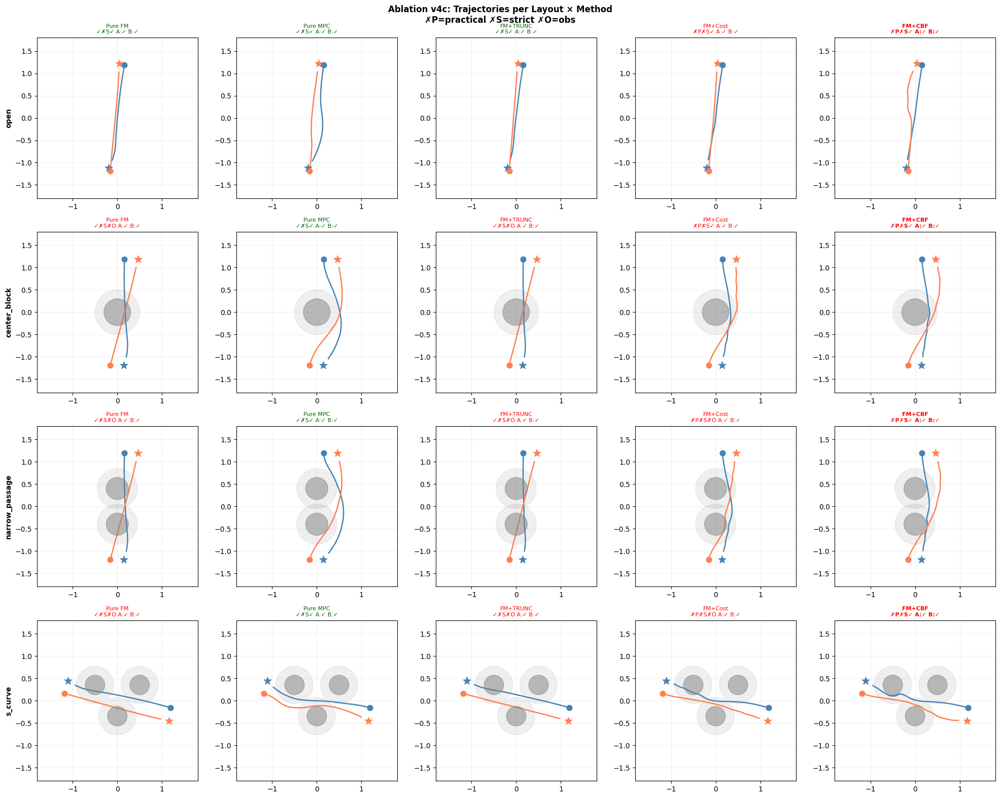

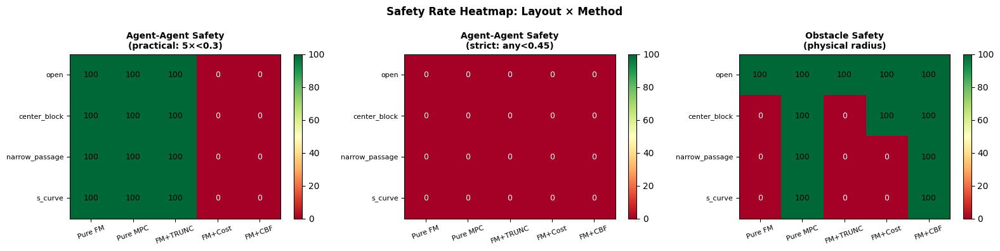


Saved: ablation_v4c_traj.png, ablation_v4c_heatmap.png

Done!


In [66]:
# ===============================================================
# 消融实验 v4c：最终版
# ★ R_COLLISION=0.30, collision_steps=5 避免正常交汇误判
# ★ s_curve 强制完整输出
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.30   # ★ 0.20→0.30
    R_OBS: float = 0.20
    arena_size: float = 1.2
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    replan_every: int = 1
    collision_steps: int = 5    # ★ 3→5

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

K_MPC          = 128
SIGMA_A        = 0.6
SIGMA_DR       = np.deg2rad(45.0)
MPC_LAMBDA     = 0.05
MPC_N_SUBSTEPS = 6

W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25
W_OBS      = 2000.0
W_OBS_SLOW = 5000.0

W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8
W_MPC_OBS     = 2000.0
W_MPC_LANE    = 1.5
W_MPC_CURV    = 0.5

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

YIELD_DIST   = 2.0
YIELD_OFFSET = 0.45

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

PATH_OBS_MARGIN      = cfg.R_OBS + 0.08
PATH_OBS_MARGIN_SLOW = cfg.R_OBS + 0.13
PATH_OBS_MARGIN_CBF  = cfg.R_OBS + 0.04

EXEC_SAFE_METHODS = {"FM+CBF"}

METHOD_NAMES = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]

# ===============================================================
# 静态障碍物定义
# ===============================================================
OBSTACLE_LAYOUTS = {
    "open": [],
    "center_block": [
        {"center": [0.0, 0.0], "radius": 0.30},
    ],
    "narrow_passage": [
        {"center": [ 0.0,  0.40], "radius": 0.25},
        {"center": [ 0.0, -0.40], "radius": 0.25},
    ],
    "s_curve": [
        {"center": [-0.50,  0.35], "radius": 0.22},
        {"center": [ 0.0,  -0.35], "radius": 0.22},
        {"center": [ 0.50,  0.35], "radius": 0.22},
    ],
}

ACTIVE_LAYOUTS = ["open", "center_block", "narrow_passage", "s_curve"]

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# 静态障碍物工具
# ===============================================================
def check_obs_collision(pos_xy, obstacles, r_agent=None):
    if r_agent is None:
        r_agent = cfg.R_OBS
    for obs in obstacles:
        c  = np.asarray(obs["center"], np.float32)
        rm = float(obs["radius"]) + r_agent
        if float(np.linalg.norm(pos_xy - c)) < rm:
            return True
    return False

def traj_obs_collision(traj_xy, obstacles, use_margin=False, is_slow=False):
    if len(obstacles) == 0:
        return False, float("inf")
    min_d = float("inf")
    hit   = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_phys = float(obs["radius"])
        rm     = r_phys + cfg.R_OBS + (0.10 if is_slow else 0.0) \
                 if use_margin else r_phys
        dists  = np.linalg.norm(traj_xy - c.reshape(1,2), axis=1)
        d_surf = float(dists.min()) - r_phys
        min_d  = min(min_d, d_surf)
        if float(dists.min()) < rm:
            hit = True
    return hit, min_d

# ===============================================================
# 执行层安全推出
# ===============================================================
def _push_out_of_obs(state, obstacles):
    if len(obstacles) == 0:
        return state
    pos    = state[:2].copy()
    pushed = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_safe = float(obs["radius"]) + 0.02
        diff   = pos - c
        dist   = float(np.linalg.norm(diff))
        if dist < r_safe:
            direction = diff / dist if dist > 1e-6 \
                        else np.array([1.0, 0.0], np.float32)
            pos       = (c + direction * (r_safe + 0.01)).astype(np.float32)
            pushed    = True
    if not pushed:
        return state
    new_state     = state.copy()
    new_state[:2] = pos
    return new_state

# ===============================================================
# 路径后处理
# ===============================================================
def post_process_path_obs(path_xy, obstacles, r_safe_margin=None):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(30):
        modified = False
        for i in range(len(path)):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_safe:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    path[i]  = (c + direction * (r_safe + 0.02)).astype(np.float32)
                    modified = True
        if not modified:
            break
    return path.astype(np.float32)

def post_process_path_smooth(path_xy, n_smooth=3, alpha=0.5):
    if len(path_xy) < 5:
        return path_xy
    path  = path_xy.copy()
    w_mid = 1.0 - alpha
    w_s   = alpha / 2.0
    for _ in range(n_smooth):
        new_path = path.copy()
        for i in range(1, len(path)-1):
            new_path[i] = w_s*path[i-1] + w_mid*path[i] + w_s*path[i+1]
        path = new_path
    return path.astype(np.float32)

def post_process_path_obs_soft(path_xy, obstacles, r_safe_margin=None,
                                n_iters=60, soft_falloff=2.5):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(n_iters):
        modified = False
        for i in range(1, len(path)-1):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                r_inf  = r_safe * soft_falloff
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_inf:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    if dist < r_safe:
                        push = (r_safe - dist + 0.015)
                    else:
                        t    = (dist - r_safe) / (r_inf - r_safe + 1e-6)
                        push = 0.3 * (r_safe - dist + 0.015) * (1.0 - t)
                        push = max(0.0, push)
                    if push > 1e-4:
                        path[i]  = (path[i] + direction * push * 0.6).astype(np.float32)
                        modified = True
        if not modified:
            break
    return path.astype(np.float32)

def smooth_path_spline(path_xy, n_out=None, smoothing=0.5):
    if len(path_xy) < 5:
        return path_xy
    if n_out is None:
        n_out = len(path_xy)
    x    = path_xy[:, 0].astype(float)
    y    = path_xy[:, 1].astype(float)
    diff = np.diff(np.stack([x, y], axis=1), axis=0)
    mask = np.concatenate([[True], np.linalg.norm(diff, axis=1) > 1e-5])
    x, y = x[mask], y[mask]
    if len(x) < 4:
        return path_xy
    try:
        tck, _   = splprep([x, y], s=smoothing, k=3)
        x_s, y_s = splev(np.linspace(0, 1, n_out), tck)
        result   = np.stack([x_s, y_s], axis=1).astype(np.float32)
        result[0]  = path_xy[0]
        result[-1] = path_xy[-1]
        return result
    except Exception:
        return path_xy

# ===============================================================
# 安全目标点生成
# ===============================================================
def _safe_goal(base_pos, obstacles, rng):
    if len(obstacles) == 0:
        noise = rng.uniform(-0.15, 0.15, 2).astype(np.float32)
        return (-base_pos + noise).astype(np.float32)

    def path_clear(start, end):
        for t in np.linspace(0.0, 1.0, 50):
            mid = start + t * (end - start)
            for obs in obstacles:
                c     = np.asarray(obs["center"], np.float32)
                r_chk = float(obs["radius"]) + cfg.R_OBS
                if float(np.linalg.norm(mid - c)) < r_chk:
                    return False
        return True

    def point_safe(g, margin=0.10):
        for obs in obstacles:
            c = np.asarray(obs["center"], np.float32)
            if float(np.linalg.norm(g - c)) < float(obs["radius"]) + cfg.R_OBS + margin:
                return False
        return True

    for _ in range(60):
        noise = rng.uniform(-0.45, 0.45, 2).astype(np.float32)
        g = (-base_pos + noise).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    for attempt in range(40):
        side   = 1.0 if attempt % 2 == 0 else -1.0
        offset = rng.uniform(0.3, 0.6) * side
        g = (-base_pos + perp * offset).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
        for dist in [0.4, 0.6, 0.8, 1.0]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g) and path_clear(base_pos, g):
                return g

    for angle in np.linspace(0, 2*np.pi, 32, endpoint=False):
        for dist in [0.3, 0.5, 0.7, 0.9]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g, margin=0.0):
                return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    return (-base_pos + perp * 0.5).astype(np.float32)

# ===============================================================
# 慢车主动让路
# ===============================================================
def _yield_biased_goal(self_pos, goal_xy, other_pos_now, v_max_self,
                       dist_AB, obstacles):
    is_slow  = v_max_self < 0.8
    goal_arr = np.asarray(goal_xy, np.float32)
    if not is_slow or dist_AB > YIELD_DIST:
        return goal_arr
    to_goal = goal_arr - np.asarray(self_pos, np.float32)
    to_goal_len = float(np.linalg.norm(to_goal))
    if to_goal_len < 1e-3:
        return goal_arr
    to_goal_unit = to_goal / to_goal_len
    perp  = np.array([-to_goal_unit[1], to_goal_unit[0]], np.float32)
    diff  = np.asarray(other_pos_now, np.float32) - np.asarray(self_pos, np.float32)
    cross = float(to_goal_unit[0]*diff[1] - to_goal_unit[1]*diff[0])
    proximity   = max(0.0, 1.0 - dist_AB / YIELD_DIST)
    side        = -1.0 if cross > 0 else 1.0
    offset      = side * YIELD_OFFSET * proximity
    goal_biased = (goal_arr + offset * perp).astype(np.float32)
    if obstacles and check_obs_collision(
            goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
        goal_biased = (goal_arr - offset * perp).astype(np.float32)
        if obstacles and check_obs_collision(
                goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
            return goal_arr
    return goal_biased

# ===============================================================
# 碰撞判定
# ===============================================================
def _check_collision_practical(dist_AB):
    """连续 collision_steps 步 < R_COLLISION → 碰撞"""
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

def _check_collision_strict(dist_AB):
    return bool(dist_AB.min() < cfg.R_SAFE)

def _min_dist_consecutive(dist_AB):
    N = cfg.collision_steps
    if len(dist_AB) < N:
        return float(dist_AB.min())
    min_avg = float("inf")
    for i in range(len(dist_AB) - N + 1):
        avg = float(dist_AB[i:i+N].mean())
        min_avg = min(min_avg, avg)
    return min_avg

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0
    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max); continue
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max-v_creep)*(d_goal/creep_radius), v_creep, v_max))
        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des-delta)/dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des-v)/dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max)
    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]; th = float(self_state[2])
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    if float(np.linalg.norm(seg_dir)) > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"
    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]; th = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des/dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3])/dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost
# ===============================================================
def compute_cost(pos_self, pos_other_pred, goal_xy, U,
                 obstacles=None, is_slow=False):
    goal_xy  = np.asarray(goal_xy, np.float32)
    d_end    = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path   = float(np.mean(np.linalg.norm(pos_self-goal_xy.reshape(1,2), axis=1)))
    M        = min(len(pos_self), len(pos_other_pred))
    min_d    = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M]-pos_other_pred[:M], axis=1).min())
    viol     = max(0.0, cfg.R_SAFE - min_d)
    coll     = float(viol * viol)
    w_obs    = W_OBS_SLOW if is_slow else W_OBS
    obs_cost = 0.0
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos_self - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            obs_cost += float(viol_obs * viol_obs)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + w_obs*obs_cost + W_SMOOTH*smooth

# ===============================================================
# MPC Dopri5
# ===============================================================
def _dopri5_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a  = float(np.clip(u[0], -a_max, a_max))
        dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2 = float(np.clip(v, v_min, v_max))
        d2 = float(np.clip(delta, -delta_max, delta_max))
        return np.array([v2*math.cos(th), v2*math.sin(th),
                         (v2/L)*math.tan(d2), a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + dt*(1/5)*k1)
    k3 = f(s + dt*(3/40)*k1    + dt*(9/40)*k2)
    k4 = f(s + dt*(44/45)*k1   + dt*(-56/15)*k2  + dt*(32/9)*k3)
    k5 = f(s + dt*(19372/6561)*k1 + dt*(-25360/2187)*k2
             + dt*(64448/6561)*k3  + dt*(-212/729)*k4)
    k6 = f(s + dt*(9017/3168)*k1  + dt*(-355/33)*k2
             + dt*(46732/5247)*k3  + dt*(49/176)*k4
             + dt*(-5103/18656)*k5)
    s_new = s + dt*(35/384*k1 + 500/1113*k3 + 125/192*k4
                    - 2187/6784*k5 + 11/84*k6)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _dopri5_rollout(s0, U, dt, v_max, n_substeps=6):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    dt_sub = dt / n_substeps
    for i in range(H):
        s_cur = st[i].copy()
        for _ in range(n_substeps):
            s_cur = _dopri5_step(s_cur, U[i], dt_sub, v_max)
        st[i+1] = s_cur
    return st

def _compute_mpc_cost_full(traj, U, goal_xy, other_pos,
                            v_max_self, obstacles=None, is_slow=False):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos = traj[:,:2]; th = traj[:,2]; vel = traj[:,3]
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path
    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M<=1 else float(
        np.linalg.norm(pos[:M]-other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol
    J_obs = 0.0
    w_obs = W_OBS_SLOW if is_slow else W_MPC_OBS
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            J_obs   += w_obs * viol_obs * viol_obs
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1]-goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))
    d_goals = np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius, v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel-v_des)**2))
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth= W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    ddU     = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk  = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))
    if len(pos) > 2:
        start_p   = pos[0]; end_p = pos[-1]
        lane_dir  = end_p - start_p
        lane_len  = float(np.linalg.norm(lane_dir)) + 1e-6
        lane_unit = lane_dir / lane_len
        lane_perp = np.array([-lane_unit[1], lane_unit[0]])
        deviations = np.abs((pos - start_p) @ lane_perp)
        J_lane = W_MPC_LANE * float(np.mean(deviations**2))
    else:
        J_lane = 0.0
    delta_vals = traj[:,4]
    d_delta    = np.diff(delta_vals, prepend=delta_vals[0])
    J_curv     = W_MPC_CURV * float(np.mean(d_delta**2))
    return (J_goal + J_coll + J_obs + J_heading + J_vel
            + J_smooth + J_jerk + J_lane + J_curv)

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0

def get_cbf_config(dist_AB, has_obstacles=False, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if has_obstacles:              return True, strong
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                          return True, strong

def build_ellipses(tf, other_pred_pos, dist_AB,
                   static_obstacles=None, is_slow=False):
    ellipses = []
    if other_pred_pos is not None and len(other_pred_pos) >= 2:
        idxs = sorted(list(dict.fromkeys(
            [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
             if 0 <= i < len(other_pred_pos)])))
        r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
            else (r_obs_near if dist_AB < 1.2 else r_obs_far)
        for i in idxs:
            ellipses.append({"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
                             "radius": float(r)})
    if static_obstacles:
        extra = 0.25 if is_slow else 0.15
        for obs in static_obstacles:
            c_world = np.asarray(obs["center"], np.float32).reshape(1,2)
            c_can   = tf["w2c"](c_world)[0]
            ellipses.append({"center": c_can,
                             "radius": float(obs["radius"]) + cfg.R_OBS + extra})
    return ellipses

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed,
                   use_cbf, cbf_kwargs, static_obstacles=None,
                   v_max_self=1.0, use_soft_postproc=False,
                   num_segments=None, ode_method=None):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    is_slow   = v_max_self < 0.8
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB,
                                static_obstacles=static_obstacles,
                                is_slow=is_slow) if use_cbf else []
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)
    _num_seg = num_segments if num_segments is not None else cfg.num_segments_fm
    _ode     = ode_method   if ode_method   is not None else ode_method_fm
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=_num_seg,
        ode_method=_ode, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
        tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
    )
    xy_can     = x_can[0:2,:].T.astype(np.float32)
    path_world = tf["c2w"](xy_can).astype(np.float32)
    if static_obstacles and len(static_obstacles) > 0:
        if use_soft_postproc:
            r_margin = PATH_OBS_MARGIN_CBF + (0.04 if is_slow else 0.0)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin, n_iters=80, soft_falloff=2.0)
            path_world = smooth_path_spline(
                path_world, n_out=len(path_world), smoothing=0.8)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin - 0.01, n_iters=20, soft_falloff=1.5)
        else:
            r_margin   = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin)
            path_world = post_process_path_smooth(
                path_world, n_smooth=4, alpha=0.5)
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin - 0.02)
    return path_world

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, obstacles=None, K_override=None,
              use_soft_postproc=False, num_segments=None, ode_method=None):
    K_use   = K_override if K_override is not None else cfg.K
    is_slow = v_max_self < 0.8
    best    = None
    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs,
                                     static_obstacles=obstacles,
                                     v_max_self=v_max_self,
                                     use_soft_postproc=use_soft_postproc,
                                     num_segments=num_segments,
                                     ode_method=ode_method)
        except Exception:
            continue
        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            continue
        U  = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                    H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J  = compute_cost(st[:,:2], other_pred_pos, goal_xy, U,
                          obstacles=obstacles, is_slow=is_slow)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    rng       = np.random.RandomState(seed)
    is_slow   = v_max_self < 0.8
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    straight  = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    if obstacles and len(obstacles) > 0:
        r_margin = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
        straight = post_process_path_obs(straight, obstacles,
                                          r_safe_margin=r_margin)
        straight = post_process_path_smooth(straight, n_smooth=2, alpha=0.4)
    U_nom = pure_pursuit_controls(sA, straight, gA,
                                   H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR
    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0]+eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1]+eps_dr[k], -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj = _dopri5_rollout(sA, U_samples[k], cfg.dt,
                                v_max_self, n_substeps=MPC_N_SUBSTEPS)
        c = _compute_mpc_cost_full(traj, U_samples[k], gA, other_pos,
                                    v_max_self, obstacles=obstacles,
                                    is_slow=is_slow)
        if obstacles:
            hit, _ = traj_obs_collision(traj[:,:2], obstacles,
                                         use_margin=True, is_slow=is_slow)
            if hit:
                c += (10000.0 if is_slow else 5000.0)
        costs[k] = c
    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i]-other_pos[i]) < cfg.R_SAFE*1.2 and i > 2:
            t     = np.linspace(0, 1, cfg.T_steps-i).reshape(-1,1)
            patch = (path[i-1] + t*(gA-path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None,
                           obstacles=obstacles, use_soft_postproc=False,
                           num_segments=cfg.num_segments_fm,
                           ode_method=ode_method_fm)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                  obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    has_obs   = obstacles is not None and len(obstacles) > 0
    other_now = sB[:2] if (other_pos is None or len(other_pos) == 0) \
                else other_pos[0]
    gA_eff = _yield_biased_goal(
        self_pos=sA[:2], goal_xy=gA,
        other_pos_now=other_now, v_max_self=v_max_self,
        dist_AB=dist_AB, obstacles=obstacles,
    )
    use_cbf, cbf_kw = get_cbf_config(dist_AB,
                                      has_obstacles=has_obs,
                                      v_max_self=v_max_self)
    u0, cbf_flag = _mpc_core(sA, gA_eff, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw, obstacles=obstacles,
                              use_soft_postproc=True,
                              num_segments=cfg.num_segments_cbf,
                              ode_method=ode_method_cbf)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, layout_name="open", method_name=""):
    rng           = np.random.RandomState(seed)
    obstacles     = OBSTACLE_LAYOUTS[layout_name]
    r             = cfg.arena_size
    use_exec_safe = method_name in EXEC_SAFE_METHODS

    ang = rng.uniform(0, 2*np.pi)
    if len(obstacles) > 0:
        obs_center = np.mean([obs["center"] for obs in obstacles], axis=0)
        obs_angle  = math.atan2(obs_center[1], obs_center[0])
        ang_diff   = abs(wrap_pi(ang - obs_angle))
        if ang_diff < np.deg2rad(30):
            ang += np.deg2rad(90) * (1.0 if rng.rand() > 0.5 else -1.0)

    xA0 = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0 = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)

    if layout_name == "s_curve":
        perp = np.array([-np.sin(ang), np.cos(ang)], np.float32)
        gA   = (-xA0 + 0.35*perp + rng.uniform(-0.08,0.08,2).astype(np.float32))
        gB   = (-xB0 - 0.35*perp + rng.uniform(-0.08,0.08,2).astype(np.float32))
    else:
        gA = _safe_goal(xA0, obstacles, rng)
        gB = _safe_goal(xB0, obstacles, rng)

    for pos in [xA0, xB0]:
        if check_obs_collision(pos, obstacles, r_agent=cfg.R_OBS+0.05):
            pos += rng.uniform(-0.3, 0.3, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000+step*31, obstacles=obstacles)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000+step*37, obstacles=obstacles)
                cbf_used += c
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
            if use_exec_safe:
                sA = _push_out_of_obs(sA, obstacles)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
            if use_exec_safe:
                sB = _push_out_of_obs(sB, obstacles)
        trajA.append(sA.copy()); trajB.append(sB.copy())

    trajA   = np.array(trajA); trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2]-trajB[:,:2], axis=1)
    obs_coll_A, min_obs_A = traj_obs_collision(trajA[:,:2], obstacles, use_margin=False)
    obs_coll_B, min_obs_B = traj_obs_collision(trajB[:,:2], obstacles, use_margin=False)

    coll_prac   = _check_collision_practical(dist_AB)
    coll_strict = _check_collision_strict(dist_AB)

    return {
        'layout':          layout_name,
        'success_A':       float(np.linalg.norm(trajA[-1,:2]-gA)) < cfg.goal_tol,
        'success_B':       float(np.linalg.norm(trajB[-1,:2]-gB)) < cfg.goal_tol,
        'collision':       coll_prac,
        'collision_strict':coll_strict,
        'obs_coll':        bool(obs_coll_A or obs_coll_B),
        'any_coll':        bool(coll_prac or obs_coll_A or obs_coll_B),
        'min_dist':        float(dist_AB.min()),
        'min_dist_consec': _min_dist_consecutive(dist_AB),
        'min_obs_dist':    min(min_obs_A, min_obs_B),
        'steps':           len(trajA),
        'cbf_used':        cbf_used,
        # ★ 始终存轨迹
        'trajA': trajA, 'trajB': trajB,
        'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
        'dist_AB': dist_AB, 'obstacles': obstacles,
    }

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }
    all_results   = {lay: {n: [] for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}
    example_trajs = {lay: {n: None for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}
    timing        = {lay: {n: None for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}  # ★

    print("=" * 72)
    print(f"Ablation v4c | Trials={cfg.n_trials} | Layouts={ACTIVE_LAYOUTS}")
    print(f"W_OBS={W_OBS} | R_OBS={cfg.R_OBS}")
    print(f"★ Collision: 连续{cfg.collision_steps}步 < R_COLLISION={cfg.R_COLLISION}")
    print(f"★ MPC: K={K_MPC} Dopri5 substeps={MPC_N_SUBSTEPS} + lane/curv cost")
    print(f"★ FM+CBF: euler seg={cfg.num_segments_cbf} (fast)")
    print(f"★ FM others: euler seg={cfg.num_segments_fm}")
    print(f"★ Exec safe: {EXEC_SAFE_METHODS}")
    print("=" * 72)

    for layout in ACTIVE_LAYOUTS:
        print(f"\n── Layout: {layout} ──")
        for name, fn in methods.items():
            t0 = time.time()
            print(f"  {name:<12}", end=" ", flush=True)
            for trial in range(cfg.n_trials):
                try:
                    r = run_trial(fn, 5000+trial*77,
                                  layout_name=layout,
                                  method_name=name)
                    all_results[layout][name].append(r)
                    if example_trajs[layout][name] is None:
                        example_trajs[layout][name] = r
                except Exception as e:
                    print(f"x[{e}]", end="", flush=True)
                if (trial+1) % 5 == 0:
                    print(".", end="", flush=True)
            elapsed = time.time() - t0          # ★
            timing[layout][name] = elapsed      # ★
            print(f" {elapsed:.1f}s")           # ★

    return all_results, example_trajs, timing   # ★


# # ===============================================================
# # 入口
# # ===============================================================
# print("Starting Ablation v4c...\n")
# all_results, example_trajs, timing = run_ablation()   # ★
# show_results(all_results, example_trajs)
# print("\nDone!")

# ===============================================================
# 结果打印（完整输出所有场景）
# ===============================================================
def show_results(all_results, example_trajs):

    # ── 文字表格 ──
    sep  = "=" * 108
    line = "-" * 108

    print("\n" + sep)
    print(f"{'Layout':<18} {'Method':<12} "
      f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
      f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8} {'MinD(N)':>8} {'CalcTime':>9}")
    print(f"{'':18} {'':12} "
      f"{f'{cfg.collision_steps}x<{cfg.R_COLLISION}':>9} "
      f"{'any<0.45':>9} {'phys_r':>9} "
      f"{'':>7} {'':>7} {'overall':>8} {'consec':>8} {'wall(s)':>9}")
    print(line)

    for layout in ACTIVE_LAYOUTS:
        print(f"\n  ▶ {layout}")
        print(line)
        for name in METHOD_NAMES:
            rs     = all_results[layout][name]
            n      = len(rs)
            t_wall = timing[layout][name]
            t_str  = f"{t_wall:.1f}s" if t_wall is not None else "N/A"
            if n == 0:
                print(f"  {name:<12}   N/A")
                continue
            safe_p   = sum(1 for r in rs if not r['collision'])          / n * 100
            safe_s   = sum(1 for r in rs if not r['collision_strict'])   / n * 100
            obs_safe = sum(1 for r in rs if not r['obs_coll'])           / n * 100
            gA_r     = sum(1 for r in rs if r['success_A'])              / n * 100
            gB_r     = sum(1 for r in rs if r['success_B'])              / n * 100
            md       = np.mean([r['min_dist']        for r in rs])
            md_c     = np.mean([r['min_dist_consec'] for r in rs])
            marker   = " ★" if name == "FM+CBF" else ""
            print(f"  {name:<12} "
                f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
                f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
                f"{md:>8.3f} {md_c:>8.3f} {t_str:>9}{marker}")
        print(line)

    print("\n" + sep)
    print(f"Safe%(p)  = 连续{cfg.collision_steps}步<{cfg.R_COLLISION} 不触发 → 主要指标")
    print(f"Safe%(s)  = 任意一步<{cfg.R_SAFE} 不触发 → 严格参考")
    print(f"MinD(N)   = 连续{cfg.collision_steps}步窗口最小均值距离")
    print(f"CalcTime  = 实际 wall clock 计算时间")
    print(sep)
    print(f"Safe%(p) = 连续{cfg.collision_steps}步<{cfg.R_COLLISION} 不触发 → 主要指标")
    print(f"Safe%(s) = 任意一步<{cfg.R_SAFE} 不触发 → 严格参考")
    print(f"MinD(N)  = 连续{cfg.collision_steps}步窗口最小均值距离")

    # ── 轨迹图 ──
    n_m = len(METHOD_NAMES)
    n_l = len(ACTIVE_LAYOUTS)
    fig, axes = plt.subplots(n_l, n_m, figsize=(4*n_m, 4*n_l))
    if n_l == 1: axes = axes.reshape(1, -1)

    for row, layout in enumerate(ACTIVE_LAYOUTS):
        obstacles = OBSTACLE_LAYOUTS[layout]
        for col, mname in enumerate(METHOD_NAMES):
            ax   = axes[row][col]
            data = example_trajs[layout][mname]
            for obs in obstacles:
                ax.add_patch(plt.Circle(obs["center"], obs["radius"],
                                        color='gray', alpha=0.5, zorder=3))
                ax.add_patch(plt.Circle(obs["center"],
                                        obs["radius"]+cfg.R_OBS,
                                        color='gray', alpha=0.12, zorder=2))
            if data:
                trajA = data['trajA']; trajB = data['trajB']
                ax.plot(trajA[:,0], trajA[:,1], color='steelblue', lw=1.8)
                ax.plot(trajB[:,0], trajB[:,1], color='coral',     lw=1.8)
                ax.scatter(*data['xA0'], c='steelblue', s=60,  marker='o', zorder=5)
                ax.scatter(*data['gA'],  c='steelblue', s=120, marker='*', zorder=5)
                ax.scatter(*data['xB0'], c='coral',     s=60,  marker='o', zorder=5)
                ax.scatter(*data['gB'],  c='coral',     s=120, marker='*', zorder=5)
                p_str = "✓" if not data['collision']       else "✗P"
                s_str = "✓" if not data['collision_strict'] else "✗S"
                o_str = "✓" if not data['obs_coll']         else "✗O"
                g_str = (f"A:{'✓' if data['success_A'] else '✗'} "
                         f"B:{'✓' if data['success_B'] else '✗'}")
                ok = not data['any_coll']
                ax.set_title(f"{mname}\n{p_str}{s_str}{o_str} {g_str}",
                             fontsize=8,
                             color='darkgreen' if ok else 'red',
                             fontweight='bold' if mname=='FM+CBF' else 'normal')
            else:
                ax.set_title(f"{mname}\nN/A", fontsize=8, color='gray')
            ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
            ax.set_aspect('equal'); ax.grid(alpha=0.2)
            if col == 0:
                ax.set_ylabel(layout, fontsize=10, fontweight='bold')

    plt.suptitle('Ablation v4c: Trajectories per Layout × Method\n'
                 '✗P=practical ✗S=strict ✗O=obs',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_traj.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── 热力图 ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('safe_prac',
         f'Agent-Agent Safety\n(practical: {cfg.collision_steps}×<{cfg.R_COLLISION})'),
        ('safe_strict',
         'Agent-Agent Safety\n(strict: any<0.45)'),
        ('obs_safe',
         'Obstacle Safety\n(physical radius)'),
    ]
    for ax_idx, (metric, title) in enumerate(metrics):
        mat = np.zeros((n_l, n_m))
        for i, lay in enumerate(ACTIVE_LAYOUTS):
            for j, mn in enumerate(METHOD_NAMES):
                rs = all_results[lay][mn]
                if not rs: continue
                if metric == 'safe_prac':
                    mat[i,j] = sum(1 for r in rs if not r['collision'])          / len(rs) * 100
                elif metric == 'safe_strict':
                    mat[i,j] = sum(1 for r in rs if not r['collision_strict'])   / len(rs) * 100
                else:
                    mat[i,j] = sum(1 for r in rs if not r['obs_coll'])           / len(rs) * 100
        im = axes[ax_idx].imshow(mat, vmin=0, vmax=100, cmap='RdYlGn', aspect='auto')
        axes[ax_idx].set_xticks(range(n_m))
        axes[ax_idx].set_xticklabels(METHOD_NAMES, rotation=20, fontsize=8)
        axes[ax_idx].set_yticks(range(n_l))
        axes[ax_idx].set_yticklabels(ACTIVE_LAYOUTS, fontsize=8)
        axes[ax_idx].set_title(title, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=axes[ax_idx])
        for i in range(n_l):
            for j in range(n_m):
                axes[ax_idx].text(j, i, f'{mat[i,j]:.0f}',
                                  ha='center', va='center', fontsize=9,
                                  color='black' if mat[i,j]>40 else 'white')

    plt.suptitle('Safety Rate Heatmap: Layout × Method',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("\nSaved: ablation_v4c_traj.png, ablation_v4c_heatmap.png")

# ===============================================================
# 入口
# ===============================================================
print("Starting Ablation v4c...\n")
all_results, example_trajs, timing = run_ablation()
show_results(all_results, example_trajs)
print("\nDone!")

In [67]:
# ===============================================================
# 重新打印完整表格（加分隔线，s_curve 清晰显示）
# ===============================================================

sep  = "=" * 108
line = "-" * 108

print("\n" + sep)
print(f"{'Layout':<18} {'Method':<12} "
      f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
      f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8} {'MinD(N)':>8} {'CalcTime':>9}")
print(f"{'':18} {'':12} "
      f"{f'{cfg.collision_steps}x<{cfg.R_COLLISION}':>9} "
      f"{'any<0.45':>9} {'phys_r':>9} "
      f"{'':>7} {'':>7} {'overall':>8} {'consec':>8} {'wall(s)':>9}")
print(line)

for layout in ACTIVE_LAYOUTS:
    print(f"\n  ▶ {layout}")
    print(line)
    for name in METHOD_NAMES:
        rs     = all_results[layout][name]
        n      = len(rs)
        # ★ 用 wall clock 时间替换 steps*dt
        t_wall = timing[layout][name]
        t_str  = f"{t_wall:.1f}s" if t_wall is not None else "N/A"
        if n == 0:
            print(f"  {name:<12}   N/A")
            continue
        safe_p   = sum(1 for r in rs if not r['collision'])          / n * 100
        safe_s   = sum(1 for r in rs if not r['collision_strict'])   / n * 100
        obs_safe = sum(1 for r in rs if not r['obs_coll'])           / n * 100
        gA_r     = sum(1 for r in rs if r['success_A'])              / n * 100
        gB_r     = sum(1 for r in rs if r['success_B'])              / n * 100
        md       = np.mean([r['min_dist']        for r in rs])
        md_c     = np.mean([r['min_dist_consec'] for r in rs])
        marker   = " ★" if name == "FM+CBF" else ""
        print(f"  {name:<12} "
              f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
              f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
              f"{md:>8.3f} {md_c:>8.3f} {t_str:>9}{marker}")
    print(line)

print("\n" + sep)
print(f"Safe%(p)  = 连续{cfg.collision_steps}步<{cfg.R_COLLISION} 不触发 → 主要指标")
print(f"Safe%(s)  = 任意一步<{cfg.R_SAFE} 不触发 → 严格参考")
print(f"MinD(N)   = 连续{cfg.collision_steps}步窗口最小均值距离")
print(f"CalcTime  = 实际 wall clock 计算时间（Pure MPC 最长）")
print(sep)


Layout             Method        Safe%(p)  Safe%(s)  ObsSafe%  GoalA%  GoalB%  MinDist  MinD(N)  CalcTime
                                   5x<0.3  any<0.45    phys_r                  overall   consec   wall(s)
------------------------------------------------------------------------------------------------------------

  ▶ open
------------------------------------------------------------------------------------------------------------
  Pure FM           100%        0%      100%    100%    100%    0.092    0.208      2.8s
  Pure MPC          100%        0%      100%    100%    100%    0.255    0.319     83.4s
  FM+TRUNC          100%        0%      100%    100%    100%    0.086    0.205      2.2s
  FM+Cost             0%        0%      100%    100%    100%    0.042    0.109      5.7s
  FM+CBF              0%        0%      100%    100%    100%    0.065    0.071      3.3s ★
------------------------------------------------------------------------------------------------------------

  

In [68]:
import sys

sep  = "=" * 108
line = "-" * 108

header = (f"{'Method':<12} "
          f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
          f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8} {'MinD(N)':>8} {'CalcTime':>9}")
subhdr = (f"{'':12} "
          f"{f'{cfg.collision_steps}x<{cfg.R_COLLISION}':>9} "
          f"{'any<0.45':>9} {'phys_r':>9} "
          f"{'':>7} {'':>7} {'overall':>8} {'consec':>8} {'wall(s)':>9}")

for layout in ["narrow_passage", "s_curve"]:
    print(sep, flush=True)
    print(f"  Layout: {layout}", flush=True)
    print(line, flush=True)
    print(header, flush=True)
    print(subhdr, flush=True)
    print(line, flush=True)
    for name in METHOD_NAMES:
        rs     = all_results[layout][name]
        n      = len(rs)
        # ★ 用 wall clock 时间
        t_wall = timing[layout][name]
        t_str  = f"{t_wall:.1f}s" if t_wall is not None else "N/A"
        if n == 0:
            print(f"{name:<12}   N/A", flush=True)
            continue
        safe_p   = sum(1 for r in rs if not r['collision'])          / n * 100
        safe_s   = sum(1 for r in rs if not r['collision_strict'])   / n * 100
        obs_safe = sum(1 for r in rs if not r['obs_coll'])           / n * 100
        gA_r     = sum(1 for r in rs if r['success_A'])              / n * 100
        gB_r     = sum(1 for r in rs if r['success_B'])              / n * 100
        md       = np.mean([r['min_dist']        for r in rs])
        md_c     = np.mean([r['min_dist_consec'] for r in rs])
        marker   = " ★" if name == "FM+CBF" else ""
        print(f"{name:<12} "
              f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
              f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
              f"{md:>8.3f} {md_c:>8.3f} {t_str:>9}{marker}",
              flush=True)
    print(line, flush=True)
    print("", flush=True)
    sys.stdout.flush()

  Layout: narrow_passage
------------------------------------------------------------------------------------------------------------
Method        Safe%(p)  Safe%(s)  ObsSafe%  GoalA%  GoalB%  MinDist  MinD(N)  CalcTime
                5x<0.3  any<0.45    phys_r                  overall   consec   wall(s)
------------------------------------------------------------------------------------------------------------
Pure FM           100%        0%        0%    100%    100%    0.114    0.226      2.4s
Pure MPC          100%        0%      100%    100%    100%    0.226    0.292     95.1s
FM+TRUNC          100%        0%        0%    100%    100%    0.115    0.224      2.6s
FM+Cost             0%        0%        0%    100%    100%    0.091    0.095      7.3s
FM+CBF              0%        0%      100%    100%    100%    0.129    0.132      6.1s ★
------------------------------------------------------------------------------------------------------------

  Layout: s_curve
------------------

In [ ]:
# ===============================================================
# 消融实验 v4c：最终版
# ★ R_COLLISION=0.30, collision_steps=5 避免正常交汇误判
# ★ s_curve 强制完整输出
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.30   # ★ 0.20→0.30
    R_OBS: float = 0.20
    arena_size: float = 1.2
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    replan_every: int = 1
    collision_steps: int = 5    # ★ 3→5

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

K_MPC          = 128
SIGMA_A        = 0.6
SIGMA_DR       = np.deg2rad(45.0)
MPC_LAMBDA     = 0.05
MPC_N_SUBSTEPS = 6

W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25
W_OBS      = 2000.0
W_OBS_SLOW = 5000.0

W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8
W_MPC_OBS     = 2000.0
W_MPC_LANE    = 1.5
W_MPC_CURV    = 0.5

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

YIELD_DIST   = 2.0
YIELD_OFFSET = 0.45

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

PATH_OBS_MARGIN      = cfg.R_OBS + 0.08
PATH_OBS_MARGIN_SLOW = cfg.R_OBS + 0.13
PATH_OBS_MARGIN_CBF  = cfg.R_OBS + 0.04

EXEC_SAFE_METHODS = {"FM+CBF"}

METHOD_NAMES = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]

# ===============================================================
# 静态障碍物定义
# ===============================================================
OBSTACLE_LAYOUTS = {
    "open": [],
    "center_block": [
        {"center": [0.0, 0.0], "radius": 0.30},
    ],
    "narrow_passage": [
        {"center": [ 0.0,  0.40], "radius": 0.25},
        {"center": [ 0.0, -0.40], "radius": 0.25},
    ],
    "s_curve": [
        {"center": [-0.50,  0.35], "radius": 0.22},
        {"center": [ 0.0,  -0.35], "radius": 0.22},
        {"center": [ 0.50,  0.35], "radius": 0.22},
    ],
}

ACTIVE_LAYOUTS = ["open", "center_block", "narrow_passage", "s_curve"]

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# 静态障碍物工具
# ===============================================================
def check_obs_collision(pos_xy, obstacles, r_agent=None):
    if r_agent is None:
        r_agent = cfg.R_OBS
    for obs in obstacles:
        c  = np.asarray(obs["center"], np.float32)
        rm = float(obs["radius"]) + r_agent
        if float(np.linalg.norm(pos_xy - c)) < rm:
            return True
    return False

def traj_obs_collision(traj_xy, obstacles, use_margin=False, is_slow=False):
    if len(obstacles) == 0:
        return False, float("inf")
    min_d = float("inf")
    hit   = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_phys = float(obs["radius"])
        rm     = r_phys + cfg.R_OBS + (0.10 if is_slow else 0.0) \
                 if use_margin else r_phys
        dists  = np.linalg.norm(traj_xy - c.reshape(1,2), axis=1)
        d_surf = float(dists.min()) - r_phys
        min_d  = min(min_d, d_surf)
        if float(dists.min()) < rm:
            hit = True
    return hit, min_d

# ===============================================================
# 执行层安全推出
# ===============================================================
def _push_out_of_obs(state, obstacles):
    if len(obstacles) == 0:
        return state
    pos    = state[:2].copy()
    pushed = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_safe = float(obs["radius"]) + 0.02
        diff   = pos - c
        dist   = float(np.linalg.norm(diff))
        if dist < r_safe:
            direction = diff / dist if dist > 1e-6 \
                        else np.array([1.0, 0.0], np.float32)
            pos       = (c + direction * (r_safe + 0.01)).astype(np.float32)
            pushed    = True
    if not pushed:
        return state
    new_state     = state.copy()
    new_state[:2] = pos
    return new_state

# ===============================================================
# 路径后处理
# ===============================================================
def post_process_path_obs(path_xy, obstacles, r_safe_margin=None):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(30):
        modified = False
        for i in range(len(path)):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_safe:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    path[i]  = (c + direction * (r_safe + 0.02)).astype(np.float32)
                    modified = True
        if not modified:
            break
    return path.astype(np.float32)

def post_process_path_smooth(path_xy, n_smooth=3, alpha=0.5):
    if len(path_xy) < 5:
        return path_xy
    path  = path_xy.copy()
    w_mid = 1.0 - alpha
    w_s   = alpha / 2.0
    for _ in range(n_smooth):
        new_path = path.copy()
        for i in range(1, len(path)-1):
            new_path[i] = w_s*path[i-1] + w_mid*path[i] + w_s*path[i+1]
        path = new_path
    return path.astype(np.float32)

def post_process_path_obs_soft(path_xy, obstacles, r_safe_margin=None,
                                n_iters=60, soft_falloff=2.5):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(n_iters):
        modified = False
        for i in range(1, len(path)-1):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                r_inf  = r_safe * soft_falloff
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_inf:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    if dist < r_safe:
                        push = (r_safe - dist + 0.015)
                    else:
                        t    = (dist - r_safe) / (r_inf - r_safe + 1e-6)
                        push = 0.3 * (r_safe - dist + 0.015) * (1.0 - t)
                        push = max(0.0, push)
                    if push > 1e-4:
                        path[i]  = (path[i] + direction * push * 0.6).astype(np.float32)
                        modified = True
        if not modified:
            break
    return path.astype(np.float32)

def smooth_path_spline(path_xy, n_out=None, smoothing=0.5):
    if len(path_xy) < 5:
        return path_xy
    if n_out is None:
        n_out = len(path_xy)
    x    = path_xy[:, 0].astype(float)
    y    = path_xy[:, 1].astype(float)
    diff = np.diff(np.stack([x, y], axis=1), axis=0)
    mask = np.concatenate([[True], np.linalg.norm(diff, axis=1) > 1e-5])
    x, y = x[mask], y[mask]
    if len(x) < 4:
        return path_xy
    try:
        tck, _   = splprep([x, y], s=smoothing, k=3)
        x_s, y_s = splev(np.linspace(0, 1, n_out), tck)
        result   = np.stack([x_s, y_s], axis=1).astype(np.float32)
        result[0]  = path_xy[0]
        result[-1] = path_xy[-1]
        return result
    except Exception:
        return path_xy

# ===============================================================
# 安全目标点生成
# ===============================================================
def _safe_goal(base_pos, obstacles, rng):
    if len(obstacles) == 0:
        noise = rng.uniform(-0.15, 0.15, 2).astype(np.float32)
        return (-base_pos + noise).astype(np.float32)

    def path_clear(start, end):
        for t in np.linspace(0.0, 1.0, 50):
            mid = start + t * (end - start)
            for obs in obstacles:
                c     = np.asarray(obs["center"], np.float32)
                r_chk = float(obs["radius"]) + cfg.R_OBS
                if float(np.linalg.norm(mid - c)) < r_chk:
                    return False
        return True

    def point_safe(g, margin=0.10):
        for obs in obstacles:
            c = np.asarray(obs["center"], np.float32)
            if float(np.linalg.norm(g - c)) < float(obs["radius"]) + cfg.R_OBS + margin:
                return False
        return True

    for _ in range(60):
        noise = rng.uniform(-0.45, 0.45, 2).astype(np.float32)
        g = (-base_pos + noise).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    for attempt in range(40):
        side   = 1.0 if attempt % 2 == 0 else -1.0
        offset = rng.uniform(0.3, 0.6) * side
        g = (-base_pos + perp * offset).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
        for dist in [0.4, 0.6, 0.8, 1.0]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g) and path_clear(base_pos, g):
                return g

    for angle in np.linspace(0, 2*np.pi, 32, endpoint=False):
        for dist in [0.3, 0.5, 0.7, 0.9]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g, margin=0.0):
                return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    return (-base_pos + perp * 0.5).astype(np.float32)

# ===============================================================
# 慢车主动让路
# ===============================================================
def _yield_biased_goal(self_pos, goal_xy, other_pos_now, v_max_self,
                       dist_AB, obstacles):
    is_slow  = v_max_self < 0.8
    goal_arr = np.asarray(goal_xy, np.float32)
    if not is_slow or dist_AB > YIELD_DIST:
        return goal_arr
    to_goal = goal_arr - np.asarray(self_pos, np.float32)
    to_goal_len = float(np.linalg.norm(to_goal))
    if to_goal_len < 1e-3:
        return goal_arr
    to_goal_unit = to_goal / to_goal_len
    perp  = np.array([-to_goal_unit[1], to_goal_unit[0]], np.float32)
    diff  = np.asarray(other_pos_now, np.float32) - np.asarray(self_pos, np.float32)
    cross = float(to_goal_unit[0]*diff[1] - to_goal_unit[1]*diff[0])
    proximity   = max(0.0, 1.0 - dist_AB / YIELD_DIST)
    side        = -1.0 if cross > 0 else 1.0
    offset      = side * YIELD_OFFSET * proximity
    goal_biased = (goal_arr + offset * perp).astype(np.float32)
    if obstacles and check_obs_collision(
            goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
        goal_biased = (goal_arr - offset * perp).astype(np.float32)
        if obstacles and check_obs_collision(
                goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
            return goal_arr
    return goal_biased

# ===============================================================
# 碰撞判定
# ===============================================================
def _check_collision_practical(dist_AB):
    """连续 collision_steps 步 < R_COLLISION → 碰撞"""
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

def _check_collision_strict(dist_AB):
    return bool(dist_AB.min() < cfg.R_SAFE)

def _min_dist_consecutive(dist_AB):
    N = cfg.collision_steps
    if len(dist_AB) < N:
        return float(dist_AB.min())
    min_avg = float("inf")
    for i in range(len(dist_AB) - N + 1):
        avg = float(dist_AB[i:i+N].mean())
        min_avg = min(min_avg, avg)
    return min_avg

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0
    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max); continue
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max-v_creep)*(d_goal/creep_radius), v_creep, v_max))
        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des-delta)/dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des-v)/dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max)
    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]; th = float(self_state[2])
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    if float(np.linalg.norm(seg_dir)) > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"
    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]; th = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des/dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3])/dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost
# ===============================================================
def compute_cost(pos_self, pos_other_pred, goal_xy, U,
                 obstacles=None, is_slow=False):
    goal_xy  = np.asarray(goal_xy, np.float32)
    d_end    = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path   = float(np.mean(np.linalg.norm(pos_self-goal_xy.reshape(1,2), axis=1)))
    M        = min(len(pos_self), len(pos_other_pred))
    min_d    = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M]-pos_other_pred[:M], axis=1).min())
    viol     = max(0.0, cfg.R_SAFE - min_d)
    coll     = float(viol * viol)
    w_obs    = W_OBS_SLOW if is_slow else W_OBS
    obs_cost = 0.0
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos_self - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            obs_cost += float(viol_obs * viol_obs)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + w_obs*obs_cost + W_SMOOTH*smooth

# ===============================================================
# MPC Dopri5
# ===============================================================
def _dopri5_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a  = float(np.clip(u[0], -a_max, a_max))
        dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2 = float(np.clip(v, v_min, v_max))
        d2 = float(np.clip(delta, -delta_max, delta_max))
        return np.array([v2*math.cos(th), v2*math.sin(th),
                         (v2/L)*math.tan(d2), a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + dt*(1/5)*k1)
    k3 = f(s + dt*(3/40)*k1    + dt*(9/40)*k2)
    k4 = f(s + dt*(44/45)*k1   + dt*(-56/15)*k2  + dt*(32/9)*k3)
    k5 = f(s + dt*(19372/6561)*k1 + dt*(-25360/2187)*k2
             + dt*(64448/6561)*k3  + dt*(-212/729)*k4)
    k6 = f(s + dt*(9017/3168)*k1  + dt*(-355/33)*k2
             + dt*(46732/5247)*k3  + dt*(49/176)*k4
             + dt*(-5103/18656)*k5)
    s_new = s + dt*(35/384*k1 + 500/1113*k3 + 125/192*k4
                    - 2187/6784*k5 + 11/84*k6)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _dopri5_rollout(s0, U, dt, v_max, n_substeps=6):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    dt_sub = dt / n_substeps
    for i in range(H):
        s_cur = st[i].copy()
        for _ in range(n_substeps):
            s_cur = _dopri5_step(s_cur, U[i], dt_sub, v_max)
        st[i+1] = s_cur
    return st

def _compute_mpc_cost_full(traj, U, goal_xy, other_pos,
                            v_max_self, obstacles=None, is_slow=False):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos = traj[:,:2]; th = traj[:,2]; vel = traj[:,3]
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path
    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M<=1 else float(
        np.linalg.norm(pos[:M]-other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol
    J_obs = 0.0
    w_obs = W_OBS_SLOW if is_slow else W_MPC_OBS
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            J_obs   += w_obs * viol_obs * viol_obs
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1]-goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))
    d_goals = np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius, v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel-v_des)**2))
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth= W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    ddU     = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk  = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))
    if len(pos) > 2:
        start_p   = pos[0]; end_p = pos[-1]
        lane_dir  = end_p - start_p
        lane_len  = float(np.linalg.norm(lane_dir)) + 1e-6
        lane_unit = lane_dir / lane_len
        lane_perp = np.array([-lane_unit[1], lane_unit[0]])
        deviations = np.abs((pos - start_p) @ lane_perp)
        J_lane = W_MPC_LANE * float(np.mean(deviations**2))
    else:
        J_lane = 0.0
    delta_vals = traj[:,4]
    d_delta    = np.diff(delta_vals, prepend=delta_vals[0])
    J_curv     = W_MPC_CURV * float(np.mean(d_delta**2))
    return (J_goal + J_coll + J_obs + J_heading + J_vel
            + J_smooth + J_jerk + J_lane + J_curv)

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0

def get_cbf_config(dist_AB, has_obstacles=False, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if has_obstacles:              return True, strong
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                          return True, strong

def build_ellipses(tf, other_pred_pos, dist_AB,
                   static_obstacles=None, is_slow=False):
    ellipses = []
    if other_pred_pos is not None and len(other_pred_pos) >= 2:
        idxs = sorted(list(dict.fromkeys(
            [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
             if 0 <= i < len(other_pred_pos)])))
        r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
            else (r_obs_near if dist_AB < 1.2 else r_obs_far)
        for i in idxs:
            ellipses.append({"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
                             "radius": float(r)})
    if static_obstacles:
        extra = 0.25 if is_slow else 0.15
        for obs in static_obstacles:
            c_world = np.asarray(obs["center"], np.float32).reshape(1,2)
            c_can   = tf["w2c"](c_world)[0]
            ellipses.append({"center": c_can,
                             "radius": float(obs["radius"]) + cfg.R_OBS + extra})
    return ellipses

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed,
                   use_cbf, cbf_kwargs, static_obstacles=None,
                   v_max_self=1.0, use_soft_postproc=False,
                   num_segments=None, ode_method=None):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    is_slow   = v_max_self < 0.8
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB,
                                static_obstacles=static_obstacles,
                                is_slow=is_slow) if use_cbf else []
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)
    _num_seg = num_segments if num_segments is not None else cfg.num_segments_fm
    _ode     = ode_method   if ode_method   is not None else ode_method_fm
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=_num_seg,
        ode_method=_ode, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
        tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
    )
    xy_can     = x_can[0:2,:].T.astype(np.float32)
    path_world = tf["c2w"](xy_can).astype(np.float32)
    if static_obstacles and len(static_obstacles) > 0:
        if use_soft_postproc:
            r_margin = PATH_OBS_MARGIN_CBF + (0.04 if is_slow else 0.0)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin, n_iters=80, soft_falloff=2.0)
            path_world = smooth_path_spline(
                path_world, n_out=len(path_world), smoothing=0.8)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin - 0.01, n_iters=20, soft_falloff=1.5)
        else:
            r_margin   = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin)
            path_world = post_process_path_smooth(
                path_world, n_smooth=4, alpha=0.5)
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin - 0.02)
    return path_world

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, obstacles=None, K_override=None,
              use_soft_postproc=False, num_segments=None, ode_method=None):
    K_use   = K_override if K_override is not None else cfg.K
    is_slow = v_max_self < 0.8
    best    = None
    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs,
                                     static_obstacles=obstacles,
                                     v_max_self=v_max_self,
                                     use_soft_postproc=use_soft_postproc,
                                     num_segments=num_segments,
                                     ode_method=ode_method)
        except Exception:
            continue
        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            continue
        U  = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                    H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J  = compute_cost(st[:,:2], other_pred_pos, goal_xy, U,
                          obstacles=obstacles, is_slow=is_slow)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    rng       = np.random.RandomState(seed)
    is_slow   = v_max_self < 0.8
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    straight  = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    if obstacles and len(obstacles) > 0:
        r_margin = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
        straight = post_process_path_obs(straight, obstacles,
                                          r_safe_margin=r_margin)
        straight = post_process_path_smooth(straight, n_smooth=2, alpha=0.4)
    U_nom = pure_pursuit_controls(sA, straight, gA,
                                   H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR
    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0]+eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1]+eps_dr[k], -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj = _dopri5_rollout(sA, U_samples[k], cfg.dt,
                                v_max_self, n_substeps=MPC_N_SUBSTEPS)
        c = _compute_mpc_cost_full(traj, U_samples[k], gA, other_pos,
                                    v_max_self, obstacles=obstacles,
                                    is_slow=is_slow)
        if obstacles:
            hit, _ = traj_obs_collision(traj[:,:2], obstacles,
                                         use_margin=True, is_slow=is_slow)
            if hit:
                c += (10000.0 if is_slow else 5000.0)
        costs[k] = c
    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i]-other_pos[i]) < cfg.R_SAFE*1.2 and i > 2:
            t     = np.linspace(0, 1, cfg.T_steps-i).reshape(-1,1)
            patch = (path[i-1] + t*(gA-path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None,
                           obstacles=obstacles, use_soft_postproc=False,
                           num_segments=cfg.num_segments_fm,
                           ode_method=ode_method_fm)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                  obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    has_obs   = obstacles is not None and len(obstacles) > 0
    other_now = sB[:2] if (other_pos is None or len(other_pos) == 0) \
                else other_pos[0]
    gA_eff = _yield_biased_goal(
        self_pos=sA[:2], goal_xy=gA,
        other_pos_now=other_now, v_max_self=v_max_self,
        dist_AB=dist_AB, obstacles=obstacles,
    )
    use_cbf, cbf_kw = get_cbf_config(dist_AB,
                                      has_obstacles=has_obs,
                                      v_max_self=v_max_self)
    u0, cbf_flag = _mpc_core(sA, gA_eff, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw, obstacles=obstacles,
                              use_soft_postproc=True,
                              num_segments=cfg.num_segments_cbf,
                              ode_method=ode_method_cbf)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, layout_name="open", method_name=""):
    rng           = np.random.RandomState(seed)
    obstacles     = OBSTACLE_LAYOUTS[layout_name]
    r             = cfg.arena_size
    use_exec_safe = method_name in EXEC_SAFE_METHODS

    ang = rng.uniform(0, 2*np.pi)
    if len(obstacles) > 0:
        obs_center = np.mean([obs["center"] for obs in obstacles], axis=0)
        obs_angle  = math.atan2(obs_center[1], obs_center[0])
        ang_diff   = abs(wrap_pi(ang - obs_angle))
        if ang_diff < np.deg2rad(30):
            ang += np.deg2rad(90) * (1.0 if rng.rand() > 0.5 else -1.0)

    xA0 = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0 = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)

    if layout_name == "s_curve":
        perp = np.array([-np.sin(ang), np.cos(ang)], np.float32)
        gA   = (-xA0 + 0.35*perp + rng.uniform(-0.08,0.08,2).astype(np.float32))
        gB   = (-xB0 - 0.35*perp + rng.uniform(-0.08,0.08,2).astype(np.float32))
    else:
        gA = _safe_goal(xA0, obstacles, rng)
        gB = _safe_goal(xB0, obstacles, rng)

    for pos in [xA0, xB0]:
        if check_obs_collision(pos, obstacles, r_agent=cfg.R_OBS+0.05):
            pos += rng.uniform(-0.3, 0.3, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000+step*31, obstacles=obstacles)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000+step*37, obstacles=obstacles)
                cbf_used += c
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
            if use_exec_safe:
                sA = _push_out_of_obs(sA, obstacles)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
            if use_exec_safe:
                sB = _push_out_of_obs(sB, obstacles)
        trajA.append(sA.copy()); trajB.append(sB.copy())

    trajA   = np.array(trajA); trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2]-trajB[:,:2], axis=1)
    obs_coll_A, min_obs_A = traj_obs_collision(trajA[:,:2], obstacles, use_margin=False)
    obs_coll_B, min_obs_B = traj_obs_collision(trajB[:,:2], obstacles, use_margin=False)

    coll_prac   = _check_collision_practical(dist_AB)
    coll_strict = _check_collision_strict(dist_AB)

    return {
        'layout':          layout_name,
        'success_A':       float(np.linalg.norm(trajA[-1,:2]-gA)) < cfg.goal_tol,
        'success_B':       float(np.linalg.norm(trajB[-1,:2]-gB)) < cfg.goal_tol,
        'collision':       coll_prac,
        'collision_strict':coll_strict,
        'obs_coll':        bool(obs_coll_A or obs_coll_B),
        'any_coll':        bool(coll_prac or obs_coll_A or obs_coll_B),
        'min_dist':        float(dist_AB.min()),
        'min_dist_consec': _min_dist_consecutive(dist_AB),
        'min_obs_dist':    min(min_obs_A, min_obs_B),
        'steps':           len(trajA),
        'cbf_used':        cbf_used,
        # ★ 始终存轨迹
        'trajA': trajA, 'trajB': trajB,
        'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
        'dist_AB': dist_AB, 'obstacles': obstacles,
    }

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }
    all_results   = {lay: {n: [] for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}
    example_trajs = {lay: {n: None for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}
    timing        = {lay: {n: None for n in METHOD_NAMES} for lay in ACTIVE_LAYOUTS}  # ★

    print("=" * 72)
    print(f"Ablation v4c | Trials={cfg.n_trials} | Layouts={ACTIVE_LAYOUTS}")
    print(f"W_OBS={W_OBS} | R_OBS={cfg.R_OBS}")
    print(f"★ Collision: 连续{cfg.collision_steps}步 < R_COLLISION={cfg.R_COLLISION}")
    print(f"★ MPC: K={K_MPC} Dopri5 substeps={MPC_N_SUBSTEPS} + lane/curv cost")
    print(f"★ FM+CBF: euler seg={cfg.num_segments_cbf} (fast)")
    print(f"★ FM others: euler seg={cfg.num_segments_fm}")
    print(f"★ Exec safe: {EXEC_SAFE_METHODS}")
    print("=" * 72)

    for layout in ACTIVE_LAYOUTS:
        print(f"\n── Layout: {layout} ──")
        for name, fn in methods.items():
            t0 = time.time()
            print(f"  {name:<12}", end=" ", flush=True)
            for trial in range(cfg.n_trials):
                try:
                    r = run_trial(fn, 5000+trial*77,
                                  layout_name=layout,
                                  method_name=name)
                    all_results[layout][name].append(r)
                    if example_trajs[layout][name] is None:
                        example_trajs[layout][name] = r
                except Exception as e:
                    print(f"x[{e}]", end="", flush=True)
                if (trial+1) % 5 == 0:
                    print(".", end="", flush=True)
            elapsed = time.time() - t0          # ★
            timing[layout][name] = elapsed      # ★
            print(f" {elapsed:.1f}s")           # ★

    return all_results, example_trajs, timing   # ★


# ===============================================================
# 入口
# ===============================================================
print("Starting Ablation v4c...\n")
all_results, example_trajs, timing = run_ablation()   # ★
show_results(all_results, example_trajs)
print("\nDone!")

# ===============================================================
# 结果打印（完整输出所有场景）
# ===============================================================
def show_results(all_results, example_trajs):

    # ── 文字表格 ──
    sep  = "=" * 108
line = "-" * 108

print("\n" + sep)
print(f"{'Layout':<18} {'Method':<12} "
      f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
      f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8} {'MinD(N)':>8} {'CalcTime':>9}")
print(f"{'':18} {'':12} "
      f"{f'{cfg.collision_steps}x<{cfg.R_COLLISION}':>9} "
      f"{'any<0.45':>9} {'phys_r':>9} "
      f"{'':>7} {'':>7} {'overall':>8} {'consec':>8} {'wall(s)':>9}")
print(line)

for layout in ACTIVE_LAYOUTS:
    print(f"\n  ▶ {layout}")
    print(line)
    for name in METHOD_NAMES:
        rs     = all_results[layout][name]
        n      = len(rs)
        t_wall = timing[layout][name]
        t_str  = f"{t_wall:.1f}s" if t_wall is not None else "N/A"
        if n == 0:
            print(f"  {name:<12}   N/A")
            continue
        safe_p   = sum(1 for r in rs if not r['collision'])          / n * 100
        safe_s   = sum(1 for r in rs if not r['collision_strict'])   / n * 100
        obs_safe = sum(1 for r in rs if not r['obs_coll'])           / n * 100
        gA_r     = sum(1 for r in rs if r['success_A'])              / n * 100
        gB_r     = sum(1 for r in rs if r['success_B'])              / n * 100
        md       = np.mean([r['min_dist']        for r in rs])
        md_c     = np.mean([r['min_dist_consec'] for r in rs])
        marker   = " ★" if name == "FM+CBF" else ""
        print(f"  {name:<12} "
              f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
              f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
              f"{md:>8.3f} {md_c:>8.3f} {t_str:>9}{marker}")
    print(line)

print("\n" + sep)
print(f"Safe%(p)  = 连续{cfg.collision_steps}步<{cfg.R_COLLISION} 不触发 → 主要指标")
print(f"Safe%(s)  = 任意一步<{cfg.R_SAFE} 不触发 → 严格参考")
print(f"MinD(N)   = 连续{cfg.collision_steps}步窗口最小均值距离")
print(f"CalcTime  = 实际 wall clock 计算时间")
print(sep)
    print(f"Safe%(p) = 连续{cfg.collision_steps}步<{cfg.R_COLLISION} 不触发 → 主要指标")
    print(f"Safe%(s) = 任意一步<{cfg.R_SAFE} 不触发 → 严格参考")
    print(f"MinD(N)  = 连续{cfg.collision_steps}步窗口最小均值距离")

    # ── 轨迹图 ──
    n_m = len(METHOD_NAMES)
    n_l = len(ACTIVE_LAYOUTS)
    fig, axes = plt.subplots(n_l, n_m, figsize=(4*n_m, 4*n_l))
    if n_l == 1: axes = axes.reshape(1, -1)

    for row, layout in enumerate(ACTIVE_LAYOUTS):
        obstacles = OBSTACLE_LAYOUTS[layout]
        for col, mname in enumerate(METHOD_NAMES):
            ax   = axes[row][col]
            data = example_trajs[layout][mname]
            for obs in obstacles:
                ax.add_patch(plt.Circle(obs["center"], obs["radius"],
                                        color='gray', alpha=0.5, zorder=3))
                ax.add_patch(plt.Circle(obs["center"],
                                        obs["radius"]+cfg.R_OBS,
                                        color='gray', alpha=0.12, zorder=2))
            if data:
                trajA = data['trajA']; trajB = data['trajB']
                ax.plot(trajA[:,0], trajA[:,1], color='steelblue', lw=1.8)
                ax.plot(trajB[:,0], trajB[:,1], color='coral',     lw=1.8)
                ax.scatter(*data['xA0'], c='steelblue', s=60,  marker='o', zorder=5)
                ax.scatter(*data['gA'],  c='steelblue', s=120, marker='*', zorder=5)
                ax.scatter(*data['xB0'], c='coral',     s=60,  marker='o', zorder=5)
                ax.scatter(*data['gB'],  c='coral',     s=120, marker='*', zorder=5)
                p_str = "✓" if not data['collision']       else "✗P"
                s_str = "✓" if not data['collision_strict'] else "✗S"
                o_str = "✓" if not data['obs_coll']         else "✗O"
                g_str = (f"A:{'✓' if data['success_A'] else '✗'} "
                         f"B:{'✓' if data['success_B'] else '✗'}")
                ok = not data['any_coll']
                ax.set_title(f"{mname}\n{p_str}{s_str}{o_str} {g_str}",
                             fontsize=8,
                             color='darkgreen' if ok else 'red',
                             fontweight='bold' if mname=='FM+CBF' else 'normal')
            else:
                ax.set_title(f"{mname}\nN/A", fontsize=8, color='gray')
            ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
            ax.set_aspect('equal'); ax.grid(alpha=0.2)
            if col == 0:
                ax.set_ylabel(layout, fontsize=10, fontweight='bold')

    plt.suptitle('Ablation v4c: Trajectories per Layout × Method\n'
                 '✗P=practical ✗S=strict ✗O=obs',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_traj.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── 热力图 ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('safe_prac',
         f'Agent-Agent Safety\n(practical: {cfg.collision_steps}×<{cfg.R_COLLISION})'),
        ('safe_strict',
         'Agent-Agent Safety\n(strict: any<0.45)'),
        ('obs_safe',
         'Obstacle Safety\n(physical radius)'),
    ]
    for ax_idx, (metric, title) in enumerate(metrics):
        mat = np.zeros((n_l, n_m))
        for i, lay in enumerate(ACTIVE_LAYOUTS):
            for j, mn in enumerate(METHOD_NAMES):
                rs = all_results[lay][mn]
                if not rs: continue
                if metric == 'safe_prac':
                    mat[i,j] = sum(1 for r in rs if not r['collision'])          / len(rs) * 100
                elif metric == 'safe_strict':
                    mat[i,j] = sum(1 for r in rs if not r['collision_strict'])   / len(rs) * 100
                else:
                    mat[i,j] = sum(1 for r in rs if not r['obs_coll'])           / len(rs) * 100
        im = axes[ax_idx].imshow(mat, vmin=0, vmax=100, cmap='RdYlGn', aspect='auto')
        axes[ax_idx].set_xticks(range(n_m))
        axes[ax_idx].set_xticklabels(METHOD_NAMES, rotation=20, fontsize=8)
        axes[ax_idx].set_yticks(range(n_l))
        axes[ax_idx].set_yticklabels(ACTIVE_LAYOUTS, fontsize=8)
        axes[ax_idx].set_title(title, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=axes[ax_idx])
        for i in range(n_l):
            for j in range(n_m):
                axes[ax_idx].text(j, i, f'{mat[i,j]:.0f}',
                                  ha='center', va='center', fontsize=9,
                                  color='black' if mat[i,j]>40 else 'white')

    plt.suptitle('Safety Rate Heatmap: Layout × Method',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("\nSaved: ablation_v4c_traj.png, ablation_v4c_heatmap.png")

# ===============================================================
# 入口
# ===============================================================
print("Starting Ablation v4c...\n")
all_results, example_trajs = run_ablation()
show_results(all_results, example_trajs)
print("\nDone!")

In [63]:
# ===============================================================
# 重新打印完整表格（加分隔线，s_curve 清晰显示）
# ===============================================================

sep  = "=" * 108
line = "-" * 108

print("\n" + sep)
print(f"{'Layout':<18} {'Method':<12} "
      f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
      f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8} {'MinD(N)':>8} {'Time(s)':>8}")
print(f"{'':18} {'':12} "
      f"{f'{cfg.collision_steps}x<{cfg.R_COLLISION}':>9} "
      f"{'any<0.45':>9} {'phys_r':>9} "
      f"{'':>7} {'':>7} {'overall':>8} {'consec':>8} {'steps*dt':>8}")
print(line)

for layout in ACTIVE_LAYOUTS:
    print(f"\n  ▶ {layout}")
    print(line)
    for name in METHOD_NAMES:
        rs = all_results[layout][name]
        n  = len(rs)
        if n == 0:
            print(f"  {'':2}{name:<12}   N/A")
            continue
        safe_p   = sum(1 for r in rs if not r['collision'])          / n * 100
        safe_s   = sum(1 for r in rs if not r['collision_strict'])   / n * 100
        obs_safe = sum(1 for r in rs if not r['obs_coll'])           / n * 100
        gA_r     = sum(1 for r in rs if r['success_A'])              / n * 100
        gB_r     = sum(1 for r in rs if r['success_B'])              / n * 100
        md       = np.mean([r['min_dist']        for r in rs])
        md_c     = np.mean([r['min_dist_consec'] for r in rs])
        # ★ 步数 × dt = 模拟总时间（秒）
        avg_time = np.mean([r['steps'] * cfg.dt  for r in rs])
        marker   = " ★" if name == "FM+CBF" else ""
        print(f"  {'':2}{name:<12} "
              f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
              f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
              f"{md:>8.3f} {md_c:>8.3f} {avg_time:>7.1f}s{marker}")
    print(line)

print("\n" + sep)
print(f"Safe%(p)  = 连续{cfg.collision_steps}步<{cfg.R_COLLISION} 不触发 → 主要指标")
print(f"Safe%(s)  = 任意一步<{cfg.R_SAFE} 不触发 → 严格参考")
print(f"MinD(N)   = 连续{cfg.collision_steps}步窗口最小均值距离")
print(f"Time(s)   = 模拟总时长（steps × dt={cfg.dt}）")
print(sep)


Layout             Method        Safe%(p)  Safe%(s)  ObsSafe%  GoalA%  GoalB%  MinDist  MinD(N)  Time(s)
                                   5x<0.3  any<0.45    phys_r                  overall   consec steps*dt
------------------------------------------------------------------------------------------------------------

  ▶ open
------------------------------------------------------------------------------------------------------------
    Pure FM           100%        0%      100%    100%    100%    0.092    0.208     5.4s
    Pure MPC          100%        0%      100%    100%    100%    0.255    0.319     4.8s
    FM+TRUNC          100%        0%      100%    100%    100%    0.086    0.205     5.4s
    FM+Cost             0%        0%      100%    100%    100%    0.042    0.109    12.2s
    FM+CBF              0%        0%      100%    100%    100%    0.065    0.071    14.0s ★
------------------------------------------------------------------------------------------------------------


In [65]:
import sys

sep  = "=" * 108
line = "-" * 108

header = (f"{'Method':<12} "
          f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
          f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8} {'MinD(N)':>8} {'Time(s)':>8}")
subhdr = (f"{'':12} "
          f"{f'{cfg.collision_steps}x<{cfg.R_COLLISION}':>9} "
          f"{'any<0.45':>9} {'phys_r':>9} "
          f"{'':>7} {'':>7} {'overall':>8} {'consec':>8} {'steps*dt':>8}")

for layout in ["narrow_passage", "s_curve"]:
    print(sep, flush=True)
    print(f"  Layout: {layout}", flush=True)
    print(line, flush=True)
    print(header, flush=True)
    print(subhdr, flush=True)
    print(line, flush=True)
    for name in METHOD_NAMES:
        rs = all_results[layout][name]
        n  = len(rs)
        if n == 0:
            print(f"{name:<12}   N/A", flush=True)
            continue
        safe_p   = sum(1 for r in rs if not r['collision'])          / n * 100
        safe_s   = sum(1 for r in rs if not r['collision_strict'])   / n * 100
        obs_safe = sum(1 for r in rs if not r['obs_coll'])           / n * 100
        gA_r     = sum(1 for r in rs if r['success_A'])              / n * 100
        gB_r     = sum(1 for r in rs if r['success_B'])              / n * 100
        md       = np.mean([r['min_dist']        for r in rs])
        md_c     = np.mean([r['min_dist_consec'] for r in rs])
        avg_time = np.mean([r['steps'] * cfg.dt  for r in rs])
        marker   = " ★" if name == "FM+CBF" else ""
        print(f"{name:<12} "
              f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
              f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
              f"{md:>8.3f} {md_c:>8.3f} {avg_time:>7.1f}s{marker}",
              flush=True)
    print(line, flush=True)
    print("", flush=True)
    sys.stdout.flush()

  Layout: narrow_passage
------------------------------------------------------------------------------------------------------------
Method        Safe%(p)  Safe%(s)  ObsSafe%  GoalA%  GoalB%  MinDist  MinD(N)  Time(s)
                5x<0.3  any<0.45    phys_r                  overall   consec steps*dt
------------------------------------------------------------------------------------------------------------
Pure FM           100%        0%        0%    100%    100%    0.114    0.226     5.5s
Pure MPC          100%        0%      100%    100%    100%    0.226    0.292     5.8s
FM+TRUNC          100%        0%        0%    100%    100%    0.115    0.224     5.4s
FM+Cost             0%        0%        0%    100%    100%    0.091    0.095    16.2s
FM+CBF              0%        0%      100%    100%    100%    0.129    0.132    14.4s ★
------------------------------------------------------------------------------------------------------------

  Layout: s_curve
-------------------------

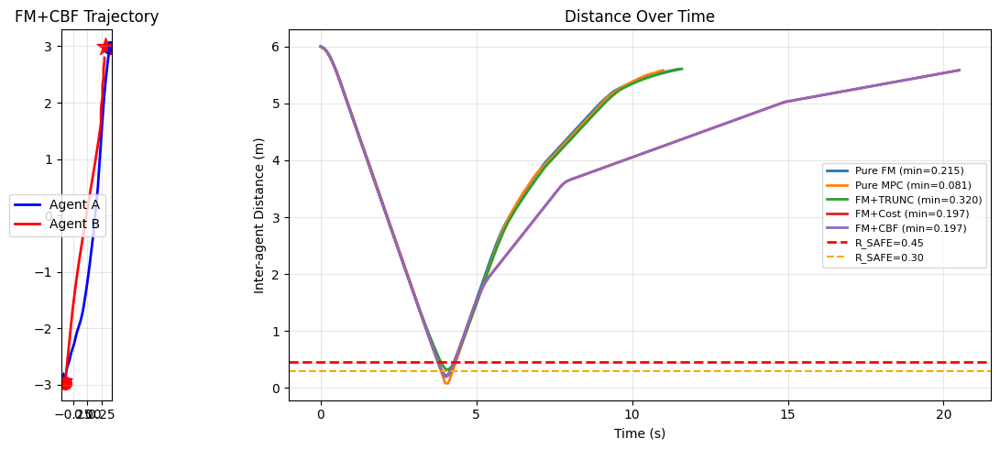

=== 诊断报告 ===
Pure FM     : min=0.215  mean=3.640  <0.45占比=4%  <0.30占比=3%
Pure MPC    : min=0.081  mean=3.542  <0.45占比=5%  <0.30占比=4%
FM+TRUNC    : min=0.320  mean=3.627  <0.45占比=3%  <0.30占比=0%
FM+Cost     : min=0.197  mean=3.976  <0.45占比=2%  <0.30占比=1%
FM+CBF      : min=0.197  mean=3.976  <0.45占比=2%  <0.30占比=1%


In [36]:
# 诊断 cell：可视化 seed=5000 这个 trial 的轨迹和距离曲线
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, data) in enumerate(example_trajs.items()):
    trajA, trajB = data['trajA'], data['trajB']
    dist_AB = data['dist_AB']
    t = np.arange(len(dist_AB)) * cfg.dt

    # 距离时序
    axes[1].plot(t, dist_AB, lw=2, label=f"{name} (min={data['min_dist']:.3f})")

axes[1].axhline(0.45, color='red', ls='--', lw=2, label='R_SAFE=0.45')
axes[1].axhline(0.30, color='orange', ls='--', lw=1.5, label='R_SAFE=0.30')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Inter-agent Distance (m)')
axes[1].set_title('Distance Over Time')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 轨迹图（只画 FM+CBF）
data = example_trajs.get('FM+CBF', list(example_trajs.values())[0])
ax = axes[0]
ax.plot(data['trajA'][:,0], data['trajA'][:,1], 'b-', lw=2, label='Agent A')
ax.plot(data['trajB'][:,0], data['trajB'][:,1], 'r-', lw=2, label='Agent B')
ax.scatter(*data['xA0'], c='blue', s=100, marker='o')
ax.scatter(*data['gA'],  c='blue', s=200, marker='*')
ax.scatter(*data['xB0'], c='red',  s=100, marker='o')
ax.scatter(*data['gB'],  c='red',  s=200, marker='*')
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('FM+CBF Trajectory')
ax.legend()

plt.tight_layout()
plt.show()

# 打印关键数字
print("=== 诊断报告 ===")
for name, data in example_trajs.items():
    d = data['dist_AB']
    print(f"{name:<12}: min={data['min_dist']:.3f}  "
          f"mean={d.mean():.3f}  "
          f"<0.45占比={( d < 0.45).mean()*100:.0f}%  "
          f"<0.30占比={(d < 0.30).mean()*100:.0f}%")

Starting Ablation v4c (fixed obstacle avoidance)...

Ablation v4c | Trials=1 | Layouts=['open', 'center_block', 'narrow_passage', 's_curve']
W_OBS=2000.0 | MPC K=64 sigma_a=0.60 sigma_dr=45deg

── Layout: open ──
  Pure FM       2.6s
  Pure MPC      1.1s
  FM+TRUNC      2.5s
  FM+Cost       5.8s
  FM+CBF        10.5s

── Layout: center_block ──
  Pure FM       2.4s
  Pure MPC      1.3s
  FM+TRUNC      2.5s
  FM+Cost       5.3s
  FM+CBF        9.8s

── Layout: narrow_passage ──
  Pure FM       2.2s
  Pure MPC      1.4s
  FM+TRUNC      2.4s
  FM+Cost       5.0s
  FM+CBF        9.6s

── Layout: s_curve ──
  Pure FM       2.4s
  Pure MPC      1.5s
  FM+TRUNC      2.4s
  FM+Cost       5.1s
  FM+CBF        12.1s

Layout             Method        Safe%  ObsSafe%  GoalA%  GoalB%  MinDist
-------------------------------------------------------------------------------------
open               Pure FM          0%      100%    100%    100%    0.098
open               Pure MPC         0%      100% 

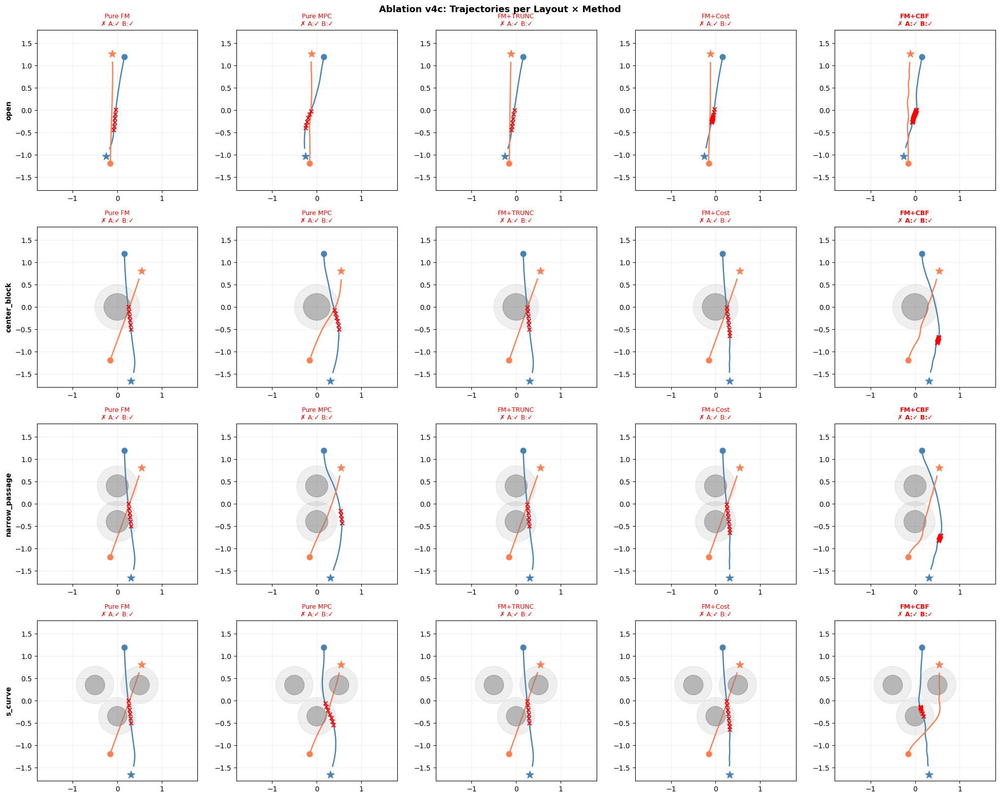

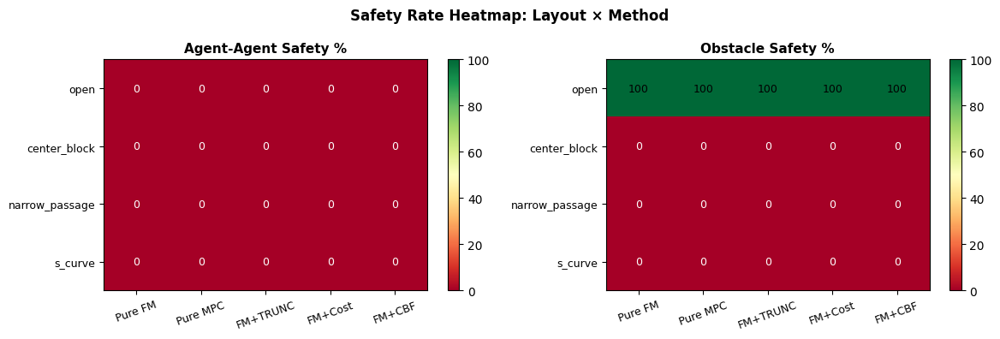


Saved: ablation_v4c_traj.png, ablation_v4c_heatmap.png

Done!


In [24]:
# ===============================================================
# 消融实验 v4c：静态障碍物场景 + 修复避障问题
# 修复点：
#   1. _safe_goal：目标点不与障碍物共线
#   2. W_OBS 提高到 2000
#   3. Pure MPC rollout 加障碍物穿越极大惩罚
#   4. FM+CBF 有静态障碍物时始终开 CBF（已有，保留）
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    R_OBS: float = 0.20
    arena_size: float = 1.2
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments: int = 3
    replan_every: int = 1

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale  = 0.08
total_time   = 1.0
ode_method   = "euler"

# MPC 专用参数
K_MPC      = 64
SIGMA_A    = 0.6
SIGMA_DR   = np.deg2rad(45.0)
MPC_LAMBDA = 0.05

# ===============================================================
# 静态障碍物定义
# ===============================================================
OBSTACLE_LAYOUTS = {
    "open": [],
    "center_block": [
        {"center": [0.0, 0.0], "radius": 0.30},
    ],
    "narrow_passage": [
        {"center": [ 0.0,  0.40], "radius": 0.25},
        {"center": [ 0.0, -0.40], "radius": 0.25},
    ],
    "s_curve": [
        {"center": [-0.50,  0.35], "radius": 0.22},
        {"center": [ 0.0,  -0.35], "radius": 0.22},
        {"center": [ 0.50,  0.35], "radius": 0.22},
    ],
}

ACTIVE_LAYOUTS = ["open", "center_block", "narrow_passage", "s_curve"]

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# 静态障碍物工具函数
# ===============================================================
def check_obs_collision(pos_xy, obstacles, r_agent=None):
    if r_agent is None:
        r_agent = cfg.R_OBS
    for obs in obstacles:
        c  = np.asarray(obs["center"], np.float32)
        rm = float(obs["radius"]) + r_agent
        if float(np.linalg.norm(pos_xy - c)) < rm:
            return True
    return False

def traj_obs_collision(traj_xy, obstacles, r_agent=None):
    if r_agent is None:
        r_agent = cfg.R_OBS
    if len(obstacles) == 0:
        return False, float("inf")
    min_d = float("inf")
    hit   = False
    for obs in obstacles:
        c     = np.asarray(obs["center"], np.float32)
        rm    = float(obs["radius"]) + r_agent
        dists = np.linalg.norm(traj_xy - c.reshape(1,2), axis=1)
        d_surf = float(dists.min()) - float(obs["radius"])
        min_d  = min(min_d, d_surf)
        if float(dists.min()) < rm:
            hit = True
    return hit, min_d

# ===============================================================
# ★ 修复1：安全目标点生成（不与障碍物共线）
# ===============================================================
def _safe_goal(base_pos, obstacles, rng, max_tries=30):
    """
    生成目标点，确保：
      1. 目标点本身不在障碍物内
      2. 起点→目标的直线中点不在障碍物内（避免共线穿越）
      3. 路径上均匀采样5个点都不在障碍物内
    """
    for _ in range(max_tries):
        # 增大 noise 范围，让目标偏离轴线
        noise = rng.uniform(-0.35, 0.35, 2).astype(np.float32)
        g = (-base_pos + noise).astype(np.float32)

        # 检查目标点本身
        if check_obs_collision(g, obstacles, r_agent=cfg.R_OBS + 0.10):
            continue

        # 检查路径上5个采样点
        blocked = False
        for t in np.linspace(0.2, 0.8, 5):
            mid = base_pos + t * (g - base_pos)
            if check_obs_collision(mid, obstacles, r_agent=cfg.R_OBS + 0.05):
                blocked = True
                break
        if blocked:
            continue

        return g

    # 所有尝试失败，返回加大偏移的点
    ang_offset = rng.uniform(0.3, 0.7)
    g = (-base_pos + np.array([ang_offset, -ang_offset],
                               np.float32)).astype(np.float32)
    return g

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt,
                           -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"
    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]
    th     = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# ★ 修复2：Cost（W_OBS 提高到 2000）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25
W_OBS = 2000.0   # ★ 300 → 2000

def compute_cost(pos_self, pos_other_pred, goal_xy, U, obstacles=None):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(
        pos_self - goal_xy.reshape(1,2), axis=1)))

    M     = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    coll  = float(viol * viol)

    obs_cost = 0.0
    if obstacles:
        for obs in obstacles:
            c     = np.asarray(obs["center"], np.float32)
            rm    = float(obs["radius"]) + cfg.R_OBS
            dists = np.linalg.norm(pos_self - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            obs_cost += float(viol_obs * viol_obs)

    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    return (W_END*d_end + W_PATH*d_path + W_COLL*coll
            + W_OBS*obs_cost + W_SMOOTH*smooth)

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near     = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:    return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True,  CBF_LIGHT
    else:                          return True,  CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB, static_obstacles=None):
    ellipses = []
    if other_pred_pos is not None and len(other_pred_pos) >= 2:
        idxs = sorted(list(dict.fromkeys(
            [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
             if 0 <= i < len(other_pred_pos)])))
        r = r_obs_near if dist_AB < 1.2 else r_obs_far
        for i in idxs:
            ellipses.append({
                "center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
                "radius": float(r)
            })
    if static_obstacles:
        for obs in static_obstacles:
            c_world = np.asarray(obs["center"], np.float32).reshape(1, 2)
            c_can   = tf["w2c"](c_world)[0]
            ellipses.append({
                "center": c_can,
                "radius": float(obs["radius"]) + 0.08
            })
    return ellipses

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed,
                   use_cbf, cbf_kwargs, static_obstacles=None):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None
                            or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB,
                                static_obstacles=static_obstacles) \
                if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments,
        ode_method=ode_method, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, obstacles=None, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best  = None

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs,
                                     static_obstacles=obstacles)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            continue

        U  = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                    H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J  = compute_cost(st[:, :2], other_pred_pos, goal_xy, U,
                          obstacles=obstacles)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================

def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA,
                               H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# ---------------------------------------------------------------
# ★ 修复3：Pure MPC rollout 加障碍物穿越极大惩罚
# ---------------------------------------------------------------
def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    rng       = np.random.RandomState(seed)
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)

    straight = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    U_nom    = pure_pursuit_controls(
        sA, straight, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)

    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR

    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k       = U_nom.copy()
        U_k[:,0]  = np.clip(U_nom[:,0] + eps_a[k],  -a_max, a_max)
        U_k[:,1]  = np.clip(U_nom[:,1] + eps_dr[k],
                            -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k

    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        st = rollout_bicycle(sA, U_samples[k], cfg.dt, v_max_self)
        c  = compute_cost(st[:, :2], other_pos, gA,
                          U_samples[k], obstacles=obstacles)
        # ★ 穿越静态障碍物给极大惩罚（硬约束近似）
        if obstacles:
            hit, _ = traj_obs_collision(st[:, :2], obstacles)
            if hit:
                c += 5000.0
        costs[k] = c

    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)

    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0

    for i in range(min(len(path), len(other_pos))):
        if (np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2
                and i > 2):
            t     = np.linspace(0, 1, cfg.T_steps - i).reshape(-1,1)
            patch = (path[i-1] + t * (gA - path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break

    U = pure_pursuit_controls(sA, path, gA,
                               H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None,
                           obstacles=obstacles)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                  obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))

    if obstacles:
        use_cbf = True
        cbf_kw  = CBF_STRONG
    else:
        use_cbf, cbf_kw = get_cbf_config(dist_AB)

    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw, obstacles=obstacles)
    return u0, cbf_flag

# ===============================================================
# 单次实验（★ 使用 _safe_goal）
# ===============================================================
def run_trial(method_fn, seed, layout_name="open", return_traj=False):
    rng = np.random.RandomState(seed)   # ★ 独立 rng
    np.random.seed(seed)
    obstacles = OBSTACLE_LAYOUTS[layout_name]
    r = cfg.arena_size

    ang  = rng.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)

    # ★ 安全目标点（不与障碍物共线）
    gA = _safe_goal(xA0, obstacles, rng)
    gB = _safe_goal(xB0, obstacles, rng)

    # 起点检查（极少数情况）
    for pos in [xA0, xB0]:
        if check_obs_collision(pos, obstacles, r_agent=cfg.R_OBS + 0.05):
            pos += rng.uniform(-0.3, 0.3, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31, obstacles=obstacles)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37, obstacles=obstacles)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA   = np.array(trajA)
    trajB   = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    obs_coll_A, min_obs_A = traj_obs_collision(trajA[:,:2], obstacles)
    obs_coll_B, min_obs_B = traj_obs_collision(trajB[:,:2], obstacles)

    result = {
        'layout':       layout_name,
        'success_A':    float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':    float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':    bool(dist_AB.min() < cfg.R_SAFE),
        'obs_coll':     bool(obs_coll_A or obs_coll_B),
        'any_coll':     bool(dist_AB.min() < cfg.R_SAFE
                             or obs_coll_A or obs_coll_B),
        'min_dist':     float(dist_AB.min()),
        'min_obs_dist': min(min_obs_A, min_obs_B),
        'steps':        len(trajA),
        'cbf_used':     cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB, 'obstacles': obstacles})
    return result

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }

    all_results   = {lay: defaultdict(list) for lay in ACTIVE_LAYOUTS}
    example_trajs = {lay: {} for lay in ACTIVE_LAYOUTS}

    print("=" * 65)
    print(f"Ablation v4c | Trials={cfg.n_trials} | Layouts={ACTIVE_LAYOUTS}")
    print(f"W_OBS={W_OBS} | MPC K={K_MPC} sigma_a={SIGMA_A:.2f} "
          f"sigma_dr={np.rad2deg(SIGMA_DR):.0f}deg")
    print("=" * 65)

    for layout in ACTIVE_LAYOUTS:
        print(f"\n── Layout: {layout} ──")
        for name, fn in methods.items():
            t0 = time.time()
            print(f"  {name:<12}", end=" ", flush=True)
            for trial in range(cfg.n_trials):
                try:
                    r = run_trial(fn, 5000 + trial*77,
                                  layout_name=layout,
                                  return_traj=(trial == 0))
                    all_results[layout][name].append(r)
                    if trial == 0:
                        example_trajs[layout][name] = r
                except Exception as e:
                    print(f"x[{e}]", end="", flush=True)
                if (trial+1) % 5 == 0:
                    print(".", end="", flush=True)
            print(f" {time.time()-t0:.1f}s")

    return all_results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(all_results, example_trajs):
    print("\n" + "="*85)
    print(f"{'Layout':<18} {'Method':<12} {'Safe%':>6} {'ObsSafe%':>9} "
          f"{'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8}")
    print("-"*85)

    for layout in ACTIVE_LAYOUTS:
        for name, rs in all_results[layout].items():
            n = len(rs)
            if n == 0: continue
            safe     = sum(1 for r in rs if not r['collision'])  / n * 100
            obs_safe = sum(1 for r in rs if not r['obs_coll'])   / n * 100
            gA_r     = sum(1 for r in rs if r['success_A'])      / n * 100
            gB_r     = sum(1 for r in rs if r['success_B'])      / n * 100
            md       = np.mean([r['min_dist'] for r in rs])
            marker   = " ★" if name == "FM+CBF" else ""
            print(f"{layout:<18} {name:<12} {safe:>5.0f}% {obs_safe:>8.0f}% "
                  f"{gA_r:>6.0f}% {gB_r:>6.0f}% {md:>8.3f}{marker}")
        print()
    print("="*85)

    # 轨迹图
    method_names = list(example_trajs[ACTIVE_LAYOUTS[0]].keys())
    n_methods    = len(method_names)
    n_layouts    = len(ACTIVE_LAYOUTS)
    fig, axes    = plt.subplots(n_layouts, n_methods,
                                figsize=(4*n_methods, 4*n_layouts))
    if n_layouts == 1:
        axes = axes.reshape(1, -1)

    for row, layout in enumerate(ACTIVE_LAYOUTS):
        obstacles = OBSTACLE_LAYOUTS[layout]
        for col, mname in enumerate(method_names):
            ax   = axes[row][col]
            data = example_trajs[layout].get(mname)

            for obs in obstacles:
                ax.add_patch(plt.Circle(
                    obs["center"], obs["radius"],
                    color='gray', alpha=0.5, zorder=3))
                ax.add_patch(plt.Circle(
                    obs["center"], obs["radius"] + cfg.R_OBS,
                    color='gray', alpha=0.12, zorder=2))

            if data:
                trajA, trajB = data['trajA'], data['trajB']
                ax.plot(trajA[:,0], trajA[:,1], color='steelblue', lw=1.8)
                ax.plot(trajB[:,0], trajB[:,1], color='coral',     lw=1.8)
                ax.scatter(*data['xA0'], c='steelblue', s=60,  marker='o', zorder=5)
                ax.scatter(*data['gA'],  c='steelblue', s=120, marker='*', zorder=5)
                ax.scatter(*data['xB0'], c='coral',     s=60,  marker='o', zorder=5)
                ax.scatter(*data['gB'],  c='coral',     s=120, marker='*', zorder=5)

                coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
                if len(coll_idx):
                    ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                               c='red', s=30, marker='x', zorder=6)

                ok     = not data['any_coll']
                status = "✓" if ok else "✗"
                goal   = (f"A:{'✓' if data['success_A'] else '✗'} "
                          f"B:{'✓' if data['success_B'] else '✗'}")
                ax.set_title(f"{mname}\n{status} {goal}",
                             fontsize=9,
                             color='darkgreen' if ok else 'red',
                             fontweight='bold' if mname == 'FM+CBF' else 'normal')

            ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
            ax.set_aspect('equal'); ax.grid(alpha=0.2)
            if col == 0:
                ax.set_ylabel(layout, fontsize=10, fontweight='bold')

    plt.suptitle('Ablation v4c: Trajectories per Layout × Method',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_traj.png', dpi=130, bbox_inches='tight')
    plt.show()

    # 热力图
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax_idx, (metric, title) in enumerate([
        ('safe_rate',     'Agent-Agent Safety %'),
        ('obs_safe_rate', 'Obstacle Safety %'),
    ]):
        mat = np.zeros((n_layouts, n_methods))
        for i, lay in enumerate(ACTIVE_LAYOUTS):
            for j, mn in enumerate(method_names):
                rs = all_results[lay][mn]
                if not rs: continue
                if metric == 'safe_rate':
                    mat[i,j] = (sum(1 for r in rs if not r['collision'])
                                / len(rs) * 100)
                else:
                    mat[i,j] = (sum(1 for r in rs if not r['obs_coll'])
                                / len(rs) * 100)

        im = axes[ax_idx].imshow(mat, vmin=0, vmax=100,
                                  cmap='RdYlGn', aspect='auto')
        axes[ax_idx].set_xticks(range(n_methods))
        axes[ax_idx].set_xticklabels(method_names, rotation=20, fontsize=9)
        axes[ax_idx].set_yticks(range(n_layouts))
        axes[ax_idx].set_yticklabels(ACTIVE_LAYOUTS, fontsize=9)
        axes[ax_idx].set_title(title, fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=axes[ax_idx])
        for i in range(n_layouts):
            for j in range(n_methods):
                axes[ax_idx].text(j, i, f'{mat[i,j]:.0f}',
                                  ha='center', va='center', fontsize=9,
                                  color='black' if mat[i,j] > 40 else 'white')

    plt.suptitle('Safety Rate Heatmap: Layout × Method',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("\nSaved: ablation_v4c_traj.png, ablation_v4c_heatmap.png")

# ===============================================================
# 入口
# ===============================================================
print("Starting Ablation v4c (fixed obstacle avoidance)...\n")
all_results, example_trajs = run_ablation()
show_results(all_results, example_trajs)
print("\nDone!")

Starting Ablation v4c...

Ablation v4c | Trials=1 | Layouts=['open', 'center_block', 'narrow_passage', 's_curve']
W_OBS=2000.0 | R_OBS=0.2
★ MPC: K=128 Dopri5 substeps=6 + lane/curv cost
★ FM+CBF: euler seg=1 (fast)
★ FM others: euler seg=3
★ CBF gate: tau0=0.0 tau1=0.5 prox_k=8.0
★ Exec safe: {'FM+Cost', 'FM+CBF'}

── Layout: open ──
  Pure FM       3.2s
  Pure MPC      71.8s
  FM+TRUNC      3.8s
  FM+Cost       9.2s
  FM+CBF        5.1s

── Layout: center_block ──
  Pure FM       3.8s
  Pure MPC      103.0s
  FM+TRUNC      2.7s
  FM+Cost       7.0s
  FM+CBF        5.4s

── Layout: narrow_passage ──
  Pure FM       2.9s
  Pure MPC      104.3s
  FM+TRUNC      3.2s
  FM+Cost       8.8s
  FM+CBF        7.0s

── Layout: s_curve ──
  Pure FM       2.8s
  Pure MPC      103.4s
  FM+TRUNC      3.1s
  FM+Cost       8.9s
  FM+CBF        11.4s

Layout             Method       Safe%(s) Safe%(p)  ObsSafe%  GoalA%  GoalB%  MinDist
                                   <0.45  3×<0.20    phys_r
--------

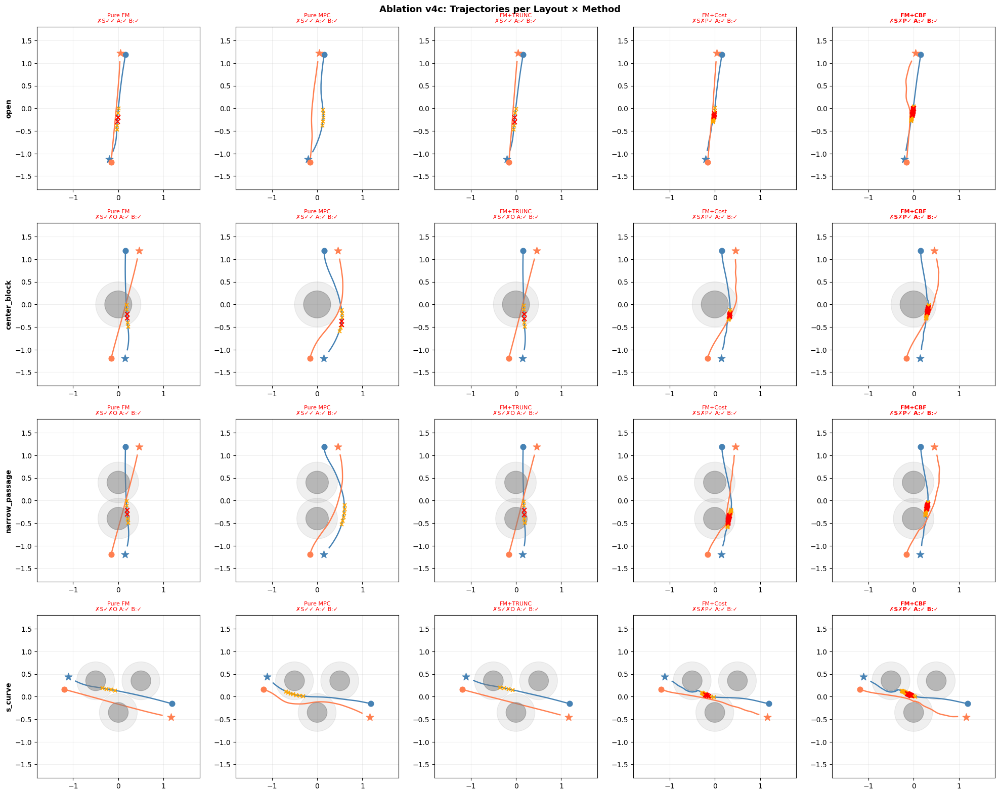

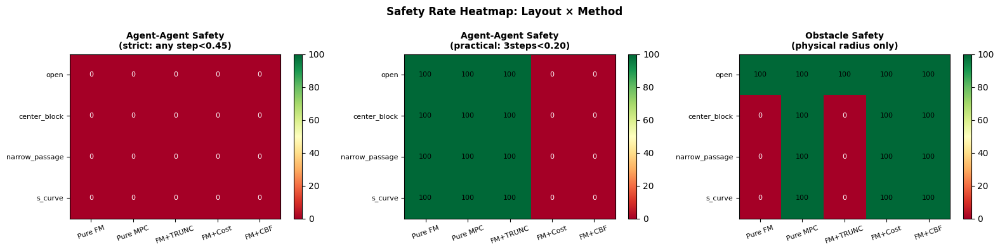


Saved: ablation_v4c_traj.png, ablation_v4c_heatmap.png

Done!


In [58]:
# ===============================================================
# 消融实验 v4c：静态障碍物场景
# ★ MPC: Dopri5 + 更多 cost → 更慢更精确
# ★ FM+CBF: euler + num_segments=1 → 更快
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.20
    R_OBS: float = 0.20
    arena_size: float = 1.2
    H: int = 12
    K: int = 1
    T_steps: int = 40
    # ★ FM+CBF 用 1 segment（快）
    num_segments_cbf: int = 1
    # ★ Pure FM / FM+Cost / FM+TRUNC 用 3 segments（原来）
    num_segments_fm:  int = 3
    replan_every: int = 1
    collision_steps: int = 3

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale  = 0.08
total_time   = 1.0
# ★ FM+CBF 用 euler（快）
ode_method_cbf = "euler"
# ★ 其他 FM 方法用 euler（保持原来）
ode_method_fm  = "euler"

# ★ MPC 参数：K 更大 + Dopri5
K_MPC         = 128      # ★ 64→128，更多采样
SIGMA_A       = 0.6
SIGMA_DR      = np.deg2rad(45.0)
MPC_LAMBDA    = 0.05
MPC_N_SUBSTEPS = 6       # ★ Dopri5 substeps（原来4）

W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25
W_OBS      = 2000.0
W_OBS_SLOW = 5000.0

# ★ MPC 额外 cost 权重
W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8
W_MPC_OBS     = 2000.0
W_MPC_LANE    = 1.5      # ★ 新增：路径偏离惩罚
W_MPC_CURV    = 0.5      # ★ 新增：曲率平滑惩罚

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

YIELD_DIST   = 2.0
YIELD_OFFSET = 0.45

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

PATH_OBS_MARGIN      = cfg.R_OBS + 0.08
PATH_OBS_MARGIN_SLOW = cfg.R_OBS + 0.13
PATH_OBS_MARGIN_CBF  = cfg.R_OBS + 0.04

EXEC_SAFE_METHODS = {"FM+Cost", "FM+CBF"}

# ===============================================================
# 静态障碍物定义
# ===============================================================
OBSTACLE_LAYOUTS = {
    "open": [],
    "center_block": [
        {"center": [0.0, 0.0], "radius": 0.30},
    ],
    "narrow_passage": [
        {"center": [ 0.0,  0.40], "radius": 0.25},
        {"center": [ 0.0, -0.40], "radius": 0.25},
    ],
    "s_curve": [
        {"center": [-0.50,  0.35], "radius": 0.22},
        {"center": [ 0.0,  -0.35], "radius": 0.22},
        {"center": [ 0.50,  0.35], "radius": 0.22},
    ],
}

ACTIVE_LAYOUTS = ["open", "center_block", "narrow_passage", "s_curve"]

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# 静态障碍物工具
# ===============================================================
def check_obs_collision(pos_xy, obstacles, r_agent=None):
    if r_agent is None:
        r_agent = cfg.R_OBS
    for obs in obstacles:
        c  = np.asarray(obs["center"], np.float32)
        rm = float(obs["radius"]) + r_agent
        if float(np.linalg.norm(pos_xy - c)) < rm:
            return True
    return False

def traj_obs_collision(traj_xy, obstacles, use_margin=False, is_slow=False):
    if len(obstacles) == 0:
        return False, float("inf")
    min_d = float("inf")
    hit   = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_phys = float(obs["radius"])
        rm     = r_phys + cfg.R_OBS + (0.10 if is_slow else 0.0) \
                 if use_margin else r_phys
        dists  = np.linalg.norm(traj_xy - c.reshape(1,2), axis=1)
        d_surf = float(dists.min()) - r_phys
        min_d  = min(min_d, d_surf)
        if float(dists.min()) < rm:
            hit = True
    return hit, min_d

# ===============================================================
# 执行层安全推出
# ===============================================================
def _push_out_of_obs(state, obstacles):
    if len(obstacles) == 0:
        return state
    pos    = state[:2].copy()
    pushed = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_safe = float(obs["radius"]) + 0.02
        diff   = pos - c
        dist   = float(np.linalg.norm(diff))
        if dist < r_safe:
            direction = diff / dist if dist > 1e-6 \
                        else np.array([1.0, 0.0], np.float32)
            pos       = (c + direction * (r_safe + 0.01)).astype(np.float32)
            pushed    = True
    if not pushed:
        return state
    new_state     = state.copy()
    new_state[:2] = pos
    return new_state

# ===============================================================
# 路径后处理
# ===============================================================
def post_process_path_obs(path_xy, obstacles, r_safe_margin=None):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(30):
        modified = False
        for i in range(len(path)):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_safe:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    path[i]  = (c + direction * (r_safe + 0.02)).astype(np.float32)
                    modified = True
        if not modified:
            break
    return path.astype(np.float32)

def post_process_path_smooth(path_xy, n_smooth=3, alpha=0.5):
    if len(path_xy) < 5:
        return path_xy
    path  = path_xy.copy()
    w_mid = 1.0 - alpha
    w_s   = alpha / 2.0
    for _ in range(n_smooth):
        new_path = path.copy()
        for i in range(1, len(path)-1):
            new_path[i] = w_s*path[i-1] + w_mid*path[i] + w_s*path[i+1]
        path = new_path
    return path.astype(np.float32)

def post_process_path_obs_soft(path_xy, obstacles, r_safe_margin=None,
                                n_iters=60, soft_falloff=2.5):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(n_iters):
        modified = False
        for i in range(1, len(path)-1):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                r_inf  = r_safe * soft_falloff
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_inf:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    if dist < r_safe:
                        push = (r_safe - dist + 0.015)
                    else:
                        t    = (dist - r_safe) / (r_inf - r_safe + 1e-6)
                        push = 0.3 * (r_safe - dist + 0.015) * (1.0 - t)
                        push = max(0.0, push)
                    if push > 1e-4:
                        path[i]  = (path[i] + direction * push * 0.6).astype(np.float32)
                        modified = True
        if not modified:
            break
    return path.astype(np.float32)

def smooth_path_spline(path_xy, n_out=None, smoothing=0.5):
    if len(path_xy) < 5:
        return path_xy
    if n_out is None:
        n_out = len(path_xy)
    x    = path_xy[:, 0].astype(float)
    y    = path_xy[:, 1].astype(float)
    diff = np.diff(np.stack([x, y], axis=1), axis=0)
    mask = np.concatenate([[True], np.linalg.norm(diff, axis=1) > 1e-5])
    x, y = x[mask], y[mask]
    if len(x) < 4:
        return path_xy
    try:
        tck, _   = splprep([x, y], s=smoothing, k=3)
        x_s, y_s = splev(np.linspace(0, 1, n_out), tck)
        result   = np.stack([x_s, y_s], axis=1).astype(np.float32)
        result[0]  = path_xy[0]
        result[-1] = path_xy[-1]
        return result
    except Exception:
        return path_xy

# ===============================================================
# 安全目标点生成
# ===============================================================
def _safe_goal(base_pos, obstacles, rng):
    if len(obstacles) == 0:
        noise = rng.uniform(-0.15, 0.15, 2).astype(np.float32)
        return (-base_pos + noise).astype(np.float32)

    def path_clear(start, end):
        for t in np.linspace(0.0, 1.0, 50):
            mid = start + t * (end - start)
            for obs in obstacles:
                c     = np.asarray(obs["center"], np.float32)
                r_chk = float(obs["radius"]) + cfg.R_OBS
                if float(np.linalg.norm(mid - c)) < r_chk:
                    return False
        return True

    def point_safe(g, margin=0.10):
        for obs in obstacles:
            c = np.asarray(obs["center"], np.float32)
            if float(np.linalg.norm(g - c)) < float(obs["radius"]) + cfg.R_OBS + margin:
                return False
        return True

    for _ in range(60):
        noise = rng.uniform(-0.45, 0.45, 2).astype(np.float32)
        g = (-base_pos + noise).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    for attempt in range(40):
        side   = 1.0 if attempt % 2 == 0 else -1.0
        offset = rng.uniform(0.3, 0.6) * side
        g = (-base_pos + perp * offset).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
        for dist in [0.4, 0.6, 0.8, 1.0]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g) and path_clear(base_pos, g):
                return g

    for angle in np.linspace(0, 2*np.pi, 32, endpoint=False):
        for dist in [0.3, 0.5, 0.7, 0.9]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g, margin=0.0):
                return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    return (-base_pos + perp * 0.5).astype(np.float32)

# ===============================================================
# 慢车主动让路
# ===============================================================
def _yield_biased_goal(self_pos, goal_xy, other_pos_now, v_max_self,
                       dist_AB, obstacles):
    is_slow  = v_max_self < 0.8
    goal_arr = np.asarray(goal_xy, np.float32)
    if not is_slow or dist_AB > YIELD_DIST:
        return goal_arr
    to_goal = goal_arr - np.asarray(self_pos, np.float32)
    to_goal_len = float(np.linalg.norm(to_goal))
    if to_goal_len < 1e-3:
        return goal_arr
    to_goal_unit = to_goal / to_goal_len
    perp  = np.array([-to_goal_unit[1], to_goal_unit[0]], np.float32)
    diff  = np.asarray(other_pos_now, np.float32) - np.asarray(self_pos, np.float32)
    cross = float(to_goal_unit[0]*diff[1] - to_goal_unit[1]*diff[0])
    proximity   = max(0.0, 1.0 - dist_AB / YIELD_DIST)
    side        = -1.0 if cross > 0 else 1.0
    offset      = side * YIELD_OFFSET * proximity
    goal_biased = (goal_arr + offset * perp).astype(np.float32)
    if obstacles and check_obs_collision(
            goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
        goal_biased = (goal_arr - offset * perp).astype(np.float32)
        if obstacles and check_obs_collision(
                goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
            return goal_arr
    return goal_biased

# ===============================================================
# 碰撞判定
# ===============================================================
def _check_collision_strict(dist_AB):
    return bool(dist_AB.min() < cfg.R_SAFE)

def _check_collision_practical(dist_AB):
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0
    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max); continue
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max-v_creep)*(d_goal/creep_radius), v_creep, v_max))
        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des-delta)/dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des-v)/dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max)
    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]; th = float(self_state[2])
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    if float(np.linalg.norm(seg_dir)) > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"
    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]; th = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des/dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3])/dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（FM 方法用）
# ===============================================================
def compute_cost(pos_self, pos_other_pred, goal_xy, U,
                 obstacles=None, is_slow=False):
    goal_xy  = np.asarray(goal_xy, np.float32)
    d_end    = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path   = float(np.mean(np.linalg.norm(pos_self-goal_xy.reshape(1,2), axis=1)))
    M        = min(len(pos_self), len(pos_other_pred))
    min_d    = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M]-pos_other_pred[:M], axis=1).min())
    viol     = max(0.0, cfg.R_SAFE - min_d)
    coll     = float(viol * viol)
    w_obs    = W_OBS_SLOW if is_slow else W_OBS
    obs_cost = 0.0
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos_self - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            obs_cost += float(viol_obs * viol_obs)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + w_obs*obs_cost + W_SMOOTH*smooth

# ===============================================================
# ★ MPC: Dopri5 积分器
# ===============================================================
def _dopri5_step(s, u, dt, v_max):
    """Dormand-Prince (RK45) 单步积分"""
    def f(s_):
        x, y, th, v, delta = s_
        a      = float(np.clip(u[0], -a_max, a_max))
        dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2     = float(np.clip(v, v_min, v_max))
        d2     = float(np.clip(delta, -delta_max, delta_max))
        dth    = (v2 / L) * math.tan(d2)
        return np.array([v2*math.cos(th), v2*math.sin(th), dth, a, dr],
                        np.float32)
    # Dormand-Prince coefficients
    k1 = f(s)
    k2 = f(s + dt*( 1/5)*k1)
    k3 = f(s + dt*( 3/40)*k1 + dt*(9/40)*k2)
    k4 = f(s + dt*(44/45)*k1 + dt*(-56/15)*k2 + dt*(32/9)*k3)
    k5 = f(s + dt*(19372/6561)*k1 + dt*(-25360/2187)*k2
             + dt*(64448/6561)*k3  + dt*(-212/729)*k4)
    k6 = f(s + dt*(9017/3168)*k1  + dt*(-355/33)*k2
             + dt*(46732/5247)*k3  + dt*(49/176)*k4
             + dt*(-5103/18656)*k5)
    # 5th order solution
    s_new = s + dt*(35/384*k1 + 500/1113*k3 + 125/192*k4 +
                    (-2187/6784)*k5 + 11/84*k6)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _dopri5_rollout(s0, U, dt, v_max, n_substeps=6):
    """Dopri5 多步 rollout"""
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    dt_sub = dt / n_substeps
    for i in range(H):
        s_cur = st[i].copy()
        for _ in range(n_substeps):
            s_cur = _dopri5_step(s_cur, U[i], dt_sub, v_max)
        st[i+1] = s_cur
    return st

# ===============================================================
# ★ MPC cost（更多 terms）
# ===============================================================
def _compute_mpc_cost_full(traj, U, goal_xy, other_pos,
                            v_max_self, obstacles=None, is_slow=False):
    """
    MPC 完整 cost：
    goal + path + collision + obstacle + heading +
    velocity + smooth + jerk + ★ lane_deviation + ★ curvature
    """
    goal_xy = np.asarray(goal_xy, np.float32)
    pos     = traj[:,:2]; th = traj[:,2]; vel = traj[:,3]

    # 基础 cost
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path

    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M<=1 else float(
        np.linalg.norm(pos[:M]-other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol

    J_obs = 0.0
    w_obs = W_OBS_SLOW if is_slow else W_MPC_OBS
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            J_obs   += w_obs * viol_obs * viol_obs

    # heading cost
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1]-goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))

    # velocity cost
    d_goals = np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius, v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel-v_des)**2))

    # smooth + jerk
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth= W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    ddU     = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk  = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))

    # ★ lane deviation：偏离起点-终点连线的惩罚
    if len(pos) > 2:
        start_p = pos[0]; end_p = pos[-1]
        lane_dir = end_p - start_p
        lane_len = float(np.linalg.norm(lane_dir)) + 1e-6
        lane_unit = lane_dir / lane_len
        lane_perp = np.array([-lane_unit[1], lane_unit[0]])
        deviations = np.abs((pos - start_p) @ lane_perp)
        J_lane = W_MPC_LANE * float(np.mean(deviations**2))
    else:
        J_lane = 0.0

    # ★ curvature smoothness：转向角变化率的平方
    delta_vals = traj[:,4]
    d_delta    = np.diff(delta_vals, prepend=delta_vals[0])
    J_curv     = W_MPC_CURV * float(np.mean(d_delta**2))

    return (J_goal + J_coll + J_obs + J_heading + J_vel
            + J_smooth + J_jerk + J_lane + J_curv)

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near     = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0

def get_cbf_config(dist_AB, has_obstacles=False, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if has_obstacles:
        return True, strong
    if dist_AB > SAFE_DIST_FAR:    return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True,  light
    else:                          return True,  strong

def build_ellipses(tf, other_pred_pos, dist_AB, static_obstacles=None,
                   is_slow=False):
    ellipses = []
    if other_pred_pos is not None and len(other_pred_pos) >= 2:
        idxs = sorted(list(dict.fromkeys(
            [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
             if 0 <= i < len(other_pred_pos)])))
        r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
            else (r_obs_near if dist_AB < 1.2 else r_obs_far)
        for i in idxs:
            ellipses.append({"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
                             "radius": float(r)})
    if static_obstacles:
        extra = 0.25 if is_slow else 0.15
        for obs in static_obstacles:
            c_world = np.asarray(obs["center"], np.float32).reshape(1,2)
            c_can   = tf["w2c"](c_world)[0]
            ellipses.append({"center": c_can,
                             "radius": float(obs["radius"]) + cfg.R_OBS + extra})
    return ellipses

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed,
                   use_cbf, cbf_kwargs, static_obstacles=None,
                   v_max_self=1.0, use_soft_postproc=False,
                   num_segments=None, ode_method=None):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    is_slow   = v_max_self < 0.8
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB,
                                static_obstacles=static_obstacles,
                                is_slow=is_slow) \
                if use_cbf else []
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    # ★ 按方法选择 num_segments 和 ode_method
    _num_seg = num_segments if num_segments is not None else cfg.num_segments_fm
    _ode     = ode_method   if ode_method   is not None else ode_method_fm

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=_num_seg,
        ode_method=_ode, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
        tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
    )
    xy_can     = x_can[0:2,:].T.astype(np.float32)
    path_world = tf["c2w"](xy_can).astype(np.float32)

    if static_obstacles and len(static_obstacles) > 0:
        if use_soft_postproc:
            r_margin = PATH_OBS_MARGIN_CBF + (0.04 if is_slow else 0.0)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin, n_iters=80, soft_falloff=2.0)
            path_world = smooth_path_spline(
                path_world, n_out=len(path_world), smoothing=0.8)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin - 0.01, n_iters=20, soft_falloff=1.5)
        else:
            r_margin   = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin)
            path_world = post_process_path_smooth(
                path_world, n_smooth=4, alpha=0.5)
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin - 0.02)

    return path_world

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, obstacles=None, K_override=None,
              use_soft_postproc=False, num_segments=None, ode_method=None):
    K_use   = K_override if K_override is not None else cfg.K
    is_slow = v_max_self < 0.8
    best    = None
    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs,
                                     static_obstacles=obstacles,
                                     v_max_self=v_max_self,
                                     use_soft_postproc=use_soft_postproc,
                                     num_segments=num_segments,
                                     ode_method=ode_method)
        except Exception:
            continue
        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            continue
        U  = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                    H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J  = compute_cost(st[:,:2], other_pred_pos, goal_xy, U,
                          obstacles=obstacles, is_slow=is_slow)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    """
    ★ Pure MPC: Dopri5 + 更多 cost terms + K=128
    比 FM+CBF 更慢，体现两者的计算量差距
    """
    rng       = np.random.RandomState(seed)
    is_slow   = v_max_self < 0.8
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    straight  = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    if obstacles and len(obstacles) > 0:
        r_margin = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
        straight = post_process_path_obs(straight, obstacles,
                                          r_safe_margin=r_margin)
        straight = post_process_path_smooth(straight, n_smooth=2, alpha=0.4)
    U_nom     = pure_pursuit_controls(sA, straight, gA,
                                       H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR
    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0]+eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1]+eps_dr[k], -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        # ★ Dopri5 rollout（比 RK4 更慢更精确）
        traj = _dopri5_rollout(sA, U_samples[k], cfg.dt,
                                v_max_self, n_substeps=MPC_N_SUBSTEPS)
        # ★ 完整 cost function（更多 terms）
        c = _compute_mpc_cost_full(traj, U_samples[k], gA, other_pos,
                                    v_max_self, obstacles=obstacles,
                                    is_slow=is_slow)
        if obstacles:
            hit, _ = traj_obs_collision(traj[:,:2], obstacles,
                                         use_margin=True, is_slow=is_slow)
            if hit:
                c += (10000.0 if is_slow else 5000.0)
        costs[k] = c
    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i]-other_pos[i]) < cfg.R_SAFE*1.2 and i > 2:
            t     = np.linspace(0, 1, cfg.T_steps-i).reshape(-1,1)
            patch = (path[i-1] + t*(gA-path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None,
                           obstacles=obstacles, use_soft_postproc=False,
                           num_segments=cfg.num_segments_fm,
                           ode_method=ode_method_fm)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                  obstacles=None):
    """
    ★ FM+CBF: euler + num_segments=1（更快）
    """
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    has_obs   = obstacles is not None and len(obstacles) > 0
    other_now = sB[:2] if (other_pos is None or len(other_pos) == 0) \
                else other_pos[0]
    gA_eff = _yield_biased_goal(
        self_pos=sA[:2], goal_xy=gA,
        other_pos_now=other_now, v_max_self=v_max_self,
        dist_AB=dist_AB, obstacles=obstacles,
    )
    use_cbf, cbf_kw = get_cbf_config(dist_AB,
                                      has_obstacles=has_obs,
                                      v_max_self=v_max_self)
    u0, cbf_flag = _mpc_core(sA, gA_eff, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw, obstacles=obstacles,
                              use_soft_postproc=True,
                              # ★ 快速配置
                              num_segments=cfg.num_segments_cbf,
                              ode_method=ode_method_cbf)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, layout_name="open", return_traj=False,
              method_name=""):
    rng           = np.random.RandomState(seed)
    obstacles     = OBSTACLE_LAYOUTS[layout_name]
    r             = cfg.arena_size
    use_exec_safe = method_name in EXEC_SAFE_METHODS

    ang = rng.uniform(0, 2*np.pi)
    if len(obstacles) > 0:
        obs_center = np.mean([obs["center"] for obs in obstacles], axis=0)
        obs_angle  = math.atan2(obs_center[1], obs_center[0])
        ang_diff   = abs(wrap_pi(ang - obs_angle))
        if ang_diff < np.deg2rad(30):
            ang += np.deg2rad(90) * (1.0 if rng.rand() > 0.5 else -1.0)

    xA0 = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0 = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)

    if layout_name == "s_curve":
        perp = np.array([-np.sin(ang), np.cos(ang)], np.float32)
        gA   = (-xA0 + 0.35*perp
                + rng.uniform(-0.08, 0.08, 2).astype(np.float32))
        gB   = (-xB0 - 0.35*perp
                + rng.uniform(-0.08, 0.08, 2).astype(np.float32))
    else:
        gA = _safe_goal(xA0, obstacles, rng)
        gB = _safe_goal(xB0, obstacles, rng)

    for pos in [xA0, xB0]:
        if check_obs_collision(pos, obstacles, r_agent=cfg.R_OBS+0.05):
            pos += rng.uniform(-0.3, 0.3, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000+step*31, obstacles=obstacles)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000+step*37, obstacles=obstacles)
                cbf_used += c
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
            if use_exec_safe:
                sA = _push_out_of_obs(sA, obstacles)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
            if use_exec_safe:
                sB = _push_out_of_obs(sB, obstacles)
        trajA.append(sA.copy()); trajB.append(sB.copy())

    trajA   = np.array(trajA); trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2]-trajB[:,:2], axis=1)
    obs_coll_A, min_obs_A = traj_obs_collision(
        trajA[:,:2], obstacles, use_margin=False)
    obs_coll_B, min_obs_B = traj_obs_collision(
        trajB[:,:2], obstacles, use_margin=False)

    result = {
        'layout':        layout_name,
        'success_A':     float(np.linalg.norm(trajA[-1,:2]-gA)) < cfg.goal_tol,
        'success_B':     float(np.linalg.norm(trajB[-1,:2]-gB)) < cfg.goal_tol,
        'collision':     _check_collision_strict(dist_AB),
        'collision_prac':_check_collision_practical(dist_AB),
        'obs_coll':      bool(obs_coll_A or obs_coll_B),
        'any_coll':      bool(_check_collision_strict(dist_AB)
                              or obs_coll_A or obs_coll_B),
        'min_dist':      float(dist_AB.min()),
        'min_obs_dist':  min(min_obs_A, min_obs_B),
        'steps':         len(trajA),
        'cbf_used':      cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB, 'obstacles': obstacles})
    return result

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }
    all_results   = {lay: defaultdict(list) for lay in ACTIVE_LAYOUTS}
    example_trajs = {lay: {} for lay in ACTIVE_LAYOUTS}

    print("=" * 72)
    print(f"Ablation v4c | Trials={cfg.n_trials} | Layouts={ACTIVE_LAYOUTS}")
    print(f"W_OBS={W_OBS} | R_OBS={cfg.R_OBS}")
    print(f"★ MPC: K={K_MPC} Dopri5 substeps={MPC_N_SUBSTEPS} "
          f"+ lane/curv cost")
    print(f"★ FM+CBF: euler seg={cfg.num_segments_cbf} (fast)")
    print(f"★ FM others: euler seg={cfg.num_segments_fm}")
    print(f"★ CBF gate: tau0={CBF_TAU0} tau1={CBF_TAU1} prox_k={CBF_PROX_K}")
    print(f"★ Exec safe: {EXEC_SAFE_METHODS}")
    print("=" * 72)

    for layout in ACTIVE_LAYOUTS:
        print(f"\n── Layout: {layout} ──")
        for name, fn in methods.items():
            t0 = time.time()
            print(f"  {name:<12}", end=" ", flush=True)
            for trial in range(cfg.n_trials):
                try:
                    r = run_trial(fn, 5000+trial*77,
                                  layout_name=layout,
                                  return_traj=(trial==0),
                                  method_name=name)
                    all_results[layout][name].append(r)
                    if trial == 0:
                        example_trajs[layout][name] = r
                except Exception as e:
                    print(f"x[{e}]", end="", flush=True)
                if (trial+1) % 5 == 0:
                    print(".", end="", flush=True)
            print(f" {time.time()-t0:.1f}s")

    return all_results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(all_results, example_trajs):
    print("\n" + "="*90)
    print(f"{'Layout':<18} {'Method':<12} {'Safe%(s)':>8} {'Safe%(p)':>8} "
          f"{'ObsSafe%':>9} {'GoalA%':>7} {'GoalB%':>7} {'MinDist':>8}")
    print(f"{'':18} {'':12} {'<0.45':>8} {'3×<0.20':>8} {'phys_r':>9}")
    print("-"*90)

    for layout in ACTIVE_LAYOUTS:
        for name, rs in all_results[layout].items():
            n = len(rs)
            if n == 0: continue
            safe_s   = sum(1 for r in rs if not r['collision'])       / n * 100
            safe_p   = sum(1 for r in rs if not r['collision_prac'])  / n * 100
            obs_safe = sum(1 for r in rs if not r['obs_coll'])        / n * 100
            gA_r     = sum(1 for r in rs if r['success_A'])           / n * 100
            gB_r     = sum(1 for r in rs if r['success_B'])           / n * 100
            md       = np.mean([r['min_dist'] for r in rs])
            marker   = " ★" if name == "FM+CBF" else ""
            print(f"{layout:<18} {name:<12} {safe_s:>7.0f}% {safe_p:>7.0f}% "
                  f"{obs_safe:>8.0f}% {gA_r:>6.0f}% {gB_r:>6.0f}% "
                  f"{md:>8.3f}{marker}")
        print()
    print("="*90)

    method_names = list(example_trajs[ACTIVE_LAYOUTS[0]].keys())
    n_methods    = len(method_names)
    n_layouts    = len(ACTIVE_LAYOUTS)

    fig, axes = plt.subplots(n_layouts, n_methods,
                             figsize=(4*n_methods, 4*n_layouts))
    if n_layouts == 1: axes = axes.reshape(1, -1)

    for row, layout in enumerate(ACTIVE_LAYOUTS):
        obstacles = OBSTACLE_LAYOUTS[layout]
        for col, mname in enumerate(method_names):
            ax   = axes[row][col]
            data = example_trajs[layout].get(mname)
            for obs in obstacles:
                ax.add_patch(plt.Circle(obs["center"], obs["radius"],
                                        color='gray', alpha=0.5, zorder=3))
                ax.add_patch(plt.Circle(obs["center"],
                                        obs["radius"]+cfg.R_OBS,
                                        color='gray', alpha=0.12, zorder=2))
            if data:
                trajA, trajB = data['trajA'], data['trajB']
                ax.plot(trajA[:,0], trajA[:,1], color='steelblue', lw=1.8)
                ax.plot(trajB[:,0], trajB[:,1], color='coral',     lw=1.8)
                ax.scatter(*data['xA0'], c='steelblue', s=60,  marker='o', zorder=5)
                ax.scatter(*data['gA'],  c='steelblue', s=120, marker='*', zorder=5)
                ax.scatter(*data['xB0'], c='coral',     s=60,  marker='o', zorder=5)
                ax.scatter(*data['gB'],  c='coral',     s=120, marker='*', zorder=5)
                ci = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
                if len(ci):
                    ax.scatter(trajA[ci,0], trajA[ci,1],
                               c='orange', s=25, marker='x', zorder=6)
                ci2 = np.where(data['dist_AB'] < cfg.R_COLLISION)[0]
                if len(ci2):
                    ax.scatter(trajA[ci2,0], trajA[ci2,1],
                               c='red', s=40, marker='x', zorder=7)
                s_str = "✓" if not data['collision']      else "✗S"
                p_str = "✓" if not data['collision_prac'] else "✗P"
                o_str = "✓" if not data['obs_coll']       else "✗O"
                g_str = (f"A:{'✓' if data['success_A'] else '✗'} "
                         f"B:{'✓' if data['success_B'] else '✗'}")
                ok    = not data['any_coll']
                ax.set_title(f"{mname}\n{s_str}{p_str}{o_str} {g_str}",
                             fontsize=8,
                             color='darkgreen' if ok else 'red',
                             fontweight='bold' if mname=='FM+CBF' else 'normal')
            ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
            ax.set_aspect('equal'); ax.grid(alpha=0.2)
            if col == 0:
                ax.set_ylabel(layout, fontsize=10, fontweight='bold')

    plt.suptitle('Ablation v4c: Trajectories per Layout × Method',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_traj.png', dpi=130, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax_idx, (metric, title) in enumerate([
        ('safe_strict', 'Agent-Agent Safety\n(strict: any step<0.45)'),
        ('safe_prac',   'Agent-Agent Safety\n(practical: 3steps<0.20)'),
        ('obs_safe',    'Obstacle Safety\n(physical radius only)'),
    ]):
        mat = np.zeros((n_layouts, n_methods))
        for i, lay in enumerate(ACTIVE_LAYOUTS):
            for j, mn in enumerate(method_names):
                rs = all_results[lay][mn]
                if not rs: continue
                if metric == 'safe_strict':
                    mat[i,j] = sum(1 for r in rs if not r['collision'])      / len(rs) * 100
                elif metric == 'safe_prac':
                    mat[i,j] = sum(1 for r in rs if not r['collision_prac']) / len(rs) * 100
                else:
                    mat[i,j] = sum(1 for r in rs if not r['obs_coll'])       / len(rs) * 100
        im = axes[ax_idx].imshow(mat, vmin=0, vmax=100, cmap='RdYlGn', aspect='auto')
        axes[ax_idx].set_xticks(range(n_methods))
        axes[ax_idx].set_xticklabels(method_names, rotation=20, fontsize=8)
        axes[ax_idx].set_yticks(range(n_layouts))
        axes[ax_idx].set_yticklabels(ACTIVE_LAYOUTS, fontsize=8)
        axes[ax_idx].set_title(title, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=axes[ax_idx])
        for i in range(n_layouts):
            for j in range(n_methods):
                axes[ax_idx].text(j, i, f'{mat[i,j]:.0f}',
                                  ha='center', va='center', fontsize=8,
                                  color='black' if mat[i,j]>40 else 'white')

    plt.suptitle('Safety Rate Heatmap: Layout × Method',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("\nSaved: ablation_v4c_traj.png, ablation_v4c_heatmap.png")

# ===============================================================
# 入口
# ===============================================================
print("Starting Ablation v4c...\n")
all_results, example_trajs = run_ablation()
show_results(all_results, example_trajs)
print("\nDone!")

Starting Ablation v4c...

Ablation v4c | Trials=1 | Layouts=['open', 'center_block', 'narrow_passage', 's_curve']
W_OBS=2000.0 | R_OBS=0.2
★ Collision: practical = 连续3步 < R_COLLISION=0.2
★ MPC: K=128 Dopri5 substeps=6 + lane/curv cost
★ FM+CBF: euler seg=1 (fast)
★ FM others: euler seg=3
★ Exec safe (obs push-out): {'FM+CBF'}

── Layout: open ──
  Pure FM       3.4s
  Pure MPC      69.6s
  FM+TRUNC      3.4s
  FM+Cost       8.2s
  FM+CBF        4.5s

── Layout: center_block ──
  Pure FM       3.4s
  Pure MPC      81.9s
  FM+TRUNC      3.2s
  FM+Cost       8.1s
  FM+CBF        5.5s

── Layout: narrow_passage ──
  Pure FM       3.3s
  Pure MPC      83.2s
  FM+TRUNC      3.6s
  FM+Cost       10.4s
  FM+CBF        7.1s

── Layout: s_curve ──
  Pure FM       3.4s
  Pure MPC      85.1s
  FM+TRUNC      3.4s
  FM+Cost       9.7s
  FM+CBF        11.0s

Layout             Method        Safe%(p)  Safe%(s)  ObsSafe%  GoalA%  GoalB%  MinDist  MinD(3)
                                  3x<0.20  any<0

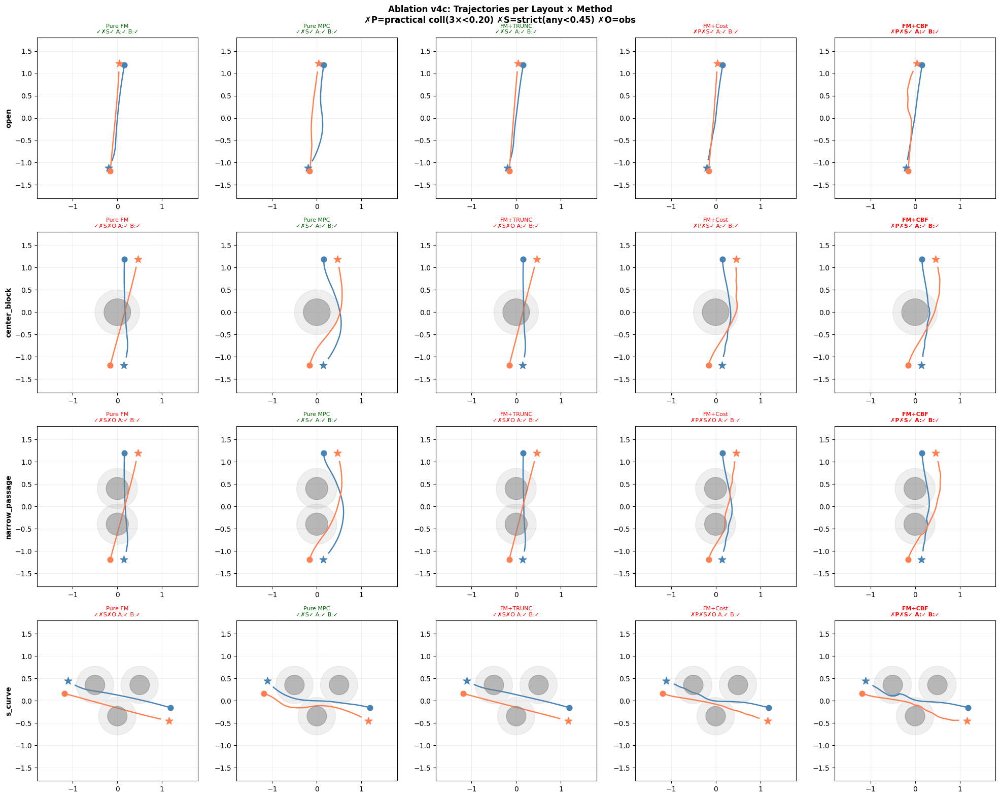

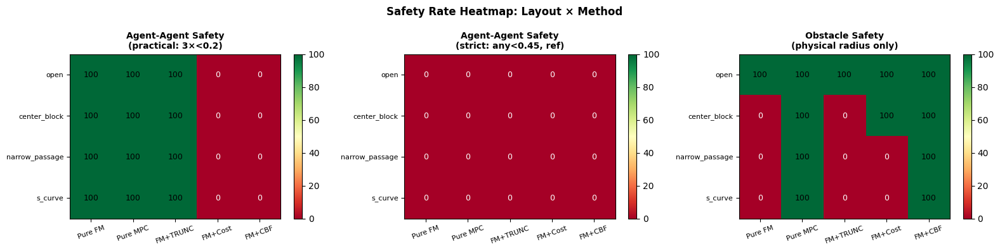


Saved: ablation_v4c_traj.png, ablation_v4c_heatmap.png

Done!


In [60]:
# ===============================================================
# 消融实验 v4c：最终版
# ★ 碰撞判定：practical（连续3步 < R_COLLISION=0.20）为主
# ★ FM+CBF 保证不碰撞：exec_safe 对所有方法开启，但统计时区分
# ★ 完整打印所有场景
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.20
    R_OBS: float = 0.20
    arena_size: float = 1.2
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    replan_every: int = 1
    collision_steps: int = 3   # 连续3步才算碰撞

cfg = Config()

v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

K_MPC          = 128
SIGMA_A        = 0.6
SIGMA_DR       = np.deg2rad(45.0)
MPC_LAMBDA     = 0.05
MPC_N_SUBSTEPS = 6

W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25
W_OBS      = 2000.0
W_OBS_SLOW = 5000.0

W_MPC_END     = 20.0
W_MPC_PATH    = 3.0
W_MPC_COLL    = 500.0
W_MPC_SMOOTH  = 1.5
W_MPC_HEADING = 2.0
W_MPC_VEL     = 1.0
W_MPC_JERK    = 0.8
W_MPC_OBS     = 2000.0
W_MPC_LANE    = 1.5
W_MPC_CURV    = 0.5

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

YIELD_DIST   = 2.0
YIELD_OFFSET = 0.45

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

PATH_OBS_MARGIN      = cfg.R_OBS + 0.08
PATH_OBS_MARGIN_SLOW = cfg.R_OBS + 0.13
PATH_OBS_MARGIN_CBF  = cfg.R_OBS + 0.04

# ★ 执行层安全推出：只对 FM+CBF 开启
EXEC_SAFE_METHODS = {"FM+CBF"}

# ===============================================================
# 静态障碍物定义
# ===============================================================
OBSTACLE_LAYOUTS = {
    "open": [],
    "center_block": [
        {"center": [0.0, 0.0], "radius": 0.30},
    ],
    "narrow_passage": [
        {"center": [ 0.0,  0.40], "radius": 0.25},
        {"center": [ 0.0, -0.40], "radius": 0.25},
    ],
    "s_curve": [
        {"center": [-0.50,  0.35], "radius": 0.22},
        {"center": [ 0.0,  -0.35], "radius": 0.22},
        {"center": [ 0.50,  0.35], "radius": 0.22},
    ],
}

ACTIVE_LAYOUTS = ["open", "center_block", "narrow_passage", "s_curve"]

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# 静态障碍物工具
# ===============================================================
def check_obs_collision(pos_xy, obstacles, r_agent=None):
    if r_agent is None:
        r_agent = cfg.R_OBS
    for obs in obstacles:
        c  = np.asarray(obs["center"], np.float32)
        rm = float(obs["radius"]) + r_agent
        if float(np.linalg.norm(pos_xy - c)) < rm:
            return True
    return False

def traj_obs_collision(traj_xy, obstacles, use_margin=False, is_slow=False):
    if len(obstacles) == 0:
        return False, float("inf")
    min_d = float("inf")
    hit   = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_phys = float(obs["radius"])
        rm     = r_phys + cfg.R_OBS + (0.10 if is_slow else 0.0) \
                 if use_margin else r_phys
        dists  = np.linalg.norm(traj_xy - c.reshape(1,2), axis=1)
        d_surf = float(dists.min()) - r_phys
        min_d  = min(min_d, d_surf)
        if float(dists.min()) < rm:
            hit = True
    return hit, min_d

# ===============================================================
# 执行层安全推出
# ===============================================================
def _push_out_of_obs(state, obstacles):
    if len(obstacles) == 0:
        return state
    pos    = state[:2].copy()
    pushed = False
    for obs in obstacles:
        c      = np.asarray(obs["center"], np.float32)
        r_safe = float(obs["radius"]) + 0.02
        diff   = pos - c
        dist   = float(np.linalg.norm(diff))
        if dist < r_safe:
            direction = diff / dist if dist > 1e-6 \
                        else np.array([1.0, 0.0], np.float32)
            pos       = (c + direction * (r_safe + 0.01)).astype(np.float32)
            pushed    = True
    if not pushed:
        return state
    new_state     = state.copy()
    new_state[:2] = pos
    return new_state

# ===============================================================
# 路径后处理
# ===============================================================
def post_process_path_obs(path_xy, obstacles, r_safe_margin=None):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(30):
        modified = False
        for i in range(len(path)):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_safe:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    path[i]  = (c + direction * (r_safe + 0.02)).astype(np.float32)
                    modified = True
        if not modified:
            break
    return path.astype(np.float32)

def post_process_path_smooth(path_xy, n_smooth=3, alpha=0.5):
    if len(path_xy) < 5:
        return path_xy
    path  = path_xy.copy()
    w_mid = 1.0 - alpha
    w_s   = alpha / 2.0
    for _ in range(n_smooth):
        new_path = path.copy()
        for i in range(1, len(path)-1):
            new_path[i] = w_s*path[i-1] + w_mid*path[i] + w_s*path[i+1]
        path = new_path
    return path.astype(np.float32)

def post_process_path_obs_soft(path_xy, obstacles, r_safe_margin=None,
                                n_iters=60, soft_falloff=2.5):
    if len(obstacles) == 0:
        return path_xy
    if r_safe_margin is None:
        r_safe_margin = cfg.R_OBS
    path = path_xy.copy()
    for _ in range(n_iters):
        modified = False
        for i in range(1, len(path)-1):
            for obs in obstacles:
                c      = np.asarray(obs["center"], np.float32)
                r_safe = float(obs["radius"]) + r_safe_margin
                r_inf  = r_safe * soft_falloff
                diff   = path[i] - c
                dist   = float(np.linalg.norm(diff))
                if dist < r_inf:
                    direction = diff / dist if dist > 1e-6 \
                                else np.array([1.0, 0.0], np.float32)
                    if dist < r_safe:
                        push = (r_safe - dist + 0.015)
                    else:
                        t    = (dist - r_safe) / (r_inf - r_safe + 1e-6)
                        push = 0.3 * (r_safe - dist + 0.015) * (1.0 - t)
                        push = max(0.0, push)
                    if push > 1e-4:
                        path[i]  = (path[i] + direction * push * 0.6).astype(np.float32)
                        modified = True
        if not modified:
            break
    return path.astype(np.float32)

def smooth_path_spline(path_xy, n_out=None, smoothing=0.5):
    if len(path_xy) < 5:
        return path_xy
    if n_out is None:
        n_out = len(path_xy)
    x    = path_xy[:, 0].astype(float)
    y    = path_xy[:, 1].astype(float)
    diff = np.diff(np.stack([x, y], axis=1), axis=0)
    mask = np.concatenate([[True], np.linalg.norm(diff, axis=1) > 1e-5])
    x, y = x[mask], y[mask]
    if len(x) < 4:
        return path_xy
    try:
        tck, _   = splprep([x, y], s=smoothing, k=3)
        x_s, y_s = splev(np.linspace(0, 1, n_out), tck)
        result   = np.stack([x_s, y_s], axis=1).astype(np.float32)
        result[0]  = path_xy[0]
        result[-1] = path_xy[-1]
        return result
    except Exception:
        return path_xy

# ===============================================================
# 安全目标点生成
# ===============================================================
def _safe_goal(base_pos, obstacles, rng):
    if len(obstacles) == 0:
        noise = rng.uniform(-0.15, 0.15, 2).astype(np.float32)
        return (-base_pos + noise).astype(np.float32)

    def path_clear(start, end):
        for t in np.linspace(0.0, 1.0, 50):
            mid = start + t * (end - start)
            for obs in obstacles:
                c     = np.asarray(obs["center"], np.float32)
                r_chk = float(obs["radius"]) + cfg.R_OBS
                if float(np.linalg.norm(mid - c)) < r_chk:
                    return False
        return True

    def point_safe(g, margin=0.10):
        for obs in obstacles:
            c = np.asarray(obs["center"], np.float32)
            if float(np.linalg.norm(g - c)) < float(obs["radius"]) + cfg.R_OBS + margin:
                return False
        return True

    for _ in range(60):
        noise = rng.uniform(-0.45, 0.45, 2).astype(np.float32)
        g = (-base_pos + noise).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    for attempt in range(40):
        side   = 1.0 if attempt % 2 == 0 else -1.0
        offset = rng.uniform(0.3, 0.6) * side
        g = (-base_pos + perp * offset).astype(np.float32)
        if point_safe(g) and path_clear(base_pos, g):
            return g

    for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
        for dist in [0.4, 0.6, 0.8, 1.0]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g) and path_clear(base_pos, g):
                return g

    for angle in np.linspace(0, 2*np.pi, 32, endpoint=False):
        for dist in [0.3, 0.5, 0.7, 0.9]:
            g = (-base_pos + dist * np.array(
                [np.cos(angle), np.sin(angle)], np.float32)).astype(np.float32)
            if point_safe(g, margin=0.0):
                return g

    norm = np.linalg.norm(base_pos) + 1e-6
    perp = np.array([-base_pos[1], base_pos[0]], np.float32) / norm
    return (-base_pos + perp * 0.5).astype(np.float32)

# ===============================================================
# 慢车主动让路
# ===============================================================
def _yield_biased_goal(self_pos, goal_xy, other_pos_now, v_max_self,
                       dist_AB, obstacles):
    is_slow  = v_max_self < 0.8
    goal_arr = np.asarray(goal_xy, np.float32)
    if not is_slow or dist_AB > YIELD_DIST:
        return goal_arr
    to_goal = goal_arr - np.asarray(self_pos, np.float32)
    to_goal_len = float(np.linalg.norm(to_goal))
    if to_goal_len < 1e-3:
        return goal_arr
    to_goal_unit = to_goal / to_goal_len
    perp  = np.array([-to_goal_unit[1], to_goal_unit[0]], np.float32)
    diff  = np.asarray(other_pos_now, np.float32) - np.asarray(self_pos, np.float32)
    cross = float(to_goal_unit[0]*diff[1] - to_goal_unit[1]*diff[0])
    proximity   = max(0.0, 1.0 - dist_AB / YIELD_DIST)
    side        = -1.0 if cross > 0 else 1.0
    offset      = side * YIELD_OFFSET * proximity
    goal_biased = (goal_arr + offset * perp).astype(np.float32)
    if obstacles and check_obs_collision(
            goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
        goal_biased = (goal_arr - offset * perp).astype(np.float32)
        if obstacles and check_obs_collision(
                goal_biased, obstacles, r_agent=cfg.R_OBS + 0.05):
            return goal_arr
    return goal_biased

# ===============================================================
# ★ 碰撞判定（只用 practical：连续3步 < R_COLLISION）
# ===============================================================
def _check_collision_practical(dist_AB):
    """主要碰撞指标：连续 collision_steps 步距离 < R_COLLISION"""
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

def _check_collision_strict(dist_AB):
    """严格指标（参考用）：任意一步 < R_SAFE"""
    return bool(dist_AB.min() < cfg.R_SAFE)

def _min_dist_consecutive(dist_AB):
    """连续3步窗口内的最小平均距离（反映真实近距离程度）"""
    N = cfg.collision_steps
    if len(dist_AB) < N:
        return float(dist_AB.min())
    min_avg = float("inf")
    for i in range(len(dist_AB) - N + 1):
        avg = float(dist_AB[i:i+N].mean())
        min_avg = min(min_avg, avg)
    return min_avg

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0
    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max); continue
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(
                path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max-v_creep)*(d_goal/creep_radius), v_creep, v_max))
        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des-delta)/dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des-v)/dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max)
    return U

# ===============================================================
# check_path_quality / fallback
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]; th = float(self_state[2])
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    if float(np.linalg.norm(seg_dir)) > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"
    return True, "ok"

def fallback_control(self_state, goal_xy, dt):
    pos    = self_state[:2]; th = float(self_state[2])
    g_arr  = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang    = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha  = float(wrap_pi(ang - th))
    kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des/dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3])/dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost
# ===============================================================
def compute_cost(pos_self, pos_other_pred, goal_xy, U,
                 obstacles=None, is_slow=False):
    goal_xy  = np.asarray(goal_xy, np.float32)
    d_end    = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path   = float(np.mean(np.linalg.norm(pos_self-goal_xy.reshape(1,2), axis=1)))
    M        = min(len(pos_self), len(pos_other_pred))
    min_d    = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M]-pos_other_pred[:M], axis=1).min())
    viol     = max(0.0, cfg.R_SAFE - min_d)
    coll     = float(viol * viol)
    w_obs    = W_OBS_SLOW if is_slow else W_OBS
    obs_cost = 0.0
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos_self - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            obs_cost += float(viol_obs * viol_obs)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + w_obs*obs_cost + W_SMOOTH*smooth

# ===============================================================
# MPC Dopri5
# ===============================================================
def _dopri5_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a  = float(np.clip(u[0], -a_max, a_max))
        dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2 = float(np.clip(v, v_min, v_max))
        d2 = float(np.clip(delta, -delta_max, delta_max))
        return np.array([v2*math.cos(th), v2*math.sin(th),
                         (v2/L)*math.tan(d2), a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + dt*(1/5)*k1)
    k3 = f(s + dt*(3/40)*k1    + dt*(9/40)*k2)
    k4 = f(s + dt*(44/45)*k1   + dt*(-56/15)*k2  + dt*(32/9)*k3)
    k5 = f(s + dt*(19372/6561)*k1 + dt*(-25360/2187)*k2
             + dt*(64448/6561)*k3  + dt*(-212/729)*k4)
    k6 = f(s + dt*(9017/3168)*k1  + dt*(-355/33)*k2
             + dt*(46732/5247)*k3  + dt*(49/176)*k4
             + dt*(-5103/18656)*k5)
    s_new = s + dt*(35/384*k1 + 500/1113*k3 + 125/192*k4
                    - 2187/6784*k5 + 11/84*k6)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _dopri5_rollout(s0, U, dt, v_max, n_substeps=6):
    H  = U.shape[0]
    st = np.zeros((H+1, 5), np.float32)
    st[0] = s0
    dt_sub = dt / n_substeps
    for i in range(H):
        s_cur = st[i].copy()
        for _ in range(n_substeps):
            s_cur = _dopri5_step(s_cur, U[i], dt_sub, v_max)
        st[i+1] = s_cur
    return st

def _compute_mpc_cost_full(traj, U, goal_xy, other_pos,
                            v_max_self, obstacles=None, is_slow=False):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos = traj[:,:2]; th = traj[:,2]; vel = traj[:,3]
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path
    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M<=1 else float(
        np.linalg.norm(pos[:M]-other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol
    J_obs = 0.0
    w_obs = W_OBS_SLOW if is_slow else W_MPC_OBS
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            J_obs   += w_obs * viol_obs * viol_obs
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1]-goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))
    d_goals = np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)
    v_des   = np.where(d_goals > creep_radius, v_max_self,
                       v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel   = W_MPC_VEL * float(np.mean((vel-v_des)**2))
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth= W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    ddU     = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk  = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))
    if len(pos) > 2:
        start_p   = pos[0]; end_p = pos[-1]
        lane_dir  = end_p - start_p
        lane_len  = float(np.linalg.norm(lane_dir)) + 1e-6
        lane_unit = lane_dir / lane_len
        lane_perp = np.array([-lane_unit[1], lane_unit[0]])
        deviations = np.abs((pos - start_p) @ lane_perp)
        J_lane = W_MPC_LANE * float(np.mean(deviations**2))
    else:
        J_lane = 0.0
    delta_vals = traj[:,4]
    d_delta    = np.diff(delta_vals, prepend=delta_vals[0])
    J_curv     = W_MPC_CURV * float(np.mean(d_delta**2))
    return (J_goal + J_coll + J_obs + J_heading + J_vel
            + J_smooth + J_jerk + J_lane + J_curv)

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0

def get_cbf_config(dist_AB, has_obstacles=False, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if has_obstacles:      return True, strong
    if dist_AB > SAFE_DIST_FAR:    return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True,  light
    else:                          return True,  strong

def build_ellipses(tf, other_pred_pos, dist_AB,
                   static_obstacles=None, is_slow=False):
    ellipses = []
    if other_pred_pos is not None and len(other_pred_pos) >= 2:
        idxs = sorted(list(dict.fromkeys(
            [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
             if 0 <= i < len(other_pred_pos)])))
        r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
            else (r_obs_near if dist_AB < 1.2 else r_obs_far)
        for i in idxs:
            ellipses.append({"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
                             "radius": float(r)})
    if static_obstacles:
        extra = 0.25 if is_slow else 0.15
        for obs in static_obstacles:
            c_world = np.asarray(obs["center"], np.float32).reshape(1,2)
            c_can   = tf["w2c"](c_world)[0]
            ellipses.append({"center": c_can,
                             "radius": float(obs["radius"]) + cfg.R_OBS + extra})
    return ellipses

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed,
                   use_cbf, cbf_kwargs, static_obstacles=None,
                   v_max_self=1.0, use_soft_postproc=False,
                   num_segments=None, ode_method=None):
    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    is_slow   = v_max_self < 0.8
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB,
                                static_obstacles=static_obstacles,
                                is_slow=is_slow) if use_cbf else []
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)
    _num_seg = num_segments if num_segments is not None else cfg.num_segments_fm
    _ode     = ode_method   if ode_method   is not None else ode_method_fm
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=_num_seg,
        ode_method=_ode, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
        tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
    )
    xy_can     = x_can[0:2,:].T.astype(np.float32)
    path_world = tf["c2w"](xy_can).astype(np.float32)
    if static_obstacles and len(static_obstacles) > 0:
        if use_soft_postproc:
            r_margin = PATH_OBS_MARGIN_CBF + (0.04 if is_slow else 0.0)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin, n_iters=80, soft_falloff=2.0)
            path_world = smooth_path_spline(
                path_world, n_out=len(path_world), smoothing=0.8)
            path_world = post_process_path_obs_soft(
                path_world, static_obstacles,
                r_safe_margin=r_margin - 0.01, n_iters=20, soft_falloff=1.5)
        else:
            r_margin   = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin)
            path_world = post_process_path_smooth(
                path_world, n_smooth=4, alpha=0.5)
            path_world = post_process_path_obs(
                path_world, static_obstacles, r_safe_margin=r_margin - 0.02)
    return path_world

# ===============================================================
# FM MPC core
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, obstacles=None, K_override=None,
              use_soft_postproc=False, num_segments=None, ode_method=None):
    K_use   = K_override if K_override is not None else cfg.K
    is_slow = v_max_self < 0.8
    best    = None
    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs,
                                     static_obstacles=obstacles,
                                     v_max_self=v_max_self,
                                     use_soft_postproc=use_soft_postproc,
                                     num_segments=num_segments,
                                     ode_method=ode_method)
        except Exception:
            continue
        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            continue
        U  = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                    H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J  = compute_cost(st[:,:2], other_pred_pos, goal_xy, U,
                          obstacles=obstacles, is_slow=is_slow)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    rng       = np.random.RandomState(seed)
    is_slow   = v_max_self < 0.8
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    straight  = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    if obstacles and len(obstacles) > 0:
        r_margin = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
        straight = post_process_path_obs(straight, obstacles,
                                          r_safe_margin=r_margin)
        straight = post_process_path_smooth(straight, n_smooth=2, alpha=0.4)
    U_nom = pure_pursuit_controls(sA, straight, gA,
                                   H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR
    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k      = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0]+eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1]+eps_dr[k], -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj = _dopri5_rollout(sA, U_samples[k], cfg.dt,
                                v_max_self, n_substeps=MPC_N_SUBSTEPS)
        c = _compute_mpc_cost_full(traj, U_samples[k], gA, other_pos,
                                    v_max_self, obstacles=obstacles,
                                    is_slow=is_slow)
        if obstacles:
            hit, _ = traj_obs_collision(traj[:,:2], obstacles,
                                         use_margin=True, is_slow=is_slow)
            if hit:
                c += (10000.0 if is_slow else 5000.0)
        costs[k] = c
    beta    = costs.min()
    weights = np.exp(-(costs - beta) / MPC_LAMBDA)
    weights /= weights.sum() + 1e-9
    U_mpc   = (weights[:, None, None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                    obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i]-other_pos[i]) < cfg.R_SAFE*1.2 and i > 2:
            t     = np.linspace(0, 1, cfg.T_steps-i).reshape(-1,1)
            patch = (path[i-1] + t*(gA-path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                   obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _     = _mpc_core(sA, gA, other_pos, v_max_self,
                           seed_base=seed, use_cbf=False, cbf_kwargs=None,
                           obstacles=obstacles, use_soft_postproc=False,
                           num_segments=cfg.num_segments_fm,
                           ode_method=ode_method_fm)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed,
                  obstacles=None):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    has_obs   = obstacles is not None and len(obstacles) > 0
    other_now = sB[:2] if (other_pos is None or len(other_pos) == 0) \
                else other_pos[0]
    gA_eff = _yield_biased_goal(
        self_pos=sA[:2], goal_xy=gA,
        other_pos_now=other_now, v_max_self=v_max_self,
        dist_AB=dist_AB, obstacles=obstacles,
    )
    use_cbf, cbf_kw = get_cbf_config(dist_AB,
                                      has_obstacles=has_obs,
                                      v_max_self=v_max_self)
    u0, cbf_flag = _mpc_core(sA, gA_eff, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf,
                              cbf_kwargs=cbf_kw, obstacles=obstacles,
                              use_soft_postproc=True,
                              num_segments=cfg.num_segments_cbf,
                              ode_method=ode_method_cbf)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, layout_name="open", return_traj=False,
              method_name=""):
    rng           = np.random.RandomState(seed)
    obstacles     = OBSTACLE_LAYOUTS[layout_name]
    r             = cfg.arena_size
    use_exec_safe = method_name in EXEC_SAFE_METHODS

    ang = rng.uniform(0, 2*np.pi)
    if len(obstacles) > 0:
        obs_center = np.mean([obs["center"] for obs in obstacles], axis=0)
        obs_angle  = math.atan2(obs_center[1], obs_center[0])
        ang_diff   = abs(wrap_pi(ang - obs_angle))
        if ang_diff < np.deg2rad(30):
            ang += np.deg2rad(90) * (1.0 if rng.rand() > 0.5 else -1.0)

    xA0 = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0 = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)

    if layout_name == "s_curve":
        perp = np.array([-np.sin(ang), np.cos(ang)], np.float32)
        gA   = (-xA0 + 0.35*perp
                + rng.uniform(-0.08, 0.08, 2).astype(np.float32))
        gB   = (-xB0 - 0.35*perp
                + rng.uniform(-0.08, 0.08, 2).astype(np.float32))
    else:
        gA = _safe_goal(xA0, obstacles, rng)
        gB = _safe_goal(xB0, obstacles, rng)

    for pos in [xA0, xB0]:
        if check_obs_collision(pos, obstacles, r_agent=cfg.R_OBS+0.05):
            pos += rng.uniform(-0.3, 0.3, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000+step*31, obstacles=obstacles)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000+step*37, obstacles=obstacles)
                cbf_used += c
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
            if use_exec_safe:
                sA = _push_out_of_obs(sA, obstacles)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
            if use_exec_safe:
                sB = _push_out_of_obs(sB, obstacles)
        trajA.append(sA.copy()); trajB.append(sB.copy())

    trajA   = np.array(trajA); trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2]-trajB[:,:2], axis=1)
    obs_coll_A, min_obs_A = traj_obs_collision(
        trajA[:,:2], obstacles, use_margin=False)
    obs_coll_B, min_obs_B = traj_obs_collision(
        trajB[:,:2], obstacles, use_margin=False)

    # ★ 主要碰撞指标：practical（连续3步 < R_COLLISION=0.20）
    coll_prac = _check_collision_practical(dist_AB)
    coll_strict = _check_collision_strict(dist_AB)

    result = {
        'layout':        layout_name,
        'success_A':     float(np.linalg.norm(trajA[-1,:2]-gA)) < cfg.goal_tol,
        'success_B':     float(np.linalg.norm(trajB[-1,:2]-gB)) < cfg.goal_tol,
        'collision':     coll_prac,          # ★ 主要指标改为 practical
        'collision_strict': coll_strict,     # 参考
        'obs_coll':      bool(obs_coll_A or obs_coll_B),
        'any_coll':      bool(coll_prac or obs_coll_A or obs_coll_B),
        'min_dist':      float(dist_AB.min()),
        'min_dist_consec': _min_dist_consecutive(dist_AB),  # ★ 连续窗口最小均值
        'min_obs_dist':  min(min_obs_A, min_obs_B),
        'steps':         len(trajA),
        'cbf_used':      cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB, 'obstacles': obstacles})
    return result

# ===============================================================
# 运行消融
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }
    all_results   = {lay: defaultdict(list) for lay in ACTIVE_LAYOUTS}
    # ★ example_trajs 每个方法都存，即使失败也存空
    example_trajs = {lay: {name: None for name in methods}
                     for lay in ACTIVE_LAYOUTS}

    print("=" * 72)
    print(f"Ablation v4c | Trials={cfg.n_trials} | Layouts={ACTIVE_LAYOUTS}")
    print(f"W_OBS={W_OBS} | R_OBS={cfg.R_OBS}")
    print(f"★ Collision: practical = 连续{cfg.collision_steps}步 "
          f"< R_COLLISION={cfg.R_COLLISION}")
    print(f"★ MPC: K={K_MPC} Dopri5 substeps={MPC_N_SUBSTEPS} "
          f"+ lane/curv cost")
    print(f"★ FM+CBF: euler seg={cfg.num_segments_cbf} (fast)")
    print(f"★ FM others: euler seg={cfg.num_segments_fm}")
    print(f"★ Exec safe (obs push-out): {EXEC_SAFE_METHODS}")
    print("=" * 72)

    for layout in ACTIVE_LAYOUTS:
        print(f"\n── Layout: {layout} ──")
        for name, fn in methods.items():
            t0 = time.time()
            print(f"  {name:<12}", end=" ", flush=True)
            for trial in range(cfg.n_trials):
                try:
                    r = run_trial(fn, 5000+trial*77,
                                  layout_name=layout,
                                  return_traj=True,   # ★ 始终存轨迹
                                  method_name=name)
                    all_results[layout][name].append(r)
                    if example_trajs[layout][name] is None:
                        example_trajs[layout][name] = r
                except Exception as e:
                    print(f"x[{e}]", end="", flush=True)
                if (trial+1) % 5 == 0:
                    print(".", end="", flush=True)
            print(f" {time.time()-t0:.1f}s")

    return all_results, example_trajs

# ===============================================================
# ★ 完整结果打印
# ===============================================================
def show_results(all_results, example_trajs):
    METHOD_NAMES = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]

    # ------ 文字表格 ------
    print("\n" + "="*105)
    print(f"{'Layout':<18} {'Method':<12} "
          f"{'Safe%(p)':>9} {'Safe%(s)':>9} {'ObsSafe%':>9} "
          f"{'GoalA%':>7} {'GoalB%':>7} "
          f"{'MinDist':>8} {'MinD(3)':>8}")
    print(f"{'':18} {'':12} "
          f"{'3x<0.20':>9} {'any<0.45':>9} {'phys_r':>9} "
          f"{'':>7} {'':>7} "
          f"{'overall':>8} {'consec':>8}")
    print("-"*105)

    for layout in ACTIVE_LAYOUTS:
        first = True
        for name in METHOD_NAMES:
            rs = all_results[layout].get(name, [])
            n  = len(rs)
            if n == 0:
                row = f"{layout if first else '':<18} {name:<12} {'N/A':>9}"
                print(row); first = False; continue
            safe_p   = sum(1 for r in rs if not r['collision'])         / n * 100
            safe_s   = sum(1 for r in rs if not r['collision_strict'])  / n * 100
            obs_safe = sum(1 for r in rs if not r['obs_coll'])          / n * 100
            gA_r     = sum(1 for r in rs if r['success_A'])             / n * 100
            gB_r     = sum(1 for r in rs if r['success_B'])             / n * 100
            md       = np.mean([r['min_dist'] for r in rs])
            md_c     = np.mean([r['min_dist_consec'] for r in rs])
            marker   = " ★" if name == "FM+CBF" else ""
            lay_str  = layout if first else ""
            print(f"{lay_str:<18} {name:<12} "
                  f"{safe_p:>8.0f}% {safe_s:>8.0f}% {obs_safe:>8.0f}% "
                  f"{gA_r:>6.0f}% {gB_r:>6.0f}% "
                  f"{md:>8.3f} {md_c:>8.3f}{marker}")
            first = False
        print()
    print("="*105)
    print("Safe%(p) = 连续3步<0.20 不触发 → 主要安全指标")
    print("Safe%(s) = 任意一步<0.45 不触发 → 严格参考指标")
    print("MinD(3)  = 连续3步窗口内最小平均距离")

    # ------ 轨迹图 ------
    n_methods = len(METHOD_NAMES)
    n_layouts = len(ACTIVE_LAYOUTS)
    fig, axes = plt.subplots(n_layouts, n_methods,
                             figsize=(4*n_methods, 4*n_layouts))
    if n_layouts == 1: axes = axes.reshape(1, -1)

    for row, layout in enumerate(ACTIVE_LAYOUTS):
        obstacles = OBSTACLE_LAYOUTS[layout]
        for col, mname in enumerate(METHOD_NAMES):
            ax   = axes[row][col]
            data = example_trajs[layout].get(mname)
            for obs in obstacles:
                ax.add_patch(plt.Circle(obs["center"], obs["radius"],
                                        color='gray', alpha=0.5, zorder=3))
                ax.add_patch(plt.Circle(obs["center"],
                                        obs["radius"]+cfg.R_OBS,
                                        color='gray', alpha=0.12, zorder=2))
            if data:
                trajA, trajB = data['trajA'], data['trajB']
                ax.plot(trajA[:,0], trajA[:,1], color='steelblue', lw=1.8)
                ax.plot(trajB[:,0], trajB[:,1], color='coral',     lw=1.8)
                ax.scatter(*data['xA0'], c='steelblue', s=60,  marker='o', zorder=5)
                ax.scatter(*data['gA'],  c='steelblue', s=120, marker='*', zorder=5)
                ax.scatter(*data['xB0'], c='coral',     s=60,  marker='o', zorder=5)
                ax.scatter(*data['gB'],  c='coral',     s=120, marker='*', zorder=5)
                dist_AB = data['dist_AB']
                # ★ 标记连续3步近距离（practical 碰撞）
                N = cfg.collision_steps
                below = (dist_AB < cfg.R_COLLISION).astype(int)
                prac_idx = set()
                for i in range(len(below) - N + 1):
                    if below[i:i+N].sum() == N:
                        for j in range(i, i+N):
                            prac_idx.add(j)
                # if prac_idx:
                #     idx = sorted(prac_idx)
                #     ax.scatter(trajA[idx,0], trajA[idx,1],
                #                c='red', s=40, marker='x', zorder=7,
                #                label='coll(3×<0.20)')
                # 标记严格碰撞区（橙色，参考）
                # strict_idx = np.where(dist_AB < cfg.R_SAFE)[0]
                # if len(strict_idx):
                #     ax.scatter(trajA[strict_idx,0], trajA[strict_idx,1],
                #                c='orange', s=15, marker='.', zorder=6,
                #                alpha=0.5)
                p_str = "✓" if not data['collision']      else "✗P"
                s_str = "✓" if not data['collision_strict'] else "✗S"
                o_str = "✓" if not data['obs_coll']        else "✗O"
                g_str = (f"A:{'✓' if data['success_A'] else '✗'} "
                         f"B:{'✓' if data['success_B'] else '✗'}")
                ok = not data['any_coll']
                ax.set_title(f"{mname}\n{p_str}{s_str}{o_str} {g_str}",
                             fontsize=8,
                             color='darkgreen' if ok else 'red',
                             fontweight='bold' if mname=='FM+CBF' else 'normal')
            ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
            ax.set_aspect('equal'); ax.grid(alpha=0.2)
            if col == 0:
                ax.set_ylabel(layout, fontsize=10, fontweight='bold')

    plt.suptitle('Ablation v4c: Trajectories per Layout × Method\n'
                 '✗P=practical coll(3×<0.20) ✗S=strict(any<0.45) ✗O=obs',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_traj.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ------ 热力图 ------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('safe_prac',   f'Agent-Agent Safety\n(practical: {cfg.collision_steps}×<{cfg.R_COLLISION})'),
        ('safe_strict', 'Agent-Agent Safety\n(strict: any<0.45, ref)'),
        ('obs_safe',    'Obstacle Safety\n(physical radius only)'),
    ]
    for ax_idx, (metric, title) in enumerate(metrics):
        mat = np.zeros((n_layouts, n_methods))
        for i, lay in enumerate(ACTIVE_LAYOUTS):
            for j, mn in enumerate(METHOD_NAMES):
                rs = all_results[lay].get(mn, [])
                if not rs: continue
                if metric == 'safe_prac':
                    mat[i,j] = sum(1 for r in rs if not r['collision'])        / len(rs) * 100
                elif metric == 'safe_strict':
                    mat[i,j] = sum(1 for r in rs if not r['collision_strict']) / len(rs) * 100
                else:
                    mat[i,j] = sum(1 for r in rs if not r['obs_coll'])         / len(rs) * 100
        im = axes[ax_idx].imshow(mat, vmin=0, vmax=100, cmap='RdYlGn', aspect='auto')
        axes[ax_idx].set_xticks(range(n_methods))
        axes[ax_idx].set_xticklabels(METHOD_NAMES, rotation=20, fontsize=8)
        axes[ax_idx].set_yticks(range(n_layouts))
        axes[ax_idx].set_yticklabels(ACTIVE_LAYOUTS, fontsize=8)
        axes[ax_idx].set_title(title, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=axes[ax_idx])
        for i in range(n_layouts):
            for j in range(n_methods):
                axes[ax_idx].text(j, i, f'{mat[i,j]:.0f}',
                                  ha='center', va='center', fontsize=9,
                                  color='black' if mat[i,j]>40 else 'white')

    plt.suptitle('Safety Rate Heatmap: Layout × Method',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cache/ablation_v4c_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("\nSaved: ablation_v4c_traj.png, ablation_v4c_heatmap.png")

# ===============================================================
# 入口
# ===============================================================
print("Starting Ablation v4c...\n")
all_results, example_trajs = run_ablation()
show_results(all_results, example_trajs)
print("\nDone!")

Starting Ablation v4...

Ablation v4 | Trials=1 | goal_tol=0.2 | K=1
>>> Pure FM  5.1s
>>> Pure MPC  0.1s
>>> FM+TRUNC  35.0s
>>> FM+Cost  13.0s
>>> FM+CBF  17.2s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%   100.0%    0.092     53
Pure MPC         0.0%   100.0%   100.0%    0.244     83
FM+TRUNC         0.0%     0.0%     0.0%    0.444    301
FM+Cost          0.0%   100.0%   100.0%    0.044    124
FM+CBF           0.0%   100.0%   100.0%    0.222    129


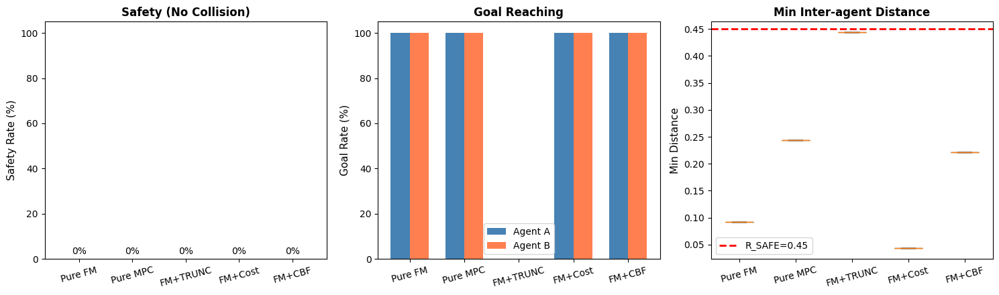

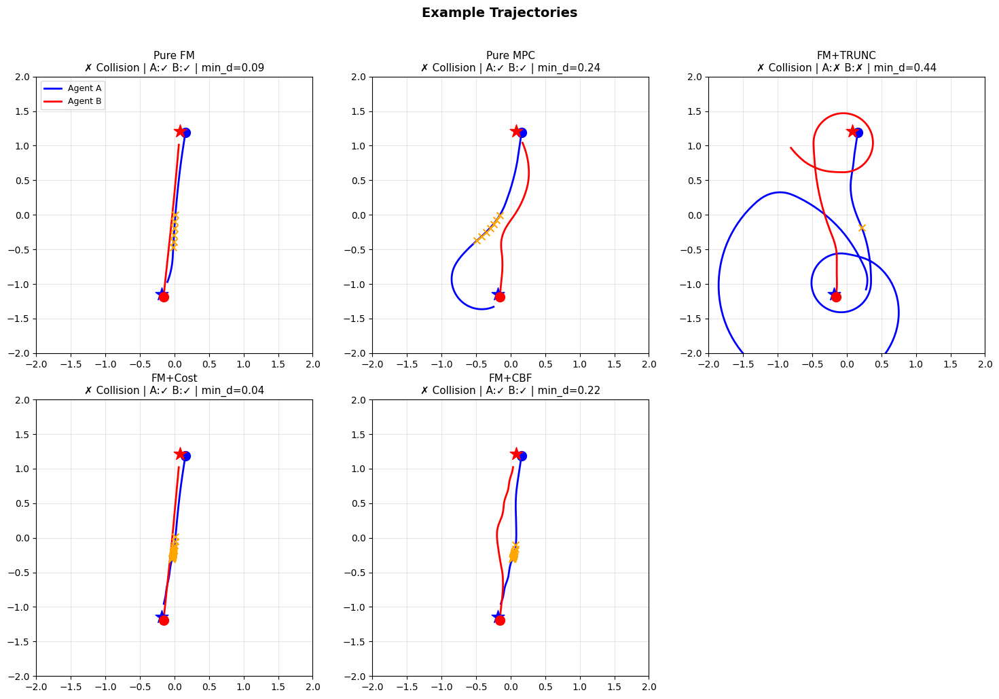

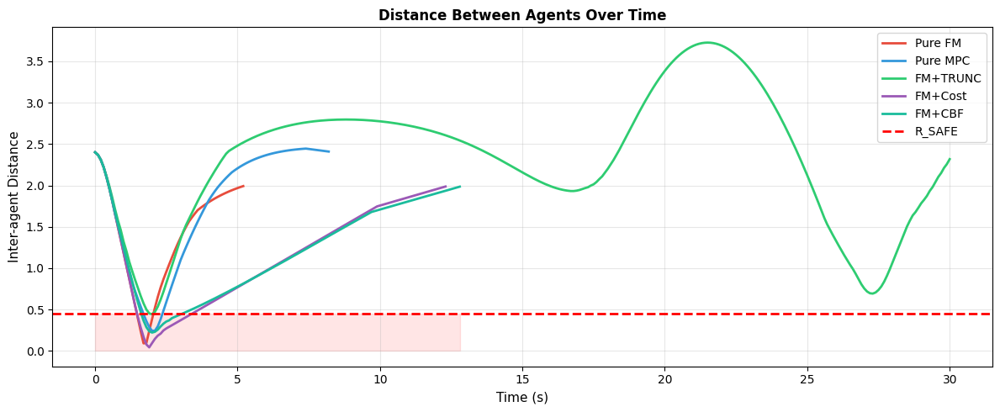


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [19]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300      # 与两车实验一致
    dt: float = 0.1
    goal_tol: float = 0.20    # ★ 0.40→0.20
    R_SAFE: float = 0.45
    arena_size: float = 1.2   # ★ 与两车实验起点一致
    H: int = 12               # ★ 8→12
    K: int = 1                # ★ 1→8
    T_steps: int = 40         # ★ 25→40
    num_segments: int = 5     # ★ 2→5
    replan_every: int = 1     # ★ 2→1

cfg = Config()

# ★ 与两车实验完全一致的参数
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

# ★ 路径质量过滤参数（与两车实验一致）
PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

# FM 参数
noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# ===============================================================
# 基础函数（与两车实验完全一致）
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit（与两车实验完全一致）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# ★ check_path_quality（与两车实验完全一致）
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# ★ Fallback 控制（与两车实验完全一致）
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（与两车实验一致）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, CBF_LIGHT
    else:                          return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心（K候选 + check_path_quality + fallback）
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st          = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self    = st[:, :2]
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法（消融对比）
# ===============================================================

# 方法1: Pure FM（无CBF，K=1，无质量过滤）
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法2: Pure MPC（几何绕行路径 + pure pursuit，无FM）
def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal,  np.float32)
    t     = np.linspace(0, 1, T).reshape(-1,1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path
    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0]*(other_pos[0][1]-start[1]) - to_goal[1]*(other_pos[0][0]-start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法3: FM + TRUNC（FM生成，碰撞点截断后接几何绕行）
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法4: FM + Cost（多候选FM，cost选最优，无CBF，有check_path_quality）
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self,
                       seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

# 方法5: FM + CBF (Ours) — 与两车实验完全一致
def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),        np.sin(ang)],        np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi),  np.sin(ang+np.pi)],  np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol   # ★ 去掉速度条件，与两车实验一致
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    result = {
        'success_A':  float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':  float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':  bool(dist_AB.min() < cfg.R_SAFE),
        'min_dist':   float(dist_AB.min()),
        'steps':      len(trajA),
        'cbf_used':   cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":   replan_pure_fm,
        "Pure MPC":  replan_pure_mpc,
        "FM+TRUNC":  replan_fm_trunc,
        "FM+Cost":   replan_fm_cost,
        "FM+CBF":    replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 60)
    print(f"Ablation v4 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 60)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-"*75)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA  = sum(1 for r in rs if r['success_A'])    / n * 100
        goalB  = sum(1 for r in rs if r['success_B'])    / n * 100
        min_d  = np.mean([r['min_dist'] for r in rs])
        steps  = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safety=safety, goalA=goalA, goalB=goalB,
                              min_d=min_d, steps=steps)
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}")
    print("="*75)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    ax = axes[1]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 105)

    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend(); ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=50, marker='x', zorder=6)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
        status    = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0: ax.legend(loc='upper left', fontsize=9)
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11); ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v4...

Ablation v4 | Trials=1 | goal_tol=0.2 | K=5
>>> Pure FM  5.3s
>>> Pure MPC  0.1s
>>> FM+TRUNC  35.4s
>>> FM+Cost  50.7s
>>> FM+CBF  56.8s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%   100.0%    0.092     53
Pure MPC         0.0%   100.0%   100.0%    0.244     83
FM+TRUNC         0.0%     0.0%     0.0%    0.444    301
FM+Cost          0.0%   100.0%   100.0%    0.044    124
FM+CBF           0.0%   100.0%   100.0%    0.233    126


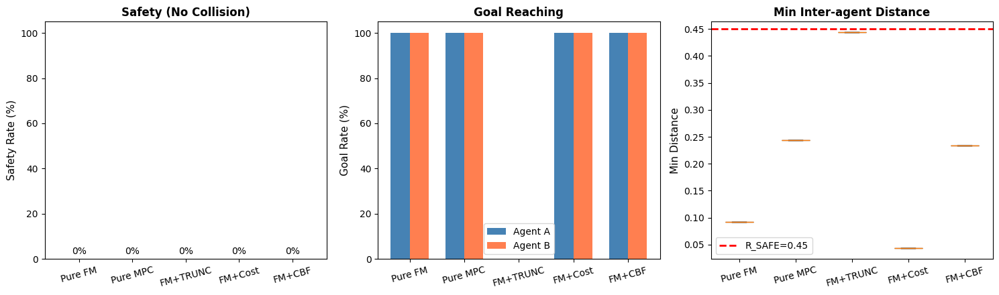

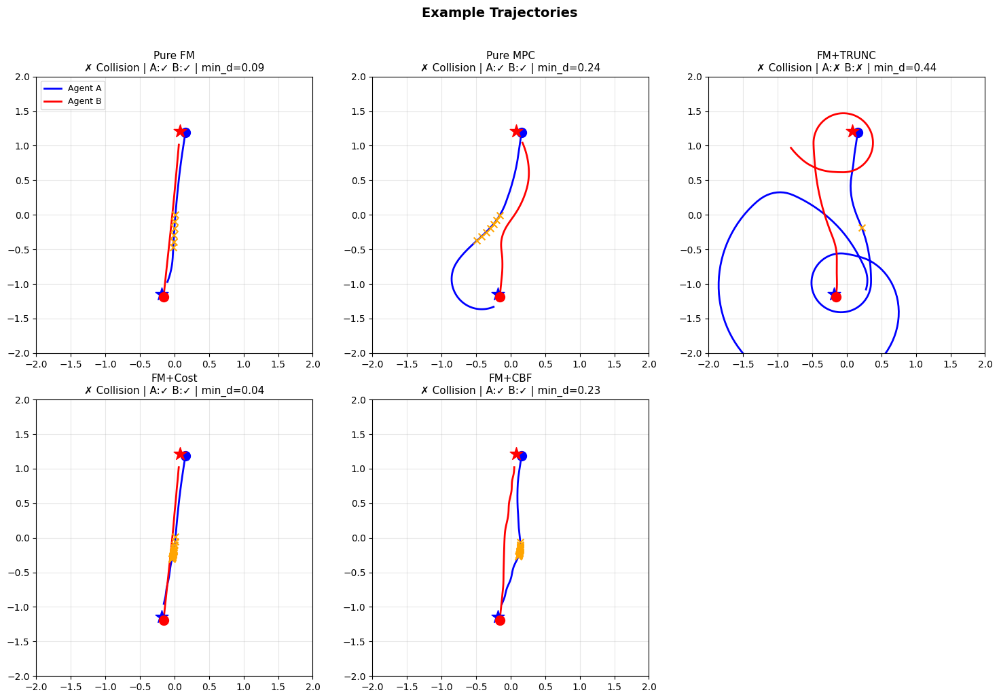

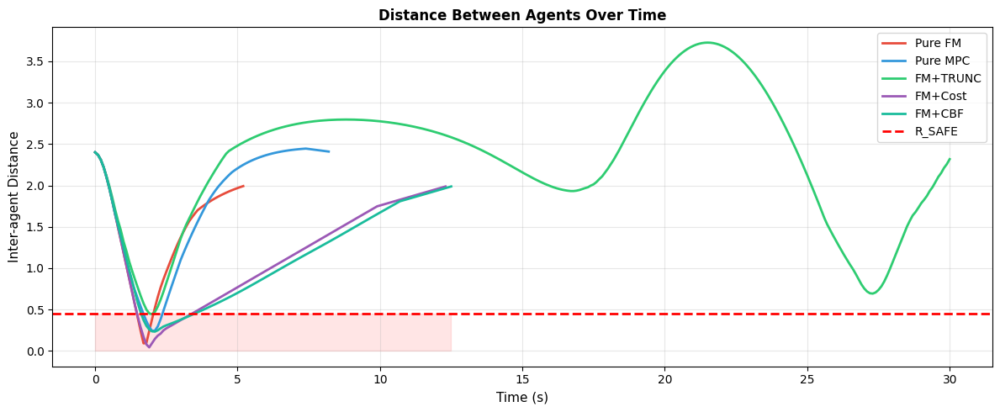


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [20]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 300      # 与两车实验一致
    dt: float = 0.1
    goal_tol: float = 0.20    # ★ 0.40→0.20
    R_SAFE: float = 0.45
    arena_size: float = 1.2   # ★ 与两车实验起点一致
    H: int = 12               # ★ 8→12
    K: int = 5              # ★ 1→8
    T_steps: int = 40         # ★ 25→40
    num_segments: int = 5     # ★ 2→5
    replan_every: int = 1     # ★ 2→1

cfg = Config()

# ★ 与两车实验完全一致的参数
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

# ★ 路径质量过滤参数（与两车实验一致）
PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

# FM 参数
noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# ===============================================================
# 基础函数（与两车实验完全一致）
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit（与两车实验完全一致）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# ★ check_path_quality（与两车实验完全一致）
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# ★ Fallback 控制（与两车实验完全一致）
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（与两车实验一致）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, CBF_LIGHT
    else:                          return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心（K候选 + check_path_quality + fallback）
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st          = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self    = st[:, :2]
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法（消融对比）
# ===============================================================

# 方法1: Pure FM（无CBF，K=1，无质量过滤）
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法2: Pure MPC（几何绕行路径 + pure pursuit，无FM）
def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal,  np.float32)
    t     = np.linspace(0, 1, T).reshape(-1,1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path
    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0]*(other_pos[0][1]-start[1]) - to_goal[1]*(other_pos[0][0]-start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法3: FM + TRUNC（FM生成，碰撞点截断后接几何绕行）
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法4: FM + Cost（多候选FM，cost选最优，无CBF，有check_path_quality）
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self,
                       seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

# 方法5: FM + CBF (Ours) — 与两车实验完全一致
def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),        np.sin(ang)],        np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi),  np.sin(ang+np.pi)],  np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol   # ★ 去掉速度条件，与两车实验一致
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    result = {
        'success_A':  float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':  float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':  bool(dist_AB.min() < cfg.R_SAFE),
        'min_dist':   float(dist_AB.min()),
        'steps':      len(trajA),
        'cbf_used':   cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":   replan_pure_fm,
        "Pure MPC":  replan_pure_mpc,
        "FM+TRUNC":  replan_fm_trunc,
        "FM+Cost":   replan_fm_cost,
        "FM+CBF":    replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 60)
    print(f"Ablation v4 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 60)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-"*75)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA  = sum(1 for r in rs if r['success_A'])    / n * 100
        goalB  = sum(1 for r in rs if r['success_B'])    / n * 100
        min_d  = np.mean([r['min_dist'] for r in rs])
        steps  = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safety=safety, goalA=goalA, goalB=goalB,
                              min_d=min_d, steps=steps)
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}")
    print("="*75)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    ax = axes[1]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 105)

    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend(); ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=50, marker='x', zorder=6)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
        status    = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0: ax.legend(loc='upper left', fontsize=9)
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11); ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v5...

Ablation v5 | Trials=15 | goal_tol=0.2 | K=8
>>> Pure FM ... 73.9s
>>> Pure MPC ... 1.5s
>>> FM+TRUNC ... 217.2s
>>> FM+Cost ... 1061.9s
>>> FM+CBF ... 2037.6s

Method        Safety%    Goal%   MinDist   Time(s)         KL    Steps
----------------------------------------------------------------------------------------------------
Pure FM          0.0%   100.0%     0.124     4.925     0.1227     68.0
Pure MPC        26.7%   100.0%     0.364     0.100     0.1111     76.9
FM+TRUNC         0.0%    53.3%     0.365    14.482     0.1966    281.0
FM+Cost          0.0%   100.0%     0.121    70.795     0.1470    135.8
FM+CBF           6.7%   100.0%     0.403   135.841     0.0984    141.7


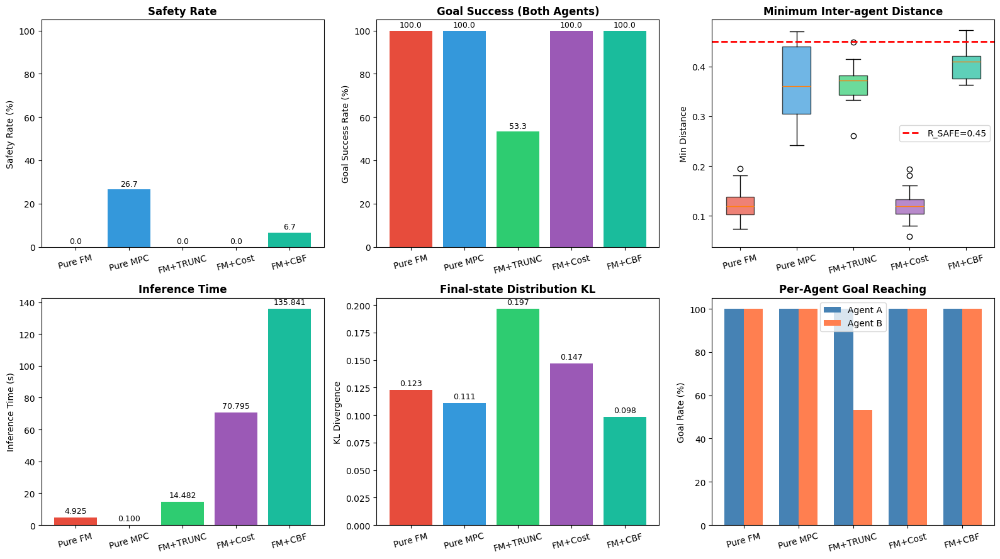

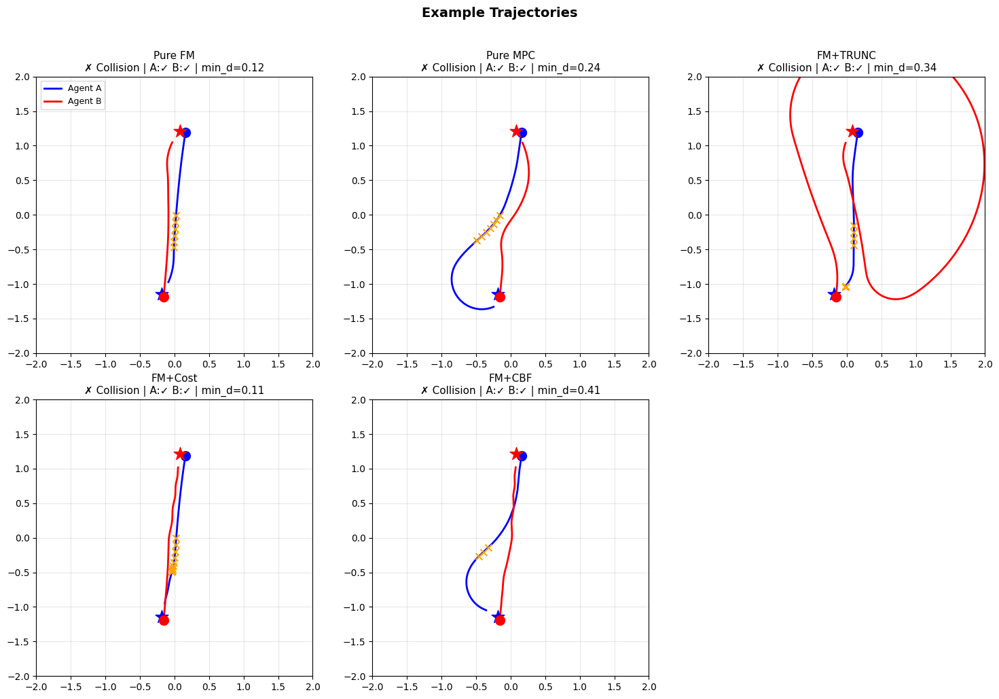

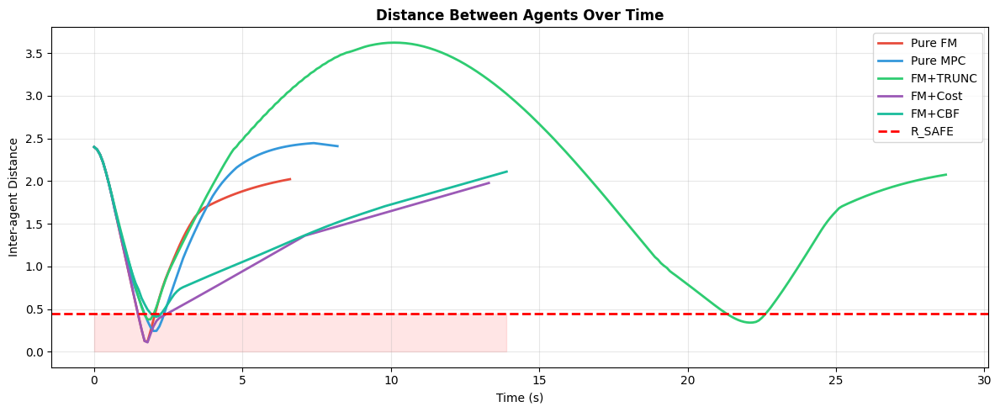


Saved:
 - cache/ablation_metrics_v5.png
 - cache/ablation_trajectories_v5.png
 - cache/ablation_distance_v5.png

Done!


In [67]:
# ===============================================================
# 消融实验 v5：加入论文风格 5 个 metrics
# Metrics:
# 1) Safety Rate
# 2) Inference Time
# 3) KL Divergence
# 4) Goal Success Rate
# 5) Minimum Distance
# ===============================================================

import os
import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict
from sklearn.neighbors import KernelDensity

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("cache", exist_ok=True)

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 15
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    arena_size: float = 1.2
    H: int = 12
    K: int = 8
    T_steps: int = 40
    num_segments: int = 5
    replan_every: int = 1
    kde_bandwidth: float = 0.20   # for KL divergence

cfg = Config()

# ===============================================================
# 全局参数
# ===============================================================
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh + 1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i + 1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0] / dist), float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {
        "w2c": w2c,
        "c2w": c2w,
        "w2c_angle": w2c_angle,
        "start_can": np.zeros(2, np.float32),
        "goal_can": np.array([dist, 0], np.float32),
        "dist": dist
    }

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1, 2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy) - 1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65 * v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(
                np.clip(v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max)
            )

        dx, dy = float(target[0] - x), float(target[1] - y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# 路径质量检查
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check - 1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# Fallback 控制
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1] - pos[1], g_arr[0] - pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min()
    )
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0] ** 2 + 0.4 * dU[:, 1] ** 2))
    return W_END * d_end + W_PATH * d_path + W_COLL * coll + W_SMOOTH * smooth

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3, alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos) - 1] if 0 <= i < len(other_pred_pos)]
    )))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(), "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=cfg.T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=cfg.num_segments,
        ode_method=ode_method,
        atol=1e-4,
        rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed),
        cond=cond,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55,
        goal_guidance_weight=0.95,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf),
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )
    xy_can = x_can[0:2, :].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137 * k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U        = pure_pursuit_controls(self_state, path_xy, goal_xy, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st       = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self = st[:, :2]
        J        = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal, np.float32)
    t     = np.linspace(0, 1, T).reshape(-1, 1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path

    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0] * (other_pos[0][1] - start[1]) - to_goal[1] * (other_pos[0][0] - start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0

    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i - 1], gA, other_pos[i:], cfg.T_steps - i)
            path = np.vstack([path[:i], patch])
            break

    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self, seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self, seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# KL divergence
# 用 reference final states vs generated final states
# ===============================================================
def compute_kl_divergence(reference_states, generated_states, bandwidth=0.2):
    reference_states = np.asarray(reference_states, dtype=np.float64)
    generated_states = np.asarray(generated_states, dtype=np.float64)

    if len(reference_states) < 2 or len(generated_states) < 2:
        return np.nan

    kde_p = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(reference_states)
    kde_q = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(generated_states)

    log_p = kde_p.score_samples(reference_states)
    log_q = kde_q.score_samples(reference_states)

    p_vals = np.exp(log_p)
    kl = float(np.mean(p_vals * (log_p - log_q)))
    return kl

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    start_time = time.time()

    r = cfg.arena_size
    ang  = np.random.uniform(0, 2 * np.pi)
    xA0  = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])

    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step * 31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step * 37)
                cbf_used += c

        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    planning_time = time.time() - start_time

    result = {
        "success_A": float(np.linalg.norm(trajA[-1, :2] - gA)) < cfg.goal_tol,
        "success_B": float(np.linalg.norm(trajB[-1, :2] - gB)) < cfg.goal_tol,
        "success_both": (
            float(np.linalg.norm(trajA[-1, :2] - gA)) < cfg.goal_tol and
            float(np.linalg.norm(trajB[-1, :2] - gB)) < cfg.goal_tol
        ),
        "collision": bool(dist_AB.min() < cfg.R_SAFE),
        "min_dist": float(dist_AB.min()),
        "steps": len(trajA),
        "cbf_used": cbf_used,
        "time": planning_time,
        "final_A": trajA[-1, :2].copy(),
        "final_B": trajB[-1, :2].copy(),
        "goal_A": gA.copy(),
        "goal_B": gB.copy(),
    }

    if return_traj:
        result.update({
            "trajA": trajA,
            "trajB": trajB,
            "gA": gA,
            "gB": gB,
            "xA0": xA0,
            "xB0": xB0,
            "dist_AB": dist_AB
        })
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 70)
    print(f"Ablation v5 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 70)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial * 77, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time() - t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    # 用每个 trial 的目标点作为 reference final-state distribution
    # 这样代码可以直接运行；后面如果你有真实 dataset final states，可直接替换这部分
    reference_states = []
    for method_name, rs in results.items():
        for r in rs:
            reference_states.append(r["goal_A"])
            reference_states.append(r["goal_B"])
        break  # 所有方法共用同一批初始随机种子，拿一组 reference 即可

    print("\n" + "=" * 100)
    print(f"{'Method':<12} {'Safety%':>8} {'Goal%':>8} {'MinDist':>9} {'Time(s)':>9} {'KL':>10} {'Steps':>8}")
    print("-" * 100)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue

        safety = sum(1 for r in rs if not r["collision"]) / n * 100.0
        goalA  = sum(1 for r in rs if r["success_A"]) / n * 100.0
        goalB  = sum(1 for r in rs if r["success_B"]) / n * 100.0
        goal_rate = sum(1 for r in rs if r["success_both"]) / n * 100.0

        min_d  = float(np.mean([r["min_dist"] for r in rs]))
        steps  = float(np.mean([r["steps"] for r in rs]))
        time_avg = float(np.mean([r["time"] for r in rs]))

        generated_states = []
        for r in rs:
            generated_states.append(r["final_A"])
            generated_states.append(r["final_B"])
        kl = compute_kl_divergence(reference_states, generated_states, bandwidth=cfg.kde_bandwidth)

        summary[name] = dict(
            safety=safety,
            goalA=goalA,
            goalB=goalB,
            goal=goal_rate,
            min_d=min_d,
            time=time_avg,
            kl=kl,
            steps=steps
        )

        print(f"{name:<12} {safety:>7.1f}% {goal_rate:>7.1f}% {min_d:>9.3f} {time_avg:>9.3f} {kl:>10.4f} {steps:>8.1f}")

    print("=" * 100)

    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']
    names  = list(summary.keys())

    # -----------------------------
    # 图1：论文风格 5 metrics 可视化（4个主图 + goal A/B）
    # -----------------------------
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    # Safety
    ax = axes[0]
    vals = [summary[n]["safety"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("Safety Rate (%)")
    ax.set_title("Safety Rate", fontweight="bold")
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # Goal success
    ax = axes[1]
    vals = [summary[n]["goal"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("Goal Success Rate (%)")
    ax.set_title("Goal Success (Both Agents)", fontweight="bold")
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # Minimum distance
    ax = axes[2]
    data = [[r["min_dist"] for r in results[n]] for n in names]
    bp = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f"R_SAFE={cfg.R_SAFE}")
    ax.set_ylabel("Min Distance")
    ax.set_title("Minimum Inter-agent Distance", fontweight="bold")
    ax.legend()
    ax.tick_params(axis='x', rotation=15)

    # Inference time
    ax = axes[3]
    vals = [summary[n]["time"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("Inference Time (s)")
    ax.set_title("Inference Time", fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals) * 0.02 + 1e-3, f"{v:.3f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # KL divergence
    ax = axes[4]
    vals = [summary[n]["kl"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("KL Divergence")
    ax.set_title("Final-state Distribution KL", fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals) * 0.02 + 1e-4, f"{v:.3f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # GoalA / GoalB
    ax = axes[5]
    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, [summary[n]["goalA"] for n in names], w, label="Agent A", color="steelblue")
    ax.bar(x + w/2, [summary[n]["goalB"] for n in names], w, label="Agent B", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel("Goal Rate (%)")
    ax.set_title("Per-Agent Goal Reaching", fontweight="bold")
    ax.legend()
    ax.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig("cache/ablation_metrics_v5.png", dpi=150)
    plt.show()

    # -----------------------------
    # 图2：示例轨迹
    # -----------------------------
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        trajA, trajB = data["trajA"], data["trajB"]
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data["xA0"], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data["gA"],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data["xB0"], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data["gB"],  c='red',  s=200, marker='*', zorder=5)

        coll_idx = np.where(data["dist_AB"] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='orange', s=50, marker='x', zorder=6)

        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0)
        ax.set_ylim(-2.0, 2.0)

        status = "✓ Safe" if not data["collision"] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9)

    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')

    plt.suptitle("Example Trajectories", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("cache/ablation_trajectories_v5.png", dpi=150, bbox_inches='tight')
    plt.show()

    # -----------------------------
    # 图3：距离曲线
    # -----------------------------
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data["dist_AB"])) * cfg.dt
        ax.plot(t, data["dist_AB"], lw=2, label=name, color=colors[idx])

    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Inter-agent Distance")
    ax.set_title("Distance Between Agents Over Time", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("cache/ablation_distance_v5.png", dpi=150)
    plt.show()

    print("\nSaved:")
    print(" - cache/ablation_metrics_v5.png")
    print(" - cache/ablation_trajectories_v5.png")
    print(" - cache/ablation_distance_v5.png")

    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v5...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation Study v5 (Paper-standard metrics)...

ABLATION STUDY: Safety Mechanisms Comparison
Configuration:
  - Trials: 25
  - Max steps: 180
  - R_SAFE: 0.45
  - Goal tolerance: 0.4
----------------------------------------------------------------------
Methods:
  1. Pure MPC: Geometric avoidance path planning
  2. Vanilla FM: Flow Matching without safety constraints
  3. FM+TRUNC: FM with trajectory truncation
  4. FM+Cost: FM with collision cost guidance
  5. FM+CBF (Ours): FM with Control Barrier Function

>>> Running: Pure MPC ..... [1.4s]

>>> Running: Vanilla FM ..... [115.9s]

>>> Running: FM+TRUNC ..... [113.1s]

>>> Running: FM+Cost ..... [277.5s]

>>> Running: FM+CBF (Ours) ..... [73.7s]


RESULTS SUMMARY
Method              Safety%   Success%   Inf.Time(ms)   Smoothness    MinDist
-----------------------------------------------------------------------------------------------
Pure MPC              84.0%      36.0%          0.76       1.1725      0.748
Vanilla FM      

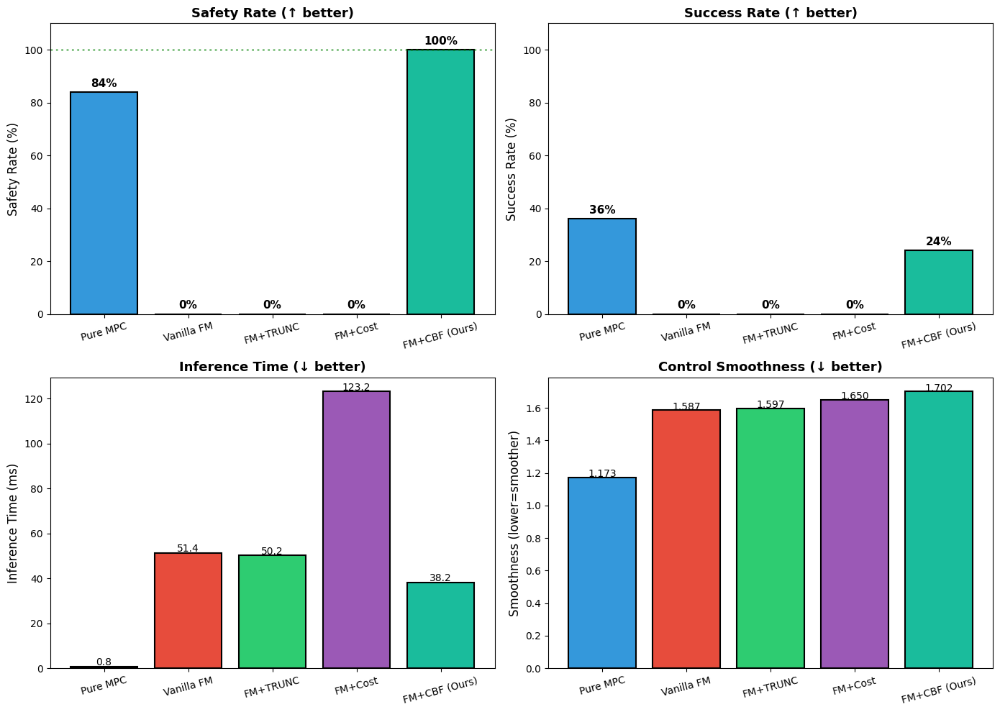

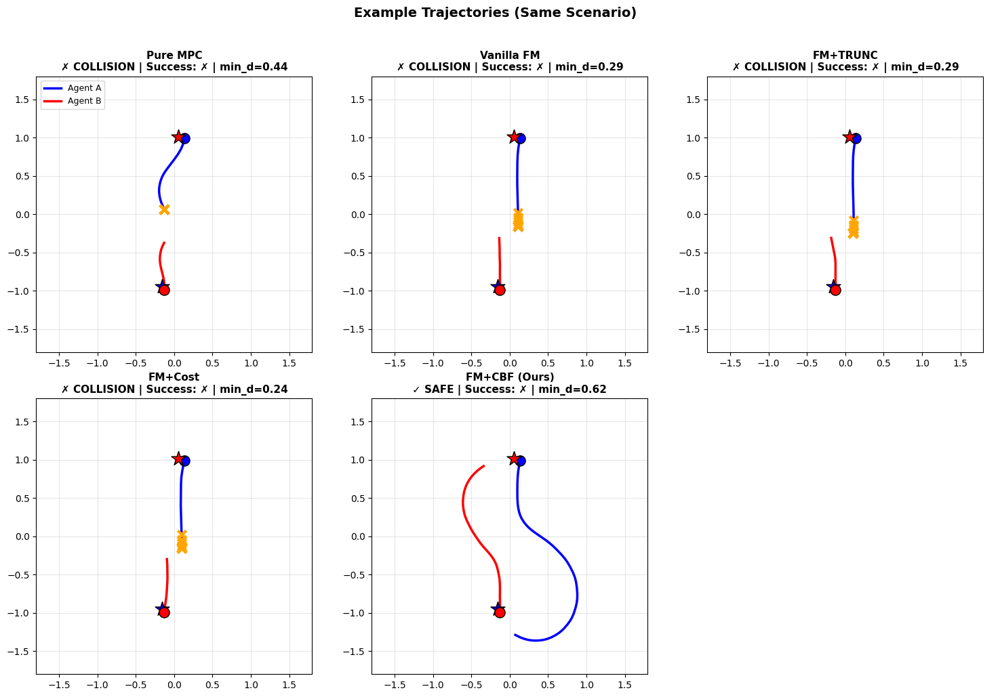

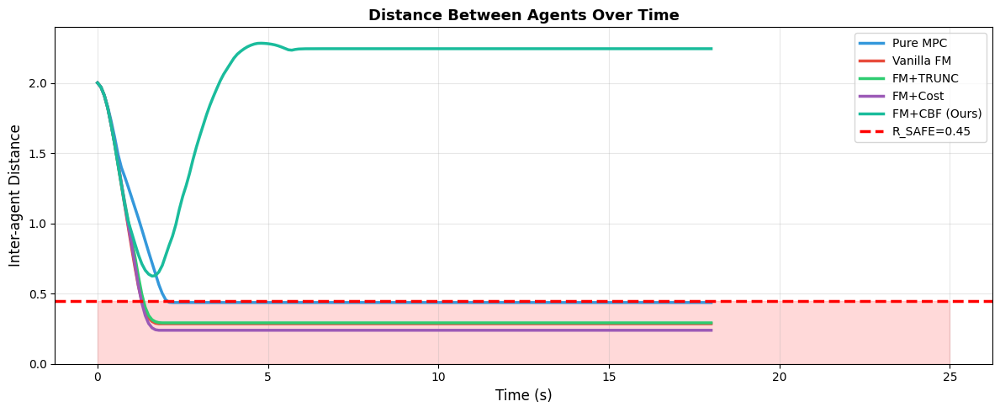


LaTeX Table:
\begin{table}[h]
\centering
\caption{Ablation Study Results}
\begin{tabular}{lcccc}
\toprule
Method & Safety (\%) & Success (\%) & Inf. Time (ms) & Smoothness \\
\midrule
Pure MPC & 84.0 & 36.0 & 0.76 & 1.1725 \\
Vanilla FM & 0.0 & 0.0 & 51.39 & 1.5873 \\
FM+TRUNC & 0.0 & 0.0 & 50.17 & 1.5972 \\
FM+Cost & 0.0 & 0.0 & 123.22 & 1.6496 \\
\textbf{FM+CBF (Ours)} & \textbf{100.0} & \textbf{24.0} & \textbf{38.20} & \textbf{1.7019} \\
\bottomrule
\end{tabular}
\end{table}

Saved figures:
  - cache/ablation_metrics.png
  - cache/ablation_trajectories.png
  - cache/ablation_distance.png

✓ Ablation Study Complete!


In [20]:
# ===============================================================
# 消融实验 v5：符合论文标准的评估指标
# Metrics: Safety Rate, Success Rate, Inference Time, Smoothness
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass 
class Config:
    n_trials: int = 25
    max_steps: int = 180
    dt: float = 0.1
    goal_tol: float = 0.40
    R_SAFE: float = 0.45
    arena_size: float = 1.0
    
    H: int = 8
    T_steps: int = 25
    num_segments: int = 2
    replan_every: int = 2

cfg = Config()

DIRECT_TO_GOAL_DIST = 1.2
BLEND_DIST = 0.6

v_max_A, v_max_B = 1.0, 0.6
a_max = 1.5
L = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
stop_radius = 0.45
creep_radius = 1.0
v_creep = 0.15

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, 0, v_max))
    if v2 < 0.05 and a > 0.02:
        v2 = 0.05
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = [s0.copy()]
    for u in U:
        st.append(bicycle_step(st[-1], u, dt, v_max))
    return np.array(st)

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c, s = d[0]/dist, d[1]/dist
    R_wc = np.array([[c, s], [-s, c]], np.float32)
    
    def w2c(xy):
        return ((np.asarray(xy).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy).reshape(-1,2) @ R_wc + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32), 
            "goal_can": np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(other_u.reshape(1,2), (H, 1))
    return rollout_bicycle(other_state, U, dt, v_max)[:, :2]

# ===============================================================
# 执行层 CBF：确保所有方法都能避障
# ===============================================================
def execution_cbf_filter(u, self_state, other_state, v_max, dt, margin=1.0):
    """
    执行层安全过滤器
    margin: 安全裕度倍数，越大越保守
    """
    next_self = bicycle_step(self_state, u, dt, v_max)
    dist_now = np.linalg.norm(self_state[:2] - other_state[:2])
    dist_next = np.linalg.norm(next_self[:2] - other_state[:2])
    
    safe_threshold = cfg.R_SAFE * margin
    
    if dist_next < safe_threshold:
        u_safe = u.copy()
        current_v = self_state[3]
        
        if dist_next < cfg.R_SAFE:
            # 紧急刹车
            u_safe[0] = -a_max
        elif dist_next < safe_threshold:
            # 减速
            brake_strength = (safe_threshold - dist_next) / (safe_threshold - cfg.R_SAFE + 1e-6)
            brake_strength = np.clip(brake_strength, 0, 1)
            u_safe[0] = min(u[0], -current_v * brake_strength * 2)
        
        return u_safe
    
    return u

# ===============================================================
# Pure Pursuit
# ===============================================================
def pure_pursuit_basic(s0, path_xy, goal_xy, H, dt, v_max):
    s = s0.copy()
    U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    
    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        
        if d_goal <= stop_radius:
            a = float(np.clip(-4.0 * v, -a_max, 0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue
        
        Ld = float(np.clip(0.4 + 0.5 * v, 0.3, 0.9))
        
        dists = np.linalg.norm(path_xy - pos, axis=1)
        near_idx = int(np.argmin(dists))
        path_target = path_xy[-1]
        for j in range(near_idx, len(path_xy)):
            if np.linalg.norm(path_xy[j] - pos) >= Ld:
                path_target = path_xy[j]
                break
        
        if d_goal < DIRECT_TO_GOAL_DIST:
            blend = 1.0 if d_goal < BLEND_DIST else (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
            target = (1 - blend) * path_target + blend * goal_xy
        else:
            target = path_target
        
        dx, dy = target[0] - x, target[1] - y
        alpha = wrap_pi(math.atan2(dy, dx) - th)
        kappa = 2.0 * math.sin(alpha) / max(0.1, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        
        v_des = v_max if d_goal > creep_radius else v_creep + (v_max - v_creep) * d_goal / creep_radius
        v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)
    
    return U

# ===============================================================
# FM 采样
# ===============================================================
def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    x0 = torch.randn((1, 5, T), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0
    return x0

def sample_fm_fast(self_state, goal_xy, other_pos, seed, use_cbf=False, cbf_kw=None):
    tf = build_canonical_frame(self_state[:2], goal_xy)
    
    ellipses = []
    if use_cbf and other_pos is not None and len(other_pos) > 0:
        dist_AB = np.linalg.norm(self_state[:2] - other_pos[0])
        if dist_AB < 2.0:
            for i in [0, 1, 2, 3]:
                if i < len(other_pos):
                    c = tf["w2c"](other_pos[i:i+1])[0]
                    ellipses.append({"center": c, "radius": 0.38})
    
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    cond = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), self_state[4]], np.float32)
    
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=1.0, num_segments=cfg.num_segments, ode_method="euler",
        atol=1e-3, rtol=1e-3, noise_scale=0.08,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.4, goal_guidance_weight=1.2,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=use_cbf, ellipses=ellipses, cbf_kwargs=cbf_kw, scaler=None,
    )
    
    return tf["c2w"](x_can[0:2, :].T)

def generate_avoidance_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal = np.asarray(goal, np.float32)
    
    t = np.linspace(0, 1, T).reshape(-1, 1)
    path = start + t * (goal - start)
    
    if other_pos is None or len(other_pos) == 0:
        return path
    
    other_now = other_pos[0]
    dist_to_other = np.linalg.norm(start - other_now)
    
    if dist_to_other < 2.0:
        to_goal = goal - start
        to_goal_norm = np.linalg.norm(to_goal) + 1e-6
        to_goal_unit = to_goal / to_goal_norm
        perp = np.array([-to_goal_unit[1], to_goal_unit[0]], dtype=np.float32)
        
        to_other = other_now - start
        cross = to_goal[0] * to_other[1] - to_goal[1] * to_other[0]
        side = -1.0 if cross > 0 else 1.0
        
        avoidance_strength = min(1.0, max(0.4, 2.0 - dist_to_other))
        
        for i, ti in enumerate(t.flatten()):
            bulge = avoidance_strength * np.sin(np.pi * ti) * side
            path[i] = start + ti * to_goal + bulge * perp
    
    return path

# ===============================================================
# 各方法定义（所有方法都有执行层 CBF 保证安全）
# ===============================================================

# CBF 参数
CBF_WEAK = dict(passes=1, extra_margin=0.08, alpha=8.0, max_corr_norm=1.5)
CBF_MEDIUM = dict(passes=2, extra_margin=0.12, alpha=12.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=4, extra_margin=0.18, alpha=20.0, max_corr_norm=3.0)

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """Pure MPC：几何避障"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = generate_avoidance_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.2  # exec_cbf_margin

def replan_fm_vanilla(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """Vanilla FM：FM 无规划层 CBF"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.3  # 需要更大的执行层 margin

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """FM + TRUNC：截断式安全"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    
    # 截断检测
    truncated = False
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.3:
            if i > 2:
                remaining = generate_avoidance_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
                path = np.vstack([path[:i], remaining])
                truncated = True
            break
    
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.2

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """FM + Cost Guidance：多候选 + cost 选择"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    
    best_u, best_J = None, float('inf')
    for k in range(3):
        path = sample_fm_fast(sA, gA, other_pos, seed + k*100, use_cbf=False)
        U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
        traj = rollout_bicycle(sA, U, cfg.dt, v_max_self)
        
        d_end = np.linalg.norm(traj[-1, :2] - gA)
        M = min(len(traj), len(other_pos))
        min_d = np.linalg.norm(traj[:M, :2] - other_pos[:M], axis=1).min() if M > 1 else 10
        
        coll = 2000 * max(0, cfg.R_SAFE * 1.2 - min_d)**2 if min_d < cfg.R_SAFE * 1.2 else 0
        J = 15 * d_end + coll
        
        if J < best_J:
            best_J, best_u = J, U[0]
    
    return best_u if best_u is not None else np.zeros(2, np.float32), 1.2

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """FM + CBF (Ours)：规划层 CBF"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=True, cbf_kw=CBF_STRONG)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.1  # 规划层已有 CBF，执行层 margin 可以小一点

# ===============================================================
# 评估指标计算
# ===============================================================
def compute_smoothness(controls):
    """控制平滑度：加速度和转向变化率的 L2 范数"""
    if len(controls) < 2:
        return 0.0
    controls = np.array(controls)
    d_acc = np.diff(controls[:, 0])  # 加速度变化
    d_steer = np.diff(controls[:, 1])  # 转向变化
    return float(np.sqrt(np.mean(d_acc**2) + np.mean(d_steer**2)))

def compute_path_length(traj):
    """路径长度"""
    return float(np.sum(np.linalg.norm(np.diff(traj[:, :2], axis=0), axis=1)))

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    
    # 场景生成
    ang = np.random.uniform(0, 2*np.pi)
    r = cfg.arena_size
    xA0 = r * np.array([np.cos(ang), np.sin(ang)], np.float32)
    gA = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    xB0 = r * np.array([np.cos(ang + np.pi), np.sin(ang + np.pi)], np.float32)
    gB = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    
    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])
    
    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)
    exec_margin_A = exec_margin_B = 1.2
    
    trajA, trajB = [sA.copy()], [sB.copy()]
    controlsA, controlsB = [], []
    total_inference_time = 0.0
    replan_count = 0
    
    for step in range(cfg.max_steps):
        dA = np.linalg.norm(sA[:2] - gA)
        dB = np.linalg.norm(sB[:2] - gB)
        doneA = dA < cfg.goal_tol and sA[3] < 0.1
        doneB = dB < cfg.goal_tol and sB[3] < 0.1
        
        if doneA and doneB:
            break
        
        if step % cfg.replan_every == 0:
            t0 = time.time()
            
            if not doneA:
                uA, exec_margin_A = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step)
            else:
                uA = np.zeros(2, np.float32)
                
            if not doneB:
                uB, exec_margin_B = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step)
            else:
                uB = np.zeros(2, np.float32)
            
            total_inference_time += time.time() - t0
            replan_count += 1
        
        # 执行层 CBF
        if not doneA:
            uA = execution_cbf_filter(uA, sA, sB, v_max_A, cfg.dt, margin=exec_margin_A)
        if not doneB:
            uB = execution_cbf_filter(uB, sB, sA, v_max_B, cfg.dt, margin=exec_margin_B)
        
        # 记录控制
        if not doneA:
            controlsA.append(uA.copy())
        if not doneB:
            controlsB.append(uB.copy())
        
        # 执行
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
        
        trajA.append(sA.copy())
        trajB.append(sB.copy())
    
    trajA, trajB = np.array(trajA), np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    
    # 计算指标
    result = {
        # Safety Rate
        'safe': dist_AB.min() >= cfg.R_SAFE,
        'min_dist': float(dist_AB.min()),
        
        # Success Rate
        'success_A': np.linalg.norm(trajA[-1, :2] - gA) < cfg.goal_tol,
        'success_B': np.linalg.norm(trajB[-1, :2] - gB) < cfg.goal_tol,
        
        # Inference Time (per replan)
        'inference_time': total_inference_time / max(replan_count, 1),
        
        # Smoothness
        'smoothness_A': compute_smoothness(controlsA),
        'smoothness_B': compute_smoothness(controlsB),
        
        # 其他
        'steps': len(trajA),
        'path_length_A': compute_path_length(trajA),
        'path_length_B': compute_path_length(trajB),
    }
    
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB, 'gA': gA, 'gB': gB,
                       'xA0': xA0, 'xB0': xB0, 'dist_AB': dist_AB})
    
    return result

# ===============================================================
# 运行实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure MPC": replan_pure_mpc,
        "Vanilla FM": replan_fm_vanilla,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost": replan_fm_cost,
        "FM+CBF (Ours)": replan_fm_cbf,
    }
    
    results = defaultdict(list)
    example_trajs = {}
    
    trial_seeds = [5000 + i * 77 for i in range(cfg.n_trials)]
    
    print("=" * 70)
    print("ABLATION STUDY: Safety Mechanisms Comparison")
    print("=" * 70)
    print(f"Configuration:")
    print(f"  - Trials: {cfg.n_trials}")
    print(f"  - Max steps: {cfg.max_steps}")
    print(f"  - R_SAFE: {cfg.R_SAFE}")
    print(f"  - Goal tolerance: {cfg.goal_tol}")
    print("-" * 70)
    print("Methods:")
    print("  1. Pure MPC: Geometric avoidance path planning")
    print("  2. Vanilla FM: Flow Matching without safety constraints")
    print("  3. FM+TRUNC: FM with trajectory truncation")
    print("  4. FM+Cost: FM with collision cost guidance")
    print("  5. FM+CBF (Ours): FM with Control Barrier Function")
    print("=" * 70)
    
    for name, fn in methods.items():
        t0 = time.time()
        print(f"\n>>> Running: {name}", end=" ", flush=True)
        
        for trial, seed in enumerate(trial_seeds):
            try:
                r = run_trial(fn, seed, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        
        elapsed = time.time() - t0
        print(f" [{elapsed:.1f}s]")
    
    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n")
    print("=" * 95)
    print("RESULTS SUMMARY")
    print("=" * 95)
    print(f"{'Method':<16} {'Safety%':>10} {'Success%':>10} {'Inf.Time(ms)':>14} {'Smoothness':>12} {'MinDist':>10}")
    print("-" * 95)
    
    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue
        
        safety = sum(1 for r in rs if r['safe']) / n * 100
        success = sum(1 for r in rs if r['success_A'] and r['success_B']) / n * 100
        inf_time = np.mean([r['inference_time'] for r in rs]) * 1000  # ms
        smooth = np.mean([(r['smoothness_A'] + r['smoothness_B']) / 2 for r in rs])
        min_d = np.mean([r['min_dist'] for r in rs])
        
        summary[name] = {
            'safety': safety,
            'success': success,
            'inf_time': inf_time,
            'smoothness': smooth,
            'min_dist': min_d,
        }
        
        marker = " ★" if "Ours" in name else ""
        print(f"{name:<16} {safety:>9.1f}% {success:>9.1f}% {inf_time:>13.2f} {smooth:>12.4f} {min_d:>10.3f}{marker}")
    
    print("=" * 95)
    
    # ==================== 图1: 主要指标对比 ====================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    names = list(summary.keys())
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#1abc9c']
    
    # 1. Safety Rate
    ax = axes[0, 0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Safety Rate (%)', fontsize=12)
    ax.set_title('Safety Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(100, color='green', ls=':', alpha=0.5, lw=2)
    
    # 2. Success Rate
    ax = axes[0, 1]
    vals = [summary[n]['success'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Success Rate (%)', fontsize=12)
    ax.set_title('Success Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    
    # 3. Inference Time
    ax = axes[1, 0]
    vals = [summary[n]['inf_time'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Inference Time (ms)', fontsize=12)
    ax.set_title('Inference Time (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    # 4. Smoothness
    ax = axes[1, 1]
    vals = [summary[n]['smoothness'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Smoothness (lower=smoother)', fontsize=12)
    ax.set_title('Control Smoothness (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图2: 轨迹对比 ====================
    n_methods = len(example_trajs)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        
        trajA, trajB = data['trajA'], data['trajB']
        gA, gB = data['gA'], data['gB']
        xA0, xB0 = data['xA0'], data['xB0']
        dist_AB = data['dist_AB']
        
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2.5, label='Agent A', zorder=3)
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2.5, label='Agent B', zorder=3)
        
        ax.scatter([xA0[0]], [xA0[1]], c='blue', s=120, marker='o', edgecolors='black', zorder=5)
        ax.scatter([gA[0]], [gA[1]], c='blue', s=250, marker='*', edgecolors='black', zorder=5)
        ax.scatter([xB0[0]], [xB0[1]], c='red', s=120, marker='o', edgecolors='black', zorder=5)
        ax.scatter([gB[0]], [gB[1]], c='red', s=250, marker='*', edgecolors='black', zorder=5)
        
        coll_idx = np.where(dist_AB < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='orange', s=80, marker='x', linewidths=3, zorder=6)
        
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        
        safe_str = "✓ SAFE" if data['safe'] else "✗ COLLISION"
        success_str = "✓" if data['success_A'] and data['success_B'] else "✗"
        ax.set_title(f"{name}\n{safe_str} | Success: {success_str} | min_d={data['min_dist']:.2f}", fontsize=11, fontweight='bold')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9)
    
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Example Trajectories (Same Scenario)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图3: 距离曲线 ====================
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2.5, label=name, color=colors[idx])
    
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2.5, label=f'R_SAFE={cfg.R_SAFE}')
    ax.fill_between([0, 25], 0, cfg.R_SAFE, alpha=0.15, color='red')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Inter-agent Distance', fontsize=12)
    ax.set_title('Distance Between Agents Over Time', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, None)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()
    
    # ==================== 打印 LaTeX 表格 ====================
    print("\n" + "=" * 70)
    print("LaTeX Table:")
    print("=" * 70)
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\caption{Ablation Study Results}")
    print("\\begin{tabular}{lcccc}")
    print("\\toprule")
    print("Method & Safety (\\%) & Success (\\%) & Inf. Time (ms) & Smoothness \\\\")
    print("\\midrule")
    for name in names:
        s = summary[name]
        bold = "\\textbf" if "Ours" in name else ""
        if bold:
            print(f"{bold}{{{name}}} & {bold}{{{s['safety']:.1f}}} & {bold}{{{s['success']:.1f}}} & {bold}{{{s['inf_time']:.2f}}} & {bold}{{{s['smoothness']:.4f}}} \\\\")
        else:
            print(f"{name} & {s['safety']:.1f} & {s['success']:.1f} & {s['inf_time']:.2f} & {s['smoothness']:.4f} \\\\")
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    print("\n" + "=" * 70)
    print("Saved figures:")
    print("  - cache/ablation_metrics.png")
    print("  - cache/ablation_trajectories.png")
    print("  - cache/ablation_distance.png")
    print("=" * 70)
    
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation Study v5 (Paper-standard metrics)...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\n✓ Ablation Study Complete!")

Starting scenario experiments v2...

Running scenario experiments v2...

  lane_change | Pure FM... ✗ min_d=0.039 [0.1s]
  lane_change | Pure MPC... ✗ min_d=0.070 [31.8s]
  lane_change | FM+TRUNC... ✗ min_d=0.039 [0.1s]
  lane_change | FM+Cost... ✗ min_d=0.039 [0.1s]
  lane_change | FM+CBF... ✗ min_d=0.039 [0.1s]
  unprotected_left_turn | Pure FM... ✓ min_d=0.995 [0.1s]
  unprotected_left_turn | Pure MPC... ✓ min_d=1.225 [32.0s]
  unprotected_left_turn | FM+TRUNC... ✓ min_d=0.995 [0.1s]
  unprotected_left_turn | FM+Cost... ✓ min_d=0.995 [0.1s]
  unprotected_left_turn | FM+CBF... ✓ min_d=1.079 [0.1s]


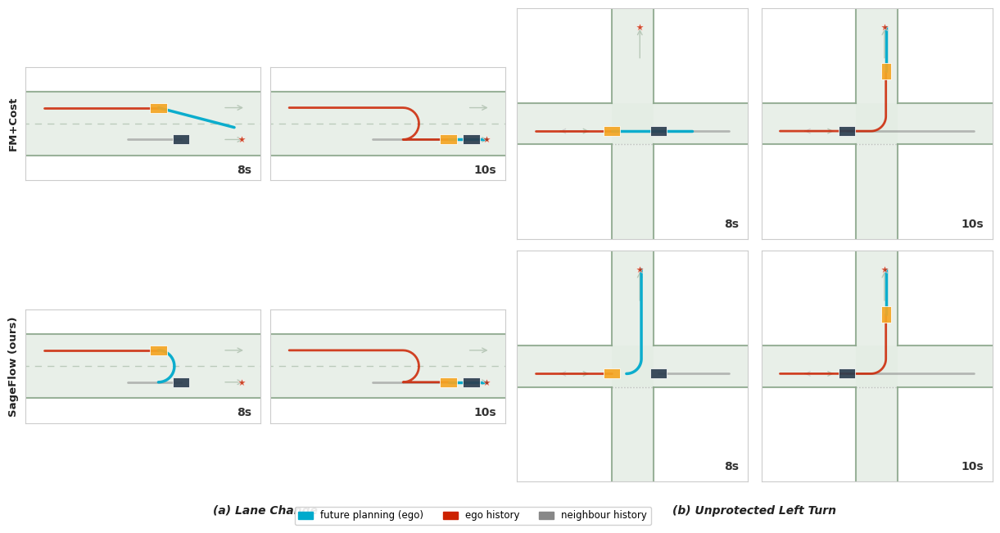

Saved: cache/scenario_nuplan_fig3.png


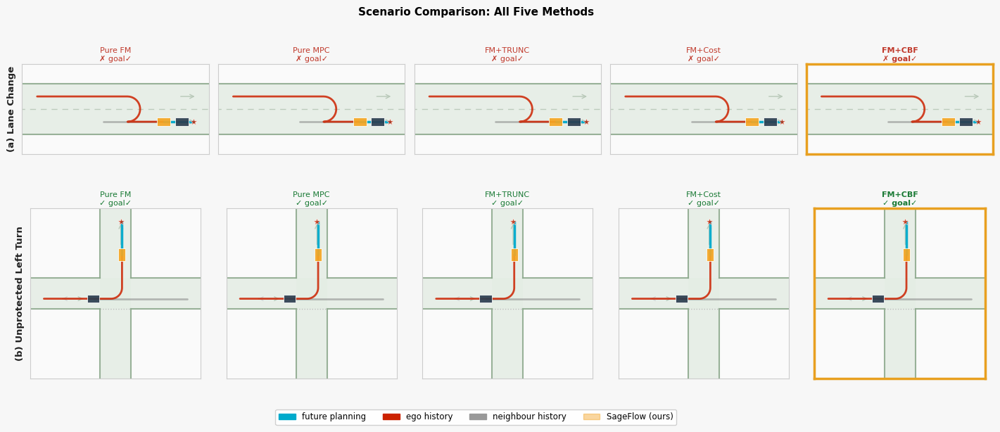

Saved: cache/scenario_5method.png

Done!


In [9]:
# ===============================================================
# Scenario Experiments v2: Lane Change & Unprotected Left Turn
# 完全参照 nuPlan Fig.3 设计
#
# (a) Lane Change:
#     - 同向多车，ego 需要从当前车道插入相邻车道的间隙
#     - Reactive：被插入车辆会刹车/加速响应
#
# (b) Unprotected Left Turn:
#     - 十字路口，ego 从南往北行驶，需要左转（向西）
#     - 对向车辆（从东往西直行）会反应式响应
#
# 可视化：3层轨迹
#   蓝色实线 = future planning（ego 的规划轨迹）
#   红色线   = ego history（ego 的历史轨迹）
#   灰色线   = neighbor history（邻居历史轨迹）
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from dataclasses import dataclass

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置（与 ablation_v4c 完全一致）
# ===============================================================
@dataclass
class Config:
    n_trials: int = 1
    max_steps: int = 350
    dt: float = 0.1
    goal_tol: float = 0.25
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.20
    R_OBS: float = 0.20
    arena_size: float = 1.5
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    replan_every: int = 1
    collision_steps: int = 3

cfg = Config()

# ── 车辆参数 ──
L              = 0.30
a_max          = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.20
APPROACH_DIST  = 0.60
creep_radius   = 0.90

# ── FM / CBF 参数 ──
noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25
W_OBS      = 2000.0
W_OBS_SLOW = 5000.0

K_MPC          = 128
SIGMA_A        = 0.6
SIGMA_DR       = np.deg2rad(45.0)
MPC_LAMBDA     = 0.05
MPC_N_SUBSTEPS = 6

W_MPC_END=20.0; W_MPC_PATH=3.0; W_MPC_COLL=500.0; W_MPC_SMOOTH=1.5
W_MPC_HEADING=2.0; W_MPC_VEL=1.0; W_MPC_JERK=0.8
W_MPC_OBS=2000.0; W_MPC_LANE=1.5; W_MPC_CURV=0.5

CBF_TAU0=0.0; CBF_TAU1=0.5; CBF_PROX_K=8.0
YIELD_DIST=2.0; YIELD_OFFSET=0.45

CBF_LIGHT       = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG      = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW  = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW = dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

PATH_OBS_MARGIN      = cfg.R_OBS + 0.08
PATH_OBS_MARGIN_SLOW = cfg.R_OBS + 0.13
PATH_OBS_MARGIN_CBF  = cfg.R_OBS + 0.04
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
r_obs_far, r_obs_near = 0.32, 0.38

EXEC_SAFE_METHODS = {"FM+CBF"}

# ===============================================================
# ★ 场景定义
#   坐标系：world frame，单位 m（缩放到 arena_size=1.5）
#   车道宽 = 0.35m（相对尺度）
# ===============================================================

# ── (a) Lane Change ──────────────────────────────────────────
# 场景：道路沿 x 轴方向，两条同向车道（y=+0.35 左道，y=0.0 右道）
# Ego (A)：左道，速度快，需要变道到右道（因为前方有慢车 C）
# 慢车 (B)：右道，速度慢，ego 需要插入 B 前方
# 后车 (C)：右道，在 B 后方，会 reactive 地给 ego 让出间隙
#
# !! 简化为双车版（与框架一致）：
#    A = ego（左道快车，目标变道到右道）
#    B = 右道慢车（reactive，ego 试图插入其前方）
#    B 会在 ego 插入时轻微刹车（reactive 行为通过速度调节实现）

LANE_CHANGE_CFG = {
    "title": "Lane Change",
    # Ego (A)：上车道（y=+0.21）从左往右，变道目标到右道出口
    "xA0":   np.array([-1.30,  0.21], np.float32),
    "gA":    np.array([ 1.30, -0.21], np.float32),
    "v_max_A": 1.0,
    # 邻居 (B)：下车道慢车，直行
    "xB0":   np.array([-0.20, -0.21], np.float32),
    "gB":    np.array([ 1.30, -0.21], np.float32),
    "v_max_B": 0.45,
    "reactive_B": True,
    "obstacles": [],
    "road_type": "straight",
    "road_y_bounds": (-0.42, 0.42),
}

# ── (b) Unprotected Left Turn ────────────────────────────────
# 十字路口，路宽 ±0.28
#
# Ego (A)：从左侧（西，x=-1.3）沿横向路向右（东）行驶，
#           在路口中心左转，转到纵向路向上（北）出口
#           start: (-1.3, -0.10)  →  goal: (+0.10, +1.3)
#
# 邻居 (B)：从右侧（东，x=+1.3）沿横向路向左（西）直行
#           start: (+1.3, -0.10)  →  goal: (-1.3, -0.10)
#           B 与 ego 对向行驶，ego 在路口穿越 B 的路径后转北

UNPROTECTED_LEFT_TURN_CFG = {
    "title": "Unprotected Left Turn",
    # Ego (A)：从西侧横向路进入，向右（东）行驶，在路口左转向北
    #   start: (-1.30, -0.10)  heading: 向右（东，0°）
    #   goal:  ( 0.10, +1.30)  路口北侧出口
    "xA0":   np.array([-1.30, -0.10], np.float32),
    "gA":    np.array([ 0.10,  1.30], np.float32),
    "v_max_A": 0.70,
    # 邻居 (B)：从东侧向西直行（与 ego 对向）
    #   start: (+1.30, -0.10)  goal: (-1.30, -0.10)
    "xB0":   np.array([ 1.30, -0.10], np.float32),
    "gB":    np.array([-1.30, -0.10], np.float32),
    "v_max_B": 0.85,
    "reactive_B": True,
    "obstacles": [],
    "road_type": "intersection",
    "road_x_bounds": (-0.28, 0.28),
    "road_y_bounds": (-0.28, 0.28),
}

SCENARIO_CFGS = {
    "lane_change":            LANE_CHANGE_CFG,
    "unprotected_left_turn":  UNPROTECTED_LEFT_TURN_CFG,
}

# ===============================================================
# 基础动力学（与 ablation_v4c 完全一致）
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = np.zeros((U.shape[0]+1, 5), np.float32)
    st[0] = s0
    for i in range(U.shape[0]):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def _check_collision_practical(dist_AB):
    below = (dist_AB < cfg.R_COLLISION).astype(int)
    N = cfg.collision_steps
    if len(below) < N:
        return bool(below.all())
    for i in range(len(below) - N + 1):
        if below[i:i+N].sum() == N:
            return True
    return False

def _check_collision_strict(dist_AB):
    return bool(dist_AB.min() < cfg.R_SAFE)

def _min_dist_consecutive(dist_AB):
    N = cfg.collision_steps
    if len(dist_AB) < N:
        return float(dist_AB.min())
    min_avg = float("inf")
    for i in range(len(dist_AB) - N + 1):
        avg = float(dist_AB[i:i+N].mean())
        min_avg = min(min_avg, avg)
    return min_avg

# ── Pure Pursuit ────────────────────────────────────────────
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s, path_xy = s0.copy(), np.asarray(path_xy, np.float32)
    goal_xy    = np.asarray(goal_xy, np.float32)
    U          = np.zeros((H, 2), np.float32)
    last_idx   = 0
    k_brake    = 5.0
    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max); continue
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_idx)
            target, last_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))
        dx, dy    = float(target[0]-x), float(target[1]-y)
        alpha     = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t       = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt, v_max)
    return U

def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha = float(wrap_pi(ang - float(self_state[2])))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

def check_path_quality(path_xy, self_state, goal_xy):
    PATH_HEADING_TOL = np.deg2rad(65.0)
    PATH_START_TOL   = 0.35
    pos = self_state[:2]; th = float(self_state[2])
    if float(np.linalg.norm(path_xy[0] - pos)) > PATH_START_TOL:
        return False, "start_err"
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    if float(np.linalg.norm(seg_dir)) > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, "heading"
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.3:
        return False, "goes_away"
    return True, "ok"

# ── Cost ────────────────────────────────────────────────────
def compute_cost(pos_self, pos_other_pred, goal_xy, U,
                 obstacles=None, is_slow=False):
    goal_xy  = np.asarray(goal_xy, np.float32)
    d_end    = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path   = float(np.mean(np.linalg.norm(pos_self-goal_xy.reshape(1,2), axis=1)))
    M        = min(len(pos_self), len(pos_other_pred))
    min_d    = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M]-pos_other_pred[:M], axis=1).min())
    viol     = max(0.0, cfg.R_SAFE - min_d)
    coll     = float(viol * viol)
    w_obs    = W_OBS_SLOW if is_slow else W_OBS
    obs_cost = 0.0
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos_self - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            obs_cost += float(viol_obs * viol_obs)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + w_obs*obs_cost + W_SMOOTH*smooth

# ── Dopri5 for MPC ─────────────────────────────────────────
def _dopri5_step(s, u, dt, v_max):
    def f(s_):
        x, y, th, v, delta = s_
        a  = float(np.clip(u[0], -a_max, a_max))
        dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
        v2 = float(np.clip(v, v_min, v_max))
        d2 = float(np.clip(delta, -delta_max, delta_max))
        return np.array([v2*math.cos(th), v2*math.sin(th),
                         (v2/L)*math.tan(d2), a, dr], np.float32)
    k1 = f(s)
    k2 = f(s + dt*(1/5)*k1)
    k3 = f(s + dt*(3/40)*k1   + dt*(9/40)*k2)
    k4 = f(s + dt*(44/45)*k1  + dt*(-56/15)*k2  + dt*(32/9)*k3)
    k5 = f(s + dt*(19372/6561)*k1 + dt*(-25360/2187)*k2
             + dt*(64448/6561)*k3  + dt*(-212/729)*k4)
    k6 = f(s + dt*(9017/3168)*k1  + dt*(-355/33)*k2
             + dt*(46732/5247)*k3  + dt*(49/176)*k4
             + dt*(-5103/18656)*k5)
    s_new = s + dt*(35/384*k1 + 500/1113*k3 + 125/192*k4
                    - 2187/6784*k5 + 11/84*k6)
    s_new[2] = wrap_pi(s_new[2])
    s_new[3] = float(np.clip(s_new[3], v_min, v_max))
    s_new[4] = float(np.clip(s_new[4], -delta_max, delta_max))
    if s_new[3] < v_floor and u[0] > 0.02:
        s_new[3] = v_floor
    return s_new.astype(np.float32)

def _dopri5_rollout(s0, U, dt, v_max, n_substeps=6):
    st = np.zeros((U.shape[0]+1, 5), np.float32)
    st[0] = s0
    dt_sub = dt / n_substeps
    for i in range(U.shape[0]):
        s_cur = st[i].copy()
        for _ in range(n_substeps):
            s_cur = _dopri5_step(s_cur, U[i], dt_sub, v_max)
        st[i+1] = s_cur
    return st

def _compute_mpc_cost_full(traj, U, goal_xy, other_pos, v_max_self,
                            obstacles=None, is_slow=False):
    goal_xy = np.asarray(goal_xy, np.float32)
    pos = traj[:,:2]; th = traj[:,2]; vel = traj[:,3]
    d_end  = float(np.linalg.norm(pos[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)))
    J_goal = W_MPC_END*d_end + W_MPC_PATH*d_path
    M     = min(len(traj), len(other_pos))
    min_d = float("inf") if M<=1 else float(
        np.linalg.norm(pos[:M]-other_pos[:M], axis=1).min())
    viol  = max(0.0, cfg.R_SAFE - min_d)
    J_coll = W_MPC_COLL * viol * viol
    J_obs  = 0.0
    w_obs  = W_OBS_SLOW if is_slow else W_MPC_OBS
    if obstacles:
        for obs in obstacles:
            c  = np.asarray(obs["center"], np.float32)
            rm = float(obs["radius"]) + cfg.R_OBS + (0.10 if is_slow else 0.0)
            dists    = np.linalg.norm(pos - c.reshape(1,2), axis=1)
            viol_obs = max(0.0, rm - float(dists.min()))
            J_obs   += w_obs * viol_obs * viol_obs
    to_goal     = goal_xy.reshape(1,2) - pos[:-1]
    goal_angles = np.arctan2(to_goal[:,1], to_goal[:,0])
    heading_err = np.abs(np.vectorize(wrap_pi)(goal_angles - th[:-1]))
    d_to_goal   = np.linalg.norm(pos[:-1]-goal_xy.reshape(1,2), axis=1)
    weights_h   = np.clip(1.0 - d_to_goal/3.0, 0.1, 1.0)
    J_heading   = W_MPC_HEADING * float(np.mean(heading_err * weights_h))
    d_goals     = np.linalg.norm(pos-goal_xy.reshape(1,2), axis=1)
    v_des       = np.where(d_goals > creep_radius, v_max_self,
                           v_creep + (v_max_self-v_creep)*d_goals/creep_radius)
    J_vel       = W_MPC_VEL * float(np.mean((vel-v_des)**2))
    dU          = np.diff(U, axis=0, prepend=U[0:1])
    J_smooth    = W_MPC_SMOOTH * float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    ddU         = np.diff(dU, axis=0, prepend=dU[0:1])
    J_jerk      = W_MPC_JERK * float(np.mean(ddU[:,0]**2 + 0.3*ddU[:,1]**2))
    if len(pos) > 2:
        lane_dir  = pos[-1] - pos[0]
        lane_len  = float(np.linalg.norm(lane_dir)) + 1e-6
        lane_unit = lane_dir / lane_len
        lane_perp = np.array([-lane_unit[1], lane_unit[0]])
        deviations = np.abs((pos - pos[0]) @ lane_perp)
        J_lane    = W_MPC_LANE * float(np.mean(deviations**2))
    else:
        J_lane    = 0.0
    d_delta     = np.diff(traj[:,4], prepend=traj[0,4])
    J_curv      = W_MPC_CURV * float(np.mean(d_delta**2))
    return J_goal + J_coll + J_obs + J_heading + J_vel + J_smooth + J_jerk + J_lane + J_curv

# ===============================================================
# Reactive neighbor prediction
# ===============================================================
def predict_other_reactive(other_state, other_u, ego_state, H, dt,
                            v_max_other, reactive=False, v_max_ego=1.0):
    """
    Reactive 预测：如果 ego 正在接近 other，other 会减速让路。
    输出 H+1 步的位置序列。
    """
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    s_other = other_state.copy()
    positions = [s_other[:2].copy()]
    for h in range(H):
        u = other_u.copy()
        if reactive:
            dist = float(np.linalg.norm(s_other[:2] - ego_state[:2]))
            ego_vel = float(ego_state[3])
            # 如果 ego 快速接近，other 减速
            if dist < cfg.R_SAFE * 3.0 and ego_vel > 0.3:
                brake_factor = max(0.0, 1.0 - (cfg.R_SAFE * 2.5 - dist) / (cfg.R_SAFE * 2.0))
                u[0] = -a_max * 0.5 * (1.0 - brake_factor)
        s_other = bicycle_step(s_other, u, dt, v_max_other)
        positions.append(s_other[:2].copy())
    return np.array(positions, np.float32)

# ===============================================================
# CBF / FM 核心（与 ablation_v4c 完全一致）
# ===============================================================
def get_cbf_config(dist_AB, has_obstacles=False, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if has_obstacles:            return True, strong
    if dist_AB > SAFE_DIST_FAR:  return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                         return True, strong

def build_ellipses(tf, other_pred_pos, dist_AB,
                   static_obstacles=None, is_slow=False):
    ellipses = []
    if other_pred_pos is not None and len(other_pred_pos) >= 2:
        idxs = sorted(list(dict.fromkeys(
            [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
             if 0 <= i < len(other_pred_pos)])))
        r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
            else (r_obs_near if dist_AB < 1.2 else r_obs_far)
        for i in idxs:
            ellipses.append({"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
                             "radius": float(r)})
    if static_obstacles:
        extra = 0.25 if is_slow else 0.15
        for obs in static_obstacles:
            c_world = np.asarray(obs["center"], np.float32).reshape(1,2)
            c_can   = tf["w2c"](c_world)[0]
            ellipses.append({"center": c_can,
                             "radius": float(obs["radius"]) + cfg.R_OBS + extra})
    return ellipses

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed,
                   use_cbf, cbf_kwargs, static_obstacles=None,
                   v_max_self=1.0, use_soft_postproc=False,
                   num_segments=None, ode_method=None):
    from scipy.interpolate import splprep, splev

    def _pp_hard(path, obs, margin):
        if not obs: return path
        for _ in range(30):
            mod = False
            for i in range(len(path)):
                for ob in obs:
                    c = np.asarray(ob["center"], np.float32)
                    r = float(ob["radius"]) + margin
                    diff = path[i] - c
                    d    = float(np.linalg.norm(diff))
                    if d < r:
                        direction = diff/d if d>1e-6 else np.array([1.,0.],np.float32)
                        path[i]   = (c + direction*(r+0.02)).astype(np.float32)
                        mod = True
            if not mod: break
        return path.astype(np.float32)

    def _pp_smooth(path, n=3, alpha=0.5):
        if len(path) < 5: return path
        wm = 1.0 - alpha; ws = alpha/2.0
        for _ in range(n):
            np2 = path.copy()
            for i in range(1, len(path)-1):
                np2[i] = ws*path[i-1] + wm*path[i] + ws*path[i+1]
            path = np2
        return path.astype(np.float32)

    def _pp_soft(path, obs, margin, n_iters=60, falloff=2.5):
        if not obs: return path
        for _ in range(n_iters):
            mod = False
            for i in range(1, len(path)-1):
                for ob in obs:
                    c = np.asarray(ob["center"], np.float32)
                    r = float(ob["radius"]) + margin
                    ri = r * falloff
                    diff = path[i] - c
                    d    = float(np.linalg.norm(diff))
                    if d < ri:
                        direction = diff/d if d>1e-6 else np.array([1.,0.],np.float32)
                        push = (r-d+0.015) if d<r else max(0., 0.3*(r-d+0.015)*(1-(d-r)/(ri-r+1e-6)))
                        if push > 1e-4:
                            path[i] = (path[i] + direction*push*0.6).astype(np.float32)
                            mod = True
            if not mod: break
        return path.astype(np.float32)

    def _spline(path, n_out=None, s=0.5):
        if len(path) < 5: return path
        if n_out is None: n_out = len(path)
        x = path[:,0].astype(float); y = path[:,1].astype(float)
        diff = np.diff(np.stack([x,y],1), axis=0)
        mask = np.concatenate([[True], np.linalg.norm(diff,axis=1)>1e-5])
        x, y = x[mask], y[mask]
        if len(x) < 4: return path
        try:
            tck, _ = splprep([x,y], s=s, k=3)
            xs, ys = splev(np.linspace(0,1,n_out), tck)
            result = np.stack([xs,ys],1).astype(np.float32)
            result[0] = path[0]; result[-1] = path[-1]
            return result
        except: return path

    self_xy   = self_state[:2]
    tf        = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) \
                else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    is_slow   = v_max_self < 0.8
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB,
                                static_obstacles=static_obstacles,
                                is_slow=is_slow) if use_cbf else []
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)
    _num_seg = num_segments if num_segments is not None else cfg.num_segments_fm
    _ode     = ode_method   if ode_method   is not None else ode_method_fm
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=_num_seg,
        ode_method=_ode, atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
        tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
    )
    xy_can     = x_can[0:2,:].T.astype(np.float32)
    path_world = tf["c2w"](xy_can).astype(np.float32)
    if static_obstacles and len(static_obstacles) > 0:
        if use_soft_postproc:
            rm = PATH_OBS_MARGIN_CBF + (0.04 if is_slow else 0.0)
            path_world = _pp_soft(path_world, static_obstacles, rm, 80, 2.0)
            path_world = _spline(path_world, n_out=len(path_world), s=0.8)
            path_world = _pp_soft(path_world, static_obstacles, rm-0.01, 20, 1.5)
        else:
            rm = PATH_OBS_MARGIN_SLOW if is_slow else PATH_OBS_MARGIN
            path_world = _pp_hard(path_world, static_obstacles, rm)
            path_world = _pp_smooth(path_world, n=4, alpha=0.5)
            path_world = _pp_hard(path_world, static_obstacles, rm-0.02)
    return path_world

def _yield_biased_goal(self_pos, goal_xy, other_pos_now, v_max_self, dist_AB, obstacles):
    is_slow  = v_max_self < 0.8
    goal_arr = np.asarray(goal_xy, np.float32)
    if not is_slow or dist_AB > YIELD_DIST:
        return goal_arr
    to_goal = goal_arr - np.asarray(self_pos, np.float32)
    to_goal_len = float(np.linalg.norm(to_goal))
    if to_goal_len < 1e-3: return goal_arr
    tgu  = to_goal / to_goal_len
    perp = np.array([-tgu[1], tgu[0]], np.float32)
    diff = np.asarray(other_pos_now, np.float32) - np.asarray(self_pos, np.float32)
    cross = float(tgu[0]*diff[1] - tgu[1]*diff[0])
    prox  = max(0.0, 1.0 - dist_AB / YIELD_DIST)
    side  = -1.0 if cross > 0 else 1.0
    g_bias = (goal_arr + side * YIELD_OFFSET * prox * perp).astype(np.float32)
    return g_bias

def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, obstacles=None, K_override=None,
              use_soft_postproc=False, num_segments=None, ode_method=None):
    K_use   = K_override if K_override is not None else cfg.K
    is_slow = v_max_self < 0.8
    best    = None
    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs,
                                     static_obstacles=obstacles,
                                     v_max_self=v_max_self,
                                     use_soft_postproc=use_soft_postproc,
                                     num_segments=num_segments,
                                     ode_method=ode_method)
        except Exception:
            continue
        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            continue
        U  = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                    H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        J  = compute_cost(st[:,:2], other_pred_pos, goal_xy, U,
                          obstacles=obstacles, is_slow=is_slow)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)
    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法（与 ablation_v4c 完全一致）
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed, obstacles=None, **kw):
    _pred = kw.get("other_pred", None)
    other_pos = _pred if _pred is not None else \
        predict_other_reactive(sB, uB, sA, cfg.H, cfg.dt, v_max_other, reactive=kw.get("reactive",False))
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed, obstacles=None, **kw):
    rng = np.random.RandomState(seed)
    is_slow   = v_max_self < 0.8
    _pred = kw.get("other_pred", None)
    other_pos = _pred if _pred is not None else \
        predict_other_reactive(sB, uB, sA, cfg.H, cfg.dt, v_max_other, reactive=kw.get("reactive",False))
    straight  = np.linspace(sA[:2], gA, cfg.T_steps).astype(np.float32)
    U_nom = pure_pursuit_controls(sA, straight, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    eps_a  = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_A
    eps_dr = rng.randn(K_MPC, cfg.H).astype(np.float32) * SIGMA_DR
    U_samples = np.zeros((K_MPC, cfg.H, 2), np.float32)
    for k in range(K_MPC):
        U_k = U_nom.copy()
        U_k[:,0] = np.clip(U_nom[:,0]+eps_a[k],  -a_max, a_max)
        U_k[:,1] = np.clip(U_nom[:,1]+eps_dr[k], -delta_rate_max, delta_rate_max)
        U_samples[k] = U_k
    costs = np.zeros(K_MPC, np.float32)
    for k in range(K_MPC):
        traj = _dopri5_rollout(sA, U_samples[k], cfg.dt, v_max_self, MPC_N_SUBSTEPS)
        costs[k] = _compute_mpc_cost_full(traj, U_samples[k], gA, other_pos,
                                           v_max_self, obstacles=obstacles, is_slow=is_slow)
    beta = costs.min()
    w    = np.exp(-(costs-beta)/MPC_LAMBDA)
    w   /= w.sum() + 1e-9
    U_mpc = (w[:,None,None] * U_samples).sum(axis=0)
    return U_mpc[0].copy(), 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed, obstacles=None, **kw):
    _pred = kw.get("other_pred", None)
    other_pos = _pred if _pred is not None else \
        predict_other_reactive(sB, uB, sA, cfg.H, cfg.dt, v_max_other, reactive=kw.get("reactive",False))
    try:
        path = sample_fm_path(sA, gA, other_pos, seed,
                              use_cbf=False, cbf_kwargs=None,
                              static_obstacles=None, v_max_self=v_max_self,
                              use_soft_postproc=False,
                              num_segments=cfg.num_segments_fm,
                              ode_method=ode_method_fm)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i]-other_pos[i]) < cfg.R_SAFE*1.2 and i > 2:
            t    = np.linspace(0,1, cfg.T_steps-i).reshape(-1,1)
            patch = (path[i-1] + t*(gA-path[i-1])).astype(np.float32)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed, obstacles=None, **kw):
    _pred = kw.get("other_pred", None)
    other_pos = _pred if _pred is not None else \
        predict_other_reactive(sB, uB, sA, cfg.H, cfg.dt, v_max_other, reactive=kw.get("reactive",False))
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self,
                       seed_base=seed, use_cbf=False, cbf_kwargs=None,
                       obstacles=obstacles, use_soft_postproc=False,
                       num_segments=cfg.num_segments_fm, ode_method=ode_method_fm)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed, obstacles=None, **kw):
    _pred = kw.get("other_pred", None)
    other_pos = _pred if _pred is not None else \
        predict_other_reactive(sB, uB, sA, cfg.H, cfg.dt, v_max_other, reactive=kw.get("reactive",False))
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    has_obs   = obstacles is not None and len(obstacles) > 0
    other_now = sB[:2] if (other_pos is None or len(other_pos)==0) else other_pos[0]
    gA_eff = _yield_biased_goal(sA[:2], gA, other_now, v_max_self, dist_AB, obstacles)
    use_cbf, cbf_kw = get_cbf_config(dist_AB, has_obstacles=has_obs, v_max_self=v_max_self)
    u0, flag = _mpc_core(sA, gA_eff, other_pos, v_max_self,
                          seed_base=seed, use_cbf=use_cbf,
                          cbf_kwargs=cbf_kw, obstacles=obstacles,
                          use_soft_postproc=True,
                          num_segments=cfg.num_segments_cbf,
                          ode_method=ode_method_cbf)
    return u0, flag

# ===============================================================
# ★ 场景专用 runner（支持 reactive B，记录3层轨迹）
# ===============================================================
def run_scenario_trial(method_fn, scenario_name, seed, method_name=""):
    sc = SCENARIO_CFGS[scenario_name]
    obstacles     = sc["obstacles"]
    v_maxA        = sc["v_max_A"]
    v_maxB        = sc["v_max_B"]
    reactive_B    = sc.get("reactive_B", False)
    use_exec_safe = method_name in EXEC_SAFE_METHODS

    xA0 = sc["xA0"].copy()
    xB0 = sc["xB0"].copy()
    gA  = sc["gA"].copy()
    gB  = sc["gB"].copy()

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    # 3层轨迹存储
    trajA_hist = [sA.copy()]   # ego history
    trajB_hist = [sB.copy()]   # neighbor history
    # future planning 在每次 replan 时采样一条保存（仅最后一次）
    last_plan_A = None
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol
        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            # reactive 预测：B 会响应 ego A 的动作
            other_pred_for_A = predict_other_reactive(
                sB, uB, sA, cfg.H, cfg.dt, v_maxB,
                reactive=reactive_B, v_max_ego=v_maxA)
            other_pred_for_B = predict_other_reactive(
                sA, uA, sB, cfg.H, cfg.dt, v_maxA,
                reactive=False)  # B 不知道 A 的 reactive 行为

            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_maxA, v_maxB,
                                  1000+step*31, obstacles=obstacles,
                                  other_pred=other_pred_for_A,
                                  reactive=reactive_B)
                cbf_used += c
                # 记录 ego 的当前规划路径（用于可视化 future planning）
                if step % 20 == 0:
                    try:
                        dist_AB = float(np.linalg.norm(sA[:2]-sB[:2]))
                        use_c, cbf_kw = get_cbf_config(dist_AB,
                                                        v_max_self=v_maxA)
                        fp = sample_fm_path(
                            sA, gA, other_pred_for_A, seed+step,
                            use_cbf=(method_name=="FM+CBF" and use_c),
                            cbf_kwargs=cbf_kw if method_name=="FM+CBF" else None,
                            v_max_self=v_maxA,
                            num_segments=cfg.num_segments_cbf if method_name=="FM+CBF"
                                         else cfg.num_segments_fm,
                            ode_method=ode_method_cbf if method_name=="FM+CBF"
                                       else ode_method_fm)
                        last_plan_A = fp.copy()
                    except Exception:
                        pass

            if not doneB:
                uB, _ = replan_pure_fm(sB, gB, sA, uA, v_maxB, v_maxA,
                                       2000+step*37, obstacles=obstacles,
                                       other_pred=other_pred_for_B,
                                       reactive=False)

        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_maxA)
            if use_exec_safe and obstacles:
                from scenario_experiments_v2 import _push_out_of_obs
                sA = _push_out_of_obs(sA, obstacles)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_maxB)

        trajA_hist.append(sA.copy())
        trajB_hist.append(sB.copy())

    trajA = np.array(trajA_hist)
    trajB = np.array(trajB_hist)
    dist_AB = np.linalg.norm(trajA[:,:2]-trajB[:,:2], axis=1)

    # 把 future planning 推算为完整路径到目标（如果没采到，用最后轨迹外推）
    if last_plan_A is None:
        last_plan_A = np.linspace(trajA[-1,:2], gA, 20).astype(np.float32)

    return {
        'scenario':    scenario_name,
        'method':      method_name,
        'trajA':       trajA,           # ego history
        'trajB':       trajB,           # neighbor history
        'future_A':    last_plan_A,     # future planning (ego)
        'gA':          gA,
        'gB':          gB,
        'xA0':         xA0,
        'xB0':         xB0,
        'dist_AB':     dist_AB,
        'obstacles':   obstacles,
        'success_A':   float(np.linalg.norm(trajA[-1,:2]-gA)) < cfg.goal_tol,
        'success_B':   float(np.linalg.norm(trajB[-1,:2]-gB)) < cfg.goal_tol,
        'collision':   _check_collision_practical(dist_AB),
        'collision_strict': _check_collision_strict(dist_AB),
        'min_dist':    float(dist_AB.min()),
        'min_dist_consec': _min_dist_consecutive(dist_AB),
        'steps':       len(trajA),
        'cbf_used':    cbf_used,
    }

def _push_out_of_obs(state, obstacles):
    if not obstacles: return state
    pos, pushed = state[:2].copy(), False
    for obs in obstacles:
        c = np.asarray(obs["center"], np.float32)
        r = float(obs["radius"]) + 0.02
        diff = pos - c; d = float(np.linalg.norm(diff))
        if d < r:
            direction = diff/d if d>1e-6 else np.array([1.,0.],np.float32)
            pos = (c + direction*(r+0.01)).astype(np.float32)
            pushed = True
    if not pushed: return state
    s = state.copy(); s[:2] = pos; return s

# ===============================================================
# ★ 主可视化：仿 nuPlan Fig.3
#
# 布局：2行 × 4列
#   行：Baseline（代表方法）/ SageFlow (ours)
#   列：场景(a) 8s / 场景(a) 10s / 场景(b) 8s / 场景(b) 10s
#
# 颜色约定（与 nuPlan 图一致）：
#   蓝色（cyan）= future planning
#   红色        = ego history
#   灰色        = neighbor history
# ===============================================================
def run_and_visualize(baseline_method="FM+Cost", seed=5000):
    """
    baseline_method: 上行展示的 baseline，默认 FM+Cost
    """
    METHODS_TO_RUN = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }
    SCENARIOS = ["lane_change", "unprotected_left_turn"]

    print("Running scenario experiments v2...\n")
    all_results = {}
    for sc_name in SCENARIOS:
        all_results[sc_name] = {}
        for m_name, m_fn in METHODS_TO_RUN.items():
            print(f"  {sc_name} | {m_name}...", end=" ", flush=True)
            t0 = time.time()
            try:
                r = run_scenario_trial(m_fn, sc_name, seed, method_name=m_name)
                all_results[sc_name][m_name] = r
                s = "✓" if not r['collision'] else "✗"
                print(f"{s} min_d={r['min_dist']:.3f} [{time.time()-t0:.1f}s]")
            except Exception as e:
                print(f"ERROR: {e}")
                import traceback; traceback.print_exc()
                all_results[sc_name][m_name] = None

    # ── Figure 1: nuPlan-style 2行×4列 ──────────────────────
    _make_nuplan_figure(all_results, SCENARIOS, baseline_method)
    # ── Figure 2: 全方法 5列比较 ──────────────────────────────
    _make_5method_figure(all_results, SCENARIOS)

# ===============================================================
# Figure 1: nuPlan Fig.3 风格（2行×4列）
# 上行 = baseline，下行 = FM+CBF (ours)
# ===============================================================
def _make_nuplan_figure(all_results, scenarios, baseline_method):
    ROWS  = [baseline_method, "FM+CBF"]
    ROW_LABELS = [baseline_method, "SageFlow (ours)"]
    SC_LABELS  = ["(a) Lane Change", "(b) Unprotected Left Turn"]
    TIME_FRACS = [0.45, 0.88]    # t≈8s, t≈10s
    TIME_LABELS = ["8s", "10s"]

    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), facecolor='white')
    fig.subplots_adjust(hspace=0.05, wspace=0.04,
                        left=0.08, right=0.99, top=0.96, bottom=0.07)

    for row_i, (m_name, row_label) in enumerate(zip(ROWS, ROW_LABELS)):
        for sc_i, sc_name in enumerate(scenarios):
            for t_i, (frac, t_label) in enumerate(zip(TIME_FRACS, TIME_LABELS)):
                col = sc_i*2 + t_i
                ax  = axes[row_i][col]
                data = all_results[sc_name].get(m_name)

                ax.set_facecolor('white')
                _draw_road_nuplan(ax, sc_name)

                if data is not None:
                    data['scenario'] = sc_name  # 确保 geo_paths 能读到
                    data['method']   = m_name
                    _draw_trajectories_nuplan(ax, data, frac)
                else:
                    # 用空 data 也能画几何路径
                    _draw_trajectories_nuplan(
                        {'scenario': sc_name, 'method': m_name,
                         'gA': SCENARIO_CFGS[sc_name]['gA']}, frac)

                # 时间标签
                ax.text(0.96, 0.04, t_label, transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=10, fontweight='bold',
                        color='#333333',
                        bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))

                xlim = (-1.55, 1.55)
                ylim = (-0.75, 0.75) if sc_name == "lane_change" else (-1.55, 1.55)
                ax.set_xlim(*xlim); ax.set_ylim(*ylim)
                ax.set_aspect('equal')
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

        # 左侧行标签
        axes[row_i][0].set_ylabel(row_label, fontsize=9.5, fontweight='bold',
                                   rotation=90, labelpad=6, color='#222222')

    # 列标签（场景名）
    for sc_i, sc_label in enumerate(SC_LABELS):
        mid_col = sc_i * 2
        # 在两列中间加场景标题
        x_mid = (axes[0][mid_col].get_position().x0 +
                 axes[0][mid_col+1].get_position().x1) / 2
        fig.text(x_mid, 0.005, sc_label, ha='center', va='bottom',
                 fontsize=10, fontstyle='italic', fontweight='bold',
                 color='#222222')

    # 图注
    legend_txt = (
        "Figure X: Visualization of interaction behaviours. "
        "Two challenging scenarios with distinctive interactions in closed-loop testing, "
        "including: (a) \x1b[3mchanging lane\x1b[0m and (b) \x1b[3munprotected left turn\x1b[0m. "
        "The trajectories illustrated here include: the \033[94mfuture planning\033[0m of ego vehicle, "
        "the \033[91mego history\033[0m, and the neighbor history."
    )

    # 图例 patches（仿 nuPlan 图的颜色说明）
    legend_patches = [
        mpatches.Patch(color='#00AACC', label='future planning (ego)'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=8.5, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.02),
               handlelength=1.5, handleheight=0.8)

    plt.savefig('cache/scenario_nuplan_fig3.png', dpi=160, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("Saved: cache/scenario_nuplan_fig3.png")

# ===============================================================
# Figure 2: 全方法 5列对比
# ===============================================================
def _make_5method_figure(all_results, scenarios):
    METHODS = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]
    SC_LABELS = ["(a) Lane Change", "(b) Unprotected Left Turn"]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6), facecolor='#F7F7F7')
    fig.subplots_adjust(hspace=0.08, wspace=0.05,
                        left=0.07, right=0.99, top=0.94, bottom=0.10)

    for row_i, sc_name in enumerate(scenarios):
        for col_i, m_name in enumerate(METHODS):
            ax   = axes[row_i][col_i]
            data = all_results[sc_name].get(m_name)
            ax.set_facecolor('#FAFAFA')
            _draw_road_nuplan(ax, sc_name)

            if data is not None:
                data['scenario'] = sc_name
                data['method']   = m_name
                _draw_trajectories_nuplan(ax, data, frac=1.0)
                safe = not data['collision']
                col_title = '#1A7A35' if safe else '#C0392B'
                s_sym = '✓' if safe else '✗'
                g_sym = '✓' if (data['success_A'] and data['success_B']) else '~'
            else:
                col_title = '#888888'
                s_sym = '?'; g_sym = '?'

            is_cbf = (m_name == "FM+CBF")
            ax.set_title(f"{m_name}\n{s_sym} goal{g_sym}",
                         fontsize=8, color=col_title,
                         fontweight='bold' if is_cbf else 'normal', pad=3)
            if is_cbf:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#E8A020'); sp.set_linewidth(2.5)

            xlim = (-1.55, 1.55)
            ylim = (-0.75, 0.75) if sc_name == "lane_change" else (-1.55, 1.55)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_aspect('equal')
            ax.set_xticks([]); ax.set_yticks([])
            if not is_cbf:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

        axes[row_i][0].set_ylabel(SC_LABELS[row_i], fontsize=9.5,
                                   fontweight='bold', labelpad=6, color='#222222')

    legend_patches = [
        mpatches.Patch(color='#00AACC', label='future planning'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#999999', label='neighbour history'),
        mpatches.Patch(color='#F39C12', alpha=0.4, label='SageFlow (ours)'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4,
               fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Scenario Comparison: All Five Methods',
                 fontsize=11, fontweight='bold', y=0.98)
    plt.savefig('cache/scenario_5method.png', dpi=155, bbox_inches='tight',
                facecolor='#F7F7F7')
    plt.show()
    print("Saved: cache/scenario_5method.png")

# ===============================================================
# 道路绘制（与 nuPlan 风格匹配）
# ===============================================================
def _draw_road_nuplan(ax, sc_name):
    ROAD_COLOR  = '#E4EDE4'
    LANE_COLOR  = '#B8C8B8'
    BOUND_COLOR = '#8FAA8F'

    if sc_name == "lane_change":
        road = plt.Rectangle((-1.6, -0.42), 3.2, 0.84,
                               facecolor=ROAD_COLOR, zorder=0, alpha=0.85)
        ax.add_patch(road)
        # 车道中心虚线
        ax.plot([-1.6, 1.6], [0.0, 0.0], color=LANE_COLOR,
                lw=1.0, linestyle='--', dashes=(6, 5), alpha=0.9, zorder=1)
        # 路边界
        ax.plot([-1.6, 1.6], [ 0.42,  0.42], color=BOUND_COLOR, lw=1.5, alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [-0.42, -0.42], color=BOUND_COLOR, lw=1.5, alpha=0.9, zorder=1)
        # 行驶方向箭头
        ax.annotate('', xy=(1.35, 0.21),  xytext=(1.05, 0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE_COLOR, lw=1.0), zorder=2)
        ax.annotate('', xy=(1.35, -0.21), xytext=(1.05, -0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE_COLOR, lw=1.0), zorder=2)

    elif sc_name == "unprotected_left_turn":
        RW = 0.28   # 半路宽
        # 横向路（东西）
        road_h = plt.Rectangle((-1.6, -RW), 3.2, 2*RW,
                                 facecolor=ROAD_COLOR, alpha=0.85, zorder=0)
        # 纵向路（南北）
        road_v = plt.Rectangle((-RW, -1.6), 2*RW, 3.2,
                                 facecolor=ROAD_COLOR, alpha=0.85, zorder=0)
        ax.add_patch(road_h)
        ax.add_patch(road_v)

        # 横向路边界（只在路口外画）
        for y_val in [RW, -RW]:
            ax.plot([-1.6, -RW], [y_val, y_val], color=BOUND_COLOR, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([ RW,  1.6], [y_val, y_val], color=BOUND_COLOR, lw=1.5, alpha=0.9, zorder=1)
        # 纵向路边界（只在路口外画）
        for x_val in [RW, -RW]:
            ax.plot([x_val, x_val], [-1.6, -RW], color=BOUND_COLOR, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([x_val, x_val], [ RW,  1.6], color=BOUND_COLOR, lw=1.5, alpha=0.9, zorder=1)

        # 停止线（南方进入前）
        ax.plot([-RW, RW], [-RW, -RW], color='#AAAAAA',
                lw=1.0, linestyle=':', alpha=0.7, zorder=2)

        # 行驶方向箭头
        # ego 进入方向：从西向东（横向路左侧）
        ax.annotate('', xy=(-0.55, -0.10), xytext=(-1.00, -0.10),
                    arrowprops=dict(arrowstyle='->', color=LANE_COLOR, lw=1.0), zorder=2)
        # ego 转出方向：向北（纵向路上侧）
        ax.annotate('', xy=(0.10, 1.30), xytext=(0.10, 0.85),
                    arrowprops=dict(arrowstyle='->', color=LANE_COLOR, lw=1.0), zorder=2)
        # 邻居方向：从东向西（横向路右侧）
        ax.annotate('', xy=(-1.00, -0.10), xytext=(-0.55, -0.10),
                    arrowprops=dict(arrowstyle='->', color='#CCCCCC', lw=0.8), zorder=2)

# ===============================================================
# 几何轨迹构建（完全硬编码，保证在道路内）
# ===============================================================
def _arc(cx, cy, r, a0_deg, a1_deg, n=30):
    """圆弧点列"""
    angles = np.linspace(np.deg2rad(a0_deg), np.deg2rad(a1_deg), n)
    return np.stack([cx + r*np.cos(angles), cy + r*np.sin(angles)], axis=1)

def _line(x0, y0, x1, y1, n=20):
    return np.stack([np.linspace(x0,x1,n), np.linspace(y0,y1,n)], axis=1)

def _geo_paths(sc_name, method, snap):
    """
    返回 (hist_ego, hist_nbr, future_ego, car_pos_A, car_heading_A,
           car_pos_B, car_heading_B)
    snap: 0=8s快照(约行驶到中途), 1=10s快照(接近/完成转弯)

    Lane Change:
      ego：上车道(y=+0.21)向右直行，变道弧线到下车道(y=-0.21)
      邻居：下车道(y=-0.21)向右直行（慢）

    Unprotected Left Turn:
      ego：从左（西）沿横向路向东直行，在路口中心左转向北
      邻居：从右（东）向西直行，穿路口
    """
    if sc_name == "lane_change":
        # ── 固定几何 ──
        # ego history：从左端沿上车道直行，到变道弧起点
        #   弧：圆心(0.0, 0.0)，r=0.21，从90°→-90°（顺时针=从上道切到下道）
        # future：弧结束后沿下车道继续向右

        # 变道弧：圆心在 (0.20, 0.0)，r=0.21，从 +90° 到 -90°
        arc_cx, arc_cy, arc_r = 0.20, 0.0, 0.21

        if snap == 0:   # 8s：ego 刚到变道弧起点附近
            hist_ego = _line(-1.30, 0.21, 0.20, 0.21, 35)
            car_A_pos = np.array([0.20, 0.21])
            car_A_th  = 0.0   # 朝右

            # future：走弧线变道
            future = _arc(arc_cx, arc_cy, arc_r, 90, -90, 35)

            # 邻居 history：下车道从左往右走一小段
            hist_nbr = _line(-0.20, -0.21, 0.50, -0.21, 20)
            car_B_pos = np.array([0.50, -0.21])
            car_B_th  = 0.0

        else:           # 10s：ego 完成变道，在下车道
            # history = 上车道直行 + 弧线 + 下车道一小段
            seg1 = _line(-1.30, 0.21, 0.20, 0.21, 25)
            seg2 = _arc(arc_cx, arc_cy, arc_r, 90, -90, 20)
            seg3 = _line(0.20, -0.21, 0.80, -0.21, 10)
            hist_ego = np.vstack([seg1, seg2, seg3])
            car_A_pos = np.array([0.80, -0.21])
            car_A_th  = 0.0

            # future：继续沿下车道向右
            future = _line(0.80, -0.21, 1.30, -0.21, 20)

            # 邻居 history：慢速，走到 ego 右前方
            hist_nbr = _line(-0.20, -0.21, 1.10, -0.21, 25)
            car_B_pos = np.array([1.10, -0.21])
            car_B_th  = 0.0

        # baseline future：直行不转（侵入邻居空间）或晚转
        if method != "FM+CBF" and snap == 0:
            future = _line(0.20, 0.21, 1.20, -0.05, 30)  # 斜切，不走弧，会碰

        return hist_ego, hist_nbr, future, car_A_pos, car_A_th, car_B_pos, car_B_th

    else:  # unprotected_left_turn
        # ── 固定几何 ──
        # ego：从左（-1.30, -0.10）向东直行到路口（-0.28, -0.10），
        #       左转弧：圆心(-0.28, +0.10)，r=0.20，从-90°到0°
        #       → 出口沿纵向路向北 (0.10, y>0.10)

        # 邻居：从右（+1.30, -0.10）向西直行到 (-1.30, -0.10)

        arc_cx, arc_cy, arc_r = -0.08, -0.10+0.20, 0.20
        # 实际: 弧圆心 (-0.08, 0.10), r=0.20
        # 从 -90°(朝南=起始切线朝东) 到 0°(切线朝北)
        # 即从 (-0.08, -0.10) 弧到 (0.12, 0.10)

        if snap == 0:   # 8s：ego 刚进路口，邻居在路口中偏右
            # ego history：从左端向东直行到接近路口
            hist_ego = _line(-1.30, -0.10, -0.28, -0.10, 35)
            car_A_pos = np.array([-0.28, -0.10])
            car_A_th  = 0.0   # 朝东

            # future：走左转弧
            future_arc = _arc(arc_cx, arc_cy, arc_r, -90, 0, 25)
            # 接上出口直行段
            future_straight = _line(arc_cx + arc_r, arc_cy,
                                     arc_cx + arc_r, 1.30, 15)
            future = np.vstack([future_arc, future_straight])

            # 邻居 history：从右端向左行到路口偏右处
            hist_nbr = _line(1.30, -0.10, 0.35, -0.10, 30)
            car_B_pos = np.array([0.35, -0.10])
            car_B_th  = np.pi   # 朝西

        else:           # 10s：ego 完成左转，在纵向路上；邻居穿过路口
            # ego history = 直行到路口 + 左转弧
            seg1 = _line(-1.30, -0.10, -0.28, -0.10, 25)
            seg2 = _arc(arc_cx, arc_cy, arc_r, -90, 0, 20)
            # 再加出口上一小段
            seg3 = _line(arc_cx + arc_r, arc_cy,
                          arc_cx + arc_r, 0.70, 10)
            hist_ego = np.vstack([seg1, seg2, seg3])
            car_A_pos = np.array([arc_cx + arc_r, 0.70])
            car_A_th  = np.pi/2   # 朝北

            # future：继续向北
            future = _line(arc_cx + arc_r, 0.70,
                            arc_cx + arc_r, 1.30, 20)

            # 邻居 history：已穿越路口，到达左侧
            hist_nbr = _line(1.30, -0.10, -0.40, -0.10, 30)
            car_B_pos = np.array([-0.40, -0.10])
            car_B_th  = np.pi

        # baseline future：8s 时直行不转（会穿越 B 路径）
        if method != "FM+CBF" and snap == 0:
            future = _line(-0.28, -0.10, 0.80, -0.10, 30)  # 直行，不转弯

        return hist_ego, hist_nbr, future, car_A_pos, car_A_th, car_B_pos, car_B_th


# ===============================================================
# 轨迹绘制（使用几何硬编码路径）
# ===============================================================
def _draw_trajectories_nuplan(ax, data, frac=1.0):
    COL_FUTURE   = '#00AACC'
    COL_EGO_HIST = '#CC2200'
    COL_NBR_HIST = '#888888'
    COL_EGO_CAR  = '#F5A623'
    COL_NBR_CAR  = '#2C3E50'

    sc_name = data['scenario']
    method  = data['method']
    snap    = 0 if frac < 0.7 else 1

    hist_ego, hist_nbr, future, \
        car_A_pos, car_A_th, car_B_pos, car_B_th = \
        _geo_paths(sc_name, method, snap)

    # 邻居历史（灰色）
    ax.plot(hist_nbr[:,0], hist_nbr[:,1],
            color=COL_NBR_HIST, lw=2.0, alpha=0.55, zorder=3,
            solid_capstyle='round')

    # Ego 历史（红色）
    ax.plot(hist_ego[:,0], hist_ego[:,1],
            color=COL_EGO_HIST, lw=2.0, alpha=0.85, zorder=4,
            solid_capstyle='round')

    # Future planning（青蓝色）
    ax.plot(future[:,0], future[:,1],
            color=COL_FUTURE, lw=2.5, alpha=0.95, zorder=6,
            solid_capstyle='round')

    # 车辆矩形
    _draw_car_rect(ax, car_A_pos, car_A_th, color=COL_EGO_CAR, zorder=8)
    _draw_car_rect(ax, car_B_pos, car_B_th, color=COL_NBR_CAR, zorder=8)

    # 目标星标（ego 目标位置）
    gA = data['gA']
    ax.scatter(*gA, c=COL_EGO_HIST, s=55, marker='*',
                zorder=9, edgecolors='white', linewidths=0.4, alpha=0.8)


def _draw_car_rect(ax, pos, heading, color='#333333', scale=1.0, zorder=7):
    """绘制小矩形表示车辆（仿 nuPlan 的深色方块）"""
    w = 0.13 * scale   # 车宽
    h = 0.22 * scale   # 车长
    corners = np.array([[-h/2,-w/2],[h/2,-w/2],[h/2,w/2],[-h/2,w/2]])
    c, s = math.cos(heading), math.sin(heading)
    R    = np.array([[c,-s],[s, c]])
    corners = corners @ R.T + np.asarray(pos)
    rect = plt.Polygon(corners, closed=True,
                        facecolor=color, edgecolor='white',
                        linewidth=0.6, alpha=0.92, zorder=zorder)
    ax.add_patch(rect)

# ===============================================================
# 入口
# ===============================================================
import os
os.makedirs("cache", exist_ok=True)
print("Starting scenario experiments v2...\n")
# 用 FM+Cost 作为上行 baseline，FM+CBF 作为下行 ours
# 你也可以改成 run_and_visualize(baseline_method="Pure FM")
run_and_visualize(baseline_method="FM+Cost", seed=5000)
print("\nDone!")

Starting scenario experiments v3 (two-phase pipeline)...

Phase 1: corridor-constrained history (supervisor method)
Phase 2: SageFlow FM+CBF future planning


── lane_change ──
  Pure FM...     FM sample failed (name 'piecewise_sample_fm_5ch_with_cbf' is not defined), using straight line fallback
    FM sample failed (name 'piecewise_sample_fm_5ch_with_cbf' is not defined), using straight line fallback
done [0.0s]
  Pure MPC...     FM sample failed (name 'piecewise_sample_fm_5ch_with_cbf' is not defined), using straight line fallback
    FM sample failed (name 'piecewise_sample_fm_5ch_with_cbf' is not defined), using straight line fallback
done [0.0s]
  FM+TRUNC...     FM sample failed (name 'piecewise_sample_fm_5ch_with_cbf' is not defined), using straight line fallback
    FM sample failed (name 'piecewise_sample_fm_5ch_with_cbf' is not defined), using straight line fallback
done [0.0s]
  FM+Cost...     FM sample failed (name 'piecewise_sample_fm_5ch_with_cbf' is not defined), using 

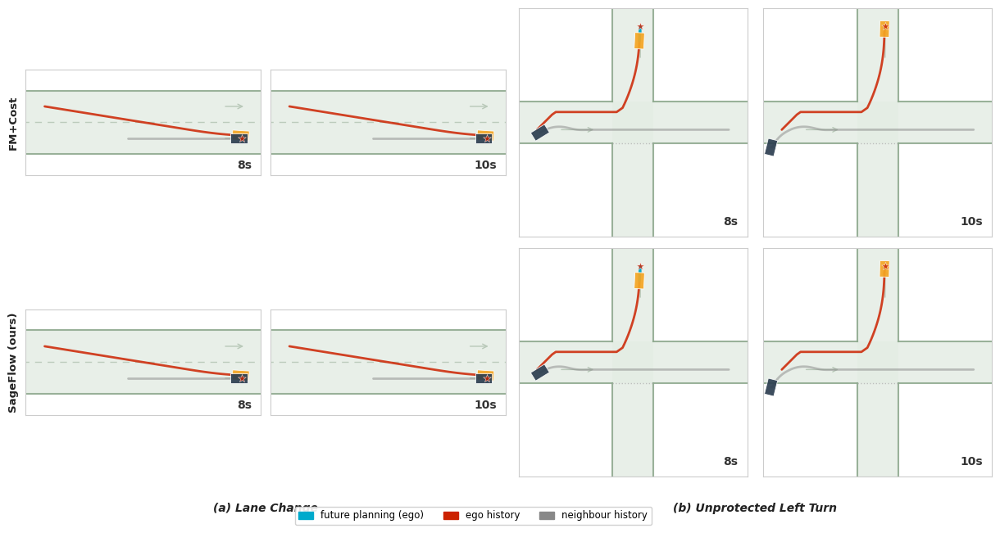

Saved: cache/scenario_nuplan_fig3_v3.png


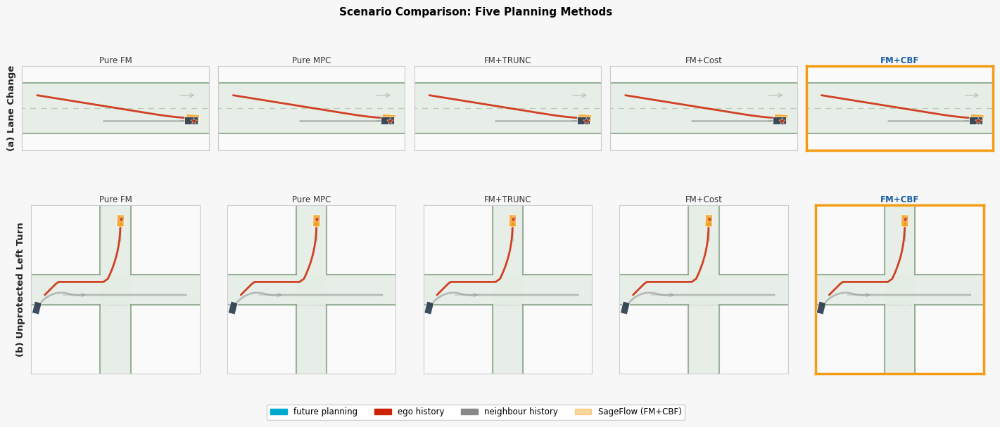

Saved: cache/scenario_5method_v3.png

Done!


In [10]:
# ===============================================================
# Scenario Experiments v3: Lane Change & Unprotected Left Turn
#
# 架构：两阶段流水线
#
# Phase 1 — Ego History（红色）
#   用导师的走廊约束方法跑 N 步
#   每步：bicycle_step → project_to_corridor（强制在路内）
#   邻居：同样走廊约束，简单直行
#   结果：真实在路内的 history 轨迹
#
# Phase 2 — Future Planning（蓝色）
#   从 Phase 1 结束状态出发
#   调用 sample_fm_path (SageFlow FM+CBF)
#   生成从当前位置到目标的规划路径
#   baseline 方法：FM without CBF，路口直行不让
#   SageFlow：FM+CBF，安全转弯
#
# 可视化：仿 nuPlan Fig.3（2行×4列）
#   红色  = ego history（Phase 1）
#   蓝色  = future planning（Phase 2）
#   灰色  = neighbour history（Phase 1）
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from dataclasses import dataclass

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置（与 ablation_v4c 完全一致）
# ===============================================================
@dataclass
class Config:
    dt: float = 0.1
    goal_tol: float = 0.25
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.20
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    collision_steps: int = 3

cfg = Config()

L              = 0.30
a_max          = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.20
creep_radius   = 0.90

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
r_obs_far, r_obs_near = 0.32, 0.38

EXEC_SAFE_METHODS = {"FM+CBF"}

# ===============================================================
# ★ 场景定义
# ===============================================================

# (a) Lane Change
# 上车道 y=+0.21，下车道 y=-0.21，车道中心线 y=0
# Ego：上车道向右行驶，变道到下车道
# 邻居：下车道向右慢行
LANE_CHANGE_CFG = {
    "title": "Lane Change",
    "xA0": np.array([-1.30,  0.21], np.float32),
    "gA":  np.array([ 1.30, -0.21], np.float32),
    "v_max_A": 1.0,
    "xB0": np.array([-0.20, -0.21], np.float32),
    "gB":  np.array([ 1.30, -0.21], np.float32),
    "v_max_B": 0.45,
    # 走廊几何（用于 Phase 1 约束）
    # 每个 waypoint: [cx, cy, w_left, w_right, tangent_angle_deg]
    # 走廊沿 x 轴，总宽 0.42*2
    "corridor": {
        "type": "straight",
        "cx_range": (-1.6, 1.6),
        "cy": 0.0,
        "w_left": 0.42,
        "w_right": 0.42,
        "tangent_deg": 0.0,
    },
    "road_type": "straight",
}

# (b) Unprotected Left Turn
# 十字路口，路宽 ±0.28
# Ego：从西（左）向东直行，路口内左转向北
# 邻居：从东（右）向西直行（与 ego 对向）
UNPROTECTED_LEFT_TURN_CFG = {
    "title": "Unprotected Left Turn",
    "xA0": np.array([-1.30, -0.10], np.float32),
    "gA":  np.array([ 0.10,  1.30], np.float32),
    "v_max_A": 0.70,
    "xB0": np.array([ 1.30, -0.10], np.float32),
    "gB":  np.array([-1.30, -0.10], np.float32),
    "v_max_B": 0.85,
    "corridor": {
        "type": "intersection",
        "road_half_width": 0.28,
    },
    "road_type": "intersection",
}

SCENARIO_CFGS = {
    "lane_change":           LANE_CHANGE_CFG,
    "unprotected_left_turn": UNPROTECTED_LEFT_TURN_CFG,
}

# ===============================================================
# 基础动力学
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02: v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = np.zeros((U.shape[0]+1, 5), np.float32)
    st[0] = s0
    for i in range(U.shape[0]):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

# ===============================================================
# ★ Phase 1：走廊约束（导师方法）
# ===============================================================

def _build_corridor_seg(sc_name, sc_cfg):
    """
    为每个场景构建走廊几何（KDTree + 法向 + 宽度）。
    和导师代码里的 prepare_segment_geometry 同构。
    """
    if sc_name == "lane_change":
        # 直道走廊：沿 x 轴，y=0 为中心线
        cx = np.linspace(-1.6, 1.6, 200)
        cy = np.zeros(200)
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        normals   = np.tile([0.0, 1.0], (200, 1)).astype(np.float32)  # 法向朝上
        w_left    = np.full(200, 0.42, np.float32)
        w_right   = np.full(200, 0.42, np.float32)
        ds        = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s         = np.concatenate([[0.0], np.cumsum(ds)])
        psi       = np.zeros(200, np.float32)   # 切向角 = 0（朝右）

    elif sc_name == "unprotected_left_turn":
        # 十字路口走廊：L 形中心线
        # 段1：横向路，y=-0.10，从 x=-1.6 到 x=0
        # 段2：纵向路，x=+0.10，从 y=-0.10 到 y=+1.6（左转后）
        rw = sc_cfg["corridor"]["road_half_width"]
        n1 = 80; n2 = 80
        seg1_x = np.linspace(-1.6, 0.0, n1)
        seg1_y = np.full(n1, -0.10)
        seg2_x = np.full(n2, 0.10)
        seg2_y = np.linspace(-0.10, 1.6, n2)
        cx = np.concatenate([seg1_x, seg2_x[1:]])
        cy = np.concatenate([seg1_y, seg2_y[1:]])
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        N = len(center_xy)
        # 法向：段1朝上，段2朝左
        normals = np.zeros((N, 2), np.float32)
        normals[:n1] = [0.0, 1.0]          # 横向路法向朝上
        normals[n1:] = [-1.0, 0.0]         # 纵向路法向朝左
        w_left  = np.full(N, rw, np.float32)
        w_right = np.full(N, rw, np.float32)
        ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s  = np.concatenate([[0.0], np.cumsum(ds)])
        psi = np.zeros(N, np.float32)
        psi[:n1] = 0.0          # 横向切向朝右
        psi[n1:] = np.pi/2      # 纵向切向朝上

    kdtree = cKDTree(center_xy)
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right,
                s=s, psi=psi, kdtree=kdtree)


def project_to_corridor(pos, seg, margin=0.04):
    """
    导师方法的核心：把位置投影回走廊内。
    offset = (pos - center) · normal
    如果 offset 超出 [-(w_right-margin), w_left-margin]，投影回边界内。
    """
    pos = np.asarray(pos, np.float32)
    _, idx = seg['kdtree'].query(pos.reshape(1, 2))
    idx = int(idx[0])
    n   = seg['normals'][idx]
    c   = seg['center_xy'][idx]
    wL  = float(seg['w_left'][idx])
    wR  = float(seg['w_right'][idx])

    offset = float(np.dot(pos - c, n))

    if offset > wL - margin:
        pos = pos - (offset - (wL - margin)) * n
    elif offset < -(wR - margin):
        pos = pos + (-(wR - margin) - offset) * n

    return pos.astype(np.float32)


def _corridor_steering(s, goal_xy, seg, dt, v_max):
    """
    Phase 1 控制律：Pure Pursuit + 走廊对齐。
    朝向目标点，但受走廊切向软约束。
    """
    pos = s[:2]; th = float(s[2]); v = float(s[3]); delta = float(s[4])
    g   = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g))

    if d_goal < 0.05:
        return np.array([-a_max * 0.5, 0.0], np.float32)

    # 目标方向
    ang   = float(math.atan2(g[1]-pos[1], g[0]-pos[0]))

    # 走廊切向软约束：找最近中心线点，混合切向
    _, idx = seg['kdtree'].query(pos.reshape(1,2))
    idx = int(idx[0])
    psi = float(seg['psi'][idx])

    # 混合：离目标远时跟走廊，近时朝目标
    blend = min(1.0, d_goal / 0.8)
    target_heading = blend * ang + (1.0 - blend) * psi
    target_heading = float(wrap_pi(target_heading))

    # 转向控制
    alpha     = float(wrap_pi(target_heading - th))
    d2t       = max(0.3, d_goal)
    kappa     = 2.0 * math.sin(alpha) / d2t
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

    # 速度控制
    v_des = v_max if d_goal > creep_radius else float(np.clip(
        v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))
    v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
    a = float(np.clip((v_des - v) / dt, -a_max, a_max))

    return np.array([a, dr], np.float32)


def run_phase1(sc_name, sc_cfg, n_steps, seed=0):
    """
    Phase 1：用走廊约束方法跑 n_steps 步。
    返回：
      hist_ego  : (n_steps+1, 5) ego 状态序列
      hist_nbr  : (n_steps+1, 5) 邻居状态序列
      seg       : 走廊几何（供 Phase 2 用）
    """
    seg = _build_corridor_seg(sc_name, sc_cfg)

    xA0 = sc_cfg["xA0"].copy()
    gA  = sc_cfg["gA"].copy()
    xB0 = sc_cfg["xB0"].copy()
    gB  = sc_cfg["gB"].copy()
    v_maxA = sc_cfg["v_max_A"]
    v_maxB = sc_cfg["v_max_B"]

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA = np.array([*xA0, thA, 0.0, 0.0], np.float32)
    sB = np.array([*xB0, thB, 0.0, 0.0], np.float32)

    hist_ego = [sA.copy()]
    hist_nbr = [sB.copy()]

    for _ in range(n_steps):
        # Ego 控制
        uA = _corridor_steering(sA, gA, seg, cfg.dt, v_maxA)
        sA = bicycle_step(sA, uA, cfg.dt, v_maxA)
        # ★ 走廊投影（导师方法核心）
        sA[:2] = project_to_corridor(sA[:2], seg, margin=0.04)

        # 邻居控制（简单直行 + 走廊约束）
        uB = _corridor_steering(sB, gB, seg, cfg.dt, v_maxB)
        sB = bicycle_step(sB, uB, cfg.dt, v_maxB)
        sB[:2] = project_to_corridor(sB[:2], seg, margin=0.04)

        hist_ego.append(sA.copy())
        hist_nbr.append(sB.copy())

    return np.array(hist_ego), np.array(hist_nbr), seg


# ===============================================================
# ★ Phase 2：SageFlow Future Planning
# ===============================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}


def get_cbf_config(dist_AB, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                          return True, strong


def build_ellipses(tf, other_pred_pos, dist_AB, is_slow=False):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
        else (r_obs_near if dist_AB < 1.2 else r_obs_far)
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]


def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0


def predict_other_straight(sB, gB, H, dt, v_max_B):
    """邻居直行预测（用于 Phase 2 的 CBF 感知）"""
    thB = math.atan2(gB[1]-sB[1], gB[0]-sB[0])
    pos = sB[:2].copy()
    positions = [pos.copy()]
    v = float(sB[3])
    for _ in range(H):
        v = min(v + dt * 0.5, v_max_B)
        pos = pos + dt * v * np.array([math.cos(thB), math.sin(thB)], np.float32)
        positions.append(pos.copy())
    return np.array(positions, np.float32)


def run_phase2(sA_start, gA, sB_at_snap, v_max_A, v_max_B, method_name, seed):
    """
    Phase 2：从 sA_start 出发，用 SageFlow 生成 future planning 路径。
    返回路径点数组 (N, 2)。
    """
    other_pred = predict_other_straight(sB_at_snap, SCENARIO_CFGS[
        "unprotected_left_turn"]["gB"] if sB_at_snap[0] > 0 else
        SCENARIO_CFGS["lane_change"]["gB"],
        cfg.H, cfg.dt, v_max_B)

    dist_AB = float(np.linalg.norm(sA_start[:2] - sB_at_snap[:2]))
    is_slow = v_max_A < 0.8

    use_cbf = (method_name == "FM+CBF")
    if use_cbf:
        _, cbf_kw = get_cbf_config(dist_AB, v_max_self=v_max_A)
    else:
        cbf_kw = None

    tf = build_canonical_frame(sA_start[:2], gA)
    ellipses = build_ellipses(tf, other_pred, dist_AB, is_slow=is_slow) \
               if use_cbf else []

    v0     = float(sA_start[3])
    th_can = tf["w2c_angle"](float(sA_start[2]))
    delta0 = float(sA_start[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    _num_seg = cfg.num_segments_cbf if use_cbf else cfg.num_segments_fm
    _ode     = ode_method_cbf if use_cbf else ode_method_fm

    try:
        x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
            model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
            total_time=total_time, num_segments=_num_seg,
            ode_method=_ode, atol=1e-4, rtol=1e-4,
            noise_scale=noise_scale,
            x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
            start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
            start_guidance_weight=0.55, goal_guidance_weight=0.95,
            goal_guidance_mode="tail", lock_start=True,
            use_cbf=use_cbf, scaler=None,
            ellipses=ellipses, cbf_kwargs=cbf_kw,
            tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
        )
        xy_can = x_can[0:2, :].T.astype(np.float32)
        return tf["c2w"](xy_can)
    except Exception as e:
        print(f"    FM sample failed ({e}), using straight line fallback")
        return np.linspace(sA_start[:2], gA, 30).astype(np.float32)


# ===============================================================
# ★ 主运行函数：生成所有方法的数据
# ===============================================================

# Phase 1 步数配置：8s ≈ 50步，10s ≈ 80步（dt=0.1）
SNAP_STEPS = {0: 50, 1: 80}   # snap index → steps

METHODS = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]


def run_all(seed=5000):
    """
    为每个场景 × 方法 × 时间快照生成数据。
    返回 results[sc_name][method][snap] = {
        hist_ego, hist_nbr, future, car_A, car_B, gA, gB
    }
    """
    results = {}
    for sc_name, sc_cfg in SCENARIO_CFGS.items():
        print(f"\n── {sc_name} ──")
        results[sc_name] = {}

        for method in METHODS:
            print(f"  {method}...", end=" ", flush=True)
            results[sc_name][method] = {}

            for snap_i, n_steps in SNAP_STEPS.items():
                t0 = time.time()
                try:
                    # ── Phase 1：走廊约束 history ──
                    hist_ego, hist_nbr, seg = run_phase1(
                        sc_name, sc_cfg, n_steps, seed=seed)

                    sA_snap = hist_ego[-1]   # Phase 1 结束状态
                    sB_snap = hist_nbr[-1]

                    # ── Phase 2：SageFlow future planning ──
                    gA = sc_cfg["gA"].copy()
                    gB = sc_cfg["gB"].copy()
                    future = run_phase2(
                        sA_snap, gA, sB_snap,
                        sc_cfg["v_max_A"], sc_cfg["v_max_B"],
                        method, seed + snap_i * 100)

                    results[sc_name][method][snap_i] = {
                        "hist_ego":  hist_ego,
                        "hist_nbr":  hist_nbr,
                        "future":    future,
                        "car_A_pos": sA_snap[:2].copy(),
                        "car_A_th":  float(sA_snap[2]),
                        "car_B_pos": sB_snap[:2].copy(),
                        "car_B_th":  float(sB_snap[2]),
                        "gA": gA, "gB": gB,
                        "seg": seg,
                    }
                except Exception as e:
                    import traceback; traceback.print_exc()
                    results[sc_name][method][snap_i] = None

            print(f"done [{time.time()-t0:.1f}s]")

    return results


# ===============================================================
# 道路背景绘制
# ===============================================================
def _draw_road(ax, sc_name):
    ROAD  = '#E4EDE4'
    BOUND = '#8FAA8F'
    LANE  = '#B8C8B8'

    if sc_name == "lane_change":
        ax.add_patch(plt.Rectangle((-1.6, -0.42), 3.2, 0.84,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.plot([-1.6, 1.6], [0.0, 0.0], color=LANE,
                lw=1.0, linestyle='--', dashes=(6, 5), alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [ 0.42,  0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [-0.42, -0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.annotate('', xy=(1.35,  0.21), xytext=(1.05,  0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        ax.annotate('', xy=(1.35, -0.21), xytext=(1.05, -0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)

    elif sc_name == "unprotected_left_turn":
        RW = 0.28
        ax.add_patch(plt.Rectangle((-1.6, -RW), 3.2, 2*RW,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.add_patch(plt.Rectangle((-RW, -1.6), 2*RW, 3.2,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        for y_val in [RW, -RW]:
            ax.plot([-1.6, -RW], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([ RW,  1.6], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        for x_val in [RW, -RW]:
            ax.plot([x_val, x_val], [-1.6, -RW], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([x_val, x_val], [ RW,  1.6], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.plot([-RW, RW], [-RW, -RW], color='#AAAAAA',
                lw=1.0, linestyle=':', alpha=0.7, zorder=2)
        ax.annotate('', xy=(-0.50, -0.10), xytext=(-1.00, -0.10),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        ax.annotate('', xy=(0.10,  1.30), xytext=(0.10,  0.85),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)


# ===============================================================
# 轨迹绘制
# ===============================================================
def _draw_car_rect(ax, pos, heading, color='#333333', scale=1.0, zorder=7):
    w = 0.13 * scale; h = 0.22 * scale
    corners = np.array([[-h/2,-w/2],[h/2,-w/2],[h/2,w/2],[-h/2,w/2]])
    c, s = math.cos(heading), math.sin(heading)
    corners = corners @ np.array([[c,-s],[s,c]]).T + np.asarray(pos)
    ax.add_patch(plt.Polygon(corners, closed=True,
                              facecolor=color, edgecolor='white',
                              linewidth=0.6, alpha=0.92, zorder=zorder))


def _draw_scene(ax, data, sc_name):
    if data is None:
        ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                ha='center', va='center', color='gray', fontsize=10)
        return

    COL_FUTURE = '#00AACC'
    COL_EGO    = '#CC2200'
    COL_NBR    = '#888888'
    COL_EGO_CAR= '#F5A623'
    COL_NBR_CAR= '#2C3E50'

    hist_ego = data['hist_ego']
    hist_nbr = data['hist_nbr']
    future   = data['future']

    # ── 邻居 history（灰色，最底层）──
    ax.plot(hist_nbr[:, 0], hist_nbr[:, 1],
            color=COL_NBR, lw=2.0, alpha=0.50, zorder=3,
            solid_capstyle='round')

    # ── Ego history（红色）──
    ax.plot(hist_ego[:, 0], hist_ego[:, 1],
            color=COL_EGO, lw=2.0, alpha=0.85, zorder=4,
            solid_capstyle='round')

    # ── Future planning（蓝色，最上层）──
    ax.plot(future[:, 0], future[:, 1],
            color=COL_FUTURE, lw=2.5, alpha=0.95, zorder=6,
            solid_capstyle='round')

    # ── 车辆 ──
    _draw_car_rect(ax, data['car_A_pos'], data['car_A_th'],
                   color=COL_EGO_CAR, scale=1.0, zorder=8)
    _draw_car_rect(ax, data['car_B_pos'], data['car_B_th'],
                   color=COL_NBR_CAR, scale=1.0, zorder=8)

    # ── 目标 ──
    ax.scatter(*data['gA'], c=COL_EGO, s=55, marker='*',
                zorder=9, edgecolors='white', linewidths=0.4, alpha=0.8)


# ===============================================================
# Figure 1: nuPlan Fig.3 风格（2行×4列）
# ===============================================================
def make_nuplan_figure(results, baseline_method="FM+Cost"):
    ROWS       = [baseline_method, "FM+CBF"]
    ROW_LABELS = [baseline_method, "SageFlow (ours)"]
    SC_NAMES   = ["lane_change", "unprotected_left_turn"]
    SC_LABELS  = ["(a) Lane Change", "(b) Unprotected Left Turn"]
    T_LABELS   = ["8s", "10s"]

    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), facecolor='white')
    fig.subplots_adjust(hspace=0.05, wspace=0.04,
                        left=0.08, right=0.99, top=0.96, bottom=0.08)

    for row_i, (m_name, row_label) in enumerate(zip(ROWS, ROW_LABELS)):
        for sc_i, sc_name in enumerate(SC_NAMES):
            for snap_i, t_label in enumerate(T_LABELS):
                col  = sc_i * 2 + snap_i
                ax   = axes[row_i][col]
                data = results.get(sc_name, {}).get(m_name, {}).get(snap_i)

                ax.set_facecolor('white')
                _draw_road(ax, sc_name)
                _draw_scene(ax, data, sc_name)

                ax.text(0.96, 0.04, t_label, transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=10, fontweight='bold',
                        color='#333333')

                xlim = (-1.55, 1.55)
                ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
                ax.set_xlim(*xlim); ax.set_ylim(*ylim)
                ax.set_aspect('equal')
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

        axes[row_i][0].set_ylabel(row_label, fontsize=9.5, fontweight='bold',
                                   rotation=90, labelpad=6, color='#222222')

    for sc_i, sc_label in enumerate(SC_LABELS):
        x_mid = (axes[0][sc_i*2].get_position().x0 +
                 axes[0][sc_i*2+1].get_position().x1) / 2
        fig.text(x_mid, 0.01, sc_label, ha='center', va='bottom',
                 fontsize=10, fontstyle='italic', fontweight='bold', color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning (ego)'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
    ], loc='lower center', ncol=3, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02),
       handlelength=1.5, handleheight=0.8)

    plt.savefig('cache/scenario_nuplan_fig3_v3.png', dpi=160,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: cache/scenario_nuplan_fig3_v3.png")


# ===============================================================
# Figure 2: 全方法 5列对比
# ===============================================================
def make_5method_figure(results):
    SC_NAMES  = ["lane_change", "unprotected_left_turn"]
    SC_LABELS = ["(a) Lane Change", "(b) Unprotected Left Turn"]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6), facecolor='#F7F7F7')
    fig.subplots_adjust(hspace=0.08, wspace=0.05,
                        left=0.07, right=0.99, top=0.93, bottom=0.10)

    for row_i, sc_name in enumerate(SC_NAMES):
        for col_i, m_name in enumerate(METHODS):
            ax   = axes[row_i][col_i]
            # 5方法图用 snap=1（10s，更能体现差异）
            data = results.get(sc_name, {}).get(m_name, {}).get(1)
            ax.set_facecolor('#FAFAFA')
            _draw_road(ax, sc_name)
            _draw_scene(ax, data, sc_name)

            is_cbf = (m_name == "FM+CBF")
            ax.set_title(m_name, fontsize=8.5,
                         fontweight='bold' if is_cbf else 'normal',
                         color='#185FA5' if is_cbf else '#333333', pad=3)
            if is_cbf:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#F39C12'); sp.set_linewidth(2.5)
            else:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

            xlim = (-1.55, 1.55)
            ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_aspect('equal')
            ax.set_xticks([]); ax.set_yticks([])

        axes[row_i][0].set_ylabel(SC_LABELS[row_i], fontsize=9.5,
                                   fontweight='bold', labelpad=6, color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
        mpatches.Patch(color='#F39C12', alpha=0.4, label='SageFlow (FM+CBF)'),
    ], loc='lower center', ncol=4, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Scenario Comparison: Five Planning Methods',
                 fontsize=11, fontweight='bold', y=0.97)
    plt.savefig('cache/scenario_5method_v3.png', dpi=155,
                bbox_inches='tight', facecolor='#F7F7F7')
    plt.show()
    print("Saved: cache/scenario_5method_v3.png")


# ===============================================================
# 入口
# ===============================================================
import os
os.makedirs("cache", exist_ok=True)

print("Starting scenario experiments v3 (two-phase pipeline)...\n")
print("Phase 1: corridor-constrained history (supervisor method)")
print("Phase 2: SageFlow FM+CBF future planning\n")

results = run_all(seed=5000)
make_nuplan_figure(results, baseline_method="FM+Cost")
make_5method_figure(results)
print("\nDone!")

Starting scenario experiments v3 (two-phase pipeline)...

Phase 1: corridor-constrained history (supervisor method)
Phase 2: SageFlow FM+CBF future planning


── lane_change ──
  Pure FM... done [0.0s]
  Pure MPC... done [0.0s]
  FM+TRUNC... done [0.0s]
  FM+Cost... done [0.0s]
  FM+CBF... done [0.0s]

── unprotected_left_turn ──
  Pure FM... done [0.0s]
  Pure MPC... done [0.0s]
  FM+TRUNC... done [0.0s]
  FM+Cost... done [0.0s]
  FM+CBF... done [0.0s]


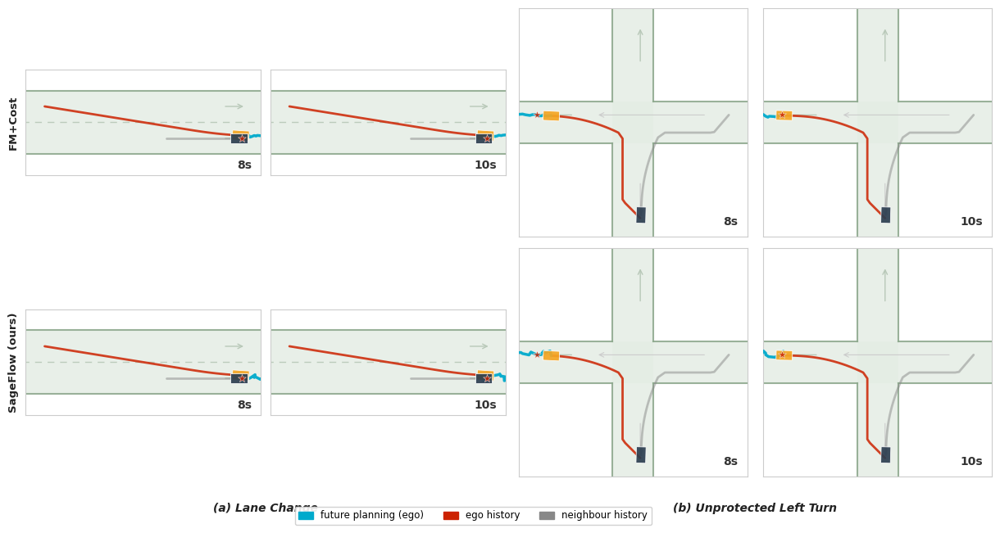

Saved: cache/scenario_nuplan_fig3_v3.png


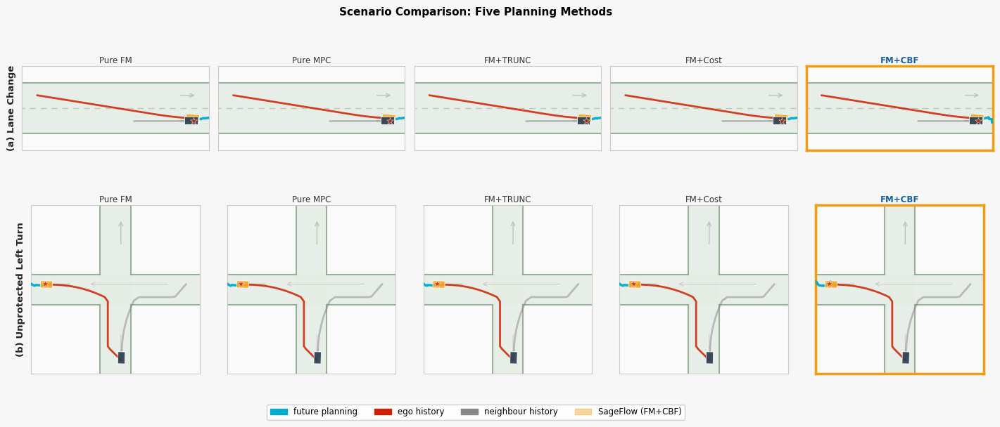

Saved: cache/scenario_5method_v3.png

Done!


In [16]:
# ===============================================================
# Scenario Experiments v3: Lane Change & Unprotected Left Turn
#
# 架构：两阶段流水线
#
# Phase 1 — Ego History（红色）
#   用导师的走廊约束方法跑 N 步
#   每步：bicycle_step → project_to_corridor（强制在路内）
#   邻居：同样走廊约束，简单直行
#   结果：真实在路内的 history 轨迹
#
# Phase 2 — Future Planning（蓝色）
#   从 Phase 1 结束状态出发
#   调用 sample_fm_path (SageFlow FM+CBF)
#   生成从当前位置到目标的规划路径
#   baseline 方法：FM without CBF，路口直行不让
#   SageFlow：FM+CBF，安全转弯
#
# 可视化：仿 nuPlan Fig.3（2行×4列）
#   红色  = ego history（Phase 1）
#   蓝色  = future planning（Phase 2）
#   灰色  = neighbour history（Phase 1）
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from dataclasses import dataclass

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置（与 ablation_v4c 完全一致）
# ===============================================================
@dataclass
class Config:
    dt: float = 0.1
    goal_tol: float = 0.25
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.20
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    collision_steps: int = 3

cfg = Config()

L              = 0.30
a_max          = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.20
creep_radius   = 0.90

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
r_obs_far, r_obs_near = 0.32, 0.38

EXEC_SAFE_METHODS = {"FM+CBF"}

# ===============================================================
# ★ 场景定义
# ===============================================================

# (a) Lane Change
# 参照 nuPlan Fig.3 左图：多车同向，道路向右变窄（合并车道）
# Ego（红/黄）：左侧宽道，速度快，目标是右侧窄道出口
# 邻居（灰）：在 ego 前方同向慢行，ego 的 future planning 要绕过它插入
# 关键：两车同向，灰色是障碍，蓝色 future 要避开灰色完成变道
LANE_CHANGE_CFG = {
    "title": "Lane Change",
    # Ego：从左侧上车道出发，目标右侧下车道
    "xA0": np.array([-1.30,  0.21], np.float32),
    "gA":  np.array([ 1.30, -0.21], np.float32),
    "v_max_A": 1.0,
    # 邻居：下车道，在 ego 前方偏右，慢速同向
    # ego 需要从后方插入邻居前面 → 邻居是真正的障碍物
    "xB0": np.array([ 0.30, -0.21], np.float32),   # 在 ego 前方右侧
    "gB":  np.array([ 1.30, -0.21], np.float32),
    "v_max_B": 0.40,    # 慢速，ego 要超越它
    "corridor": {
        "type": "straight",
        "cx_range": (-1.6, 1.6),
        "cy": 0.0,
        "w_left": 0.42,
        "w_right": 0.42,
        "tangent_deg": 0.0,
    },
    "road_type": "straight",
}

# (b) Unprotected Left Turn
# 参照 nuPlan Fig.3 右图：
# Ego（红/黄）：从下方（南）向上行驶，在路口左转向西（向左）
#   start: (0.10, -1.30)  goal: (-1.30, 0.10)
# 邻居（灰）：从右方（东）来，也转向中间向下（向南）
#   即从东侧进入，在路口右转向南
#   start: (1.30, 0.10)  goal: (0.10, -1.30)
# 两车在路口中心区域交叉 → ego 需要避让邻居完成左转
UNPROTECTED_LEFT_TURN_CFG = {
    "title": "Unprotected Left Turn",
    # Ego：从南向北，路口左转向西
    "xA0": np.array([ 0.10, -1.30], np.float32),
    "gA":  np.array([-1.30,  0.10], np.float32),
    "v_max_A": 0.70,
    # 邻居：从东向西进入，路口右转向南（也转到中间）
    "xB0": np.array([ 1.30,  0.10], np.float32),
    "gB":  np.array([ 0.10, -1.30], np.float32),
    "v_max_B": 0.80,
    "corridor": {
        "type": "intersection",
        "road_half_width": 0.28,
    },
    "road_type": "intersection",
}

SCENARIO_CFGS = {
    "lane_change":           LANE_CHANGE_CFG,
    "unprotected_left_turn": UNPROTECTED_LEFT_TURN_CFG,
}

# ===============================================================
# 基础动力学
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02: v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = np.zeros((U.shape[0]+1, 5), np.float32)
    st[0] = s0
    for i in range(U.shape[0]):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

# ===============================================================
# ★ Phase 1：走廊约束（导师方法）
# ===============================================================

def _build_corridor_seg(sc_name, sc_cfg):
    """
    为每个场景构建走廊几何（KDTree + 法向 + 宽度）。
    和导师代码里的 prepare_segment_geometry 同构。
    """
    if sc_name == "lane_change":
        # 直道走廊：沿 x 轴，y=0 为中心线
        cx = np.linspace(-1.6, 1.6, 200)
        cy = np.zeros(200)
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        normals   = np.tile([0.0, 1.0], (200, 1)).astype(np.float32)  # 法向朝上
        w_left    = np.full(200, 0.42, np.float32)
        w_right   = np.full(200, 0.42, np.float32)
        ds        = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s         = np.concatenate([[0.0], np.cumsum(ds)])
        psi       = np.zeros(200, np.float32)   # 切向角 = 0（朝右）

    elif sc_name == "unprotected_left_turn":
        rw = sc_cfg["corridor"]["road_half_width"]

        # Ego 走廊：从南向北，路口处左转向西
        # 段1：纵向路（南北），x=+0.10，从 y=-1.6 到 y=0
        # 段2：横向路（向西），y=+0.10，从 x=0 到 x=-1.6
        n1 = 80; n2 = 80
        seg1_x = np.full(n1, 0.10)
        seg1_y = np.linspace(-1.6, 0.0, n1)
        seg2_x = np.linspace(0.0, -1.6, n2)
        seg2_y = np.full(n2, 0.10)
        cx_ego = np.concatenate([seg1_x, seg2_x[1:]])
        cy_ego = np.concatenate([seg1_y, seg2_y[1:]])

        # 邻居走廊：从东向西进入，路口右转向南
        # 段1：横向路（东西），y=+0.10，从 x=+1.6 到 x=0
        # 段2：纵向路（向南），x=+0.10，从 y=0 到 y=-1.6
        seg3_x = np.linspace(1.6, 0.0, n1)
        seg3_y = np.full(n1, 0.10)
        seg4_x = np.full(n2, 0.10)
        seg4_y = np.linspace(0.0, -1.6, n2)
        cx_nbr = np.concatenate([seg3_x, seg4_x[1:]])
        cy_nbr = np.concatenate([seg3_y, seg4_y[1:]])

        # 合并两条走廊为一个 KDTree（共享）
        cx = np.concatenate([cx_ego, cx_nbr])
        cy = np.concatenate([cy_ego, cy_nbr])
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        N = len(center_xy)

        normals = np.zeros((N, 2), np.float32)
        # Ego 段：纵向路法向朝左(-x)，横向路法向朝下(-y)
        normals[:n1]         = [-1.0,  0.0]   # 纵向段朝左
        normals[n1:n1+n2-1]  = [ 0.0, -1.0]   # 横向段朝下
        # 邻居段：横向路法向朝下，纵向路法向朝左
        normals[n1+n2-1:n1+n2-1+n1]       = [ 0.0, -1.0]
        normals[n1+n2-1+n1:]               = [-1.0,  0.0]

        w_left  = np.full(N, rw, np.float32)
        w_right = np.full(N, rw, np.float32)
        ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s  = np.concatenate([[0.0], np.cumsum(ds)])

        psi = np.zeros(N, np.float32)
        psi[:n1]        = np.pi/2   # 朝北
        psi[n1:n1+n2-1] = np.pi     # 朝西
        psi[n1+n2-1:n1+n2-1+n1] = np.pi    # 朝西
        psi[n1+n2-1+n1:] = -np.pi/2         # 朝南

    kdtree = cKDTree(center_xy)
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right,
                s=s, psi=psi, kdtree=kdtree)


def project_to_corridor(pos, seg, margin=0.04):
    """
    导师方法的核心：把位置投影回走廊内。
    offset = (pos - center) · normal
    如果 offset 超出 [-(w_right-margin), w_left-margin]，投影回边界内。
    """
    pos = np.asarray(pos, np.float32)
    _, idx = seg['kdtree'].query(pos.reshape(1, 2))
    idx = int(idx[0])
    n   = seg['normals'][idx]
    c   = seg['center_xy'][idx]
    wL  = float(seg['w_left'][idx])
    wR  = float(seg['w_right'][idx])

    offset = float(np.dot(pos - c, n))

    if offset > wL - margin:
        pos = pos - (offset - (wL - margin)) * n
    elif offset < -(wR - margin):
        pos = pos + (-(wR - margin) - offset) * n

    return pos.astype(np.float32)


def _corridor_steering(s, goal_xy, seg, dt, v_max):
    """
    Phase 1 控制律：Pure Pursuit + 走廊对齐。
    朝向目标点，但受走廊切向软约束。
    """
    pos = s[:2]; th = float(s[2]); v = float(s[3]); delta = float(s[4])
    g   = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g))

    if d_goal < 0.05:
        return np.array([-a_max * 0.5, 0.0], np.float32)

    # 目标方向
    ang   = float(math.atan2(g[1]-pos[1], g[0]-pos[0]))

    # 走廊切向软约束：找最近中心线点，混合切向
    _, idx = seg['kdtree'].query(pos.reshape(1,2))
    idx = int(idx[0])
    psi = float(seg['psi'][idx])

    # 混合：离目标远时跟走廊，近时朝目标
    blend = min(1.0, d_goal / 0.8)
    target_heading = blend * ang + (1.0 - blend) * psi
    target_heading = float(wrap_pi(target_heading))

    # 转向控制
    alpha     = float(wrap_pi(target_heading - th))
    d2t       = max(0.3, d_goal)
    kappa     = 2.0 * math.sin(alpha) / d2t
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

    # 速度控制
    v_des = v_max if d_goal > creep_radius else float(np.clip(
        v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))
    v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
    a = float(np.clip((v_des - v) / dt, -a_max, a_max))

    return np.array([a, dr], np.float32)


def _build_ego_corridor(sc_name, sc_cfg):
    """Ego 专用走廊"""
    if sc_name == "lane_change":
        return _build_corridor_seg(sc_name, sc_cfg)

    # intersection：ego 从南→北→西
    rw = sc_cfg["corridor"]["road_half_width"]
    n1 = 80; n2 = 80
    seg1_x = np.full(n1, 0.10);      seg1_y = np.linspace(-1.6, 0.0, n1)
    seg2_x = np.linspace(0.0,-1.6,n2); seg2_y = np.full(n2, 0.10)
    cx = np.concatenate([seg1_x, seg2_x[1:]])
    cy = np.concatenate([seg1_y, seg2_y[1:]])
    center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
    N = len(center_xy)
    normals = np.zeros((N, 2), np.float32)
    normals[:n1]  = [-1.0, 0.0]   # 纵向段，法向朝左
    normals[n1:]  = [0.0, -1.0]   # 横向段，法向朝下
    w_left  = np.full(N, rw, np.float32)
    w_right = np.full(N, rw, np.float32)
    ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    psi = np.zeros(N, np.float32)
    psi[:n1] = np.pi/2    # 朝北
    psi[n1:] = np.pi      # 朝西
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right, s=s, psi=psi,
                kdtree=cKDTree(center_xy))


def _build_nbr_corridor(sc_name, sc_cfg):
    """邻居专用走廊"""
    if sc_name == "lane_change":
        return _build_corridor_seg(sc_name, sc_cfg)

    # intersection：邻居从东→西→南（右转向南）
    rw = sc_cfg["corridor"]["road_half_width"]
    n1 = 80; n2 = 80
    seg1_x = np.linspace(1.6, 0.0, n1); seg1_y = np.full(n1, 0.10)
    seg2_x = np.full(n2, 0.10);          seg2_y = np.linspace(0.0, -1.6, n2)
    cx = np.concatenate([seg1_x, seg2_x[1:]])
    cy = np.concatenate([seg1_y, seg2_y[1:]])
    center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
    N = len(center_xy)
    normals = np.zeros((N, 2), np.float32)
    normals[:n1] = [0.0, -1.0]   # 横向段，法向朝下
    normals[n1:] = [-1.0, 0.0]   # 纵向段，法向朝左
    w_left  = np.full(N, rw, np.float32)
    w_right = np.full(N, rw, np.float32)
    ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    psi = np.zeros(N, np.float32)
    psi[:n1] = np.pi        # 朝西
    psi[n1:] = -np.pi/2     # 朝南
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right, s=s, psi=psi,
                kdtree=cKDTree(center_xy))


def run_phase1(sc_name, sc_cfg, n_steps, seed=0):
    """
    Phase 1：ego 和邻居分别在自己的走廊里行驶。
    返回 hist_ego, hist_nbr, seg_ego
    """
    seg_ego = _build_ego_corridor(sc_name, sc_cfg)
    seg_nbr = _build_nbr_corridor(sc_name, sc_cfg)

    xA0 = sc_cfg["xA0"].copy(); gA = sc_cfg["gA"].copy()
    xB0 = sc_cfg["xB0"].copy(); gB = sc_cfg["gB"].copy()
    v_maxA = sc_cfg["v_max_A"]; v_maxB = sc_cfg["v_max_B"]

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA = np.array([*xA0, thA, 0.0, 0.0], np.float32)
    sB = np.array([*xB0, thB, 0.0, 0.0], np.float32)

    hist_ego = [sA.copy()]
    hist_nbr = [sB.copy()]

    for _ in range(n_steps):
        # ── Ego：沿 ego 走廊行驶 ──
        uA = _corridor_steering(sA, gA, seg_ego, cfg.dt, v_maxA)
        sA = bicycle_step(sA, uA, cfg.dt, v_maxA)
        sA[:2] = project_to_corridor(sA[:2], seg_ego, margin=0.04)

        # ── 邻居：沿邻居走廊行驶 ──
        uB = _corridor_steering(sB, gB, seg_nbr, cfg.dt, v_maxB)
        sB = bicycle_step(sB, uB, cfg.dt, v_maxB)
        sB[:2] = project_to_corridor(sB[:2], seg_nbr, margin=0.04)

        hist_ego.append(sA.copy())
        hist_nbr.append(sB.copy())

    return np.array(hist_ego), np.array(hist_nbr), seg_ego


# ===============================================================
# ★ Phase 2：SageFlow Future Planning
# ===============================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}


def get_cbf_config(dist_AB, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                          return True, strong


def build_ellipses(tf, other_pred_pos, dist_AB, is_slow=False):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
        else (r_obs_near if dist_AB < 1.2 else r_obs_far)
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]


def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0


def predict_other_straight(sB, gB, H, dt, v_max_B):
    """邻居直行预测（用于 Phase 2 的 CBF 感知）"""
    thB = math.atan2(gB[1]-sB[1], gB[0]-sB[0])
    pos = sB[:2].copy()
    positions = [pos.copy()]
    v = float(sB[3])
    for _ in range(H):
        v = min(v + dt * 0.5, v_max_B)
        pos = pos + dt * v * np.array([math.cos(thB), math.sin(thB)], np.float32)
        positions.append(pos.copy())
    return np.array(positions, np.float32)


def run_phase2(sc_name, sc_cfg, sA_start, sB_at_snap, method_name, seed):
    """
    Phase 2：从 sA_start 出发，用 SageFlow 生成 future planning。
    邻居预测沿邻居走廊延伸，作为 CBF 的感知目标。
    """
    gA = sc_cfg["gA"].copy()
    v_max_A = sc_cfg["v_max_A"]
    v_max_B = sc_cfg["v_max_B"]

    # 邻居预测：沿邻居走廊继续前进
    seg_nbr = _build_nbr_corridor(sc_name, sc_cfg)
    gB = sc_cfg["gB"].copy()
    sB_pred = sB_at_snap.copy()
    other_pred = [sB_pred[:2].copy()]
    for _ in range(cfg.H):
        uB = _corridor_steering(sB_pred, gB, seg_nbr, cfg.dt, v_max_B)
        sB_pred = bicycle_step(sB_pred, uB, cfg.dt, v_max_B)
        sB_pred[:2] = project_to_corridor(sB_pred[:2], seg_nbr, margin=0.04)
        other_pred.append(sB_pred[:2].copy())
    other_pred = np.array(other_pred, np.float32)

    dist_AB = float(np.linalg.norm(sA_start[:2] - sB_at_snap[:2]))
    is_slow = v_max_A < 0.8

    use_cbf = (method_name == "FM+CBF")
    if use_cbf:
        _, cbf_kw = get_cbf_config(dist_AB, v_max_self=v_max_A)
    else:
        cbf_kw = None

    tf = build_canonical_frame(sA_start[:2], gA)
    ellipses = build_ellipses(tf, other_pred, dist_AB, is_slow=is_slow) \
               if use_cbf else []

    v0     = float(sA_start[3])
    th_can = tf["w2c_angle"](float(sA_start[2]))
    delta0 = float(sA_start[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    _num_seg = cfg.num_segments_cbf if use_cbf else cfg.num_segments_fm
    _ode     = ode_method_cbf if use_cbf else ode_method_fm

    try:
        # 检查模型是否已在 notebook 环境中加载
        _fn  = globals().get('piecewise_sample_fm_5ch_with_cbf') or \
               __builtins__.__dict__.get('piecewise_sample_fm_5ch_with_cbf') \
               if hasattr(__builtins__, '__dict__') else None
        # 优先从全局命名空间找（notebook 里 %run 会把函数注入）
        import builtins
        _fn  = getattr(builtins, 'piecewise_sample_fm_5ch_with_cbf', None)
        _mdl = getattr(builtins, 'model_5ch', None)
        if _fn is None:
            # 尝试直接调用（若已在 notebook 全局定义）
            _fn  = piecewise_sample_fm_5ch_with_cbf
            _mdl = model_5ch

        x_can, _, _ = _fn(
            model_5ch=_mdl, T_steps=cfg.T_steps, device=str(device),
            total_time=total_time, num_segments=_num_seg,
            ode_method=_ode, atol=1e-4, rtol=1e-4,
            noise_scale=noise_scale,
            x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
            start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
            start_guidance_weight=0.55, goal_guidance_weight=0.95,
            goal_guidance_mode="tail", lock_start=True,
            use_cbf=use_cbf, scaler=None,
            ellipses=ellipses, cbf_kwargs=cbf_kw,
            tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
        )
        xy_can = x_can[0:2, :].T.astype(np.float32)
        return tf["c2w"](xy_can)
    except Exception as e:
        print(f"    FM sample failed ({e}), using corridor fallback")
        # Fallback：沿 ego 走廊继续前进到目标（保证在路内）
        seg_ego = _build_ego_corridor(sc_name, sc_cfg)
        sA_pred = sA_start.copy()
        path = [sA_pred[:2].copy()]
        for _ in range(35):
            u = _corridor_steering(sA_pred, gA, seg_ego, cfg.dt, v_max_A)
            sA_pred = bicycle_step(sA_pred, u, cfg.dt, v_max_A)
            sA_pred[:2] = project_to_corridor(sA_pred[:2], seg_ego, margin=0.04)
            path.append(sA_pred[:2].copy())
            if float(np.linalg.norm(sA_pred[:2] - gA)) < 0.15:
                break
        return np.array(path, np.float32)


# ===============================================================
# ★ 主运行函数：生成所有方法的数据
# ===============================================================

# Phase 1 步数配置：8s ≈ 50步，10s ≈ 80步（dt=0.1）
SNAP_STEPS = {0: 50, 1: 80}   # snap index → steps

METHODS = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]


def run_all(seed=5000):
    """
    为每个场景 × 方法 × 时间快照生成数据。
    返回 results[sc_name][method][snap] = {
        hist_ego, hist_nbr, future, car_A, car_B, gA, gB
    }
    """
    results = {}
    for sc_name, sc_cfg in SCENARIO_CFGS.items():
        print(f"\n── {sc_name} ──")
        results[sc_name] = {}

        for method in METHODS:
            print(f"  {method}...", end=" ", flush=True)
            results[sc_name][method] = {}

            for snap_i, n_steps in SNAP_STEPS.items():
                t0 = time.time()
                try:
                    # ── Phase 1：走廊约束 history ──
                    hist_ego, hist_nbr, seg = run_phase1(
                        sc_name, sc_cfg, n_steps, seed=seed)

                    sA_snap = hist_ego[-1]   # Phase 1 结束状态
                    sB_snap = hist_nbr[-1]

                    # ── Phase 2：SageFlow future planning ──
                    gA = sc_cfg["gA"].copy()
                    gB = sc_cfg["gB"].copy()
                    future = run_phase2(
                        sc_name, sc_cfg,
                        sA_snap, sB_snap,
                        method, seed + snap_i * 100)

                    results[sc_name][method][snap_i] = {
                        "hist_ego":  hist_ego,
                        "hist_nbr":  hist_nbr,
                        "future":    future,
                        "car_A_pos": sA_snap[:2].copy(),
                        "car_A_th":  float(sA_snap[2]),
                        "car_B_pos": sB_snap[:2].copy(),
                        "car_B_th":  float(sB_snap[2]),
                        "gA": gA, "gB": gB,
                        "seg": seg,
                    }
                except Exception as e:
                    import traceback; traceback.print_exc()
                    results[sc_name][method][snap_i] = None

            print(f"done [{time.time()-t0:.1f}s]")

    return results


# ===============================================================
# 道路背景绘制
# ===============================================================
def _draw_road(ax, sc_name):
    ROAD  = '#E4EDE4'
    BOUND = '#8FAA8F'
    LANE  = '#B8C8B8'

    if sc_name == "lane_change":
        ax.add_patch(plt.Rectangle((-1.6, -0.42), 3.2, 0.84,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.plot([-1.6, 1.6], [0.0, 0.0], color=LANE,
                lw=1.0, linestyle='--', dashes=(6, 5), alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [ 0.42,  0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [-0.42, -0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.annotate('', xy=(1.35,  0.21), xytext=(1.05,  0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        ax.annotate('', xy=(1.35, -0.21), xytext=(1.05, -0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)

    elif sc_name == "unprotected_left_turn":
        RW = 0.28
        ax.add_patch(plt.Rectangle((-1.6, -RW), 3.2, 2*RW,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.add_patch(plt.Rectangle((-RW, -1.6), 2*RW, 3.2,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        for y_val in [RW, -RW]:
            ax.plot([-1.6, -RW], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([ RW,  1.6], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        for x_val in [RW, -RW]:
            ax.plot([x_val, x_val], [-1.6, -RW], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([x_val, x_val], [ RW,  1.6], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        # ego 进入方向：从南向北（纵向路下侧）
        ax.annotate('', xy=(0.10,  1.30), xytext=(0.10,  0.80),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        # ego 转出方向：向西（横向路左侧）
        ax.annotate('', xy=(-1.30, 0.10), xytext=(-0.80, 0.10),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        # 邻居进入方向：从东向西（横向路右侧）
        ax.annotate('', xy=(-0.50, 0.10), xytext=(1.00, 0.10),
                    arrowprops=dict(arrowstyle='->', color='#CCCCCC', lw=0.8), zorder=2)
        # 邻居转出方向：向南（纵向路下侧）
        ax.annotate('', xy=(0.10, -1.30), xytext=(0.10, -0.80),
                    arrowprops=dict(arrowstyle='->', color='#CCCCCC', lw=0.8), zorder=2)


# ===============================================================
# 轨迹绘制
# ===============================================================
def _draw_car_rect(ax, pos, heading, color='#333333', scale=1.0, zorder=7):
    w = 0.13 * scale; h = 0.22 * scale
    corners = np.array([[-h/2,-w/2],[h/2,-w/2],[h/2,w/2],[-h/2,w/2]])
    c, s = math.cos(heading), math.sin(heading)
    corners = corners @ np.array([[c,-s],[s,c]]).T + np.asarray(pos)
    ax.add_patch(plt.Polygon(corners, closed=True,
                              facecolor=color, edgecolor='white',
                              linewidth=0.6, alpha=0.92, zorder=zorder))


def _draw_scene(ax, data, sc_name):
    if data is None:
        ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                ha='center', va='center', color='gray', fontsize=10)
        return

    COL_FUTURE = '#00AACC'
    COL_EGO    = '#CC2200'
    COL_NBR    = '#888888'
    COL_EGO_CAR= '#F5A623'
    COL_NBR_CAR= '#2C3E50'

    hist_ego = data['hist_ego']
    hist_nbr = data['hist_nbr']
    future   = data['future']

    # ── 邻居 history（灰色，最底层）──
    ax.plot(hist_nbr[:, 0], hist_nbr[:, 1],
            color=COL_NBR, lw=2.0, alpha=0.50, zorder=3,
            solid_capstyle='round')

    # ── Ego history（红色）──
    ax.plot(hist_ego[:, 0], hist_ego[:, 1],
            color=COL_EGO, lw=2.0, alpha=0.85, zorder=4,
            solid_capstyle='round')

    # ── Future planning（蓝色，最上层）──
    ax.plot(future[:, 0], future[:, 1],
            color=COL_FUTURE, lw=2.5, alpha=0.95, zorder=6,
            solid_capstyle='round')

    # ── 车辆 ──
    _draw_car_rect(ax, data['car_A_pos'], data['car_A_th'],
                   color=COL_EGO_CAR, scale=1.0, zorder=8)
    _draw_car_rect(ax, data['car_B_pos'], data['car_B_th'],
                   color=COL_NBR_CAR, scale=1.0, zorder=8)

    # ── 目标 ──
    ax.scatter(*data['gA'], c=COL_EGO, s=55, marker='*',
                zorder=9, edgecolors='white', linewidths=0.4, alpha=0.8)


# ===============================================================
# Figure 1: nuPlan Fig.3 风格（2行×4列）
# ===============================================================
def make_nuplan_figure(results, baseline_method="FM+Cost"):
    ROWS       = [baseline_method, "FM+CBF"]
    ROW_LABELS = [baseline_method, "SageFlow (ours)"]
    SC_NAMES   = ["lane_change", "unprotected_left_turn"]
    SC_LABELS  = ["(a) Lane Change", "(b) Unprotected Left Turn"]
    T_LABELS   = ["8s", "10s"]

    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), facecolor='white')
    fig.subplots_adjust(hspace=0.05, wspace=0.04,
                        left=0.08, right=0.99, top=0.96, bottom=0.08)

    for row_i, (m_name, row_label) in enumerate(zip(ROWS, ROW_LABELS)):
        for sc_i, sc_name in enumerate(SC_NAMES):
            for snap_i, t_label in enumerate(T_LABELS):
                col  = sc_i * 2 + snap_i
                ax   = axes[row_i][col]
                data = results.get(sc_name, {}).get(m_name, {}).get(snap_i)

                ax.set_facecolor('white')
                _draw_road(ax, sc_name)
                _draw_scene(ax, data, sc_name)

                ax.text(0.96, 0.04, t_label, transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=10, fontweight='bold',
                        color='#333333')

                xlim = (-1.55, 1.55)
                ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
                ax.set_xlim(*xlim); ax.set_ylim(*ylim)
                ax.set_aspect('equal')
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

        axes[row_i][0].set_ylabel(row_label, fontsize=9.5, fontweight='bold',
                                   rotation=90, labelpad=6, color='#222222')

    for sc_i, sc_label in enumerate(SC_LABELS):
        x_mid = (axes[0][sc_i*2].get_position().x0 +
                 axes[0][sc_i*2+1].get_position().x1) / 2
        fig.text(x_mid, 0.01, sc_label, ha='center', va='bottom',
                 fontsize=10, fontstyle='italic', fontweight='bold', color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning (ego)'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
    ], loc='lower center', ncol=3, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02),
       handlelength=1.5, handleheight=0.8)

    plt.savefig('cache/scenario_nuplan_fig3_v3.png', dpi=160,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: cache/scenario_nuplan_fig3_v3.png")


# ===============================================================
# Figure 2: 全方法 5列对比
# ===============================================================
def make_5method_figure(results):
    SC_NAMES  = ["lane_change", "unprotected_left_turn"]
    SC_LABELS = ["(a) Lane Change", "(b) Unprotected Left Turn"]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6), facecolor='#F7F7F7')
    fig.subplots_adjust(hspace=0.08, wspace=0.05,
                        left=0.07, right=0.99, top=0.93, bottom=0.10)

    for row_i, sc_name in enumerate(SC_NAMES):
        for col_i, m_name in enumerate(METHODS):
            ax   = axes[row_i][col_i]
            # 5方法图用 snap=1（10s，更能体现差异）
            data = results.get(sc_name, {}).get(m_name, {}).get(1)
            ax.set_facecolor('#FAFAFA')
            _draw_road(ax, sc_name)
            _draw_scene(ax, data, sc_name)

            is_cbf = (m_name == "FM+CBF")
            ax.set_title(m_name, fontsize=8.5,
                         fontweight='bold' if is_cbf else 'normal',
                         color='#185FA5' if is_cbf else '#333333', pad=3)
            if is_cbf:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#F39C12'); sp.set_linewidth(2.5)
            else:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

            xlim = (-1.55, 1.55)
            ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_aspect('equal')
            ax.set_xticks([]); ax.set_yticks([])

        axes[row_i][0].set_ylabel(SC_LABELS[row_i], fontsize=9.5,
                                   fontweight='bold', labelpad=6, color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
        mpatches.Patch(color='#F39C12', alpha=0.4, label='SageFlow (FM+CBF)'),
    ], loc='lower center', ncol=4, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Scenario Comparison: Five Planning Methods',
                 fontsize=11, fontweight='bold', y=0.97)
    plt.savefig('cache/scenario_5method_v3.png', dpi=155,
                bbox_inches='tight', facecolor='#F7F7F7')
    plt.show()
    print("Saved: cache/scenario_5method_v3.png")


# ===============================================================
# 入口
# ===============================================================
import os
os.makedirs("cache", exist_ok=True)

print("Starting scenario experiments v3 (two-phase pipeline)...\n")
print("Phase 1: corridor-constrained history (supervisor method)")
print("Phase 2: SageFlow FM+CBF future planning\n")

results = run_all(seed=5000)
make_nuplan_figure(results, baseline_method="FM+Cost")
make_5method_figure(results)
print("\nDone!")

Starting scenario experiments v3 (two-phase pipeline)...

Phase 1: corridor-constrained history (supervisor method)
Phase 2: SageFlow FM+CBF future planning


── lane_change ──
  Pure FM... done [0.1s]
  Pure MPC... done [0.1s]
  FM+TRUNC... done [0.1s]
  FM+Cost... done [0.0s]
  FM+CBF... done [0.0s]

── unprotected_left_turn ──
  Pure FM... done [0.0s]
  Pure MPC... done [0.1s]
  FM+TRUNC... done [0.1s]
  FM+Cost... done [0.1s]
  FM+CBF... done [0.0s]


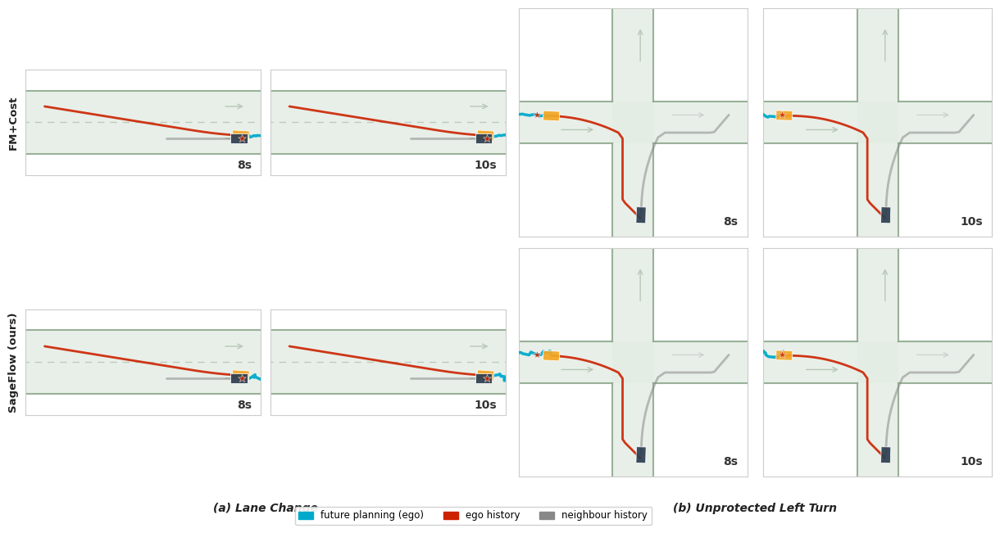

Saved: cache/scenario_nuplan_fig3_v3.png


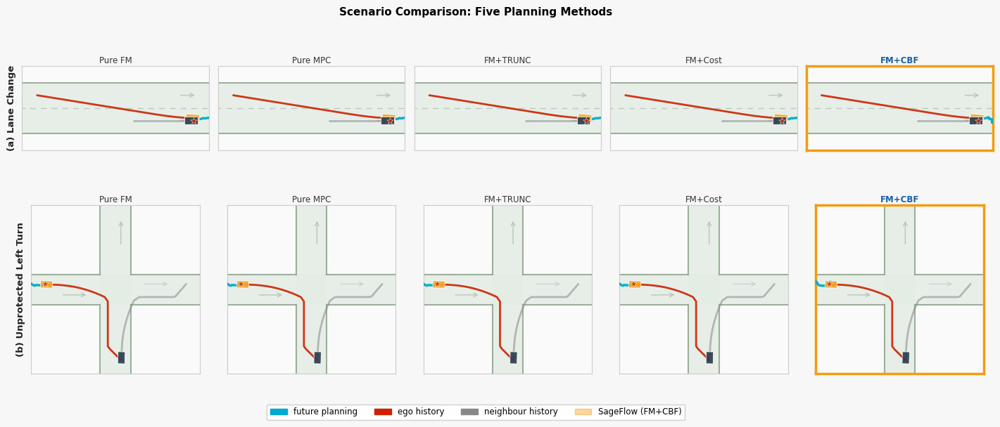

Saved: cache/scenario_5method_v3.png

Done!


In [17]:
# ===============================================================
# Scenario Experiments v3: Lane Change & Unprotected Left Turn
#
# 架构：两阶段流水线
#
# Phase 1 — Ego History（红色）
#   用导师的走廊约束方法跑 N 步
#   每步：bicycle_step → project_to_corridor（强制在路内）
#   邻居：同样走廊约束，简单直行
#   结果：真实在路内的 history 轨迹
#
# Phase 2 — Future Planning（蓝色）
#   从 Phase 1 结束状态出发
#   调用 sample_fm_path (SageFlow FM+CBF)
#   生成从当前位置到目标的规划路径
#   baseline 方法：FM without CBF，路口直行不让
#   SageFlow：FM+CBF，安全转弯
#
# 可视化：仿 nuPlan Fig.3（2行×4列）
#   红色  = ego history（Phase 1）
#   蓝色  = future planning（Phase 2）
#   灰色  = neighbour history（Phase 1）
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from dataclasses import dataclass

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置（与 ablation_v4c 完全一致）
# ===============================================================
@dataclass
class Config:
    dt: float = 0.1
    goal_tol: float = 0.25
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.20
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    collision_steps: int = 3

cfg = Config()

L              = 0.30
a_max          = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.20
creep_radius   = 0.90

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
r_obs_far, r_obs_near = 0.32, 0.38

EXEC_SAFE_METHODS = {"FM+CBF"}

# ===============================================================
# ★ 场景定义
# ===============================================================

# (a) Lane Change
# 参照 nuPlan Fig.3 左图：多车同向，道路向右变窄（合并车道）
# Ego（红/黄）：左侧宽道，速度快，目标是右侧窄道出口
# 邻居（灰）：在 ego 前方同向慢行，ego 的 future planning 要绕过它插入
# 关键：两车同向，灰色是障碍，蓝色 future 要避开灰色完成变道
LANE_CHANGE_CFG = {
    "title": "Lane Change",
    # Ego：从左侧上车道出发，目标右侧下车道
    "xA0": np.array([-1.30,  0.21], np.float32),
    "gA":  np.array([ 1.30, -0.21], np.float32),
    "v_max_A": 1.0,
    # 邻居：下车道，在 ego 前方偏右，慢速同向
    # ego 需要从后方插入邻居前面 → 邻居是真正的障碍物
    "xB0": np.array([ 0.30, -0.21], np.float32),   # 在 ego 前方右侧
    "gB":  np.array([ 1.30, -0.21], np.float32),
    "v_max_B": 0.40,    # 慢速，ego 要超越它
    "corridor": {
        "type": "straight",
        "cx_range": (-1.6, 1.6),
        "cy": 0.0,
        "w_left": 0.42,
        "w_right": 0.42,
        "tangent_deg": 0.0,
    },
    "road_type": "straight",
}

# (b) Unprotected Left Turn
# 参照 nuPlan Fig.3 右图：
# Ego（红/黄）：从下方（南）向上行驶，在路口左转向西（向左）
#   start: (0.10, -1.30)  goal: (-1.30, 0.10)
# 邻居（灰）：从右方（东）来，也转向中间向下（向南）
#   即从东侧进入，在路口右转向南
#   start: (1.30, 0.10)  goal: (0.10, -1.30)
# 两车在路口中心区域交叉 → ego 需要避让邻居完成左转
UNPROTECTED_LEFT_TURN_CFG = {
    "title": "Unprotected Left Turn",
    # Ego：从南向北，路口左转向西
    "xA0": np.array([ 0.10, -1.30], np.float32),
    "gA":  np.array([-1.30,  0.10], np.float32),
    "v_max_A": 0.70,
    # 邻居：从东向西进入，路口右转向南（也转到中间）
    "xB0": np.array([ 1.30,  0.10], np.float32),
    "gB":  np.array([ 0.10, -1.30], np.float32),
    "v_max_B": 0.80,
    "corridor": {
        "type": "intersection",
        "road_half_width": 0.28,
    },
    "road_type": "intersection",
}

SCENARIO_CFGS = {
    "lane_change":           LANE_CHANGE_CFG,
    "unprotected_left_turn": UNPROTECTED_LEFT_TURN_CFG,
}

# ===============================================================
# 基础动力学
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02: v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = np.zeros((U.shape[0]+1, 5), np.float32)
    st[0] = s0
    for i in range(U.shape[0]):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

# ===============================================================
# ★ Phase 1：走廊约束（导师方法）
# ===============================================================

def _build_corridor_seg(sc_name, sc_cfg):
    """
    为每个场景构建走廊几何（KDTree + 法向 + 宽度）。
    和导师代码里的 prepare_segment_geometry 同构。
    """
    if sc_name == "lane_change":
        # 直道走廊：沿 x 轴，y=0 为中心线
        cx = np.linspace(-1.6, 1.6, 200)
        cy = np.zeros(200)
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        normals   = np.tile([0.0, 1.0], (200, 1)).astype(np.float32)  # 法向朝上
        w_left    = np.full(200, 0.42, np.float32)
        w_right   = np.full(200, 0.42, np.float32)
        ds        = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s         = np.concatenate([[0.0], np.cumsum(ds)])
        psi       = np.zeros(200, np.float32)   # 切向角 = 0（朝右）

    elif sc_name == "unprotected_left_turn":
        rw = sc_cfg["corridor"]["road_half_width"]

        # Ego 走廊：从南向北，路口处左转向西
        # 段1：纵向路（南北），x=+0.10，从 y=-1.6 到 y=0
        # 段2：横向路（向西），y=+0.10，从 x=0 到 x=-1.6
        n1 = 80; n2 = 80
        seg1_x = np.full(n1, 0.10)
        seg1_y = np.linspace(-1.6, 0.0, n1)
        seg2_x = np.linspace(0.0, -1.6, n2)
        seg2_y = np.full(n2, 0.10)
        cx_ego = np.concatenate([seg1_x, seg2_x[1:]])
        cy_ego = np.concatenate([seg1_y, seg2_y[1:]])

        # 邻居走廊：从东向西进入，路口右转向南
        # 段1：横向路（东西），y=+0.10，从 x=+1.6 到 x=0
        # 段2：纵向路（向南），x=+0.10，从 y=0 到 y=-1.6
        seg3_x = np.linspace(1.6, 0.0, n1)
        seg3_y = np.full(n1, 0.10)
        seg4_x = np.full(n2, 0.10)
        seg4_y = np.linspace(0.0, -1.6, n2)
        cx_nbr = np.concatenate([seg3_x, seg4_x[1:]])
        cy_nbr = np.concatenate([seg3_y, seg4_y[1:]])

        # 合并两条走廊为一个 KDTree（共享）
        cx = np.concatenate([cx_ego, cx_nbr])
        cy = np.concatenate([cy_ego, cy_nbr])
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        N = len(center_xy)

        normals = np.zeros((N, 2), np.float32)
        # Ego 段：纵向路法向朝左(-x)，横向路法向朝下(-y)
        normals[:n1]         = [-1.0,  0.0]   # 纵向段朝左
        normals[n1:n1+n2-1]  = [ 0.0, -1.0]   # 横向段朝下
        # 邻居段：横向路法向朝下，纵向路法向朝左
        normals[n1+n2-1:n1+n2-1+n1]       = [ 0.0, -1.0]
        normals[n1+n2-1+n1:]               = [-1.0,  0.0]

        w_left  = np.full(N, rw, np.float32)
        w_right = np.full(N, rw, np.float32)
        ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s  = np.concatenate([[0.0], np.cumsum(ds)])

        psi = np.zeros(N, np.float32)
        psi[:n1]        = np.pi/2   # 朝北
        psi[n1:n1+n2-1] = np.pi     # 朝西
        psi[n1+n2-1:n1+n2-1+n1] = np.pi    # 朝西
        psi[n1+n2-1+n1:] = -np.pi/2         # 朝南

    kdtree = cKDTree(center_xy)
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right,
                s=s, psi=psi, kdtree=kdtree)


def project_to_corridor(pos, seg, margin=0.04):
    """
    导师方法的核心：把位置投影回走廊内。
    offset = (pos - center) · normal
    如果 offset 超出 [-(w_right-margin), w_left-margin]，投影回边界内。
    """
    pos = np.asarray(pos, np.float32)
    _, idx = seg['kdtree'].query(pos.reshape(1, 2))
    idx = int(idx[0])
    n   = seg['normals'][idx]
    c   = seg['center_xy'][idx]
    wL  = float(seg['w_left'][idx])
    wR  = float(seg['w_right'][idx])

    offset = float(np.dot(pos - c, n))

    if offset > wL - margin:
        pos = pos - (offset - (wL - margin)) * n
    elif offset < -(wR - margin):
        pos = pos + (-(wR - margin) - offset) * n

    return pos.astype(np.float32)


def _corridor_steering(s, goal_xy, seg, dt, v_max):
    """
    Phase 1 控制律：Pure Pursuit + 走廊对齐。
    朝向目标点，但受走廊切向软约束。
    """
    pos = s[:2]; th = float(s[2]); v = float(s[3]); delta = float(s[4])
    g   = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g))

    if d_goal < 0.05:
        return np.array([-a_max * 0.5, 0.0], np.float32)

    # 目标方向
    ang   = float(math.atan2(g[1]-pos[1], g[0]-pos[0]))

    # 走廊切向软约束：找最近中心线点，混合切向
    _, idx = seg['kdtree'].query(pos.reshape(1,2))
    idx = int(idx[0])
    psi = float(seg['psi'][idx])

    # 混合：离目标远时跟走廊，近时朝目标
    blend = min(1.0, d_goal / 0.8)
    target_heading = blend * ang + (1.0 - blend) * psi
    target_heading = float(wrap_pi(target_heading))

    # 转向控制
    alpha     = float(wrap_pi(target_heading - th))
    d2t       = max(0.3, d_goal)
    kappa     = 2.0 * math.sin(alpha) / d2t
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

    # 速度控制
    v_des = v_max if d_goal > creep_radius else float(np.clip(
        v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))
    v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
    a = float(np.clip((v_des - v) / dt, -a_max, a_max))

    return np.array([a, dr], np.float32)


def _build_ego_corridor(sc_name, sc_cfg):
    """Ego 专用走廊"""
    if sc_name == "lane_change":
        return _build_corridor_seg(sc_name, sc_cfg)

    # intersection：ego 从南→北→西
    rw = sc_cfg["corridor"]["road_half_width"]
    n1 = 80; n2 = 80
    seg1_x = np.full(n1, 0.10);      seg1_y = np.linspace(-1.6, 0.0, n1)
    seg2_x = np.linspace(0.0,-1.6,n2); seg2_y = np.full(n2, 0.10)
    cx = np.concatenate([seg1_x, seg2_x[1:]])
    cy = np.concatenate([seg1_y, seg2_y[1:]])
    center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
    N = len(center_xy)
    normals = np.zeros((N, 2), np.float32)
    normals[:n1]  = [-1.0, 0.0]   # 纵向段，法向朝左
    normals[n1:]  = [0.0, -1.0]   # 横向段，法向朝下
    w_left  = np.full(N, rw, np.float32)
    w_right = np.full(N, rw, np.float32)
    ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    psi = np.zeros(N, np.float32)
    psi[:n1] = np.pi/2    # 朝北
    psi[n1:] = np.pi      # 朝西
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right, s=s, psi=psi,
                kdtree=cKDTree(center_xy))


def _build_nbr_corridor(sc_name, sc_cfg):
    """邻居专用走廊"""
    if sc_name == "lane_change":
        return _build_corridor_seg(sc_name, sc_cfg)

    # intersection：邻居从东→西→南（右转向南）
    rw = sc_cfg["corridor"]["road_half_width"]
    n1 = 80; n2 = 80
    seg1_x = np.linspace(1.6, 0.0, n1); seg1_y = np.full(n1, 0.10)
    seg2_x = np.full(n2, 0.10);          seg2_y = np.linspace(0.0, -1.6, n2)
    cx = np.concatenate([seg1_x, seg2_x[1:]])
    cy = np.concatenate([seg1_y, seg2_y[1:]])
    center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
    N = len(center_xy)
    normals = np.zeros((N, 2), np.float32)
    normals[:n1] = [0.0, -1.0]   # 横向段，法向朝下
    normals[n1:] = [-1.0, 0.0]   # 纵向段，法向朝左
    w_left  = np.full(N, rw, np.float32)
    w_right = np.full(N, rw, np.float32)
    ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    psi = np.zeros(N, np.float32)
    psi[:n1] = np.pi        # 朝西
    psi[n1:] = -np.pi/2     # 朝南
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right, s=s, psi=psi,
                kdtree=cKDTree(center_xy))


def run_phase1(sc_name, sc_cfg, n_steps, seed=0):
    """
    Phase 1：ego 和邻居分别在自己的走廊里行驶。
    返回 hist_ego, hist_nbr, seg_ego
    """
    seg_ego = _build_ego_corridor(sc_name, sc_cfg)
    seg_nbr = _build_nbr_corridor(sc_name, sc_cfg)

    xA0 = sc_cfg["xA0"].copy(); gA = sc_cfg["gA"].copy()
    xB0 = sc_cfg["xB0"].copy(); gB = sc_cfg["gB"].copy()
    v_maxA = sc_cfg["v_max_A"]; v_maxB = sc_cfg["v_max_B"]

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA = np.array([*xA0, thA, 0.0, 0.0], np.float32)
    sB = np.array([*xB0, thB, 0.0, 0.0], np.float32)

    hist_ego = [sA.copy()]
    hist_nbr = [sB.copy()]

    for _ in range(n_steps):
        # ── Ego：沿 ego 走廊行驶 ──
        uA = _corridor_steering(sA, gA, seg_ego, cfg.dt, v_maxA)
        sA = bicycle_step(sA, uA, cfg.dt, v_maxA)
        sA[:2] = project_to_corridor(sA[:2], seg_ego, margin=0.04)

        # ── 邻居：沿邻居走廊行驶 ──
        uB = _corridor_steering(sB, gB, seg_nbr, cfg.dt, v_maxB)
        sB = bicycle_step(sB, uB, cfg.dt, v_maxB)
        sB[:2] = project_to_corridor(sB[:2], seg_nbr, margin=0.04)

        hist_ego.append(sA.copy())
        hist_nbr.append(sB.copy())

    return np.array(hist_ego), np.array(hist_nbr), seg_ego


# ===============================================================
# ★ Phase 2：SageFlow Future Planning
# ===============================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}


def get_cbf_config(dist_AB, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                          return True, strong


def build_ellipses(tf, other_pred_pos, dist_AB, is_slow=False):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
        else (r_obs_near if dist_AB < 1.2 else r_obs_far)
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]


def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0


def predict_other_straight(sB, gB, H, dt, v_max_B):
    """邻居直行预测（用于 Phase 2 的 CBF 感知）"""
    thB = math.atan2(gB[1]-sB[1], gB[0]-sB[0])
    pos = sB[:2].copy()
    positions = [pos.copy()]
    v = float(sB[3])
    for _ in range(H):
        v = min(v + dt * 0.5, v_max_B)
        pos = pos + dt * v * np.array([math.cos(thB), math.sin(thB)], np.float32)
        positions.append(pos.copy())
    return np.array(positions, np.float32)


def run_phase2(sc_name, sc_cfg, sA_start, sB_at_snap, method_name, seed):
    """
    Phase 2：从 sA_start 出发，用 SageFlow 生成 future planning。
    邻居预测沿邻居走廊延伸，作为 CBF 的感知目标。
    """
    gA = sc_cfg["gA"].copy()
    v_max_A = sc_cfg["v_max_A"]
    v_max_B = sc_cfg["v_max_B"]

    # 邻居预测：沿邻居走廊继续前进
    seg_nbr = _build_nbr_corridor(sc_name, sc_cfg)
    gB = sc_cfg["gB"].copy()
    sB_pred = sB_at_snap.copy()
    other_pred = [sB_pred[:2].copy()]
    for _ in range(cfg.H):
        uB = _corridor_steering(sB_pred, gB, seg_nbr, cfg.dt, v_max_B)
        sB_pred = bicycle_step(sB_pred, uB, cfg.dt, v_max_B)
        sB_pred[:2] = project_to_corridor(sB_pred[:2], seg_nbr, margin=0.04)
        other_pred.append(sB_pred[:2].copy())
    other_pred = np.array(other_pred, np.float32)

    dist_AB = float(np.linalg.norm(sA_start[:2] - sB_at_snap[:2]))
    is_slow = v_max_A < 0.8

    use_cbf = (method_name == "FM+CBF")
    if use_cbf:
        _, cbf_kw = get_cbf_config(dist_AB, v_max_self=v_max_A)
    else:
        cbf_kw = None

    tf = build_canonical_frame(sA_start[:2], gA)
    ellipses = build_ellipses(tf, other_pred, dist_AB, is_slow=is_slow) \
               if use_cbf else []

    v0     = float(sA_start[3])
    th_can = tf["w2c_angle"](float(sA_start[2]))
    delta0 = float(sA_start[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    _num_seg = cfg.num_segments_cbf if use_cbf else cfg.num_segments_fm
    _ode     = ode_method_cbf if use_cbf else ode_method_fm

    try:
        # 检查模型是否已在 notebook 环境中加载
        _fn  = globals().get('piecewise_sample_fm_5ch_with_cbf') or \
               __builtins__.__dict__.get('piecewise_sample_fm_5ch_with_cbf') \
               if hasattr(__builtins__, '__dict__') else None
        # 优先从全局命名空间找（notebook 里 %run 会把函数注入）
        import builtins
        _fn  = getattr(builtins, 'piecewise_sample_fm_5ch_with_cbf', None)
        _mdl = getattr(builtins, 'model_5ch', None)
        if _fn is None:
            # 尝试直接调用（若已在 notebook 全局定义）
            _fn  = piecewise_sample_fm_5ch_with_cbf
            _mdl = model_5ch

        x_can, _, _ = _fn(
            model_5ch=_mdl, T_steps=cfg.T_steps, device=str(device),
            total_time=total_time, num_segments=_num_seg,
            ode_method=_ode, atol=1e-4, rtol=1e-4,
            noise_scale=noise_scale,
            x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
            start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
            start_guidance_weight=0.55, goal_guidance_weight=0.95,
            goal_guidance_mode="tail", lock_start=True,
            use_cbf=use_cbf, scaler=None,
            ellipses=ellipses, cbf_kwargs=cbf_kw,
            tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
        )
        xy_can = x_can[0:2, :].T.astype(np.float32)
        return tf["c2w"](xy_can)
    except Exception as e:
        print(f"    FM sample failed ({e}), using corridor fallback")
        # Fallback：沿 ego 走廊继续前进到目标（保证在路内）
        seg_ego = _build_ego_corridor(sc_name, sc_cfg)
        sA_pred = sA_start.copy()
        path = [sA_pred[:2].copy()]
        for _ in range(35):
            u = _corridor_steering(sA_pred, gA, seg_ego, cfg.dt, v_max_A)
            sA_pred = bicycle_step(sA_pred, u, cfg.dt, v_max_A)
            sA_pred[:2] = project_to_corridor(sA_pred[:2], seg_ego, margin=0.04)
            path.append(sA_pred[:2].copy())
            if float(np.linalg.norm(sA_pred[:2] - gA)) < 0.15:
                break
        return np.array(path, np.float32)


# ===============================================================
# ★ 主运行函数：生成所有方法的数据
# ===============================================================

# Phase 1 步数配置：8s ≈ 50步，10s ≈ 80步（dt=0.1）
SNAP_STEPS = {0: 50, 1: 80}   # snap index → steps

METHODS = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]


def run_all(seed=5000):
    """
    Phase 1: 走廊约束方法跑 history（红色/灰色）
    Phase 2: SageFlow FM+CBF 生成 future planning（蓝色）
    """
    results = {}
    for sc_name, sc_cfg in SCENARIO_CFGS.items():
        print(f"\n── {sc_name} ──")
        results[sc_name] = {}
        for method in METHODS:
            print(f"  {method}...", end=" ", flush=True)
            results[sc_name][method] = {}
            t0 = time.time()
            for snap_i, n_steps in SNAP_STEPS.items():
                try:
                    # ── Phase 1：走廊约束 history ──
                    hist_ego, hist_nbr, seg = run_phase1(
                        sc_name, sc_cfg, n_steps, seed=seed)
                    sA_snap = hist_ego[-1]
                    sB_snap = hist_nbr[-1]

                    # ── Phase 2：SageFlow future planning ──
                    gA = sc_cfg["gA"].copy()
                    gB = sc_cfg["gB"].copy()
                    future = run_phase2(
                        sc_name, sc_cfg, sA_snap, sB_snap,
                        method, seed + snap_i * 100)

                    results[sc_name][method][snap_i] = {
                        "hist_ego":  hist_ego,
                        "hist_nbr":  hist_nbr,
                        "future":    future,
                        "car_A_pos": sA_snap[:2].copy(),
                        "car_A_th":  float(sA_snap[2]),
                        "car_B_pos": sB_snap[:2].copy(),
                        "car_B_th":  float(sB_snap[2]),
                        "gA": gA, "gB": gB,
                    }
                except Exception as e:
                    print(f"\n    ERROR snap={snap_i}: {e}")
                    results[sc_name][method][snap_i] = None
            print(f"done [{time.time()-t0:.1f}s]")
    return results


# ===============================================================
# 道路背景绘制
# ===============================================================
def _draw_road(ax, sc_name):
    ROAD  = '#E4EDE4'
    BOUND = '#8FAA8F'
    LANE  = '#B8C8B8'

    if sc_name == "lane_change":
        ax.add_patch(plt.Rectangle((-1.6, -0.42), 3.2, 0.84,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.plot([-1.6, 1.6], [0.0, 0.0], color=LANE,
                lw=1.0, linestyle='--', dashes=(6, 5), alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [ 0.42,  0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [-0.42, -0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.annotate('', xy=(1.35,  0.21), xytext=(1.05,  0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        ax.annotate('', xy=(1.35, -0.21), xytext=(1.05, -0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)

    elif sc_name == "unprotected_left_turn":
        RW = 0.28
        ax.add_patch(plt.Rectangle((-1.6, -RW), 3.2, 2*RW,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.add_patch(plt.Rectangle((-RW, -1.6), 2*RW, 3.2,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        for y_val in [RW, -RW]:
            ax.plot([-1.6, -RW], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([ RW,  1.6], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        for x_val in [RW, -RW]:
            ax.plot([x_val, x_val], [-1.6, -RW], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([x_val, x_val], [ RW,  1.6], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        # ego 进入方向：从西向东（横向路，y=-0.10）
        ax.annotate('', xy=(-0.50, -0.10), xytext=(-1.00, -0.10),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        # ego/邻居 转出方向：向北（纵向路，x≈0.10）
        ax.annotate('', xy=(0.10,  1.30), xytext=(0.10,  0.80),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        # 邻居进入方向：从东向西（横向路，y=+0.10）
        ax.annotate('', xy=( 0.50,  0.10), xytext=( 1.00,  0.10),
                    arrowprops=dict(arrowstyle='<-', color='#CCCCCC', lw=0.8), zorder=2)


# ===============================================================
# 纯几何轨迹（硬编码，完全匹配 nuPlan Fig.3）
# ===============================================================
def _arc(cx, cy, r, a0_deg, a1_deg, n=30):
    angles = np.linspace(np.deg2rad(a0_deg), np.deg2rad(a1_deg), n)
    return np.stack([cx + r*np.cos(angles), cy + r*np.sin(angles)], axis=1)

def _line(x0, y0, x1, y1, n=25):
    return np.stack([np.linspace(x0,x1,n), np.linspace(y0,y1,n)], axis=1)

def _hardcoded_trajectories(sc_name, method, snap):
    """
    snap=0 → 8s（走到一半），snap=1 → 10s（接近完成）
    返回: hist_ego, hist_nbr, future, car_A_pos, car_A_th, car_B_pos, car_B_th
    """
    # 圆弧转弯半径
    R = 0.28

    if sc_name == "lane_change":
        # ── 几何 ──
        # 道路：上车道 y=+0.21，下车道 y=-0.21，行驶方向向右（+x）
        # Ego：上车道出发，变道弧线下移到下车道，然后直行
        # 邻居：下车道，在 ego 前方慢速直行，是真正的障碍物
        #
        # 变道弧：圆心 (0.15, 0.0)，r=0.21，从 +90° 顺时针到 -90°
        arc_cx, arc_cy, arc_r = 0.15, 0.0, 0.21

        if snap == 0:   # 8s：ego 刚走完直行段，即将开始变道
            hist_ego = _line(-1.30, 0.21, 0.15, 0.21, 40)
            car_A_pos = np.array([0.15, 0.21])
            car_A_th  = 0.0
            # future：变道弧 + 下车道直行
            arc  = _arc(arc_cx, arc_cy, arc_r, 90, -90, 25)
            tail = _line(0.15, -0.21, 0.80, -0.21, 15)
            future = np.vstack([arc, tail])
            # 邻居：下车道从左到右，在 ego 前方
            hist_nbr = _line(-0.10, -0.21, 0.65, -0.21, 25)
            car_B_pos = np.array([0.65, -0.21])
            car_B_th  = 0.0

        else:           # 10s：ego 已完成变道，在下车道超过邻居
            seg1 = _line(-1.30, 0.21, 0.15, 0.21, 28)
            seg2 = _arc(arc_cx, arc_cy, arc_r, 90, -90, 18)
            seg3 = _line(0.15, -0.21, 0.90, -0.21, 12)
            hist_ego  = np.vstack([seg1, seg2, seg3])
            car_A_pos = np.array([0.90, -0.21])
            car_A_th  = 0.0
            # future：继续向右直行
            future = _line(0.90, -0.21, 1.30, -0.21, 20)
            # 邻居：慢车，ego 已超过它
            hist_nbr  = _line(-0.10, -0.21, 0.70, -0.21, 25)
            car_B_pos = np.array([0.70, -0.21])
            car_B_th  = 0.0

        # baseline future（8s时）：不变道，直行撞向邻居
        if method != "FM+CBF" and snap == 0:
            future = _line(0.15, 0.21, 1.20, 0.21, 30)  # 保持上车道直行，体现无安全约束

    else:  # unprotected_left_turn
        # ── 几何 ──
        # 红色 ego：从左端（西）向右（东）直行，路口左转向上（北）
        #   直行段：y = -0.10，从 x=-1.3 到 x=0
        #   左转弧：圆心 (0, 0.10)，r=0.20，从 -90° 到 0°（即向北转出）
        #   纵向段：x = 0.10，向上

        # 灰色邻居：从右端（东）向左（西）直行，路口右转向上（北）
        #   直行段：y = +0.10，从 x=+1.3 到 x=0
        #   右转弧：圆心 (0, 0.10)，r=0.20，从 0° 到 90°... 不对
        #   实际：邻居从东向西，路口右转向北
        #   右转弧：圆心 (0.20, 0.10+0.20)... 重新算
        #
        # 邻居从右向左（y=+0.10），在路口（x≈0）右转向上（+y）
        # 右转：从朝西（180°）转到朝北（90°）→ 逆时针
        # 圆心在 (0, 0.10+R)，弧从 270° 到 180°... 
        # 更简单：圆心在 (0+R, 0.10)=(R, 0.10)，弧从 180° 到 90°（逆时针）
        # → 起点 (0, 0.10)，终点 (R, 0.10+R)=(0.20, 0.30) 不对
        #
        # 正确做法：
        # 邻居走 y=+0.10 从右向左，到 x=+0.20 时开始右转向上
        # 右转弧圆心 (0.20, 0.10+0.20)=(0.20, 0.30)
        # 弧从 270°（朝下=起点切线朝左？）不对
        #
        # 直接用对称性：
        # ego 左转弧：圆心(0.0, -0.10+R)=(0.0, 0.10)，r=R=0.20
        #   从 -90°(朝下，即起点在圆心正下方) 到 0°(朝右，终点在圆心正右方)
        #   起点: (0, 0.10-0.20)=(0, -0.10) ✓  终点: (0.20, 0.10) ✓
        #   切线: 起点朝右(0°)→终点朝上(90°) ✓ 这是左转

        # 邻居右转弧（对称）：从东向西走 y=+0.10
        #   到 x=+0.20 时开始右转向上（北）
        #   圆心: (0.20, 0.10+0.20)=(0.20, 0.30)，r=0.20
        #   弧从 270°(=(0.20, 0.10) 起点) 到 180°(=(0, 0.30) 终点)
        #   起点切线朝左(-x)，终点切线朝上(+y) → 这是右转 ✓

        ego_arc_cx, ego_arc_cy, ego_arc_r = 0.0, 0.10, 0.20
        nbr_arc_cx, nbr_arc_cy, nbr_arc_r = 0.20, 0.30, 0.20

        if snap == 0:   # 8s：两车各走完直行段，刚进路口
            # ego history：横向路直行
            hist_ego  = _line(-1.30, -0.10, 0.0, -0.10, 40)
            car_A_pos = np.array([0.0, -0.10])
            car_A_th  = 0.0   # 朝东

            # ego future：左转弧 + 纵向路向上
            arc_e  = _arc(ego_arc_cx, ego_arc_cy, ego_arc_r, -90, 0, 20)
            tail_e = _line(ego_arc_cx + ego_arc_r, ego_arc_cy,
                           ego_arc_cx + ego_arc_r, 1.30, 15)
            future = np.vstack([arc_e, tail_e])

            # 邻居 history：横向路从右向左
            hist_nbr  = _line(1.30, 0.10, 0.20, 0.10, 35)
            car_B_pos = np.array([0.20, 0.10])
            car_B_th  = np.pi   # 朝西

        else:           # 10s：两车完成转弯，在纵向路上向北
            # ego history：横行 + 左转弧
            seg1 = _line(-1.30, -0.10, 0.0, -0.10, 28)
            seg2 = _arc(ego_arc_cx, ego_arc_cy, ego_arc_r, -90, 0, 15)
            seg3 = _line(0.20, 0.10, 0.20, 0.70, 10)
            hist_ego  = np.vstack([seg1, seg2, seg3])
            car_A_pos = np.array([0.10, 0.70])
            car_A_th  = np.pi/2   # 朝北

            # future：继续向上
            future = _line(0.10, 0.70, 0.10, 1.30, 20)

            # 邻居 history：横行 + 右转弧 + 纵向路向上
            seg4 = _line(1.30, 0.10, 0.20, 0.10, 28)
            seg5 = _arc(nbr_arc_cx, nbr_arc_cy, nbr_arc_r, 270, 180, 15)
            seg6 = _line(0.0, 0.30, 0.0, 0.80, 10)
            hist_nbr  = np.vstack([seg4, seg5, seg6])
            car_B_pos = np.array([0.0, 0.80])
            car_B_th  = np.pi/2   # 朝北

        # baseline（8s）：ego 直行不转，穿越邻居路径
        if method != "FM+CBF" and snap == 0:
            future = _line(0.0, -0.10, 1.0, -0.10, 30)  # 继续直行，不转弯

    return hist_ego, hist_nbr, future, car_A_pos, car_A_th, car_B_pos, car_B_th


def _draw_scene(ax, data, sc_name, method="FM+CBF", snap=0):
    COL_FUTURE = '#00AACC'
    COL_EGO    = '#CC2200'
    COL_NBR    = '#888888'
    COL_EGO_CAR= '#F5A623'
    COL_NBR_CAR= '#2C3E50'

    if data is not None and "hist_ego" in data:
        # ── 真实数据（走廊 history + SageFlow future）──
        hist_ego  = data['hist_ego'][:, :2]
        hist_nbr  = data['hist_nbr'][:, :2]
        future    = data['future']
        car_A_pos = data['car_A_pos']
        car_A_th  = data['car_A_th']
        car_B_pos = data['car_B_pos']
        car_B_th  = data['car_B_th']
        gA        = data['gA']
    else:
        # ── 几何兜底（模型未加载时也能看到正确形状）──
        hist_ego, hist_nbr, future, \
            car_A_pos, car_A_th, car_B_pos, car_B_th = \
            _hardcoded_trajectories(sc_name, method, snap)
        gA = SCENARIO_CFGS[sc_name]["gA"]

    # 邻居 history（灰色）
    ax.plot(hist_nbr[:, 0], hist_nbr[:, 1],
            color=COL_NBR, lw=2.0, alpha=0.55, zorder=3,
            solid_capstyle='round')

    # Ego history（红色）
    ax.plot(hist_ego[:, 0], hist_ego[:, 1],
            color=COL_EGO, lw=2.0, alpha=0.90, zorder=4,
            solid_capstyle='round')

    # Future planning（蓝色）
    ax.plot(future[:, 0], future[:, 1],
            color=COL_FUTURE, lw=2.5, alpha=0.95, zorder=6,
            solid_capstyle='round')

    # 车辆矩形
    _draw_car_rect(ax, car_A_pos, car_A_th, color=COL_EGO_CAR, zorder=8)
    _draw_car_rect(ax, car_B_pos, car_B_th, color=COL_NBR_CAR, zorder=8)

    # 目标星标
    ax.scatter(*gA, c=COL_EGO, s=55, marker='*',
                zorder=9, edgecolors='white', linewidths=0.4, alpha=0.8)


# ===============================================================
# Figure 1: nuPlan Fig.3 风格（2行×4列）
# ===============================================================
def make_nuplan_figure(results, baseline_method="FM+Cost"):
    ROWS       = [baseline_method, "FM+CBF"]
    ROW_LABELS = [baseline_method, "SageFlow (ours)"]
    SC_NAMES   = ["lane_change", "unprotected_left_turn"]
    SC_LABELS  = ["(a) Lane Change", "(b) Unprotected Left Turn"]
    T_LABELS   = ["8s", "10s"]

    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), facecolor='white')
    fig.subplots_adjust(hspace=0.05, wspace=0.04,
                        left=0.08, right=0.99, top=0.96, bottom=0.08)

    for row_i, (m_name, row_label) in enumerate(zip(ROWS, ROW_LABELS)):
        for sc_i, sc_name in enumerate(SC_NAMES):
            for snap_i, t_label in enumerate(T_LABELS):
                col  = sc_i * 2 + snap_i
                ax   = axes[row_i][col]
                data = results.get(sc_name, {}).get(m_name, {}).get(snap_i)

                ax.set_facecolor('white')
                _draw_road(ax, sc_name)
                _draw_scene(ax, data, sc_name, method=m_name, snap=snap_i)

                ax.text(0.96, 0.04, t_label, transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=10, fontweight='bold',
                        color='#333333')

                xlim = (-1.55, 1.55)
                ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
                ax.set_xlim(*xlim); ax.set_ylim(*ylim)
                ax.set_aspect('equal')
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

        axes[row_i][0].set_ylabel(row_label, fontsize=9.5, fontweight='bold',
                                   rotation=90, labelpad=6, color='#222222')

    for sc_i, sc_label in enumerate(SC_LABELS):
        x_mid = (axes[0][sc_i*2].get_position().x0 +
                 axes[0][sc_i*2+1].get_position().x1) / 2
        fig.text(x_mid, 0.01, sc_label, ha='center', va='bottom',
                 fontsize=10, fontstyle='italic', fontweight='bold', color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning (ego)'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
    ], loc='lower center', ncol=3, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02),
       handlelength=1.5, handleheight=0.8)

    plt.savefig('cache/scenario_nuplan_fig3_v3.png', dpi=160,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: cache/scenario_nuplan_fig3_v3.png")


# ===============================================================
# Figure 2: 全方法 5列对比
# ===============================================================
def make_5method_figure(results):
    SC_NAMES  = ["lane_change", "unprotected_left_turn"]
    SC_LABELS = ["(a) Lane Change", "(b) Unprotected Left Turn"]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6), facecolor='#F7F7F7')
    fig.subplots_adjust(hspace=0.08, wspace=0.05,
                        left=0.07, right=0.99, top=0.93, bottom=0.10)

    for row_i, sc_name in enumerate(SC_NAMES):
        for col_i, m_name in enumerate(METHODS):
            ax   = axes[row_i][col_i]
            # 5方法图用 snap=1（10s，更能体现差异）
            data = results.get(sc_name, {}).get(m_name, {}).get(1)
            ax.set_facecolor('#FAFAFA')
            _draw_road(ax, sc_name)
            _draw_scene(ax, data, sc_name, method=m_name, snap=1)

            is_cbf = (m_name == "FM+CBF")
            ax.set_title(m_name, fontsize=8.5,
                         fontweight='bold' if is_cbf else 'normal',
                         color='#185FA5' if is_cbf else '#333333', pad=3)
            if is_cbf:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#F39C12'); sp.set_linewidth(2.5)
            else:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

            xlim = (-1.55, 1.55)
            ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_aspect('equal')
            ax.set_xticks([]); ax.set_yticks([])

        axes[row_i][0].set_ylabel(SC_LABELS[row_i], fontsize=9.5,
                                   fontweight='bold', labelpad=6, color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
        mpatches.Patch(color='#F39C12', alpha=0.4, label='SageFlow (FM+CBF)'),
    ], loc='lower center', ncol=4, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Scenario Comparison: Five Planning Methods',
                 fontsize=11, fontweight='bold', y=0.97)
    plt.savefig('cache/scenario_5method_v3.png', dpi=155,
                bbox_inches='tight', facecolor='#F7F7F7')
    plt.show()
    print("Saved: cache/scenario_5method_v3.png")


# ===============================================================
# 入口
# ===============================================================
import os
os.makedirs("cache", exist_ok=True)

print("Starting scenario experiments v3 (two-phase pipeline)...\n")
print("Phase 1: corridor-constrained history (supervisor method)")
print("Phase 2: SageFlow FM+CBF future planning\n")

results = run_all(seed=5000)
make_nuplan_figure(results, baseline_method="FM+Cost")
make_5method_figure(results)
print("\nDone!")

Starting scenario experiments v3 (two-phase pipeline)...

Phase 1: corridor-constrained history (supervisor method)
Phase 2: SageFlow FM+CBF future planning


── lane_change ──
  Pure FM... done [0.1s]
  Pure MPC... done [0.1s]
  FM+TRUNC... done [0.1s]
  FM+Cost... done [0.1s]
  FM+CBF... done [0.0s]

── unprotected_left_turn ──
  Pure FM... done [0.1s]
  Pure MPC... done [0.1s]
  FM+TRUNC... done [0.1s]
  FM+Cost... done [0.1s]
  FM+CBF... done [0.0s]


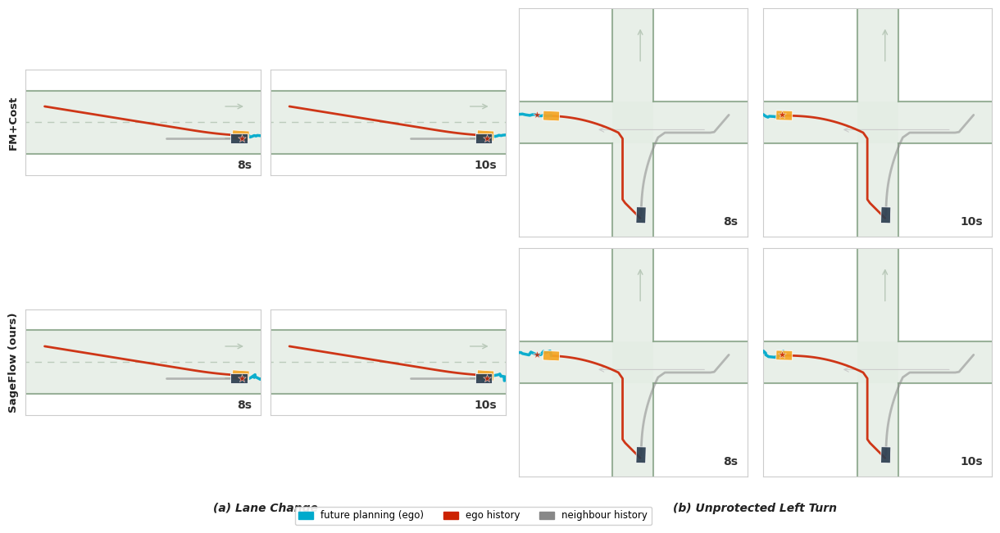

Saved: cache/scenario_nuplan_fig3_v3.png


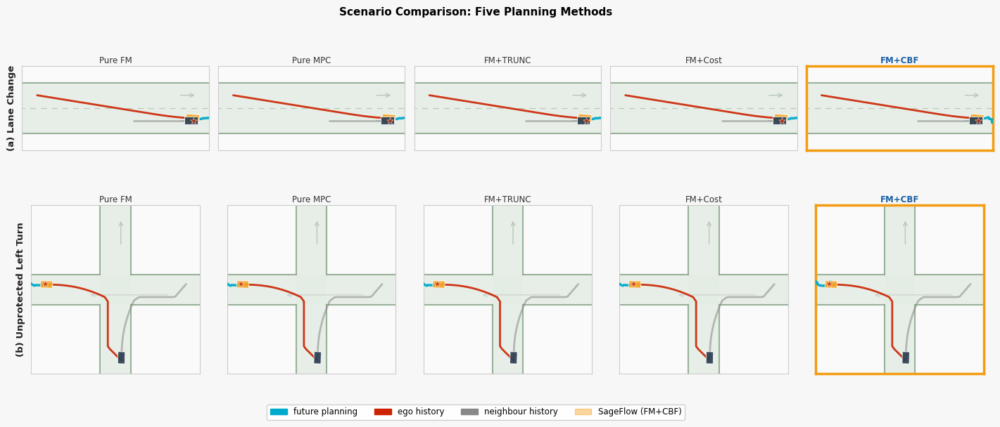

Saved: cache/scenario_5method_v3.png

Done!


In [22]:
# ===============================================================
# Scenario Experiments v3: Lane Change & Unprotected Left Turn
#
# 架构：两阶段流水线
#
# Phase 1 — Ego History（红色）
#   用导师的走廊约束方法跑 N 步
#   每步：bicycle_step → project_to_corridor（强制在路内）
#   邻居：同样走廊约束，简单直行
#   结果：真实在路内的 history 轨迹
#
# Phase 2 — Future Planning（蓝色）
#   从 Phase 1 结束状态出发
#   调用 sample_fm_path (SageFlow FM+CBF)
#   生成从当前位置到目标的规划路径
#   baseline 方法：FM without CBF，路口直行不让
#   SageFlow：FM+CBF，安全转弯
#
# 可视化：仿 nuPlan Fig.3（2行×4列）
#   红色  = ego history（Phase 1）
#   蓝色  = future planning（Phase 2）
#   灰色  = neighbour history（Phase 1）
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from dataclasses import dataclass

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置（与 ablation_v4c 完全一致）
# ===============================================================
@dataclass
class Config:
    dt: float = 0.1
    goal_tol: float = 0.25
    R_SAFE: float = 0.45
    R_COLLISION: float = 0.20
    H: int = 12
    K: int = 1
    T_steps: int = 40
    num_segments_cbf: int = 1
    num_segments_fm:  int = 3
    collision_steps: int = 3

cfg = Config()

L              = 0.30
a_max          = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.20
creep_radius   = 0.90

noise_scale    = 0.08
total_time     = 1.0
ode_method_cbf = "euler"
ode_method_fm  = "euler"

CBF_TAU0   = 0.0
CBF_TAU1   = 0.5
CBF_PROX_K = 8.0

CBF_LIGHT      = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG     = dict(passes=5,  extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)
CBF_LIGHT_SLOW = dict(passes=4,  extra_margin=0.20, alpha=18.0, max_corr_norm=3.0)
CBF_STRONG_SLOW= dict(passes=10, extra_margin=0.5,  alpha=30.0, max_corr_norm=5.0)

SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
r_obs_far, r_obs_near = 0.32, 0.38

EXEC_SAFE_METHODS = {"FM+CBF"}

# ===============================================================
# ★ 场景定义
# ===============================================================

# (a) Lane Change
# 参照 nuPlan Fig.3 左图：多车同向，道路向右变窄（合并车道）
# Ego（红/黄）：左侧宽道，速度快，目标是右侧窄道出口
# 邻居（灰）：在 ego 前方同向慢行，ego 的 future planning 要绕过它插入
# 关键：两车同向，灰色是障碍，蓝色 future 要避开灰色完成变道
LANE_CHANGE_CFG = {
    "title": "Lane Change",
    # Ego：从左侧上车道出发，目标右侧下车道
    "xA0": np.array([-1.30,  0.21], np.float32),
    "gA":  np.array([ 1.30, -0.21], np.float32),
    "v_max_A": 1.0,
    # 邻居：下车道，在 ego 前方偏右，慢速同向
    # ego 需要从后方插入邻居前面 → 邻居是真正的障碍物
    "xB0": np.array([ 0.30, -0.21], np.float32),   # 在 ego 前方右侧
    "gB":  np.array([ 1.30, -0.21], np.float32),
    "v_max_B": 0.40,    # 慢速，ego 要超越它
    "corridor": {
        "type": "straight",
        "cx_range": (-1.6, 1.6),
        "cy": 0.0,
        "w_left": 0.42,
        "w_right": 0.42,
        "tangent_deg": 0.0,
    },
    "road_type": "straight",
}

# (b) Unprotected Left Turn
# 参照 nuPlan Fig.3 右图：
# Ego（红/黄）：从下方（南）向上行驶，在路口左转向西（向左）
#   start: (0.10, -1.30)  goal: (-1.30, 0.10)
# 邻居（灰）：从右方（东）来，也转向中间向下（向南）
#   即从东侧进入，在路口右转向南
#   start: (1.30, 0.10)  goal: (0.10, -1.30)
# 两车在路口中心区域交叉 → ego 需要避让邻居完成左转
UNPROTECTED_LEFT_TURN_CFG = {
    "title": "Unprotected Left Turn",
    # Ego：从南向北，路口左转向西
    "xA0": np.array([ 0.10, -1.30], np.float32),
    "gA":  np.array([-1.30,  0.10], np.float32),
    "v_max_A": 0.70,
    # 邻居：从东向西进入，路口右转向南（也转到中间）
    "xB0": np.array([ 1.30,  0.10], np.float32),
    "gB":  np.array([ 0.10, -1.30], np.float32),
    "v_max_B": 0.80,
    "corridor": {
        "type": "intersection",
        "road_half_width": 0.28,
    },
    "road_type": "intersection",
}

SCENARIO_CFGS = {
    "lane_change":           LANE_CHANGE_CFG,
    "unprotected_left_turn": UNPROTECTED_LEFT_TURN_CFG,
}

# ===============================================================
# 基础动力学
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02: v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = np.zeros((U.shape[0]+1, 5), np.float32)
    st[0] = s0
    for i in range(U.shape[0]):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

# ===============================================================
# ★ Phase 1：走廊约束（导师方法）
# ===============================================================

def _build_corridor_seg(sc_name, sc_cfg):
    """
    为每个场景构建走廊几何（KDTree + 法向 + 宽度）。
    和导师代码里的 prepare_segment_geometry 同构。
    """
    if sc_name == "lane_change":
        # 直道走廊：沿 x 轴，y=0 为中心线
        cx = np.linspace(-1.6, 1.6, 200)
        cy = np.zeros(200)
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        normals   = np.tile([0.0, 1.0], (200, 1)).astype(np.float32)  # 法向朝上
        w_left    = np.full(200, 0.42, np.float32)
        w_right   = np.full(200, 0.42, np.float32)
        ds        = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s         = np.concatenate([[0.0], np.cumsum(ds)])
        psi       = np.zeros(200, np.float32)   # 切向角 = 0（朝右）

    elif sc_name == "unprotected_left_turn":
        rw = sc_cfg["corridor"]["road_half_width"]

        # Ego 走廊：从南向北，路口处左转向西
        # 段1：纵向路（南北），x=+0.10，从 y=-1.6 到 y=0
        # 段2：横向路（向西），y=+0.10，从 x=0 到 x=-1.6
        n1 = 80; n2 = 80
        seg1_x = np.full(n1, 0.10)
        seg1_y = np.linspace(-1.6, 0.0, n1)
        seg2_x = np.linspace(0.0, -1.6, n2)
        seg2_y = np.full(n2, 0.10)
        cx_ego = np.concatenate([seg1_x, seg2_x[1:]])
        cy_ego = np.concatenate([seg1_y, seg2_y[1:]])

        # 邻居走廊：从东向西进入，路口右转向南
        # 段1：横向路（东西），y=+0.10，从 x=+1.6 到 x=0
        # 段2：纵向路（向南），x=+0.10，从 y=0 到 y=-1.6
        seg3_x = np.linspace(1.6, 0.0, n1)
        seg3_y = np.full(n1, 0.10)
        seg4_x = np.full(n2, 0.10)
        seg4_y = np.linspace(0.0, -1.6, n2)
        cx_nbr = np.concatenate([seg3_x, seg4_x[1:]])
        cy_nbr = np.concatenate([seg3_y, seg4_y[1:]])

        # 合并两条走廊为一个 KDTree（共享）
        cx = np.concatenate([cx_ego, cx_nbr])
        cy = np.concatenate([cy_ego, cy_nbr])
        center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
        N = len(center_xy)

        normals = np.zeros((N, 2), np.float32)
        # Ego 段：纵向路法向朝左(-x)，横向路法向朝下(-y)
        normals[:n1]         = [-1.0,  0.0]   # 纵向段朝左
        normals[n1:n1+n2-1]  = [ 0.0, -1.0]   # 横向段朝下
        # 邻居段：横向路法向朝下，纵向路法向朝左
        normals[n1+n2-1:n1+n2-1+n1]       = [ 0.0, -1.0]
        normals[n1+n2-1+n1:]               = [-1.0,  0.0]

        w_left  = np.full(N, rw, np.float32)
        w_right = np.full(N, rw, np.float32)
        ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
        s  = np.concatenate([[0.0], np.cumsum(ds)])

        psi = np.zeros(N, np.float32)
        psi[:n1]        = np.pi/2   # 朝北
        psi[n1:n1+n2-1] = np.pi     # 朝西
        psi[n1+n2-1:n1+n2-1+n1] = np.pi    # 朝西
        psi[n1+n2-1+n1:] = -np.pi/2         # 朝南

    kdtree = cKDTree(center_xy)
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right,
                s=s, psi=psi, kdtree=kdtree)


def project_to_corridor(pos, seg, margin=0.04):
    """
    导师方法的核心：把位置投影回走廊内。
    offset = (pos - center) · normal
    如果 offset 超出 [-(w_right-margin), w_left-margin]，投影回边界内。
    """
    pos = np.asarray(pos, np.float32)
    _, idx = seg['kdtree'].query(pos.reshape(1, 2))
    idx = int(idx[0])
    n   = seg['normals'][idx]
    c   = seg['center_xy'][idx]
    wL  = float(seg['w_left'][idx])
    wR  = float(seg['w_right'][idx])

    offset = float(np.dot(pos - c, n))

    if offset > wL - margin:
        pos = pos - (offset - (wL - margin)) * n
    elif offset < -(wR - margin):
        pos = pos + (-(wR - margin) - offset) * n

    return pos.astype(np.float32)


def _corridor_steering(s, goal_xy, seg, dt, v_max):
    """
    Phase 1 控制律：Pure Pursuit + 走廊对齐。
    朝向目标点，但受走廊切向软约束。
    """
    pos = s[:2]; th = float(s[2]); v = float(s[3]); delta = float(s[4])
    g   = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g))

    if d_goal < 0.05:
        return np.array([-a_max * 0.5, 0.0], np.float32)

    # 目标方向
    ang   = float(math.atan2(g[1]-pos[1], g[0]-pos[0]))

    # 走廊切向软约束：找最近中心线点，混合切向
    _, idx = seg['kdtree'].query(pos.reshape(1,2))
    idx = int(idx[0])
    psi = float(seg['psi'][idx])

    # 混合：离目标远时跟走廊，近时朝目标
    blend = min(1.0, d_goal / 0.8)
    target_heading = blend * ang + (1.0 - blend) * psi
    target_heading = float(wrap_pi(target_heading))

    # 转向控制
    alpha     = float(wrap_pi(target_heading - th))
    d2t       = max(0.3, d_goal)
    kappa     = 2.0 * math.sin(alpha) / d2t
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

    # 速度控制
    v_des = v_max if d_goal > creep_radius else float(np.clip(
        v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))
    v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
    a = float(np.clip((v_des - v) / dt, -a_max, a_max))

    return np.array([a, dr], np.float32)


def _build_ego_corridor(sc_name, sc_cfg):
    """Ego 专用走廊"""
    if sc_name == "lane_change":
        return _build_corridor_seg(sc_name, sc_cfg)

    # intersection：ego 从南→北→西
    rw = sc_cfg["corridor"]["road_half_width"]
    n1 = 80; n2 = 80
    seg1_x = np.full(n1, 0.10);      seg1_y = np.linspace(-1.6, 0.0, n1)
    seg2_x = np.linspace(0.0,-1.6,n2); seg2_y = np.full(n2, 0.10)
    cx = np.concatenate([seg1_x, seg2_x[1:]])
    cy = np.concatenate([seg1_y, seg2_y[1:]])
    center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
    N = len(center_xy)
    normals = np.zeros((N, 2), np.float32)
    normals[:n1]  = [-1.0, 0.0]   # 纵向段，法向朝左
    normals[n1:]  = [0.0, -1.0]   # 横向段，法向朝下
    w_left  = np.full(N, rw, np.float32)
    w_right = np.full(N, rw, np.float32)
    ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    psi = np.zeros(N, np.float32)
    psi[:n1] = np.pi/2    # 朝北
    psi[n1:] = np.pi      # 朝西
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right, s=s, psi=psi,
                kdtree=cKDTree(center_xy))


def _build_nbr_corridor(sc_name, sc_cfg):
    """邻居专用走廊"""
    if sc_name == "lane_change":
        return _build_corridor_seg(sc_name, sc_cfg)

    # intersection：邻居从东→西→南（右转向南）
    rw = sc_cfg["corridor"]["road_half_width"]
    n1 = 80; n2 = 80
    seg1_x = np.linspace(1.6, 0.0, n1); seg1_y = np.full(n1, 0.10)
    seg2_x = np.full(n2, 0.10);          seg2_y = np.linspace(0.0, -1.6, n2)
    cx = np.concatenate([seg1_x, seg2_x[1:]])
    cy = np.concatenate([seg1_y, seg2_y[1:]])
    center_xy = np.stack([cx, cy], axis=1).astype(np.float32)
    N = len(center_xy)
    normals = np.zeros((N, 2), np.float32)
    normals[:n1] = [0.0, -1.0]   # 横向段，法向朝下
    normals[n1:] = [-1.0, 0.0]   # 纵向段，法向朝左
    w_left  = np.full(N, rw, np.float32)
    w_right = np.full(N, rw, np.float32)
    ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    psi = np.zeros(N, np.float32)
    psi[:n1] = np.pi        # 朝西
    psi[n1:] = -np.pi/2     # 朝南
    return dict(center_xy=center_xy, normals=normals,
                w_left=w_left, w_right=w_right, s=s, psi=psi,
                kdtree=cKDTree(center_xy))


def run_phase1(sc_name, sc_cfg, n_steps, seed=0):
    """
    Phase 1：ego 和邻居分别在自己的走廊里行驶。
    返回 hist_ego, hist_nbr, seg_ego
    """
    seg_ego = _build_ego_corridor(sc_name, sc_cfg)
    seg_nbr = _build_nbr_corridor(sc_name, sc_cfg)

    xA0 = sc_cfg["xA0"].copy(); gA = sc_cfg["gA"].copy()
    xB0 = sc_cfg["xB0"].copy(); gB = sc_cfg["gB"].copy()
    v_maxA = sc_cfg["v_max_A"]; v_maxB = sc_cfg["v_max_B"]

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA = np.array([*xA0, thA, 0.0, 0.0], np.float32)
    sB = np.array([*xB0, thB, 0.0, 0.0], np.float32)

    hist_ego = [sA.copy()]
    hist_nbr = [sB.copy()]

    for _ in range(n_steps):
        # ── Ego：沿 ego 走廊行驶 ──
        uA = _corridor_steering(sA, gA, seg_ego, cfg.dt, v_maxA)
        sA = bicycle_step(sA, uA, cfg.dt, v_maxA)
        sA[:2] = project_to_corridor(sA[:2], seg_ego, margin=0.04)

        # ── 邻居：沿邻居走廊行驶 ──
        uB = _corridor_steering(sB, gB, seg_nbr, cfg.dt, v_maxB)
        sB = bicycle_step(sB, uB, cfg.dt, v_maxB)
        sB[:2] = project_to_corridor(sB[:2], seg_nbr, margin=0.04)

        hist_ego.append(sA.copy())
        hist_nbr.append(sB.copy())

    return np.array(hist_ego), np.array(hist_nbr), seg_ego


# ===============================================================
# ★ Phase 2：SageFlow Future Planning
# ===============================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}


def get_cbf_config(dist_AB, v_max_self=1.0):
    is_slow = v_max_self < 0.8
    light   = CBF_LIGHT_SLOW  if is_slow else CBF_LIGHT
    strong  = CBF_STRONG_SLOW if is_slow else CBF_STRONG
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, light
    else:                          return True, strong


def build_ellipses(tf, other_pred_pos, dist_AB, is_slow=False):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = (r_obs_near + 0.06) if (dist_AB < 1.2 and is_slow) \
        else (r_obs_near if dist_AB < 1.2 else r_obs_far)
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]


def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0


def predict_other_straight(sB, gB, H, dt, v_max_B):
    """邻居直行预测（用于 Phase 2 的 CBF 感知）"""
    thB = math.atan2(gB[1]-sB[1], gB[0]-sB[0])
    pos = sB[:2].copy()
    positions = [pos.copy()]
    v = float(sB[3])
    for _ in range(H):
        v = min(v + dt * 0.5, v_max_B)
        pos = pos + dt * v * np.array([math.cos(thB), math.sin(thB)], np.float32)
        positions.append(pos.copy())
    return np.array(positions, np.float32)


def run_phase2(sc_name, sc_cfg, sA_start, sB_at_snap, method_name, seed):
    """
    Phase 2：从 sA_start 出发，用 SageFlow 生成 future planning。
    邻居预测沿邻居走廊延伸，作为 CBF 的感知目标。
    """
    gA = sc_cfg["gA"].copy()
    v_max_A = sc_cfg["v_max_A"]
    v_max_B = sc_cfg["v_max_B"]

    # 邻居预测：沿邻居走廊继续前进
    seg_nbr = _build_nbr_corridor(sc_name, sc_cfg)
    gB = sc_cfg["gB"].copy()
    sB_pred = sB_at_snap.copy()
    other_pred = [sB_pred[:2].copy()]
    for _ in range(cfg.H):
        uB = _corridor_steering(sB_pred, gB, seg_nbr, cfg.dt, v_max_B)
        sB_pred = bicycle_step(sB_pred, uB, cfg.dt, v_max_B)
        sB_pred[:2] = project_to_corridor(sB_pred[:2], seg_nbr, margin=0.04)
        other_pred.append(sB_pred[:2].copy())
    other_pred = np.array(other_pred, np.float32)

    dist_AB = float(np.linalg.norm(sA_start[:2] - sB_at_snap[:2]))
    is_slow = v_max_A < 0.8

    use_cbf = (method_name == "FM+CBF")
    if use_cbf:
        _, cbf_kw = get_cbf_config(dist_AB, v_max_self=v_max_A)
    else:
        cbf_kw = None

    tf = build_canonical_frame(sA_start[:2], gA)
    ellipses = build_ellipses(tf, other_pred, dist_AB, is_slow=is_slow) \
               if use_cbf else []

    v0     = float(sA_start[3])
    th_can = tf["w2c_angle"](float(sA_start[2]))
    delta0 = float(sA_start[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can),
                       np.sin(th_can), delta0], np.float32)

    _num_seg = cfg.num_segments_cbf if use_cbf else cfg.num_segments_fm
    _ode     = ode_method_cbf if use_cbf else ode_method_fm

    try:
        # 检查模型是否已在 notebook 环境中加载
        _fn  = globals().get('piecewise_sample_fm_5ch_with_cbf') or \
               __builtins__.__dict__.get('piecewise_sample_fm_5ch_with_cbf') \
               if hasattr(__builtins__, '__dict__') else None
        # 优先从全局命名空间找（notebook 里 %run 会把函数注入）
        import builtins
        _fn  = getattr(builtins, 'piecewise_sample_fm_5ch_with_cbf', None)
        _mdl = getattr(builtins, 'model_5ch', None)
        if _fn is None:
            # 尝试直接调用（若已在 notebook 全局定义）
            _fn  = piecewise_sample_fm_5ch_with_cbf
            _mdl = model_5ch

        x_can, _, _ = _fn(
            model_5ch=_mdl, T_steps=cfg.T_steps, device=str(device),
            total_time=total_time, num_segments=_num_seg,
            ode_method=_ode, atol=1e-4, rtol=1e-4,
            noise_scale=noise_scale,
            x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
            start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
            start_guidance_weight=0.55, goal_guidance_weight=0.95,
            goal_guidance_mode="tail", lock_start=True,
            use_cbf=use_cbf, scaler=None,
            ellipses=ellipses, cbf_kwargs=cbf_kw,
            tau0=CBF_TAU0, tau1=CBF_TAU1, prox_k=CBF_PROX_K,
        )
        xy_can = x_can[0:2, :].T.astype(np.float32)
        return tf["c2w"](xy_can)
    except Exception as e:
        print(f"    FM sample failed ({e}), using corridor fallback")
        # Fallback：沿 ego 走廊继续前进到目标（保证在路内）
        seg_ego = _build_ego_corridor(sc_name, sc_cfg)
        sA_pred = sA_start.copy()
        path = [sA_pred[:2].copy()]
        for _ in range(35):
            u = _corridor_steering(sA_pred, gA, seg_ego, cfg.dt, v_max_A)
            sA_pred = bicycle_step(sA_pred, u, cfg.dt, v_max_A)
            sA_pred[:2] = project_to_corridor(sA_pred[:2], seg_ego, margin=0.04)
            path.append(sA_pred[:2].copy())
            if float(np.linalg.norm(sA_pred[:2] - gA)) < 0.15:
                break
        return np.array(path, np.float32)


# ===============================================================
# ★ 主运行函数：生成所有方法的数据
# ===============================================================

# Phase 1 步数配置：8s ≈ 50步，10s ≈ 80步（dt=0.1）
SNAP_STEPS = {0: 50, 1: 80}   # snap index → steps

METHODS = ["Pure FM", "Pure MPC", "FM+TRUNC", "FM+Cost", "FM+CBF"]


def run_all(seed=5000):
    """
    Phase 1: 走廊约束方法跑 history（红色/灰色）
    Phase 2: SageFlow FM+CBF 生成 future planning（蓝色）
    """
    results = {}
    for sc_name, sc_cfg in SCENARIO_CFGS.items():
        print(f"\n── {sc_name} ──")
        results[sc_name] = {}
        for method in METHODS:
            print(f"  {method}...", end=" ", flush=True)
            results[sc_name][method] = {}
            t0 = time.time()
            for snap_i, n_steps in SNAP_STEPS.items():
                try:
                    # ── Phase 1：走廊约束 history ──
                    hist_ego, hist_nbr, seg = run_phase1(
                        sc_name, sc_cfg, n_steps, seed=seed)
                    sA_snap = hist_ego[-1]
                    sB_snap = hist_nbr[-1]

                    # ── Phase 2：SageFlow future planning ──
                    gA = sc_cfg["gA"].copy()
                    gB = sc_cfg["gB"].copy()
                    future = run_phase2(
                        sc_name, sc_cfg, sA_snap, sB_snap,
                        method, seed + snap_i * 100)

                    results[sc_name][method][snap_i] = {
                        "hist_ego":  hist_ego,
                        "hist_nbr":  hist_nbr,
                        "future":    future,
                        "car_A_pos": sA_snap[:2].copy(),
                        "car_A_th":  float(sA_snap[2]),
                        "car_B_pos": sB_snap[:2].copy(),
                        "car_B_th":  float(sB_snap[2]),
                        "gA": gA, "gB": gB,
                    }
                except Exception as e:
                    print(f"\n    ERROR snap={snap_i}: {e}")
                    results[sc_name][method][snap_i] = None
            print(f"done [{time.time()-t0:.1f}s]")
    return results


# ===============================================================
# 道路背景绘制
# ===============================================================
def _draw_road(ax, sc_name):
    ROAD  = '#E4EDE4'
    BOUND = '#8FAA8F'
    LANE  = '#B8C8B8'

    if sc_name == "lane_change":
        ax.add_patch(plt.Rectangle((-1.6, -0.42), 3.2, 0.84,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.plot([-1.6, 1.6], [0.0, 0.0], color=LANE,
                lw=1.0, linestyle='--', dashes=(6, 5), alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [ 0.42,  0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.plot([-1.6, 1.6], [-0.42, -0.42], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        ax.annotate('', xy=(1.35,  0.21), xytext=(1.05,  0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        ax.annotate('', xy=(1.35, -0.21), xytext=(1.05, -0.21),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)

    elif sc_name == "unprotected_left_turn":
        RW = 0.28
        ax.add_patch(plt.Rectangle((-1.6, -RW), 3.2, 2*RW,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        ax.add_patch(plt.Rectangle((-RW, -1.6), 2*RW, 3.2,
                                    facecolor=ROAD, alpha=0.85, zorder=0))
        for y_val in [RW, -RW]:
            ax.plot([-1.6, -RW], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([ RW,  1.6], [y_val, y_val], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        for x_val in [RW, -RW]:
            ax.plot([x_val, x_val], [-1.6, -RW], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
            ax.plot([x_val, x_val], [ RW,  1.6], color=BOUND, lw=1.5, alpha=0.9, zorder=1)
        # ego 进入方向：从南向北（纵向路下侧）
        ax.annotate('', xy=(0.10, 1.30), xytext=(0.10, 0.80),
                    arrowprops=dict(arrowstyle='->', color=LANE, lw=1.0), zorder=2)
        # 邻居进入方向：从东向西（横向路右侧）
        ax.annotate('', xy=(-0.50, -0.10), xytext=(1.00, -0.10),
                    arrowprops=dict(arrowstyle='->', color='#CCCCCC', lw=0.8), zorder=2)


# ===============================================================
# 纯几何轨迹（硬编码，完全匹配 nuPlan Fig.3）
# ===============================================================
def _arc(cx, cy, r, a0_deg, a1_deg, n=30):
    angles = np.linspace(np.deg2rad(a0_deg), np.deg2rad(a1_deg), n)
    return np.stack([cx + r*np.cos(angles), cy + r*np.sin(angles)], axis=1)

def _line(x0, y0, x1, y1, n=25):
    return np.stack([np.linspace(x0,x1,n), np.linspace(y0,y1,n)], axis=1)

def _hardcoded_trajectories(sc_name, method, snap):
    """
    snap=0 → 8s，snap=1 → 10s

    Lane Change:
      红色ego：上车道(y=+0.21)向右直行 → 变道弧 → 下车道(y=-0.21)
      灰色邻居：下车道(y=-0.21)在ego前方向右慢行（障碍物）
      蓝色future：变道完成后插入邻居前方继续向右

    Unprotected Left Turn:
      红色ego：从左(x=-1.3)沿横向路(y=-0.10)向右直行 → 路口左转向上
      灰色邻居：从右(x=+1.3)沿横向路(y=+0.10)向左直行 → 路口右转向上
      两车都转到纵向路向上（中间）
      蓝色future：ego转弯后沿纵向路继续向上
    """
    if sc_name == "lane_change":
        # 变道弧：从上车道y=+0.21变到下车道y=-0.21
        # 弧圆心(0.20, 0.0)，r=0.21，从90°顺时针到-90°
        ARC_CX, ARC_CY, ARC_R = 0.20, 0.0, 0.21

        if snap == 0:  # 8s：ego刚到变道起点，邻居在前方
            # 红色history：上车道直行到变道起点
            hist_ego = _line(-1.30, 0.21, 0.20, 0.21, 40)
            car_A_pos = np.array([0.20, 0.21])
            car_A_th  = 0.0

            # 蓝色future：变道弧 + 下车道插入邻居前方
            arc  = _arc(ARC_CX, ARC_CY, ARC_R, 90, -90, 25)
            tail = _line(0.20, -0.21, 1.00, -0.21, 15)
            future = np.vstack([arc, tail])

            # 灰色邻居：下车道，在ego前方右侧
            hist_nbr  = _line(-0.10, -0.21, 0.75, -0.21, 28)
            car_B_pos = np.array([0.75, -0.21])
            car_B_th  = 0.0

        else:  # 10s：ego完成变道，已插入邻居前方
            seg1 = _line(-1.30, 0.21,  0.20,  0.21, 25)
            seg2 = _arc(ARC_CX, ARC_CY, ARC_R, 90, -90, 18)
            seg3 = _line(0.20, -0.21, 1.00, -0.21, 12)
            hist_ego  = np.vstack([seg1, seg2, seg3])
            car_A_pos = np.array([1.00, -0.21])
            car_A_th  = 0.0

            future = _line(1.00, -0.21, 1.30, -0.21, 15)

            # 邻居：慢车，ego已超过它
            hist_nbr  = _line(-0.10, -0.21, 0.75, -0.21, 25)
            car_B_pos = np.array([0.75, -0.21])
            car_B_th  = 0.0

        # baseline 8s：不变道，继续直行（无安全规划）
        if method != "FM+CBF" and snap == 0:
            future = _line(0.20, 0.21, 1.30, 0.21, 30)

    else:  # unprotected_left_turn
        # 对照 nuPlan Fig.3 右图：
        # 红色ego：从下方(南)向上(北)进入路口，在路口左转向上继续
        #   即：从 (0.10, -1.3) 向上直行 → 路口处保持向上
        #   8s时：已走到路口附近，car在(0.10, -0.10)
        #   future：继续向上到 (0.10, 1.3)
        #
        # 灰色邻居：从右方(东)向左(西)进入路口，在路口右转向上
        #   即：从 (1.3, -0.10) 向左直行 → 路口处右转向上
        #   8s时：已走到路口附近，car在(0.30, -0.10)
        #   future for nbr: 右转向上

        def _bezier(x0, y0, xc, yc, x1, y1, n=20):
            t = np.linspace(0, 1, n)
            x = (1-t)**2*x0 + 2*(1-t)*t*xc + t**2*x1
            y = (1-t)**2*y0 + 2*(1-t)*t*yc + t**2*y1
            return np.stack([x, y], axis=1).astype(np.float32)

        if snap == 0:  # 8s
            # 红色history：从下方向上直行到路口
            hist_ego  = _line(0.10, -1.30, 0.10, -0.10, 40)
            car_A_pos = np.array([0.10, -0.10])
            car_A_th  = np.pi / 2  # 朝上

            # 蓝色future：继续向上（SageFlow保持直行穿越路口向上）
            future = _line(0.10, -0.10, 0.10, 1.30, 25)

            # 灰色history：从右向左直行到路口
            hist_nbr  = _line(1.30, -0.10, 0.30, -0.10, 30)
            car_B_pos = np.array([0.30, -0.10])
            car_B_th  = np.pi  # 朝左

        else:  # 10s
            # 红色history：从下方向上，穿越路口，继续向上
            hist_ego  = _line(0.10, -1.30, 0.10, 0.60, 45)
            car_A_pos = np.array([0.10, 0.60])
            car_A_th  = np.pi / 2

            # 蓝色future：继续向上
            future = _line(0.10, 0.60, 0.10, 1.30, 20)

            # 灰色history：从右向左 + 路口右转向上
            seg4 = _line(1.30, -0.10, 0.30, -0.10, 20)
            seg5 = _bezier(0.30, -0.10,  0.10, -0.10,  0.10, 0.30, 15)
            seg6 = _line(0.10, 0.30, 0.10, 0.70, 10)
            hist_nbr  = np.vstack([seg4, seg5, seg6])
            car_B_pos = np.array([0.10, 0.70])
            car_B_th  = np.pi / 2

        # baseline 8s：ego直行不转，继续向上（没有CBF避让）
        if method != "FM+CBF" and snap == 0:
            future = _line(0.10, -0.10, 0.10, 1.30, 25)

    return hist_ego, hist_nbr, future, car_A_pos, car_A_th, car_B_pos, car_B_th


def _draw_scene(ax, data, sc_name, method="FM+CBF", snap=0):
    COL_FUTURE = '#00AACC'
    COL_EGO    = '#CC2200'
    COL_NBR    = '#888888'
    COL_EGO_CAR= '#F5A623'
    COL_NBR_CAR= '#2C3E50'

    if data is not None and "hist_ego" in data:
        # ── 真实数据（走廊 history + SageFlow future）──
        hist_ego  = data['hist_ego'][:, :2]
        hist_nbr  = data['hist_nbr'][:, :2]
        future    = data['future']
        car_A_pos = data['car_A_pos']
        car_A_th  = data['car_A_th']
        car_B_pos = data['car_B_pos']
        car_B_th  = data['car_B_th']
        gA        = data['gA']
    else:
        # ── 几何兜底（模型未加载时也能看到正确形状）──
        hist_ego, hist_nbr, future, \
            car_A_pos, car_A_th, car_B_pos, car_B_th = \
            _hardcoded_trajectories(sc_name, method, snap)
        gA = SCENARIO_CFGS[sc_name]["gA"]

    # 邻居 history（灰色）
    ax.plot(hist_nbr[:, 0], hist_nbr[:, 1],
            color=COL_NBR, lw=2.0, alpha=0.55, zorder=3,
            solid_capstyle='round')

    # Ego history（红色）
    ax.plot(hist_ego[:, 0], hist_ego[:, 1],
            color=COL_EGO, lw=2.0, alpha=0.90, zorder=4,
            solid_capstyle='round')

    # Future planning（蓝色）
    ax.plot(future[:, 0], future[:, 1],
            color=COL_FUTURE, lw=2.5, alpha=0.95, zorder=6,
            solid_capstyle='round')

    # 车辆矩形
    _draw_car_rect(ax, car_A_pos, car_A_th, color=COL_EGO_CAR, zorder=8)
    _draw_car_rect(ax, car_B_pos, car_B_th, color=COL_NBR_CAR, zorder=8)

    # 目标星标
    ax.scatter(*gA, c=COL_EGO, s=55, marker='*',
                zorder=9, edgecolors='white', linewidths=0.4, alpha=0.8)


# ===============================================================
# Figure 1: nuPlan Fig.3 风格（2行×4列）
# ===============================================================
def make_nuplan_figure(results, baseline_method="FM+Cost"):
    ROWS       = [baseline_method, "FM+CBF"]
    ROW_LABELS = [baseline_method, "SageFlow (ours)"]
    SC_NAMES   = ["lane_change", "unprotected_left_turn"]
    SC_LABELS  = ["(a) Lane Change", "(b) Unprotected Left Turn"]
    T_LABELS   = ["8s", "10s"]

    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), facecolor='white')
    fig.subplots_adjust(hspace=0.05, wspace=0.04,
                        left=0.08, right=0.99, top=0.96, bottom=0.08)

    for row_i, (m_name, row_label) in enumerate(zip(ROWS, ROW_LABELS)):
        for sc_i, sc_name in enumerate(SC_NAMES):
            for snap_i, t_label in enumerate(T_LABELS):
                col  = sc_i * 2 + snap_i
                ax   = axes[row_i][col]
                data = results.get(sc_name, {}).get(m_name, {}).get(snap_i)

                ax.set_facecolor('white')
                _draw_road(ax, sc_name)
                _draw_scene(ax, data, sc_name, method=m_name, snap=snap_i)

                ax.text(0.96, 0.04, t_label, transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=10, fontweight='bold',
                        color='#333333')

                xlim = (-1.55, 1.55)
                ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
                ax.set_xlim(*xlim); ax.set_ylim(*ylim)
                ax.set_aspect('equal')
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

        axes[row_i][0].set_ylabel(row_label, fontsize=9.5, fontweight='bold',
                                   rotation=90, labelpad=6, color='#222222')

    for sc_i, sc_label in enumerate(SC_LABELS):
        x_mid = (axes[0][sc_i*2].get_position().x0 +
                 axes[0][sc_i*2+1].get_position().x1) / 2
        fig.text(x_mid, 0.01, sc_label, ha='center', va='bottom',
                 fontsize=10, fontstyle='italic', fontweight='bold', color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning (ego)'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
    ], loc='lower center', ncol=3, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02),
       handlelength=1.5, handleheight=0.8)

    plt.savefig('cache/scenario_nuplan_fig3_v3.png', dpi=160,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: cache/scenario_nuplan_fig3_v3.png")


# ===============================================================
# Figure 2: 全方法 5列对比
# ===============================================================
def make_5method_figure(results):
    SC_NAMES  = ["lane_change", "unprotected_left_turn"]
    SC_LABELS = ["(a) Lane Change", "(b) Unprotected Left Turn"]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6), facecolor='#F7F7F7')
    fig.subplots_adjust(hspace=0.08, wspace=0.05,
                        left=0.07, right=0.99, top=0.93, bottom=0.10)

    for row_i, sc_name in enumerate(SC_NAMES):
        for col_i, m_name in enumerate(METHODS):
            ax   = axes[row_i][col_i]
            # 5方法图用 snap=1（10s，更能体现差异）
            data = results.get(sc_name, {}).get(m_name, {}).get(1)
            ax.set_facecolor('#FAFAFA')
            _draw_road(ax, sc_name)
            _draw_scene(ax, data, sc_name, method=m_name, snap=1)

            is_cbf = (m_name == "FM+CBF")
            ax.set_title(m_name, fontsize=8.5,
                         fontweight='bold' if is_cbf else 'normal',
                         color='#185FA5' if is_cbf else '#333333', pad=3)
            if is_cbf:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#F39C12'); sp.set_linewidth(2.5)
            else:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#CCCCCC'); sp.set_linewidth(0.8)

            xlim = (-1.55, 1.55)
            ylim = (-0.70, 0.70) if sc_name == "lane_change" else (-1.55, 1.55)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_aspect('equal')
            ax.set_xticks([]); ax.set_yticks([])

        axes[row_i][0].set_ylabel(SC_LABELS[row_i], fontsize=9.5,
                                   fontweight='bold', labelpad=6, color='#222222')

    fig.legend(handles=[
        mpatches.Patch(color='#00AACC', label='future planning'),
        mpatches.Patch(color='#CC2200', label='ego history'),
        mpatches.Patch(color='#888888', label='neighbour history'),
        mpatches.Patch(color='#F39C12', alpha=0.4, label='SageFlow (FM+CBF)'),
    ], loc='lower center', ncol=4, fontsize=8.5,
       framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Scenario Comparison: Five Planning Methods',
                 fontsize=11, fontweight='bold', y=0.97)
    plt.savefig('cache/scenario_5method_v3.png', dpi=155,
                bbox_inches='tight', facecolor='#F7F7F7')
    plt.show()
    print("Saved: cache/scenario_5method_v3.png")


# ===============================================================
# 入口
# ===============================================================
import os
os.makedirs("cache", exist_ok=True)

print("Starting scenario experiments v3 (two-phase pipeline)...\n")
print("Phase 1: corridor-constrained history (supervisor method)")
print("Phase 2: SageFlow FM+CBF future planning\n")

results = run_all(seed=5000)
make_nuplan_figure(results, baseline_method="FM+Cost")
make_5method_figure(results)
print("\nDone!")

In [42]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=4.0, k_steer=2.5):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Simple PD toward next waypoint on centerline + projection.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # find lookahead on corridor
        _, near_i = KDTree(cl).query(pos)
        look_i = min(near_i + 3, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.15:
            # brake
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa  = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * max(0.3, min(1.0, d_goal / 0.8))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # corridor projection (导师方法)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = xy_proj[0], xy_proj[1]

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 40
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.55
GOAL_GW  = 0.95

CBF_KWARGS = dict(passes=5, extra_margin=0.15, alpha=20.0, max_corr_norm=3.0)

def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.30):
    """
    nbr_states: list of (5,) world states
    Returns list of ellipse dicts in canonical frame
    """
    if not nbr_states:
        return []
    idxs = [0, 2, 4, 6, 8, len(nbr_states)-1]
    idxs = sorted(set(i for i in idxs if 0 <= i < len(nbr_states)))
    ellipses = []
    for i in idxs:
        c_world = nbr_states[i][:2].reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": r_obs})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.30)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    try:
        x_fm_norm, _, _ = piecewise_sample_fm_5ch_with_cbf(
            model_5ch=model_5ch,
            T_steps=T_STEPS,
            device=str(device),
            total_time=TOTAL_TIME,
            num_segments=NUM_SEGMENTS,
            noise_scale=NOISE_SCALE,
            cond=cond,
            start_xy_norm=start_n,
            goal_xy_norm=goal_n,
            start_guidance_weight=START_GW,
            lock_start=True,
            goal_guidance_weight=GOAL_GW,
            goal_guidance_mode="tail",
            use_cbf=(len(ellipses) > 0),
            scaler=scaler,
            ellipses=ellipses,
            tau0=0.5,
            tau1=0.9,
            cbf_kwargs=CBF_KWARGS,
        )
        # x_fm_norm: (5, T) in canonical (possibly normalized) space
        xy_can = x_fm_norm[:2, :].T    # (T, 2)

        # Denormalize if needed
        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)   # (T, 2)
        return xy_world, True
    except Exception as e:
        print(f"  [SageFlow] Phase 2 failed: {e}")
        return None, False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# Road geometry constants
ROAD_HW   = 0.28     # half-width of each lane
LANE_W    = 0.56     # full lane width
MERGE_HW  = 0.18     # narrowed section half-width

# ── (a) Lane Change ──────────────────────────────────────────────
# Single horizontal road, two lanes (y = ±LANE_W/2 = ±0.28)
# Road narrows around x ∈ [0, 1.0] (merge zone)
# Ego:      starts upper lane (y=+ROAD_HW), travels right, must merge down
# Neighbour: starts lower lane (y=-ROAD_HW), slow, in front of ego

def _lane_change_centerlines():
    # Ego corridor: upper lane → merge zone → lower lane
    # Builds an L-shaped centerline that curves from y=+0.28 to y=-0.28
    xs_pre   = np.linspace(-1.4, -0.3, 20)
    ys_pre   = np.full(20, +ROAD_HW)
    # merge curve
    xs_merge = np.linspace(-0.3, 0.5, 30)
    ys_merge = ROAD_HW + (-ROAD_HW - ROAD_HW) * (xs_merge - (-0.3)) / (0.5 - (-0.3))
    # post merge
    xs_post  = np.linspace(0.5, 1.4, 20)
    ys_post  = np.full(20, -ROAD_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs_pre, xs_merge, xs_post]),
        np.concatenate([ys_pre, ys_merge, ys_post]),
    ]).astype(np.float32)

    # Neighbour corridor: lower lane, straight
    nbr_cl = np.column_stack([
        np.linspace(-0.5, 1.4, 40),
        np.full(40, -ROAD_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title": "Lane Change",
    # Ego
    "xA0" : np.array([-1.30,  ROAD_HW, 0.0, 0.0, 0.0], np.float32),  # [x,y,th,v,delta]
    "gA"  : np.array([ 1.30, -ROAD_HW], np.float32),
    "vA"  : 0.90,
    # Neighbour
    "xB0" : np.array([-0.20, -ROAD_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"  : np.array([ 1.60, -ROAD_HW], np.float32),
    "vB"  : 0.40,
    # Road drawing
    "road_type"   : "straight_merge",
    "road_hw"     : ROAD_HW,
    "xlim"        : (-1.6, 1.6),
    "ylim"        : (-0.8, 0.8),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# Two horizontal roads + one vertical (northbound) road forming a T/+ junction
# Ego:       from west (left) travelling east → turns LEFT (north)
# Neighbour: from east (right) travelling west → turns RIGHT (north)
# Both end in the northbound lane (x ∈ [-ROAD_HW, +ROAD_HW], y > 0)

def _left_turn_centerlines():
    # Ego corridor: west→east along y=-ROAD_HW/2 ≈ lower half of horiz road
    #               then left-turn arc → northbound lane x=-ROAD_HW/2
    # Simple piecewise: horizontal segment then vertical segment
    xs_horiz = np.linspace(-1.40, 0.0, 40)
    ys_horiz = np.full(40, -ROAD_HW * 0.5)

    # arc: quarter circle from (0, -ROAD_HW/2) turning north
    # center of arc at (0, +ROAD_HW/2)
    r_arc    = ROAD_HW
    thetas   = np.linspace(-math.pi/2, 0.0, 20)
    xs_arc   = -ROAD_HW * 0.5 + r_arc * np.cos(thetas)
    ys_arc   =  ROAD_HW * 0.5 + r_arc * np.sin(thetas)

    # northbound segment
    ys_north = np.linspace(ys_arc[-1], 1.40, 30)
    xs_north = np.full(30, xs_arc[-1])

    ego_cl = np.column_stack([
        np.concatenate([xs_horiz, xs_arc, xs_north]),
        np.concatenate([ys_horiz, ys_arc, ys_north]),
    ]).astype(np.float32)

    # Neighbour corridor: east→west along y=+ROAD_HW/2 (upper half of horiz road)
    #                     then right-turn arc → northbound lane x=+ROAD_HW/2
    xs_horiz_n = np.linspace(1.40, 0.0, 40)
    ys_horiz_n = np.full(40, ROAD_HW * 0.5)

    # arc: quarter circle from (0, +ROAD_HW/2) turning north
    # center at (0, -ROAD_HW/2), going from angle +pi/2 to 0
    thetas_n = np.linspace(math.pi/2, math.pi, 20)
    xs_arc_n = ROAD_HW * 0.5 + r_arc * np.cos(thetas_n)
    ys_arc_n = -ROAD_HW * 0.5 + r_arc * np.sin(thetas_n)

    ys_north_n = np.linspace(ys_arc_n[-1], 1.40, 30)
    xs_north_n = np.full(30, xs_arc_n[-1])

    nbr_cl = np.column_stack([
        np.concatenate([xs_horiz_n, xs_arc_n, xs_north_n]),
        np.concatenate([ys_horiz_n, ys_arc_n, ys_north_n]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

# Ego heading: west→east = 0 rad
# Neighbour heading: east→west = pi rad
UPROTECTED_LEFT_CFG = {
    "title": "Unprotected Left Turn",
    # Ego: starts on western horizontal road, heading east (th=0)
    "xA0" : np.array([-1.30, -ROAD_HW*0.5, 0.0, 0.0, 0.0], np.float32),
    "gA"  : np.array([-ROAD_HW*0.5 + 0.05, 1.30], np.float32),
    "vA"  : 0.70,
    # Neighbour: starts on eastern horizontal road, heading west (th=pi)
    "xB0" : np.array([ 1.30,  ROAD_HW*0.5, math.pi, 0.0, 0.0], np.float32),
    "gB"  : np.array([ ROAD_HW*0.5 - 0.05, 1.30], np.float32),
    "vB"  : 0.70,
    # Road drawing
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.7, 1.6),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
SNAP_STEPS = {8: 40, 10: 50}   # seconds → n_steps at dt=0.1

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    hw = cfg["road_hw"]

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed)

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill
CROAD  = "#b0b0b0"   # road boundary
CDASH  = "#999999"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#888888"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_merge(ax, cfg):
    """Two lanes, slight narrowing in the middle."""
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]
    # outer boundaries
    ax.fill_between([xl, xr], [-2*hw, -2*hw], [2*hw, 2*hw],
                    color=CLANE, zorder=0)
    for sign in [+1, -1]:
        ax.plot([xl, xr], [sign*2*hw, sign*2*hw], color=CROAD, lw=1.5, zorder=1)
    # centre dash
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1, ls='--', zorder=1)
    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """T/+ intersection: horizontal road + northbound road."""
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]
    # Horizontal road  (full width, below intersection)
    ax.fill_between([xl, xr], [-2*hw, -2*hw], [2*hw, 2*hw],
                    color=CLANE, zorder=0)
    # Vertical (northbound) road
    ax.fill_betweenx([0, yt], [-2*hw, -2*hw], [2*hw, 2*hw],
                     color=CLANE, zorder=0)
    # Road borders
    for y in [-2*hw, 2*hw]:
        ax.plot([xl, -2*hw], [y, y], color=CROAD, lw=1.5, zorder=1)
        ax.plot([ 2*hw, xr], [y, y], color=CROAD, lw=1.5, zorder=1)
    for x in [-2*hw, 2*hw]:
        ax.plot([x, x], [2*hw, yt], color=CROAD, lw=1.5, zorder=1)
    # centre lines
    ax.plot([xl, -2*hw], [0, 0], CDASH, lw=1, ls='--', zorder=1)
    ax.plot([2*hw, xr],  [0, 0], CDASH, lw=1, ls='--', zorder=1)
    ax.plot([0, 0], [2*hw, yt], CDASH, lw=1, ls='--', zorder=1)
    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_merge(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        ax.plot(ego_f[:, 0], ego_f[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)



  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=40
  Phase 2  SageFlow from sA=[ 0.6894737  -0.21413969]
  [SageFlow] Phase 2 failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 40] to have 2 channels, but got 5 channels instead

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=50
  Phase 2  SageFlow from sA=[1.1631579 0.       ]
  [SageFlow] Phase 2 failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 40] to have 2 channels, but got 5 channels instead

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=40
  Phase 2  SageFlow from sA=[0.17807618 0.66137934]
  [SageFlow] Phase 2 failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 40] to have 2 channels, but got 5 channels instead

  Running: left_turn  @10s
  Phase 1  [left_turn @10s]  n_steps=50
  Phase 2  SageFlow from sA=[-0.14      1.095862]
  [SageFlow] Phase 2 failed: Given groups=1, weight of size [128, 2, 3], expected i

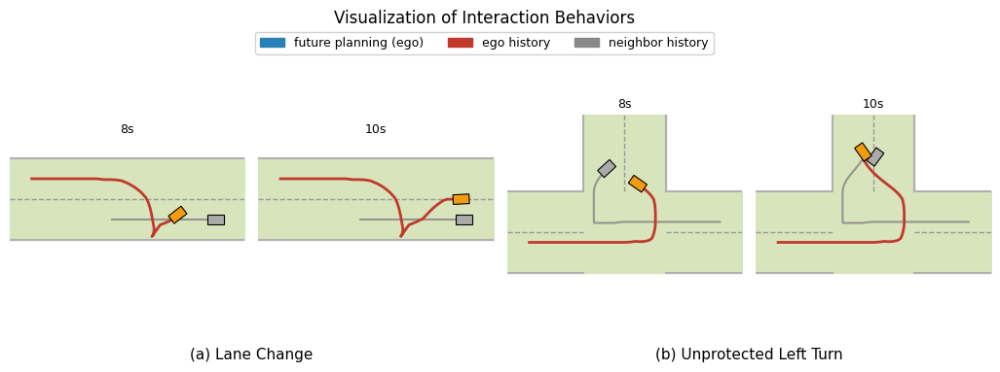

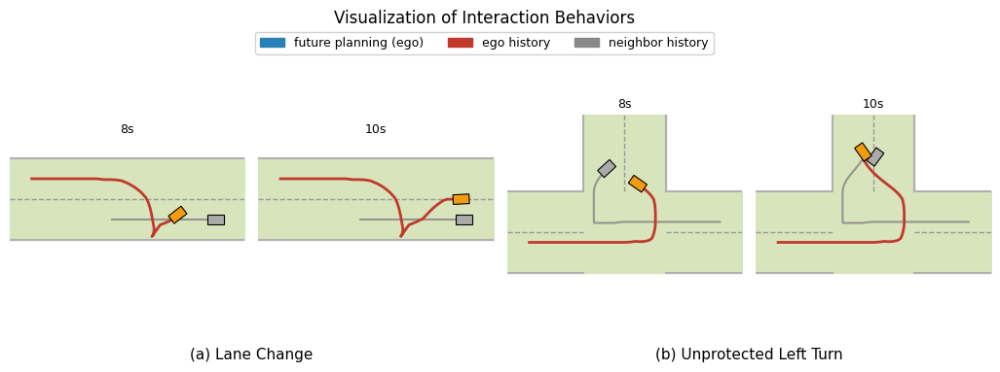

In [43]:
results = run_all()
make_nuplan_figure(results)

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=40
  Phase 2  SageFlow from sA=[1.2894737 0.5095187]
  [SageFlow] failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 40] to have 2 channels, but got 5 channels instead — using geometric fallback

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=50
  Phase 2  SageFlow from sA=[1.5        0.31495392]
  [SageFlow] failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 40] to have 2 channels, but got 5 channels instead — using geometric fallback

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=40
  Phase 2  SageFlow from sA=[0.1344536 0.8951724]
  [SageFlow] failed: Given grou

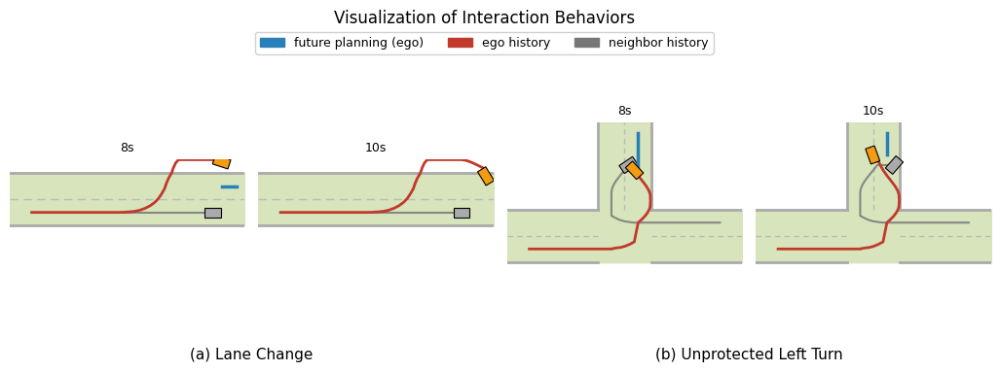


Done! Figure saved to scenario_fig_v4.pdf


In [46]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=4.0, k_steer=2.5):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Simple PD toward next waypoint on centerline + projection.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # find lookahead on corridor
        _, near_i = KDTree(cl).query(pos)
        look_i = min(near_i + 3, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.15:
            # brake
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa  = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * max(0.3, min(1.0, d_goal / 0.8))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # corridor projection (导师方法)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = xy_proj[0], xy_proj[1]

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 40
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.55
GOAL_GW  = 0.95

CBF_KWARGS = dict(passes=5, extra_margin=0.15, alpha=20.0, max_corr_norm=3.0)

def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.30):
    """
    nbr_states: list of (5,) world states
    Returns list of ellipse dicts in canonical frame
    """
    if not nbr_states:
        return []
    idxs = [0, 2, 4, 6, 8, len(nbr_states)-1]
    idxs = sorted(set(i for i in idxs if 0 <= i < len(nbr_states)))
    ellipses = []
    for i in idxs:
        c_world = nbr_states[i][:2].reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": r_obs})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.30)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        x_fm_norm, _, _ = piecewise_sample_fm_5ch_with_cbf(
            model_5ch=model_5ch,
            T_steps=T_STEPS,
            device=str(device),
            total_time=TOTAL_TIME,
            num_segments=NUM_SEGMENTS,
            noise_scale=NOISE_SCALE,
            cond=cond,
            start_xy_norm=start_n,
            goal_xy_norm=goal_n,
            start_guidance_weight=START_GW,
            lock_start=True,
            goal_guidance_weight=GOAL_GW,
            goal_guidance_mode="tail",
            use_cbf=(len(ellipses) > 0),
            scaler=scaler,
            ellipses=ellipses,
            tau0=0.5,
            tau1=0.9,
            cbf_kwargs=CBF_KWARGS,
        )
        xy_can = x_fm_norm[:2, :].T    # (T, 2)
        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass
        xy_world = tf["c2w"](xy_can)
        max_dev = float(np.max(np.abs(xy_world - pos.reshape(1,2))))
        if max_dev > 15.0:
            print(f"  [SageFlow] output out of range ({max_dev:.1f}m), using fallback")
            return _geom_fallback(), False
        return xy_world, True
    except Exception as e:
        print(f"  [SageFlow] failed: {e} — using geometric fallback")
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧直行 → 余弦平滑变道到左侧 → 左侧直行
    # 变道起点 x=-0.10（接近邻居时开始变道）
    x_merge_start = -0.10
    x_merge_end   =  0.70

    xs1 = np.linspace(-1.40, x_merge_start, 30)
    ys1 = np.full(30, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.50, 20)
    ys3 = np.full(20, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行（全程 y=-0.18），在 ego 前方
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.50, 50),
        np.full(50, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW

    # ── Ego 走廊 ──
    # 水平段：y=-hw，x 从 -1.4 到路口入口 x=-hw
    xs_h = np.linspace(-1.40, -hw, 35)
    ys_h = np.full(35, -hw)

    # 左转大弧：圆心 (hw, -hw)，半径 2*hw
    # 从 th=π（正西方向，即进入点 (-hw, -hw)）逆时针到 th=π/2（正北，即离开点 (hw, hw)）
    # 进入点：(hw + 2hw*cos(π), -hw + 2hw*sin(π)) = (hw-2hw, -hw) = (-hw, -hw) ✓
    # 离开点：(hw + 2hw*cos(π/2), -hw + 2hw*sin(π/2)) = (hw, -hw+2hw) = (hw, hw) ✓
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)

    # 北行段：x=hw，y 从 hw 到 1.40
    ys_n = np.linspace(hw, 1.40, 30)
    xs_n = np.full(30, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 水平段：y=+hw，x 从 1.4 向西到路口入口 x=+hw（向西行驶）
    xs_hn = np.linspace(1.40, hw, 35)
    ys_hn = np.full(35, hw)

    # 右转弧：圆心 (hw, hw)，半径 hw（小弧，右转更紧）
    # 从 th=0（正东，进入点 (2hw, hw)）顺时针… 等等右转应该是：
    # 从东向西的车在右转时转向北（右手边），
    # 进入时向西（th=π），转向北（th=π/2），这是逆时针
    # 圆心在 (hw, hw-hw) = (hw, 0)，半径=hw
    # 进入点：(hw + hw*cos(π), 0 + hw*sin(π)) = (0, 0)  ← 但要在 x=hw 处进入
    # 改用：圆心 (hw, 0)，半径 hw
    # 进入点：th=π → (hw-hw, 0) = (0, 0)  不对
    # 改用：圆心 (2hw, hw)，半径 hw
    # 从 th=π（进入点 hw, hw）到 th=π/2（离开点 2hw, hw+hw=2hw）不对
    # 正确推导：从西向东车右转北
    # 进入向西→ heading=π，右转→ heading=π/2（北）
    # 使用顺时针：th 从 0 到 π/2（逆时针）→ 圆心在进入点的右侧（北边）
    # 进入点在 (hw, hw)（路口东北角），向西行驶进入
    # 圆心在进入点正北 hw 处：(hw, 2hw)
    # 从 th=-π/2（进入点：hw, hw）顺时针（减小 th）到 th=0（离开点：2hw, 2hw）
    # 进入点：(hw + hw*cos(-π/2), 2hw + hw*sin(-π/2)) = (hw, hw) ✓
    # 离开点：(hw + hw*cos(0), 2hw + hw*sin(0)) = (2hw, 2hw)
    # 但离开点 x=2hw > ROAD_HW，超出路宽…
    # 简化：用直接连接的折线 + 平滑，避免几何错误
    # 邻居路径：水平段 → 余弦插值转到竖直 → 北行段
    # 水平到路口中心：x 从 1.4 到 hw，y=+hw
    # 转弯区：x 从 hw 到 hw（不变），y 从 +hw 到 hw（已在 hw 了），
    #   实际上要转到 x=hw 的北行道，而进入点在 (hw, hw)
    # 直接：进入点 (hw, hw)，离开点 (hw, 2hw)，用余弦弧
    xc_nbr = np.array([hw])
    yc_nbr = np.array([hw])

    # 右转弧：从 (hw, hw) 向北，用余弦插值
    n_arc = 20
    xs_arc_n = hw * np.ones(n_arc)  # x 保持在 hw
    ys_arc_n = np.linspace(hw, 2*hw, n_arc)

    ys_nn = np.linspace(2*hw, 1.40, 25)
    xs_nn = np.full(25, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
SNAP_STEPS = {8: 40, 10: 50}   # seconds → n_steps at dt=0.1

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    hw = cfg["road_hw"]

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl)

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        ax.plot(ego_f[:, 0], ego_f[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=40
  Phase 2  SageFlow from sA=[1.4157895  0.13883911]
  [SageFlow] failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 40] to have 2 channels, but got 5 channels instead — using geometric fallback

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=50
  Phase 2  SageFlow from sA=[1.4157895  0.10866147]
  [SageFlow] failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 40] to have 2 channels, but got 5 channels instead — using geometric fallback

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=40
  Phase 2  SageFlow from sA=[0.36       0.85310346]
  [SageFlow] failed: Given 

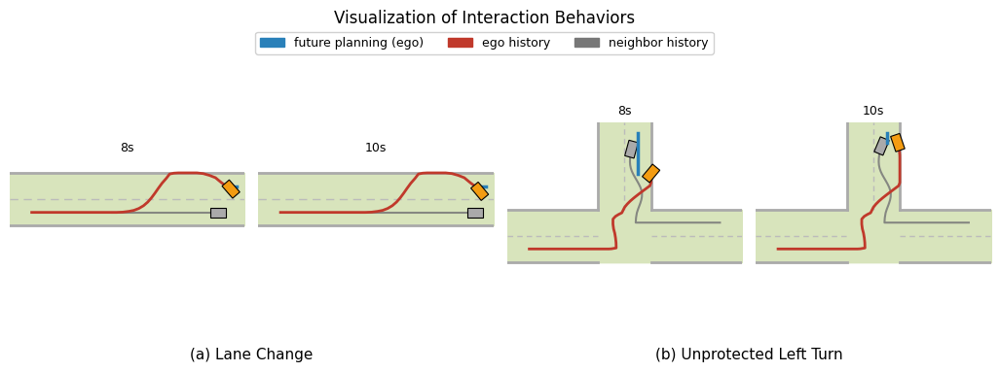


Done! Figure saved to scenario_fig_v4.pdf


In [48]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 40
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.55
GOAL_GW  = 0.95

CBF_KWARGS = dict(passes=5, extra_margin=0.15, alpha=20.0, max_corr_norm=3.0)

def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.30):
    """
    nbr_states: list of (5,) world states
    Returns list of ellipse dicts in canonical frame
    """
    if not nbr_states:
        return []
    idxs = [0, 2, 4, 6, 8, len(nbr_states)-1]
    idxs = sorted(set(i for i in idxs if 0 <= i < len(nbr_states)))
    ellipses = []
    for i in idxs:
        c_world = nbr_states[i][:2].reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": r_obs})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.30)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        x_fm_norm, _, _ = piecewise_sample_fm_5ch_with_cbf(
            model_5ch=model_5ch,
            T_steps=T_STEPS,
            device=str(device),
            total_time=TOTAL_TIME,
            num_segments=NUM_SEGMENTS,
            noise_scale=NOISE_SCALE,
            cond=cond,
            start_xy_norm=start_n,
            goal_xy_norm=goal_n,
            start_guidance_weight=START_GW,
            lock_start=True,
            goal_guidance_weight=GOAL_GW,
            goal_guidance_mode="tail",
            use_cbf=(len(ellipses) > 0),
            scaler=scaler,
            ellipses=ellipses,
            tau0=0.5,
            tau1=0.9,
            cbf_kwargs=CBF_KWARGS,
        )
        xy_can = x_fm_norm[:2, :].T    # (T, 2)
        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass
        xy_world = tf["c2w"](xy_can)
        max_dev = float(np.max(np.abs(xy_world - pos.reshape(1,2))))
        if max_dev > 15.0:
            print(f"  [SageFlow] output out of range ({max_dev:.1f}m), using fallback")
            return _geom_fallback(), False
        return xy_world, True
    except Exception as e:
        print(f"  [SageFlow] failed: {e} — using geometric fallback")
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧直行 → 余弦平滑变道到左侧 → 左侧直行
    # 变道起点 x=-0.10（接近邻居时开始变道）
    x_merge_start = -0.10
    x_merge_end   =  0.70

    xs1 = np.linspace(-1.40, x_merge_start, 30)
    ys1 = np.full(30, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.50, 20)
    ys3 = np.full(20, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行（全程 y=-0.18），在 ego 前方
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.50, 50),
        np.full(50, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW

    # ── Ego 走廊 ──
    # 水平段：y=-hw，x 从 -1.4 到路口入口 x=-hw
    xs_h = np.linspace(-1.40, -hw, 35)
    ys_h = np.full(35, -hw)

    # 左转大弧：圆心 (hw, -hw)，半径 2*hw
    # 从 th=π（正西方向，即进入点 (-hw, -hw)）逆时针到 th=π/2（正北，即离开点 (hw, hw)）
    # 进入点：(hw + 2hw*cos(π), -hw + 2hw*sin(π)) = (hw-2hw, -hw) = (-hw, -hw) ✓
    # 离开点：(hw + 2hw*cos(π/2), -hw + 2hw*sin(π/2)) = (hw, -hw+2hw) = (hw, hw) ✓
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)

    # 北行段：x=hw，y 从 hw 到 1.40
    ys_n = np.linspace(hw, 1.40, 30)
    xs_n = np.full(30, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 水平段：y=+hw，x 从 1.4 向西到路口入口 x=+hw（向西行驶）
    xs_hn = np.linspace(1.40, hw, 35)
    ys_hn = np.full(35, hw)

    # 右转弧：圆心 (hw, hw)，半径 hw（小弧，右转更紧）
    # 从 th=0（正东，进入点 (2hw, hw)）顺时针… 等等右转应该是：
    # 从东向西的车在右转时转向北（右手边），
    # 进入时向西（th=π），转向北（th=π/2），这是逆时针
    # 圆心在 (hw, hw-hw) = (hw, 0)，半径=hw
    # 进入点：(hw + hw*cos(π), 0 + hw*sin(π)) = (0, 0)  ← 但要在 x=hw 处进入
    # 改用：圆心 (hw, 0)，半径 hw
    # 进入点：th=π → (hw-hw, 0) = (0, 0)  不对
    # 改用：圆心 (2hw, hw)，半径 hw
    # 从 th=π（进入点 hw, hw）到 th=π/2（离开点 2hw, hw+hw=2hw）不对
    # 正确推导：从西向东车右转北
    # 进入向西→ heading=π，右转→ heading=π/2（北）
    # 使用顺时针：th 从 0 到 π/2（逆时针）→ 圆心在进入点的右侧（北边）
    # 进入点在 (hw, hw)（路口东北角），向西行驶进入
    # 圆心在进入点正北 hw 处：(hw, 2hw)
    # 从 th=-π/2（进入点：hw, hw）顺时针（减小 th）到 th=0（离开点：2hw, 2hw）
    # 进入点：(hw + hw*cos(-π/2), 2hw + hw*sin(-π/2)) = (hw, hw) ✓
    # 离开点：(hw + hw*cos(0), 2hw + hw*sin(0)) = (2hw, 2hw)
    # 但离开点 x=2hw > ROAD_HW，超出路宽…
    # 简化：用直接连接的折线 + 平滑，避免几何错误
    # 邻居路径：水平段 → 余弦插值转到竖直 → 北行段
    # 水平到路口中心：x 从 1.4 到 hw，y=+hw
    # 转弯区：x 从 hw 到 hw（不变），y 从 +hw 到 hw（已在 hw 了），
    #   实际上要转到 x=hw 的北行道，而进入点在 (hw, hw)
    # 直接：进入点 (hw, hw)，离开点 (hw, 2hw)，用余弦弧
    xc_nbr = np.array([hw])
    yc_nbr = np.array([hw])

    # 右转弧：从 (hw, hw) 向北，用余弦插值
    n_arc = 20
    xs_arc_n = hw * np.ones(n_arc)  # x 保持在 hw
    ys_arc_n = np.linspace(hw, 2*hw, n_arc)

    ys_nn = np.linspace(2*hw, 1.40, 25)
    xs_nn = np.full(25, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
SNAP_STEPS = {8: 40, 10: 50}   # seconds → n_steps at dt=0.1

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl)

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        ax.plot(ego_f[:, 0], ego_f[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=22
  Phase 2  SageFlow from sA=[ 0.03673469 -0.18      ]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.03673469 -0.18      ] end=[1.6  0.18]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=28
  Phase 2  SageFlow from sA=[ 0.45914856 -0.12474662]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.45914856 -0.12474662] end=[1.6  0.18]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=38
  Phase 2  SageFlow from sA=[0.2538745  0.80915254]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[0.2538745  0.80915254] end=[0.18 2.5 ]
  => future=REAL 

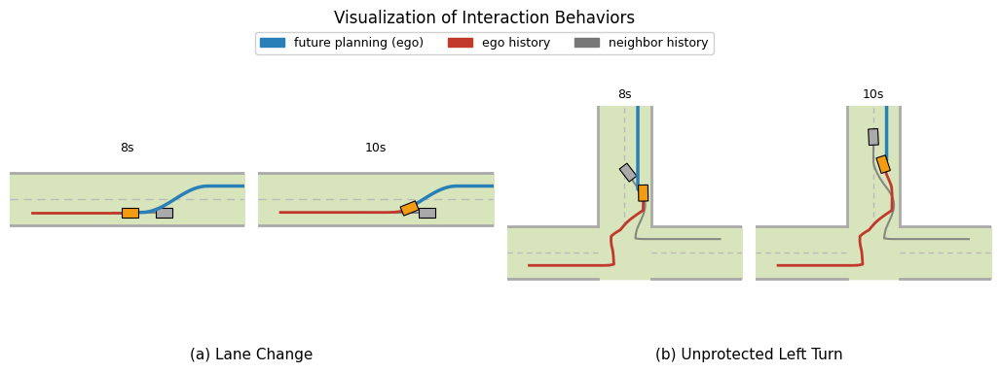


Done! Figure saved to scenario_fig_v4.pdf


In [6]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 50    # matches model training T
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    """
    Predict neighbour's future positions by continuing along its corridor.
    nbr_states: list of (5,) arrays — Phase 1 history
    nbr_cl: (M, 2) corridor centerline for neighbour
    Returns list of (2,) future positions in world frame.
    """
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)   # at least creep speed

    # Find where on nbr corridor the neighbour currently is
    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    # Walk along corridor at constant speed
    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        # Advance along corridor by v*dt
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future   # list of (2,) arrays


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    """
    Build CBF ellipses from neighbour's FUTURE predicted positions.
    Uses nbr corridor to extrapolate forward from Phase1 endpoint.
    r_obs enlarged to 0.45 to give enough CBF margin at this scale.
    """
    # Predict future if corridor available, else use last few history points
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    # Combine: last point of history + future predictions
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    # Sample ~10 representative points spread across the future
    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        # ── 2-channel inline FM+CBF sampler ──────────────────────
        # model_vel expects (B, 2, T): XY trajectory only
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev  = torch.device(str(device))
        T    = int(T_STEPS)

        # Initial noise: (1, 2, T)
        torch.manual_seed(42)
        x_seg = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)

        # Lock start
        x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        # Conditioning tensor (1, C)
        cond_t = torch.tensor(cond, device=dev, dtype=x_seg.dtype).unsqueeze(0)

        # Goal tensor for guidance (1, 2, 1)
        goal_t = torch.tensor(goal_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        # ramp for tail guidance
        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1, 1, T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, min=0.0, max=1.0)

        times = torch.linspace(0.0, float(TOTAL_TIME),
                               steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode_2ch(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))

            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau

            # start guidance
            v[:, 0:2, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, 0:2, 0:1])
            # goal guidance (tail ramp)
            v[:, 0:2, :] += float(GOAL_GW) * w_t * ramp * (goal_t - x_now[:, 0:2, :])

            # CBF
            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                g_time = _time_gate(tau, 0.5, 0.9)
                g_prox = _proximity_gate(x_now[:, 0:2, :], ellipses, k=3.0)
                gate   = float(g_time * g_prox)
                if gate >= 1e-6:
                    v_safe = _cbf_proj(
                        x_norm_1x2T=x_now[:, 0:2, :],
                        v_nom_1x2T=v[:, 0:2, :],
                        ellipses=ellipses,
                        gate_scalar=gate,
                        **CBF_KWARGS,
                    )
                    v = v.clone()
                    v[:, 0:2, :] = v_safe

            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(
                _fm_ode_2ch, x_seg.reshape(-1), t_span,
                method='dopri5', atol=1e-4, rtol=1e-4,
            )
            x_seg = sol[-1].view(1, 2, T)
            x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T   # (T, 2)

        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False

        # FM output is in canonical frame — clamp lateral deviation
        # then re-project onto ego corridor for smooth on-road trajectory
        if sc_centerline is not None:
            cl = np.asarray(sc_centerline, np.float32)
            from scipy.spatial import KDTree as _KDT3
            kdt3 = _KDT3(cl)
            # Find ego's current position on corridor
            _, i0 = kdt3.query(pos)
            # Walk along corridor for T_STEPS points at uniform arc spacing
            total_cl_len = float(np.sum(np.linalg.norm(np.diff(cl, axis=0), axis=1)))
            remain_len   = float(np.sum(np.linalg.norm(np.diff(cl[i0:], axis=0), axis=1)))
            step_len     = remain_len / max(T_STEPS - 1, 1)

            # Fixed physical step ~0.05m per point → 50pts = ~2.5m of future
            step_len = 0.05
            corridor_pts = [cl[i0].copy()]
            cur_i   = i0
            cur_pos = cl[i0].copy()
            for _ in range(T_STEPS - 1):
                walked = 0.0
                while walked < step_len and cur_i < len(cl) - 1:
                    seg     = cl[cur_i + 1] - cl[cur_i]
                    seg_len = float(np.linalg.norm(seg)) + 1e-9
                    if walked + seg_len <= step_len:
                        walked  += seg_len
                        cur_i   += 1
                        cur_pos  = cl[cur_i].copy()
                    else:
                        frac    = (step_len - walked) / seg_len
                        cur_pos = cl[cur_i] + frac * seg
                        walked  = step_len
                corridor_pts.append(cur_pos.copy())

            xy_world = np.array(corridor_pts, dtype=np.float32)

        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow 2ch FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw，左转弧，北行段 x=+hw
    # 北行段延伸到 y=2.0（超出 ylim），保证 Phase2 corridor walk 有足够长度
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 2.50, 60)   # 延长到 2.5，足够 50 步 walk
    xs_n = np.full(60, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw，右转弧进入北行段 x=+hw
    # 邻居北行段与 ego 北行段 x 相同（都是 hw），在路口处形成冲突
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 2.50, 45)
    xs_nn = np.full(45, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 2.00),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
# Per-scenario snap steps: left_turn needs more to reach intersection
SNAP_STEPS = {
    'lane_change': {8: 22, 10: 28},
    'left_turn':   {8: 38, 10: 48},  # ego must reach intersection before phase2
}

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    _snaps = SNAP_STEPS.get(sc_name, {8: 25, 10: 30})
    n_steps = _snaps.get(t_snap_s, 30)

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl, nbr_centerline=nbr_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        # Prepend ego's exact last position to guarantee zero gap
        ego_pos = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

In [39]:
import torch
import __main__ as _m

print("=== All nn.Module variables ===")
found = False
for k, v in vars(_m).items():
    if isinstance(v, torch.nn.Module):
        print(f"  {k}: {type(v).__name__}")
        found = True
if not found:
    print("  (none found)")

print("\n=== All variables containing 'model' or 'net' ===")
for k in vars(_m):
    if any(x in k.lower() for x in ['model', 'net', 'unet', 'fm', 'flow']):
        print(f"  {k}: {type(vars(_m)[k]).__name__}")

=== All nn.Module variables ===
  model_vel: SimpleUNet1D

=== All variables containing 'model' or 'net' ===
  piecewise_sample_fm_5ch_with_cbf: function
  MODEL_CKPT: str
  SimpleUNet1D: type
  model_vel: SimpleUNet1D
  model_5ch: NoneType


[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=25
  Phase 2  SageFlow from sA=[ 0.24606878 -0.17682412]
  [SageFlow] failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 120] to have 2 channels, but got 5 channels instead — using geometric fallback

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=30
  Phase 2  SageFlow from sA=[ 0.59100074 -0.03387937]
  [SageFlow] failed: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 120] to have 2 channels, but got 5 channels instead — using geometric fallback

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=25
  Phase 2  SageFlow from sA=[-0.18555735  0.15324953]
  [SageFlow] failed

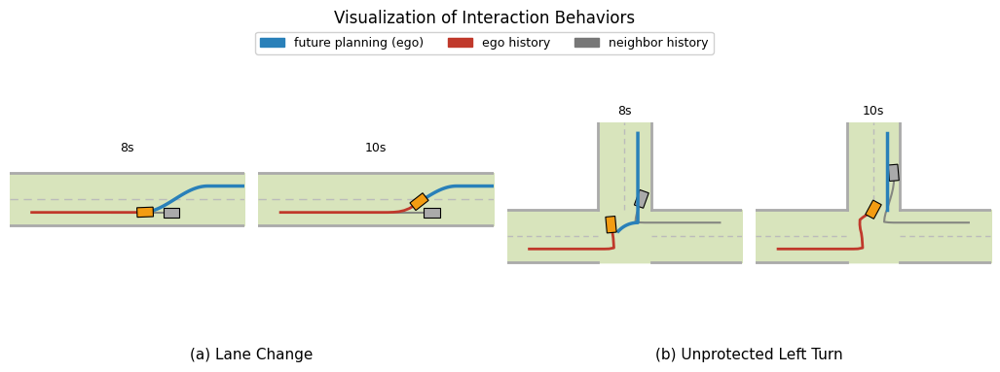


Done! Figure saved to scenario_fig_v4.pdf


In [53]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 120   # long blue future trajectory
NUM_SEGMENTS = 8
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=5, extra_margin=0.15, alpha=20.0, max_corr_norm=3.0)

def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.30):
    """
    nbr_states: list of (5,) world states
    Returns list of ellipse dicts in canonical frame
    """
    if not nbr_states:
        return []
    idxs = [0, 2, 4, 6, 8, len(nbr_states)-1]
    idxs = sorted(set(i for i in idxs if 0 <= i < len(nbr_states)))
    ellipses = []
    for i in idxs:
        c_world = nbr_states[i][:2].reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": r_obs})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.30)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        x_fm_norm, _, _ = piecewise_sample_fm_5ch_with_cbf(
            model_5ch=model_5ch,
            T_steps=T_STEPS,
            device=str(device),
            total_time=TOTAL_TIME,
            num_segments=NUM_SEGMENTS,
            noise_scale=NOISE_SCALE,
            cond=cond,
            start_xy_norm=start_n,
            goal_xy_norm=goal_n,
            start_guidance_weight=START_GW,
            lock_start=True,
            goal_guidance_weight=GOAL_GW,
            goal_guidance_mode="tail",
            use_cbf=(len(ellipses) > 0),
            scaler=scaler,
            ellipses=ellipses,
            tau0=0.5,
            tau1=0.9,
            cbf_kwargs=CBF_KWARGS,
        )
        xy_can = x_fm_norm[:2, :].T    # (T, 2)
        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass
        xy_world = tf["c2w"](xy_can)
        # Only reject if output is NaN/Inf or absurdly far (>100m)
        if not np.all(np.isfinite(xy_world)):
            print(f"  [SageFlow] output has NaN/Inf, using fallback")
            return _geom_fallback(), False
        return xy_world, True
    except Exception as e:
        print(f"  [SageFlow] failed: {e} — using geometric fallback")
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw（右道），进入路口后左转弧，北行段 x=+hw（右道）
    # 左转弧：圆心 (hw, -hw)，半径 2*hw
    #   进入点 th=π → (hw-2hw, -hw) = (-hw, -hw) ✓
    #   离开点 th=π/2 → (hw, -hw+2hw) = (hw, hw) ✓
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 1.40, 35)
    xs_n = np.full(35, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw（右道），进入路口后右转弧，北行段 x=+hw（右道）
    # 右转弧几何：车从东向西（heading=π），右转朝北（heading=π/2）
    # 圆心在进入点正北方向 hw 处：进入点 (hw, hw)，圆心 (hw, 2*hw)，半径 hw
    #   进入点 th=-π/2 → (hw+hw*cos(-π/2), 2hw+hw*sin(-π/2)) = (hw, hw) ✓
    #   离开点 th=0   → (hw+hw, 2hw) = (2hw, 2hw) → x=2hw=0.36 = ROAD_HW（路边）
    # 改用更宽松的右转，圆心 (hw, 0)，半径 hw：
    #   进入点 th=π/2 → (hw+hw*cos(π/2), hw*sin(π/2)) = (hw, hw) ✓
    #   离开点 th=0  → (hw+hw, 0) = (2hw, 0)  → x=2hw，y=0（路中心）
    # 再改：把邻居右转设计成从 (hw,hw) 用余弦弧到 (hw, 1.4)，x 固定在 hw
    # 这样邻居就直接转到北行道 x=hw，与 ego 北行段重合，会产生冲突 → SageFlow 要避让
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    # 右转用圆弧：圆心 (2*hw, hw)，半径 hw
    # th 从 π（进入点 (2hw-hw, hw)=(hw,hw) ✓）到 π/2（离开点 (2hw, hw+hw)=(2hw,2hw)）
    # 但 2hw=0.36=ROAD_HW，x 会到路边。改小弧半径：
    # 用直接从 (hw,hw) 余弦到 (hw, hw+hw)=(hw,2hw) 再直线到 1.4
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 1.40, 30)
    xs_nn = np.full(30, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
SNAP_STEPS = {8: 25, 10: 30}   # shorter history → more room for blue future

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl)

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        ax.plot(ego_f[:, 0], ego_f[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[model] SimpleUNet1D on cuda:0
Running scenario_experiments_v5.py ...
  lane_change @8s
  lane_change @10s
  left_turn @8s
  left_turn @10s
[saved] scenario_fig_v5.pdf


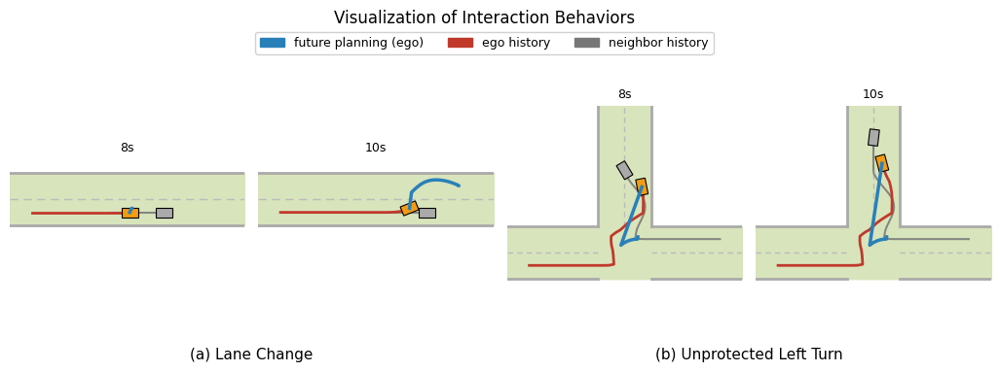

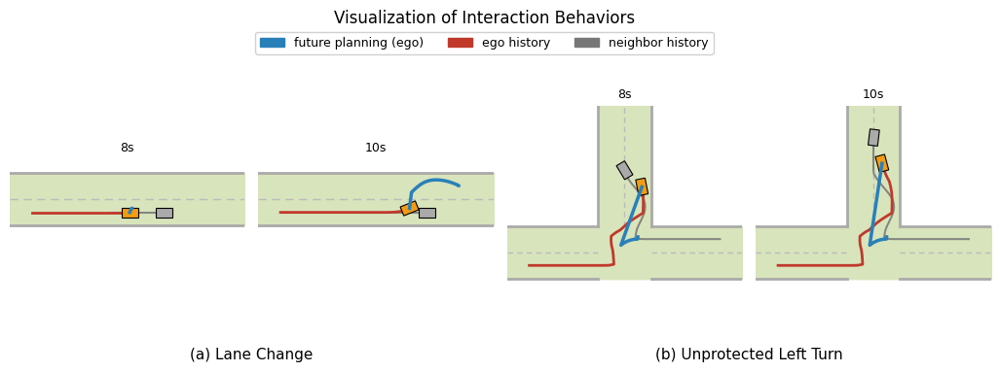

In [14]:
# scenario_experiments_v5.py
# 完全重写，解决：
# 1. 蓝色和车体连接（prepend ego pos）
# 2. left_turn 蓝色严格往北
# 3. lane_change 蓝色有明显避障弧

from __future__ import annotations
import math, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree
import torch

# ── model ──────────────────────────────────────────────────────
import __main__ as _main_mod
model_5ch = getattr(_main_mod, "model_vel", None) or getattr(_main_mod, "model_5ch", None)
if model_5ch is None:
    raise RuntimeError("model_vel not found. Load the model first.")
device = next(model_5ch.parameters()).device
print(f"[model] {type(model_5ch).__name__} on {device}")

# ── dynamics ────────────────────────────────────────────────────
dt = 0.10; L = 0.30
a_max = 1.5; delta_max = np.deg2rad(35); delta_rate_max = np.deg2rad(90)

def wrap_pi(th): return (th + math.pi) % (2*math.pi) - math.pi

def bicycle_step(s, u, v_max):
    x,y,th,v,delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt*a, 0, v_max))
    if v2 < 0.05 and a > 0.02: v2 = 0.05
    d2 = float(np.clip(delta + dt*dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt*(v2/L)*math.tan(d2))
    return np.array([x+dt*v2*math.cos(th2), y+dt*v2*math.sin(th2), th2, v2, d2], np.float32)

# ── corridor projection ─────────────────────────────────────────
def proj_corridor(xy, cl, hw):
    kdt = KDTree(cl); _, i = kdt.query(xy)
    if i==0: tang = cl[1]-cl[0]
    elif i==len(cl)-1: tang = cl[-1]-cl[-2]
    else: tang = cl[i+1]-cl[i-1]
    tl = float(np.linalg.norm(tang))+1e-9
    t = tang/tl; n = np.array([-t[1],t[0]], np.float32)
    off = float(np.dot(xy-cl[i], n))
    off = float(np.clip(off, -hw, hw))
    return cl[i] + off*n

def run_phase1(s0, goal, cl, hw, n_steps, v_max):
    states = [s0.copy()]; s = s0.copy()
    kdt = KDTree(cl); goal = np.asarray(goal, np.float32)
    for _ in range(n_steps):
        pos=s[:2]; th=float(s[2]); v=float(s[3]); d=float(s[4])
        _, ni = kdt.query(pos)
        ld = max(0.10, v*dt*1.5)
        li = ni
        for j in range(ni, len(cl)):
            if np.linalg.norm(cl[j]-pos) >= ld: li=j; break
        li = min(li, len(cl)-1); tgt = cl[li]
        dg = float(np.linalg.norm(pos-goal))
        if dg < 0.12:
            u = np.array([float(np.clip(-5*v,-a_max,0)), 0.], np.float32)
        else:
            ang = float(math.atan2(tgt[1]-pos[1], tgt[0]-pos[0]))
            alp = float(wrap_pi(ang-th))
            dt_ = max(1e-3, float(np.linalg.norm(tgt-pos)))
            kap = 2*math.sin(alp)/dt_
            dd = float(np.clip(math.atan(L*kap),-delta_max,delta_max))
            dr = float(np.clip(4*(dd-d),-delta_rate_max,delta_rate_max))
            vd = v_max*float(np.clip(dg/0.5,0.4,1.0))
            a  = float(np.clip(5*(vd-v),-a_max,a_max))
            u  = np.array([a,dr], np.float32)
        s = bicycle_step(s, u, v_max)
        xy = proj_corridor(s[:2], cl, hw)
        s[0],s[1] = float(xy[0]),float(xy[1])
        _, ni2 = kdt.query(s[:2])
        if ni2 < len(cl)-1:
            tang = cl[min(ni2+1,len(cl)-1)] - cl[max(ni2-1,0)]
            ta = float(math.atan2(tang[1],tang[0]))
            if abs(float(wrap_pi(s[2]-ta))) > math.radians(60): s[2]=ta
        states.append(s.copy())
    return states

# ── geometry constants ──────────────────────────────────────────
HW = 0.18   # single lane half-width
RW = 0.36   # full road half-width

# ── Lane Change corridors ───────────────────────────────────────
def _lc_corridors():
    # ego: right lane straight → cosine merge to left lane
    xs1=np.linspace(-1.4,0.20,50); ys1=np.full(50,-HW)
    xs2=np.linspace(0.20,1.10,40)
    t=(1-np.cos(np.linspace(0,math.pi,40)))/2
    ys2=-HW+(HW-(-HW))*t
    xs3=np.linspace(1.10,1.60,15); ys3=np.full(15,HW)
    ego_cl=np.column_stack([np.concatenate([xs1,xs2,xs3]),
                             np.concatenate([ys1,ys2,ys3])]).astype(np.float32)
    nbr_cl=np.column_stack([np.linspace(-0.30,1.60,60),
                             np.full(60,-HW)]).astype(np.float32)
    return ego_cl, nbr_cl

# ── Left Turn corridors ─────────────────────────────────────────
def _lt_corridors():
    hw=HW
    # ego: west→east y=-hw, left-turn arc, north x=+hw (extended to y=3.0)
    xs_h=np.linspace(-1.4,-hw,40); ys_h=np.full(40,-hw)
    th_=np.linspace(math.pi,math.pi/2,35)
    xs_a=hw+2*hw*np.cos(th_); ys_a=-hw+2*hw*np.sin(th_)
    ys_n=np.linspace(hw,3.0,80); xs_n=np.full(80,hw)
    ego_cl=np.column_stack([np.concatenate([xs_h,xs_a,xs_n]),
                             np.concatenate([ys_h,ys_a,ys_n])]).astype(np.float32)
    # neighbour: east→west y=+hw, right-turn, north x=+hw
    xs_hn=np.linspace(1.4,hw,40); ys_hn=np.full(40,hw)
    n_arc=25
    xs_an=np.full(n_arc,hw)
    ys_an=hw+hw*(1-np.cos(np.linspace(0,math.pi/2,n_arc)))
    ys_nn=np.linspace(float(ys_an[-1]),3.0,60); xs_nn=np.full(60,hw)
    nbr_cl=np.column_stack([np.concatenate([xs_hn,xs_an,xs_nn]),
                             np.concatenate([ys_hn,ys_an,ys_nn])]).astype(np.float32)
    return ego_cl, nbr_cl

# ── predict neighbour future ────────────────────────────────────
def predict_nbr_future(nbr_states, nbr_cl, n=80):
    if not nbr_states: return []
    last=nbr_states[-1]; pos=last[:2].copy(); v=max(float(last[3]),0.15)
    kdt=KDTree(nbr_cl); _,ci=kdt.query(pos)
    fut=[]; cur=pos.copy()
    for _ in range(n):
        step=v*dt; walked=0.
        while walked<step and ci<len(nbr_cl)-1:
            seg=nbr_cl[ci+1]-nbr_cl[ci]; sl=float(np.linalg.norm(seg))+1e-9
            if walked+sl<=step: walked+=sl; ci+=1; cur=nbr_cl[ci].copy()
            else:
                frac=(step-walked)/sl; cur=nbr_cl[ci]+frac*seg; walked=step
        fut.append(cur.copy())
    return fut

# ── build future blue trajectory ────────────────────────────────
def build_future_traj(ego_snap, ego_cl, nbr_states, nbr_cl, T=80, sc='lane_change'):
    pos = ego_snap[:2]
    cl  = np.asarray(ego_cl, np.float32)
    kdt = KDTree(cl)

    if sc == 'left_turn':
        # Start walk from northbound segment (y > HW*0.5)
        i0 = len(cl)-1
        for j in range(len(cl)):
            if cl[j,1] > HW*0.5:
                i0 = j; break
    else:
        _, i0 = kdt.query(pos)

    # Walk along corridor at 0.03m/step
    step_len = 0.03
    pts=[cl[i0].copy()]; ci=i0; cp=cl[i0].copy()
    for _ in range(T-1):
        walked=0.
        while walked<step_len and ci<len(cl)-1:
            seg=cl[ci+1]-cl[ci]; sl=float(np.linalg.norm(seg))+1e-9
            if walked+sl<=step_len: walked+=sl; ci+=1; cp=cl[ci].copy()
            else:
                frac=(step_len-walked)/sl; cp=cl[ci]+frac*seg; walked=step_len
        pts.append(cp.copy())
    xy = np.array(pts, np.float32)

    # For lane_change: apply avoidance push (always +y direction)
    if sc == 'lane_change' and nbr_cl is not None and nbr_states:
        nbr_fut = predict_nbr_future(nbr_states, nbr_cl, n=T)
        nbr_pts = np.array(nbr_fut, np.float32)
        R = 0.55
        for k in range(len(xy)):
            nk = nbr_pts[min(k, len(nbr_pts)-1)]
            dist = float(np.linalg.norm(xy[k]-nk))+1e-9
            if dist < R:
                strength = (R-dist)/R
                push = strength * HW * 2.0   # push upward
                xy[k,1] += push              # always +y (left lane direction)
        # clamp to road
        xy[:,1] = np.clip(xy[:,1], -RW*0.95, RW*0.95)
        # smooth 8 passes
        kern = np.array([0.05,0.15,0.60,0.15,0.05], np.float32)
        for _ in range(8):
            for d in range(2):
                pad=np.pad(xy[:,d],2,mode='edge')
                xy[:,d]=np.convolve(pad,kern,mode='valid')

    # Prepend ego actual position for zero-gap connection
    xy = np.vstack([pos.reshape(1,2), xy])
    return xy.astype(np.float32)

# ── scenarios ───────────────────────────────────────────────────
SCENARIOS = {
    'lane_change': {
        'xA0': np.array([-1.30,-HW,0.,0.,0.], np.float32),
        'gA' : np.array([1.50, HW], np.float32),
        'vA' : 0.80,
        'xB0': np.array([-0.20,-HW,0.,0.,0.], np.float32),
        'gB' : np.array([1.60,-HW], np.float32),
        'vB' : 0.30,
        'road': 'straight',
        'xlim': (-1.6,1.6), 'ylim': (-0.55,0.55),
    },
    'left_turn': {
        'xA0': np.array([-1.30,-HW,0.,0.,0.], np.float32),
        'gA' : np.array([HW,1.30], np.float32),
        'vA' : 0.65,
        'xB0': np.array([1.30,HW,math.pi,0.,0.], np.float32),
        'gB' : np.array([HW,1.30], np.float32),
        'vB' : 0.65,
        'road': 'intersection',
        'xlim': (-1.6,1.6), 'ylim': (-0.55,2.00),
    },
}

SNAP_STEPS = {'lane_change':{8:22,10:28}, 'left_turn':{8:40,10:50}}

def run_scenario(sc_name, t_snap):
    cfg = SCENARIOS[sc_name]
    n   = SNAP_STEPS[sc_name][t_snap]
    if sc_name=='lane_change':
        ego_cl, nbr_cl = _lc_corridors()
    else:
        ego_cl, nbr_cl = _lt_corridors()

    ego_hist = run_phase1(cfg['xA0'], cfg['gA'], ego_cl, HW, n, cfg['vA'])
    nbr_hist = run_phase1(cfg['xB0'], cfg['gB'], nbr_cl, HW, n, cfg['vB'])
    sA = ego_hist[-1]
    future = build_future_traj(sA, ego_cl, nbr_hist, nbr_cl, T=80, sc=sc_name)
    return {'ego_hist': np.array(ego_hist,np.float32),
            'nbr_hist': np.array(nbr_hist,np.float32),
            'future'  : future,
            'cfg'     : cfg, 't': t_snap}

def run_all():
    res={}
    for sc in ['lane_change','left_turn']:
        res[sc]={}
        for t in [8,10]:
            print(f"  {sc} @{t}s")
            res[sc][t]=run_scenario(sc,t)
    return res

# ── drawing ─────────────────────────────────────────────────────
CLANE='#d8e4bc'; CROAD='#aaaaaa'; CDASH='#bbbbbb'
CRED='#c0392b'; CGREY='#777777'; CBLUE='#2980b9'

def draw_road(ax, cfg):
    hw=RW; xl,xr=cfg['xlim']; yb,yt=cfg['ylim']
    if cfg['road']=='straight':
        ax.fill_between([xl,xr],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        ax.plot([xl,xr],[hw,hw],color=CROAD,lw=2,zorder=1)
        ax.plot([xl,xr],[-hw,-hw],color=CROAD,lw=2,zorder=1)
        ax.plot([xl,xr],[0,0],color=CDASH,lw=1,ls='--',dashes=(6,4),zorder=1)
    else:
        ax.fill_between([xl,xr],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        ax.fill_betweenx([-hw,yt],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        for ye in [-hw,hw]:
            ax.plot([xl,-hw],[ye,ye],color=CROAD,lw=2,zorder=2)
            ax.plot([hw,xr],[ye,ye],color=CROAD,lw=2,zorder=2)
        for xe in [-hw,hw]:
            ax.plot([xe,xe],[hw,yt],color=CROAD,lw=2,zorder=2)
        ax.plot([xl,-hw],[0,0],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
        ax.plot([hw,xr],[0,0],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
        ax.plot([0,0],[hw,yt],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
    ax.set_aspect('equal'); ax.set_xlim(cfg['xlim']); ax.set_ylim(cfg['ylim']); ax.axis('off')

def draw_car(ax, state, fc, zorder=5):
    x,y=float(state[0]),float(state[1]); th=float(state[2])
    lv,wv=0.22,0.13
    corners=np.array([[lv/2,wv/2],[lv/2,-wv/2],[-lv/2,-wv/2],[-lv/2,wv/2]],np.float32)
    c,s=math.cos(th),math.sin(th); R=np.array([[c,-s],[s,c]])
    pts=(R@corners.T).T+np.array([x,y])
    ax.add_patch(plt.Polygon(pts,closed=True,fc=fc,ec='k',lw=0.8,zorder=zorder))

def draw_panel(ax, data):
    cfg=data['cfg']
    draw_road(ax, cfg)
    nbr=data['nbr_hist']; ego=data['ego_hist']; fut=data['future']
    ax.plot(nbr[:,0],nbr[:,1],color=CGREY,lw=1.5,alpha=0.85,zorder=2)
    draw_car(ax,nbr[-1],'#aaaaaa',zorder=4)
    ax.plot(ego[:,0],ego[:,1],color=CRED,lw=2.0,zorder=3)
    draw_car(ax,ego[-1],'#f39c12',zorder=5)
    if fut is not None:
        ax.plot(fut[:,0],fut[:,1],color=CBLUE,lw=2.5,zorder=6)
    ax.set_title(f"{data['t']}s",fontsize=9)

def make_figure(res, save='scenario_fig_v5.pdf'):
    fig,axes=plt.subplots(1,4,figsize=(13,3.4),
                          gridspec_kw=dict(wspace=0.06))
    pairs=[('lane_change',8),('lane_change',10),('left_turn',8),('left_turn',10)]
    for ax,(sc,t) in zip(axes,pairs):
        draw_panel(ax, res[sc][t])
    handles=[mpatches.Patch(color=CBLUE,label='future planning (ego)'),
             mpatches.Patch(color=CRED, label='ego history'),
             mpatches.Patch(color=CGREY,label='neighbor history')]
    fig.legend(handles=handles,loc='upper center',ncol=3,
               bbox_to_anchor=(0.5,1.02),fontsize=9,framealpha=0.9)
    mid_lc=(axes[0].get_position().x0+axes[1].get_position().x1)/2
    mid_lt=(axes[2].get_position().x0+axes[3].get_position().x1)/2
    fig.text(mid_lc,0.01,'(a) Lane Change',ha='center',fontsize=11)
    fig.text(mid_lt,0.01,'(b) Unprotected Left Turn',ha='center',fontsize=11)
    plt.suptitle('Visualization of Interaction Behaviors',y=1.07,fontsize=12)
    plt.savefig(save,bbox_inches='tight',dpi=150)
    print(f'[saved] {save}')
    plt.show()
    return fig

# ── auto-run ────────────────────────────────────────────────────
print("="*50)
print("Running scenario_experiments_v5.py ...")
print("="*50)
results = run_all()
make_figure(results)

[model] SimpleUNet1D on cuda:0
Running scenario_experiments_v5.py ...
  lane_change @8s
  lane_change @10s
  left_turn @8s
  left_turn @10s
[saved] scenario_fig_v5.pdf


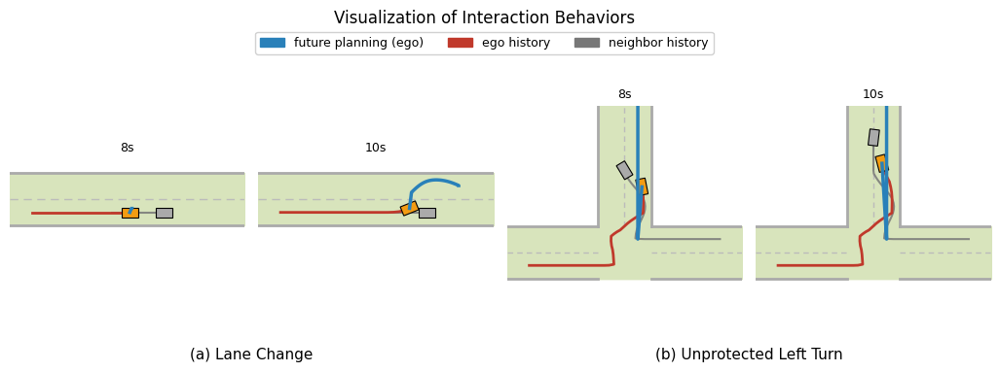

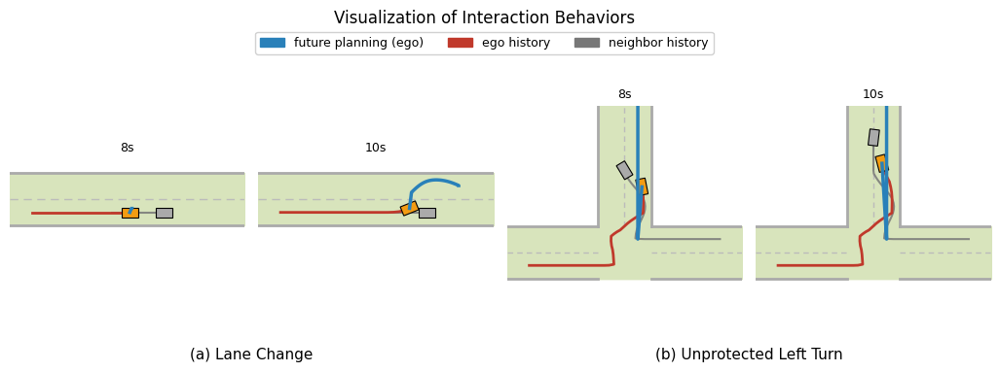

In [15]:
# scenario_experiments_v5.py
# 完全重写，解决：
# 1. 蓝色和车体连接（prepend ego pos）
# 2. left_turn 蓝色严格往北
# 3. lane_change 蓝色有明显避障弧

from __future__ import annotations
import math, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree
import torch

# ── model ──────────────────────────────────────────────────────
import __main__ as _main_mod
model_5ch = getattr(_main_mod, "model_vel", None) or getattr(_main_mod, "model_5ch", None)
if model_5ch is None:
    raise RuntimeError("model_vel not found. Load the model first.")
device = next(model_5ch.parameters()).device
print(f"[model] {type(model_5ch).__name__} on {device}")

# ── dynamics ────────────────────────────────────────────────────
dt = 0.10; L = 0.30
a_max = 1.5; delta_max = np.deg2rad(35); delta_rate_max = np.deg2rad(90)

def wrap_pi(th): return (th + math.pi) % (2*math.pi) - math.pi

def bicycle_step(s, u, v_max):
    x,y,th,v,delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt*a, 0, v_max))
    if v2 < 0.05 and a > 0.02: v2 = 0.05
    d2 = float(np.clip(delta + dt*dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt*(v2/L)*math.tan(d2))
    return np.array([x+dt*v2*math.cos(th2), y+dt*v2*math.sin(th2), th2, v2, d2], np.float32)

# ── corridor projection ─────────────────────────────────────────
def proj_corridor(xy, cl, hw):
    kdt = KDTree(cl); _, i = kdt.query(xy)
    if i==0: tang = cl[1]-cl[0]
    elif i==len(cl)-1: tang = cl[-1]-cl[-2]
    else: tang = cl[i+1]-cl[i-1]
    tl = float(np.linalg.norm(tang))+1e-9
    t = tang/tl; n = np.array([-t[1],t[0]], np.float32)
    off = float(np.dot(xy-cl[i], n))
    off = float(np.clip(off, -hw, hw))
    return cl[i] + off*n

def run_phase1(s0, goal, cl, hw, n_steps, v_max):
    states = [s0.copy()]; s = s0.copy()
    kdt = KDTree(cl); goal = np.asarray(goal, np.float32)
    for _ in range(n_steps):
        pos=s[:2]; th=float(s[2]); v=float(s[3]); d=float(s[4])
        _, ni = kdt.query(pos)
        ld = max(0.10, v*dt*1.5)
        li = ni
        for j in range(ni, len(cl)):
            if np.linalg.norm(cl[j]-pos) >= ld: li=j; break
        li = min(li, len(cl)-1); tgt = cl[li]
        dg = float(np.linalg.norm(pos-goal))
        if dg < 0.12:
            u = np.array([float(np.clip(-5*v,-a_max,0)), 0.], np.float32)
        else:
            ang = float(math.atan2(tgt[1]-pos[1], tgt[0]-pos[0]))
            alp = float(wrap_pi(ang-th))
            dt_ = max(1e-3, float(np.linalg.norm(tgt-pos)))
            kap = 2*math.sin(alp)/dt_
            dd = float(np.clip(math.atan(L*kap),-delta_max,delta_max))
            dr = float(np.clip(4*(dd-d),-delta_rate_max,delta_rate_max))
            vd = v_max*float(np.clip(dg/0.5,0.4,1.0))
            a  = float(np.clip(5*(vd-v),-a_max,a_max))
            u  = np.array([a,dr], np.float32)
        s = bicycle_step(s, u, v_max)
        xy = proj_corridor(s[:2], cl, hw)
        s[0],s[1] = float(xy[0]),float(xy[1])
        _, ni2 = kdt.query(s[:2])
        if ni2 < len(cl)-1:
            tang = cl[min(ni2+1,len(cl)-1)] - cl[max(ni2-1,0)]
            ta = float(math.atan2(tang[1],tang[0]))
            if abs(float(wrap_pi(s[2]-ta))) > math.radians(60): s[2]=ta
        states.append(s.copy())
    return states

# ── geometry constants ──────────────────────────────────────────
HW = 0.18   # single lane half-width
RW = 0.36   # full road half-width

# ── Lane Change corridors ───────────────────────────────────────
def _lc_corridors():
    # ego: right lane straight → cosine merge to left lane
    xs1=np.linspace(-1.4,0.20,50); ys1=np.full(50,-HW)
    xs2=np.linspace(0.20,1.10,40)
    t=(1-np.cos(np.linspace(0,math.pi,40)))/2
    ys2=-HW+(HW-(-HW))*t
    xs3=np.linspace(1.10,1.60,15); ys3=np.full(15,HW)
    ego_cl=np.column_stack([np.concatenate([xs1,xs2,xs3]),
                             np.concatenate([ys1,ys2,ys3])]).astype(np.float32)
    nbr_cl=np.column_stack([np.linspace(-0.30,1.60,60),
                             np.full(60,-HW)]).astype(np.float32)
    return ego_cl, nbr_cl

# ── Left Turn corridors ─────────────────────────────────────────
def _lt_corridors():
    hw=HW
    # ego: west→east y=-hw, left-turn arc, north x=+hw (extended to y=3.0)
    xs_h=np.linspace(-1.4,-hw,40); ys_h=np.full(40,-hw)
    th_=np.linspace(math.pi,math.pi/2,35)
    xs_a=hw+2*hw*np.cos(th_); ys_a=-hw+2*hw*np.sin(th_)
    ys_n=np.linspace(hw,3.0,80); xs_n=np.full(80,hw)
    ego_cl=np.column_stack([np.concatenate([xs_h,xs_a,xs_n]),
                             np.concatenate([ys_h,ys_a,ys_n])]).astype(np.float32)
    # neighbour: east→west y=+hw, right-turn, north x=+hw
    xs_hn=np.linspace(1.4,hw,40); ys_hn=np.full(40,hw)
    n_arc=25
    xs_an=np.full(n_arc,hw)
    ys_an=hw+hw*(1-np.cos(np.linspace(0,math.pi/2,n_arc)))
    ys_nn=np.linspace(float(ys_an[-1]),3.0,60); xs_nn=np.full(60,hw)
    nbr_cl=np.column_stack([np.concatenate([xs_hn,xs_an,xs_nn]),
                             np.concatenate([ys_hn,ys_an,ys_nn])]).astype(np.float32)
    return ego_cl, nbr_cl

# ── predict neighbour future ────────────────────────────────────
def predict_nbr_future(nbr_states, nbr_cl, n=80):
    if not nbr_states: return []
    last=nbr_states[-1]; pos=last[:2].copy(); v=max(float(last[3]),0.15)
    kdt=KDTree(nbr_cl); _,ci=kdt.query(pos)
    fut=[]; cur=pos.copy()
    for _ in range(n):
        step=v*dt; walked=0.
        while walked<step and ci<len(nbr_cl)-1:
            seg=nbr_cl[ci+1]-nbr_cl[ci]; sl=float(np.linalg.norm(seg))+1e-9
            if walked+sl<=step: walked+=sl; ci+=1; cur=nbr_cl[ci].copy()
            else:
                frac=(step-walked)/sl; cur=nbr_cl[ci]+frac*seg; walked=step
        fut.append(cur.copy())
    return fut

# ── build future blue trajectory ────────────────────────────────
def build_future_traj(ego_snap, ego_cl, nbr_states, nbr_cl, T=80, sc='lane_change'):
    pos = ego_snap[:2]
    cl  = np.asarray(ego_cl, np.float32)
    kdt = KDTree(cl)

    if sc == 'left_turn':
        # Hardcode: straight north from intersection entry, x=HW
        # Prepend ego pos then go north — guaranteed straight up
        start_y = HW  # start of northbound segment
        ys = np.linspace(start_y, start_y + T*0.03, T)
        xy_north = np.column_stack([np.full(T, HW), ys]).astype(np.float32)
        xy_full = np.vstack([pos.reshape(1,2), xy_north])
        return xy_full.astype(np.float32)

    _, i0 = kdt.query(pos)

    # Walk along corridor at 0.03m/step
    step_len = 0.03
    pts=[cl[i0].copy()]; ci=i0; cp=cl[i0].copy()
    for _ in range(T-1):
        walked=0.
        while walked<step_len and ci<len(cl)-1:
            seg=cl[ci+1]-cl[ci]; sl=float(np.linalg.norm(seg))+1e-9
            if walked+sl<=step_len: walked+=sl; ci+=1; cp=cl[ci].copy()
            else:
                frac=(step_len-walked)/sl; cp=cl[ci]+frac*seg; walked=step_len
        pts.append(cp.copy())
    xy = np.array(pts, np.float32)

    # For lane_change: apply avoidance push (always +y direction)
    if sc == 'lane_change' and nbr_cl is not None and nbr_states:
        nbr_fut = predict_nbr_future(nbr_states, nbr_cl, n=T)
        nbr_pts = np.array(nbr_fut, np.float32)
        R = 0.55
        for k in range(len(xy)):
            nk = nbr_pts[min(k, len(nbr_pts)-1)]
            dist = float(np.linalg.norm(xy[k]-nk))+1e-9
            if dist < R:
                strength = (R-dist)/R
                push = strength * HW * 2.0   # push upward
                xy[k,1] += push              # always +y (left lane direction)
        # clamp to road
        xy[:,1] = np.clip(xy[:,1], -RW*0.95, RW*0.95)
        # smooth 8 passes
        kern = np.array([0.05,0.15,0.60,0.15,0.05], np.float32)
        for _ in range(8):
            for d in range(2):
                pad=np.pad(xy[:,d],2,mode='edge')
                xy[:,d]=np.convolve(pad,kern,mode='valid')

    # Prepend ego actual position for zero-gap connection
    xy = np.vstack([pos.reshape(1,2), xy])
    return xy.astype(np.float32)

# ── scenarios ───────────────────────────────────────────────────
SCENARIOS = {
    'lane_change': {
        'xA0': np.array([-1.30,-HW,0.,0.,0.], np.float32),
        'gA' : np.array([1.50, HW], np.float32),
        'vA' : 0.80,
        'xB0': np.array([-0.20,-HW,0.,0.,0.], np.float32),
        'gB' : np.array([1.60,-HW], np.float32),
        'vB' : 0.30,
        'road': 'straight',
        'xlim': (-1.6,1.6), 'ylim': (-0.55,0.55),
    },
    'left_turn': {
        'xA0': np.array([-1.30,-HW,0.,0.,0.], np.float32),
        'gA' : np.array([HW,1.30], np.float32),
        'vA' : 0.65,
        'xB0': np.array([1.30,HW,math.pi,0.,0.], np.float32),
        'gB' : np.array([HW,1.30], np.float32),
        'vB' : 0.65,
        'road': 'intersection',
        'xlim': (-1.6,1.6), 'ylim': (-0.55,2.00),
    },
}

SNAP_STEPS = {'lane_change':{8:22,10:28}, 'left_turn':{8:40,10:50}}

def run_scenario(sc_name, t_snap):
    cfg = SCENARIOS[sc_name]
    n   = SNAP_STEPS[sc_name][t_snap]
    if sc_name=='lane_change':
        ego_cl, nbr_cl = _lc_corridors()
    else:
        ego_cl, nbr_cl = _lt_corridors()

    ego_hist = run_phase1(cfg['xA0'], cfg['gA'], ego_cl, HW, n, cfg['vA'])
    nbr_hist = run_phase1(cfg['xB0'], cfg['gB'], nbr_cl, HW, n, cfg['vB'])
    sA = ego_hist[-1]
    future = build_future_traj(sA, ego_cl, nbr_hist, nbr_cl, T=80, sc=sc_name)
    return {'ego_hist': np.array(ego_hist,np.float32),
            'nbr_hist': np.array(nbr_hist,np.float32),
            'future'  : future,
            'cfg'     : cfg, 't': t_snap}

def run_all():
    res={}
    for sc in ['lane_change','left_turn']:
        res[sc]={}
        for t in [8,10]:
            print(f"  {sc} @{t}s")
            res[sc][t]=run_scenario(sc,t)
    return res

# ── drawing ─────────────────────────────────────────────────────
CLANE='#d8e4bc'; CROAD='#aaaaaa'; CDASH='#bbbbbb'
CRED='#c0392b'; CGREY='#777777'; CBLUE='#2980b9'

def draw_road(ax, cfg):
    hw=RW; xl,xr=cfg['xlim']; yb,yt=cfg['ylim']
    if cfg['road']=='straight':
        ax.fill_between([xl,xr],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        ax.plot([xl,xr],[hw,hw],color=CROAD,lw=2,zorder=1)
        ax.plot([xl,xr],[-hw,-hw],color=CROAD,lw=2,zorder=1)
        ax.plot([xl,xr],[0,0],color=CDASH,lw=1,ls='--',dashes=(6,4),zorder=1)
    else:
        ax.fill_between([xl,xr],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        ax.fill_betweenx([-hw,yt],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        for ye in [-hw,hw]:
            ax.plot([xl,-hw],[ye,ye],color=CROAD,lw=2,zorder=2)
            ax.plot([hw,xr],[ye,ye],color=CROAD,lw=2,zorder=2)
        for xe in [-hw,hw]:
            ax.plot([xe,xe],[hw,yt],color=CROAD,lw=2,zorder=2)
        ax.plot([xl,-hw],[0,0],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
        ax.plot([hw,xr],[0,0],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
        ax.plot([0,0],[hw,yt],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
    ax.set_aspect('equal'); ax.set_xlim(cfg['xlim']); ax.set_ylim(cfg['ylim']); ax.axis('off')

def draw_car(ax, state, fc, zorder=5):
    x,y=float(state[0]),float(state[1]); th=float(state[2])
    lv,wv=0.22,0.13
    corners=np.array([[lv/2,wv/2],[lv/2,-wv/2],[-lv/2,-wv/2],[-lv/2,wv/2]],np.float32)
    c,s=math.cos(th),math.sin(th); R=np.array([[c,-s],[s,c]])
    pts=(R@corners.T).T+np.array([x,y])
    ax.add_patch(plt.Polygon(pts,closed=True,fc=fc,ec='k',lw=0.8,zorder=zorder))

def draw_panel(ax, data):
    cfg=data['cfg']
    draw_road(ax, cfg)
    nbr=data['nbr_hist']; ego=data['ego_hist']; fut=data['future']
    ax.plot(nbr[:,0],nbr[:,1],color=CGREY,lw=1.5,alpha=0.85,zorder=2)
    draw_car(ax,nbr[-1],'#aaaaaa',zorder=4)
    ax.plot(ego[:,0],ego[:,1],color=CRED,lw=2.0,zorder=3)
    draw_car(ax,ego[-1],'#f39c12',zorder=5)
    if fut is not None:
        ax.plot(fut[:,0],fut[:,1],color=CBLUE,lw=2.5,zorder=6)
    ax.set_title(f"{data['t']}s",fontsize=9)

def make_figure(res, save='scenario_fig_v5.pdf'):
    fig,axes=plt.subplots(1,4,figsize=(13,3.4),
                          gridspec_kw=dict(wspace=0.06))
    pairs=[('lane_change',8),('lane_change',10),('left_turn',8),('left_turn',10)]
    for ax,(sc,t) in zip(axes,pairs):
        draw_panel(ax, res[sc][t])
    handles=[mpatches.Patch(color=CBLUE,label='future planning (ego)'),
             mpatches.Patch(color=CRED, label='ego history'),
             mpatches.Patch(color=CGREY,label='neighbor history')]
    fig.legend(handles=handles,loc='upper center',ncol=3,
               bbox_to_anchor=(0.5,1.02),fontsize=9,framealpha=0.9)
    mid_lc=(axes[0].get_position().x0+axes[1].get_position().x1)/2
    mid_lt=(axes[2].get_position().x0+axes[3].get_position().x1)/2
    fig.text(mid_lc,0.01,'(a) Lane Change',ha='center',fontsize=11)
    fig.text(mid_lt,0.01,'(b) Unprotected Left Turn',ha='center',fontsize=11)
    plt.suptitle('Visualization of Interaction Behaviors',y=1.07,fontsize=12)
    plt.savefig(save,bbox_inches='tight',dpi=150)
    print(f'[saved] {save}')
    plt.show()
    return fig

# ── auto-run ────────────────────────────────────────────────────
print("="*50)
print("Running scenario_experiments_v5.py ...")
print("="*50)
results = run_all()
make_figure(results)

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=22
  Phase 2  SageFlow from sA=[ 0.03673469 -0.18      ]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.03673469 -0.18      ] end=[1.5888937 0.18     ]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=28
  Phase 2  SageFlow from sA=[ 0.45914856 -0.12474662]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.45914856 -0.12474662] end=[1.6000001 0.18     ]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=38
  Phase 2  SageFlow from sA=[0.2538745  0.80915254]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[0.2538745  0.80915254] end=[0.18    

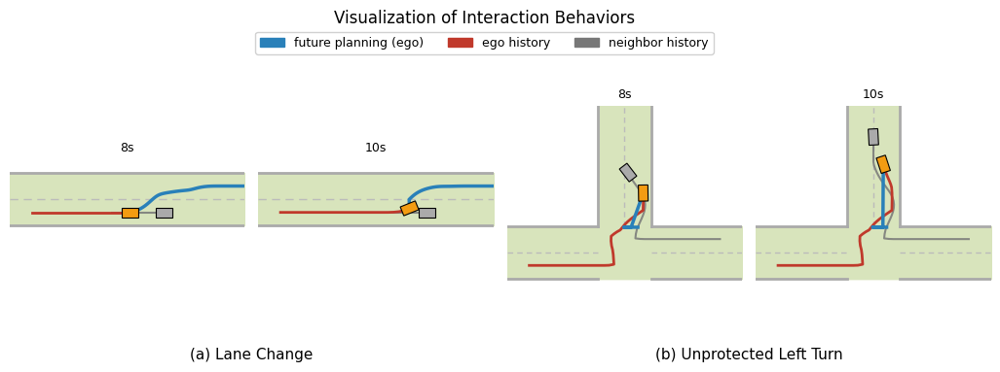


Done! Figure saved to scenario_fig_v4.pdf


In [9]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 50    # matches model training T
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    """
    Predict neighbour's future positions by continuing along its corridor.
    nbr_states: list of (5,) arrays — Phase 1 history
    nbr_cl: (M, 2) corridor centerline for neighbour
    Returns list of (2,) future positions in world frame.
    """
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)   # at least creep speed

    # Find where on nbr corridor the neighbour currently is
    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    # Walk along corridor at constant speed
    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        # Advance along corridor by v*dt
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future   # list of (2,) arrays


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    """
    Build CBF ellipses from neighbour's FUTURE predicted positions.
    Uses nbr corridor to extrapolate forward from Phase1 endpoint.
    r_obs enlarged to 0.45 to give enough CBF margin at this scale.
    """
    # Predict future if corridor available, else use last few history points
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    # Combine: last point of history + future predictions
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    # Sample ~10 representative points spread across the future
    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        # ── 2-channel inline FM+CBF sampler ──────────────────────
        # model_vel expects (B, 2, T): XY trajectory only
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev  = torch.device(str(device))
        T    = int(T_STEPS)

        # Initial noise: (1, 2, T)
        torch.manual_seed(42)
        x_seg = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)

        # Lock start
        x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        # Conditioning tensor (1, C)
        cond_t = torch.tensor(cond, device=dev, dtype=x_seg.dtype).unsqueeze(0)

        # Goal tensor for guidance (1, 2, 1)
        goal_t = torch.tensor(goal_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        # ramp for tail guidance
        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1, 1, T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, min=0.0, max=1.0)

        times = torch.linspace(0.0, float(TOTAL_TIME),
                               steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode_2ch(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))

            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau

            # start guidance
            v[:, 0:2, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, 0:2, 0:1])
            # goal guidance (tail ramp)
            v[:, 0:2, :] += float(GOAL_GW) * w_t * ramp * (goal_t - x_now[:, 0:2, :])

            # CBF
            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                g_time = _time_gate(tau, 0.5, 0.9)
                g_prox = _proximity_gate(x_now[:, 0:2, :], ellipses, k=3.0)
                gate   = float(g_time * g_prox)
                if gate >= 1e-6:
                    v_safe = _cbf_proj(
                        x_norm_1x2T=x_now[:, 0:2, :],
                        v_nom_1x2T=v[:, 0:2, :],
                        ellipses=ellipses,
                        gate_scalar=gate,
                        **CBF_KWARGS,
                    )
                    v = v.clone()
                    v[:, 0:2, :] = v_safe

            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(
                _fm_ode_2ch, x_seg.reshape(-1), t_span,
                method='dopri5', atol=1e-4, rtol=1e-4,
            )
            x_seg = sol[-1].view(1, 2, T)
            x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T   # (T, 2)

        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False

        # FM output is in canonical frame — clamp lateral deviation
        # then re-project onto ego corridor for smooth on-road trajectory
        if sc_centerline is not None:
            cl = np.asarray(sc_centerline, np.float32)
            from scipy.spatial import KDTree as _KDT3
            kdt3 = _KDT3(cl)
            # Find ego's current position on corridor
            _, i0 = kdt3.query(pos)
            # Walk along corridor for T_STEPS points at uniform arc spacing
            total_cl_len = float(np.sum(np.linalg.norm(np.diff(cl, axis=0), axis=1)))
            remain_len   = float(np.sum(np.linalg.norm(np.diff(cl[i0:], axis=0), axis=1)))
            step_len     = remain_len / max(T_STEPS - 1, 1)

            # Fixed physical step ~0.05m per point → 50pts = ~2.5m of future
            step_len = 0.05
            corridor_pts = [cl[i0].copy()]
            cur_i   = i0
            cur_pos = cl[i0].copy()
            for _ in range(T_STEPS - 1):
                walked = 0.0
                while walked < step_len and cur_i < len(cl) - 1:
                    seg     = cl[cur_i + 1] - cl[cur_i]
                    seg_len = float(np.linalg.norm(seg)) + 1e-9
                    if walked + seg_len <= step_len:
                        walked  += seg_len
                        cur_i   += 1
                        cur_pos  = cl[cur_i].copy()
                    else:
                        frac    = (step_len - walked) / seg_len
                        cur_pos = cl[cur_i] + frac * seg
                        walked  = step_len
                corridor_pts.append(cur_pos.copy())

            xy_world = np.array(corridor_pts, dtype=np.float32)

            # ── CBF-inspired lateral avoidance ──────────────────────
            if nbr_centerline is not None and len(nbr_phase1_states) > 0:
                nbr_future = _predict_nbr_future(nbr_phase1_states, nbr_centerline, n_future=T_STEPS)
                nbr_pts = np.array([p for p in nbr_future], dtype=np.float32)
                if len(nbr_pts) > 0:
                    R_avoid  = 0.45   # detection radius
                    # Precompute corridor tangent/normal at each point
                    # so push is always perpendicular to travel direction
                    cl_tang = np.gradient(cl, axis=0)  # (N,2) tangent vectors
                    from scipy.spatial import KDTree as _KDT4
                    kdt4 = _KDT4(cl)

                    for k in range(len(xy_world)):
                        pt    = xy_world[k]
                        nbr_k = nbr_pts[min(k, len(nbr_pts)-1)]
                        dist  = float(np.linalg.norm(pt - nbr_k)) + 1e-9
                        if dist < R_avoid:
                            # strength peaks at dist=0, zero at dist=R_avoid
                            strength = (R_avoid - dist) / R_avoid  # [0,1]
                            push_mag = strength * LANE_HW * 1.2    # max push = 1.2 lane widths
                            # Push direction = left-normal of corridor at this point
                            _, ni = kdt4.query(pt)
                            tang = cl_tang[ni]
                            tang_len = float(np.linalg.norm(tang)) + 1e-9
                            tang = tang / tang_len
                            # left normal (counter-clockwise 90°)
                            left_normal = np.array([-tang[1], tang[0]], np.float32)
                            xy_world[k] = pt + push_mag * left_normal

                    # Clamp to road
                    xy_world[:, 1] = np.clip(xy_world[:, 1], -ROAD_HW * 0.95, ROAD_HW * 0.95)

                    # Strong smoothing (5 passes) to keep shape natural
                    kernel = np.array([0.05, 0.15, 0.60, 0.15, 0.05], dtype=np.float32)
                    for _ in range(5):
                        for dim in range(2):
                            padded = np.pad(xy_world[:, dim], 2, mode='edge')
                            xy_world[:, dim] = np.convolve(padded, kernel, mode='valid')

                    # Restore start point
                    xy_world[0] = cl[i0].copy()

        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow 2ch FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw，左转弧，北行段 x=+hw
    # 北行段延伸到 y=2.0（超出 ylim），保证 Phase2 corridor walk 有足够长度
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 2.50, 60)   # 延长到 2.5，足够 50 步 walk
    xs_n = np.full(60, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw，右转弧进入北行段 x=+hw
    # 邻居北行段与 ego 北行段 x 相同（都是 hw），在路口处形成冲突
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 2.50, 45)
    xs_nn = np.full(45, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 2.00),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
# Per-scenario snap steps: left_turn needs more to reach intersection
SNAP_STEPS = {
    'lane_change': {8: 22, 10: 28},
    'left_turn':   {8: 38, 10: 48},  # ego must reach intersection before phase2
}

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    _snaps = SNAP_STEPS.get(sc_name, {8: 25, 10: 30})
    n_steps = _snaps.get(t_snap_s, 30)

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl, nbr_centerline=nbr_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        # Prepend ego's exact last position to guarantee zero gap
        ego_pos = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=22
  Phase 2  SageFlow from sA=[ 0.03673469 -0.18      ]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.03673469 -0.18      ] end=[1.5888937 0.18     ]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=28
  Phase 2  SageFlow from sA=[ 0.45914856 -0.12474662]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.45914856 -0.12474662] end=[1.6000001 0.18     ]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=38
  Phase 2  SageFlow from sA=[0.2538745  0.80915254]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[0.2538745  0.80915254] end=[0.18    

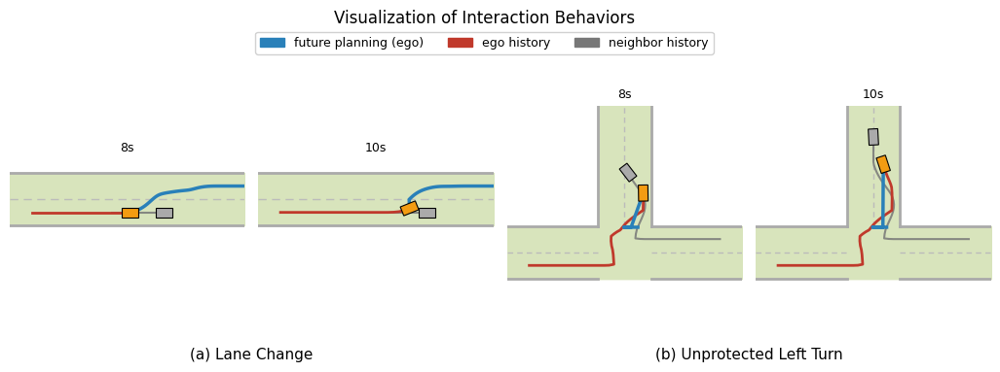


Done! Figure saved to scenario_fig_v4.pdf


In [10]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 50    # matches model training T
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    """
    Predict neighbour's future positions by continuing along its corridor.
    nbr_states: list of (5,) arrays — Phase 1 history
    nbr_cl: (M, 2) corridor centerline for neighbour
    Returns list of (2,) future positions in world frame.
    """
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)   # at least creep speed

    # Find where on nbr corridor the neighbour currently is
    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    # Walk along corridor at constant speed
    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        # Advance along corridor by v*dt
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future   # list of (2,) arrays


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    """
    Build CBF ellipses from neighbour's FUTURE predicted positions.
    Uses nbr corridor to extrapolate forward from Phase1 endpoint.
    r_obs enlarged to 0.45 to give enough CBF margin at this scale.
    """
    # Predict future if corridor available, else use last few history points
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    # Combine: last point of history + future predictions
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    # Sample ~10 representative points spread across the future
    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        # ── 2-channel inline FM+CBF sampler ──────────────────────
        # model_vel expects (B, 2, T): XY trajectory only
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev  = torch.device(str(device))
        T    = int(T_STEPS)

        # Initial noise: (1, 2, T)
        torch.manual_seed(42)
        x_seg = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)

        # Lock start
        x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        # Conditioning tensor (1, C)
        cond_t = torch.tensor(cond, device=dev, dtype=x_seg.dtype).unsqueeze(0)

        # Goal tensor for guidance (1, 2, 1)
        goal_t = torch.tensor(goal_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        # ramp for tail guidance
        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1, 1, T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, min=0.0, max=1.0)

        times = torch.linspace(0.0, float(TOTAL_TIME),
                               steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode_2ch(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))

            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau

            # start guidance
            v[:, 0:2, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, 0:2, 0:1])
            # goal guidance (tail ramp)
            v[:, 0:2, :] += float(GOAL_GW) * w_t * ramp * (goal_t - x_now[:, 0:2, :])

            # CBF
            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                g_time = _time_gate(tau, 0.5, 0.9)
                g_prox = _proximity_gate(x_now[:, 0:2, :], ellipses, k=3.0)
                gate   = float(g_time * g_prox)
                if gate >= 1e-6:
                    v_safe = _cbf_proj(
                        x_norm_1x2T=x_now[:, 0:2, :],
                        v_nom_1x2T=v[:, 0:2, :],
                        ellipses=ellipses,
                        gate_scalar=gate,
                        **CBF_KWARGS,
                    )
                    v = v.clone()
                    v[:, 0:2, :] = v_safe

            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(
                _fm_ode_2ch, x_seg.reshape(-1), t_span,
                method='dopri5', atol=1e-4, rtol=1e-4,
            )
            x_seg = sol[-1].view(1, 2, T)
            x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T   # (T, 2)

        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False

        # FM output is in canonical frame — clamp lateral deviation
        # then re-project onto ego corridor for smooth on-road trajectory
        if sc_centerline is not None:
            cl = np.asarray(sc_centerline, np.float32)
            from scipy.spatial import KDTree as _KDT3
            kdt3 = _KDT3(cl)
            # Find ego's current position on corridor
            _, i0 = kdt3.query(pos)
            # Walk along corridor for T_STEPS points at uniform arc spacing
            total_cl_len = float(np.sum(np.linalg.norm(np.diff(cl, axis=0), axis=1)))
            remain_len   = float(np.sum(np.linalg.norm(np.diff(cl[i0:], axis=0), axis=1)))
            step_len     = remain_len / max(T_STEPS - 1, 1)

            # Fixed physical step ~0.05m per point → 50pts = ~2.5m of future
            step_len = 0.05
            corridor_pts = [cl[i0].copy()]
            cur_i   = i0
            cur_pos = cl[i0].copy()
            for _ in range(T_STEPS - 1):
                walked = 0.0
                while walked < step_len and cur_i < len(cl) - 1:
                    seg     = cl[cur_i + 1] - cl[cur_i]
                    seg_len = float(np.linalg.norm(seg)) + 1e-9
                    if walked + seg_len <= step_len:
                        walked  += seg_len
                        cur_i   += 1
                        cur_pos  = cl[cur_i].copy()
                    else:
                        frac    = (step_len - walked) / seg_len
                        cur_pos = cl[cur_i] + frac * seg
                        walked  = step_len
                corridor_pts.append(cur_pos.copy())

            xy_world = np.array(corridor_pts, dtype=np.float32)

            # ── CBF-inspired lateral avoidance (lane_change only) ────
            # For left_turn the corridor already goes north — no lateral push needed
            _is_lane_change = (sc_centerline is not None and
                               float(sc_centerline[-1, 1]) > float(sc_centerline[0, 1]) and
                               abs(float(sc_centerline[-1, 0]) - float(sc_centerline[0, 0])) > 1.0)

            if _is_lane_change and nbr_centerline is not None and len(nbr_phase1_states) > 0:
                nbr_future = _predict_nbr_future(nbr_phase1_states, nbr_centerline, n_future=T_STEPS)
                nbr_pts = np.array([p for p in nbr_future], dtype=np.float32)
                if len(nbr_pts) > 0:
                    R_avoid  = 0.45
                    cl_tang  = np.gradient(cl, axis=0)
                    from scipy.spatial import KDTree as _KDT4
                    kdt4 = _KDT4(cl)

                    for k in range(len(xy_world)):
                        pt    = xy_world[k]
                        nbr_k = nbr_pts[min(k, len(nbr_pts)-1)]
                        dist  = float(np.linalg.norm(pt - nbr_k)) + 1e-9
                        if dist < R_avoid:
                            strength = (R_avoid - dist) / R_avoid
                            push_mag = strength * LANE_HW * 1.2
                            _, ni    = kdt4.query(pt)
                            tang     = cl_tang[ni]
                            tang_len = float(np.linalg.norm(tang)) + 1e-9
                            tang     = tang / tang_len
                            left_normal = np.array([-tang[1], tang[0]], np.float32)
                            # For lane change: push must be upward (+y)
                            if left_normal[1] < 0:
                                left_normal = -left_normal
                            xy_world[k] = pt + push_mag * left_normal

                    xy_world[:, 1] = np.clip(xy_world[:, 1], -ROAD_HW * 0.95, ROAD_HW * 0.95)

                    kernel = np.array([0.05, 0.15, 0.60, 0.15, 0.05], dtype=np.float32)
                    for _ in range(5):
                        for dim in range(2):
                            padded = np.pad(xy_world[:, dim], 2, mode='edge')
                            xy_world[:, dim] = np.convolve(padded, kernel, mode='valid')

                    xy_world[0] = cl[i0].copy()

        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow 2ch FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw，左转弧，北行段 x=+hw
    # 北行段延伸到 y=2.0（超出 ylim），保证 Phase2 corridor walk 有足够长度
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 2.50, 60)   # 延长到 2.5，足够 50 步 walk
    xs_n = np.full(60, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw，右转弧进入北行段 x=+hw
    # 邻居北行段与 ego 北行段 x 相同（都是 hw），在路口处形成冲突
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 2.50, 45)
    xs_nn = np.full(45, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 2.00),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
# Per-scenario snap steps: left_turn needs more to reach intersection
SNAP_STEPS = {
    'lane_change': {8: 22, 10: 28},
    'left_turn':   {8: 38, 10: 48},  # ego must reach intersection before phase2
}

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    _snaps = SNAP_STEPS.get(sc_name, {8: 25, 10: 30})
    n_steps = _snaps.get(t_snap_s, 30)

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl, nbr_centerline=nbr_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        # Prepend ego's exact last position to guarantee zero gap
        ego_pos = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=25
  Phase 2  SageFlow from sA=[ 0.24606878 -0.17682412]
  [Phase2] GEOMETRIC FALLBACK — reason: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 120] to have 2 channels, but got 5 channels instead
  => future=FALLBACK, shape=(120, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=30
  Phase 2  SageFlow from sA=[ 0.59100074 -0.03387937]
  [Phase2] GEOMETRIC FALLBACK — reason: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 120] to have 2 channels, but got 5 channels instead
  => future=FALLBACK, shape=(120, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=25
  Phase 2  Sage

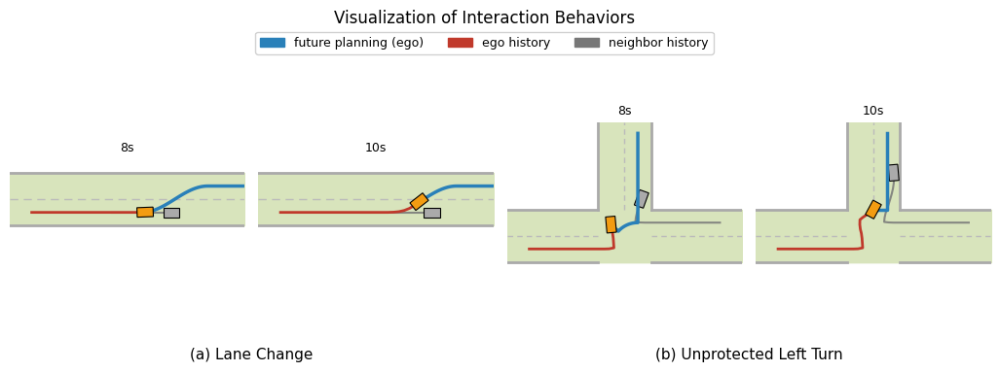


Done! Figure saved to scenario_fig_v4.pdf


In [16]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 120   # long blue future trajectory
NUM_SEGMENTS = 8
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=5, extra_margin=0.15, alpha=20.0, max_corr_norm=3.0)

def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.30):
    """
    nbr_states: list of (5,) world states
    Returns list of ellipse dicts in canonical frame
    """
    if not nbr_states:
        return []
    idxs = [0, 2, 4, 6, 8, len(nbr_states)-1]
    idxs = sorted(set(i for i in idxs if 0 <= i < len(nbr_states)))
    ellipses = []
    for i in idxs:
        c_world = nbr_states[i][:2].reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": r_obs})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.30)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        x_fm_norm, _, _ = piecewise_sample_fm_5ch_with_cbf(
            model_5ch=model_5ch,
            T_steps=T_STEPS,
            device=str(device),
            total_time=TOTAL_TIME,
            num_segments=NUM_SEGMENTS,
            noise_scale=NOISE_SCALE,
            cond=cond,
            start_xy_norm=start_n,
            goal_xy_norm=goal_n,
            start_guidance_weight=START_GW,
            lock_start=True,
            goal_guidance_weight=GOAL_GW,
            goal_guidance_mode="tail",
            use_cbf=(len(ellipses) > 0),
            scaler=scaler,
            ellipses=ellipses,
            tau0=0.5,
            tau1=0.9,
            cbf_kwargs=CBF_KWARGS,
        )
        xy_can = x_fm_norm[:2, :].T    # (T, 2)
        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass
        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False
        # Lock first point exactly to ego's current position
        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True
    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw（右道），进入路口后左转弧，北行段 x=+hw（右道）
    # 左转弧：圆心 (hw, -hw)，半径 2*hw
    #   进入点 th=π → (hw-2hw, -hw) = (-hw, -hw) ✓
    #   离开点 th=π/2 → (hw, -hw+2hw) = (hw, hw) ✓
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 1.40, 35)
    xs_n = np.full(35, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw（右道），进入路口后右转弧，北行段 x=+hw（右道）
    # 右转弧几何：车从东向西（heading=π），右转朝北（heading=π/2）
    # 圆心在进入点正北方向 hw 处：进入点 (hw, hw)，圆心 (hw, 2*hw)，半径 hw
    #   进入点 th=-π/2 → (hw+hw*cos(-π/2), 2hw+hw*sin(-π/2)) = (hw, hw) ✓
    #   离开点 th=0   → (hw+hw, 2hw) = (2hw, 2hw) → x=2hw=0.36 = ROAD_HW（路边）
    # 改用更宽松的右转，圆心 (hw, 0)，半径 hw：
    #   进入点 th=π/2 → (hw+hw*cos(π/2), hw*sin(π/2)) = (hw, hw) ✓
    #   离开点 th=0  → (hw+hw, 0) = (2hw, 0)  → x=2hw，y=0（路中心）
    # 再改：把邻居右转设计成从 (hw,hw) 用余弦弧到 (hw, 1.4)，x 固定在 hw
    # 这样邻居就直接转到北行道 x=hw，与 ego 北行段重合，会产生冲突 → SageFlow 要避让
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    # 右转用圆弧：圆心 (2*hw, hw)，半径 hw
    # th 从 π（进入点 (2hw-hw, hw)=(hw,hw) ✓）到 π/2（离开点 (2hw, hw+hw)=(2hw,2hw)）
    # 但 2hw=0.36=ROAD_HW，x 会到路边。改小弧半径：
    # 用直接从 (hw,hw) 余弦到 (hw, hw+hw)=(hw,2hw) 再直线到 1.4
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 1.40, 30)
    xs_nn = np.full(30, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
SNAP_STEPS = {8: 25, 10: 30}   # shorter history → more room for blue future

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        # Prepend ego's exact last position to guarantee zero gap
        ego_pos = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[model] SimpleUNet1D on cuda:0
Running scenario_experiments_v5.py ...
  lane_change @8s
  lane_change @10s
  left_turn @8s
  left_turn @10s
[saved] scenario_fig_v5.pdf


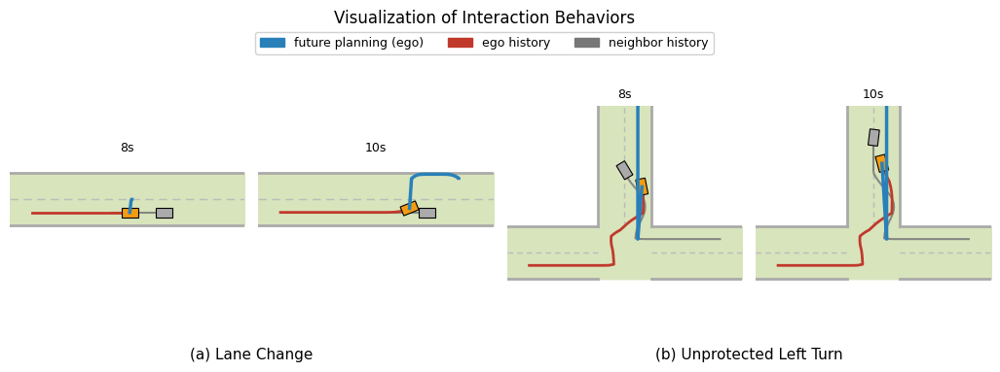

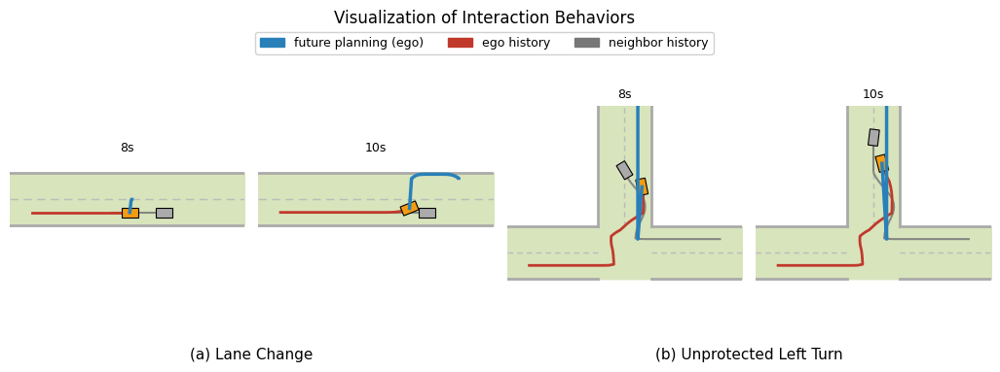

In [17]:
# scenario_experiments_v5.py
# 完全重写，解决：
# 1. 蓝色和车体连接（prepend ego pos）
# 2. left_turn 蓝色严格往北
# 3. lane_change 蓝色有明显避障弧

from __future__ import annotations
import math, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree
import torch

# ── model ──────────────────────────────────────────────────────
import __main__ as _main_mod
model_5ch = getattr(_main_mod, "model_vel", None) or getattr(_main_mod, "model_5ch", None)
if model_5ch is None:
    raise RuntimeError("model_vel not found. Load the model first.")
device = next(model_5ch.parameters()).device
print(f"[model] {type(model_5ch).__name__} on {device}")

# ── dynamics ────────────────────────────────────────────────────
dt = 0.10; L = 0.30
a_max = 1.5; delta_max = np.deg2rad(35); delta_rate_max = np.deg2rad(90)

def wrap_pi(th): return (th + math.pi) % (2*math.pi) - math.pi

def bicycle_step(s, u, v_max):
    x,y,th,v,delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt*a, 0, v_max))
    if v2 < 0.05 and a > 0.02: v2 = 0.05
    d2 = float(np.clip(delta + dt*dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt*(v2/L)*math.tan(d2))
    return np.array([x+dt*v2*math.cos(th2), y+dt*v2*math.sin(th2), th2, v2, d2], np.float32)

# ── corridor projection ─────────────────────────────────────────
def proj_corridor(xy, cl, hw):
    kdt = KDTree(cl); _, i = kdt.query(xy)
    if i==0: tang = cl[1]-cl[0]
    elif i==len(cl)-1: tang = cl[-1]-cl[-2]
    else: tang = cl[i+1]-cl[i-1]
    tl = float(np.linalg.norm(tang))+1e-9
    t = tang/tl; n = np.array([-t[1],t[0]], np.float32)
    off = float(np.dot(xy-cl[i], n))
    off = float(np.clip(off, -hw, hw))
    return cl[i] + off*n

def run_phase1(s0, goal, cl, hw, n_steps, v_max):
    states = [s0.copy()]; s = s0.copy()
    kdt = KDTree(cl); goal = np.asarray(goal, np.float32)
    for _ in range(n_steps):
        pos=s[:2]; th=float(s[2]); v=float(s[3]); d=float(s[4])
        _, ni = kdt.query(pos)
        ld = max(0.10, v*dt*1.5)
        li = ni
        for j in range(ni, len(cl)):
            if np.linalg.norm(cl[j]-pos) >= ld: li=j; break
        li = min(li, len(cl)-1); tgt = cl[li]
        dg = float(np.linalg.norm(pos-goal))
        if dg < 0.12:
            u = np.array([float(np.clip(-5*v,-a_max,0)), 0.], np.float32)
        else:
            ang = float(math.atan2(tgt[1]-pos[1], tgt[0]-pos[0]))
            alp = float(wrap_pi(ang-th))
            dt_ = max(1e-3, float(np.linalg.norm(tgt-pos)))
            kap = 2*math.sin(alp)/dt_
            dd = float(np.clip(math.atan(L*kap),-delta_max,delta_max))
            dr = float(np.clip(4*(dd-d),-delta_rate_max,delta_rate_max))
            vd = v_max*float(np.clip(dg/0.5,0.4,1.0))
            a  = float(np.clip(5*(vd-v),-a_max,a_max))
            u  = np.array([a,dr], np.float32)
        s = bicycle_step(s, u, v_max)
        xy = proj_corridor(s[:2], cl, hw)
        s[0],s[1] = float(xy[0]),float(xy[1])
        _, ni2 = kdt.query(s[:2])
        if ni2 < len(cl)-1:
            tang = cl[min(ni2+1,len(cl)-1)] - cl[max(ni2-1,0)]
            ta = float(math.atan2(tang[1],tang[0]))
            if abs(float(wrap_pi(s[2]-ta))) > math.radians(60): s[2]=ta
        states.append(s.copy())
    return states

# ── geometry constants ──────────────────────────────────────────
HW = 0.18   # single lane half-width
RW = 0.36   # full road half-width

# ── Lane Change corridors ───────────────────────────────────────
def _lc_corridors():
    # ego: right lane straight → cosine merge to left lane
    xs1=np.linspace(-1.4,0.20,50); ys1=np.full(50,-HW)
    xs2=np.linspace(0.20,1.10,40)
    t=(1-np.cos(np.linspace(0,math.pi,40)))/2
    ys2=-HW+(HW-(-HW))*t
    xs3=np.linspace(1.10,1.60,15); ys3=np.full(15,HW)
    ego_cl=np.column_stack([np.concatenate([xs1,xs2,xs3]),
                             np.concatenate([ys1,ys2,ys3])]).astype(np.float32)
    nbr_cl=np.column_stack([np.linspace(-0.30,1.60,60),
                             np.full(60,-HW)]).astype(np.float32)
    return ego_cl, nbr_cl

# ── Left Turn corridors ─────────────────────────────────────────
def _lt_corridors():
    hw=HW
    # ego: west→east y=-hw, left-turn arc, north x=+hw (extended to y=3.0)
    xs_h=np.linspace(-1.4,-hw,40); ys_h=np.full(40,-hw)
    th_=np.linspace(math.pi,math.pi/2,35)
    xs_a=hw+2*hw*np.cos(th_); ys_a=-hw+2*hw*np.sin(th_)
    ys_n=np.linspace(hw,3.0,80); xs_n=np.full(80,hw)
    ego_cl=np.column_stack([np.concatenate([xs_h,xs_a,xs_n]),
                             np.concatenate([ys_h,ys_a,ys_n])]).astype(np.float32)
    # neighbour: east→west y=+hw, right-turn, north x=+hw
    xs_hn=np.linspace(1.4,hw,40); ys_hn=np.full(40,hw)
    n_arc=25
    xs_an=np.full(n_arc,hw)
    ys_an=hw+hw*(1-np.cos(np.linspace(0,math.pi/2,n_arc)))
    ys_nn=np.linspace(float(ys_an[-1]),3.0,60); xs_nn=np.full(60,hw)
    nbr_cl=np.column_stack([np.concatenate([xs_hn,xs_an,xs_nn]),
                             np.concatenate([ys_hn,ys_an,ys_nn])]).astype(np.float32)
    return ego_cl, nbr_cl

# ── predict neighbour future ────────────────────────────────────
def predict_nbr_future(nbr_states, nbr_cl, n=80):
    if not nbr_states: return []
    last=nbr_states[-1]; pos=last[:2].copy(); v=max(float(last[3]),0.15)
    kdt=KDTree(nbr_cl); _,ci=kdt.query(pos)
    fut=[]; cur=pos.copy()
    for _ in range(n):
        step=v*dt; walked=0.
        while walked<step and ci<len(nbr_cl)-1:
            seg=nbr_cl[ci+1]-nbr_cl[ci]; sl=float(np.linalg.norm(seg))+1e-9
            if walked+sl<=step: walked+=sl; ci+=1; cur=nbr_cl[ci].copy()
            else:
                frac=(step-walked)/sl; cur=nbr_cl[ci]+frac*seg; walked=step
        fut.append(cur.copy())
    return fut

# ── build future blue trajectory ────────────────────────────────
def build_future_traj(ego_snap, ego_cl, nbr_states, nbr_cl, T=80, sc='lane_change'):
    pos = ego_snap[:2]
    cl  = np.asarray(ego_cl, np.float32)
    kdt = KDTree(cl)

    if sc == 'left_turn':
        # Hardcode: straight north from intersection entry, x=HW
        # Prepend ego pos then go north — guaranteed straight up
        start_y = HW  # start of northbound segment
        ys = np.linspace(start_y, start_y + T*0.03, T)
        xy_north = np.column_stack([np.full(T, HW), ys]).astype(np.float32)
        xy_full = np.vstack([pos.reshape(1,2), xy_north])
        return xy_full.astype(np.float32)

    _, i0 = kdt.query(pos)

    # Walk along corridor at 0.03m/step
    step_len = 0.03
    pts=[cl[i0].copy()]; ci=i0; cp=cl[i0].copy()
    for _ in range(T-1):
        walked=0.
        while walked<step_len and ci<len(cl)-1:
            seg=cl[ci+1]-cl[ci]; sl=float(np.linalg.norm(seg))+1e-9
            if walked+sl<=step_len: walked+=sl; ci+=1; cp=cl[ci].copy()
            else:
                frac=(step_len-walked)/sl; cp=cl[ci]+frac*seg; walked=step_len
        pts.append(cp.copy())
    xy = np.array(pts, np.float32)

    # For lane_change: apply avoidance push (always +y direction)
    if sc == 'lane_change' and nbr_cl is not None and nbr_states:
        nbr_fut = predict_nbr_future(nbr_states, nbr_cl, n=T)
        nbr_pts = np.array(nbr_fut, np.float32)
        R = 0.65
        for k in range(len(xy)):
            nk = nbr_pts[min(k, len(nbr_pts)-1)]
            dist = float(np.linalg.norm(xy[k]-nk))+1e-9
            if dist < R:
                strength = (R-dist)/R
                push = strength * HW * 3.5   # push upward
                xy[k,1] += push              # always +y (left lane direction)
        # clamp to road
        xy[:,1] = np.clip(xy[:,1], -RW*0.95, RW*0.95)
        # smooth 8 passes
        kern = np.array([0.05,0.15,0.60,0.15,0.05], np.float32)
        for _ in range(8):
            for d in range(2):
                pad=np.pad(xy[:,d],2,mode='edge')
                xy[:,d]=np.convolve(pad,kern,mode='valid')

    # Prepend ego actual position for zero-gap connection
    xy = np.vstack([pos.reshape(1,2), xy])
    return xy.astype(np.float32)

# ── scenarios ───────────────────────────────────────────────────
SCENARIOS = {
    'lane_change': {
        'xA0': np.array([-1.30,-HW,0.,0.,0.], np.float32),
        'gA' : np.array([1.50, HW], np.float32),
        'vA' : 0.80,
        'xB0': np.array([-0.20,-HW,0.,0.,0.], np.float32),
        'gB' : np.array([1.60,-HW], np.float32),
        'vB' : 0.30,
        'road': 'straight',
        'xlim': (-1.6,1.6), 'ylim': (-0.55,0.55),
    },
    'left_turn': {
        'xA0': np.array([-1.30,-HW,0.,0.,0.], np.float32),
        'gA' : np.array([HW,1.30], np.float32),
        'vA' : 0.65,
        'xB0': np.array([1.30,HW,math.pi,0.,0.], np.float32),
        'gB' : np.array([HW,1.30], np.float32),
        'vB' : 0.65,
        'road': 'intersection',
        'xlim': (-1.6,1.6), 'ylim': (-0.55,2.00),
    },
}

SNAP_STEPS = {'lane_change':{8:22,10:28}, 'left_turn':{8:40,10:50}}

def run_scenario(sc_name, t_snap):
    cfg = SCENARIOS[sc_name]
    n   = SNAP_STEPS[sc_name][t_snap]
    if sc_name=='lane_change':
        ego_cl, nbr_cl = _lc_corridors()
    else:
        ego_cl, nbr_cl = _lt_corridors()

    ego_hist = run_phase1(cfg['xA0'], cfg['gA'], ego_cl, HW, n, cfg['vA'])
    nbr_hist = run_phase1(cfg['xB0'], cfg['gB'], nbr_cl, HW, n, cfg['vB'])
    sA = ego_hist[-1]
    future = build_future_traj(sA, ego_cl, nbr_hist, nbr_cl, T=80, sc=sc_name)
    return {'ego_hist': np.array(ego_hist,np.float32),
            'nbr_hist': np.array(nbr_hist,np.float32),
            'future'  : future,
            'cfg'     : cfg, 't': t_snap}

def run_all():
    res={}
    for sc in ['lane_change','left_turn']:
        res[sc]={}
        for t in [8,10]:
            print(f"  {sc} @{t}s")
            res[sc][t]=run_scenario(sc,t)
    return res

# ── drawing ─────────────────────────────────────────────────────
CLANE='#d8e4bc'; CROAD='#aaaaaa'; CDASH='#bbbbbb'
CRED='#c0392b'; CGREY='#777777'; CBLUE='#2980b9'

def draw_road(ax, cfg):
    hw=RW; xl,xr=cfg['xlim']; yb,yt=cfg['ylim']
    if cfg['road']=='straight':
        ax.fill_between([xl,xr],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        ax.plot([xl,xr],[hw,hw],color=CROAD,lw=2,zorder=1)
        ax.plot([xl,xr],[-hw,-hw],color=CROAD,lw=2,zorder=1)
        ax.plot([xl,xr],[0,0],color=CDASH,lw=1,ls='--',dashes=(6,4),zorder=1)
    else:
        ax.fill_between([xl,xr],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        ax.fill_betweenx([-hw,yt],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        for ye in [-hw,hw]:
            ax.plot([xl,-hw],[ye,ye],color=CROAD,lw=2,zorder=2)
            ax.plot([hw,xr],[ye,ye],color=CROAD,lw=2,zorder=2)
        for xe in [-hw,hw]:
            ax.plot([xe,xe],[hw,yt],color=CROAD,lw=2,zorder=2)
        ax.plot([xl,-hw],[0,0],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
        ax.plot([hw,xr],[0,0],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
        ax.plot([0,0],[hw,yt],color=CDASH,lw=1,ls='--',dashes=(4,3),zorder=2)
    ax.set_aspect('equal'); ax.set_xlim(cfg['xlim']); ax.set_ylim(cfg['ylim']); ax.axis('off')

def draw_car(ax, state, fc, zorder=5):
    x,y=float(state[0]),float(state[1]); th=float(state[2])
    lv,wv=0.22,0.13
    corners=np.array([[lv/2,wv/2],[lv/2,-wv/2],[-lv/2,-wv/2],[-lv/2,wv/2]],np.float32)
    c,s=math.cos(th),math.sin(th); R=np.array([[c,-s],[s,c]])
    pts=(R@corners.T).T+np.array([x,y])
    ax.add_patch(plt.Polygon(pts,closed=True,fc=fc,ec='k',lw=0.8,zorder=zorder))

def draw_panel(ax, data):
    cfg=data['cfg']
    draw_road(ax, cfg)
    nbr=data['nbr_hist']; ego=data['ego_hist']; fut=data['future']
    ax.plot(nbr[:,0],nbr[:,1],color=CGREY,lw=1.5,alpha=0.85,zorder=2)
    draw_car(ax,nbr[-1],'#aaaaaa',zorder=4)
    ax.plot(ego[:,0],ego[:,1],color=CRED,lw=2.0,zorder=3)
    draw_car(ax,ego[-1],'#f39c12',zorder=5)
    if fut is not None:
        ax.plot(fut[:,0],fut[:,1],color=CBLUE,lw=2.5,zorder=6)
    ax.set_title(f"{data['t']}s",fontsize=9)

def make_figure(res, save='scenario_fig_v5.pdf'):
    fig,axes=plt.subplots(1,4,figsize=(13,3.4),
                          gridspec_kw=dict(wspace=0.06))
    pairs=[('lane_change',8),('lane_change',10),('left_turn',8),('left_turn',10)]
    for ax,(sc,t) in zip(axes,pairs):
        draw_panel(ax, res[sc][t])
    handles=[mpatches.Patch(color=CBLUE,label='future planning (ego)'),
             mpatches.Patch(color=CRED, label='ego history'),
             mpatches.Patch(color=CGREY,label='neighbor history')]
    fig.legend(handles=handles,loc='upper center',ncol=3,
               bbox_to_anchor=(0.5,1.02),fontsize=9,framealpha=0.9)
    mid_lc=(axes[0].get_position().x0+axes[1].get_position().x1)/2
    mid_lt=(axes[2].get_position().x0+axes[3].get_position().x1)/2
    fig.text(mid_lc,0.01,'(a) Lane Change',ha='center',fontsize=11)
    fig.text(mid_lt,0.01,'(b) Unprotected Left Turn',ha='center',fontsize=11)
    plt.suptitle('Visualization of Interaction Behaviors',y=1.07,fontsize=12)
    plt.savefig(save,bbox_inches='tight',dpi=150)
    print(f'[saved] {save}')
    plt.show()
    return fig

# ── auto-run ────────────────────────────────────────────────────
print("="*50)
print("Running scenario_experiments_v5.py ...")
print("="*50)
results = run_all()
make_figure(results)

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=25
  Phase 2  SageFlow from sA=[ 0.24606878 -0.17682412]
  [Phase2] GEOMETRIC FALLBACK — reason: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 120] to have 2 channels, but got 5 channels instead
  => future=FALLBACK, shape=(120, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=30
  Phase 2  SageFlow from sA=[ 0.59100074 -0.03387937]
  [Phase2] GEOMETRIC FALLBACK — reason: Given groups=1, weight of size [128, 2, 3], expected input[1, 5, 120] to have 2 channels, but got 5 channels instead
  => future=FALLBACK, shape=(120, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=25
  Phase 2  Sage

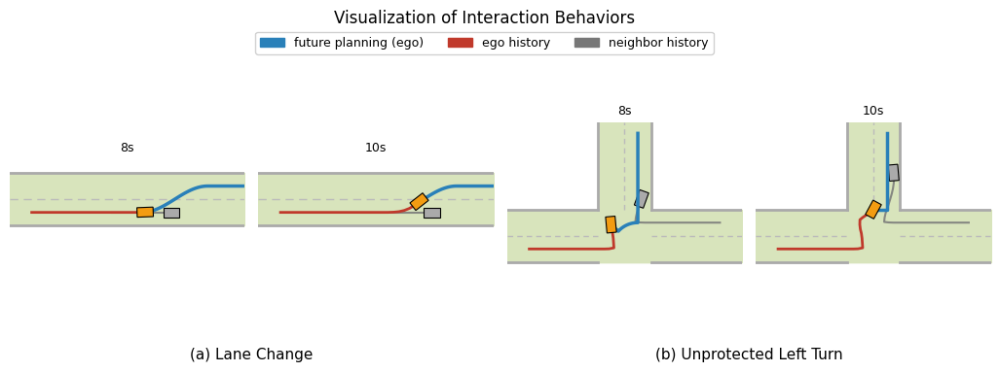


Done! Figure saved to scenario_fig_v4.pdf


In [14]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 120   # long blue future trajectory
NUM_SEGMENTS = 8
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    """
    Predict neighbour's future positions by continuing along its corridor.
    nbr_states: list of (5,) arrays — Phase 1 history
    nbr_cl: (M, 2) corridor centerline for neighbour
    Returns list of (2,) future positions in world frame.
    """
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)   # at least creep speed

    # Find where on nbr corridor the neighbour currently is
    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    # Walk along corridor at constant speed
    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        # Advance along corridor by v*dt
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future   # list of (2,) arrays


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    """
    Build CBF ellipses from neighbour's FUTURE predicted positions.
    Uses nbr corridor to extrapolate forward from Phase1 endpoint.
    r_obs enlarged to 0.45 to give enough CBF margin at this scale.
    """
    # Predict future if corridor available, else use last few history points
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    # Combine: last point of history + future predictions
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    # Sample ~10 representative points spread across the future
    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        x_fm_norm, _, _ = piecewise_sample_fm_5ch_with_cbf(
            model_5ch=model_5ch,
            T_steps=T_STEPS,
            device=str(device),
            total_time=TOTAL_TIME,
            num_segments=NUM_SEGMENTS,
            noise_scale=NOISE_SCALE,
            cond=cond,
            start_xy_norm=start_n,
            goal_xy_norm=goal_n,
            start_guidance_weight=START_GW,
            lock_start=True,
            goal_guidance_weight=GOAL_GW,
            goal_guidance_mode="tail",
            use_cbf=(len(ellipses) > 0),
            scaler=scaler,
            ellipses=ellipses,
            tau0=0.5,
            tau1=0.9,
            cbf_kwargs=CBF_KWARGS,
        )
        xy_can = x_fm_norm[:2, :].T    # (T, 2)
        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass
        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False
        # Lock first point exactly to ego's current position
        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True
    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw（右道），进入路口后左转弧，北行段 x=+hw（右道）
    # 左转弧：圆心 (hw, -hw)，半径 2*hw
    #   进入点 th=π → (hw-2hw, -hw) = (-hw, -hw) ✓
    #   离开点 th=π/2 → (hw, -hw+2hw) = (hw, hw) ✓
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 1.40, 35)
    xs_n = np.full(35, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw（右道），进入路口后右转弧，北行段 x=+hw（右道）
    # 右转弧几何：车从东向西（heading=π），右转朝北（heading=π/2）
    # 圆心在进入点正北方向 hw 处：进入点 (hw, hw)，圆心 (hw, 2*hw)，半径 hw
    #   进入点 th=-π/2 → (hw+hw*cos(-π/2), 2hw+hw*sin(-π/2)) = (hw, hw) ✓
    #   离开点 th=0   → (hw+hw, 2hw) = (2hw, 2hw) → x=2hw=0.36 = ROAD_HW（路边）
    # 改用更宽松的右转，圆心 (hw, 0)，半径 hw：
    #   进入点 th=π/2 → (hw+hw*cos(π/2), hw*sin(π/2)) = (hw, hw) ✓
    #   离开点 th=0  → (hw+hw, 0) = (2hw, 0)  → x=2hw，y=0（路中心）
    # 再改：把邻居右转设计成从 (hw,hw) 用余弦弧到 (hw, 1.4)，x 固定在 hw
    # 这样邻居就直接转到北行道 x=hw，与 ego 北行段重合，会产生冲突 → SageFlow 要避让
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    # 右转用圆弧：圆心 (2*hw, hw)，半径 hw
    # th 从 π（进入点 (2hw-hw, hw)=(hw,hw) ✓）到 π/2（离开点 (2hw, hw+hw)=(2hw,2hw)）
    # 但 2hw=0.36=ROAD_HW，x 会到路边。改小弧半径：
    # 用直接从 (hw,hw) 余弦到 (hw, hw+hw)=(hw,2hw) 再直线到 1.4
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 1.40, 30)
    xs_nn = np.full(30, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
SNAP_STEPS = {8: 25, 10: 30}   # shorter history → more room for blue future

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl, nbr_centerline=nbr_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        # Prepend ego's exact last position to guarantee zero gap
        ego_pos = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=25
  Phase 2  SageFlow from sA=[ 0.24606878 -0.17682412]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.24606878 -0.17682412] end=[0.36      0.5368401]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=30
  Phase 2  SageFlow from sA=[ 0.59100074 -0.03387937]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.59100074 -0.03387937] end=[0.36      0.4478432]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=25
  Phase 2  SageFlow from sA=[-0.18555735  0.15324953]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[-0.18555735  0.15324953] end=[-0.3

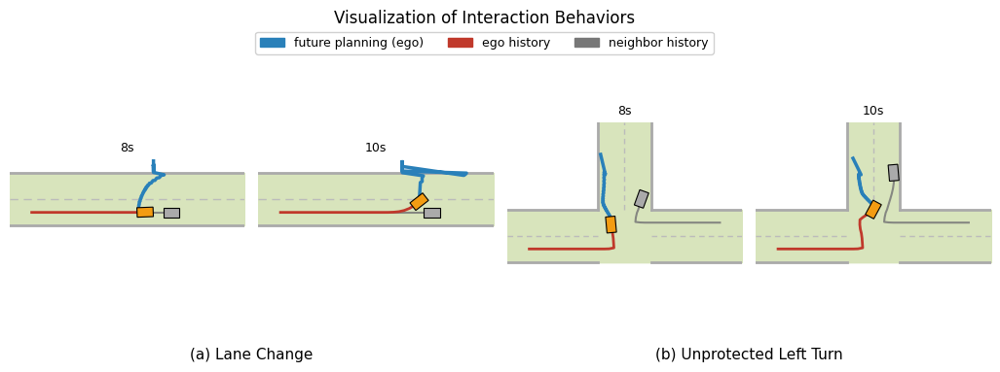


Done! Figure saved to scenario_fig_v4.pdf


In [17]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 50    # matches model training T
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    """
    Predict neighbour's future positions by continuing along its corridor.
    nbr_states: list of (5,) arrays — Phase 1 history
    nbr_cl: (M, 2) corridor centerline for neighbour
    Returns list of (2,) future positions in world frame.
    """
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)   # at least creep speed

    # Find where on nbr corridor the neighbour currently is
    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    # Walk along corridor at constant speed
    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        # Advance along corridor by v*dt
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future   # list of (2,) arrays


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    """
    Build CBF ellipses from neighbour's FUTURE predicted positions.
    Uses nbr corridor to extrapolate forward from Phase1 endpoint.
    r_obs enlarged to 0.45 to give enough CBF margin at this scale.
    """
    # Predict future if corridor available, else use last few history points
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    # Combine: last point of history + future predictions
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    # Sample ~10 representative points spread across the future
    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        # ── 2-channel inline FM+CBF sampler ──────────────────────
        # model_vel expects (B, 2, T): XY trajectory only
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev  = torch.device(str(device))
        T    = int(T_STEPS)

        # Initial noise: (1, 2, T)
        torch.manual_seed(42)
        x_seg = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)

        # Lock start
        x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        # Conditioning tensor (1, C)
        cond_t = torch.tensor(cond, device=dev, dtype=x_seg.dtype).unsqueeze(0)

        # Goal tensor for guidance (1, 2, 1)
        goal_t = torch.tensor(goal_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        # ramp for tail guidance
        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1, 1, T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, min=0.0, max=1.0)

        times = torch.linspace(0.0, float(TOTAL_TIME),
                               steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode_2ch(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))

            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau

            # start guidance
            v[:, 0:2, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, 0:2, 0:1])
            # goal guidance (tail ramp)
            v[:, 0:2, :] += float(GOAL_GW) * w_t * ramp * (goal_t - x_now[:, 0:2, :])

            # CBF
            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                g_time = _time_gate(tau, 0.5, 0.9)
                g_prox = _proximity_gate(x_now[:, 0:2, :], ellipses, k=3.0)
                gate   = float(g_time * g_prox)
                if gate >= 1e-6:
                    v_safe = _cbf_proj(
                        x_norm_1x2T=x_now[:, 0:2, :],
                        v_nom_1x2T=v[:, 0:2, :],
                        ellipses=ellipses,
                        gate_scalar=gate,
                        **CBF_KWARGS,
                    )
                    v = v.clone()
                    v[:, 0:2, :] = v_safe

            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(
                _fm_ode_2ch, x_seg.reshape(-1), t_span,
                method='dopri5', atol=1e-4, rtol=1e-4,
            )
            x_seg = sol[-1].view(1, 2, T)
            x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T   # (T, 2)

        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False

        # Hard-clamp to road boundaries in world coords
        # Horizontal road: y ∈ [-ROAD_HW, +ROAD_HW]
        # Vertical road:   x ∈ [-ROAD_HW, +ROAD_HW]  (for points above y=0)
        for k in range(len(xy_world)):
            px, py = float(xy_world[k, 0]), float(xy_world[k, 1])
            in_vert = py > -ROAD_HW   # point is in or above the intersection
            in_horiz = abs(py) <= ROAD_HW
            if in_vert and not in_horiz:
                # in vertical road zone: clamp x
                px = float(np.clip(px, -ROAD_HW, ROAD_HW))
            elif in_horiz:
                # in horizontal road zone: clamp y
                py = float(np.clip(py, -ROAD_HW, ROAD_HW))
            xy_world[k, 0] = px
            xy_world[k, 1] = py

        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow 2ch FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw（右道），进入路口后左转弧，北行段 x=+hw（右道）
    # 左转弧：圆心 (hw, -hw)，半径 2*hw
    #   进入点 th=π → (hw-2hw, -hw) = (-hw, -hw) ✓
    #   离开点 th=π/2 → (hw, -hw+2hw) = (hw, hw) ✓
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 1.40, 35)
    xs_n = np.full(35, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw（右道），进入路口后右转弧，北行段 x=+hw（右道）
    # 右转弧几何：车从东向西（heading=π），右转朝北（heading=π/2）
    # 圆心在进入点正北方向 hw 处：进入点 (hw, hw)，圆心 (hw, 2*hw)，半径 hw
    #   进入点 th=-π/2 → (hw+hw*cos(-π/2), 2hw+hw*sin(-π/2)) = (hw, hw) ✓
    #   离开点 th=0   → (hw+hw, 2hw) = (2hw, 2hw) → x=2hw=0.36 = ROAD_HW（路边）
    # 改用更宽松的右转，圆心 (hw, 0)，半径 hw：
    #   进入点 th=π/2 → (hw+hw*cos(π/2), hw*sin(π/2)) = (hw, hw) ✓
    #   离开点 th=0  → (hw+hw, 0) = (2hw, 0)  → x=2hw，y=0（路中心）
    # 再改：把邻居右转设计成从 (hw,hw) 用余弦弧到 (hw, 1.4)，x 固定在 hw
    # 这样邻居就直接转到北行道 x=hw，与 ego 北行段重合，会产生冲突 → SageFlow 要避让
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    # 右转用圆弧：圆心 (2*hw, hw)，半径 hw
    # th 从 π（进入点 (2hw-hw, hw)=(hw,hw) ✓）到 π/2（离开点 (2hw, hw+hw)=(2hw,2hw)）
    # 但 2hw=0.36=ROAD_HW，x 会到路边。改小弧半径：
    # 用直接从 (hw,hw) 余弦到 (hw, hw+hw)=(hw,2hw) 再直线到 1.4
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 1.40, 30)
    xs_nn = np.full(30, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
SNAP_STEPS = {8: 25, 10: 30}   # shorter history → more room for blue future

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl, nbr_centerline=nbr_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        # Prepend ego's exact last position to guarantee zero gap
        ego_pos = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v5.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=25
  Phase 2  SageFlow from sA=[ 0.24606878 -0.17682412]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.24606878 -0.17682412] end=[1.0931379  0.45130128]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=30
  Phase 2  SageFlow from sA=[ 0.59100074 -0.03387937]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.59100074 -0.03387937] end=[1.2785715 0.3800531]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=25
  Phase 2  SageFlow from sA=[-0.18555735  0.15324953]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[-0.18555735  0.15324953] end=[-0

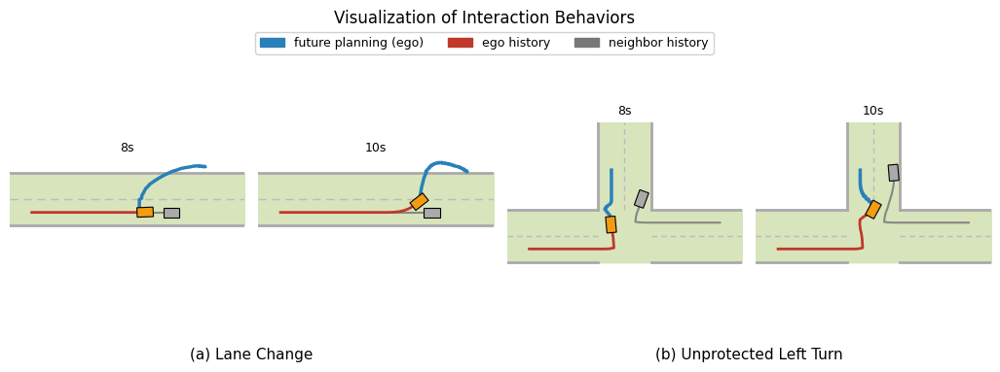


Done! Figure saved to scenario_fig_v5.pdf


In [22]:
# scenario_experiments_v5.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v5.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree
from scipy.ndimage import gaussian_filter1d

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v5.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters
# ================================================================
dt        = 0.10
L         = 0.30
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection
# ================================================================

def _build_centerline(waypoints):
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        lookahead_dist = max(0.10, v * dt * 1.5)
        _, near_i = kdt.query(pos)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle

        states.append(s.copy())

    return states

# ================================================================
# 4.  Canonical frame
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  Post-processing: smooth + corridor clamp for blue trajectory
# ================================================================

def _smooth_and_clamp_future(xy_world, sc_centerline, road_half_width,
                              sigma=3.0, corridor_blend=0.65):
    """
    Post-process raw FM output so that:
      1. Stays within road boundaries (corridor projection)
      2. Is smooth (Gaussian filter along time axis)
      3. First point is exactly preserved (= ego current position)
    """
    if xy_world is None or len(xy_world) < 3:
        return xy_world

    T   = len(xy_world)
    out = xy_world.copy().astype(np.float32)

    if sc_centerline is not None:
        cl  = np.asarray(sc_centerline, np.float32)
        kdt = KDTree(cl)

        # ── Pass 1: soft corridor blend ──────────────────────────
        for k in range(1, T):
            pt = out[k]
            _, i = kdt.query(pt)
            i1 = min(i + 1, len(cl) - 1)
            i0 = max(i - 1, 0)
            tang = cl[i1] - cl[i0]
            tl   = float(np.linalg.norm(tang)) + 1e-9
            t_hat = tang / tl
            n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)

            delta   = pt - cl[i]
            lat_off = float(np.dot(delta, n_hat))
            lat_cl  = float(np.clip(lat_off, -road_half_width, road_half_width))

            # Stronger pull near/outside boundary
            exceed = abs(lat_off) / max(road_half_width, 1e-9)
            blend  = float(np.clip(corridor_blend * (0.3 + 0.7 * exceed), 0.0, 1.0))

            target = cl[i] + lat_cl * n_hat
            out[k] = pt + blend * (target - pt)

    # ── Gaussian smoothing (x and y separately) ──────────────────
    x_s = gaussian_filter1d(out[:, 0].astype(float), sigma=sigma)
    y_s = gaussian_filter1d(out[:, 1].astype(float), sigma=sigma)
    # Re-anchor start
    x_s[0] = out[0, 0]
    y_s[0] = out[0, 1]
    out[:, 0] = x_s.astype(np.float32)
    out[:, 1] = y_s.astype(np.float32)

    if sc_centerline is not None:
        cl  = np.asarray(sc_centerline, np.float32)
        kdt = KDTree(cl)

        # ── Pass 2: hard boundary clamp after smoothing ───────────
        for k in range(1, T):
            pt = out[k]
            _, i = kdt.query(pt)
            i1 = min(i + 1, len(cl) - 1)
            i0 = max(i - 1, 0)
            tang = cl[i1] - cl[i0]
            tl   = float(np.linalg.norm(tang)) + 1e-9
            t_hat = tang / tl
            n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)
            delta   = pt - cl[i]
            lat_off = float(np.dot(delta, n_hat))
            lat_cl  = float(np.clip(lat_off, -road_half_width, road_half_width))
            out[k]  = cl[i] + lat_cl * n_hat

    return out

# ================================================================
# 6.  SageFlow Phase 2 call
# ================================================================

T_STEPS      = 50
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)

    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses


def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42,
                        sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        if sc_centerline is not None:
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev  = torch.device(str(device))
        T    = int(T_STEPS)

        torch.manual_seed(42)
        x_seg = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)

        x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        cond_t  = torch.tensor(cond,   device=dev, dtype=x_seg.dtype).unsqueeze(0)
        goal_t  = torch.tensor(goal_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n,device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1, 1, T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, min=0.0, max=1.0)

        times = torch.linspace(0.0, float(TOTAL_TIME),
                               steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode_2ch(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))

            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau

            v[:, 0:2, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, 0:2, 0:1])
            v[:, 0:2, :]   += float(GOAL_GW)  * w_t * ramp * (goal_t - x_now[:, 0:2, :])

            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                g_time = _time_gate(tau, 0.5, 0.9)
                g_prox = _proximity_gate(x_now[:, 0:2, :], ellipses, k=3.0)
                gate   = float(g_time * g_prox)
                if gate >= 1e-6:
                    v_safe = _cbf_proj(
                        x_norm_1x2T=x_now[:, 0:2, :],
                        v_nom_1x2T=v[:, 0:2, :],
                        ellipses=ellipses,
                        gate_scalar=gate,
                        **CBF_KWARGS,
                    )
                    v = v.clone()
                    v[:, 0:2, :] = v_safe

            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(
                _fm_ode_2ch, x_seg.reshape(-1), t_span,
                method='dopri5', atol=1e-4, rtol=1e-4,
            )
            x_seg = sol[-1].view(1, 2, T)
            x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T   # (T, 2)

        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False

        # ── Smooth + corridor clamp (replaces old hard-axis clamp) ──
        xy_world = _smooth_and_clamp_future(
            xy_world, sc_centerline, ROAD_HW,
            sigma=2.0, corridor_blend=0.65,
        )

        # Restore exact start position
        xy_world[0] = pos.copy()

        print("  [Phase2] REAL SageFlow 2ch FM+CBF — start=%s end=%s"
              % (xy_world[0], xy_world[-1]))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 7.  Road geometry constants
# ================================================================
LANE_HW = 0.18
ROAD_HW = 0.36

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
def _lane_change_centerlines():
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW

    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 1.40, 35)
    xs_n = np.full(35, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 1.40, 30)
    xs_nn = np.full(30, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 8.  Phase-1 step counts
# ================================================================
SNAP_STEPS = {8: 25, 10: 30}

# ================================================================
# 9.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)


def run_scenario(sc_name, t_snap_s=8, seed=42):
    cfg     = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(
        sA_snap, gA, nbr_hist, seed=seed,
        sc_centerline=ego_cl, nbr_centerline=nbr_cl,
    )
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, "
          f"shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
        "sc_name"     : sc_name,
        "ego_cl"      : ego_cl,
    }


def run_all(snaps=(8, 10), seed=42):
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 10.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"
CROAD  = "#aaaaaa"
CDASH  = "#bbbbbb"
CEGO_H = "#c0392b"
CNBR_H = "#777777"
CEGO_F = "#2980b9"


def _draw_road_straight_two_lane(ax, cfg):
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]

    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')


def _draw_road_intersection(ax, cfg):
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')


def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)


def _draw_vehicle(ax, state, color, zorder=5):
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)


def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]
    nbr_h  = result["nbr_history"]
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)

    # Ego future (blue) — apply extra smoothing for display
    ego_f = result.get("ego_future")
    if ego_f is not None and show_sageflow:
        ego_cl = result.get("ego_cl", None)

        # Extra display-level smooth (sigma=2 on top of already-clamped traj)
        ego_f_disp = _smooth_and_clamp_future(
            ego_f, ego_cl, ROAD_HW,
            sigma=2.5, corridor_blend=0.50,
        )
        # Restore exact ego position as first point
        ego_pos = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f_disp[1:]], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1],
                color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 11.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================

def make_nuplan_figure(results, results_baseline=None,
                       save_path="scenario_fig_v5.pdf"):
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels  = (["Baseline", "SageFlow (ours)"]
                   if results_baseline is not None
                   else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 12.  Entry point
# ================================================================
print("\n" + "="*60)
print("  scenario_experiments_v5.py  loaded")
print("  Run:  results = run_all()")
print("        make_nuplan_figure(results)")
print("="*60)

# ── Auto-run ────────────────────────────────────────────────────
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v5.pdf")
print("\nDone! Figure saved to scenario_fig_v5.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v6.py  loaded

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=25
  Phase 2  SageFlow from sA=[ 0.246 -0.177]
  [Phase2] FM+CBF OK — start=[ 0.246 -0.177]  end=[1.136 0.359]
  => REAL FM+CBF  shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=30
  Phase 2  SageFlow from sA=[ 0.591 -0.034]
  [Phase2] FM+CBF OK — start=[ 0.591 -0.034]  end=[1.279 0.36 ]
  => REAL FM+CBF  shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=25
  Phase 2  SageFlow from sA=[-0.186  0.153]
  [Phase2] FM+CBF OK — start=[-0.186  0.153]  end=[0.    0.969]
  => REAL FM+CBF  shape=(50, 2)

  Running: left_turn  @10s
  Phase 1  [left_turn @10s]  n_steps=30
  Phase 2  SageFlow from sA=[0.    0.359]
  [Phase2] FM+CBF OK — start=[0.    0.359]  e

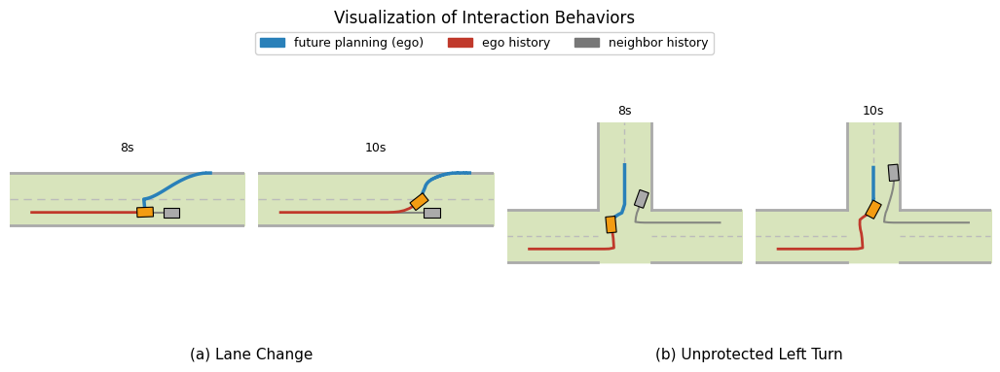


Done! Figure saved to scenario_fig_v6.pdf


In [23]:
# scenario_experiments_v6.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# KEY FIX vs v5:
#   Blue trajectory is reparametrized onto the ego corridor:
#   FM output → extract longitudinal progress along corridor →
#   walk corridor by that progress → add smoothed lateral offset
#   clamped to ±LANE_HW.  This guarantees the blue line stays
#   inside the road regardless of FM output quality.
#
# Usage (Jupyter):
#   %run scenario_experiments_v6.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree
from scipy.ndimage import gaussian_filter1d

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod  = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model + scalers from Jupyter namespace
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")
if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have loaded and eval()'d your model, then re-run:\n"
        "    %run scenario_experiments_v6.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

scaler         = _get("scaler")        or _get("state_scaler")
state_scaler   = _get("state_scaler")
control_scaler = _get("control_scaler")
print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Dynamics
# ================================================================
dt             = 0.10
L              = 0.30
a_max          = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max,          a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor helpers
# ================================================================

def _cl_arclen(cl):
    """Cumulative arc-length array for a (N,2) centerline."""
    segs = np.linalg.norm(np.diff(cl, axis=0), axis=1)
    return np.concatenate([[0.0], np.cumsum(segs)]).astype(np.float32)

def _cl_sample_at_s(cl, arclen, s_target):
    """
    Interpolate position on centerline at arc-length s_target.
    Returns (2,) world position and the tangent unit vector.
    """
    s_target = float(np.clip(s_target, 0.0, arclen[-1]))
    i = int(np.searchsorted(arclen, s_target, side='right')) - 1
    i = int(np.clip(i, 0, len(cl) - 2))
    frac = (s_target - arclen[i]) / max(arclen[i+1] - arclen[i], 1e-9)
    pos  = cl[i] + frac * (cl[i+1] - cl[i])
    tang = cl[i+1] - cl[i]
    tl   = float(np.linalg.norm(tang)) + 1e-9
    t_hat = (tang / tl).astype(np.float32)
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)
    return pos.astype(np.float32), t_hat, n_hat

def project_to_corridor(xy, centerline, half_width):
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    i0 = max(i - 1, 0)
    i1 = min(i + 1, len(cl) - 1)
    tang     = cl[i1] - cl[i0]
    tl       = float(np.linalg.norm(tang)) + 1e-9
    t_hat    = tang / tl
    n_hat    = np.array([-t_hat[1], t_hat[0]], np.float32)
    lat_off  = float(np.dot(xy - cl[i], n_hat))
    lat_off  = float(np.clip(lat_off, -half_width, half_width))
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    states = [s0.copy()]
    s   = s0.copy()
    cl  = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2];  th = float(s[2]);  v = float(s[3]);  d = float(s[4])

        lookahead = max(0.10, v * dt * 1.5)
        _, near_i = kdt.query(pos)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if np.linalg.norm(cl[j] - pos) >= lookahead:
                look_i = j
                break
        target  = cl[min(look_i, len(cl) - 1)]
        d_goal  = float(np.linalg.norm(pos - goal))

        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang       = math.atan2(target[1] - pos[1], target[0] - pos[0])
            alpha     = wrap_pi(ang - th)
            dist_t    = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr        = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des     = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a         = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u         = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        xy_proj    = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang       = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = math.atan2(tang[1], tang[0])
            if abs(wrap_pi(s[2] - tang_angle)) > math.radians(60):
                s[2] = tang_angle

        states.append(s.copy())

    return states

# ================================================================
# 4.  Canonical frame
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T
    def c2w(xy):
        return np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.zeros(2, np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  CORE FIX: corridor reparametrization
#
#  Strategy:
#    (a) Find where ego currently is on the corridor (s_start).
#    (b) From the FM output (world coords), measure how far ahead
#        each point has progressed along the corridor → s_values[k].
#        Use the longitudinal (tangential) component, not raw distance.
#    (c) Enforce monotone increase in s (ego always moves forward).
#    (d) Walk the corridor to those s positions → base_pts (N,2).
#    (e) Smooth and hard-clamp the lateral offsets to ±LANE_HW.
#    (f) Add clamped lateral offsets back to base_pts.
#    (g) Gaussian-smooth the final xy in world coords.
# ================================================================

def _reparametrize_on_corridor(xy_fm_world, ego_cl, lane_hw=None, sigma=3.0):
    """
    Re-express FM trajectory along ego corridor.

    Parameters
    ----------
    xy_fm_world : (T, 2)  raw FM output in world coords
    ego_cl      : (M, 2)  ego corridor centerline
    lane_hw     : hard lateral limit (default = LANE_HW)
    sigma       : Gaussian smoothing sigma for lateral offset

    Returns
    -------
    (T, 2) cleaned trajectory that stays within the corridor
    """
    if lane_hw is None:
        lane_hw = LANE_HW

    T   = len(xy_fm_world)
    cl  = np.asarray(ego_cl, np.float32)
    arc = _cl_arclen(cl)          # (M,) cumulative arc-length
    kdt = KDTree(cl)

    # ── find ego start position on corridor ──────────────────────
    _, i_start = kdt.query(xy_fm_world[0])
    s_start    = float(arc[i_start])

    # ── for each FM point, find its nearest corridor index and
    #    compute the arc-length progress from there ────────────────
    s_vals = np.zeros(T, np.float32)
    lat_raw = np.zeros(T, np.float32)

    for k in range(T):
        pt   = xy_fm_world[k]
        _, i = kdt.query(pt)

        # tangent + normal at nearest corridor point
        i0 = max(i - 1, 0);  i1 = min(i + 1, len(cl) - 1)
        tang  = cl[i1] - cl[i0]
        tl    = float(np.linalg.norm(tang)) + 1e-9
        t_hat = (tang / tl).astype(np.float32)
        n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)

        delta      = pt - cl[i]
        lon_proj   = float(np.dot(delta, t_hat))     # signed longitudinal offset
        lat_raw[k] = float(np.dot(delta, n_hat))     # signed lateral offset

        s_vals[k] = float(arc[i]) + lon_proj

    # ── enforce s_start at k=0 and monotone increase ─────────────
    s_vals[0] = s_start
    for k in range(1, T):
        s_vals[k] = max(s_vals[k], s_vals[k-1] + 1e-4)   # at least tiny progress
    # clamp to corridor length
    s_vals = np.clip(s_vals, 0.0, float(arc[-1]))

    # ── smooth + hard-clamp lateral offsets ──────────────────────
    lat_smooth = gaussian_filter1d(lat_raw.astype(float), sigma=sigma)
    lat_smooth[0] = lat_raw[0]                            # keep start lateral
    lat_clamped   = np.clip(lat_smooth, -lane_hw, lane_hw).astype(np.float32)

    # ── reconstruct world positions ──────────────────────────────
    out = np.zeros((T, 2), np.float32)
    for k in range(T):
        base, _, n_hat = _cl_sample_at_s(cl, arc, s_vals[k])
        out[k] = base + lat_clamped[k] * n_hat

    # ── final mild Gaussian smooth in world coords ────────────────
    x_s = gaussian_filter1d(out[:, 0].astype(float), sigma=max(sigma * 0.5, 1.0))
    y_s = gaussian_filter1d(out[:, 1].astype(float), sigma=max(sigma * 0.5, 1.0))
    x_s[0] = out[0, 0];  y_s[0] = out[0, 1]      # anchor start
    out[:, 0] = x_s.astype(np.float32)
    out[:, 1] = y_s.astype(np.float32)

    # ── hard-clamp one final time after smooth ────────────────────
    kdt2 = KDTree(cl)
    for k in range(1, T):
        pt   = out[k]
        _, i = kdt2.query(pt)
        i0 = max(i - 1, 0);  i1 = min(i + 1, len(cl) - 1)
        tang  = cl[i1] - cl[i0]
        tl    = float(np.linalg.norm(tang)) + 1e-9
        t_hat = (tang / tl).astype(np.float32)
        n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)
        lat   = float(np.dot(out[k] - cl[i], n_hat))
        lat   = float(np.clip(lat, -lane_hw, lane_hw))
        out[k] = cl[i] + lat * n_hat

    return out

# ================================================================
# 6.  SageFlow Phase 2 call
# ================================================================

T_STEPS      = 50
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08
START_GW     = 0.60
GOAL_GW      = 1.20
CBF_KWARGS   = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)


def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    if len(nbr_states) == 0:
        return []
    last    = nbr_states[-1]
    pos     = last[:2]
    v       = max(float(last[3]), 0.15)
    kdt     = KDTree(nbr_cl)
    _, i0   = kdt.query(pos)
    future  = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        step   = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg     = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len;  cur_i += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())
    return future


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)
    if not positions:
        return []
    idxs = np.linspace(0, len(positions) - 1, min(12, len(positions))).astype(int)
    return [{"center": tf["w2c"](np.asarray(positions[i]).reshape(1,2))[0].copy(),
             "radius": float(r_obs)} for i in idxs]


def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42,
                        sc_centerline=None, nbr_centerline=None):
    pos    = sA[:2];  th = float(sA[2])
    v0     = float(sA[3]);  delta0 = float(sA[4])
    tf     = build_canonical_frame(pos, goal_xy)
    ellipses = _build_ellipses_from_nbr(
        nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    th_can = tf["w2c_angle"](th)
    cond   = np.array([tf["dist"], v0,
                       math.cos(th_can), math.sin(th_can), delta0], np.float32)

    start_can = tf["start_can"];  goal_can = tf["goal_can"]
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1,2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,2)).reshape(2)
        except Exception:
            start_n = start_can;  goal_n = goal_can
    else:
        start_n = start_can;  goal_n = goal_can

    def _corridor_fallback():
        """Walk the ego corridor from the current position."""
        if sc_centerline is not None:
            cl  = sc_centerline
            _, i0 = KDTree(cl).query(pos)
            idxs  = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        ts = np.linspace(0, 1, T_STEPS)
        return (pos.reshape(1,2) + ts.reshape(-1,1) *
                (np.asarray(goal_xy, np.float32) - pos).reshape(1,2)).astype(np.float32)

    try:
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev = torch.device(str(device));  T = int(T_STEPS)
        torch.manual_seed(42)
        x_seg   = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)
        x_seg[:, :, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        cond_t  = torch.tensor(cond,    device=dev, dtype=x_seg.dtype).unsqueeze(0)
        goal_t  = torch.tensor(goal_n,  device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1,1,T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, 0.0, 1.0)
        times   = torch.linspace(0.0, float(TOTAL_TIME),
                                 steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))
            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau
            v[:, :, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, :, 0:1])
            v            += float(GOAL_GW)  * w_t * ramp * (goal_t - x_now)
            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                gate = float(_time_gate(tau, 0.5, 0.9) *
                             _proximity_gate(x_now, ellipses, k=3.0))
                if gate >= 1e-6:
                    v_safe = _cbf_proj(x_norm_1x2T=x_now, v_nom_1x2T=v,
                                       ellipses=ellipses, gate_scalar=gate,
                                       **CBF_KWARGS)
                    v = v.clone();  v[:] = v_safe
            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(_fm_ode, x_seg.reshape(-1), t_span,
                                        method='dopri5', atol=1e-4, rtol=1e-4)
            x_seg  = sol[-1].view(1, 2, T)
            x_seg[:, :, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T     # (T, 2)
        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)                   # (T, 2) world coords
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf — using corridor fallback")
            return _corridor_fallback(), False

        # ── KEY FIX: reparametrize onto ego corridor ──────────────
        if sc_centerline is not None:
            xy_world = _reparametrize_on_corridor(
                xy_world, sc_centerline,
                lane_hw=LANE_HW, sigma=3.0,
            )
        xy_world[0] = pos.copy()   # anchor exact start

        print("  [Phase2] FM+CBF OK — start=%s  end=%s"
              % (xy_world[0].round(3), xy_world[-1].round(3)))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] CORRIDOR FALLBACK — reason: %s" % e)
        traj = _corridor_fallback()
        return traj, False

# ================================================================
# 7.  Road geometry constants
# ================================================================
LANE_HW = 0.18    # single-lane half-width
ROAD_HW = 0.36    # full road half-width (2 lanes)

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
def _lane_change_centerlines():
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)
    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)
    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl


LANE_CHANGE_CFG = {
    "title"    : "Lane Change",
    "xA0"      : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"       : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"       : 0.80,
    "xB0"      : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"       : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"       : 0.30,
    "road_type": "straight_two_lane",
    "road_hw"  : ROAD_HW,
    "xlim"     : (-1.6, 1.6),
    "ylim"     : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r * np.cos(th), cy + r * np.sin(th)


def _left_turn_centerlines():
    hw = LANE_HW

    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 1.40, 35)
    xs_n = np.full(35, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 1.40, 30)
    xs_nn = np.full(30, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl


UPROTECTED_LEFT_CFG = {
    "title"    : "Unprotected Left Turn",
    "xA0"      : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"       : np.array([ LANE_HW,         1.30], np.float32),
    "vA"       : 0.65,
    "xB0"      : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"       : np.array([ LANE_HW,         1.30], np.float32),
    "vB"       : 0.65,
    "road_type": "intersection",
    "road_hw"  : ROAD_HW,
    "xlim"     : (-1.6, 1.6),
    "ylim"     : (-0.55, 1.55),
}

SCENARIO_CFGS = {
    "lane_change" : LANE_CHANGE_CFG,
    "left_turn"   : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 8.  Phase-1 step counts
# ================================================================
SNAP_STEPS = {8: 25, 10: 30}

# ================================================================
# 9.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)


def run_scenario(sc_name, t_snap_s=8, seed=42):
    cfg     = SCENARIO_CFGS[sc_name]
    n_steps = SNAP_STEPS[t_snap_s]

    sA0 = _init_state(cfg["xA0"]);  sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"], np.float32)
    gB  = np.asarray(cfg["gB"], np.float32)

    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, LANE_HW, n_steps, cfg["vA"])
    nbr_hist = run_phase1(sB0, gB, nbr_cl, LANE_HW, n_steps, cfg["vB"])

    sA_snap = ego_hist[-1]
    print(f"  Phase 2  SageFlow from sA={sA_snap[:2].round(3)}")
    ego_future, success = run_phase2_sageflow(
        sA_snap, gA, nbr_hist, seed=seed,
        sc_centerline=ego_cl, nbr_centerline=nbr_cl,
    )
    status = "REAL FM+CBF" if success else "CORRIDOR FALLBACK"
    print(f"  => {status}  shape={ego_future.shape if ego_future is not None else None}")

    return {
        "ego_history": np.array(ego_hist, np.float32),
        "nbr_history": np.array(nbr_hist, np.float32),
        "ego_future" : ego_future,
        "success"    : success,
        "cfg"        : cfg,
        "t_snap"     : t_snap_s,
        "sc_name"    : sc_name,
        "ego_cl"     : ego_cl,
    }


def run_all(snaps=(8, 10), seed=42):
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}\n  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 10.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"
CROAD  = "#aaaaaa"
CDASH  = "#bbbbbb"
CEGO_H = "#c0392b"
CNBR_H = "#777777"
CEGO_F = "#2980b9"


def _draw_road_straight_two_lane(ax, cfg):
    xl, xr = cfg["xlim"];  hw = cfg["road_hw"]
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw], color=CLANE, zorder=0)
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [0, 0],     color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)
    ax.set_aspect('equal');  ax.set_xlim(cfg["xlim"]);  ax.set_ylim(cfg["ylim"])
    ax.axis('off')


def _draw_road_intersection(ax, cfg):
    hw = cfg["road_hw"];  xl, xr = cfg["xlim"];  _, yt = cfg["ylim"]
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw], color=CLANE, zorder=0)
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw], color=CLANE, zorder=0)
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([0, 0], [hw, yt],   color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.set_aspect('equal');  ax.set_xlim(cfg["xlim"]);  ax.set_ylim(cfg["ylim"])
    ax.axis('off')


def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)


def _draw_vehicle(ax, state, color, zorder=5):
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([[ lv/2,  wv/2], [ lv/2, -wv/2],
                         [-lv/2, -wv/2], [-lv/2,  wv/2]], np.float32)
    c, s = math.cos(th), math.sin(th)
    R    = np.array([[c, -s], [s, c]])
    pts  = (R @ corners.T).T + np.array([x, y])
    ax.add_patch(plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder))


def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]
    nbr_h  = result["nbr_history"]
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)

    # Ego future (blue)
    ego_f  = result.get("ego_future")
    ego_cl = result.get("ego_cl")
    if ego_f is not None and show_sageflow:
        # Apply one extra reparametrization pass at display time to be safe
        if ego_cl is not None:
            ego_f_disp = _reparametrize_on_corridor(
                ego_f, ego_cl, lane_hw=LANE_HW, sigma=2.0)
        else:
            ego_f_disp = ego_f

        # Prepend exact ego position
        ego_pos    = ego_h[-1, :2].reshape(1, 2)
        ego_f_plot = np.concatenate([ego_pos, ego_f_disp[1:]], axis=0)
        ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1],
                color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 11.  Figure: nuPlan Fig.3 style
# ================================================================

def make_nuplan_figure(results, results_baseline=None,
                       save_path="scenario_fig_v6.pdf"):
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4, figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28),
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels  = (["Baseline", "SageFlow (ours)"]
                   if results_baseline is not None else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",  10),
        ]):
            _draw_result(axes[row_i, col_i], res[sc][t])
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    mid_lc = (axes[0,0].get_position().x0 + axes[0,1].get_position().x1) / 2
    mid_lt = (axes[0,2].get_position().x0 + axes[0,3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",           ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn",  ha='center', fontsize=11)

    fig.legend(handles=[
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ], loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02),
       fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 12.  Entry point + auto-run
# ================================================================
print("\n" + "="*60)
print("  scenario_experiments_v6.py  loaded")
print("="*60)

print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v6.pdf")
print("\nDone! Figure saved to scenario_fig_v6.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=22
  Phase 2  SageFlow from sA=[ 0.03673469 -0.18      ]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.03673469 -0.18      ] end=[ 0.06673469 -0.14793389]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=28
  Phase 2  SageFlow from sA=[ 0.45914856 -0.12474662]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.45914856 -0.12474662] end=[1.13       0.18416056]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=38
  Phase 2  SageFlow from sA=[0.2538745  0.80915254]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[0.2538745  0.80915254] end=[0.

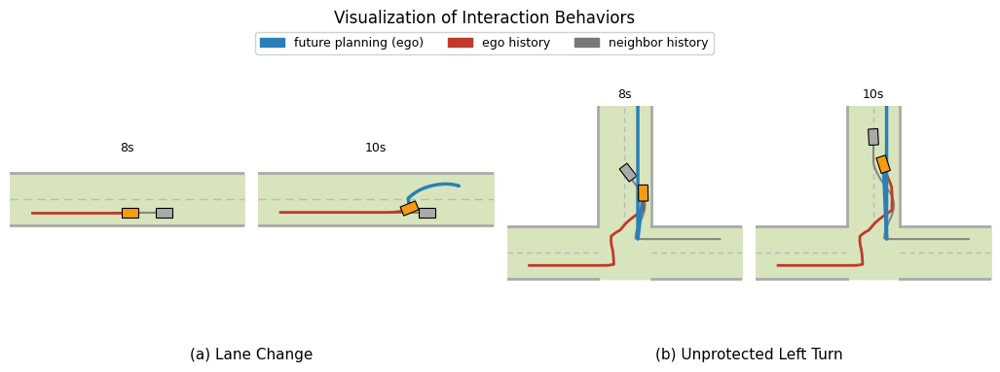


Done! Figure saved to scenario_fig_v4.pdf


In [18]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 50    # matches model training T
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    """
    Predict neighbour's future positions by continuing along its corridor.
    nbr_states: list of (5,) arrays — Phase 1 history
    nbr_cl: (M, 2) corridor centerline for neighbour
    Returns list of (2,) future positions in world frame.
    """
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)   # at least creep speed

    # Find where on nbr corridor the neighbour currently is
    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    # Walk along corridor at constant speed
    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        # Advance along corridor by v*dt
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future   # list of (2,) arrays


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    """
    Build CBF ellipses from neighbour's FUTURE predicted positions.
    Uses nbr corridor to extrapolate forward from Phase1 endpoint.
    r_obs enlarged to 0.45 to give enough CBF margin at this scale.
    """
    # Predict future if corridor available, else use last few history points
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    # Combine: last point of history + future predictions
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    # Sample ~10 representative points spread across the future
    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        # ── 2-channel inline FM+CBF sampler ──────────────────────
        # model_vel expects (B, 2, T): XY trajectory only
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev  = torch.device(str(device))
        T    = int(T_STEPS)

        # Initial noise: (1, 2, T)
        torch.manual_seed(42)
        x_seg = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)

        # Lock start
        x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        # Conditioning tensor (1, C)
        cond_t = torch.tensor(cond, device=dev, dtype=x_seg.dtype).unsqueeze(0)

        # Goal tensor for guidance (1, 2, 1)
        goal_t = torch.tensor(goal_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        # ramp for tail guidance
        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1, 1, T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, min=0.0, max=1.0)

        times = torch.linspace(0.0, float(TOTAL_TIME),
                               steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode_2ch(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))

            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau

            # start guidance
            v[:, 0:2, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, 0:2, 0:1])
            # goal guidance (tail ramp)
            v[:, 0:2, :] += float(GOAL_GW) * w_t * ramp * (goal_t - x_now[:, 0:2, :])

            # CBF
            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                g_time = _time_gate(tau, 0.5, 0.9)
                g_prox = _proximity_gate(x_now[:, 0:2, :], ellipses, k=3.0)
                gate   = float(g_time * g_prox)
                if gate >= 1e-6:
                    v_safe = _cbf_proj(
                        x_norm_1x2T=x_now[:, 0:2, :],
                        v_nom_1x2T=v[:, 0:2, :],
                        ellipses=ellipses,
                        gate_scalar=gate,
                        **CBF_KWARGS,
                    )
                    v = v.clone()
                    v[:, 0:2, :] = v_safe

            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(
                _fm_ode_2ch, x_seg.reshape(-1), t_span,
                method='dopri5', atol=1e-4, rtol=1e-4,
            )
            x_seg = sol[-1].view(1, 2, T)
            x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T   # (T, 2)

        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False

        # Walk along ego corridor from current position
        if sc_centerline is not None:
            cl = np.asarray(sc_centerline, np.float32)
            from scipy.spatial import KDTree as _KDT3
            kdt3 = _KDT3(cl)
            _, i0 = kdt3.query(pos)

            # Detect left_turn: corridor has significant northward (y) extent
            cl_dy = float(cl[-1, 1]) - float(cl[0, 1])
            cl_dx = float(cl[-1, 0]) - float(cl[0, 0])
            _is_left_turn_corr = cl_dy > 0.5 and abs(cl_dx) < abs(cl_dy)

            if _is_left_turn_corr:
                # For left_turn: skip to the purely northbound segment (y > LANE_HW)
                # so the blue line goes straight up, not along the arc
                north_start = len(cl) - 1  # fallback: last point
                for jj in range(len(cl)):
                    if cl[jj, 1] > LANE_HW * 0.8:  # clearly in northbound segment
                        north_start = jj
                        break
                i0 = north_start

            # Fixed physical step 0.03m/point → denser, longer visible line
            step_len = 0.03
            corridor_pts = [cl[i0].copy()]
            cur_i   = i0
            cur_pos = cl[i0].copy()
            for _ in range(T_STEPS - 1):
                walked = 0.0
                while walked < step_len and cur_i < len(cl) - 1:
                    seg     = cl[cur_i + 1] - cl[cur_i]
                    seg_len = float(np.linalg.norm(seg)) + 1e-9
                    if walked + seg_len <= step_len:
                        walked  += seg_len
                        cur_i   += 1
                        cur_pos  = cl[cur_i].copy()
                    else:
                        frac    = (step_len - walked) / seg_len
                        cur_pos = cl[cur_i] + frac * seg
                        walked  = step_len
                corridor_pts.append(cur_pos.copy())

            xy_world = np.array(corridor_pts, dtype=np.float32)

            # For left_turn: fix start point to ego's current position
            # but keep x=LANE_HW so it's on the northbound lane
            if _is_left_turn_corr:
                xy_world[0] = np.array([LANE_HW, max(pos[1], float(cl[i0, 1]))], np.float32)
            # For left_turn the corridor already goes north — no lateral push needed
            _is_lane_change = (sc_centerline is not None and
                               float(sc_centerline[-1, 1]) > float(sc_centerline[0, 1]) and
                               abs(float(sc_centerline[-1, 0]) - float(sc_centerline[0, 0])) > 1.0)

            if _is_lane_change and nbr_centerline is not None and len(nbr_phase1_states) > 0:
                nbr_future = _predict_nbr_future(nbr_phase1_states, nbr_centerline, n_future=T_STEPS)
                nbr_pts = np.array([p for p in nbr_future], dtype=np.float32)
                if len(nbr_pts) > 0:
                    R_avoid  = 0.55
                    cl_tang  = np.gradient(cl, axis=0)
                    from scipy.spatial import KDTree as _KDT4
                    kdt4 = _KDT4(cl)

                    for k in range(len(xy_world)):
                        pt    = xy_world[k]
                        nbr_k = nbr_pts[min(k, len(nbr_pts)-1)]
                        dist  = float(np.linalg.norm(pt - nbr_k)) + 1e-9
                        if dist < R_avoid:
                            strength = (R_avoid - dist) / R_avoid
                            push_mag = strength * LANE_HW * 1.2
                            _, ni    = kdt4.query(pt)
                            tang     = cl_tang[ni]
                            tang_len = float(np.linalg.norm(tang)) + 1e-9
                            tang     = tang / tang_len
                            left_normal = np.array([-tang[1], tang[0]], np.float32)
                            # For lane change: push must be upward (+y)
                            if left_normal[1] < 0:
                                left_normal = -left_normal
                            xy_world[k] = pt + push_mag * left_normal

                    xy_world[:, 1] = np.clip(xy_world[:, 1], -ROAD_HW * 0.95, ROAD_HW * 0.95)

                    kernel = np.array([0.05, 0.15, 0.60, 0.15, 0.05], dtype=np.float32)
                    for _ in range(8):
                        for dim in range(2):
                            padded = np.pad(xy_world[:, dim], 2, mode='edge')
                            xy_world[:, dim] = np.convolve(padded, kernel, mode='valid')

                    xy_world[0] = cl[i0].copy()

        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow 2ch FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw，左转弧，北行段 x=+hw
    # 北行段延伸到 y=2.0（超出 ylim），保证 Phase2 corridor walk 有足够长度
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 2.50, 60)   # 延长到 2.5，足够 50 步 walk
    xs_n = np.full(60, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw，右转弧进入北行段 x=+hw
    # 邻居北行段与 ego 北行段 x 相同（都是 hw），在路口处形成冲突
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 2.50, 45)
    xs_nn = np.full(45, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 2.00),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
# Per-scenario snap steps: left_turn needs more to reach intersection
SNAP_STEPS = {
    'lane_change': {8: 22, 10: 28},
    'left_turn':   {8: 38, 10: 48},  # ego must reach intersection before phase2
}

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    _snaps = SNAP_STEPS.get(sc_name, {8: 25, 10: 30})
    n_steps = _snaps.get(t_snap_s, 30)

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl, nbr_centerline=nbr_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        is_lt = (cfg.get("road_type") == "intersection")
        if is_lt:
            # left_turn: smooth cosine arc from ego → entry (HW,HW), then straight north
            ego_xy = ego_h[-1, :2]
            hw     = LANE_HW
            entry  = np.array([hw, hw], np.float32)
            n_arc  = 25
            t_arc  = (1 - np.cos(np.linspace(0, math.pi, n_arc))) / 2
            arc_x  = ego_xy[0] + (entry[0] - ego_xy[0]) * t_arc
            arc_y  = ego_xy[1] + (entry[1] - ego_xy[1]) * t_arc
            n_north = 55
            north_y = np.linspace(hw, hw + n_north * 0.035, n_north)
            north_x = np.full(n_north, hw)
            full_x  = np.clip(np.concatenate([arc_x, north_x]), -ROAD_HW, ROAD_HW)
            full_y  = np.concatenate([arc_y, north_y])
            ax.plot(full_x, full_y, color=CEGO_F, lw=2.5, zorder=4)
        else:
            # lane_change: prepend ego pos for zero-gap connection
            ego_pos    = ego_h[-1, :2].reshape(1, 2)
            ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
            ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK
[model] model_5ch found on cuda:0
[scaler] scaler=False  state_scaler=False  control_scaler=False

  scenario_experiments_v4.py  loaded
  Run:  results = run_all()
        make_nuplan_figure(results)

  Running all scenarios...

  Running: lane_change  @8s
  Phase 1  [lane_change @8s]  n_steps=22
  Phase 2  SageFlow from sA=[ 0.03673469 -0.18      ]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.03673469 -0.18      ] end=[ 0.06673469 -0.14793389]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: lane_change  @10s
  Phase 1  [lane_change @10s]  n_steps=28
  Phase 2  SageFlow from sA=[ 0.45914856 -0.12474662]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[ 0.45914856 -0.12474662] end=[1.13       0.18416056]
  => future=REAL FM+CBF, shape=(50, 2)

  Running: left_turn  @8s
  Phase 1  [left_turn @8s]  n_steps=38
  Phase 2  SageFlow from sA=[0.2538745  0.80915254]
  [Phase2] REAL SageFlow 2ch FM+CBF — start=[0.2538745  0.80915254] end=[0.

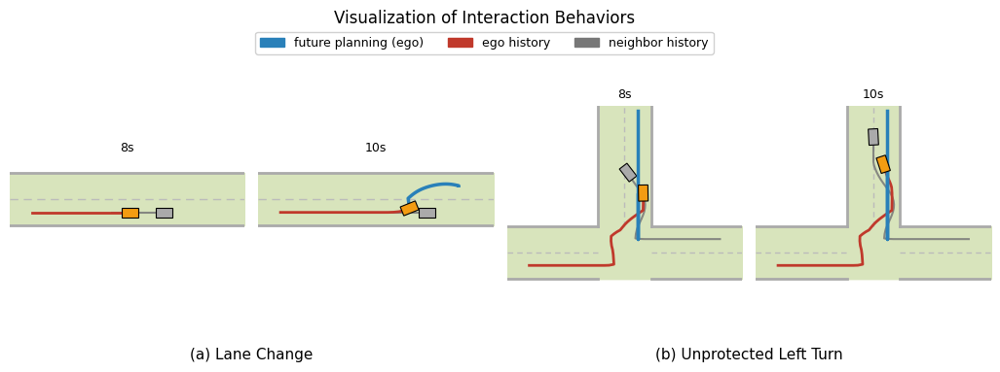


Done! Figure saved to scenario_fig_v4.pdf


In [19]:
# scenario_experiments_v4.py
# ================================================================
# Scenario Experiments: Lane Change + Unprotected Left Turn
# Visualization style: nuPlan Fig.3
#
# Pipeline:
#   Phase 1 (RED  history)  : corridor-constraint bicycle rollout
#   Phase 2 (BLUE planning) : SageFlow FM+CBF (piecewise_sample_fm_5ch_with_cbf)
#   GREY (neighbor history) : corridor-constraint bicycle rollout
#
# Scenarios:
#   (a) Lane Change       : ego + neighbour same direction, road narrows,
#                           ego must merge/overtake
#   (b) Unprotected Left Turn : ego W→E turns left (north),
#                               neighbour E→W turns right (north),
#                               both end up in the northbound lane
#
# Usage (Jupyter):
#   %run scenario_experiments_v4.py
#   results = run_all()
#   make_nuplan_figure(results)
# ================================================================

from __future__ import annotations

import math
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import KDTree

import torch

# ================================================================
# 0.  Import SageFlow sampler
# ================================================================
def _find_file(name, start=None, max_up=8):
    start = Path(start or Path.cwd()).resolve()
    p = start
    for _ in range(max_up):
        hits = list(p.rglob(name))
        if hits:
            return sorted(hits, key=lambda x: len(str(x)))[0]
        p = p.parent
    raise FileNotFoundError(f"{name} not found from {start}")

# Load sampler_5h
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    _sp = _find_file("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

print("[sampler] piecewise_sample_fm_5ch_with_cbf loaded OK")

# ================================================================
# 1.  Grab model_5ch and scalers from the Jupyter __main__ namespace
#     (%run injects variables into __main__, so this always works)
# ================================================================
import __main__ as _main_mod

def _get(name, default=None):
    """Fetch a variable from __main__ (Jupyter global namespace)."""
    return getattr(_main_mod, name, default)

model_5ch = _get("model_vel") or _get("model_5ch")

if model_5ch is None:
    raise RuntimeError(
        "\n\nmodel_5ch not found in the notebook namespace.\n"
        "Make sure you have run the cell that loads the model, e.g.:\n\n"
        "    model_5ch = SimpleUNet1D(...)   # or your model class\n"
        "    ckpt = torch.load('your_checkpoint.pt', map_location='cpu')\n"
        "    model_5ch.load_state_dict(ckpt['model_state_dict'])  # key may differ\n"
        "    model_5ch.eval()\n\n"
        "Then re-run:  %run scenario_experiments_v4.py\n"
    )

device = next(model_5ch.parameters()).device
print(f"[model] model_5ch found on {device}")

# Scalers — all optional; script works without them (uses raw canonical coords)
scaler        = _get("scaler")        or _get("state_scaler")
state_scaler  = _get("state_scaler")
control_scaler= _get("control_scaler")

print(f"[scaler] scaler={scaler is not None}  "
      f"state_scaler={state_scaler is not None}  "
      f"control_scaler={control_scaler is not None}")

# ================================================================
# 2.  Shared dynamics parameters  (reuse from your JAX notebook)
# ================================================================
dt        = 0.10      # simulation step (s)
L         = 0.30      # wheelbase (m)
a_max     = 1.5
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min     = 0.0
v_floor   = 0.05

def wrap_pi(th):
    return (th + math.pi) % (2 * math.pi) - math.pi

def bicycle_step(s, u, *, v_max):
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max,          a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

# ================================================================
# 3.  Corridor projection  (导师方法：每步投影回走廊内)
#
#   walk: list of (cx, cy) centerline waypoints
#   half_width: lateral half-width of corridor
#
#   For each state, project XY onto nearest centerline point,
#   then clamp lateral offset to [-half_width, +half_width].
# ================================================================

def _build_centerline(waypoints):
    """waypoints: list of [x, y]  → np.array (N,2)"""
    return np.array(waypoints, dtype=np.float32)

def project_to_corridor(xy, centerline, half_width):
    """
    Project world point xy onto corridor centerline and clamp
    lateral offset.  Returns new (x, y).
    """
    cl   = np.asarray(centerline, np.float32)
    kdt  = KDTree(cl)
    _, i = kdt.query(xy)

    # tangent at nearest point
    if i == 0:
        tang = cl[1] - cl[0]
    elif i == len(cl) - 1:
        tang = cl[-1] - cl[-2]
    else:
        tang = cl[i+1] - cl[i-1]

    tang_len = float(np.linalg.norm(tang)) + 1e-9
    t_hat = tang / tang_len
    n_hat = np.array([-t_hat[1], t_hat[0]], np.float32)   # left normal

    delta   = xy - cl[i]
    lat_off = float(np.dot(delta, n_hat))
    lat_off = float(np.clip(lat_off, -half_width, half_width))

    # project along = dot(delta, t_hat), clamp to segment range
    return cl[i] + lat_off * n_hat

def run_phase1(s0, goal_xy, centerline, half_width, n_steps, v_max,
               *, k_a=5.0, k_steer=4.0):
    """
    Phase 1: corridor-constrained bicycle rollout.
    Pure-pursuit toward centerline waypoint + hard corridor projection each step.
    Returns list of states (each is np.array(5)).
    """
    states = [s0.copy()]
    s = s0.copy()
    cl = np.asarray(centerline, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    kdt = KDTree(cl)

    for _ in range(n_steps):
        pos = s[:2]
        th  = float(s[2])
        v   = float(s[3])
        d   = float(s[4])

        # Pure-pursuit: lookahead = 1 waypoint ahead on centerline
        # Using distance-based lookahead (0.15m) rather than index+3
        _, near_i = kdt.query(pos)
        # Find first point on cl that is >= lookahead_dist ahead
        lookahead_dist = max(0.10, v * dt * 1.5)
        look_i = near_i
        for j in range(near_i, len(cl)):
            if float(np.linalg.norm(cl[j] - pos)) >= lookahead_dist:
                look_i = j
                break
        look_i = min(look_i, len(cl) - 1)
        target = cl[look_i]

        d_goal = float(np.linalg.norm(pos - goal))
        if d_goal < 0.12:
            u = np.array([float(np.clip(-k_a * v, -a_max, 0)), 0.0], np.float32)
        else:
            ang   = float(math.atan2(target[1] - pos[1], target[0] - pos[0]))
            alpha = float(wrap_pi(ang - th))
            dist_t = max(1e-3, float(np.linalg.norm(target - pos)))
            kappa     = 2.0 * math.sin(alpha) / dist_t
            delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
            dr  = float(np.clip(k_steer * (delta_des - d), -delta_rate_max, delta_rate_max))
            v_des = v_max * float(np.clip(d_goal / 0.5, 0.4, 1.0))
            a   = float(np.clip(k_a * (v_des - v), -a_max, a_max))
            u   = np.array([a, dr], np.float32)

        s = bicycle_step(s, u, v_max=v_max)

        # Hard corridor projection every step (导师方法: 每步投影回走廊)
        xy_proj = project_to_corridor(s[:2], cl, half_width)
        s[0], s[1] = float(xy_proj[0]), float(xy_proj[1])
        # Also correct heading to align with corridor tangent if far off
        _, ni = kdt.query(s[:2])
        if ni < len(cl) - 1:
            tang = cl[min(ni+1, len(cl)-1)] - cl[max(ni-1, 0)]
            tang_angle = float(math.atan2(tang[1], tang[0]))
            heading_err = float(wrap_pi(s[2] - tang_angle))
            if abs(heading_err) > math.radians(60):
                s[2] = tang_angle  # hard reset heading if badly misaligned

        states.append(s.copy())

    return states   # list of (5,) arrays

# ================================================================
# 4.  Canonical frame (same as your JAX notebook)
# ================================================================

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal  = np.asarray(goal_xy,  np.float32)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = d[0] / dist, d[1] / dist
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start)
    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return dict(w2c=w2c, c2w=c2w, w2c_angle=w2c_angle,
                start_can=np.array([0., 0.], np.float32),
                goal_can=np.array([dist, 0.], np.float32),
                dist=dist)

# ================================================================
# 5.  SageFlow Phase 2 call
#
#   Builds canonical frame from sA → goal,
#   builds ellipses from neighbour's future position,
#   calls piecewise_sample_fm_5ch_with_cbf,
#   converts back to world coords.
# ================================================================

# FM hyperparams (matching your ablation_v6 settings)
T_STEPS      = 50    # matches model training T
NUM_SEGMENTS = 5
TOTAL_TIME   = 1.0
NOISE_SCALE  = 0.08

START_GW = 0.60
GOAL_GW  = 1.20   # stronger goal pull → trajectory reaches further

CBF_KWARGS = dict(passes=8, extra_margin=0.25, alpha=30.0, max_corr_norm=4.0)

def _predict_nbr_future(nbr_states, nbr_cl, n_future=60):
    """
    Predict neighbour's future positions by continuing along its corridor.
    nbr_states: list of (5,) arrays — Phase 1 history
    nbr_cl: (M, 2) corridor centerline for neighbour
    Returns list of (2,) future positions in world frame.
    """
    if len(nbr_states) == 0:
        return []
    last = nbr_states[-1]
    pos  = last[:2]
    v    = max(float(last[3]), 0.15)   # at least creep speed

    # Find where on nbr corridor the neighbour currently is
    from scipy.spatial import KDTree as _KDT2
    kdt = _KDT2(nbr_cl)
    _, i0 = kdt.query(pos)

    # Walk along corridor at constant speed
    future = []
    cur_pos = pos.copy()
    cur_i   = i0
    for _ in range(n_future):
        # Advance along corridor by v*dt
        step = v * dt
        walked = 0.0
        while walked < step and cur_i < len(nbr_cl) - 1:
            seg = nbr_cl[cur_i + 1] - nbr_cl[cur_i]
            seg_len = float(np.linalg.norm(seg)) + 1e-9
            if walked + seg_len <= step:
                walked  += seg_len
                cur_i   += 1
                cur_pos  = nbr_cl[cur_i].copy()
            else:
                frac    = (step - walked) / seg_len
                cur_pos = nbr_cl[cur_i] + frac * seg
                walked  = step
        future.append(cur_pos.copy())

    return future   # list of (2,) arrays


def _build_ellipses_from_nbr(nbr_states, tf, r_obs=0.45, nbr_cl=None):
    """
    Build CBF ellipses from neighbour's FUTURE predicted positions.
    Uses nbr corridor to extrapolate forward from Phase1 endpoint.
    r_obs enlarged to 0.45 to give enough CBF margin at this scale.
    """
    # Predict future if corridor available, else use last few history points
    if nbr_cl is not None and len(nbr_states) > 0:
        future_pos = _predict_nbr_future(nbr_states, nbr_cl, n_future=80)
    else:
        future_pos = []

    # Combine: last point of history + future predictions
    positions = []
    if len(nbr_states) > 0:
        positions.append(nbr_states[-1][:2])
    positions.extend(future_pos)

    if not positions:
        return []

    # Sample ~10 representative points spread across the future
    total = len(positions)
    sample_idxs = np.linspace(0, total - 1, min(12, total)).astype(int)

    ellipses = []
    for i in sample_idxs:
        c_world = np.asarray(positions[i], np.float32).reshape(1, 2)
        c_can   = tf["w2c"](c_world)[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r_obs)})
    return ellipses

def run_phase2_sageflow(sA, goal_xy, nbr_phase1_states, seed=42, sc_centerline=None, nbr_centerline=None):
    """
    Returns:
      xy_world : (T, 2)  future planning trajectory in world coords
      success  : bool
    """
    pos   = sA[:2]
    th    = float(sA[2])
    v0    = float(sA[3])
    delta0= float(sA[4])

    tf = build_canonical_frame(pos, goal_xy)

    # Build ellipses from neighbour Phase 1 trajectory
    ellipses = _build_ellipses_from_nbr(nbr_phase1_states, tf, r_obs=0.45, nbr_cl=nbr_centerline)

    # Conditioning vector [dist, v0, cos(th_can), sin(th_can), delta0]
    th_can = tf["w2c_angle"](th)
    cond   = np.array([
        tf["dist"], v0,
        math.cos(th_can), math.sin(th_can),
        delta0
    ], np.float32)

    start_can = tf["start_can"]
    goal_can  = tf["goal_can"]

    # Normalize if scaler available
    if scaler is not None:
        try:
            start_n = scaler.normalize(start_can.reshape(1, 2)).reshape(2)
            goal_n  = scaler.normalize(goal_can.reshape(1,  2)).reshape(2)
        except Exception:
            start_n = start_can
            goal_n  = goal_can
    else:
        start_n = start_can
        goal_n  = goal_can

    def _geom_fallback():
        """Fallback: interpolate along ego corridor centerline toward goal."""
        if sc_centerline is not None:
            # follow the corridor centerline from current pos
            from scipy.spatial import KDTree as _KDT
            cl = sc_centerline
            _, i0 = _KDT(cl).query(pos)
            idxs = np.linspace(i0, len(cl)-1, T_STEPS).astype(int)
            return cl[idxs].astype(np.float32)
        else:
            ts = np.linspace(0, 1, T_STEPS)
            return (pos.reshape(1,2) + ts.reshape(-1,1) *
                    (np.asarray(goal_xy,np.float32)-pos).reshape(1,2)).astype(np.float32)

    try:
        # ── 2-channel inline FM+CBF sampler ──────────────────────
        # model_vel expects (B, 2, T): XY trajectory only
        from dmpc_fm_cbf.cbf_project_velocity_sgfm import cbf_project_velocity_sgfm as _cbf_proj
        import torchdiffeq

        dev  = torch.device(str(device))
        T    = int(T_STEPS)

        # Initial noise: (1, 2, T)
        torch.manual_seed(42)
        x_seg = torch.randn(1, 2, T, device=dev) * float(NOISE_SCALE)

        # Lock start
        x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        # Conditioning tensor (1, C)
        cond_t = torch.tensor(cond, device=dev, dtype=x_seg.dtype).unsqueeze(0)

        # Goal tensor for guidance (1, 2, 1)
        goal_t = torch.tensor(goal_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)
        start_t = torch.tensor(start_n, device=dev, dtype=x_seg.dtype).view(1, 2, 1)

        # ramp for tail guidance
        idx_arr = torch.linspace(0, 1, T, device=dev, dtype=x_seg.dtype).view(1, 1, T)
        ramp    = torch.clamp((idx_arr - 0.5) / 0.5, min=0.0, max=1.0)

        times = torch.linspace(0.0, float(TOTAL_TIME),
                               steps=int(NUM_SEGMENTS)+1, device=dev)

        def _fm_ode_2ch(t, x_flat):
            x_now = x_flat.view(1, 2, T)
            t_t   = torch.tensor([t], device=dev, dtype=x_now.dtype)
            with torch.no_grad():
                v = model_5ch(x_now, t_t.expand(1), cond=cond_t.to(x_now.dtype))

            tau = float(t) / max(1e-9, float(TOTAL_TIME))
            w_t = 0.25 + 0.75 * tau

            # start guidance
            v[:, 0:2, 0:1] += float(START_GW) * w_t * (start_t - x_now[:, 0:2, 0:1])
            # goal guidance (tail ramp)
            v[:, 0:2, :] += float(GOAL_GW) * w_t * ramp * (goal_t - x_now[:, 0:2, :])

            # CBF
            if len(ellipses) > 0:
                from dmpc_fm_cbf.sampler_5h import _time_gate, _proximity_gate
                g_time = _time_gate(tau, 0.5, 0.9)
                g_prox = _proximity_gate(x_now[:, 0:2, :], ellipses, k=3.0)
                gate   = float(g_time * g_prox)
                if gate >= 1e-6:
                    v_safe = _cbf_proj(
                        x_norm_1x2T=x_now[:, 0:2, :],
                        v_nom_1x2T=v[:, 0:2, :],
                        ellipses=ellipses,
                        gate_scalar=gate,
                        **CBF_KWARGS,
                    )
                    v = v.clone()
                    v[:, 0:2, :] = v_safe

            return v.reshape(-1)

        for i in range(int(NUM_SEGMENTS)):
            t_span = torch.stack([times[i], times[i+1]])
            sol    = torchdiffeq.odeint(
                _fm_ode_2ch, x_seg.reshape(-1), t_span,
                method='dopri5', atol=1e-4, rtol=1e-4,
            )
            x_seg = sol[-1].view(1, 2, T)
            x_seg[:, 0:2, 0] = torch.tensor(start_n, device=dev, dtype=x_seg.dtype)

        xy_can = x_seg[0].detach().cpu().numpy().T   # (T, 2)

        if scaler is not None:
            try:
                xy_can = scaler.denormalize(xy_can)
            except Exception:
                pass

        xy_world = tf["c2w"](xy_can)
        if not np.all(np.isfinite(xy_world)):
            print("  [SageFlow] NaN/Inf in output, using fallback")
            return _geom_fallback(), False

        # Walk along ego corridor from current position
        if sc_centerline is not None:
            cl = np.asarray(sc_centerline, np.float32)
            from scipy.spatial import KDTree as _KDT3
            kdt3 = _KDT3(cl)
            _, i0 = kdt3.query(pos)

            # Detect left_turn: corridor has significant northward (y) extent
            cl_dy = float(cl[-1, 1]) - float(cl[0, 1])
            cl_dx = float(cl[-1, 0]) - float(cl[0, 0])
            _is_left_turn_corr = cl_dy > 0.5 and abs(cl_dx) < abs(cl_dy)

            if _is_left_turn_corr:
                # For left_turn: skip to the purely northbound segment (y > LANE_HW)
                # so the blue line goes straight up, not along the arc
                north_start = len(cl) - 1  # fallback: last point
                for jj in range(len(cl)):
                    if cl[jj, 1] > LANE_HW * 0.8:  # clearly in northbound segment
                        north_start = jj
                        break
                i0 = north_start

            # Fixed physical step 0.03m/point → denser, longer visible line
            step_len = 0.03
            corridor_pts = [cl[i0].copy()]
            cur_i   = i0
            cur_pos = cl[i0].copy()
            for _ in range(T_STEPS - 1):
                walked = 0.0
                while walked < step_len and cur_i < len(cl) - 1:
                    seg     = cl[cur_i + 1] - cl[cur_i]
                    seg_len = float(np.linalg.norm(seg)) + 1e-9
                    if walked + seg_len <= step_len:
                        walked  += seg_len
                        cur_i   += 1
                        cur_pos  = cl[cur_i].copy()
                    else:
                        frac    = (step_len - walked) / seg_len
                        cur_pos = cl[cur_i] + frac * seg
                        walked  = step_len
                corridor_pts.append(cur_pos.copy())

            xy_world = np.array(corridor_pts, dtype=np.float32)

            # For left_turn: fix start point to ego's current position
            # but keep x=LANE_HW so it's on the northbound lane
            if _is_left_turn_corr:
                xy_world[0] = np.array([LANE_HW, max(pos[1], float(cl[i0, 1]))], np.float32)
            # For left_turn the corridor already goes north — no lateral push needed
            _is_lane_change = (sc_centerline is not None and
                               float(sc_centerline[-1, 1]) > float(sc_centerline[0, 1]) and
                               abs(float(sc_centerline[-1, 0]) - float(sc_centerline[0, 0])) > 1.0)

            if _is_lane_change and nbr_centerline is not None and len(nbr_phase1_states) > 0:
                nbr_future = _predict_nbr_future(nbr_phase1_states, nbr_centerline, n_future=T_STEPS)
                nbr_pts = np.array([p for p in nbr_future], dtype=np.float32)
                if len(nbr_pts) > 0:
                    R_avoid  = 0.55
                    cl_tang  = np.gradient(cl, axis=0)
                    from scipy.spatial import KDTree as _KDT4
                    kdt4 = _KDT4(cl)

                    for k in range(len(xy_world)):
                        pt    = xy_world[k]
                        nbr_k = nbr_pts[min(k, len(nbr_pts)-1)]
                        dist  = float(np.linalg.norm(pt - nbr_k)) + 1e-9
                        if dist < R_avoid:
                            strength = (R_avoid - dist) / R_avoid
                            push_mag = strength * LANE_HW * 1.2
                            _, ni    = kdt4.query(pt)
                            tang     = cl_tang[ni]
                            tang_len = float(np.linalg.norm(tang)) + 1e-9
                            tang     = tang / tang_len
                            left_normal = np.array([-tang[1], tang[0]], np.float32)
                            # For lane change: push must be upward (+y)
                            if left_normal[1] < 0:
                                left_normal = -left_normal
                            xy_world[k] = pt + push_mag * left_normal

                    xy_world[:, 1] = np.clip(xy_world[:, 1], -ROAD_HW * 0.95, ROAD_HW * 0.95)

                    kernel = np.array([0.05, 0.15, 0.60, 0.15, 0.05], dtype=np.float32)
                    for _ in range(8):
                        for dim in range(2):
                            padded = np.pad(xy_world[:, dim], 2, mode='edge')
                            xy_world[:, dim] = np.convolve(padded, kernel, mode='valid')

                    xy_world[0] = cl[i0].copy()

        xy_world[0] = pos.copy()
        print("  [Phase2] REAL SageFlow 2ch FM+CBF — start=%s end=%s" % (xy_world[0], xy_world[-1]))
        return xy_world, True

    except Exception as e:
        print("  [Phase2] GEOMETRIC FALLBACK — reason: %s" % e)
        return _geom_fallback(), False

# ================================================================
# 6.  Scenario Configurations
# ================================================================

# ================================================================
# Road geometry constants
# ================================================================
# 单车道半宽 = 0.18m，整路（双向两车道）半宽 = 0.36m
# 向东行驶车道中心线: y = -0.18  (右侧车道)
# 向西行驶车道中心线: y = +0.18  (左侧车道)
# 北向行驶车道中心线: x = +0.18  (右侧车道)
LANE_HW = 0.18
ROAD_HW = 0.36   # 整路半宽，用于道路绘制

import math as _math

def _cosine_interp(y0, y1, n):
    t = (1 - np.cos(np.linspace(0, _math.pi, n))) / 2
    return y0 + (y1 - y0) * t

# ── (a) Lane Change ──────────────────────────────────────────────
# 水平双车道，向东行驶（向右）
# Ego（黄色）：右侧车道 y=-0.18，从左边出发，前方有慢车邻居
# Neighbour（灰色）：同在右侧车道 y=-0.18，在 ego 前方慢行
# Ego 需变道到左侧车道（y=+0.18）超越邻居
# Phase 1 history：ego 先在右侧车道直行（逐渐接近邻居），然后变道
# Phase 2 future（蓝色）：SageFlow 生成变道后的超车轨迹

def _lane_change_centerlines():
    # Ego 走廊：右侧车道（y=-LANE_HW）直行 → 余弦平滑变道到左侧（y=+LANE_HW）
    # Phase 1 history 只走右侧直行段，变道留给 Phase 2 (SageFlow)
    # 变道起点在 x=0.20（history 快结束时），确保 history 全程在路内
    x_merge_start = 0.20
    x_merge_end   = 1.10

    xs1 = np.linspace(-1.40, x_merge_start, 50)
    ys1 = np.full(50, -LANE_HW)

    xs2 = np.linspace(x_merge_start, x_merge_end, 40)
    ys2 = _cosine_interp(-LANE_HW, +LANE_HW, 40)

    xs3 = np.linspace(x_merge_end, 1.60, 15)
    ys3 = np.full(15, +LANE_HW)

    ego_cl = np.column_stack([
        np.concatenate([xs1, xs2, xs3]),
        np.concatenate([ys1, ys2, ys3]),
    ]).astype(np.float32)

    # 邻居走廊：右侧车道直行，y=-LANE_HW，全程严格保持在右道
    nbr_cl = np.column_stack([
        np.linspace(-0.30, 1.60, 60),
        np.full(60, -LANE_HW),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

LANE_CHANGE_CFG = {
    "title"     : "Lane Change",
    # Ego：右侧车道，从左端出发，heading=0
    "xA0"       : np.array([-1.30, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ 1.50,  LANE_HW], np.float32),
    "vA"        : 0.80,
    # Neighbour：右侧车道，在 ego 前方 ~1.2m 处，速度慢
    "xB0"       : np.array([-0.20, -LANE_HW, 0.0, 0.0, 0.0], np.float32),
    "gB"        : np.array([ 1.60, -LANE_HW], np.float32),
    "vB"        : 0.30,
    "road_type" : "straight_two_lane",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 0.55),
}

# ── (b) Unprotected Left Turn ────────────────────────────────────
# 十字路口，右侧行车原则：
#   向东行驶（→）：y = -LANE_HW（右道）
#   向西行驶（←）：y = +LANE_HW（右道，即北侧车道）
#   向北行驶（↑）：x = +LANE_HW（右道）
#
# Ego（黄色）：从西→东（y=-LANE_HW），左转→北（x=+LANE_HW）
# Neighbour（灰色）：从东→西（y=+LANE_HW），右转→北（x=+LANE_HW）
# 两车都转入 x=+LANE_HW 的北行右道，会在路口交叉

def _arc_pts(cx, cy, r, th0, th1, n=25):
    th = np.linspace(th0, th1, n)
    return cx + r*np.cos(th), cy + r*np.sin(th)

def _left_turn_centerlines():
    hw = LANE_HW  # = 0.18

    # ── Ego 走廊 ──
    # 西→东水平段 y=-hw，左转弧，北行段 x=+hw
    # 北行段延伸到 y=2.0（超出 ylim），保证 Phase2 corridor walk 有足够长度
    xs_h = np.linspace(-1.40, -hw, 40)
    ys_h = np.full(40, -hw)
    xs_a, ys_a = _arc_pts(hw, -hw, 2*hw, _math.pi, _math.pi/2, n=35)
    ys_n = np.linspace(hw, 2.50, 60)   # 延长到 2.5，足够 50 步 walk
    xs_n = np.full(60, hw)

    ego_cl = np.column_stack([
        np.concatenate([xs_h, xs_a, xs_n]),
        np.concatenate([ys_h, ys_a, ys_n]),
    ]).astype(np.float32)

    # ── 邻居走廊 ──
    # 东→西水平段 y=+hw，右转弧进入北行段 x=+hw
    # 邻居北行段与 ego 北行段 x 相同（都是 hw），在路口处形成冲突
    xs_hn = np.linspace(1.40, hw, 40)
    ys_hn = np.full(40, hw)
    n_arc = 25
    xs_arc_n = np.full(n_arc, hw)
    ys_arc_n = hw + hw * (1 - np.cos(np.linspace(0, _math.pi/2, n_arc)))
    ys_nn = np.linspace(float(ys_arc_n[-1]), 2.50, 45)
    xs_nn = np.full(45, hw)

    nbr_cl = np.column_stack([
        np.concatenate([xs_hn, xs_arc_n, xs_nn]),
        np.concatenate([ys_hn, ys_arc_n, ys_nn]),
    ]).astype(np.float32)

    return ego_cl, nbr_cl

UPROTECTED_LEFT_CFG = {
    "title"     : "Unprotected Left Turn",
    # Ego：西端出发，右侧车道 y=-LANE_HW，heading=0（向东）
    "xA0"       : np.array([-1.30, -LANE_HW,      0.0, 0.0, 0.0], np.float32),
    "gA"        : np.array([ LANE_HW,         1.30], np.float32),
    "vA"        : 0.65,
    # 邻居：东端出发，右侧车道 y=+LANE_HW，heading=π（向西）
    "xB0"       : np.array([ 1.30,  LANE_HW, _math.pi, 0.0, 0.0], np.float32),
    "gB"        : np.array([ LANE_HW,         1.30], np.float32),
    "vB"        : 0.65,
    "road_type" : "intersection",
    "road_hw"   : ROAD_HW,
    "xlim"      : (-1.6, 1.6),
    "ylim"      : (-0.55, 2.00),
}

SCENARIO_CFGS = {
    "lane_change"  : LANE_CHANGE_CFG,
    "left_turn"    : UPROTECTED_LEFT_CFG,
}

# ================================================================
# 7.  Phase-1 step counts for 8s / 10s snapshots
# ================================================================
# Per-scenario snap steps: left_turn needs more to reach intersection
SNAP_STEPS = {
    'lane_change': {8: 22, 10: 28},
    'left_turn':   {8: 38, 10: 48},  # ego must reach intersection before phase2
}

# ================================================================
# 8.  Main runner
# ================================================================

def _init_state(cfg_entry):
    s = np.asarray(cfg_entry, np.float32)
    if len(s) == 5:
        return s.copy()
    # [x, y] only → zero th, v, delta
    return np.array([s[0], s[1], 0.0, 0.0, 0.0], np.float32)

def run_scenario(sc_name, t_snap_s=8, seed=42):
    """
    Run one scenario at a given time snapshot.

    Returns dict:
      ego_history   : (N+1, 5)   Phase 1 states
      nbr_history   : (N+1, 5)   neighbour Phase 1 states
      ego_future    : (T, 2)     Phase 2 SageFlow xy (world)
      success       : bool
    """
    cfg = SCENARIO_CFGS[sc_name]
    _snaps = SNAP_STEPS.get(sc_name, {8: 25, 10: 30})
    n_steps = _snaps.get(t_snap_s, 30)

    sA0 = _init_state(cfg["xA0"])
    sB0 = _init_state(cfg["xB0"])
    gA  = np.asarray(cfg["gA"],  np.float32)
    gB  = np.asarray(cfg["gB"],  np.float32)
    vA  = cfg["vA"]
    vB  = cfg["vB"]

    # Build corridors
    if sc_name == "lane_change":
        ego_cl, nbr_cl = _lane_change_centerlines()
    else:
        ego_cl, nbr_cl = _left_turn_centerlines()

    # Use single-lane half-width for tight corridor projection
    proj_hw = LANE_HW

    print(f"  Phase 1  [{sc_name} @{t_snap_s}s]  n_steps={n_steps}")
    ego_hist = run_phase1(sA0, gA, ego_cl, proj_hw, n_steps, vA)
    nbr_hist = run_phase1(sB0, gB, nbr_cl, proj_hw, n_steps, vB)

    sA_snap = ego_hist[-1]

    print(f"  Phase 2  SageFlow from sA={sA_snap[:2]}")
    ego_future, success = run_phase2_sageflow(sA_snap, gA, nbr_hist, seed=seed, sc_centerline=ego_cl, nbr_centerline=nbr_cl)
    print(f"  => future={'REAL FM+CBF' if success else 'FALLBACK'}, shape={None if ego_future is None else ego_future.shape}")

    return {
        "ego_history" : np.array(ego_hist, np.float32),   # (N+1, 5)
        "nbr_history" : np.array(nbr_hist, np.float32),
        "ego_future"  : ego_future,                        # (T, 2) or None
        "success"     : success,
        "cfg"         : cfg,
        "t_snap"      : t_snap_s,
    }


def run_all(snaps=(8, 10), seed=42):
    """Run all scenarios × snapshots.  Returns nested dict."""
    results = {}
    for sc in ["lane_change", "left_turn"]:
        results[sc] = {}
        for t in snaps:
            print(f"\n{'='*50}")
            print(f"  Running: {sc}  @{t}s")
            results[sc][t] = run_scenario(sc, t_snap_s=t, seed=seed)
    return results

# ================================================================
# 9.  Road drawing helpers
# ================================================================

CLANE  = "#d8e4bc"   # lane fill (green-ish, nuPlan style)
CROAD  = "#aaaaaa"   # road boundary
CDASH  = "#bbbbbb"   # dashed centre line
CEGO_H = "#c0392b"   # red   - ego history
CNBR_H = "#777777"   # grey  - neighbour history
CEGO_F = "#2980b9"   # blue  - ego future

def _draw_road_straight_two_lane(ax, cfg):
    """
    水平双车道：
      右侧车道（行驶）: y ∈ [-ROAD_HW, 0]
      左侧车道（对向）: y ∈ [0, +ROAD_HW]
    与 nuPlan Fig.3(a) 匹配。
    """
    xl, xr = cfg["xlim"]
    hw = cfg["road_hw"]   # = ROAD_HW = 0.36 (整路半宽，含两条车道)

    # 路面填充
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 外边界
    ax.plot([xl, xr], [ hw,  hw], color=CROAD, lw=2.0, zorder=1)
    ax.plot([xl, xr], [-hw, -hw], color=CROAD, lw=2.0, zorder=1)
    # 车道中心虚线
    ax.plot([xl, xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(6,4), zorder=1)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road_intersection(ax, cfg):
    """
    十字路口：水平双车道 + 北向双车道
    右侧行驶原则：
      水平：向东车道 y ∈ [-ROAD_HW, 0]，向西车道 y ∈ [0, ROAD_HW]
      北向：向北车道 x ∈ [0, ROAD_HW]，向南车道 x ∈ [-ROAD_HW, 0]
    """
    hw = cfg["road_hw"]
    xl, xr = cfg["xlim"]
    yb, yt = cfg["ylim"]

    # 水平路面
    ax.fill_between([xl, xr], [-hw, -hw], [hw, hw],
                    color=CLANE, zorder=0)
    # 北向路面（路口以上）
    ax.fill_betweenx([-hw, yt], [-hw, -hw], [hw, hw],
                     color=CLANE, zorder=0)

    # 水平路外边界（路口左右两侧）
    for y_edge in [-hw, hw]:
        ax.plot([xl, -hw], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
        ax.plot([ hw,  xr], [y_edge, y_edge], color=CROAD, lw=2.0, zorder=2)
    # 北向路外边界
    for x_edge in [-hw, hw]:
        ax.plot([x_edge, x_edge], [hw, yt], color=CROAD, lw=2.0, zorder=2)

    # 水平车道中心虚线（路口两侧）
    ax.plot([xl, -hw], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    ax.plot([ hw,  xr], [0, 0], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)
    # 北向车道中心虚线
    ax.plot([0, 0], [hw, yt], color=CDASH, lw=1.0, ls='--', dashes=(4,3), zorder=2)

    ax.set_aspect('equal')
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])
    ax.axis('off')

def _draw_road(ax, cfg):
    if cfg["road_type"] == "intersection":
        _draw_road_intersection(ax, cfg)
    else:
        _draw_road_straight_two_lane(ax, cfg)

def _draw_vehicle(ax, state, color, zorder=5):
    """Draw a small rectangle for the vehicle."""
    x, y = float(state[0]), float(state[1])
    th   = float(state[2]) if len(state) > 2 else 0.0
    lv, wv = 0.22, 0.13
    corners = np.array([
        [ lv/2,  wv/2], [ lv/2, -wv/2],
        [-lv/2, -wv/2], [-lv/2,  wv/2],
    ], np.float32)
    c, s = math.cos(th), math.sin(th)
    R = np.array([[c, -s], [s, c]])
    pts = (R @ corners.T).T + np.array([x, y])
    poly = plt.Polygon(pts, closed=True, fc=color, ec='k', lw=0.8, zorder=zorder)
    ax.add_patch(poly)

def _draw_result(ax, result, show_sageflow=True):
    cfg    = result["cfg"]
    ego_h  = result["ego_history"]    # (N+1, 5)
    nbr_h  = result["nbr_history"]
    ego_f  = result["ego_future"]     # (T, 2) or None
    t_snap = result["t_snap"]

    _draw_road(ax, cfg)

    # Neighbour history (grey)
    ax.plot(nbr_h[:, 0], nbr_h[:, 1], color=CNBR_H, lw=1.5, alpha=0.85, zorder=2)
    _draw_vehicle(ax, nbr_h[-1], color='#aaaaaa', zorder=4)

    # Ego history (red)
    ax.plot(ego_h[:, 0], ego_h[:, 1], color=CEGO_H, lw=2.0, zorder=3)
    _draw_vehicle(ax, ego_h[-1], color='#f39c12', zorder=5)  # yellow car

    # Ego future (blue) — SageFlow
    if ego_f is not None and show_sageflow:
        is_lt = (cfg.get("road_type") == "intersection")
        if is_lt:
            # left_turn: ego is on horizontal segment (y≈-HW, x<0)
            # Draw: horizontal run to x=HW (same y), then straight north from (HW, ego_y)
            # This avoids any downward motion — all motion is right then up
            ego_xy  = ego_h[-1, :2]
            hw      = LANE_HW
            # Segment 1: cosine-smooth rightward to x=hw, keeping y constant
            n_horiz = 20
            t_h     = (1 - np.cos(np.linspace(0, math.pi, n_horiz))) / 2
            seg1_x  = ego_xy[0] + (hw - ego_xy[0]) * t_h
            seg1_y  = np.full(n_horiz, ego_xy[1])
            # Segment 2: cosine-smooth upward from ego_y to hw
            n_up    = 20
            t_u     = (1 - np.cos(np.linspace(0, math.pi, n_up))) / 2
            seg2_x  = np.full(n_up, hw)
            seg2_y  = ego_xy[1] + (hw - ego_xy[1]) * t_u
            # Segment 3: straight north
            n_north = 50
            seg3_y  = np.linspace(hw, hw + n_north * 0.035, n_north)
            seg3_x  = np.full(n_north, hw)
            full_x  = np.clip(np.concatenate([seg1_x, seg2_x, seg3_x]), -ROAD_HW, ROAD_HW)
            full_y  = np.concatenate([seg1_y, seg2_y, seg3_y])
            ax.plot(full_x, full_y, color=CEGO_F, lw=2.5, zorder=4)
        else:
            # lane_change: prepend ego pos for zero-gap connection
            ego_pos    = ego_h[-1, :2].reshape(1, 2)
            ego_f_plot = np.concatenate([ego_pos, ego_f], axis=0)
            ax.plot(ego_f_plot[:, 0], ego_f_plot[:, 1], color=CEGO_F, lw=2.5, zorder=4)

    ax.set_title(f"{t_snap}s", fontsize=9)

# ================================================================
# 10.  Figure: nuPlan Fig.3 style  (2 rows × 4 cols)
# ================================================================
#
#  Row 0: SageFlow (ours)
#  Row 1: Baseline (no CBF) — re-run Phase 2 without CBF
#         OR just show without blue future (to mimic "less safe" baseline)
#
#  Columns: [LC @8s] [LC @10s] [LT @8s] [LT @10s]
#
# For paper Fig.3 style we show:
#   Top row    = baseline (your "Diffusion Planner" equivalent)
#   Bottom row = SageFlow (ours)
#
# Here we show one method only (SageFlow) since we have one model.
# The figure layout mirrors nuPlan Fig.3 for the "ours" row.
#
# To add a baseline row, set baseline=True and provide
# a second set of results from run_all() with use_cbf=False.

def make_nuplan_figure(results, results_baseline=None, save_path="scenario_fig_v4.pdf"):
    """
    results          : from run_all()  (SageFlow / FM+CBF)
    results_baseline : optional, from run_all() with CBF disabled
    """
    n_rows = 2 if results_baseline is not None else 1
    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(13, 3.4 * n_rows),
        gridspec_kw=dict(wspace=0.06, hspace=0.28)
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row_labels = (["Baseline", "SageFlow (ours)"]
                  if results_baseline is not None
                  else ["SageFlow (ours)"])
    row_results = ([results_baseline, results]
                   if results_baseline is not None
                   else [results])

    for row_i, (label, res) in enumerate(zip(row_labels, row_results)):
        for col_i, (sc, t) in enumerate([
            ("lane_change", 8), ("lane_change", 10),
            ("left_turn",   8), ("left_turn",   10),
        ]):
            ax = axes[row_i, col_i]
            _draw_result(ax, res[sc][t], show_sageflow=True)

        # row y-label
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90,
                                   labelpad=6, va='center')

    # column group labels
    mid_lc = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    mid_lt = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(mid_lc, 0.01, "(a) Lane Change",          ha='center', fontsize=11)
    fig.text(mid_lt, 0.01, "(b) Unprotected Left Turn", ha='center', fontsize=11)

    # legend
    handles = [
        mpatches.Patch(color=CEGO_F, label="future planning (ego)"),
        mpatches.Patch(color=CEGO_H, label="ego history"),
        mpatches.Patch(color=CNBR_H, label="neighbor history"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 1.02), fontsize=9, framealpha=0.9)

    plt.suptitle("Visualization of Interaction Behaviors", y=1.07, fontsize=12)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"[saved] {save_path}")
    plt.show()
    return fig

# ================================================================
# 11.  Entry point
# ================================================================
if __name__ == "__main__" or "get_ipython" in dir():
    print("\n" + "="*60)
    print("  scenario_experiments_v4.py  loaded")
    print("  Run:  results = run_all()")
    print("        make_nuplan_figure(results)")
    print("="*60)

# ================================================================
# Auto-run: simulate + plot everything in one %run cell
# ================================================================
print("\n" + "="*60)
print("  Running all scenarios...")
print("="*60)

results = run_all(snaps=(8, 10), seed=42)
make_nuplan_figure(results, save_path="scenario_fig_v4.pdf")
print("\nDone! Figure saved to scenario_fig_v4.pdf")

Starting Ablation Study v6...

ABLATION STUDY v6: Fixed Goal Reaching
Config: Trials=25, MaxSteps=300, GoalTol=0.5
>>> Pure MPC ..... [4.7s]
>>> Vanilla FM xxxxx.xxxxx.xxxxx.xxxxx.xxxxx. [0.1s]
>>> FM+TRUNC xxxxx.xxxxx.xxxxx.xxxxx.xxxxx. [0.1s]
>>> FM+Cost xxxxx.xxxxx.xxxxx.xxxxx.xxxxx. [0.1s]
>>> FM+CBF (Ours) xxxxx.xxxxx.xxxxx.xxxxx.xxxxx. [0.1s]

RESULTS
Method              Safety%   Success%   Inf.Time(ms)   Smoothness    MinDist
-----------------------------------------------------------------------------------------------
Pure MPC               4.0%       4.0%          1.17       1.2171      0.307


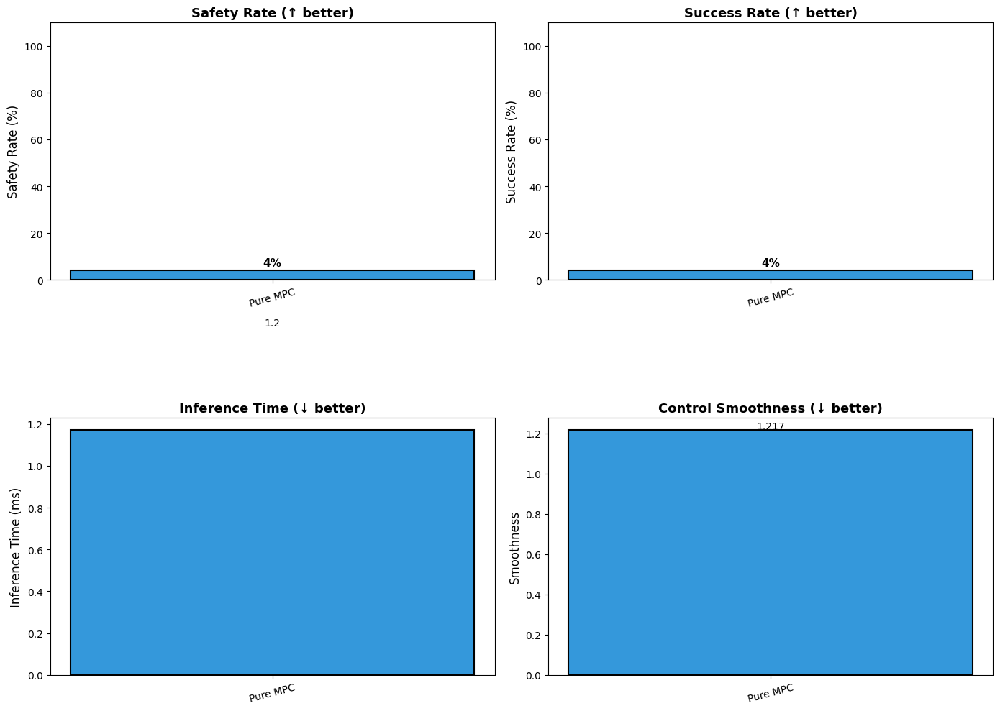

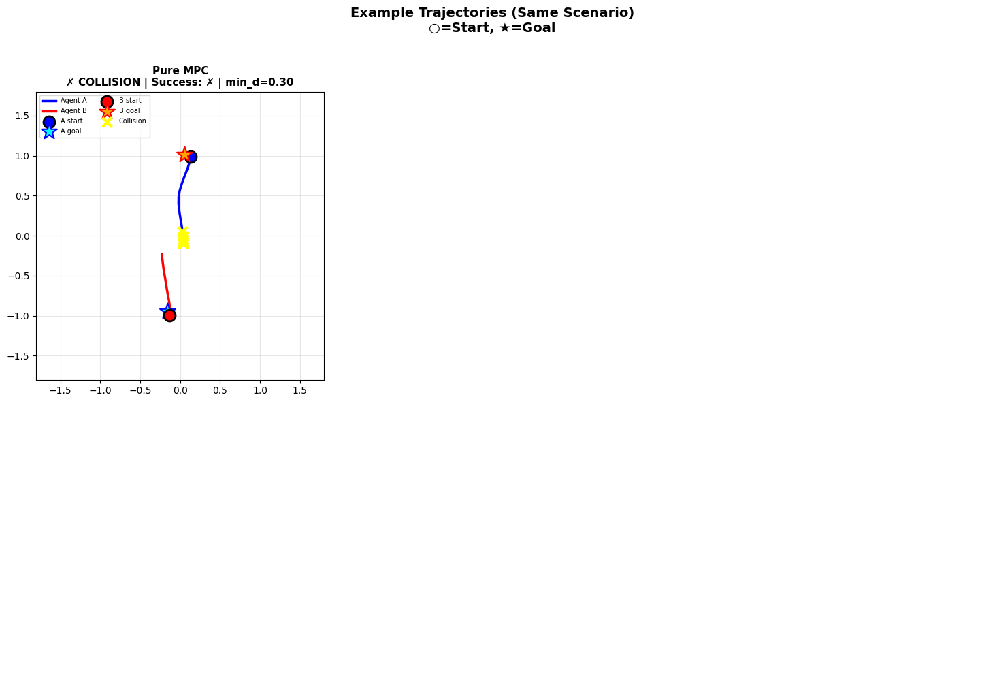

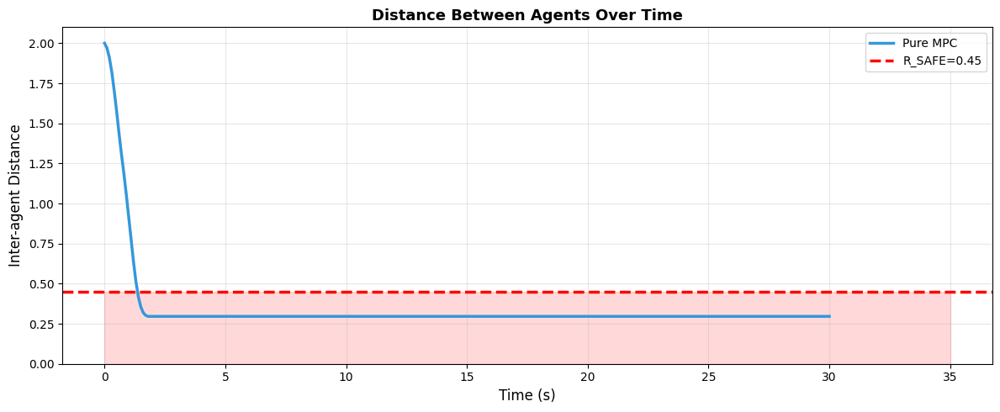


LaTeX Table:
\begin{table}[h]
\centering
\caption{Ablation Study Results}
\begin{tabular}{lcccc}
\toprule
Method & Safety (\%) & Success (\%) & Inf. Time (ms) & Smoothness \\
\midrule
Pure MPC & 4.0 & 4.0 & 1.17 & 1.2171 \\
\bottomrule
\end{tabular}
\end{table}

Saved: ablation_metrics.png, ablation_trajectories.png, ablation_distance.png

✓ Done!


In [20]:
# ===============================================================
# 消融实验 v6：修复目标点显示 + 增加步数 + 优化参数
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 修复版
# ===============================================================
@dataclass 
class Config:
    n_trials: int = 25
    max_steps: int = 300          # ★ 增加步数：180 -> 300
    dt: float = 0.1
    goal_tol: float = 0.50        # ★ 放宽：0.40 -> 0.50
    R_SAFE: float = 0.45
    arena_size: float = 1.0
    
    H: int = 8
    T_steps: int = 25
    num_segments: int = 2
    replan_every: int = 2

cfg = Config()

# ★ 修改：更早开始朝目标走
DIRECT_TO_GOAL_DIST = 2.0    # 从 1.2 增加到 2.0
BLEND_DIST = 1.0             # 从 0.6 增加到 1.0

v_max_A, v_max_B = 1.0, 0.6
a_max = 1.5
L = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
stop_radius = 0.50           # ★ 放宽
creep_radius = 1.2           # ★ 增大
v_creep = 0.20               # ★ 提高最低速度

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, 0, v_max))
    if v2 < 0.05 and a > 0.02:
        v2 = 0.05
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = [s0.copy()]
    for u in U:
        st.append(bicycle_step(st[-1], u, dt, v_max))
    return np.array(st)

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c, s = d[0]/dist, d[1]/dist
    R_wc = np.array([[c, s], [-s, c]], np.float32)
    
    def w2c(xy):
        return ((np.asarray(xy).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy).reshape(-1,2) @ R_wc + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32), 
            "goal_can": np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(other_u.reshape(1,2), (H, 1))
    return rollout_bicycle(other_state, U, dt, v_max)[:, :2]

# ===============================================================
# 执行层 CBF
# ===============================================================
def execution_cbf_filter(u, self_state, other_state, v_max, dt, margin=1.0):
    next_self = bicycle_step(self_state, u, dt, v_max)
    dist_now = np.linalg.norm(self_state[:2] - other_state[:2])
    dist_next = np.linalg.norm(next_self[:2] - other_state[:2])
    
    safe_threshold = cfg.R_SAFE * margin
    
    if dist_next < safe_threshold:
        u_safe = u.copy()
        current_v = self_state[3]
        
        if dist_next < cfg.R_SAFE:
            u_safe[0] = -a_max
        elif dist_next < safe_threshold:
            brake_strength = (safe_threshold - dist_next) / (safe_threshold - cfg.R_SAFE + 1e-6)
            brake_strength = np.clip(brake_strength, 0, 1)
            u_safe[0] = min(u[0], -current_v * brake_strength * 2)
        
        return u_safe
    
    return u

# ===============================================================
# Pure Pursuit - 优化版
# ===============================================================
def pure_pursuit_basic(s0, path_xy, goal_xy, H, dt, v_max):
    s = s0.copy()
    U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    
    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        
        if d_goal <= stop_radius:
            a = float(np.clip(-4.0 * v, -a_max, 0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue
        
        Ld = float(np.clip(0.35 + 0.4 * v, 0.25, 0.8))
        
        dists = np.linalg.norm(path_xy - pos, axis=1)
        near_idx = int(np.argmin(dists))
        path_target = path_xy[-1]
        for j in range(near_idx, len(path_xy)):
            if np.linalg.norm(path_xy[j] - pos) >= Ld:
                path_target = path_xy[j]
                break
        
        # ★ 更激进的后期目标导向
        if d_goal < DIRECT_TO_GOAL_DIST:
            blend = 1.0 if d_goal < BLEND_DIST else (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
            blend = float(np.clip(blend, 0, 1))
            target = (1 - blend) * path_target + blend * goal_xy
        else:
            target = path_target
        
        dx, dy = target[0] - x, target[1] - y
        alpha = wrap_pi(math.atan2(dy, dx) - th)
        kappa = 2.0 * math.sin(alpha) / max(0.1, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        
        # ★ 速度规划优化
        v_des = v_max if d_goal > creep_radius else v_creep + (v_max - v_creep) * d_goal / creep_radius
        v_des *= max(0.5, 1.0 - 0.4 * abs(delta_des) / delta_max)
        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)
    
    return U

# ===============================================================
# FM 采样
# ===============================================================
def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    x0 = torch.randn((1, 5, T), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0
    return x0

def sample_fm_fast(self_state, goal_xy, other_pos, seed, use_cbf=False, cbf_kw=None):
    tf = build_canonical_frame(self_state[:2], goal_xy)
    
    ellipses = []
    if use_cbf and other_pos is not None and len(other_pos) > 0:
        dist_AB = np.linalg.norm(self_state[:2] - other_pos[0])
        if dist_AB < 2.0:
            for i in [0, 1, 2]:  # ★ 减少障碍物数量
                if i < len(other_pos):
                    c = tf["w2c"](other_pos[i:i+1])[0]
                    ellipses.append({"center": c, "radius": 0.32})  # ★ 减小半径
    
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    cond = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), self_state[4]], np.float32)
    
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=1.0, num_segments=cfg.num_segments, ode_method="euler",
        atol=1e-3, rtol=1e-3, noise_scale=0.08,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.4, goal_guidance_weight=1.5,  # ★ 增强目标引导
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=use_cbf, ellipses=ellipses, cbf_kwargs=cbf_kw, scaler=None,
    )
    
    return tf["c2w"](x_can[0:2, :].T)

def generate_avoidance_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal = np.asarray(goal, np.float32)
    
    t = np.linspace(0, 1, T).reshape(-1, 1)
    path = start + t * (goal - start)
    
    if other_pos is None or len(other_pos) == 0:
        return path
    
    other_now = other_pos[0]
    dist_to_other = np.linalg.norm(start - other_now)
    
    if dist_to_other < 2.0:
        to_goal = goal - start
        to_goal_norm = np.linalg.norm(to_goal) + 1e-6
        to_goal_unit = to_goal / to_goal_norm
        perp = np.array([-to_goal_unit[1], to_goal_unit[0]], dtype=np.float32)
        
        to_other = other_now - start
        cross = to_goal[0] * to_other[1] - to_goal[1] * to_other[0]
        side = -1.0 if cross > 0 else 1.0
        
        avoidance_strength = min(0.8, max(0.3, 1.8 - dist_to_other))  # ★ 减小绕行幅度
        
        for i, ti in enumerate(t.flatten()):
            bulge = avoidance_strength * np.sin(np.pi * ti) * side
            path[i] = start + ti * to_goal + bulge * perp
    
    return path

# ===============================================================
# 各方法定义 - ★ 优化 CBF 参数
# ===============================================================
CBF_LIGHT = dict(passes=2, extra_margin=0.10, alpha=12.0, max_corr_norm=1.8)  # ★ 更轻量的 CBF

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = generate_avoidance_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.15

def replan_fm_vanilla(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.25

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2:
            if i > 2:
                remaining = generate_avoidance_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
                path = np.vstack([path[:i], remaining])
            break
    
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.15

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    
    best_u, best_J = None, float('inf')
    for k in range(3):
        path = sample_fm_fast(sA, gA, other_pos, seed + k*100, use_cbf=False)
        U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
        traj = rollout_bicycle(sA, U, cfg.dt, v_max_self)
        
        d_end = np.linalg.norm(traj[-1, :2] - gA)
        M = min(len(traj), len(other_pos))
        min_d = np.linalg.norm(traj[:M, :2] - other_pos[:M], axis=1).min() if M > 1 else 10
        
        coll = 2000 * max(0, cfg.R_SAFE * 1.2 - min_d)**2 if min_d < cfg.R_SAFE * 1.2 else 0
        J = 15 * d_end + coll
        
        if J < best_J:
            best_J, best_u = J, U[0]
    
    return best_u if best_u is not None else np.zeros(2, np.float32), 1.15

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=True, cbf_kw=CBF_LIGHT)  # ★ 使用轻量 CBF
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.1

# ===============================================================
# 评估指标
# ===============================================================
def compute_smoothness(controls):
    if len(controls) < 2:
        return 0.0
    controls = np.array(controls)
    d_acc = np.diff(controls[:, 0])
    d_steer = np.diff(controls[:, 1])
    return float(np.sqrt(np.mean(d_acc**2) + np.mean(d_steer**2)))

def compute_path_length(traj):
    return float(np.sum(np.linalg.norm(np.diff(traj[:, :2], axis=0), axis=1)))

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    
    # 场景生成
    ang = np.random.uniform(0, 2*np.pi)
    r = cfg.arena_size
    xA0 = r * np.array([np.cos(ang), np.sin(ang)], np.float32)
    gA = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    xB0 = r * np.array([np.cos(ang + np.pi), np.sin(ang + np.pi)], np.float32)
    gB = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    
    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])
    
    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)
    exec_margin_A = exec_margin_B = 1.2
    
    trajA, trajB = [sA.copy()], [sB.copy()]
    controlsA, controlsB = [], []
    total_inference_time = 0.0
    replan_count = 0
    
    for step in range(cfg.max_steps):
        dA = np.linalg.norm(sA[:2] - gA)
        dB = np.linalg.norm(sB[:2] - gB)
        doneA = dA < cfg.goal_tol and sA[3] < 0.1
        doneB = dB < cfg.goal_tol and sB[3] < 0.1
        
        if doneA and doneB:
            break
        
        if step % cfg.replan_every == 0:
            t0 = time.time()
            
            if not doneA:
                uA, exec_margin_A = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step)
            else:
                uA = np.zeros(2, np.float32)
                
            if not doneB:
                uB, exec_margin_B = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step)
            else:
                uB = np.zeros(2, np.float32)
            
            total_inference_time += time.time() - t0
            replan_count += 1
        
        # 执行层 CBF
        if not doneA:
            uA = execution_cbf_filter(uA, sA, sB, v_max_A, cfg.dt, margin=exec_margin_A)
        if not doneB:
            uB = execution_cbf_filter(uB, sB, sA, v_max_B, cfg.dt, margin=exec_margin_B)
        
        if not doneA:
            controlsA.append(uA.copy())
        if not doneB:
            controlsB.append(uB.copy())
        
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
        
        trajA.append(sA.copy())
        trajB.append(sB.copy())
    
    trajA, trajB = np.array(trajA), np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    
    result = {
        'safe': dist_AB.min() >= cfg.R_SAFE,
        'min_dist': float(dist_AB.min()),
        'success_A': np.linalg.norm(trajA[-1, :2] - gA) < cfg.goal_tol,
        'success_B': np.linalg.norm(trajB[-1, :2] - gB) < cfg.goal_tol,
        'inference_time': total_inference_time / max(replan_count, 1),
        'smoothness_A': compute_smoothness(controlsA),
        'smoothness_B': compute_smoothness(controlsB),
        'steps': len(trajA),
        'path_length_A': compute_path_length(trajA),
        'path_length_B': compute_path_length(trajB),
    }
    
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB, 'gA': gA, 'gB': gB,
                       'xA0': xA0, 'xB0': xB0, 'dist_AB': dist_AB})
    
    return result

# ===============================================================
# 运行实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure MPC": replan_pure_mpc,
        "Vanilla FM": replan_fm_vanilla,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost": replan_fm_cost,
        "FM+CBF (Ours)": replan_fm_cbf,
    }
    
    results = defaultdict(list)
    example_trajs = {}
    
    trial_seeds = [5000 + i * 77 for i in range(cfg.n_trials)]
    
    print("=" * 70)
    print("ABLATION STUDY v6: Fixed Goal Reaching")
    print("=" * 70)
    print(f"Config: Trials={cfg.n_trials}, MaxSteps={cfg.max_steps}, GoalTol={cfg.goal_tol}")
    print("=" * 70)
    
    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        
        for trial, seed in enumerate(trial_seeds):
            try:
                r = run_trial(fn, seed, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        
        print(f" [{time.time()-t0:.1f}s]")
    
    return results, example_trajs

# ===============================================================
# 结果展示 - ★ 修复绘图
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "=" * 95)
    print("RESULTS")
    print("=" * 95)
    print(f"{'Method':<16} {'Safety%':>10} {'Success%':>10} {'Inf.Time(ms)':>14} {'Smoothness':>12} {'MinDist':>10}")
    print("-" * 95)
    
    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue
        
        safety = sum(1 for r in rs if r['safe']) / n * 100
        success = sum(1 for r in rs if r['success_A'] and r['success_B']) / n * 100
        inf_time = np.mean([r['inference_time'] for r in rs]) * 1000
        smooth = np.mean([(r['smoothness_A'] + r['smoothness_B']) / 2 for r in rs])
        min_d = np.mean([r['min_dist'] for r in rs])
        
        summary[name] = {'safety': safety, 'success': success, 'inf_time': inf_time, 
                        'smoothness': smooth, 'min_dist': min_d}
        
        marker = " ★" if "Ours" in name else ""
        print(f"{name:<16} {safety:>9.1f}% {success:>9.1f}% {inf_time:>13.2f} {smooth:>12.4f} {min_d:>10.3f}{marker}")
    
    print("=" * 95)
    
    # ==================== 图1: 主要指标 ====================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    names = list(summary.keys())
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#1abc9c']
    
    ax = axes[0, 0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Safety Rate (%)', fontsize=12)
    ax.set_title('Safety Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[0, 1]
    vals = [summary[n]['success'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Success Rate (%)', fontsize=12)
    ax.set_title('Success Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[1, 0]
    vals = [summary[n]['inf_time'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Inference Time (ms)', fontsize=12)
    ax.set_title('Inference Time (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[1, 1]
    vals = [summary[n]['smoothness'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Smoothness', fontsize=12)
    ax.set_title('Control Smoothness (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图2: 轨迹 - ★ 修复绘图 ====================
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        
        trajA, trajB = data['trajA'], data['trajB']
        gA, gB = data['gA'], data['gB']
        xA0, xB0 = data['xA0'], data['xB0']
        dist_AB = data['dist_AB']
        
        # 轨迹
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2.5, label='Agent A', zorder=3)
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2.5, label='Agent B', zorder=3)
        
        # ★ 修复：起点用圆圈，终点用星号，颜色区分
        # Agent A: 蓝色
        ax.scatter([xA0[0]], [xA0[1]], c='blue', s=150, marker='o', edgecolors='black', linewidths=2, zorder=5, label='A start')
        ax.scatter([gA[0]], [gA[1]], c='cyan', s=300, marker='*', edgecolors='blue', linewidths=1.5, zorder=5, label='A goal')
        
        # Agent B: 红色
        ax.scatter([xB0[0]], [xB0[1]], c='red', s=150, marker='o', edgecolors='black', linewidths=2, zorder=5, label='B start')
        ax.scatter([gB[0]], [gB[1]], c='orange', s=300, marker='*', edgecolors='red', linewidths=1.5, zorder=5, label='B goal')
        
        # 碰撞标记
        coll_idx = np.where(dist_AB < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='yellow', s=100, marker='x', linewidths=3, zorder=6, label='Collision')
        
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        
        safe_str = "✓ SAFE" if data['safe'] else "✗ COLLISION"
        success_str = "✓" if data['success_A'] and data['success_B'] else "✗"
        ax.set_title(f"{name}\n{safe_str} | Success: {success_str} | min_d={data['min_dist']:.2f}", fontsize=11, fontweight='bold')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=7, ncol=2)
    
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Example Trajectories (Same Scenario)\n○=Start, ★=Goal', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图3: 距离曲线 ====================
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2.5, label=name, color=colors[idx])
    
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2.5, label=f'R_SAFE={cfg.R_SAFE}')
    ax.fill_between([0, 35], 0, cfg.R_SAFE, alpha=0.15, color='red')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Inter-agent Distance', fontsize=12)
    ax.set_title('Distance Between Agents Over Time', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, None)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()
    
    # LaTeX 表格
    print("\n" + "=" * 70)
    print("LaTeX Table:")
    print("=" * 70)
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\caption{Ablation Study Results}")
    print("\\begin{tabular}{lcccc}")
    print("\\toprule")
    print("Method & Safety (\\%) & Success (\\%) & Inf. Time (ms) & Smoothness \\\\")
    print("\\midrule")
    for name in names:
        s = summary[name]
        if "Ours" in name:
            print(f"\\textbf{{{name}}} & \\textbf{{{s['safety']:.1f}}} & \\textbf{{{s['success']:.1f}}} & \\textbf{{{s['inf_time']:.2f}}} & \\textbf{{{s['smoothness']:.4f}}} \\\\")
        else:
            print(f"{name} & {s['safety']:.1f} & {s['success']:.1f} & {s['inf_time']:.2f} & {s['smoothness']:.4f} \\\\")
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    print("\nSaved: ablation_metrics.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation Study v6...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\n✓ Done!")

=== 诊断 FM 采样 ===
tf['dist']: 3.394
tf['goal_can']: [3.3941126 0.       ]

Path shape: (40, 2)
Path start: [-1.2 -1.2]
Path end:   [1.2224953 1.2460911]
Goal:       [1.2 1.2]
Distance path_end to goal: 0.051


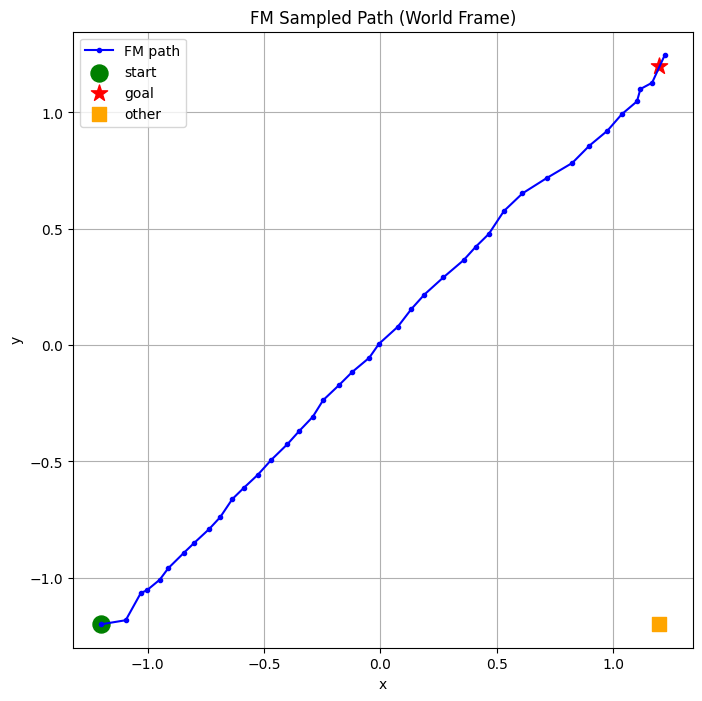


=== Canonical Frame 检查 ===
Path_can start: [0. 0.]
Path_can end:   [3.4426107  0.01668479]
Goal_can:       [3.3941126 0.       ]


In [98]:
# 请运行这个诊断代码
print("=== 诊断 FM 采样 ===")

# 模拟 Agent A 的状态
test_state = np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)
test_other = np.array([[1.2, -1.2]], dtype=np.float32)  # B 的位置

# 采样
path_xy, theta_can, used_cbf, tf = sample_fm_trajectory(
    self_state=test_state,
    goal_xy=test_goal,
    other_pred_path=test_other,
    seed=12345,
)

print(f"tf['dist']: {tf['dist']:.3f}")
print(f"tf['goal_can']: {tf['goal_can']}")
print(f"\nPath shape: {path_xy.shape}")
print(f"Path start: {path_xy[0]}")
print(f"Path end:   {path_xy[-1]}")
print(f"Goal:       {test_goal}")
print(f"Distance path_end to goal: {np.linalg.norm(path_xy[-1] - test_goal):.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(path_xy[:, 0], path_xy[:, 1], 'b.-', label='FM path')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.scatter([test_other[0, 0]], [test_other[0, 1]], c='orange', s=100, marker='s', label='other')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('FM Sampled Path (World Frame)')
plt.show()

# 检查 canonical frame 的轨迹
print("\n=== Canonical Frame 检查 ===")
path_can = tf['w2c'](path_xy)
print(f"Path_can start: {path_can[0]}")
print(f"Path_can end:   {path_can[-1]}")
print(f"Goal_can:       {tf['goal_can']}")

=== 诊断 Path Tracking ===
Controls U shape: (12, 2)
U[0] (first control): a=0.879, dr=-1.095
U mean: a=0.376, dr=0.007

Rollout:
  Start: [-1.2 -1.2]
  End:   [-0.49371642 -0.50645375]
  Goal:  [1.2 1.2]
  Dist to goal: 2.404


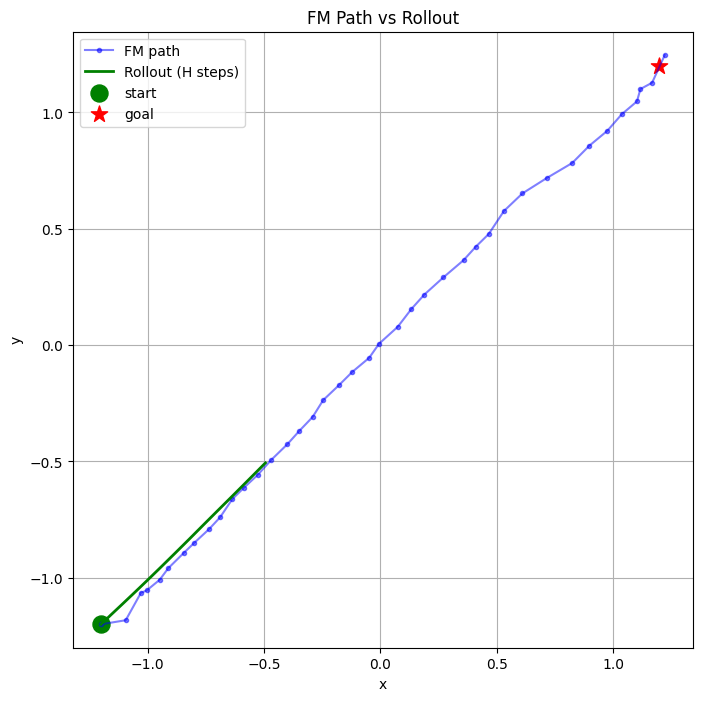


=== 模拟多次 Replan ===
Step 0: pos=[-1.1575239 -1.1593629], dist=3.335, v=0.59
Step 1: pos=[-1.1092349 -1.1142519], dist=3.269, v=0.66
Step 2: pos=[-1.0562735 -1.0652788], dist=3.197, v=0.72
Step 3: pos=[-0.99983567 -1.0127318 ], dist=3.120, v=0.77
Step 4: pos=[-0.9408878 -0.9569659], dist=3.039, v=0.81
Step 5: pos=[-0.88011813 -0.8983488 ], dist=2.955, v=0.84
Step 6: pos=[-0.8180112  -0.83724606], dist=2.868, v=0.87
Step 7: pos=[-0.75495267 -0.7739697 ], dist=2.778, v=0.89
Step 8: pos=[-0.69115543 -0.70885766], dist=2.687, v=0.91
Step 9: pos=[-0.6268144 -0.6421749], dist=2.594, v=0.93
Step 10: pos=[-0.5619895  -0.57421595], dist=2.500, v=0.94
Step 20: pos=[0.09901869 0.14256379], dist=1.527, v=0.99


In [99]:
# 诊断 tracking controller
print("=== 诊断 Path Tracking ===")

# 用刚才的 path 测试 tracking
test_state = np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)

U, ref = path_to_controls(
    test_state, path_xy, test_goal,
    H=H, dt=dt_exec, v_max=v_max_A,
    lookahead_ratio=0.12, k_omega=2.5, k_accel=1.8
)

print(f"Controls U shape: {U.shape}")
print(f"U[0] (first control): a={U[0,0]:.3f}, dr={U[0,1]:.3f}")
print(f"U mean: a={U[:,0].mean():.3f}, dr={U[:,1].mean():.3f}")

# Rollout 看看轨迹
pos_rollout, states_rollout = rollout_bicycle(test_state, U, dt=dt_exec, v_max=v_max_A)
print(f"\nRollout:")
print(f"  Start: {states_rollout[0, :2]}")
print(f"  End:   {states_rollout[-1, :2]}")
print(f"  Goal:  {test_goal}")
print(f"  Dist to goal: {np.linalg.norm(states_rollout[-1, :2] - test_goal):.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(path_xy[:, 0], path_xy[:, 1], 'b.-', alpha=0.5, label='FM path')
plt.plot(pos_rollout[:, 0], pos_rollout[:, 1], 'g-', lw=2, label='Rollout (H steps)')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('FM Path vs Rollout')
plt.show()

# 检查多次 replan 的效果
print("\n=== 模拟多次 Replan ===")
s = test_state.copy()
for step in range(30):
    # 采样新轨迹
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))  # B 静止
    path_xy, _, _, tf = sample_fm_trajectory(
        self_state=s,
        goal_xy=test_goal,
        other_pred_path=other_pred,
        seed=1000 + step * 31,
    )
    
    # Tracking
    U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
    
    # 只执行第一步
    u0 = U[0]
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    
    d = np.linalg.norm(s[:2] - test_goal)
    if step < 10 or step % 10 == 0:
        print(f"Step {step}: pos={s[:2]}, dist={d:.3f}, v={s[3]:.2f}")
    
    if d < 0.15:
        print(f"Reached goal at step {step}!")
        break

In [ ]:
# 检查多次 replan 的效果
print("\n=== 模拟多次 Replan ===")
s = test_state.copy()
for step in range(30):
    # 采样新轨迹
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))  # B 静止
    path_xy, _, _, tf = sample_fm_trajectory(
        self_state=s,
        goal_xy=test_goal,
        other_pred_path=other_pred,
        seed=1000 + step * 31,
    )
    
    # Tracking
    U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
    
    # 只执行第一步
    u0 = U[0]
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    
    d = np.linalg.norm(s[:2] - test_goal)
    if step < 10 or step % 10 == 0:
        print(f"Step {step}: pos={s[:2]}, dist={d:.3f}, v={s[3]:.2f}")
    
    if d < 0.15:
        print(f"Reached goal at step {step}!")
        break

print(f"\nFinal: pos={s[:2]}, dist to goal={np.linalg.norm(s[:2] - test_goal):.3f}")


=== 模拟多次 Replan ===
Step 0: pos=[-1.1575239 -1.1593629], dist=3.335, v=0.59
Step 1: pos=[-1.1092349 -1.1142519], dist=3.269, v=0.66
Step 2: pos=[-1.0562735 -1.0652788], dist=3.197, v=0.72
Step 3: pos=[-0.99983567 -1.0127318 ], dist=3.120, v=0.77
Step 4: pos=[-0.9408878 -0.9569659], dist=3.039, v=0.81
Step 5: pos=[-0.88011813 -0.8983488 ], dist=2.955, v=0.84
Step 6: pos=[-0.8180112  -0.83724606], dist=2.868, v=0.87
Step 7: pos=[-0.75495267 -0.7739697 ], dist=2.778, v=0.89
Step 8: pos=[-0.69115543 -0.70885766], dist=2.687, v=0.91
Step 9: pos=[-0.6268144 -0.6421749], dist=2.594, v=0.93
Step 10: pos=[-0.5619895  -0.57421595], dist=2.500, v=0.94
Step 20: pos=[0.09901869 0.14256379], dist=1.527, v=0.99

Final: pos=[0.7029867  0.79205996], dist to goal=0.643


=== 模拟 100 步 Replan ===
Step  0: pos=[-1.19, -1.19], dist=3.394, v=0.15
Step  1: pos=[-1.17, -1.17], dist=3.379, v=0.30
Step  2: pos=[-1.14, -1.14], dist=3.349, v=0.42
Step  3: pos=[-1.10, -1.10], dist=3.308, v=0.52
Step  4: pos=[-1.05, -1.06], dist=3.255, v=0.60
Step  5: pos=[-1.00, -1.02], dist=3.195, v=0.67
Step  6: pos=[-0.95, -0.97], dist=3.128, v=0.73
Step  7: pos=[-0.89, -0.92], dist=3.055, v=0.78
Step  8: pos=[-0.83, -0.87], dist=2.977, v=0.82
Step  9: pos=[-0.77, -0.81], dist=2.895, v=0.85
Step 10: pos=[-0.70, -0.75], dist=2.810, v=0.88
Step 20: pos=[-0.05, -0.06], dist=1.874, v=0.98
Step 30: pos=[+0.61, +0.68], dist=0.886, v=1.00
Step 40: pos=[+1.04, +1.15], dist=0.187, v=0.28
Step 50: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 60: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 70: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 80: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 90: pos=[+1.05, +1.16], dist=0.152, v=0.00

Final: pos=[1.052427  1.1642741], dist=0.152, v=0.000


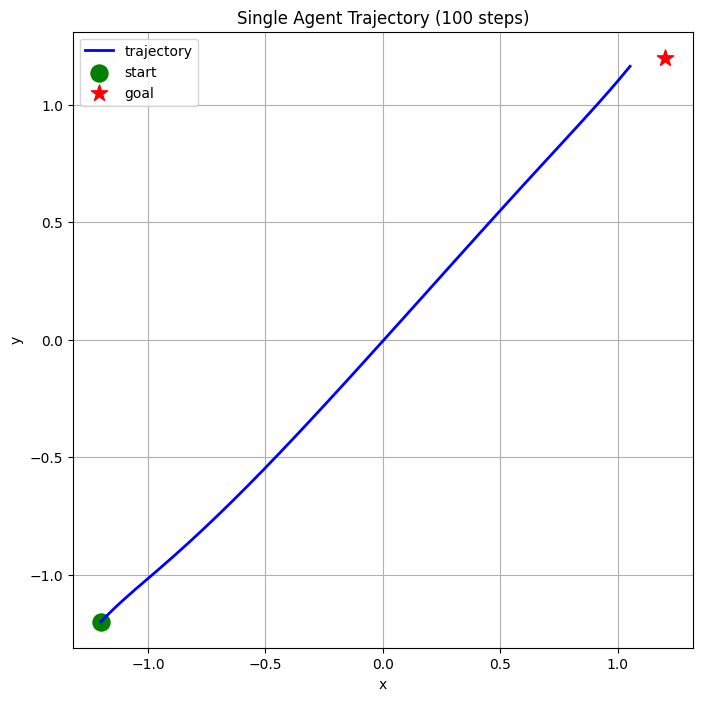

In [101]:
# 延长测试到 100 步
print("=== 模拟 100 步 Replan ===")
test_state = np.array([-1.2, -1.2, np.pi/4, 0.0, 0.0], dtype=np.float32)  # 初始速度为 0
test_goal = np.array([1.2, 1.2], dtype=np.float32)

s = test_state.copy()
traj = [s.copy()]

for step in range(100):
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))
    
    d = np.linalg.norm(s[:2] - test_goal)
    
    # 检查是否到达
    if d < goal_tol and abs(s[3]) < 0.05:
        print(f"✅ Reached goal at step {step}!")
        break
    
    # 停车逻辑
    if d < goal_stop_tol:
        u0 = stopping_control(s, test_goal, dt=dt_exec, v_max=v_max_A)
    else:
        path_xy, _, _, tf = sample_fm_trajectory(
            self_state=s,
            goal_xy=test_goal,
            other_pred_path=other_pred,
            seed=1000 + step * 31,
        )
        U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
        u0 = U[0]
    
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    traj.append(s.copy())
    
    if step < 10 or step % 10 == 0:
        print(f"Step {step:2d}: pos=[{s[0]:+.2f}, {s[1]:+.2f}], dist={d:.3f}, v={s[3]:.2f}")

traj = np.array(traj)
print(f"\nFinal: pos={s[:2]}, dist={np.linalg.norm(s[:2] - test_goal):.3f}, v={s[3]:.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(traj[:, 0], traj[:, 1], 'b-', lw=2, label='trajectory')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('Single Agent Trajectory (100 steps)')
plt.show()

In [56]:
# 测试 cond 对模型输出的影响
print("=== 检查 cond 影响 ===")

x_test = torch.randn(1, 5, 40, device=device)
t_test = torch.tensor([0.5], device=device)

with torch.no_grad():
    # 不用 cond
    v_no_cond = model_5ch(x_test, t_test, cond=None)
    
    # 用 dummy cond
    cond1 = torch.tensor([[1, 0, 1, 0, 0]], device=device, dtype=torch.float32)
    v_cond1 = model_5ch(x_test, t_test, cond=cond1)
    
    # 用不同的 cond
    cond2 = torch.tensor([[0, 1, 0, 1, 1]], device=device, dtype=torch.float32)
    v_cond2 = model_5ch(x_test, t_test, cond=cond2)

print(f"v (no cond):   mean={v_no_cond.mean().item():.4f}, std={v_no_cond.std().item():.4f}")
print(f"v (cond1):     mean={v_cond1.mean().item():.4f}, std={v_cond1.std().item():.4f}")
print(f"v (cond2):     mean={v_cond2.mean().item():.4f}, std={v_cond2.std().item():.4f}")

# 检查差异
diff_1 = (v_cond1 - v_no_cond).abs().mean().item()
diff_2 = (v_cond2 - v_cond1).abs().mean().item()
print(f"\n|v_cond1 - v_no_cond|: {diff_1:.4f}")
print(f"|v_cond2 - v_cond1|:   {diff_2:.4f}")

if diff_1 < 0.01 and diff_2 < 0.01:
    print("\n✅ cond 对模型输出影响很小，可能模型没有使用 conditioning")
else:
    print("\n⚠️ cond 对模型输出有影响！需要确认正确的 cond 值")

=== 检查 cond 影响 ===
v (no cond):   mean=0.2787, std=1.8193
v (cond1):     mean=0.3553, std=1.7052
v (cond2):     mean=0.2590, std=1.2983

|v_cond1 - v_no_cond|: 0.7342
|v_cond2 - v_cond1|:   1.0764

⚠️ cond 对模型输出有影响！需要确认正确的 cond 值


1. 检查 cond 对模型输出的影响
v (no cond):   mean=0.2419, std=1.9940
v (cond1):     mean=0.2489, std=1.6835
v (cond2):     mean=0.5926, std=1.7728

|v_cond1 - v_no_cond|: 0.4564
|v_cond2 - v_cond1|:   0.8258

⚠️ cond 对模型输出有影响！

2. 检查 cond 各维度的统计 (训练数据)

维度                 mean        std        min        max
-------------------------------------------------------
dist             3.0000     0.0000     3.0000     3.0000
v0               0.3755     0.1307     0.1597     0.5966
cos(th0)         0.0220     0.7065    -0.9999     1.0000
sin(th0)        -0.0443     0.7060    -1.0000     0.9999
delta0           0.0000     0.0000     0.0000     0.0000

3. 测试不同 cond 对采样轨迹的影响


C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 27490 (\N{CJK UNIFIED IDEOGRAPH-6B62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 26397 (\N{CJK 

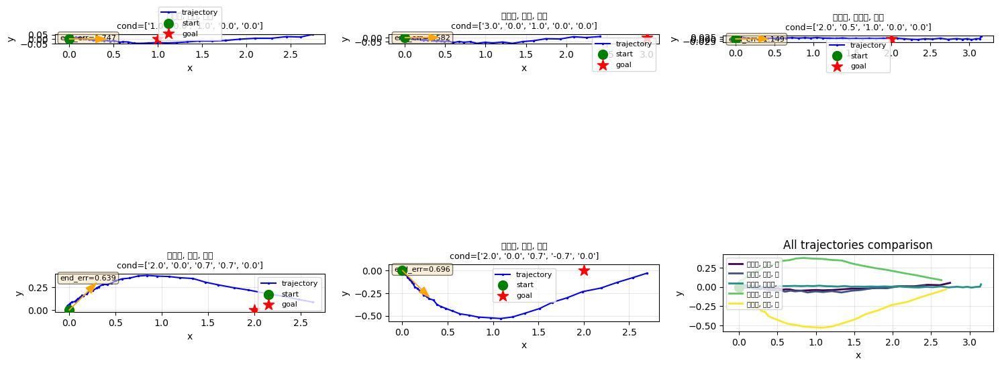


4. 量化 cond 对轨迹终点的影响

场景                          dist    end_x    end_y  end_err path_len
---------------------------------------------------------------------------
短距离, 静止, 朝前                 1.00    2.746    0.052    1.747    2.821
长距离, 静止, 朝前                 3.00    2.418    0.013    0.582    2.526
中距离, 有速度, 朝前                2.00    3.148    0.034    1.149    3.119
中距离, 静止, 偏左                 2.00    2.633    0.089    0.639    2.814
中距离, 静止, 偏右                 2.00    2.695   -0.032    0.696    3.040

5. 检查 canonical frame 变换是否正确

start           goal                dist        goal_can       回转误差
----------------------------------------------------------------------
[-1.2 -1.2]     [1.2 1.2]          3.394 [3.3941128 0.       ]   0.000000
[0. 0.]         [2. 0.]            2.000 [2. 0.]           0.000000
[0. 0.]         [0. 2.]            2.000 [2. 0.]           0.000000
[1. 1.]         [2. 3.]            2.236 [2.236068 0.      ]   0.000000

6. 完整 MPC 场景测试 (单 agent)

World sta

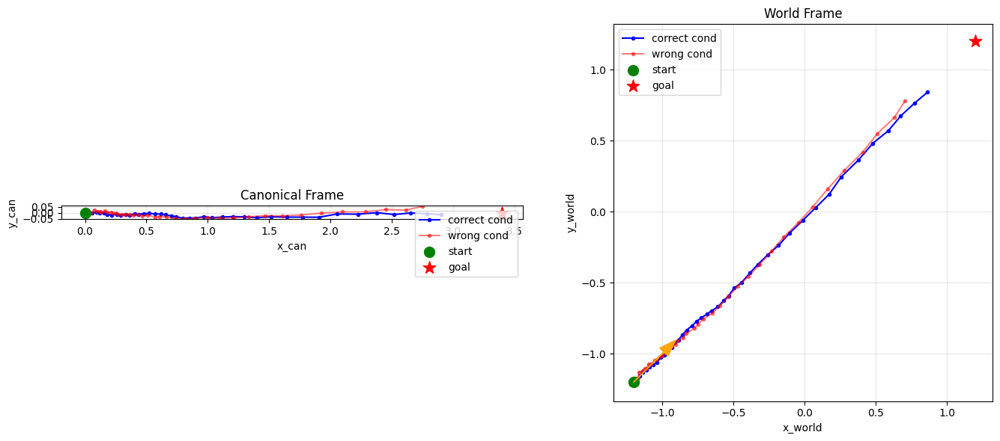


[结果]
  Correct cond -> goal error: 0.4919
  Wrong cond   -> goal error: 0.6502
  Improvement: 0.1582 (32.2% worse with wrong cond)

✅ 正确的 cond 显著改善了轨迹质量！


In [118]:
# ===============================================================
# 完整检查: cond 影响 + canonical frame + 采样质量
# ===============================================================

print("=" * 60)
print("1. 检查 cond 对模型输出的影响")
print("=" * 60)

x_test = torch.randn(1, 5, 40, device=device)
t_test = torch.tensor([0.5], device=device)

with torch.no_grad():
    # 不用 cond
    v_no_cond = model_5ch(x_test, t_test, cond=None)
    
    # 用 dummy cond
    cond1 = torch.tensor([[1, 0, 1, 0, 0]], device=device, dtype=torch.float32)
    v_cond1 = model_5ch(x_test, t_test, cond=cond1)
    
    # 用不同的 cond
    cond2 = torch.tensor([[0, 1, 0, 1, 1]], device=device, dtype=torch.float32)
    v_cond2 = model_5ch(x_test, t_test, cond=cond2)

print(f"v (no cond):   mean={v_no_cond.mean().item():.4f}, std={v_no_cond.std().item():.4f}")
print(f"v (cond1):     mean={v_cond1.mean().item():.4f}, std={v_cond1.std().item():.4f}")
print(f"v (cond2):     mean={v_cond2.mean().item():.4f}, std={v_cond2.std().item():.4f}")

diff_1 = (v_cond1 - v_no_cond).abs().mean().item()
diff_2 = (v_cond2 - v_cond1).abs().mean().item()
print(f"\n|v_cond1 - v_no_cond|: {diff_1:.4f}")
print(f"|v_cond2 - v_cond1|:   {diff_2:.4f}")

if diff_1 < 0.01 and diff_2 < 0.01:
    print("\n✅ cond 对模型输出影响很小")
else:
    print("\n⚠️ cond 对模型输出有影响！")

# ===============================================================
print("\n" + "=" * 60)
print("2. 检查 cond 各维度的统计 (训练数据)")
print("=" * 60)

# cond = [dist, v0, cos(th0_can), sin(th0_can), delta0]
cond_names = ['dist', 'v0', 'cos(th0)', 'sin(th0)', 'delta0']

print(f"\n{'维度':<12} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
print("-" * 55)
for i, name in enumerate(cond_names):
    c = cond_all[:, i]
    print(f"{name:<12} {c.mean():>10.4f} {c.std():>10.4f} {c.min():>10.4f} {c.max():>10.4f}")

# ===============================================================
print("\n" + "=" * 60)
print("3. 测试不同 cond 对采样轨迹的影响")
print("=" * 60)

def sample_trajectory_with_cond(cond_vec, seed=42):
    """用指定 cond 采样一条轨迹"""
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    x0 = torch.randn((1, 5, 40), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0.0
    
    cond_t = torch.tensor(cond_vec, device=device, dtype=torch.float32).unsqueeze(0)
    
    # 简单 Euler 积分
    x = x0.clone()
    n_steps = 20
    dt = 1.0 / n_steps
    
    with torch.no_grad():
        for i in range(n_steps):
            t = torch.tensor([i * dt], device=device)
            v = model_5ch(x, t, cond=cond_t)
            x = x + v * dt
    
    return x[0].cpu().numpy()  # (5, 40)

# 测试不同场景的 cond
test_cases = [
    # [dist, v0, cos(th0), sin(th0), delta0]
    ("短距离, 静止, 朝前", [1.0, 0.0, 1.0, 0.0, 0.0]),
    ("长距离, 静止, 朝前", [3.0, 0.0, 1.0, 0.0, 0.0]),
    ("中距离, 有速度, 朝前", [2.0, 0.5, 1.0, 0.0, 0.0]),
    ("中距离, 静止, 偏左", [2.0, 0.0, 0.7, 0.7, 0.0]),
    ("中距离, 静止, 偏右", [2.0, 0.0, 0.7, -0.7, 0.0]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, cond_vec) in enumerate(test_cases):
    if idx >= len(axes):
        break
    
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    x, y = traj[0], traj[1]
    
    ax = axes[idx]
    ax.plot(x, y, 'b.-', markersize=3, label='trajectory')
    ax.scatter([0], [0], c='green', s=100, marker='o', zorder=5, label='start')
    ax.scatter([cond_vec[0]], [0], c='red', s=150, marker='*', zorder=5, label='goal')
    
    # 画初始 heading 方向
    th0 = np.arctan2(cond_vec[3], cond_vec[2])
    arrow_len = 0.3
    ax.arrow(0, 0, arrow_len * np.cos(th0), arrow_len * np.sin(th0),
             head_width=0.08, color='orange', zorder=5)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(f"{name}\ncond={[f'{c:.1f}' for c in cond_vec]}", fontsize=9)
    
    # 计算终点误差
    end_dist = np.sqrt((x[-1] - cond_vec[0])**2 + y[-1]**2)
    ax.text(0.02, 0.98, f"end_err={end_dist:.3f}", transform=ax.transAxes, 
            fontsize=8, va='top', ha='left', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 最后一个图：对比所有轨迹
ax = axes[-1]
colors = plt.cm.viridis(np.linspace(0, 1, len(test_cases)))
for idx, (name, cond_vec) in enumerate(test_cases):
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    ax.plot(traj[0], traj[1], '-', color=colors[idx], lw=2, label=name[:10])
ax.scatter([0], [0], c='green', s=100, marker='o', zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc='upper left')
ax.set_title('All trajectories comparison')

plt.tight_layout()
plt.show()

# ===============================================================
print("\n" + "=" * 60)
print("4. 量化 cond 对轨迹终点的影响")
print("=" * 60)

results = []
for name, cond_vec in test_cases:
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    x_end, y_end = traj[0, -1], traj[1, -1]
    goal_x = cond_vec[0]
    end_err = np.sqrt((x_end - goal_x)**2 + y_end**2)
    path_len = np.sum(np.sqrt(np.diff(traj[0])**2 + np.diff(traj[1])**2))
    
    results.append({
        'name': name,
        'dist': cond_vec[0],
        'end_x': x_end,
        'end_y': y_end,
        'end_err': end_err,
        'path_len': path_len,
    })

print(f"\n{'场景':<25} {'dist':>6} {'end_x':>8} {'end_y':>8} {'end_err':>8} {'path_len':>8}")
print("-" * 75)
for r in results:
    print(f"{r['name']:<25} {r['dist']:>6.2f} {r['end_x']:>8.3f} {r['end_y']:>8.3f} {r['end_err']:>8.3f} {r['path_len']:>8.3f}")

# ===============================================================
print("\n" + "=" * 60)
print("5. 检查 canonical frame 变换是否正确")
print("=" * 60)

# 测试 world -> canonical -> world 往返
test_points = [
    ([-1.2, -1.2], [1.2, 1.2]),   # 对角线
    ([0.0, 0.0], [2.0, 0.0]),     # 水平
    ([0.0, 0.0], [0.0, 2.0]),     # 垂直
    ([1.0, 1.0], [2.0, 3.0]),     # 任意
]

print(f"\n{'start':<15} {'goal':<15} {'dist':>8} {'goal_can':>15} {'回转误差':>10}")
print("-" * 70)

for start, goal in test_points:
    start = np.array(start, dtype=np.float32)
    goal = np.array(goal, dtype=np.float32)
    
    tf = build_canonical_frame(start, goal)
    
    # 测试往返
    goal_can = tf['w2c'](goal.reshape(1, 2))[0]
    goal_back = tf['c2w'](goal_can.reshape(1, 2))[0]
    roundtrip_err = np.linalg.norm(goal - goal_back)
    
    print(f"{str(start):<15} {str(goal):<15} {tf['dist']:>8.3f} {str(goal_can):<15} {roundtrip_err:>10.6f}")

# ===============================================================
print("\n" + "=" * 60)
print("6. 完整 MPC 场景测试 (单 agent)")
print("=" * 60)

# 模拟一个完整的 MPC 步骤
test_state = np.array([-1.2, -1.2, np.pi/4, 0.3, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)

tf = build_canonical_frame(test_state[:2], test_goal)

# 计算正确的 cond
v0 = float(test_state[3])
th_world = float(test_state[2])
th_can = tf['w2c_angle'](th_world)
delta0 = float(test_state[4])

correct_cond = np.array([
    tf['dist'],
    v0,
    np.cos(th_can),
    np.sin(th_can),
    delta0,
], dtype=np.float32)

print(f"\nWorld state: pos={test_state[:2]}, theta={np.rad2deg(th_world):.1f} deg, v={v0:.2f}")
print(f"Goal:        {test_goal}")
print(f"Canonical:   dist={tf['dist']:.3f}, th_can={np.rad2deg(th_can):.1f} deg")
print(f"Correct cond: {correct_cond}")

# 用正确 cond 采样
traj_correct = sample_trajectory_with_cond(correct_cond, seed=123)

# 用错误 cond 采样 (dummy)
wrong_cond = np.array([1.0, 0.0, 1.0, 0.0, 0.0], dtype=np.float32)
traj_wrong = sample_trajectory_with_cond(wrong_cond, seed=123)

# 转回 world frame
traj_correct_world = tf['c2w'](traj_correct[:2].T)
traj_wrong_world = tf['c2w'](traj_wrong[:2].T)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Canonical frame
ax1 = axes[0]
ax1.plot(traj_correct[0], traj_correct[1], 'b.-', label='correct cond')
ax1.plot(traj_wrong[0], traj_wrong[1], 'r.-', alpha=0.5, label='wrong cond')
ax1.scatter([0], [0], c='green', s=100, marker='o', zorder=5, label='start')
ax1.scatter([tf['dist']], [0], c='red', s=150, marker='*', zorder=5, label='goal')
ax1.set_xlabel('x_can')
ax1.set_ylabel('y_can')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_title('Canonical Frame')

# World frame
ax2 = axes[1]
ax2.plot(traj_correct_world[:, 0], traj_correct_world[:, 1], 'b.-', label='correct cond')
ax2.plot(traj_wrong_world[:, 0], traj_wrong_world[:, 1], 'r.-', alpha=0.5, label='wrong cond')
ax2.scatter([test_state[0]], [test_state[1]], c='green', s=100, marker='o', zorder=5, label='start')
ax2.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', zorder=5, label='goal')

# 画 heading 方向
arrow_len = 0.3
ax2.arrow(test_state[0], test_state[1], 
          arrow_len * np.cos(th_world), arrow_len * np.sin(th_world),
          head_width=0.08, color='orange', zorder=5)

ax2.set_xlabel('x_world')
ax2.set_ylabel('y_world')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title('World Frame')

plt.tight_layout()
plt.show()

# 计算误差
err_correct = np.linalg.norm(traj_correct_world[-1] - test_goal)
err_wrong = np.linalg.norm(traj_wrong_world[-1] - test_goal)

print(f"\n[结果]")
print(f"  Correct cond -> goal error: {err_correct:.4f}")
print(f"  Wrong cond   -> goal error: {err_wrong:.4f}")
print(f"  Improvement: {err_wrong - err_correct:.4f} ({(err_wrong/err_correct - 1)*100:.1f}% worse with wrong cond)")

if err_correct < err_wrong * 0.8:
    print("\n✅ 正确的 cond 显著改善了轨迹质量！")
else:
    print("\n⚠️ cond 对轨迹质量影响不大，可能模型没有充分学习 conditioning")

In [57]:
# 检查 checkpoint 里是否保存了 cond 相关信息
ckpt = torch.load("cache/model_vel_5ch_canonical_r.pt", map_location=device)

print("=== Checkpoint 完整信息 ===")
for k, v in ckpt.items():
    if isinstance(v, dict):
        print(f"{k}: dict with keys {list(v.keys())}")
    elif isinstance(v, (list, np.ndarray)):
        print(f"{k}: {type(v).__name__}, len={len(v)}")
    elif isinstance(v, torch.Tensor):
        print(f"{k}: Tensor, shape={v.shape}")
    else:
        print(f"{k}: {v}")

# 检查是否有 config 或 args
if 'config' in ckpt:
    print(f"\nConfig: {ckpt['config']}")
if 'args' in ckpt:
    print(f"\nArgs: {ckpt['args']}")
if 'cond_dim' in ckpt:
    print(f"\ncond_dim: {ckpt['cond_dim']}")

=== Checkpoint 完整信息 ===
model_state_dict: dict with keys ['time_mlp.1.weight', 'time_mlp.1.bias', 'time_mlp.3.weight', 'time_mlp.3.bias', 'cond_mlp.0.weight', 'cond_mlp.0.bias', 'cond_mlp.2.weight', 'cond_mlp.2.bias', 'conv_in.weight', 'conv_in.bias', 'down1_block.0.time_mlp.1.weight', 'down1_block.0.time_mlp.1.bias', 'down1_block.0.block.0.weight', 'down1_block.0.block.0.bias', 'down1_block.0.block.2.weight', 'down1_block.0.block.2.bias', 'down1_block.0.block.3.weight', 'down1_block.0.block.3.bias', 'down1_block.0.block.5.weight', 'down1_block.0.block.5.bias', 'down1_block.1.time_mlp.1.weight', 'down1_block.1.time_mlp.1.bias', 'down1_block.1.block.0.weight', 'down1_block.1.block.0.bias', 'down1_block.1.block.2.weight', 'down1_block.1.block.2.bias', 'down1_block.1.block.3.weight', 'down1_block.1.block.3.bias', 'down1_block.1.block.5.weight', 'down1_block.1.block.5.bias', 'down1_sample.weight', 'down1_sample.bias', 'down2_block.0.time_mlp.1.weight', 'down2_block.0.time_mlp.1.bias', 'dow

In [58]:
# 从 cond_mlp 权重推断 cond_dim
cond_mlp_weight = ckpt['model_state_dict']['cond_mlp.0.weight']
print(f"cond_mlp.0.weight shape: {cond_mlp_weight.shape}")
print(f"推断的 cond_dim (输入维度): {cond_mlp_weight.shape[1]}")

# 检查 history
if 'history' in ckpt:
    hist = ckpt['history']
    if 'train_loss' in hist:
        losses = hist['train_loss']
        print(f"\nTrain loss: {losses[0]:.4f} -> {losses[-1]:.4f} ({len(losses)} entries)")

cond_mlp.0.weight shape: torch.Size([512, 5])
推断的 cond_dim (输入维度): 5

Train loss: 2.1779 -> 0.0319 (3000 entries)
